# Segmentation + Evaluation

2025-08-01 19:50:54 — INFO — Evaluation notebook start.
2025-08-01 19:50:54 — INFO — Installing python-dotenv (missing)
2025-08-01 19:50:56 — INFO — Installing Pillow (missing)
2025-08-01 19:50:57 — INFO — Installing google-genai (missing)
2025-08-01 19:50:58 — INFO — GenAI client initialized.
2025-08-01 19:50:58 — INFO — ISIC 2017 dataset found at D:\Projects\gemini_image_segmentation\data\ISIC_2017_Part1
2025-08-01 19:50:58 — INFO — Starting evaluation run for model: gemini-2.5-flash-lite on ISIC 2017 dataset.
2025-08-01 19:50:58 — INFO — Detailed predictions will be saved to: D:\Projects\gemini_image_segmentation\data\ISIC_2017_Part1\predictions_gemini-2.5-flash-lite
2025-08-01 19:50:58 — INFO — Loaded 2750 total images. Will evaluate a sample of 2750.


Evaluating gemini-2.5-flash-lite:   0%|          | 0/2750 [00:00<?, ?it/s]

2025-08-01 19:50:58 — INFO — Processing: ISIC_0013334.jpg
2025-08-01 19:50:59 — INFO — AFC is enabled with max remote calls: 10.
2025-08-01 19:51:00 — INFO — HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-lite:generateContent "HTTP/1.1 200 OK"
2025-08-01 19:51:00 — INFO — AFC remote call 1 is done.
2025-08-01 19:51:00 — INFO — Processing: ISIC_0000320.jpg
2025-08-01 19:51:00 — INFO — AFC is enabled with max remote calls: 10.
2025-08-01 19:51:01 — INFO — HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-lite:generateContent "HTTP/1.1 200 OK"
2025-08-01 19:51:01 — INFO — AFC remote call 1 is done.
2025-08-01 19:51:02 — INFO — Processing: ISIC_0011306.jpg
2025-08-01 19:51:02 — INFO — AFC is enabled with max remote calls: 10.
2025-08-01 19:51:03 — INFO — HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-lite:generateContent "HTTP/1.1 200 OK"
2025-08-01 19:51:03 —
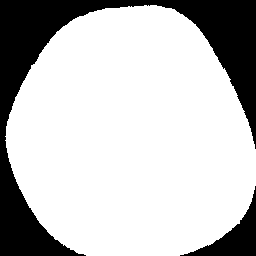
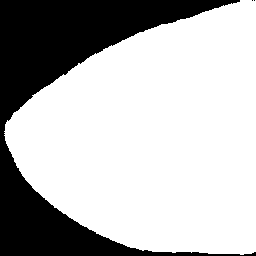
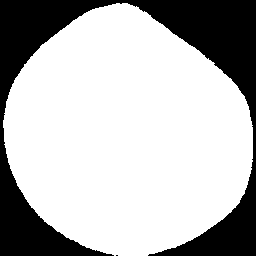
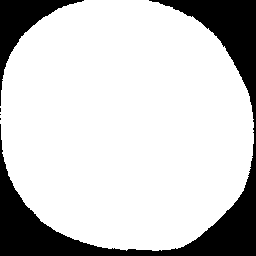
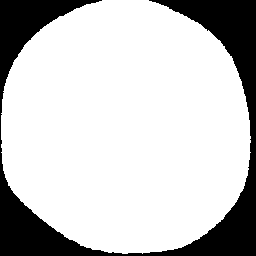
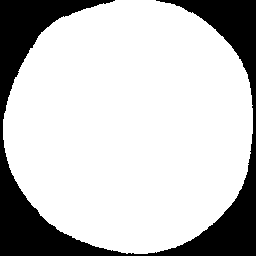
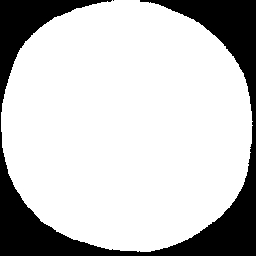
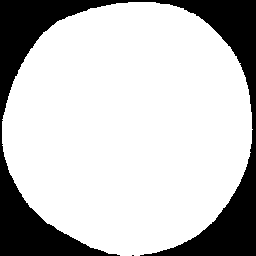
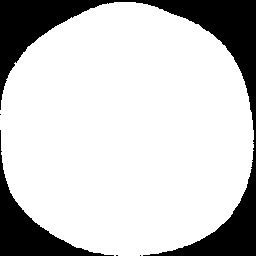
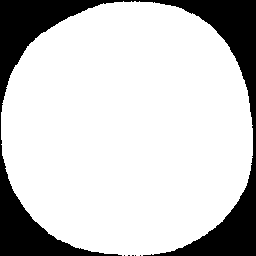
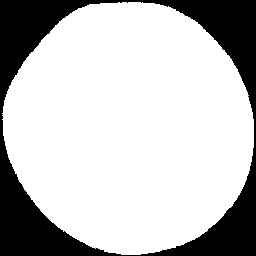
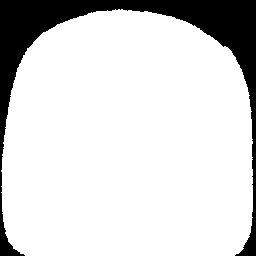
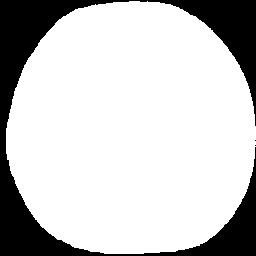
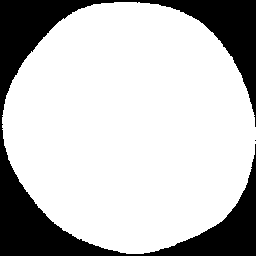
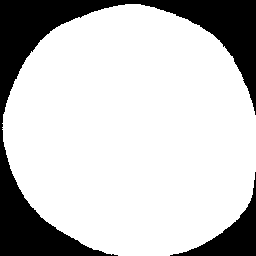
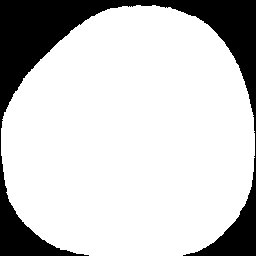
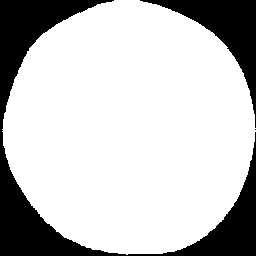
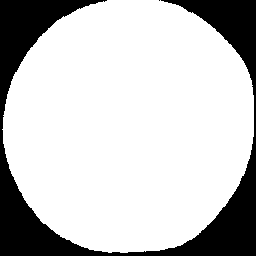
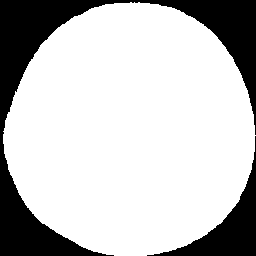
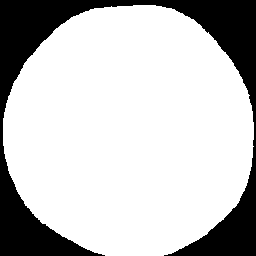
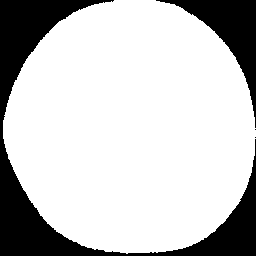
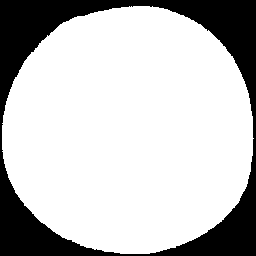
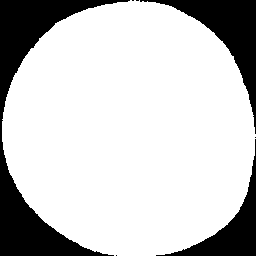
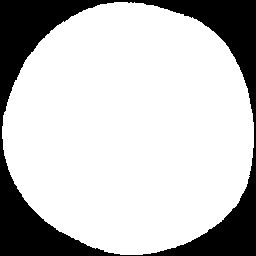
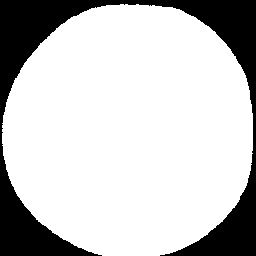
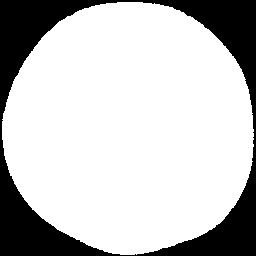
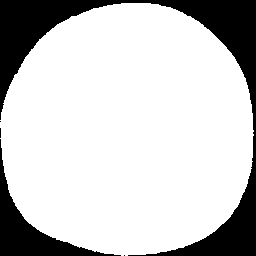
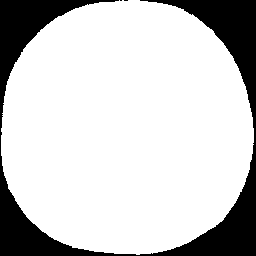
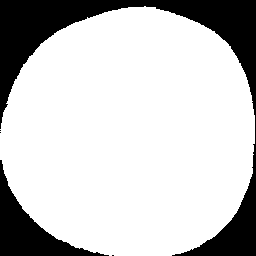
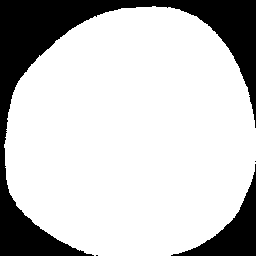
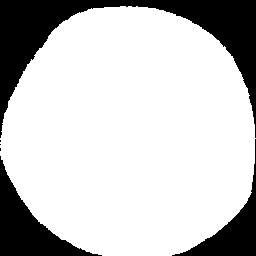
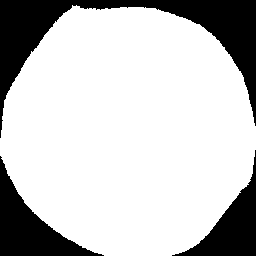
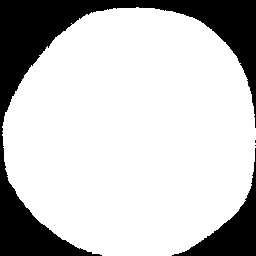
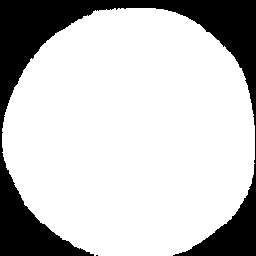
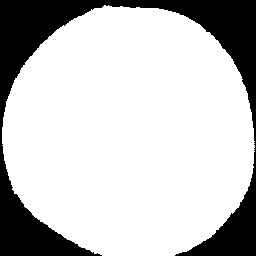
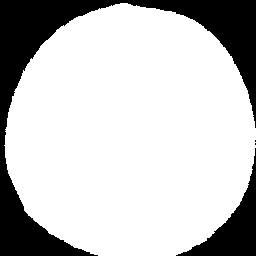
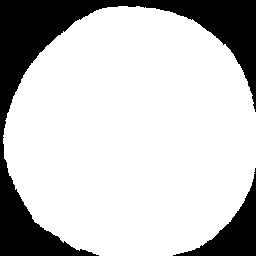
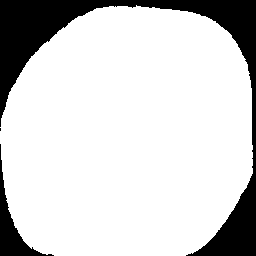
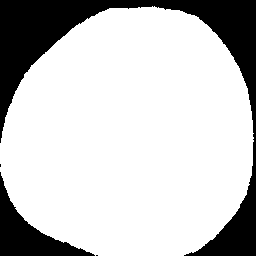
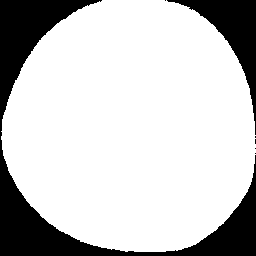
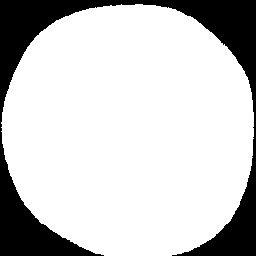
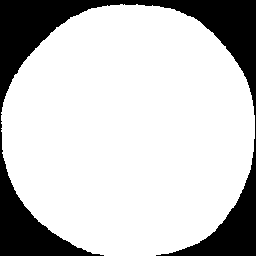
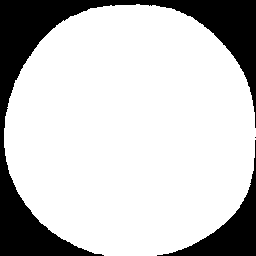
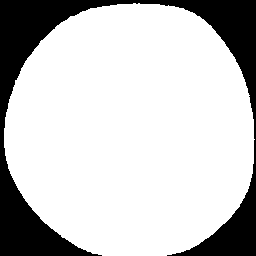
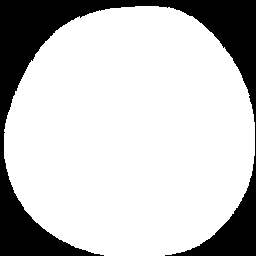
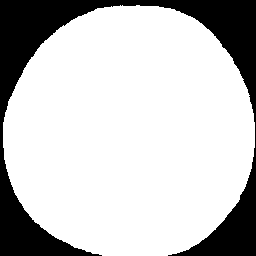
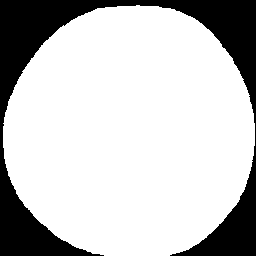
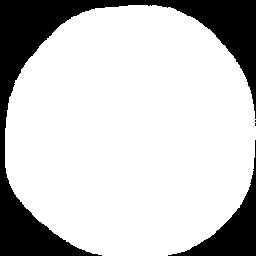
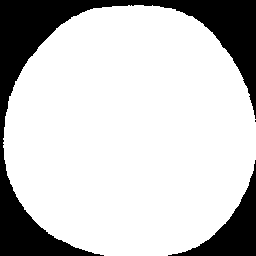
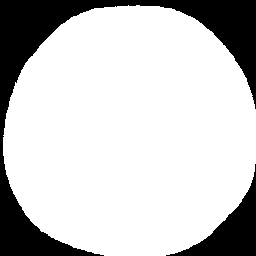
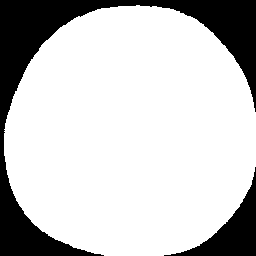
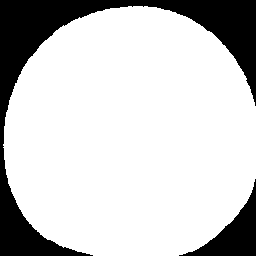
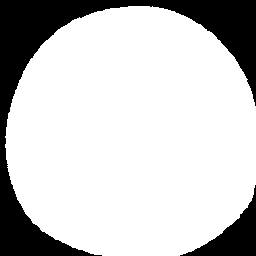
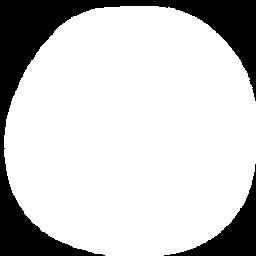
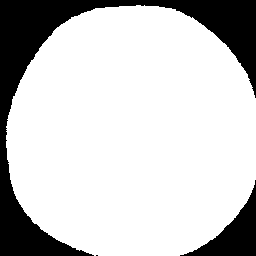
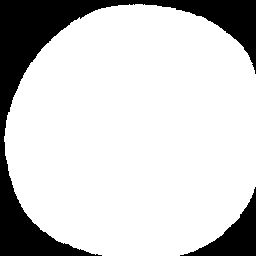
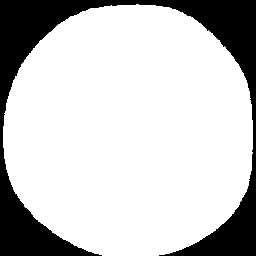
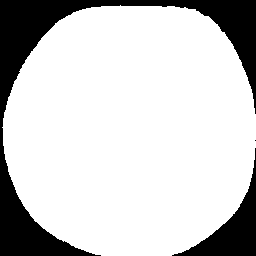
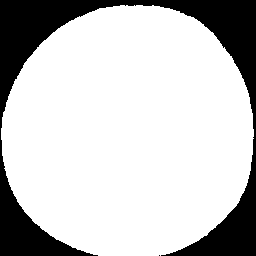
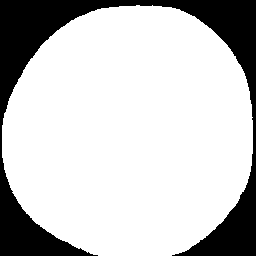
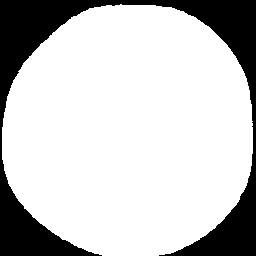
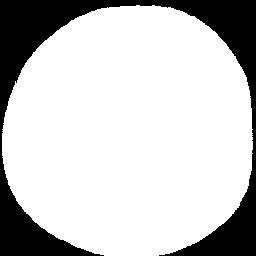
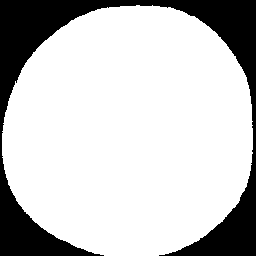
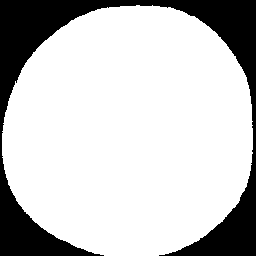
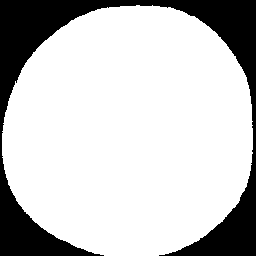
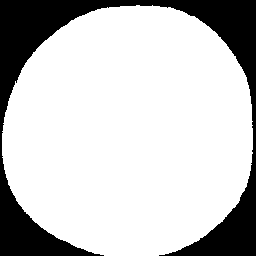
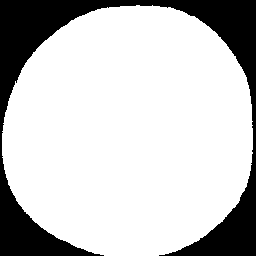
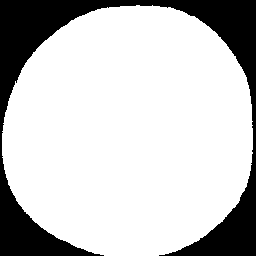
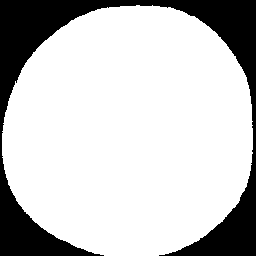
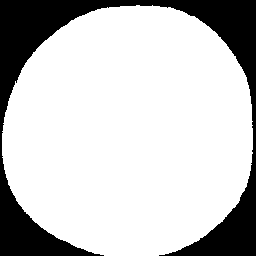
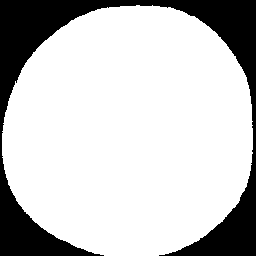
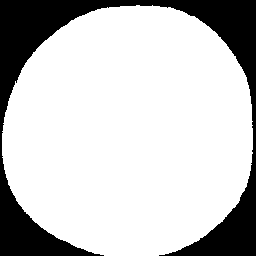
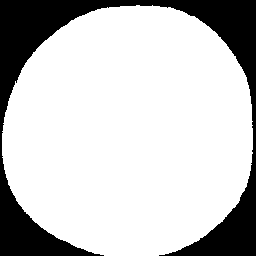
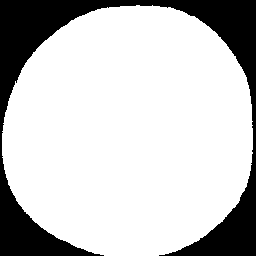
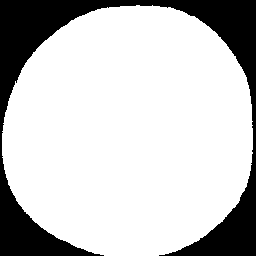
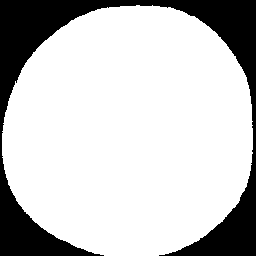
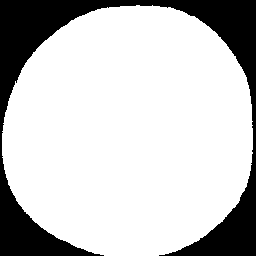
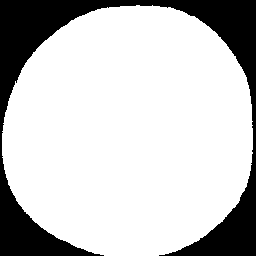
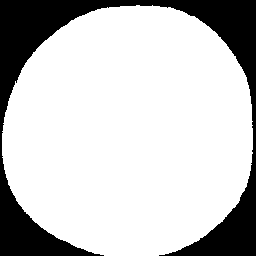
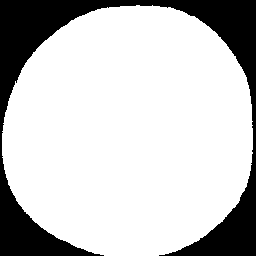
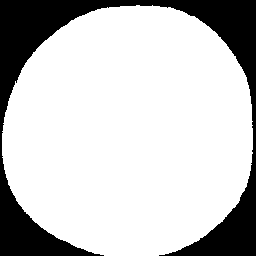
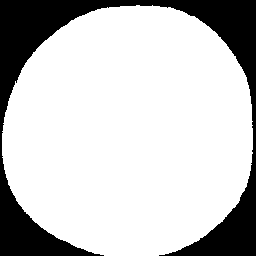
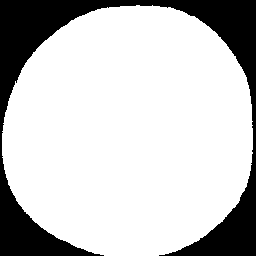
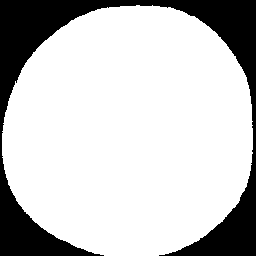
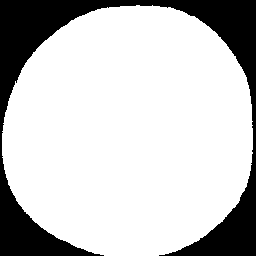
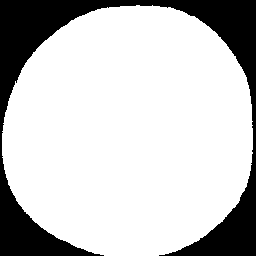
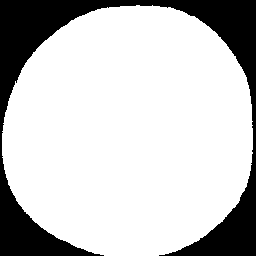
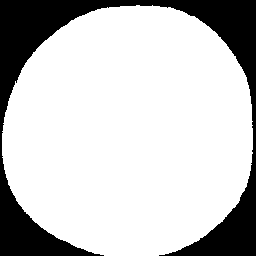
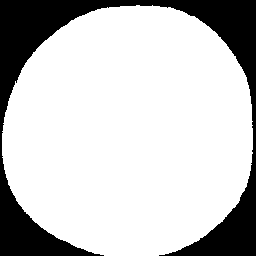
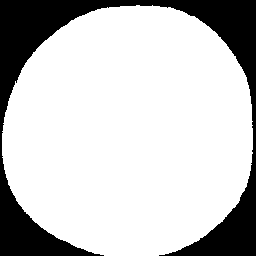
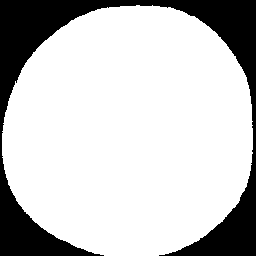
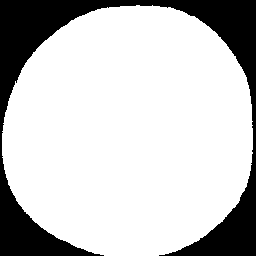
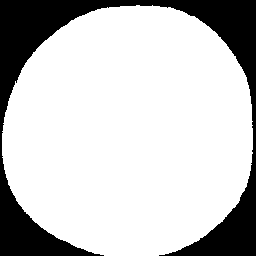
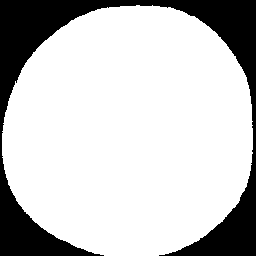
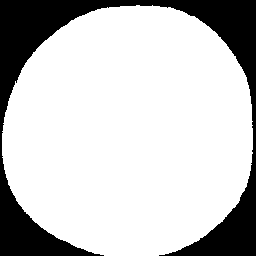
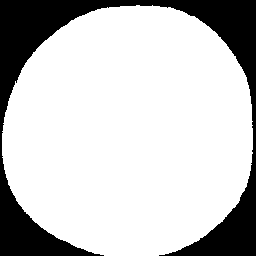
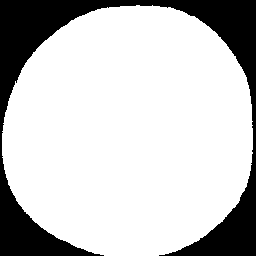
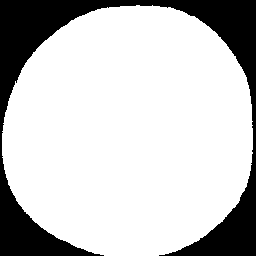
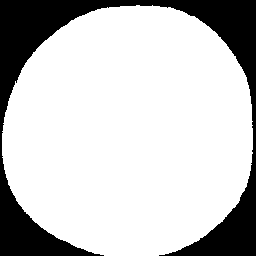
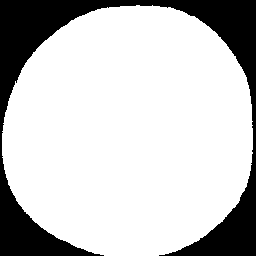
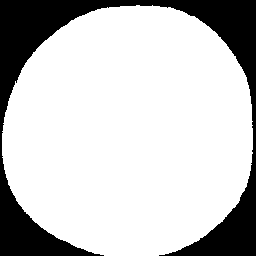
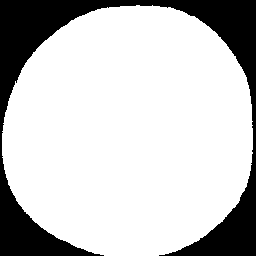
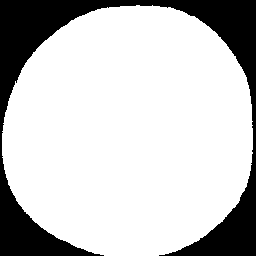
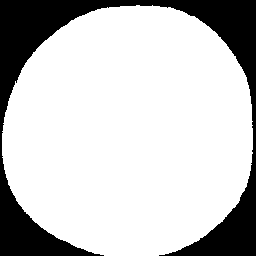
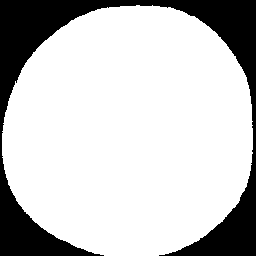
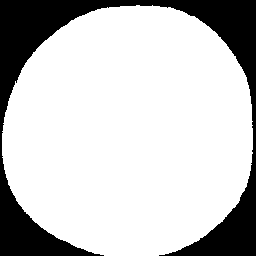
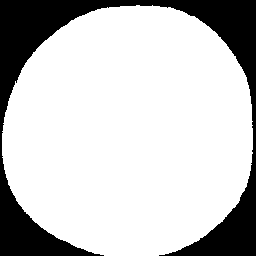
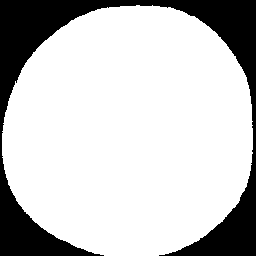
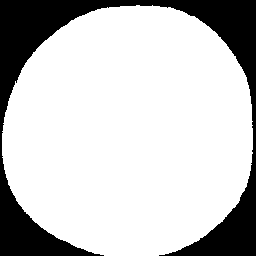
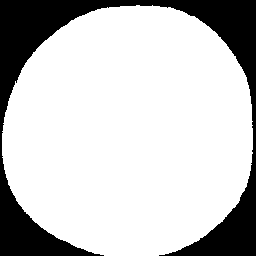
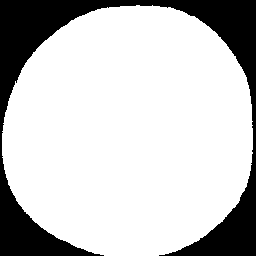
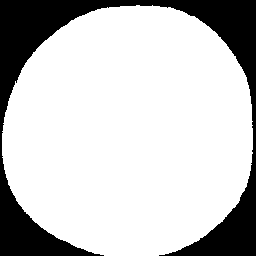
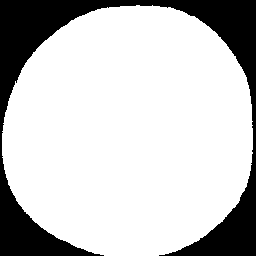
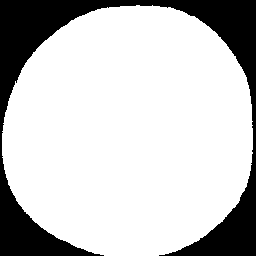
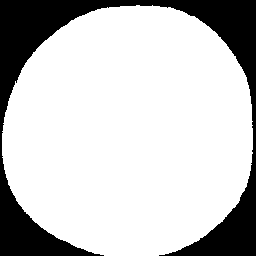
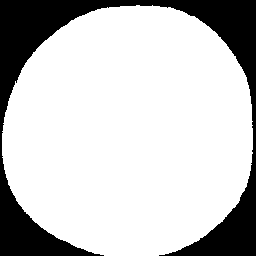
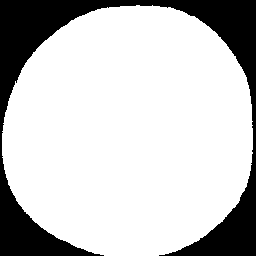
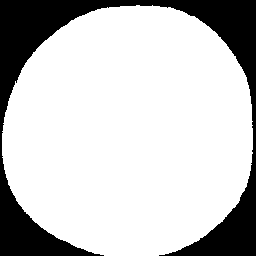
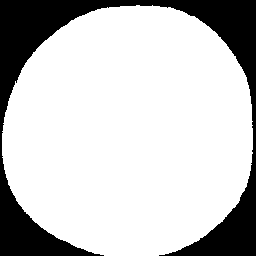
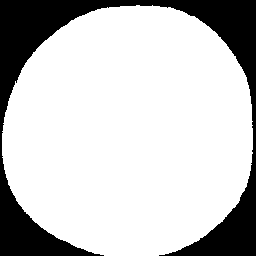
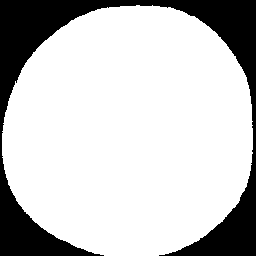
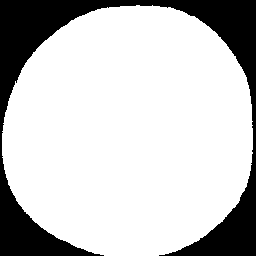
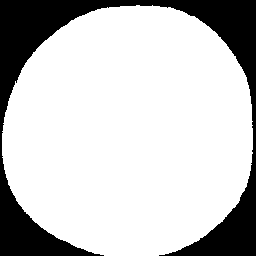
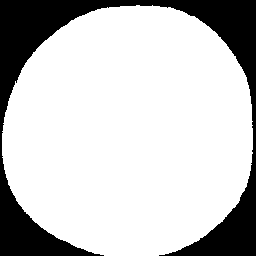
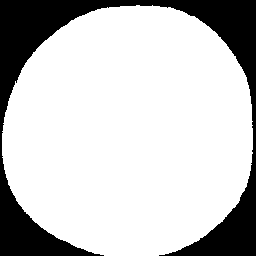
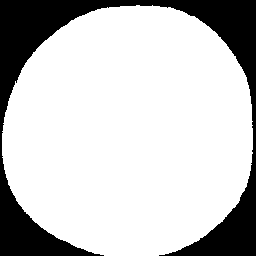
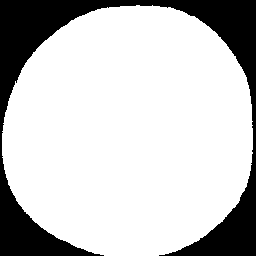
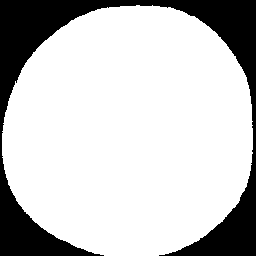
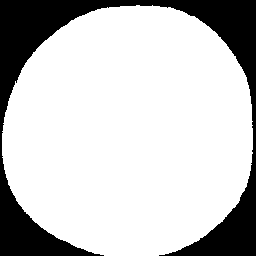
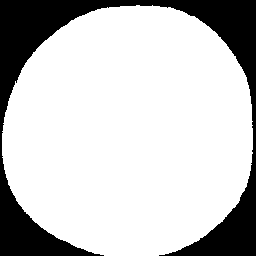
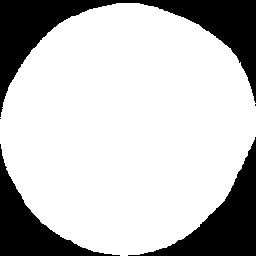
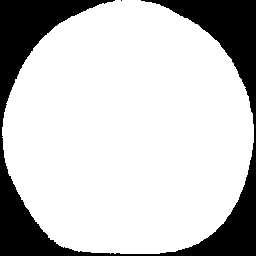
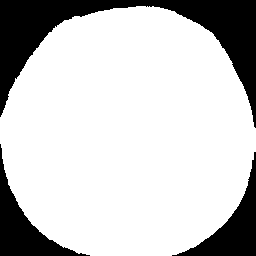
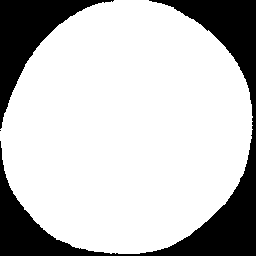
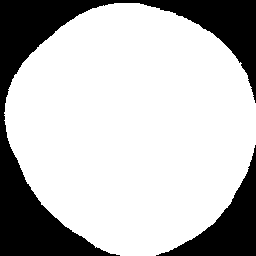
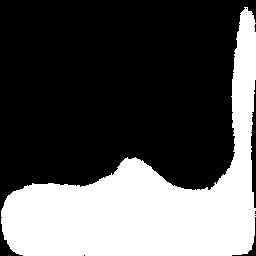
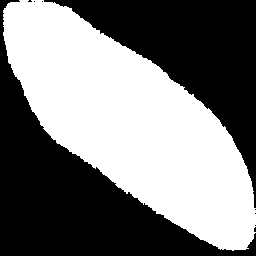
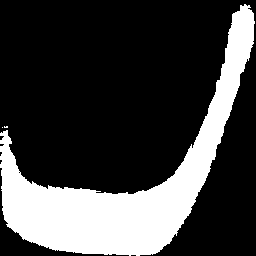
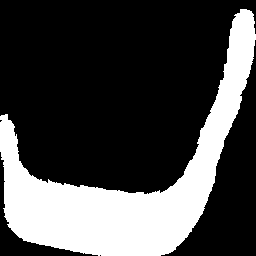
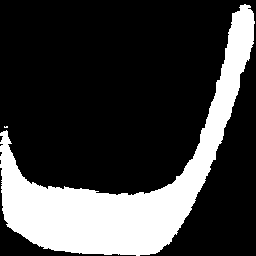
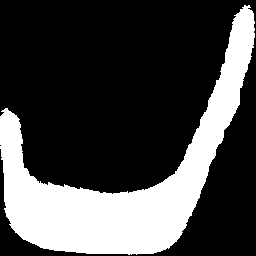
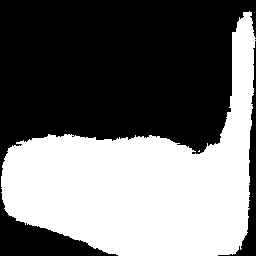
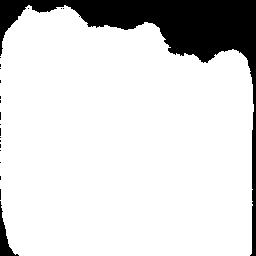
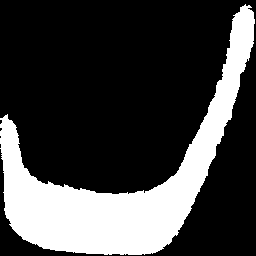
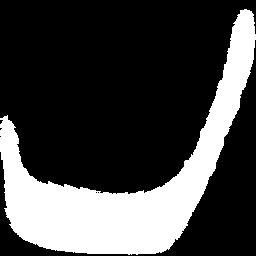
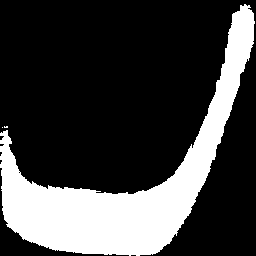
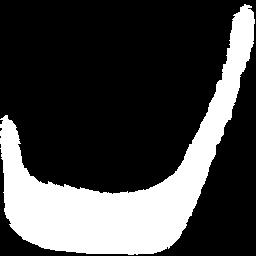
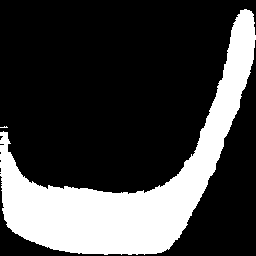
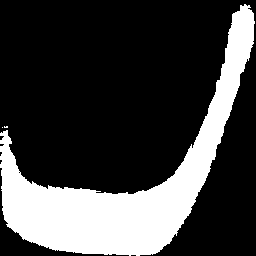
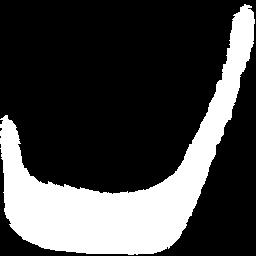
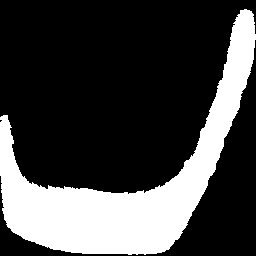
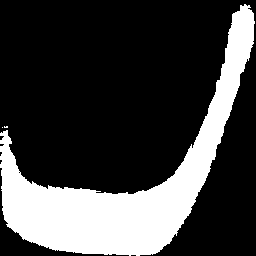
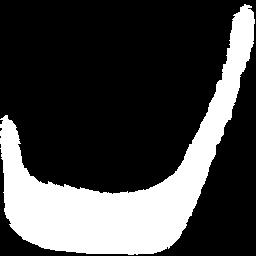
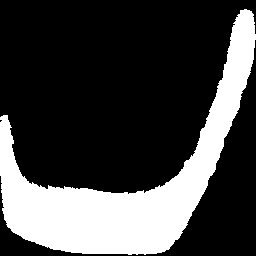
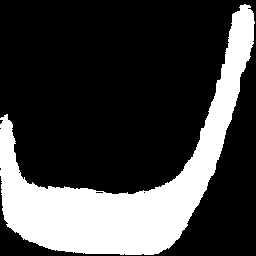
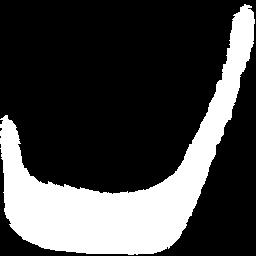
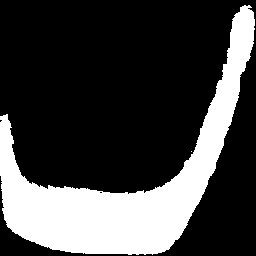
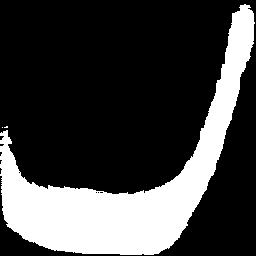
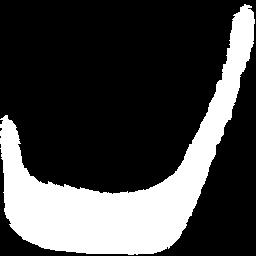
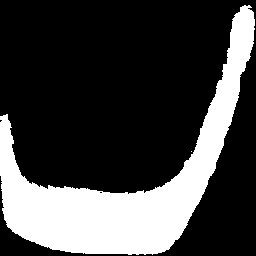
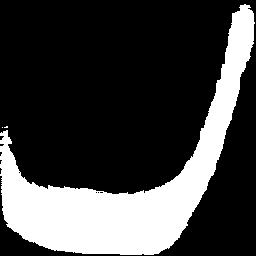
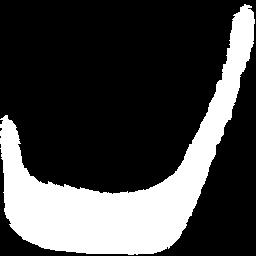
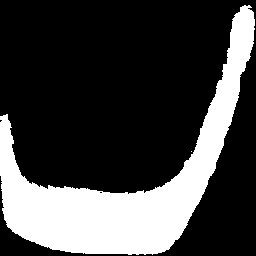
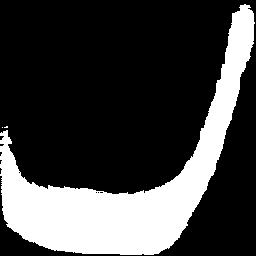
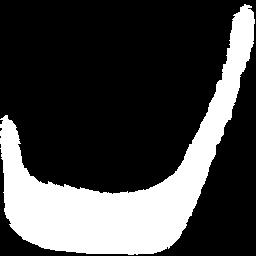
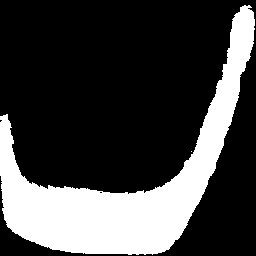
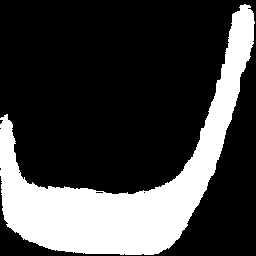
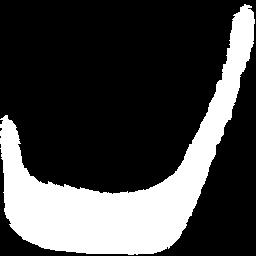
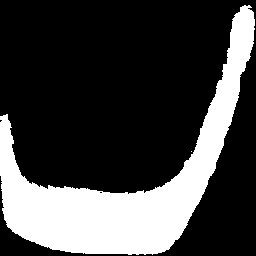
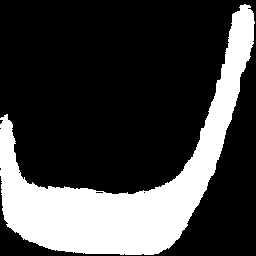
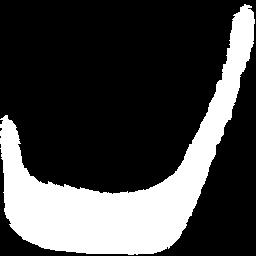
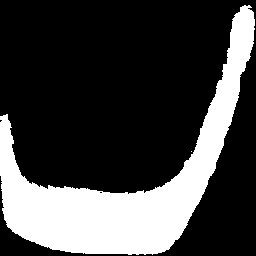
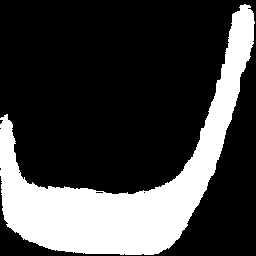
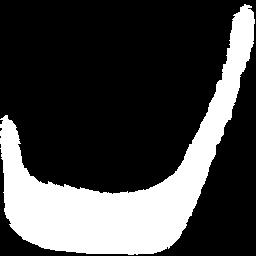
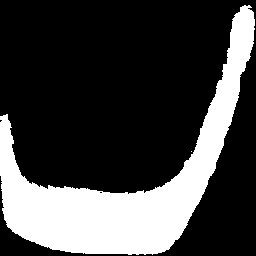
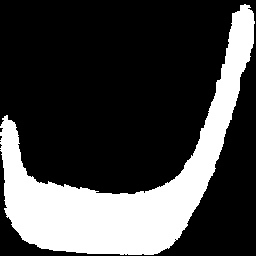
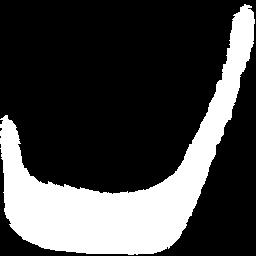
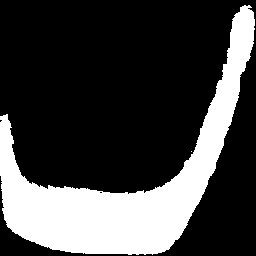
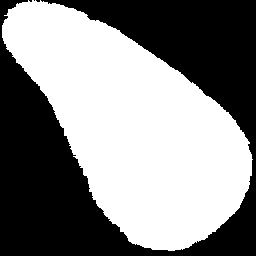
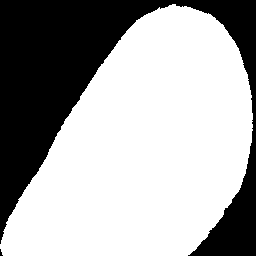
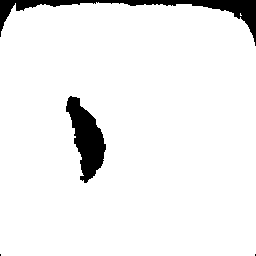
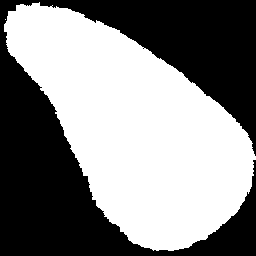
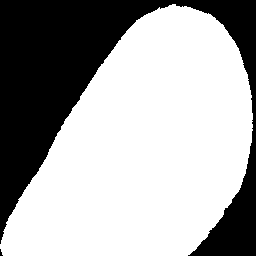
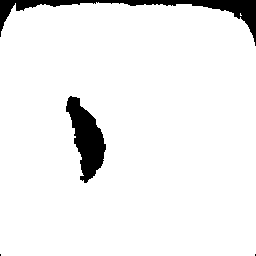
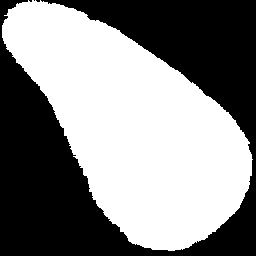
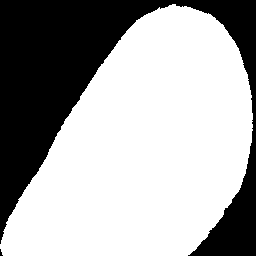
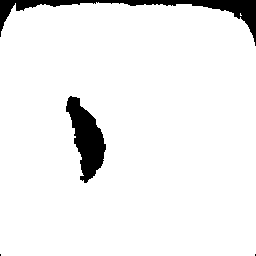
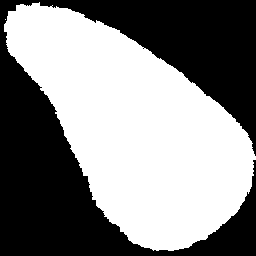
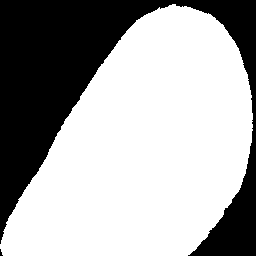
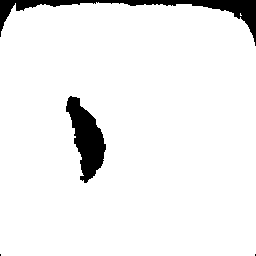
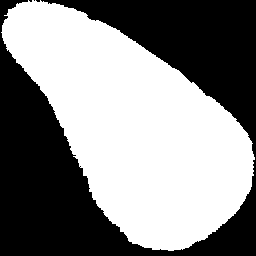
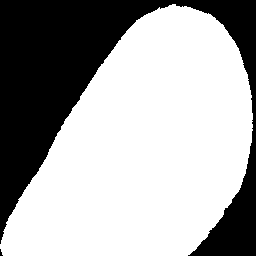
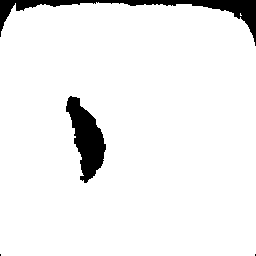
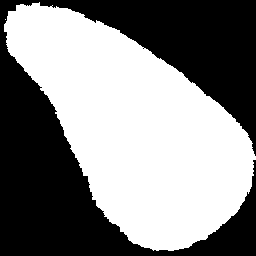
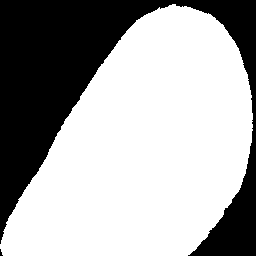
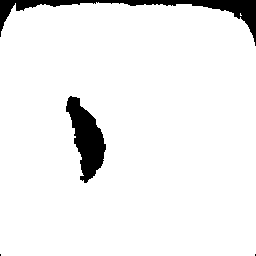
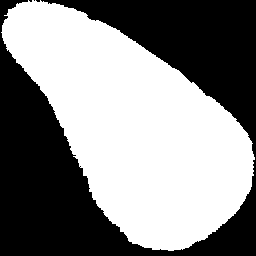
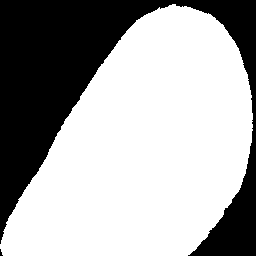
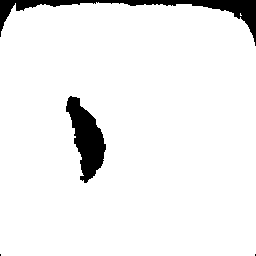
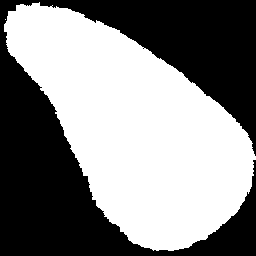
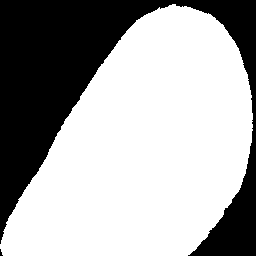
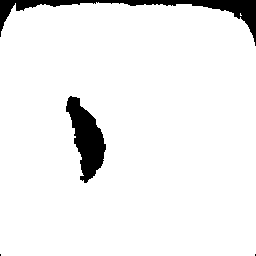
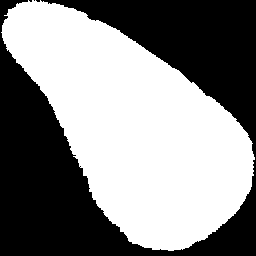
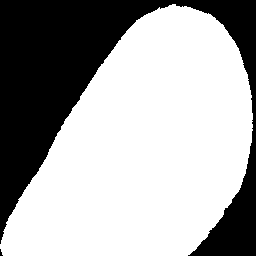
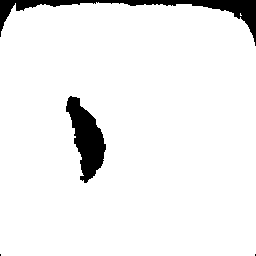
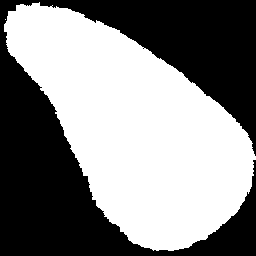
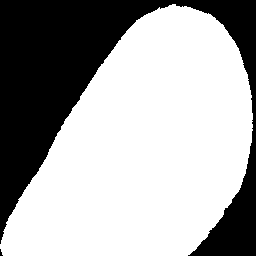
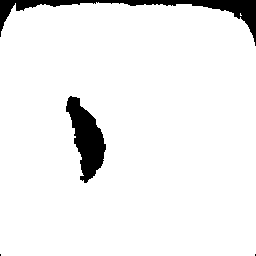
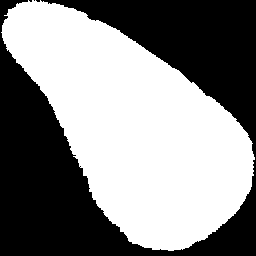
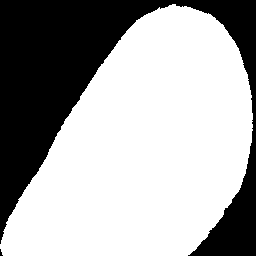
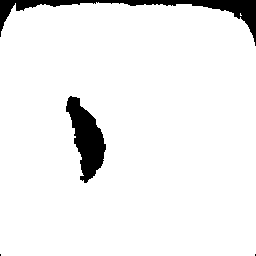
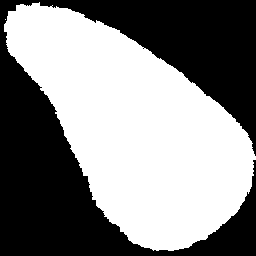
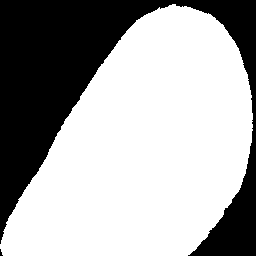
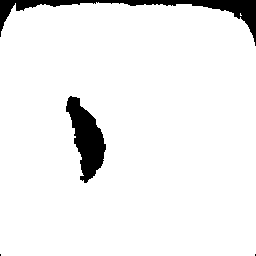
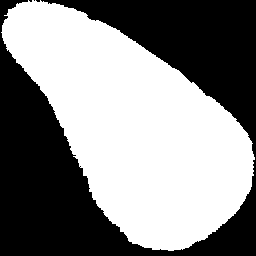
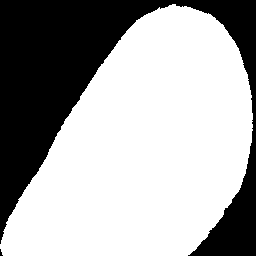
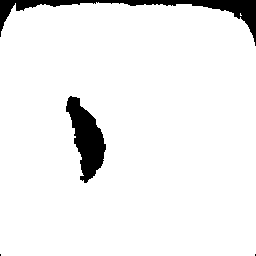
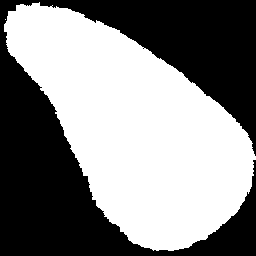
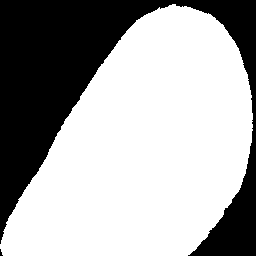
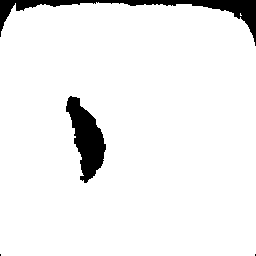
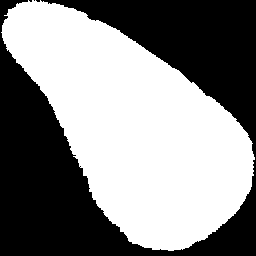
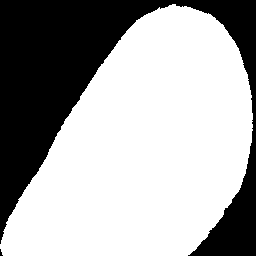
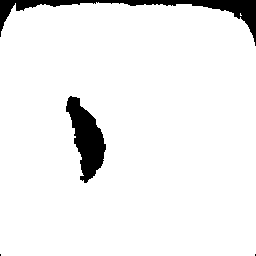
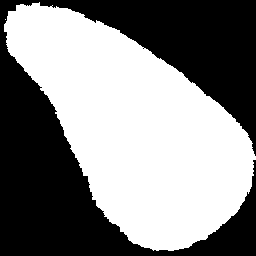
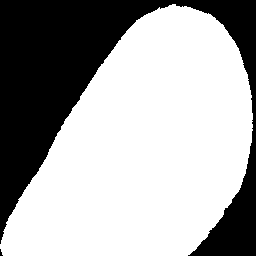
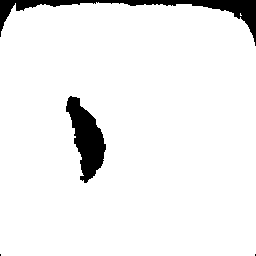
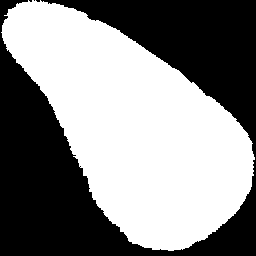
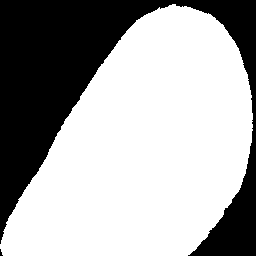
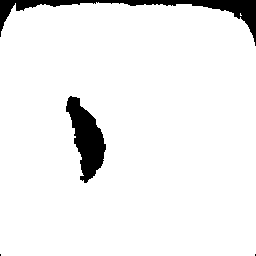
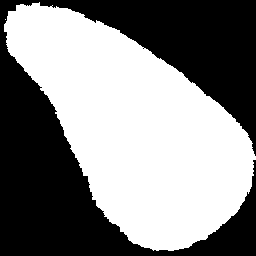
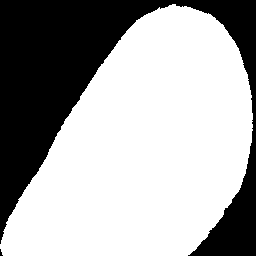
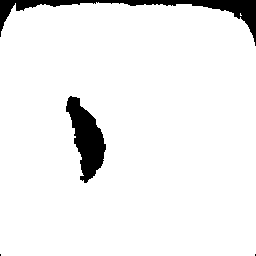
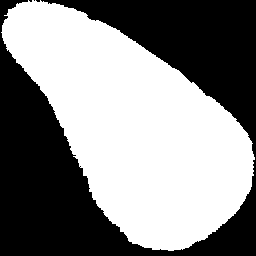
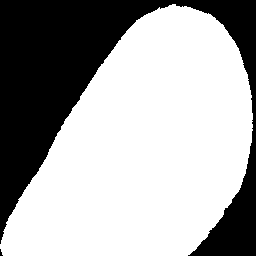
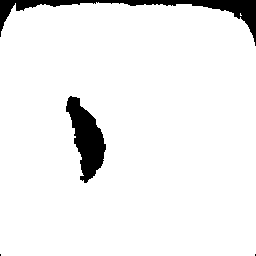
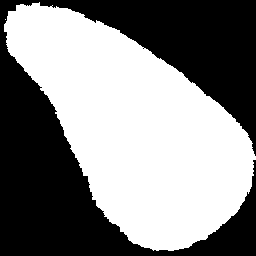
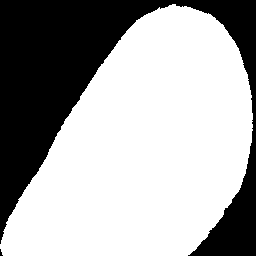
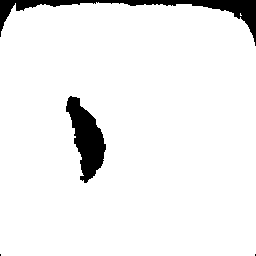
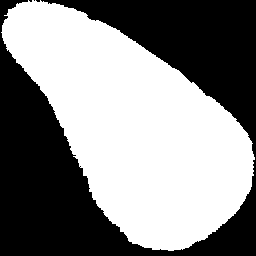
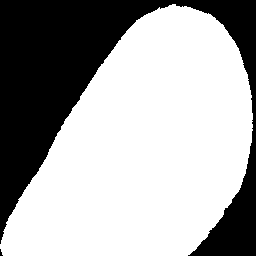
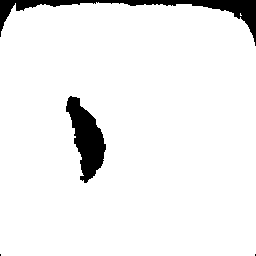
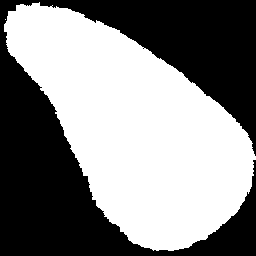
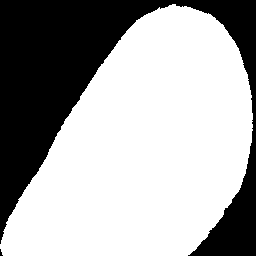
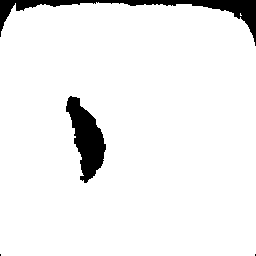
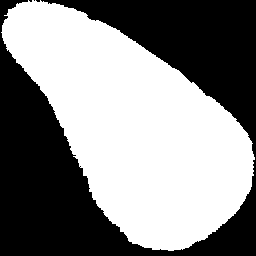
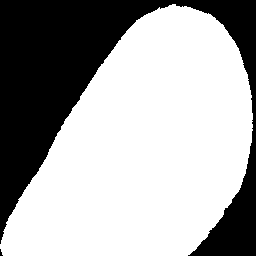
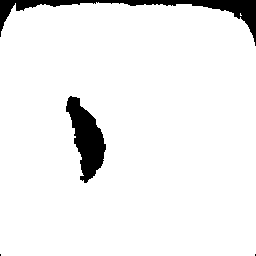
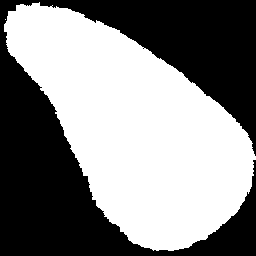
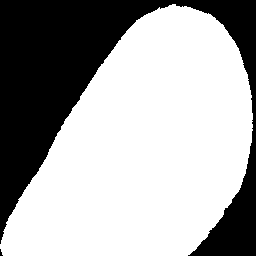
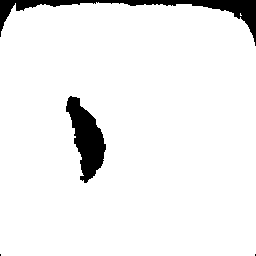
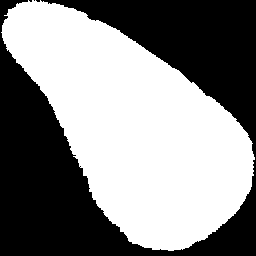
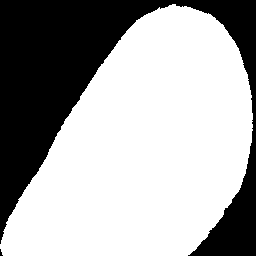
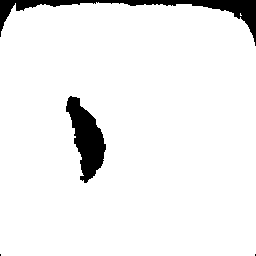
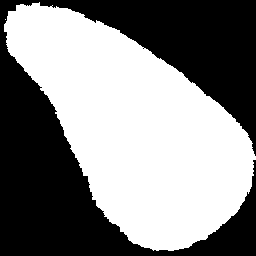
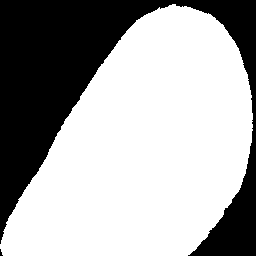
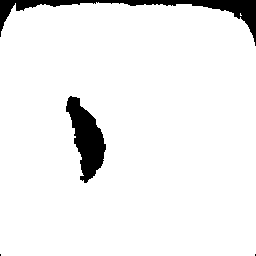
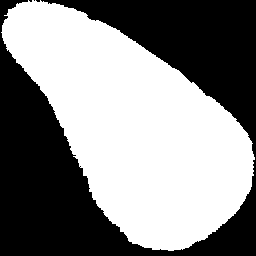
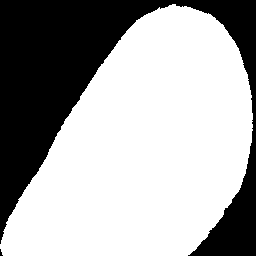
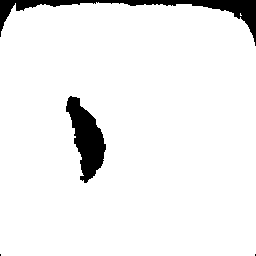
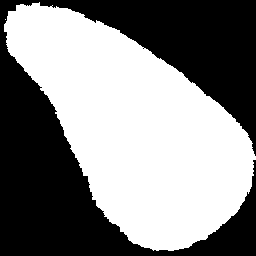
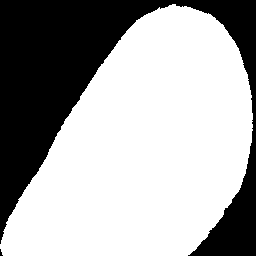
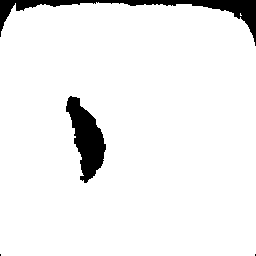
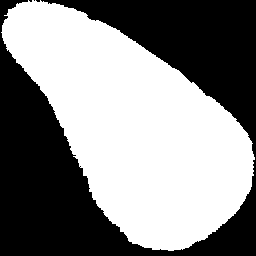
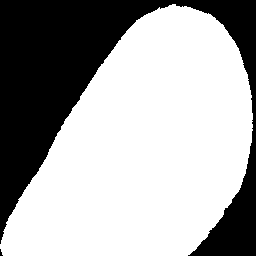
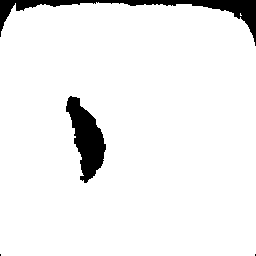
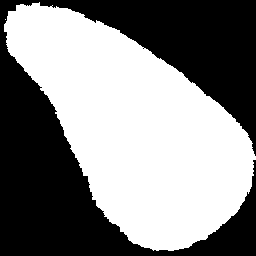
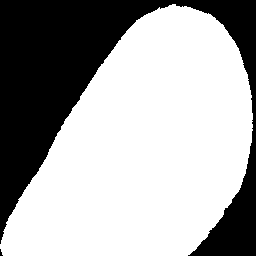
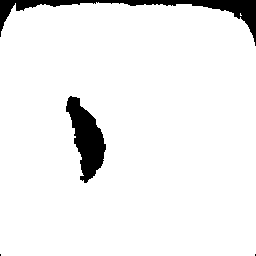
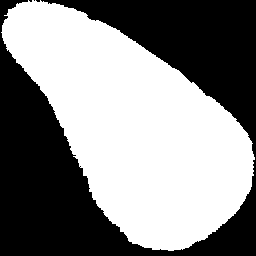
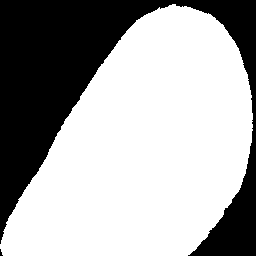
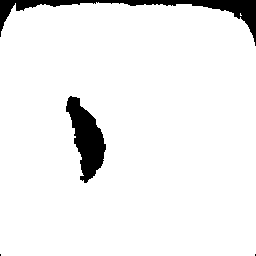
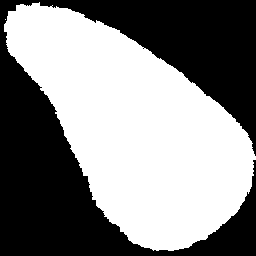
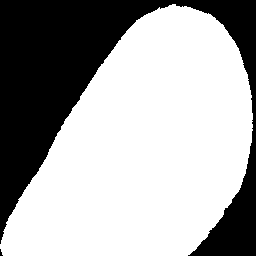
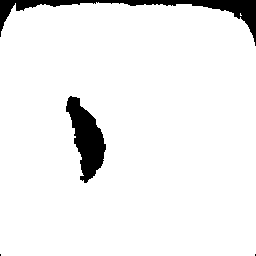
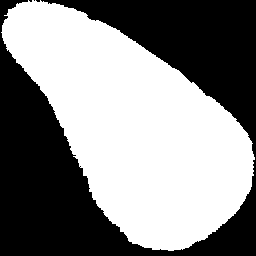
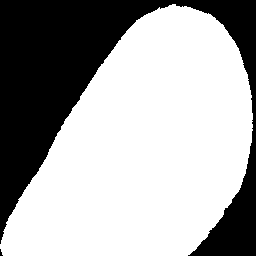
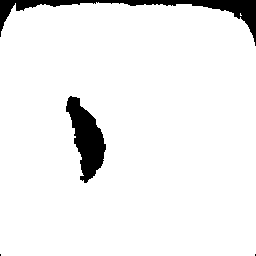
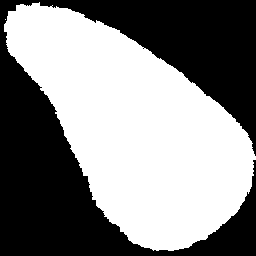
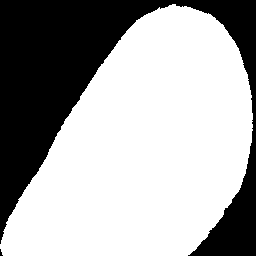
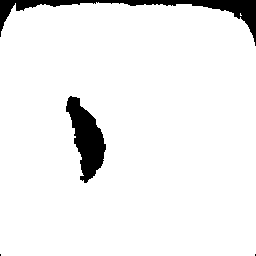
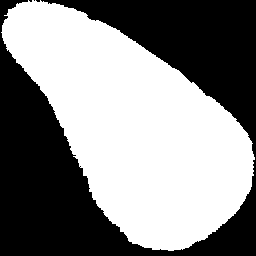
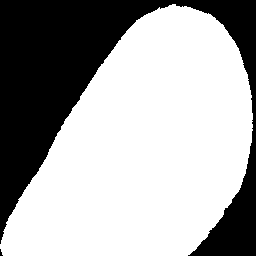
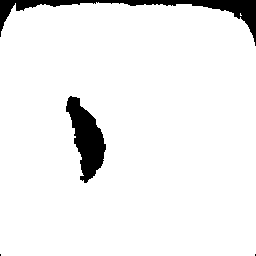
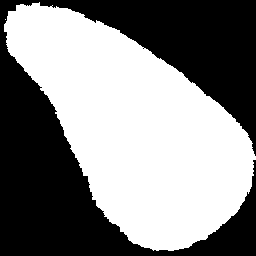
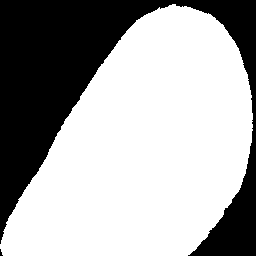
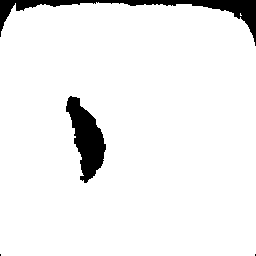
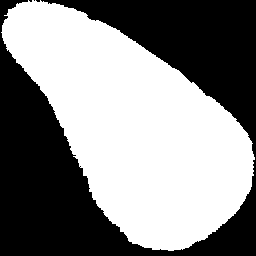
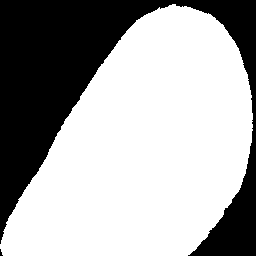
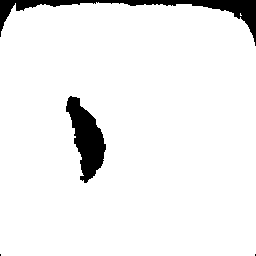
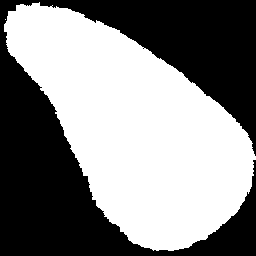
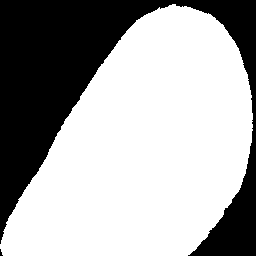
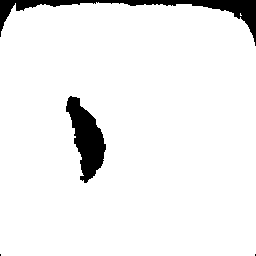
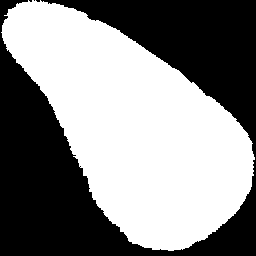
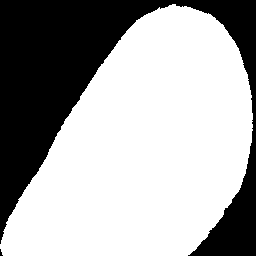
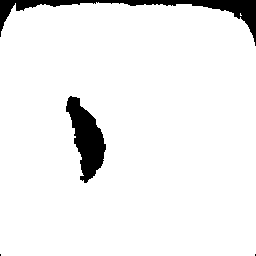
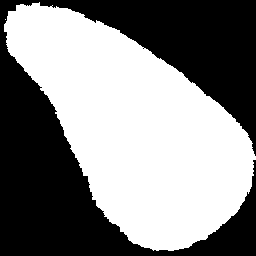
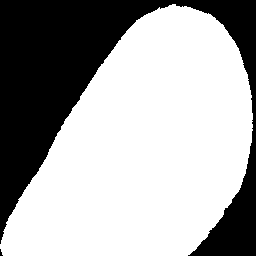
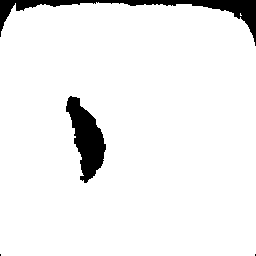
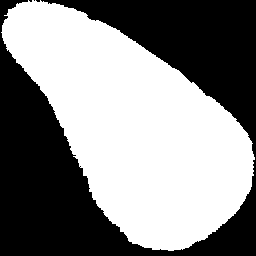
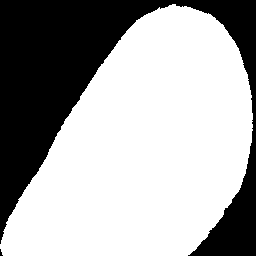
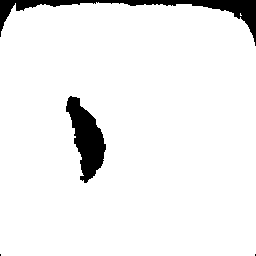
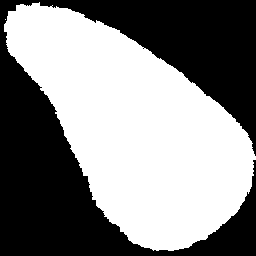
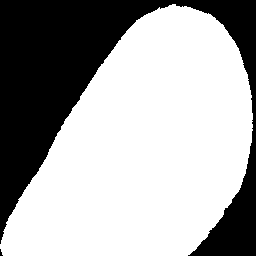
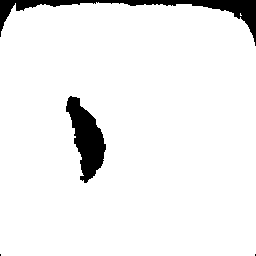
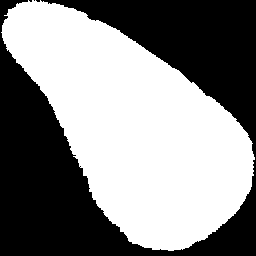
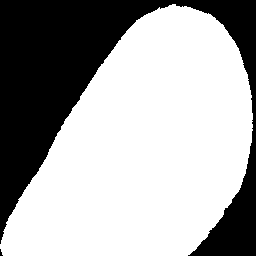
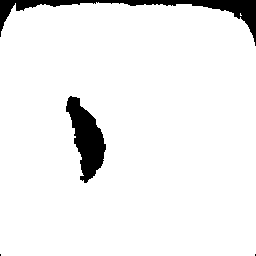
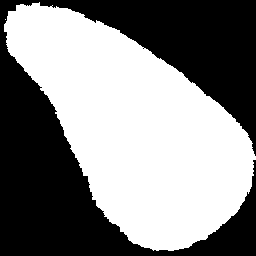
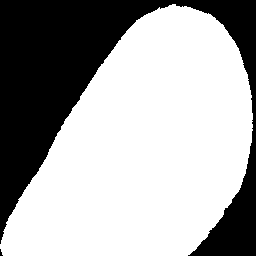
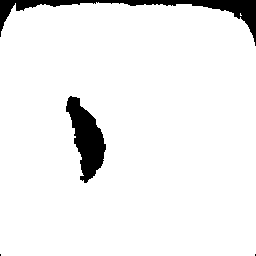
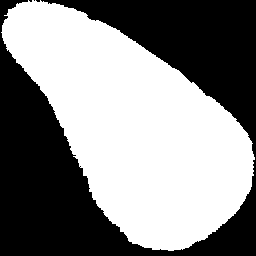
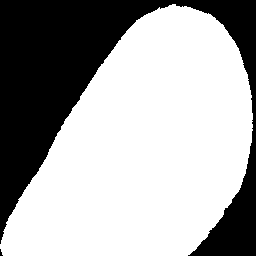
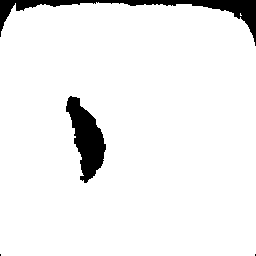
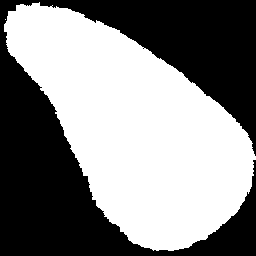
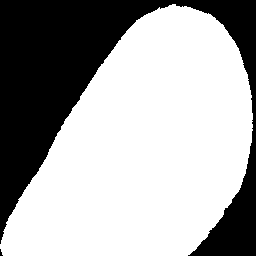
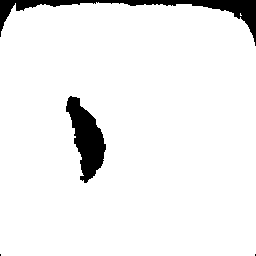
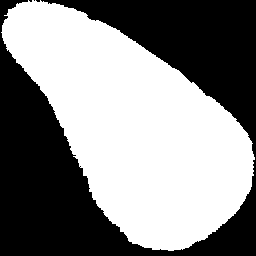
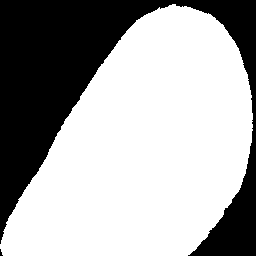
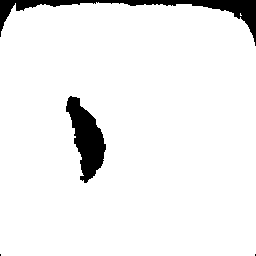
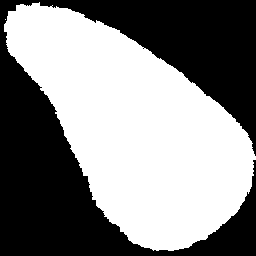
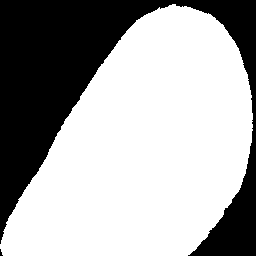
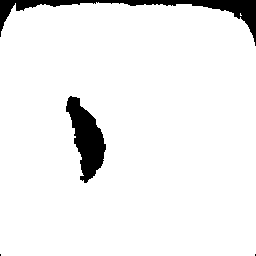
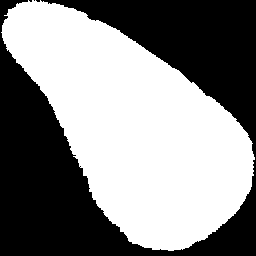
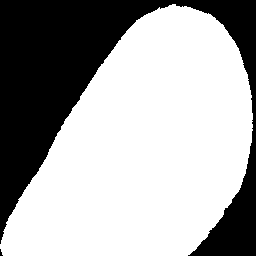
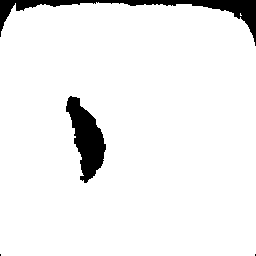
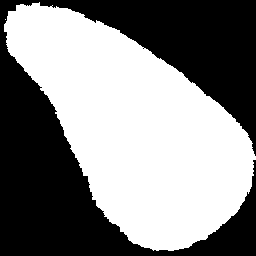
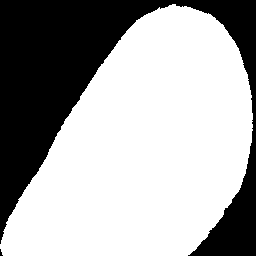
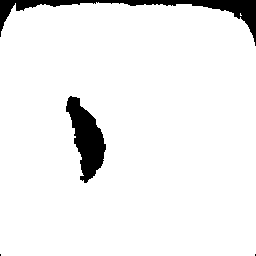
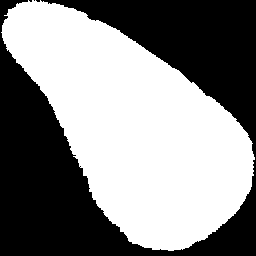
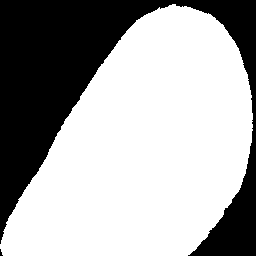
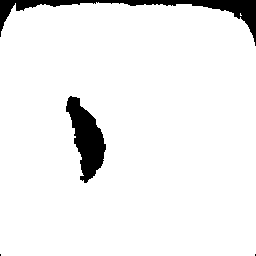
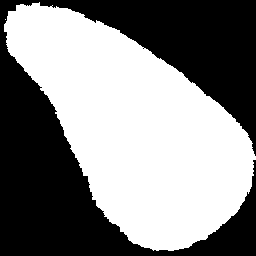
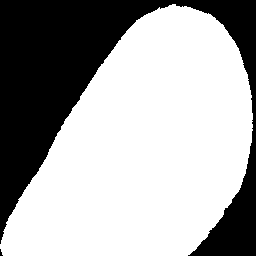
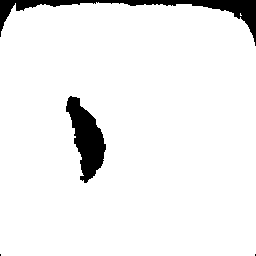
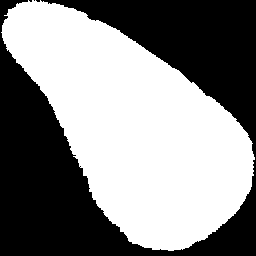
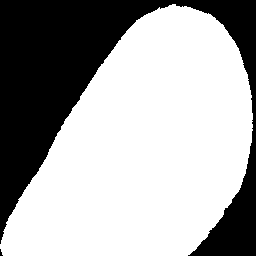
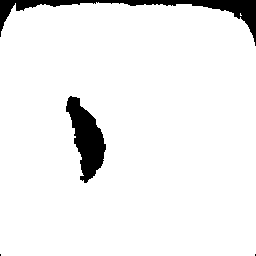
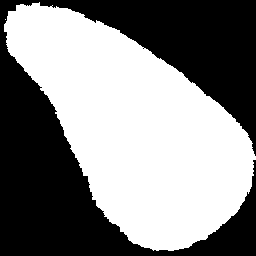
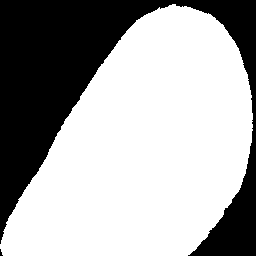
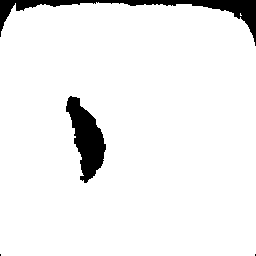
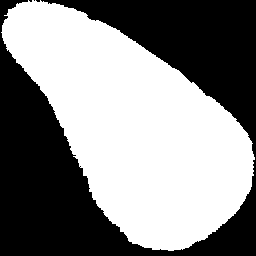
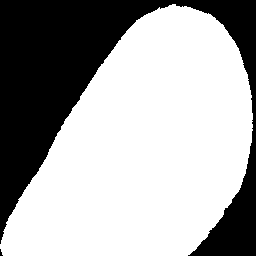
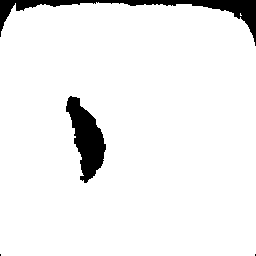
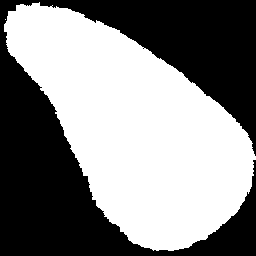
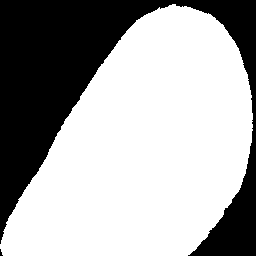
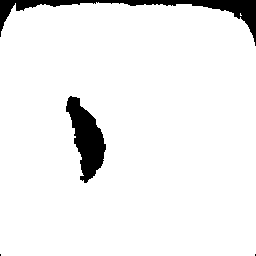
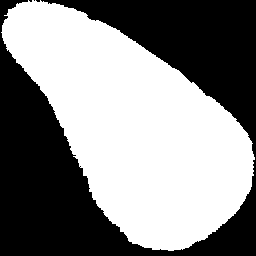
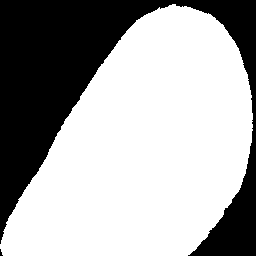
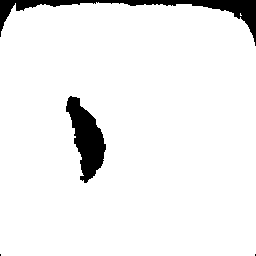
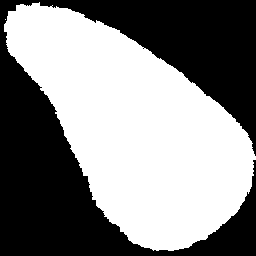
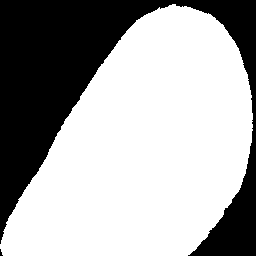
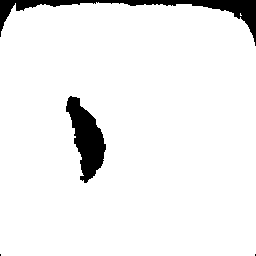
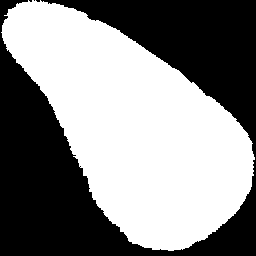
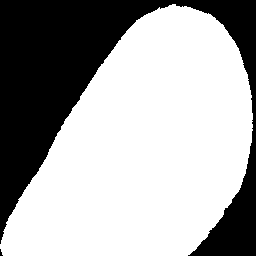
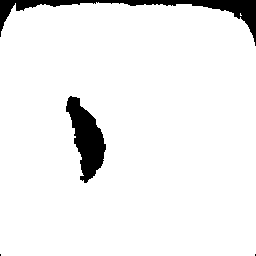
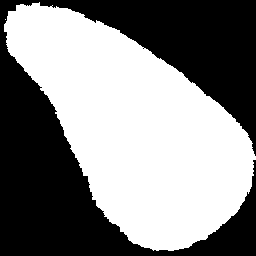
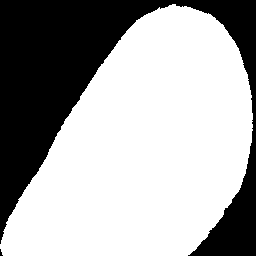
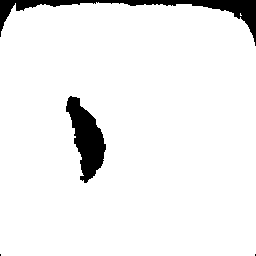
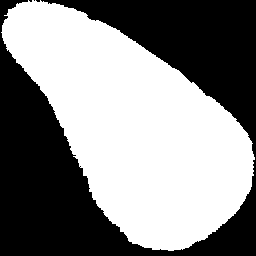
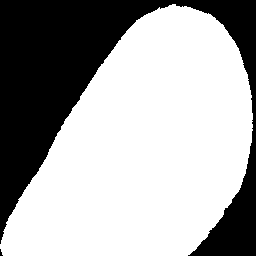
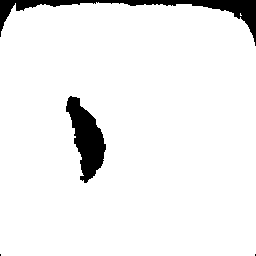
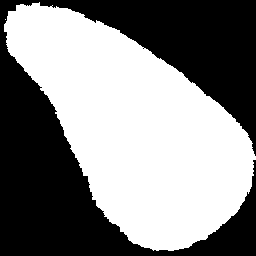
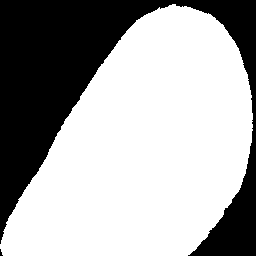
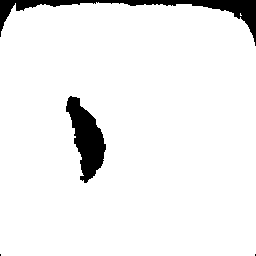
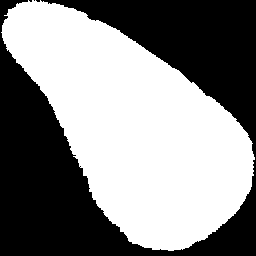
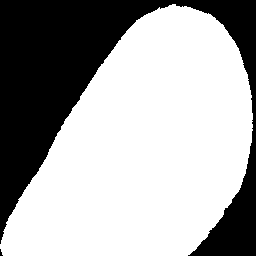
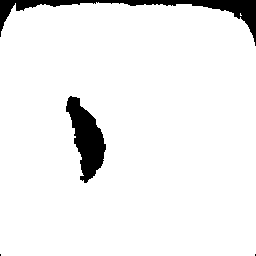
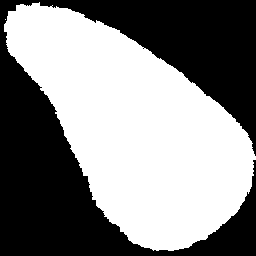
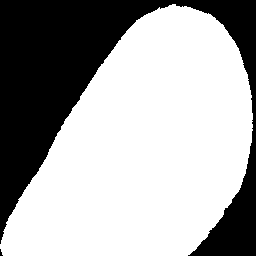
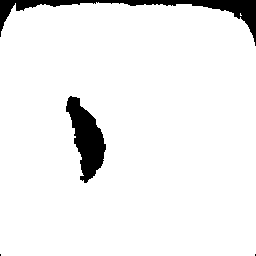
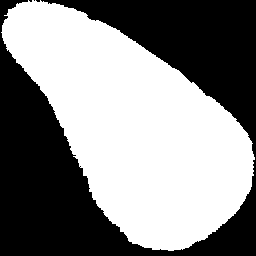
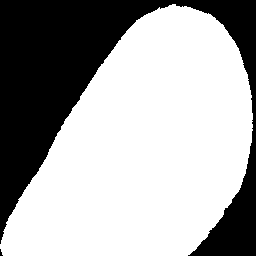
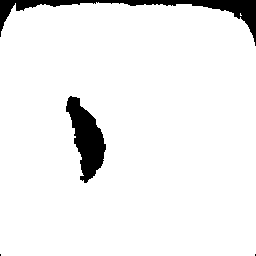
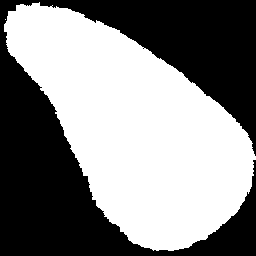
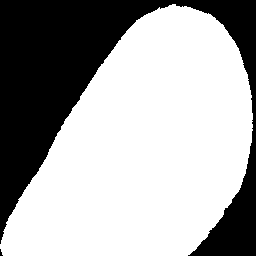
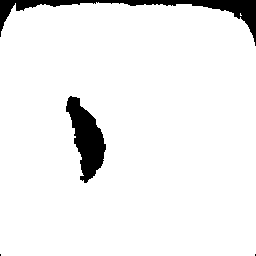
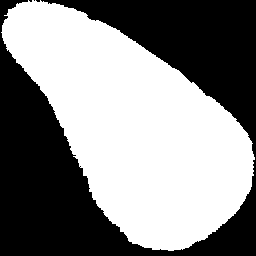
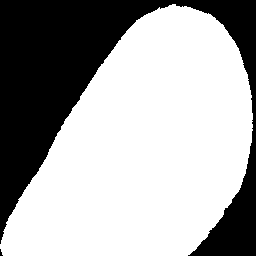
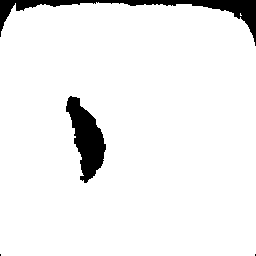
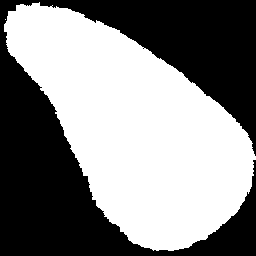
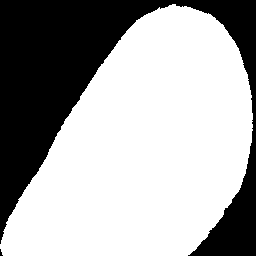
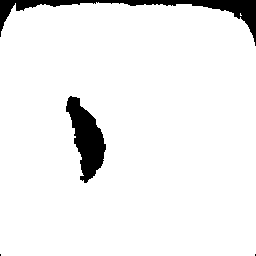
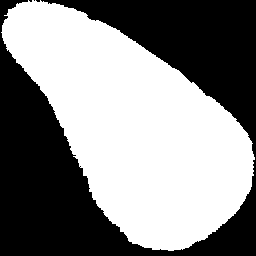
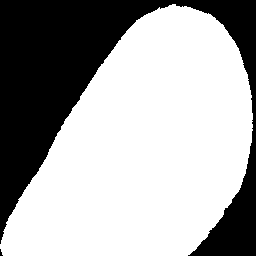
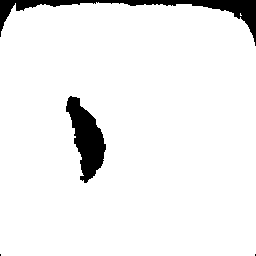
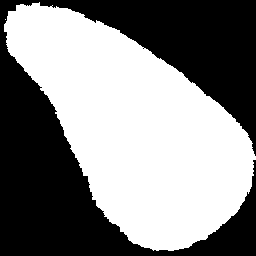
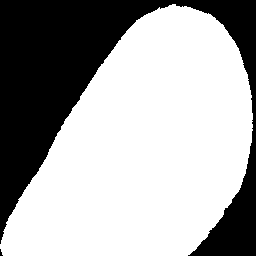
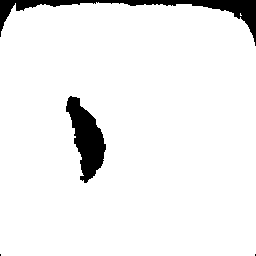
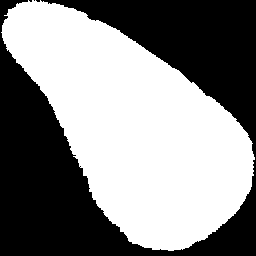
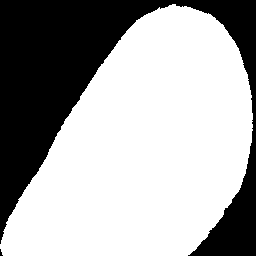
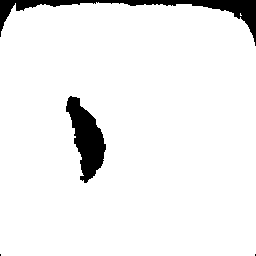
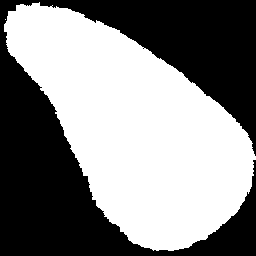
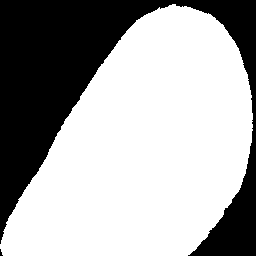
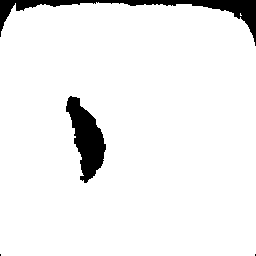
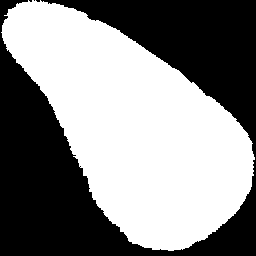
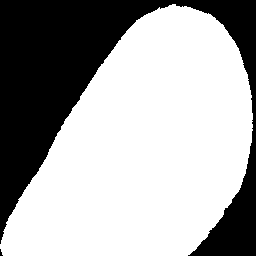
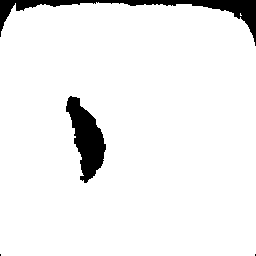
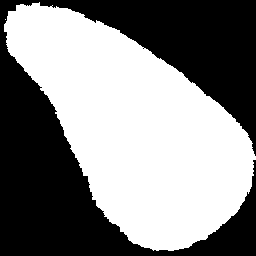
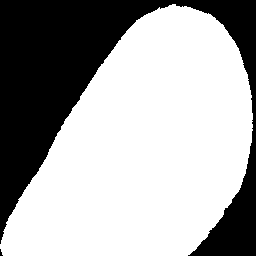
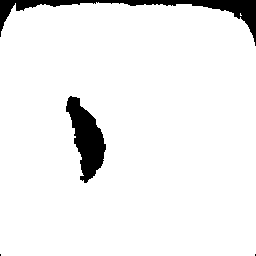
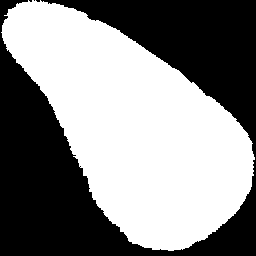
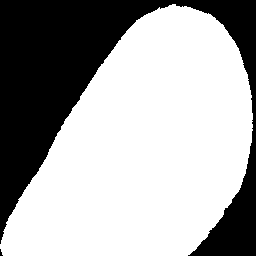
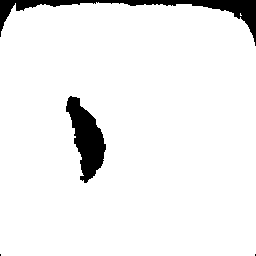
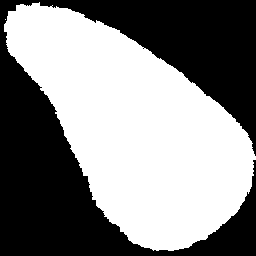
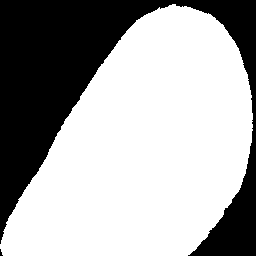
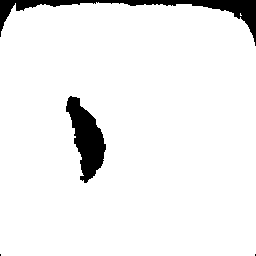
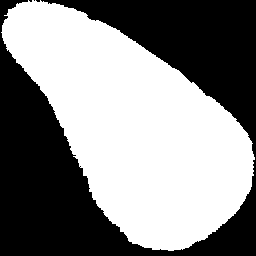
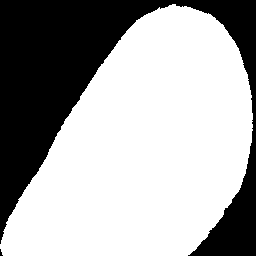
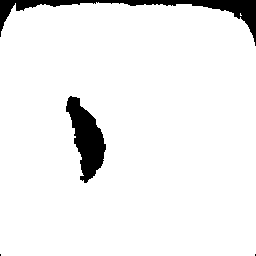
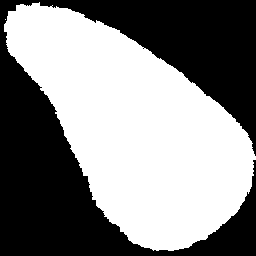
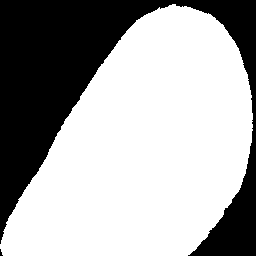
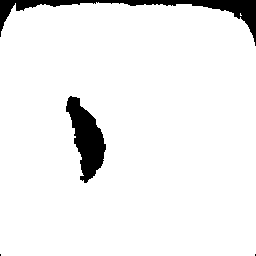
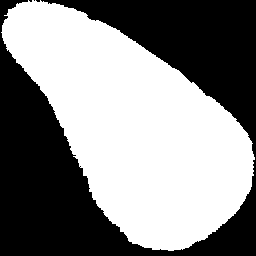
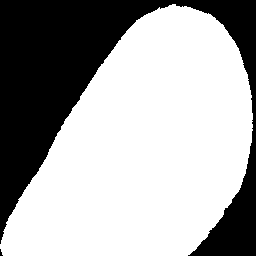
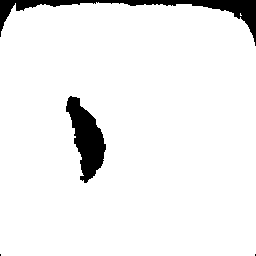
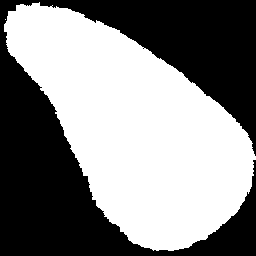
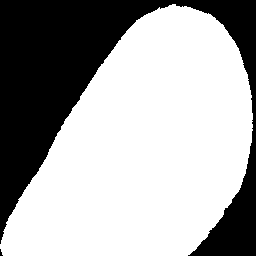
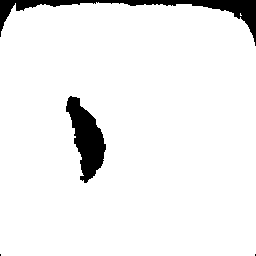
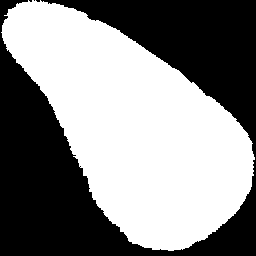
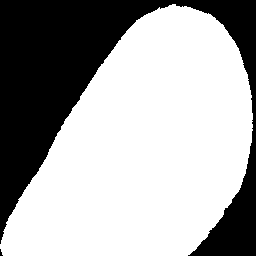
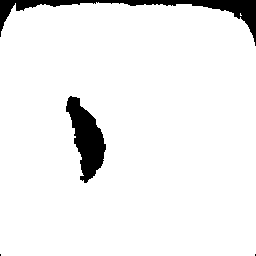
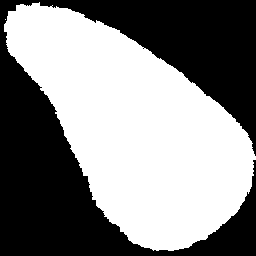
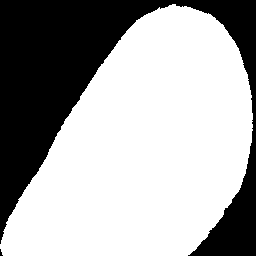
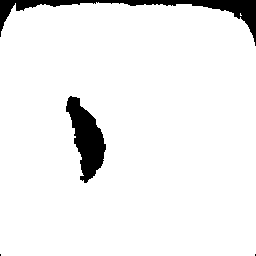
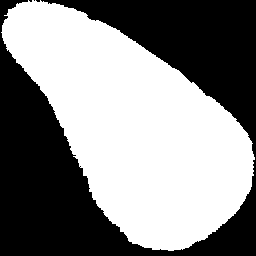
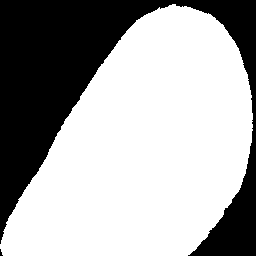
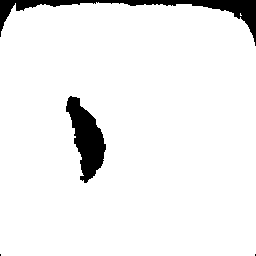
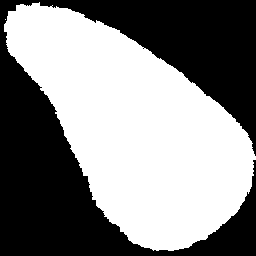
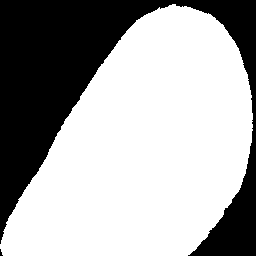
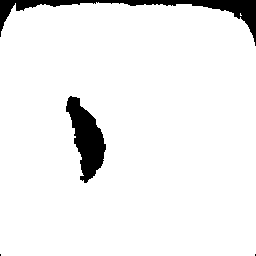
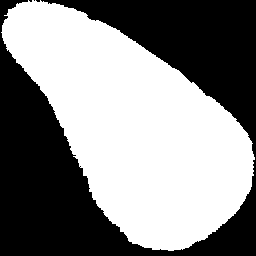
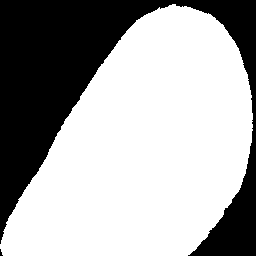
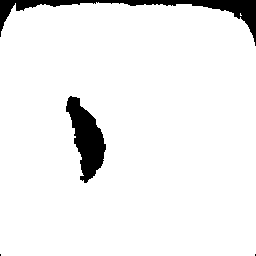
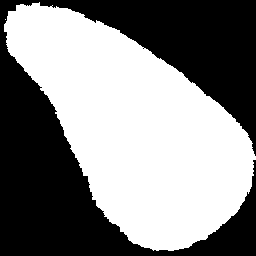
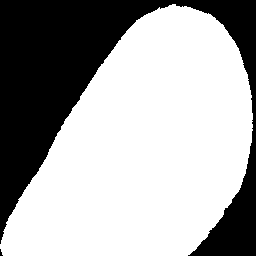
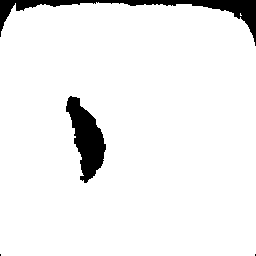
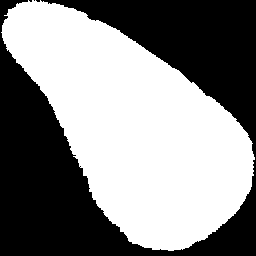
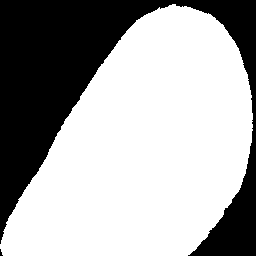
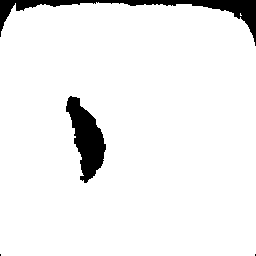
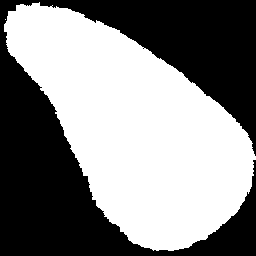
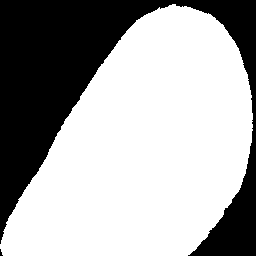
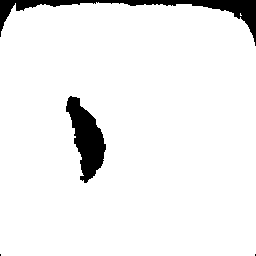
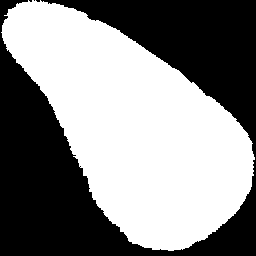
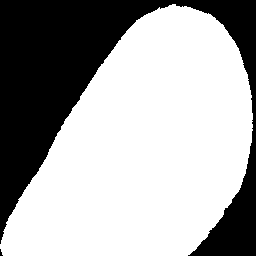
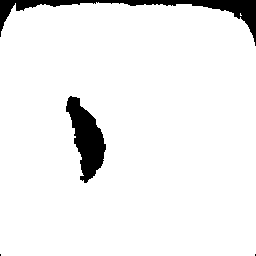
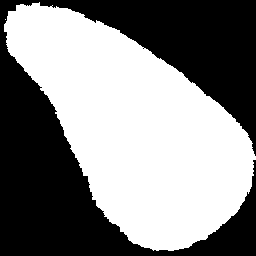
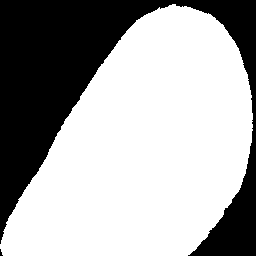
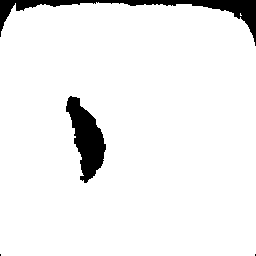
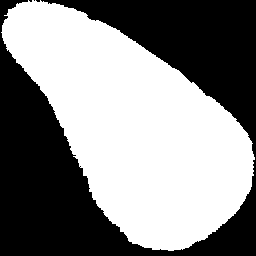
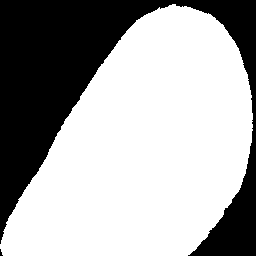
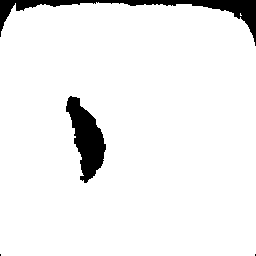
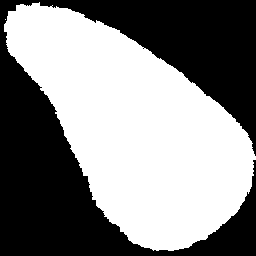
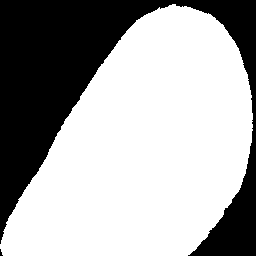
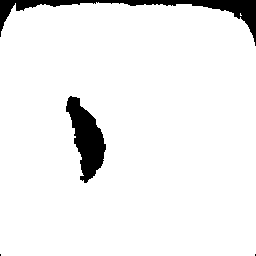
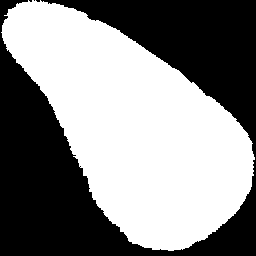
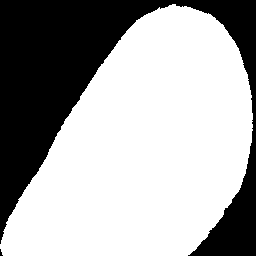
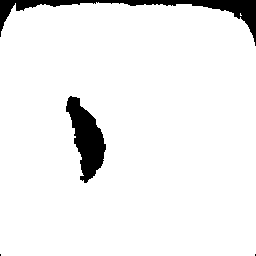
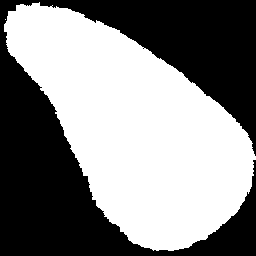
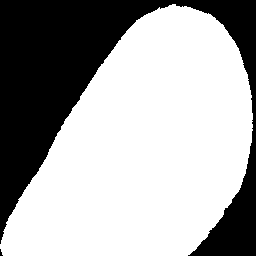
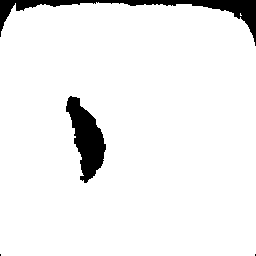
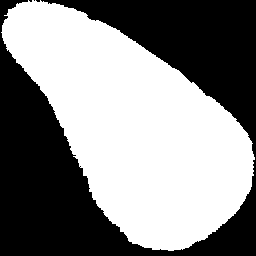
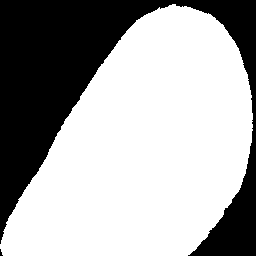
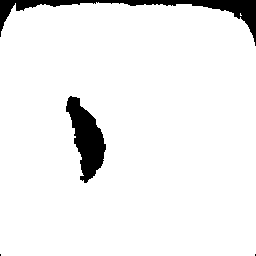
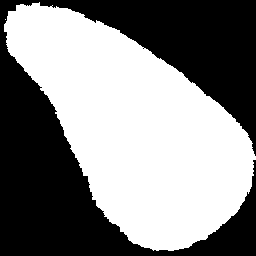
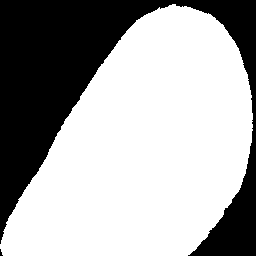
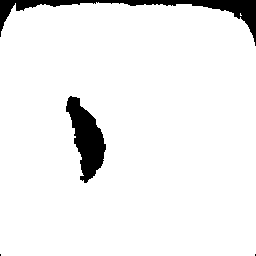
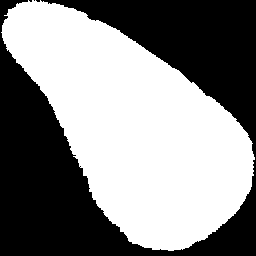
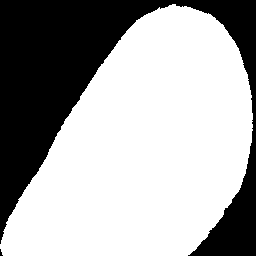
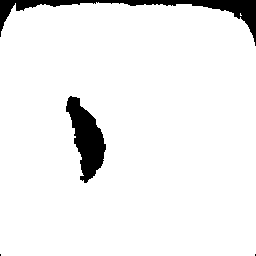
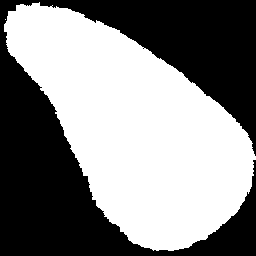
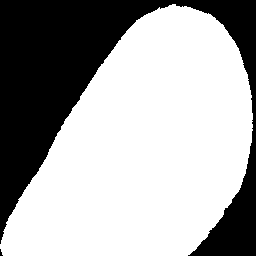
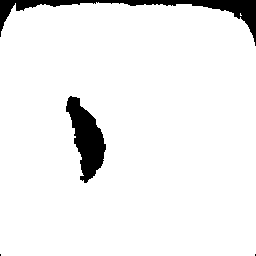
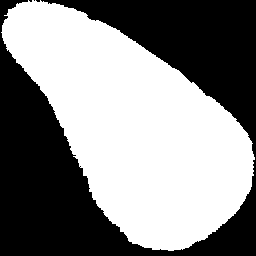
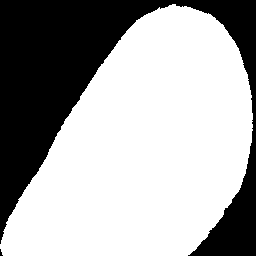
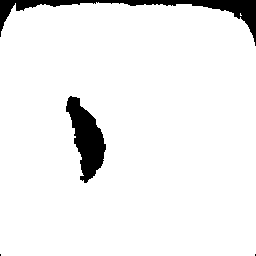
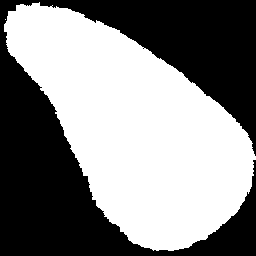
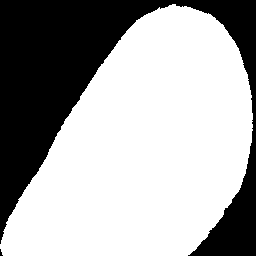
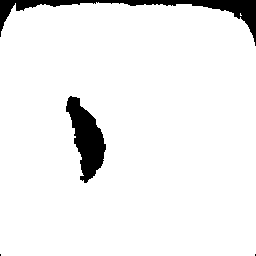
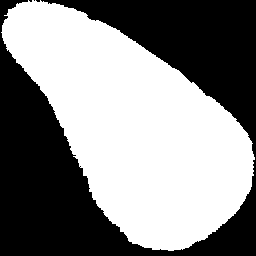
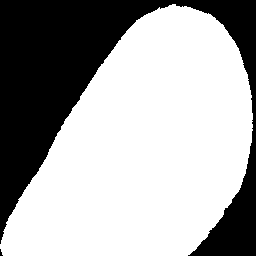
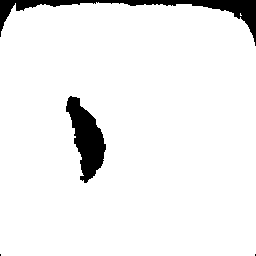
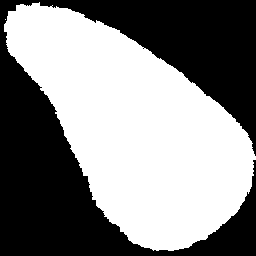
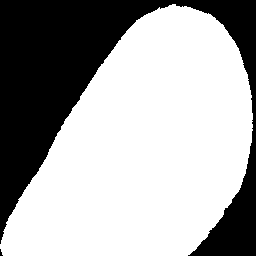
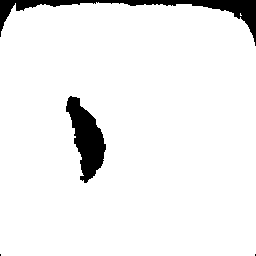
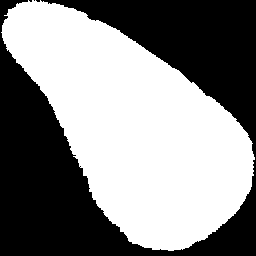
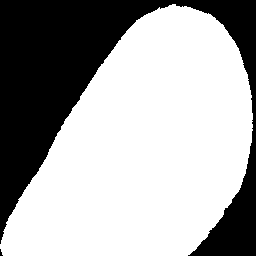
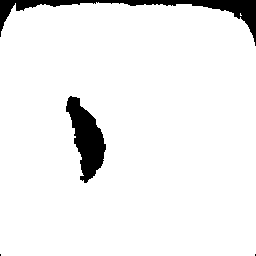
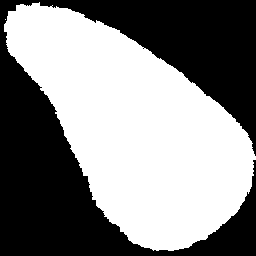
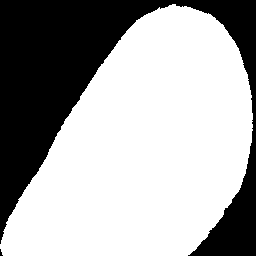
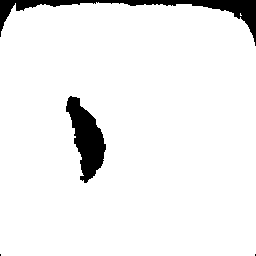
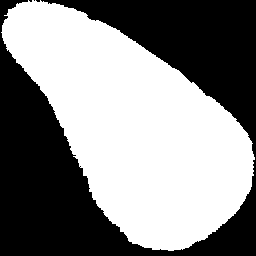
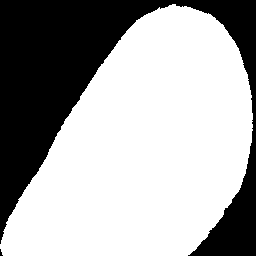
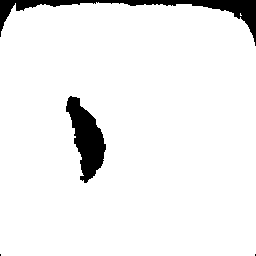
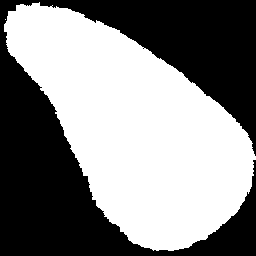
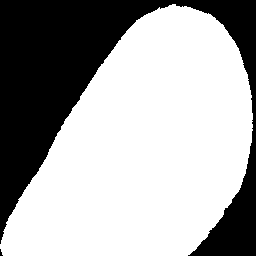
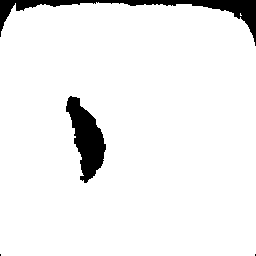
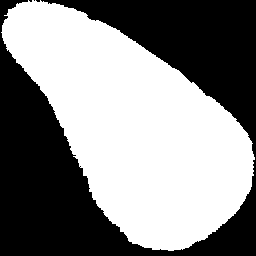
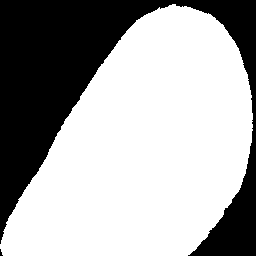
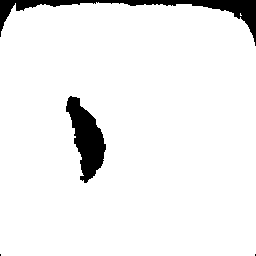
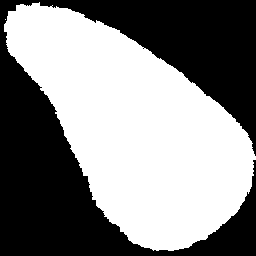
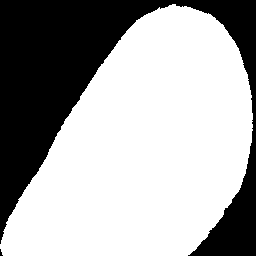
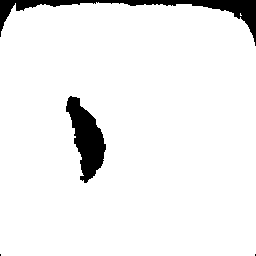
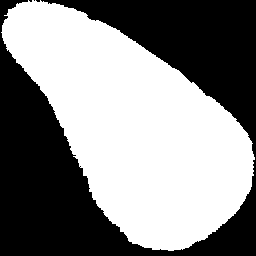
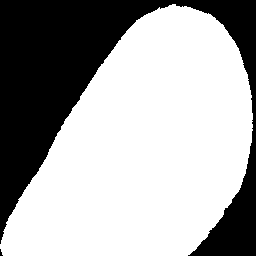
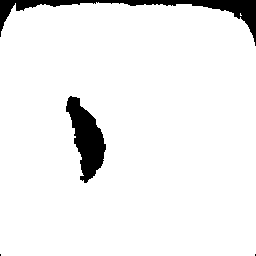
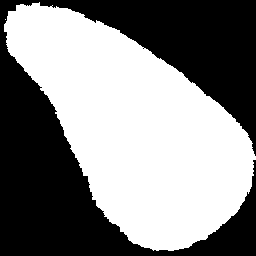
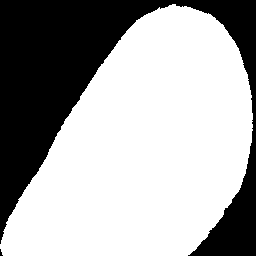
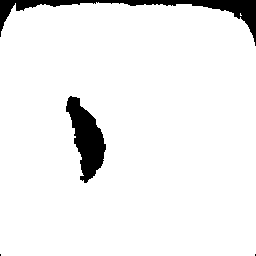
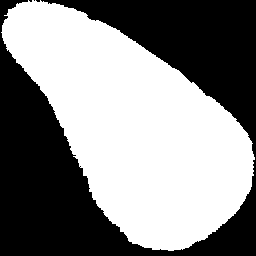
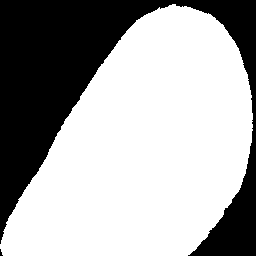
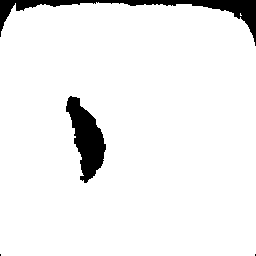
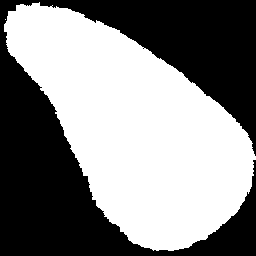
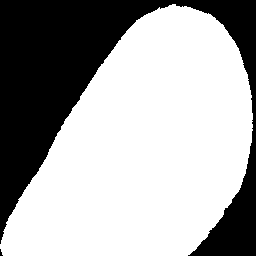
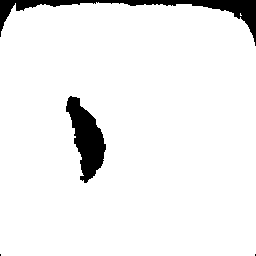
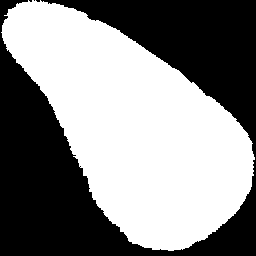
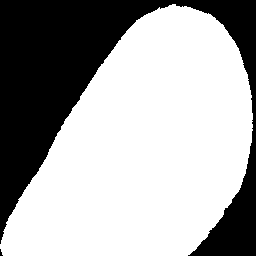
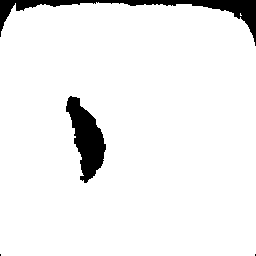
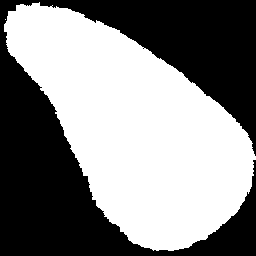
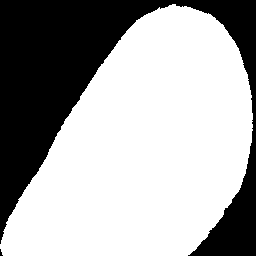
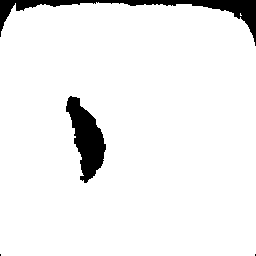
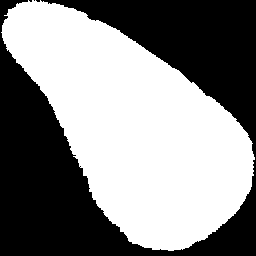
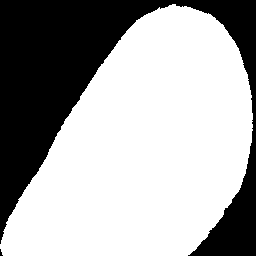
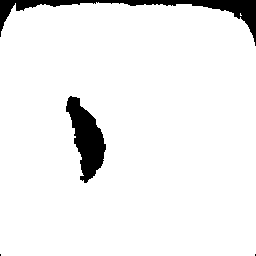
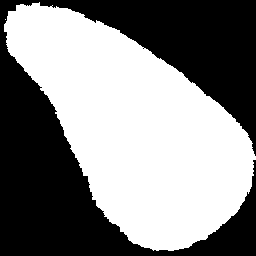
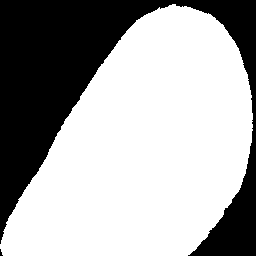
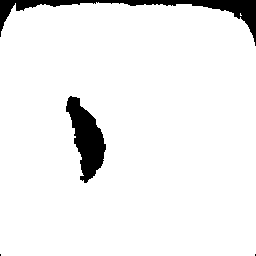
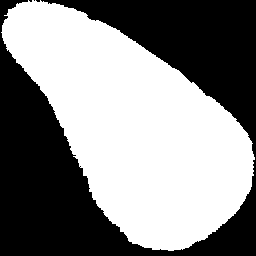
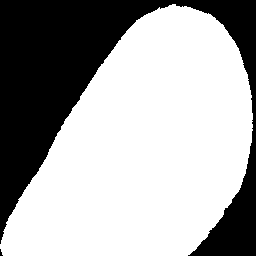
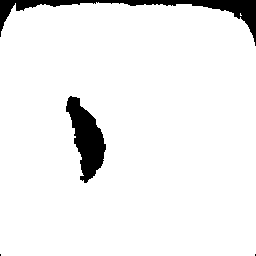
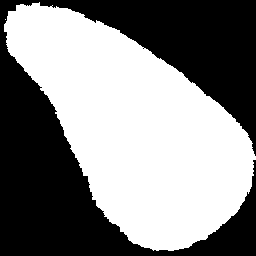
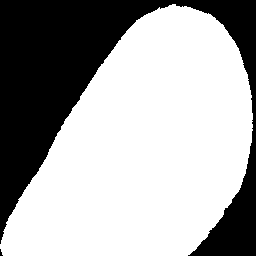
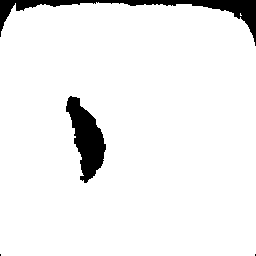
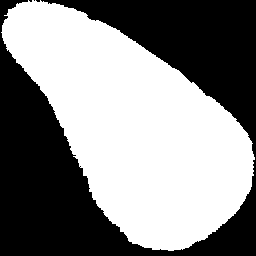
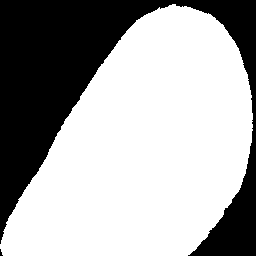
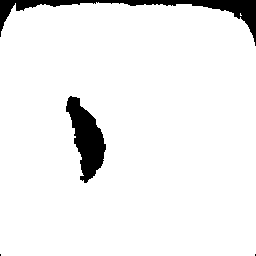
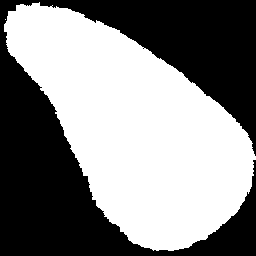
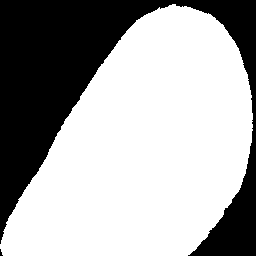
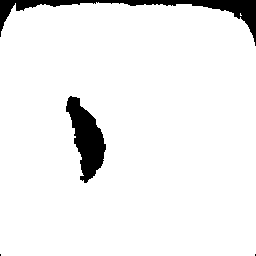
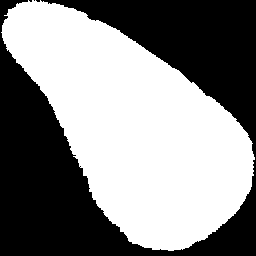
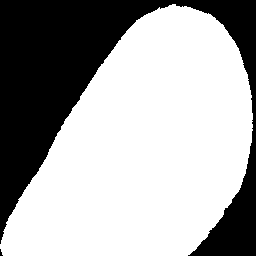
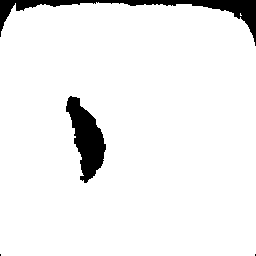
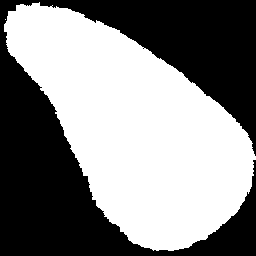
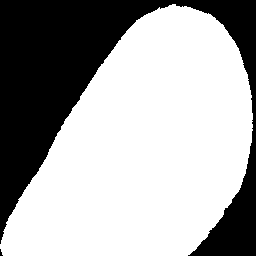
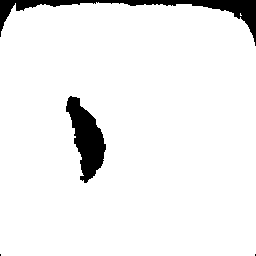
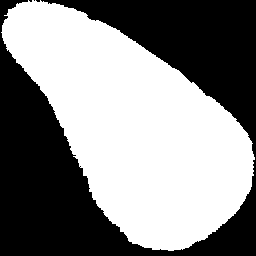
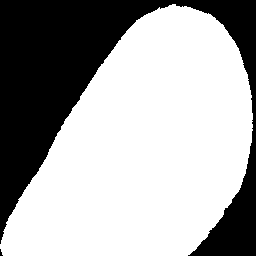
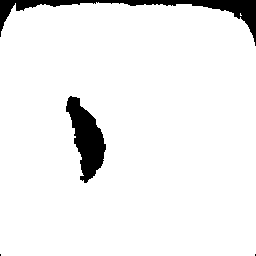
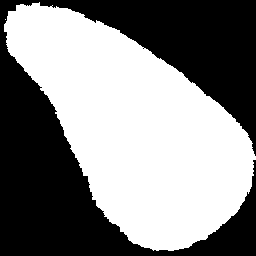
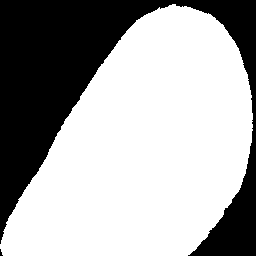
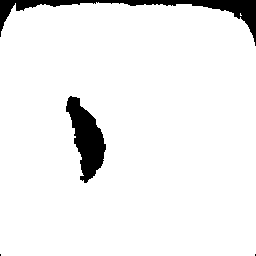
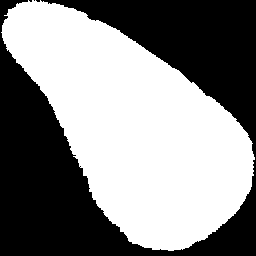
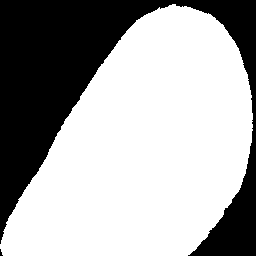
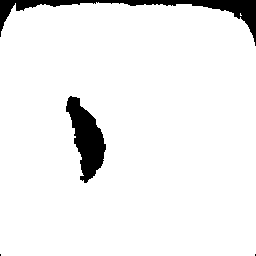
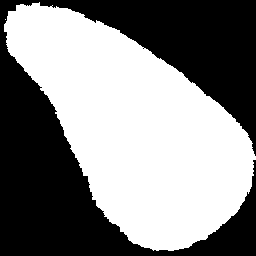
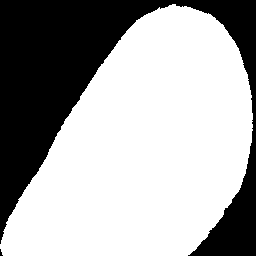
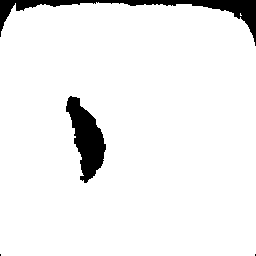
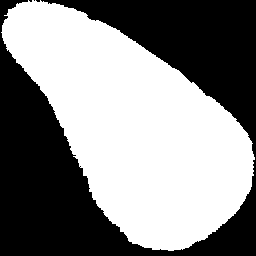
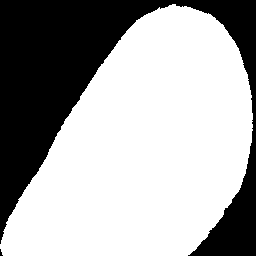
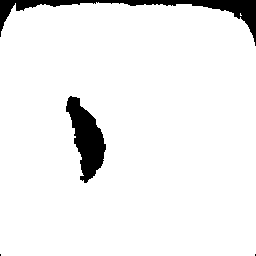
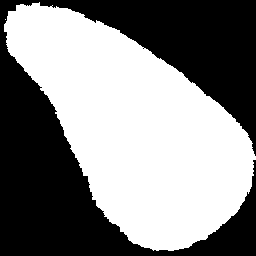
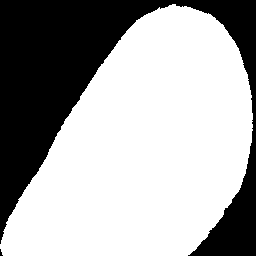
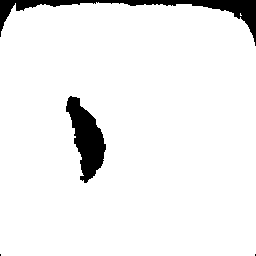
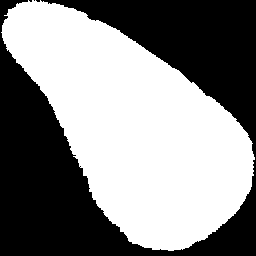
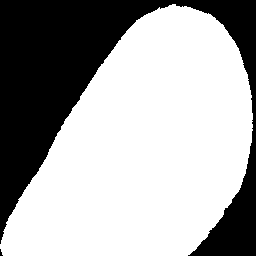
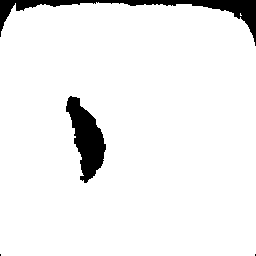
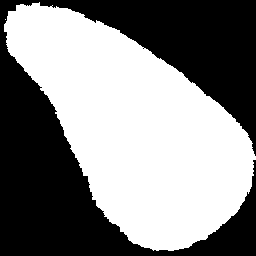
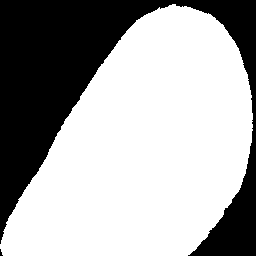
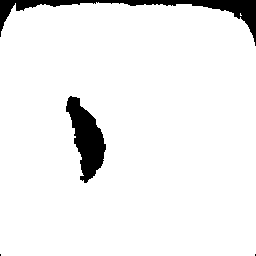
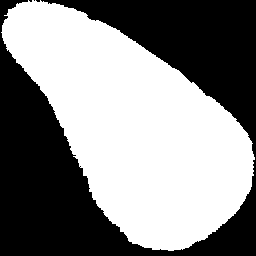
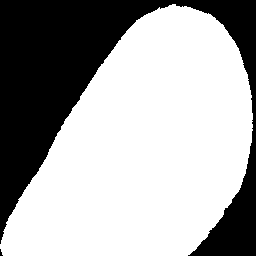
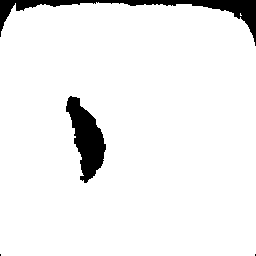
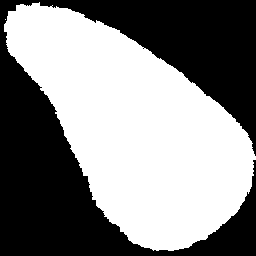
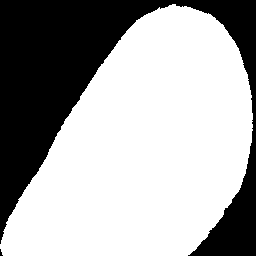
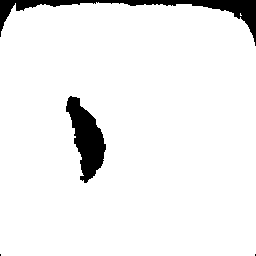
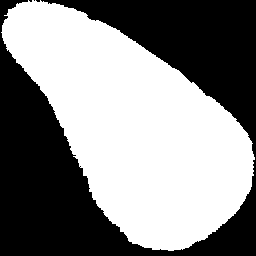
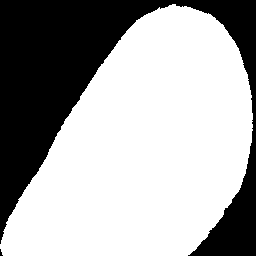
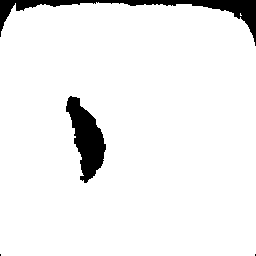
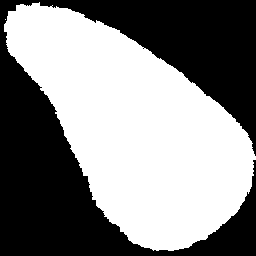
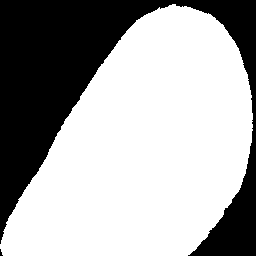
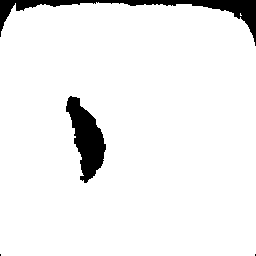
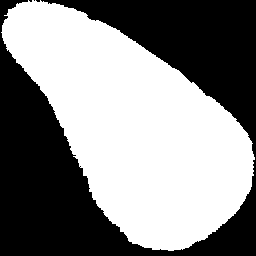
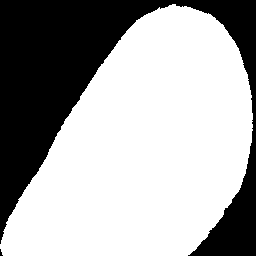
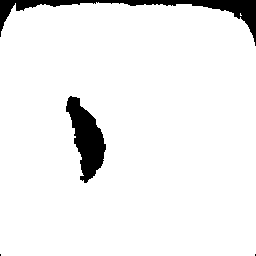
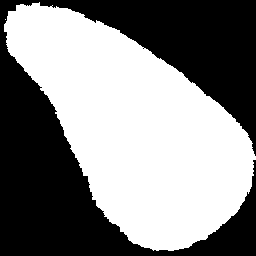
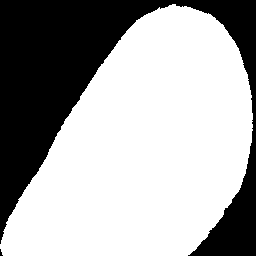
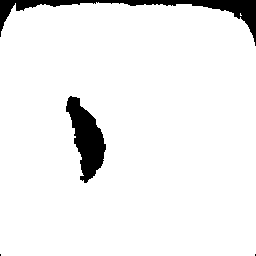
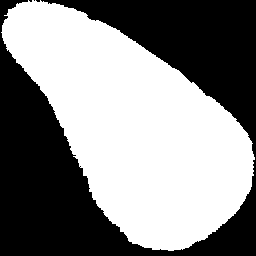
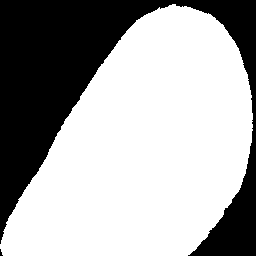
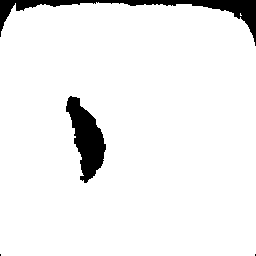
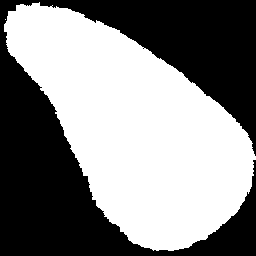
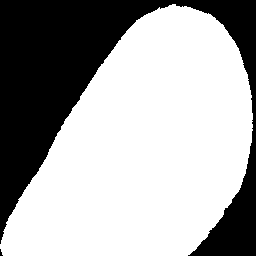
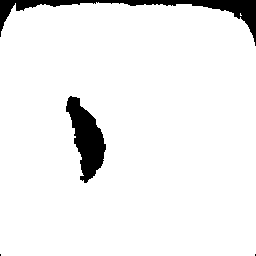
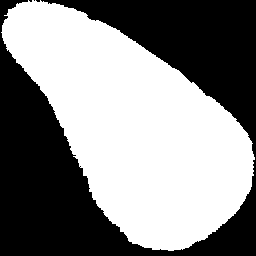
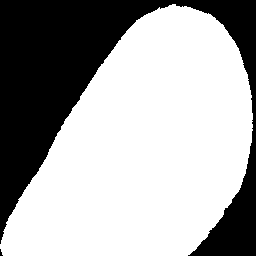
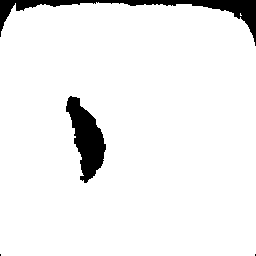
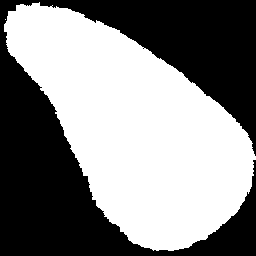
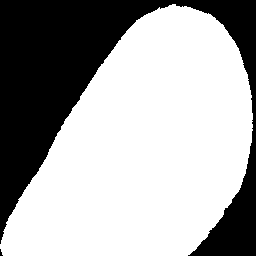
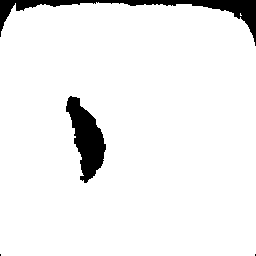
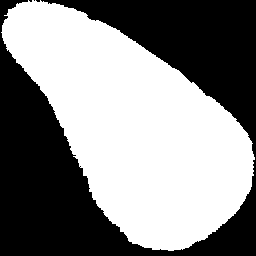
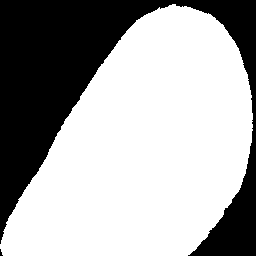
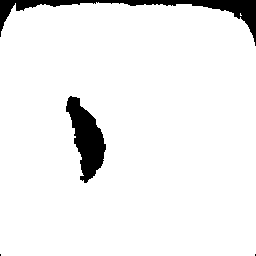
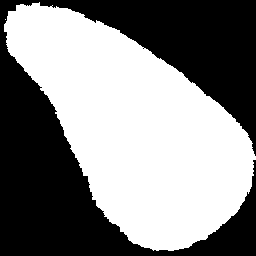
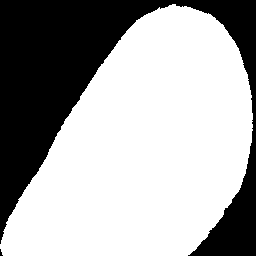
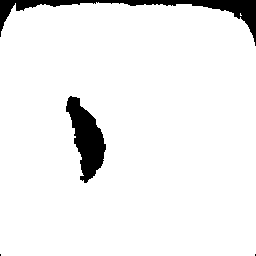
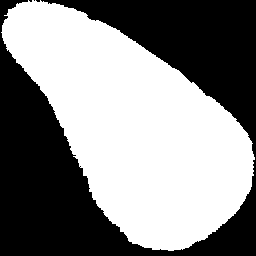
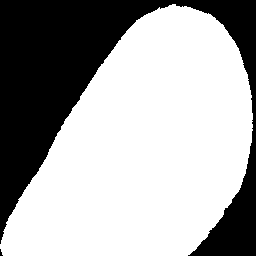
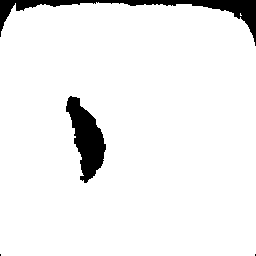
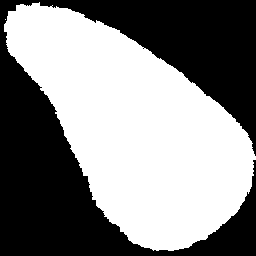
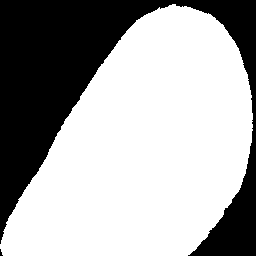
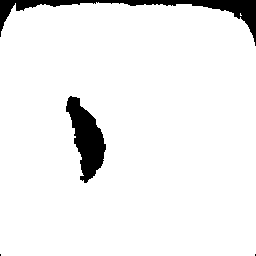
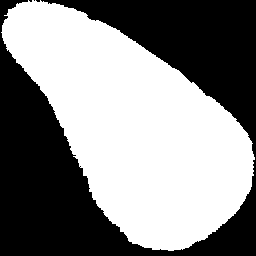
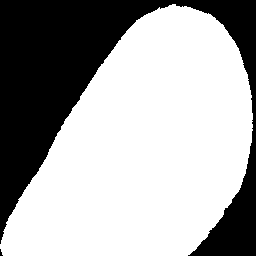
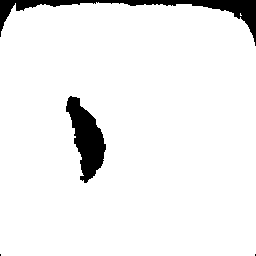
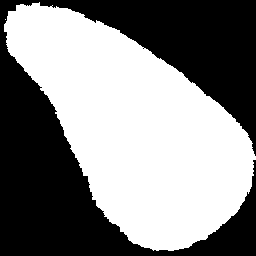
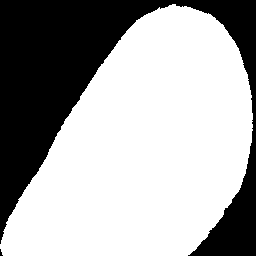
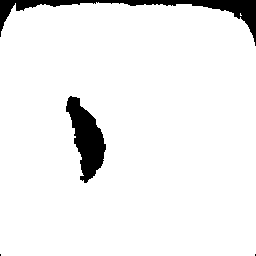
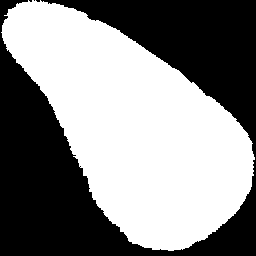
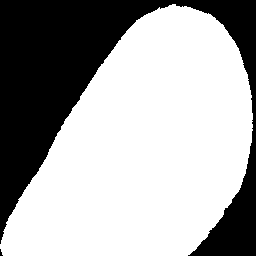
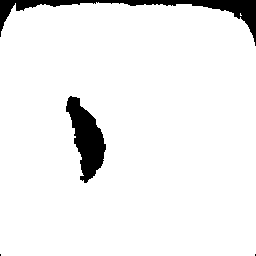
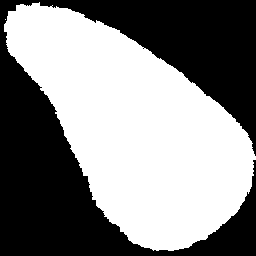
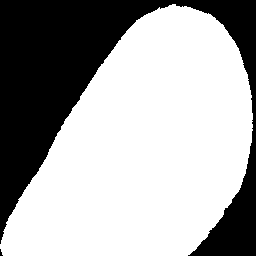
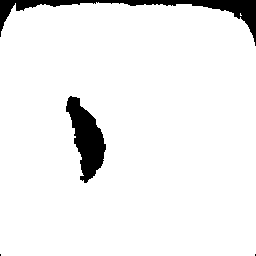
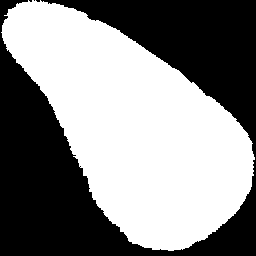
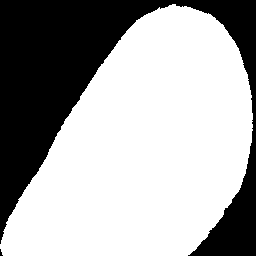
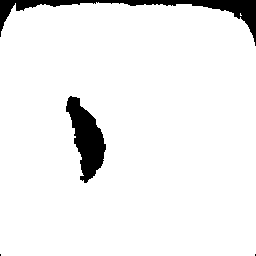
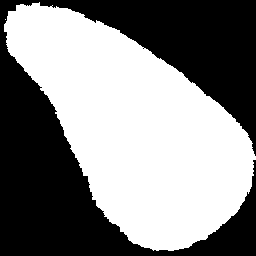
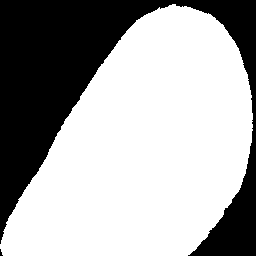
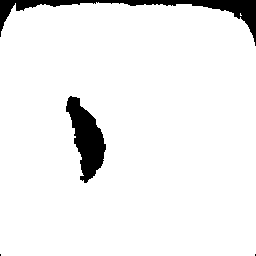
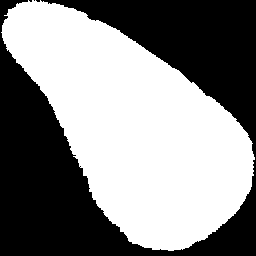
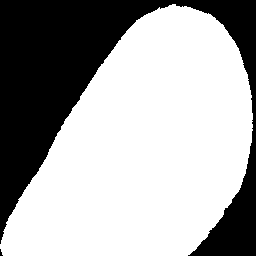
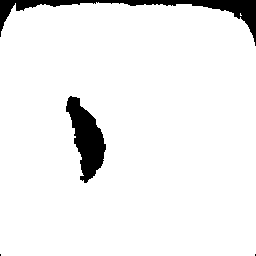
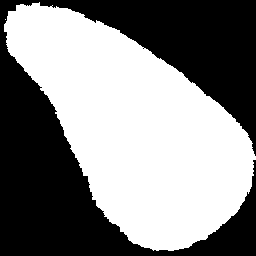
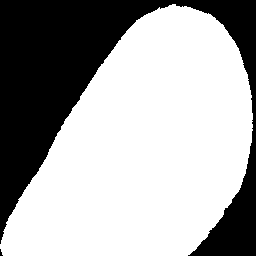
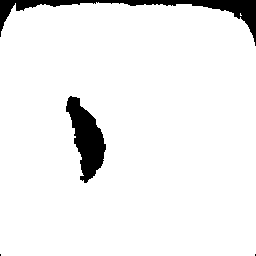
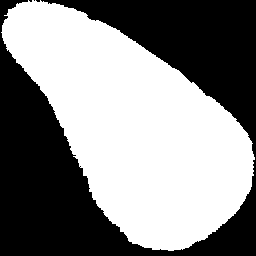
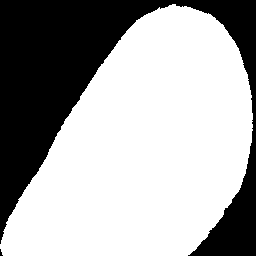
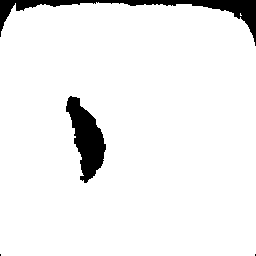
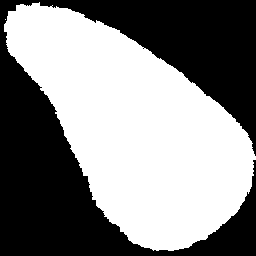
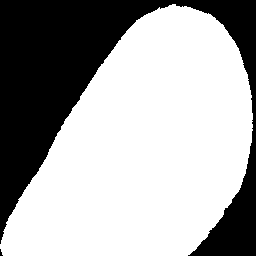
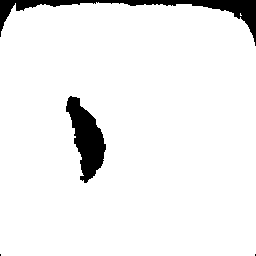
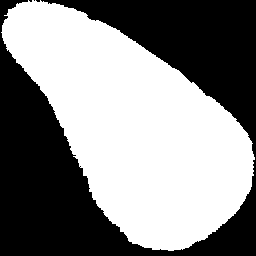
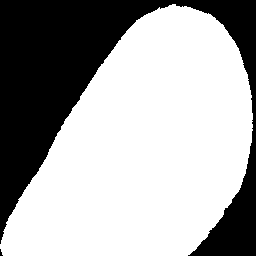
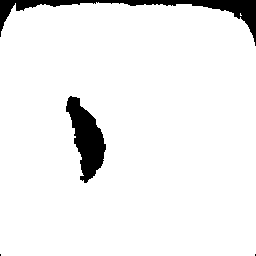
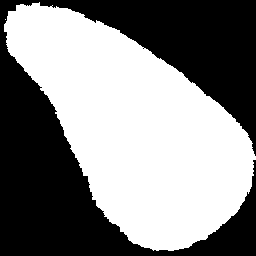
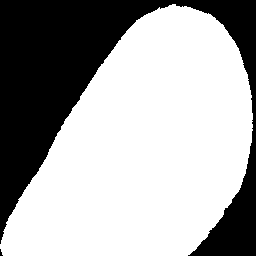
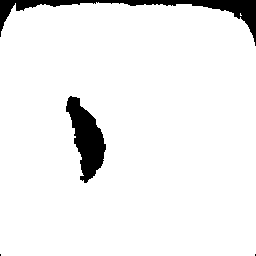
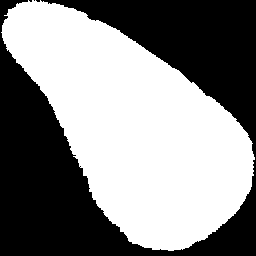
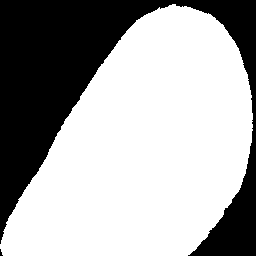
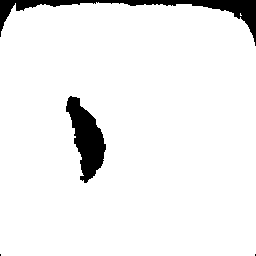
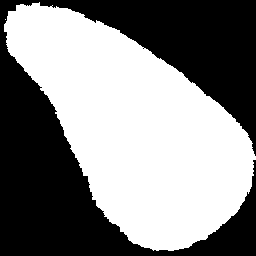
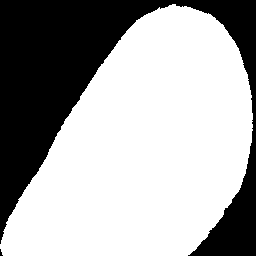
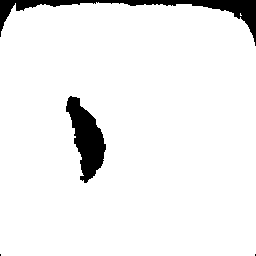
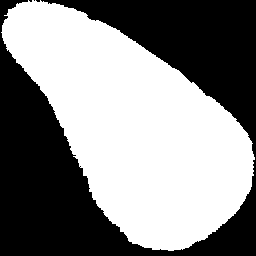
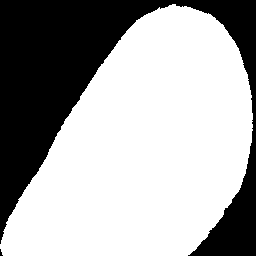
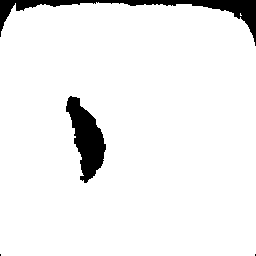
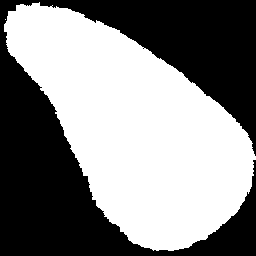
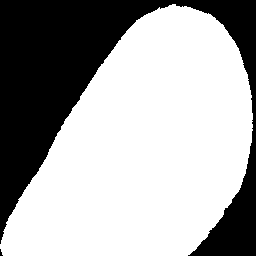
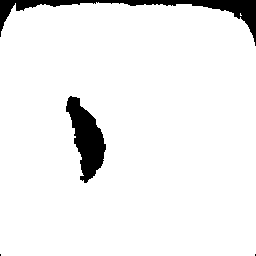
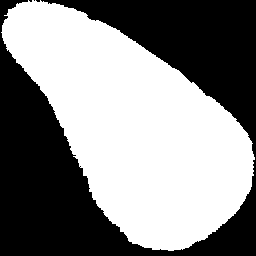
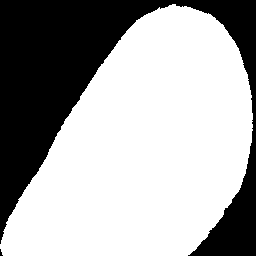
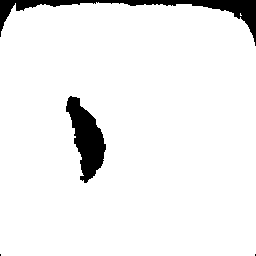
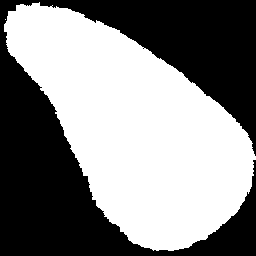
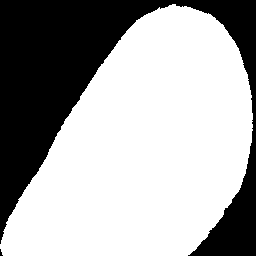
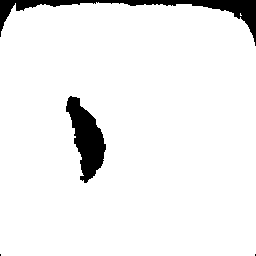
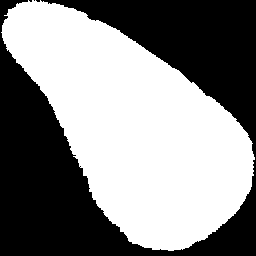
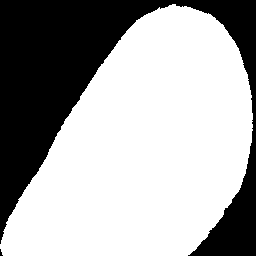
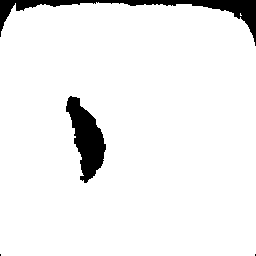
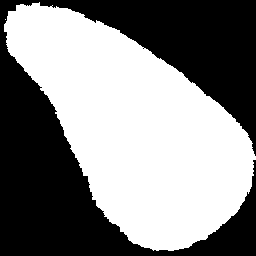
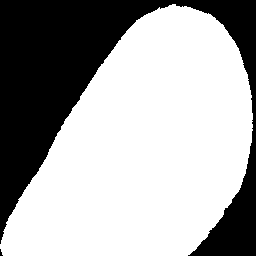
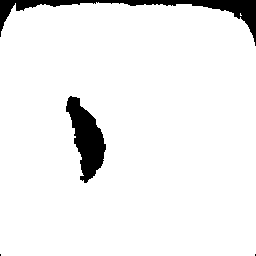
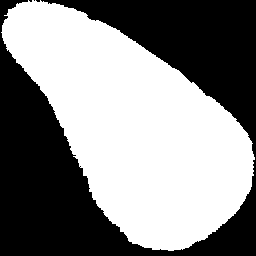
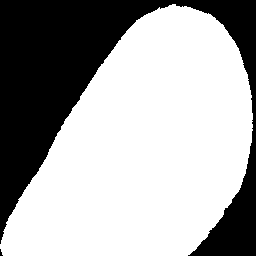
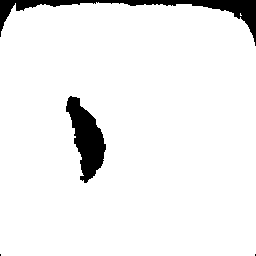
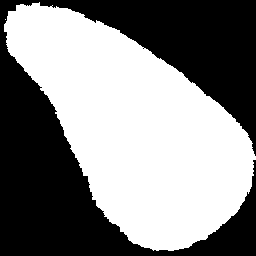
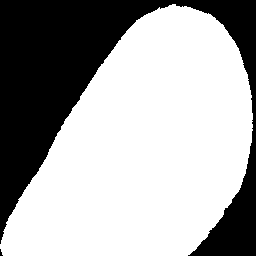
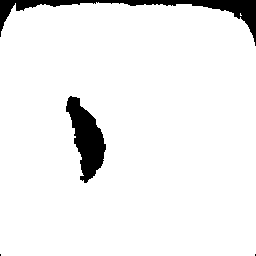
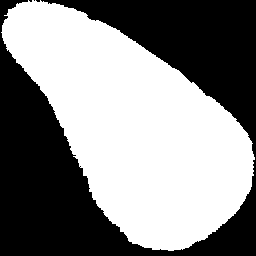
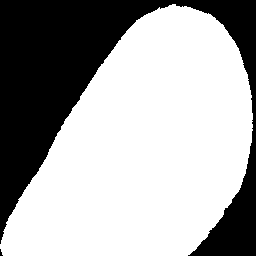
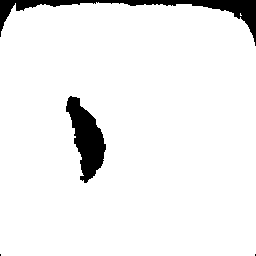
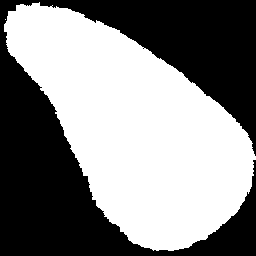
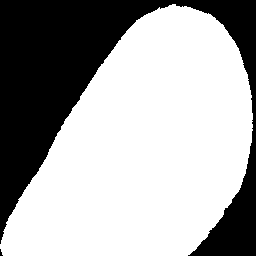
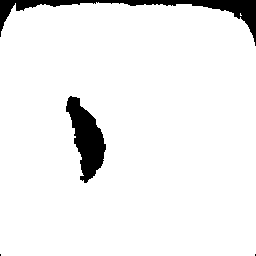
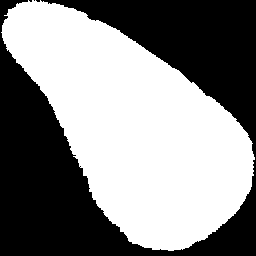
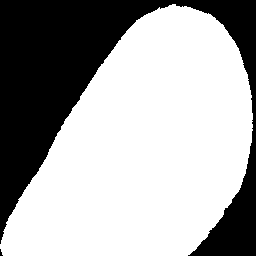
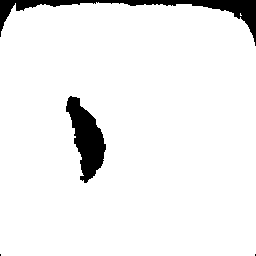
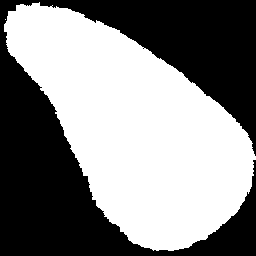
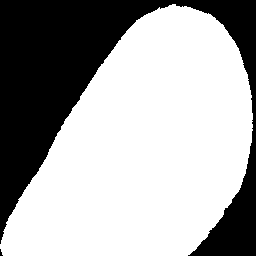
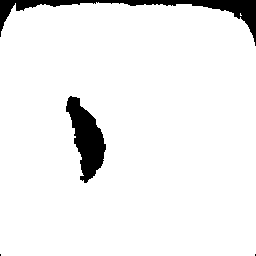
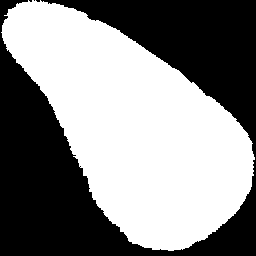
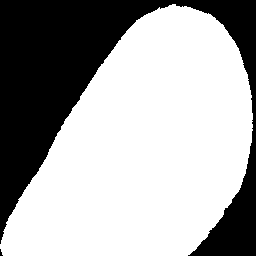
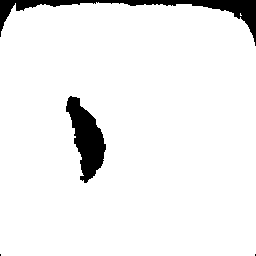
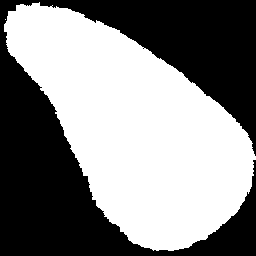
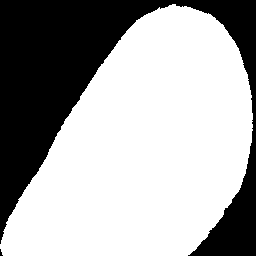
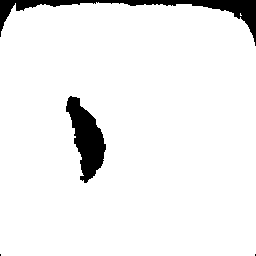
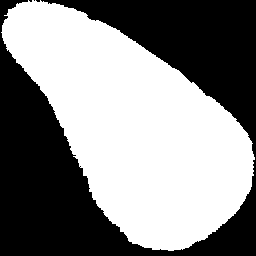
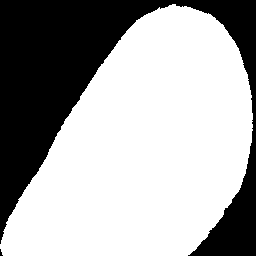
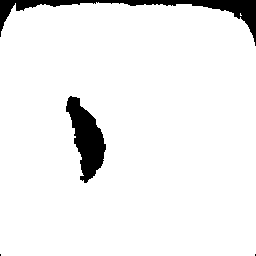
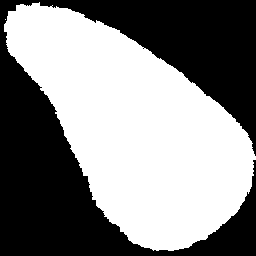
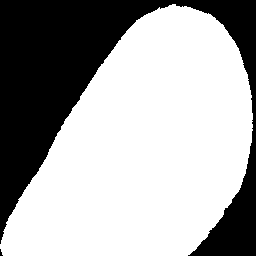
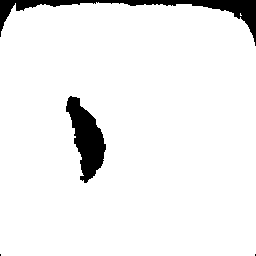
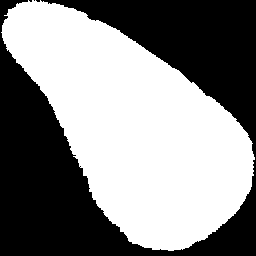
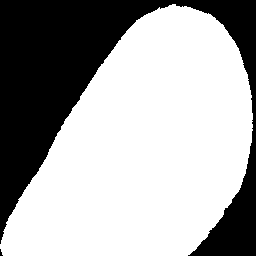
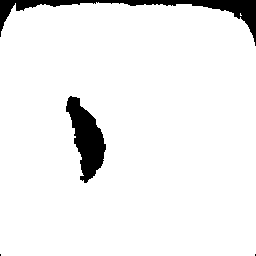
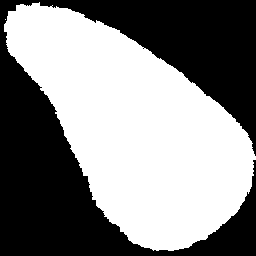
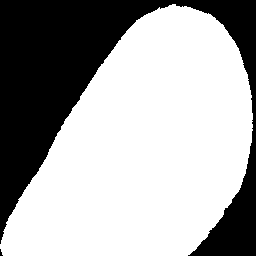
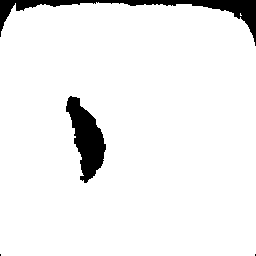
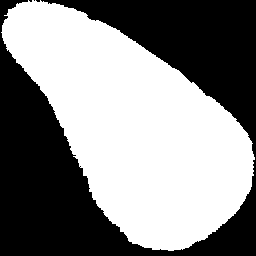
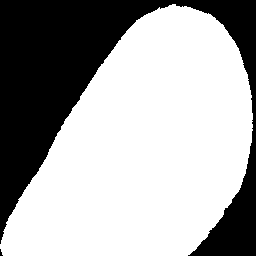
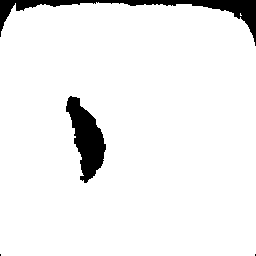
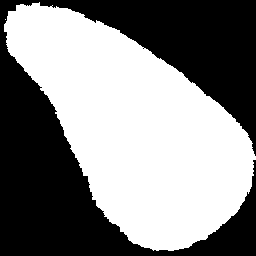
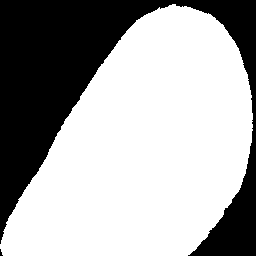
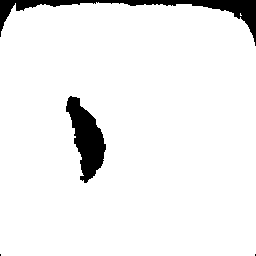
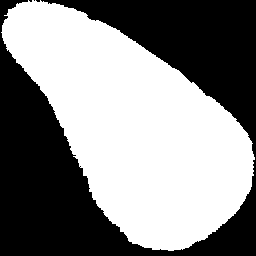
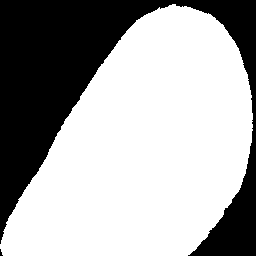
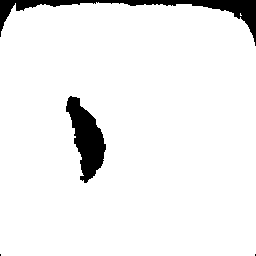
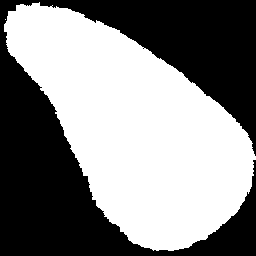
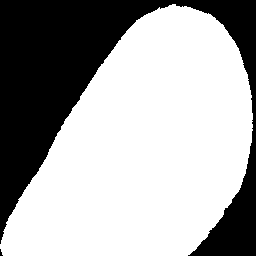
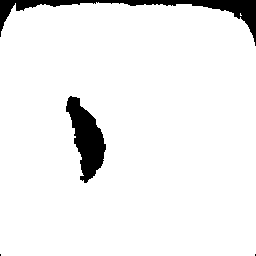
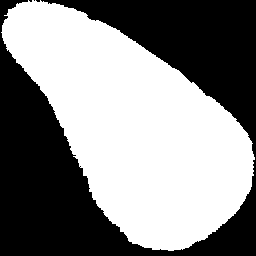
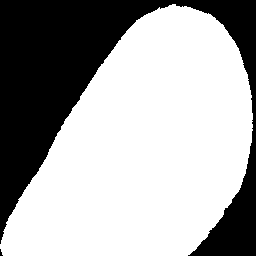
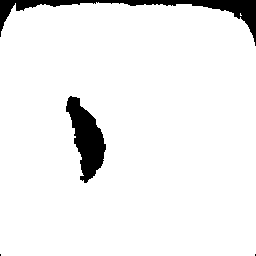
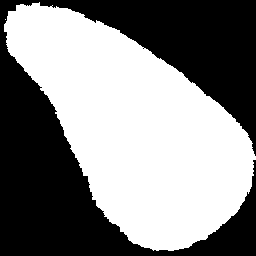
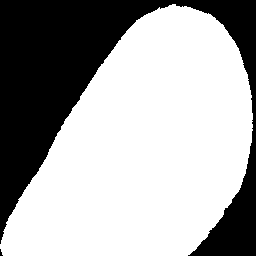
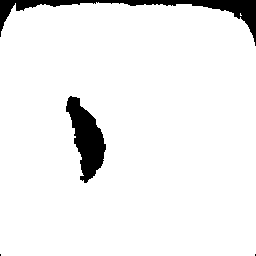
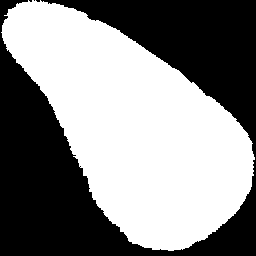
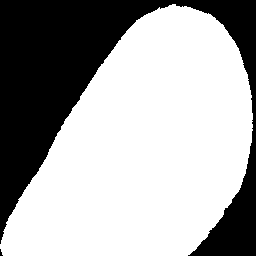
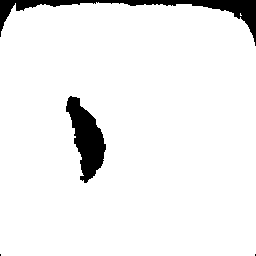
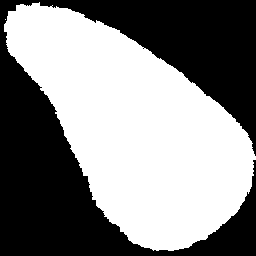
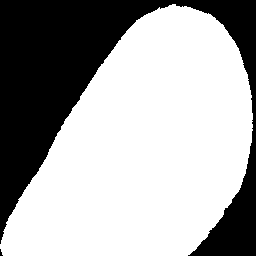
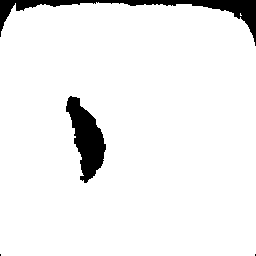
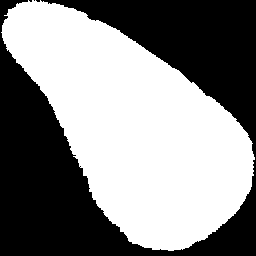
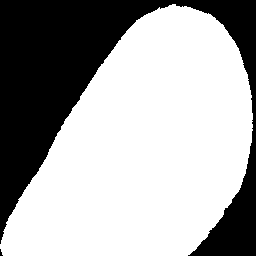
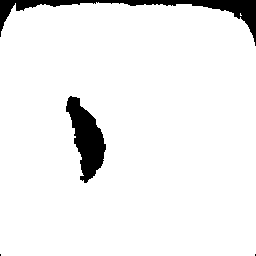
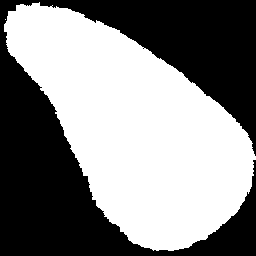
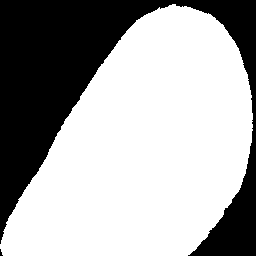
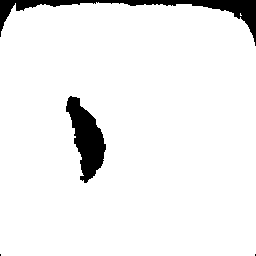
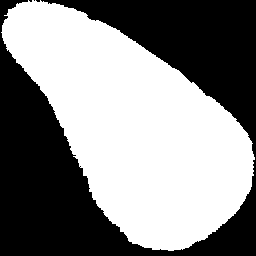
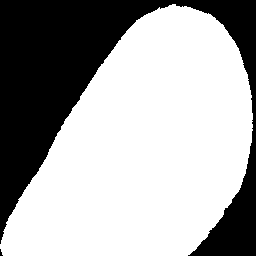
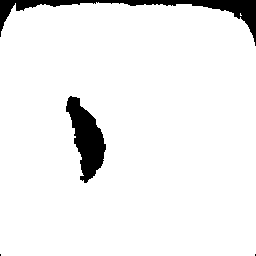
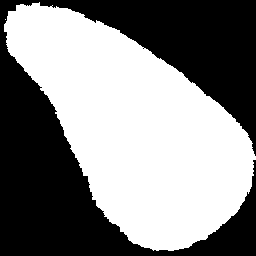
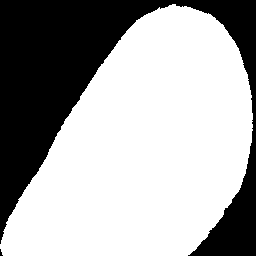
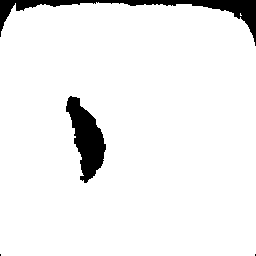
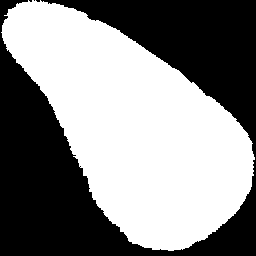
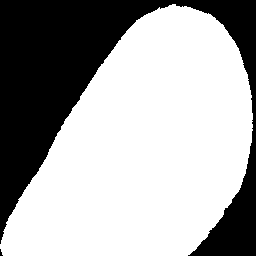
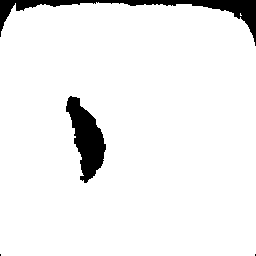
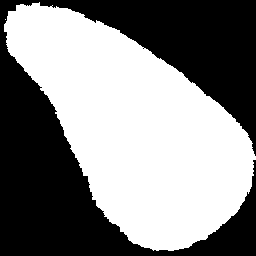
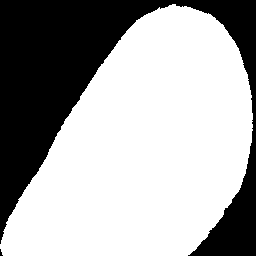
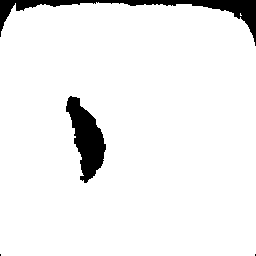
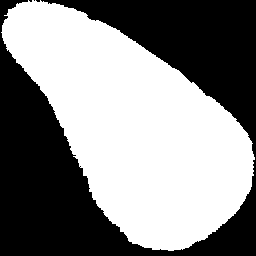
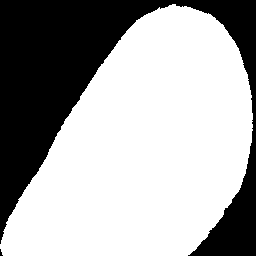
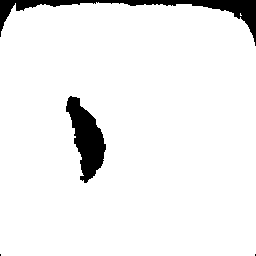
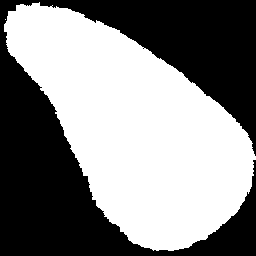
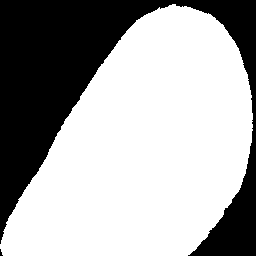
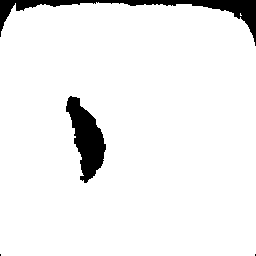
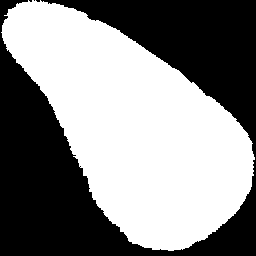
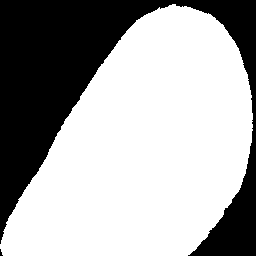
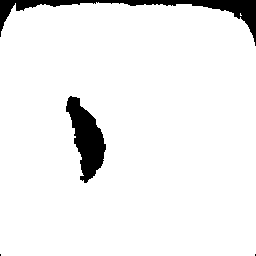
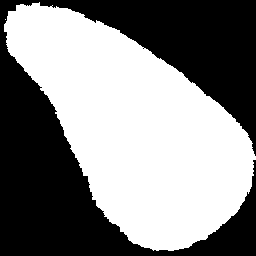
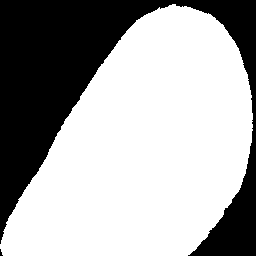
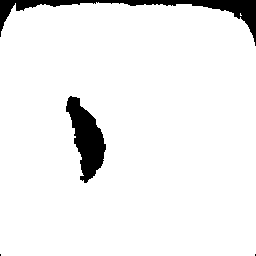
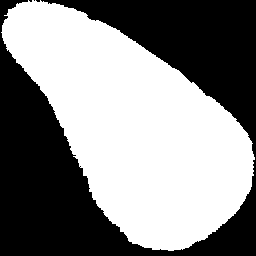
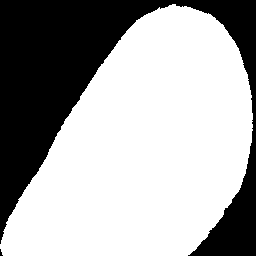
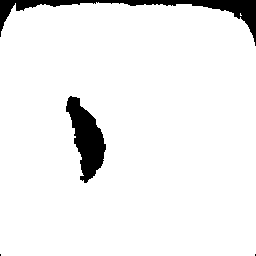
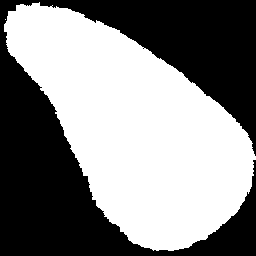
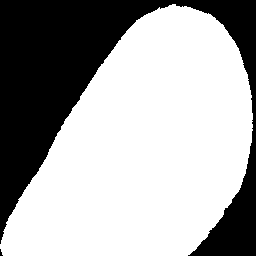
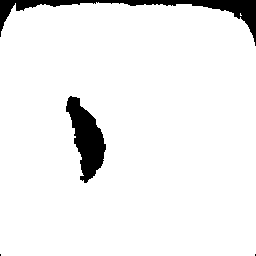
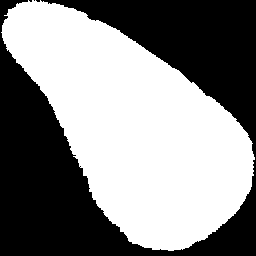
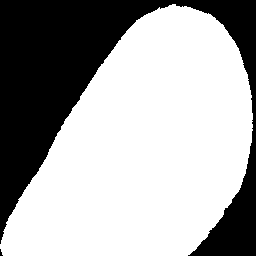
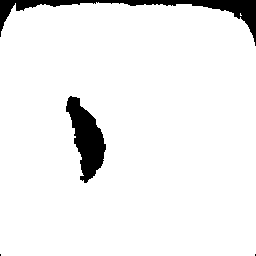
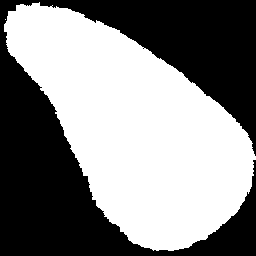
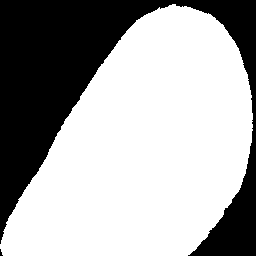
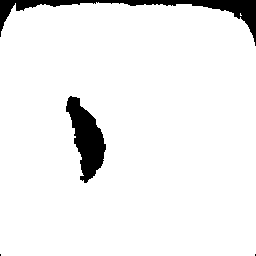
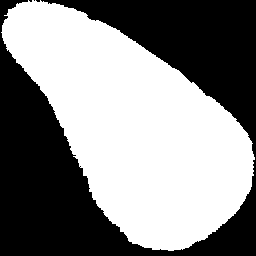
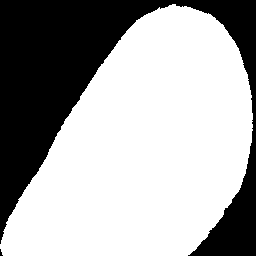
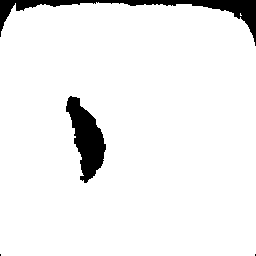
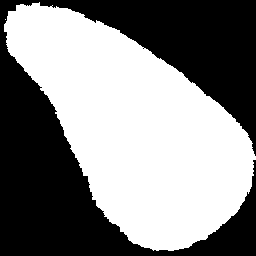
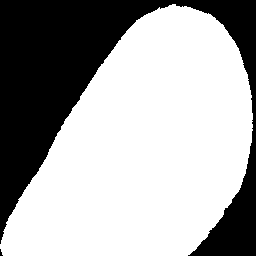
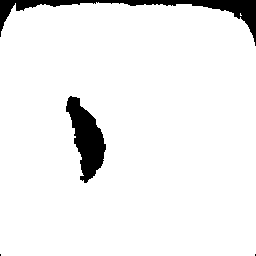
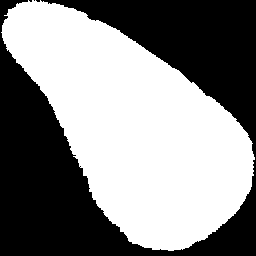
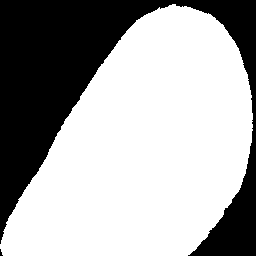
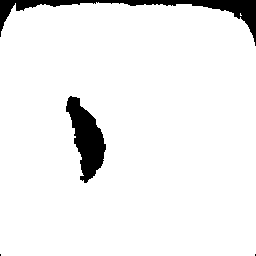
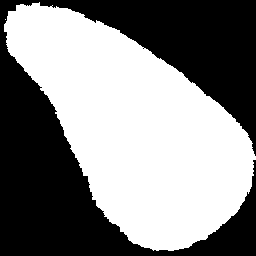
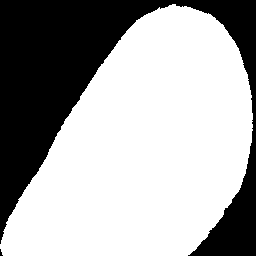
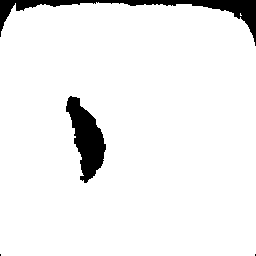
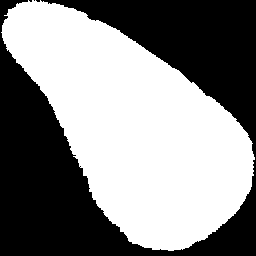
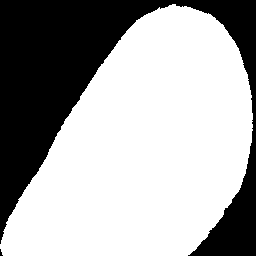
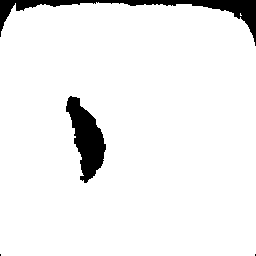
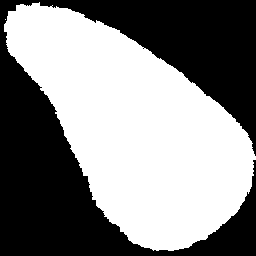
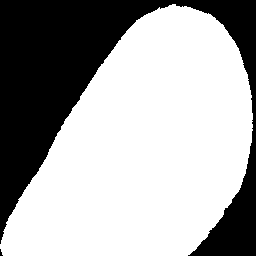
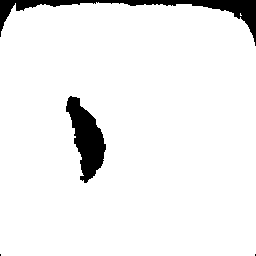
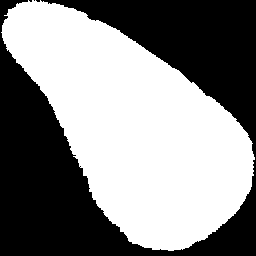
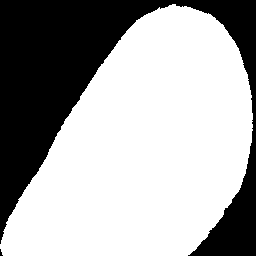
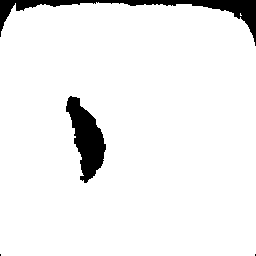
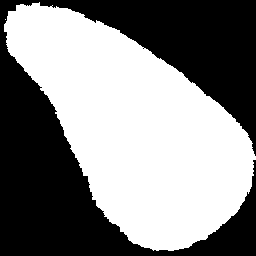
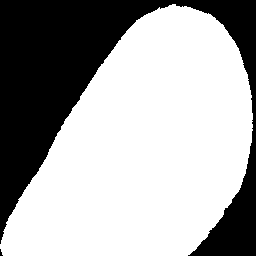
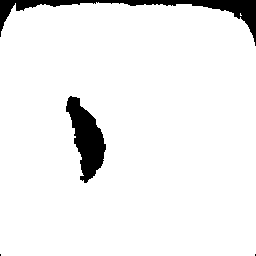
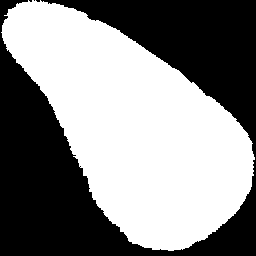
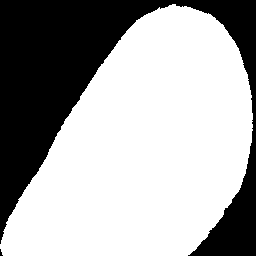
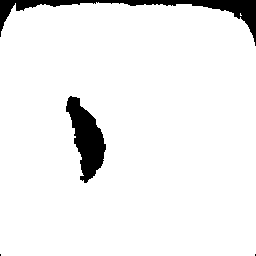
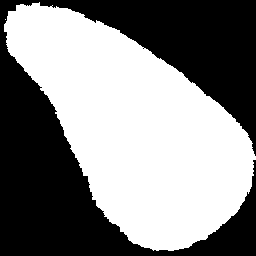
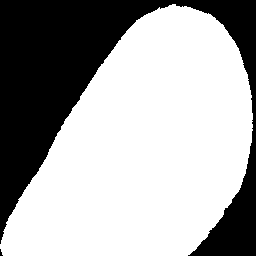
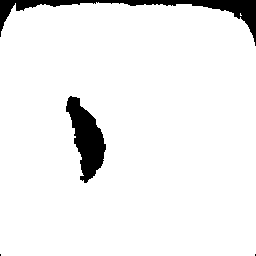
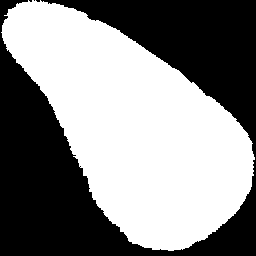
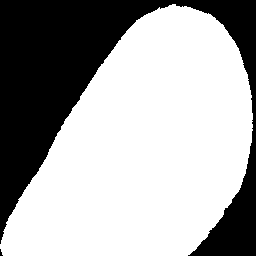
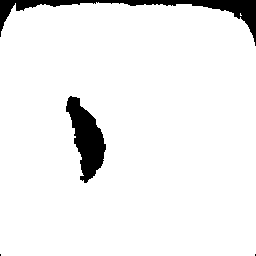
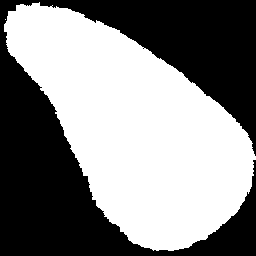
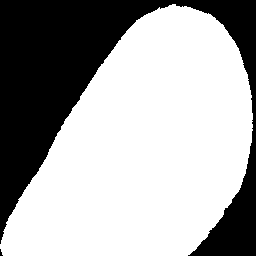
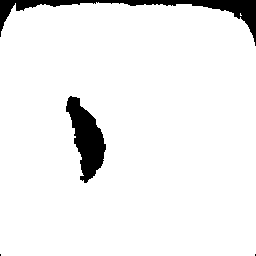
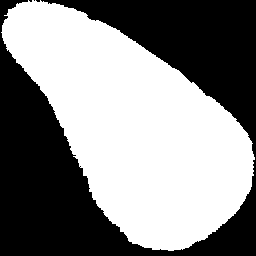
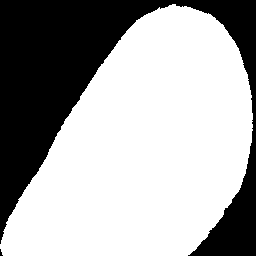
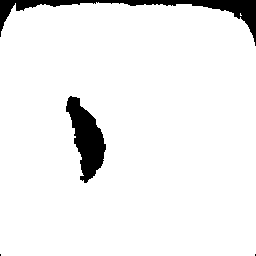
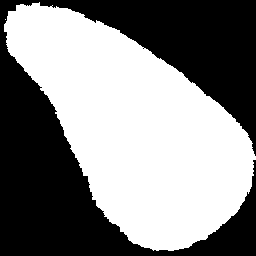
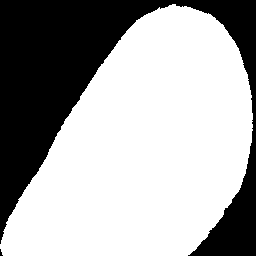
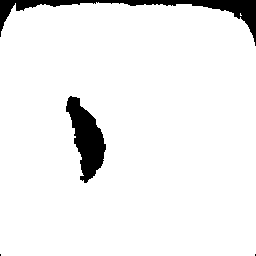
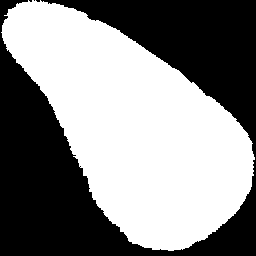
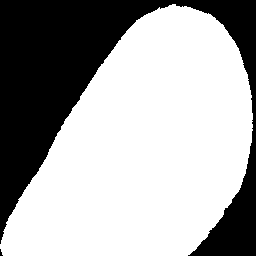
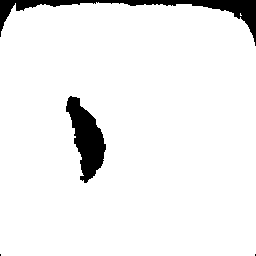
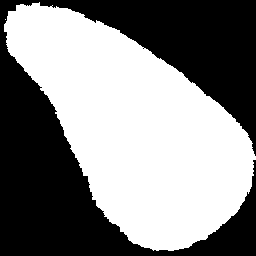
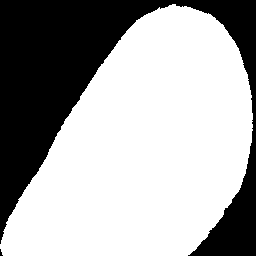
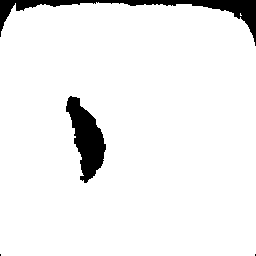
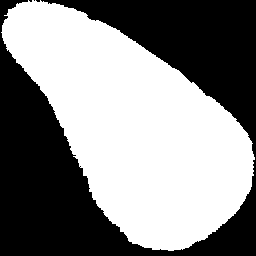
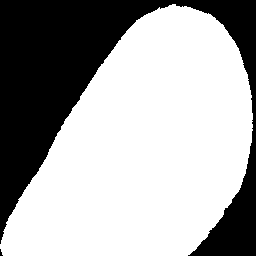
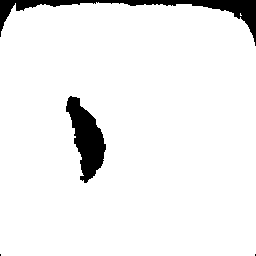
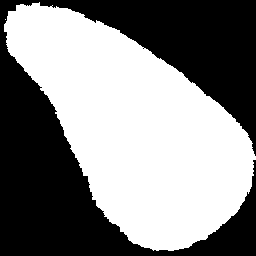
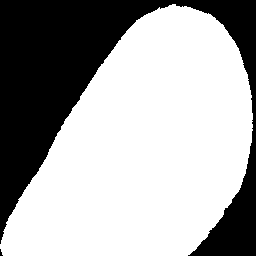
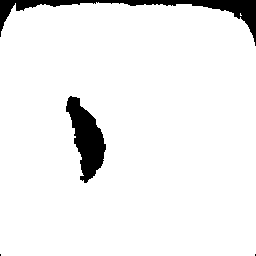
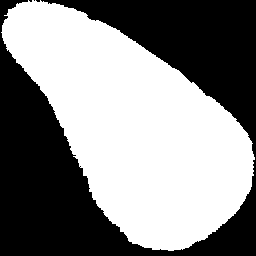
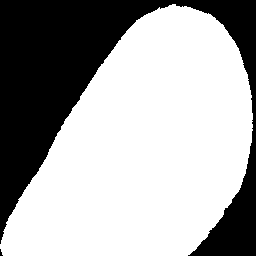
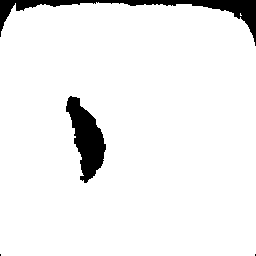
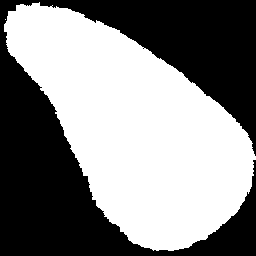
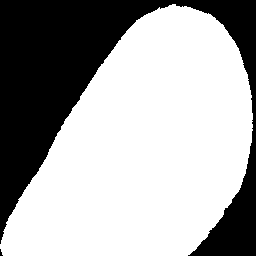
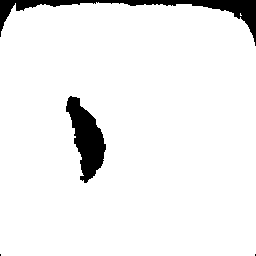
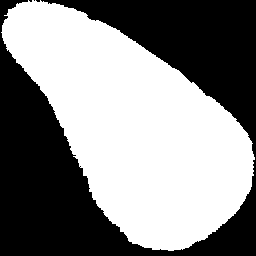
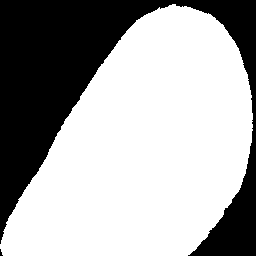
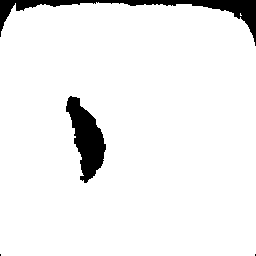
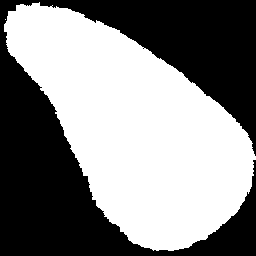
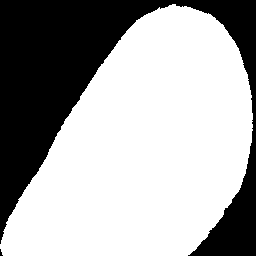
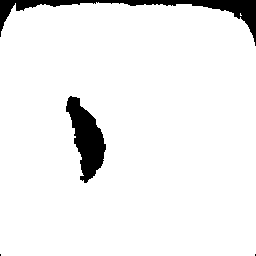
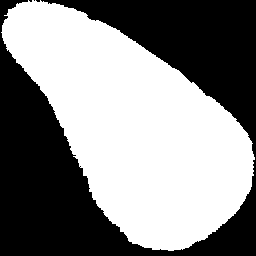
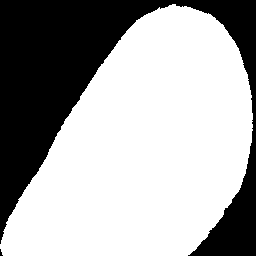
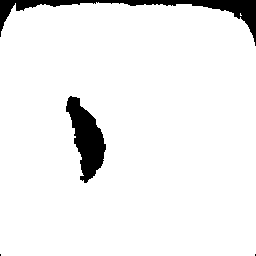
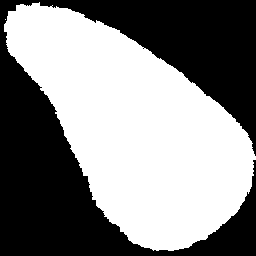
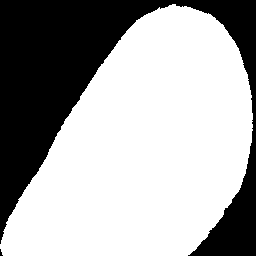
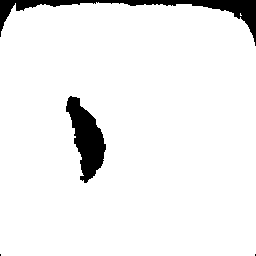
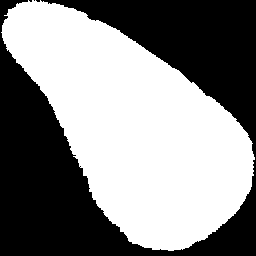
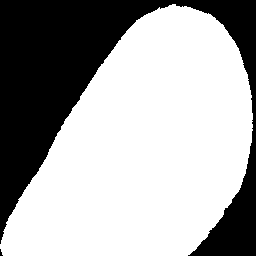
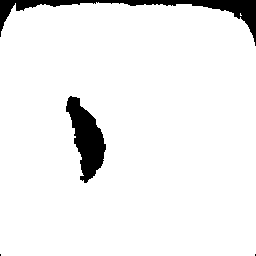
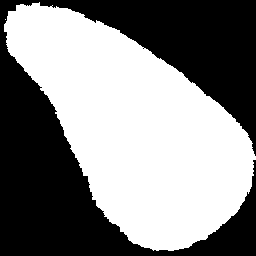
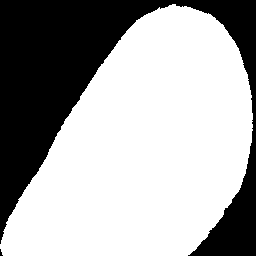
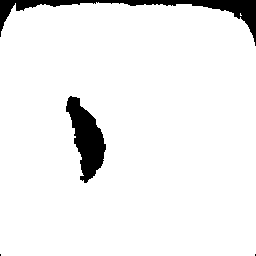
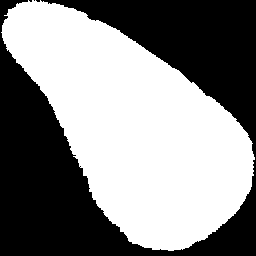
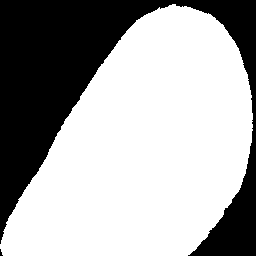
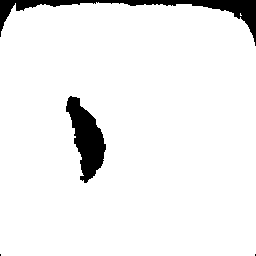
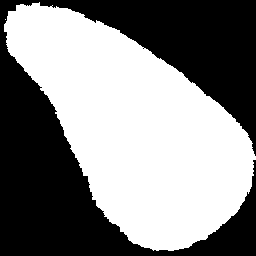
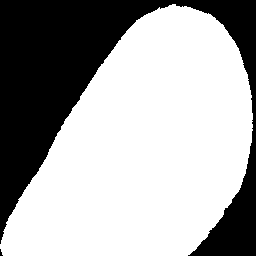
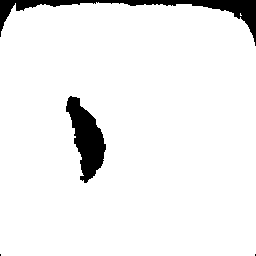
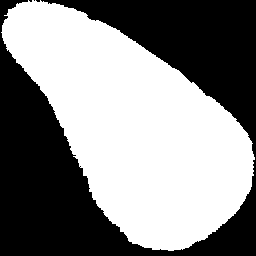
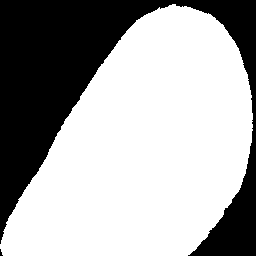
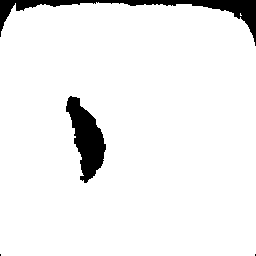
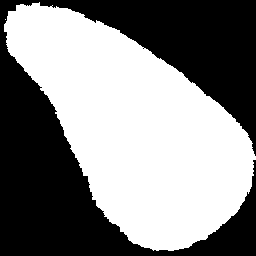
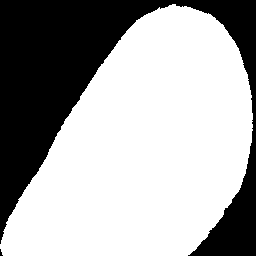
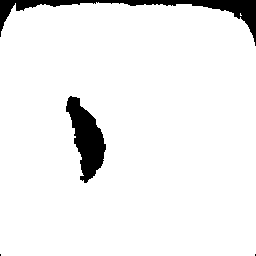
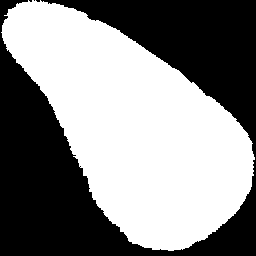
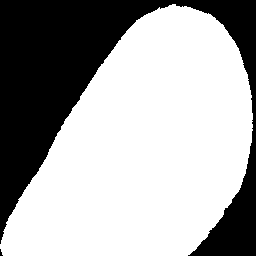
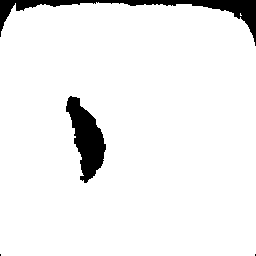
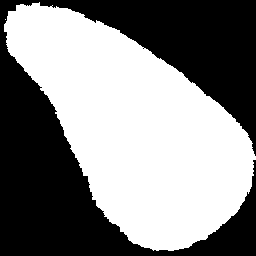
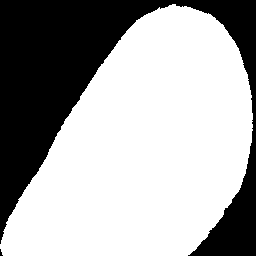
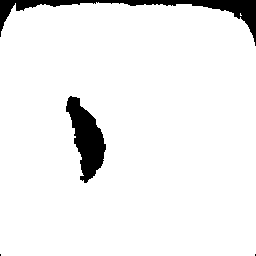
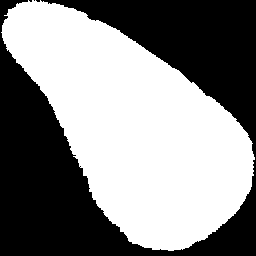
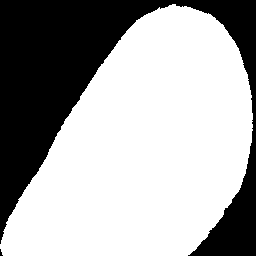
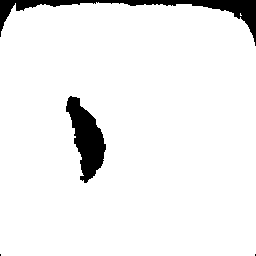
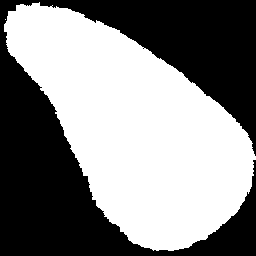
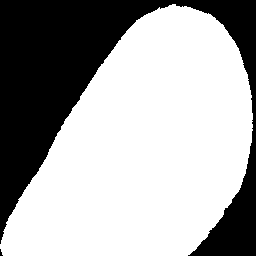
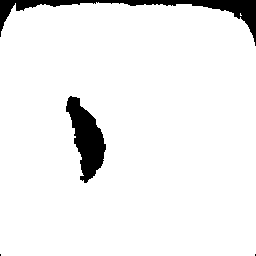
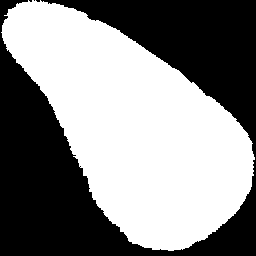
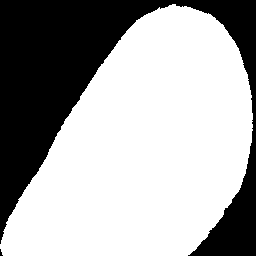
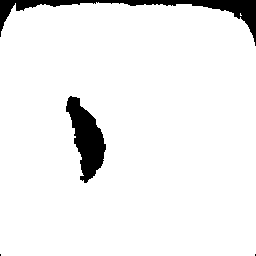
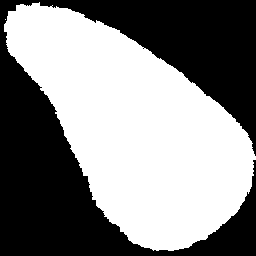
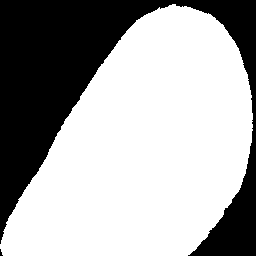
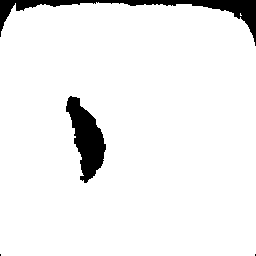
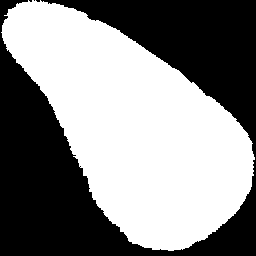
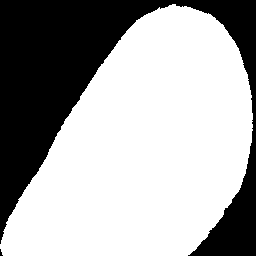
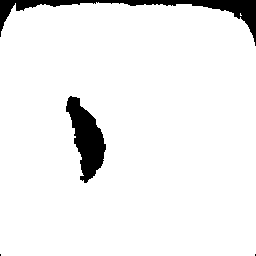
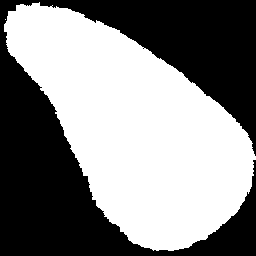
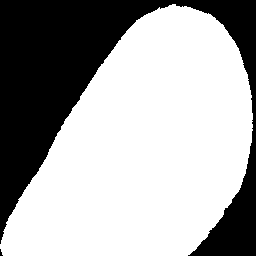
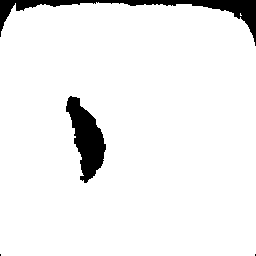
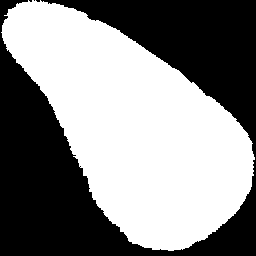
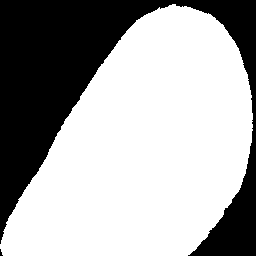
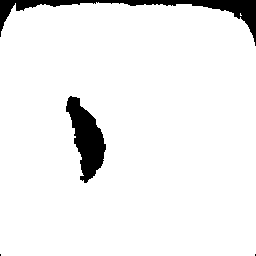
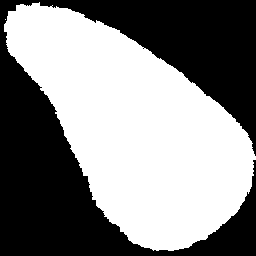
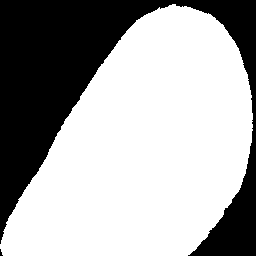
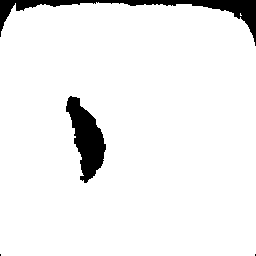
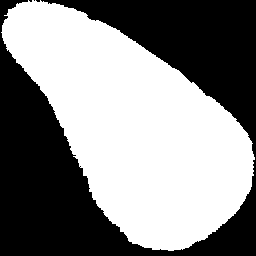
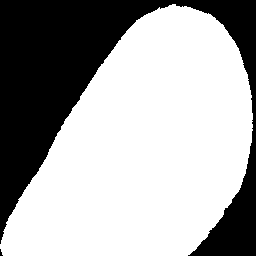
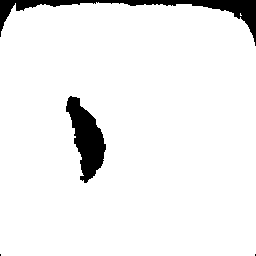
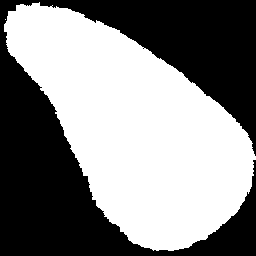
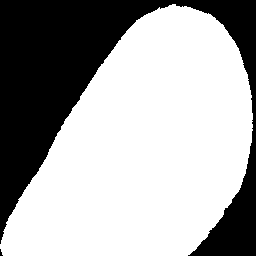
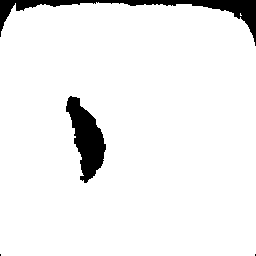
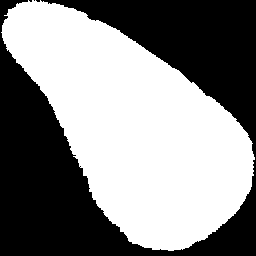
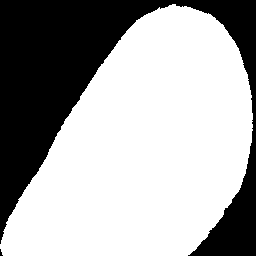
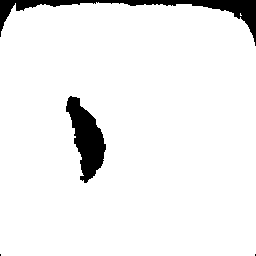
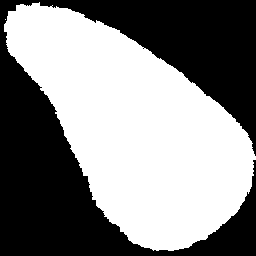
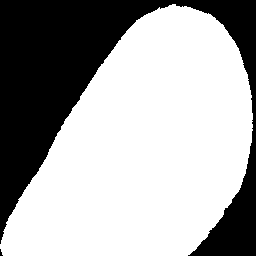
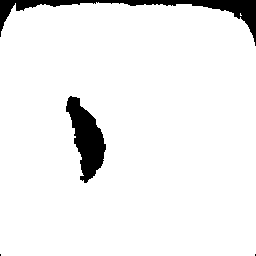
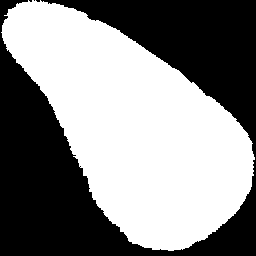
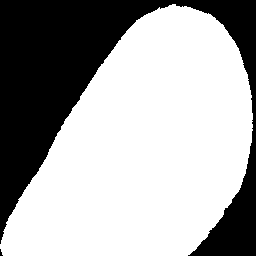
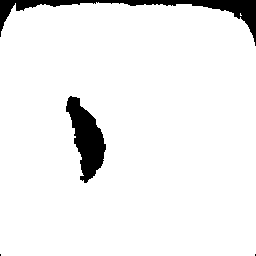
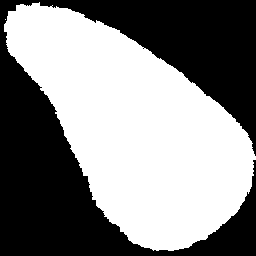
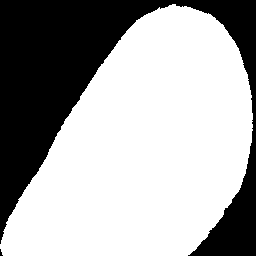
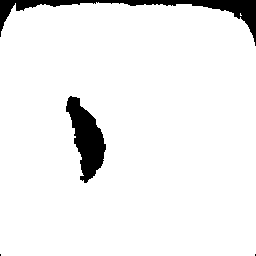
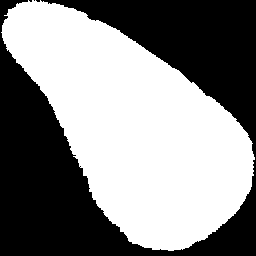
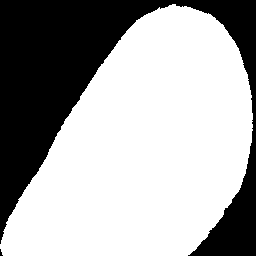
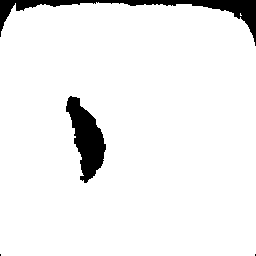
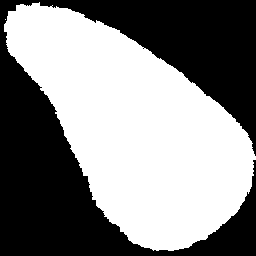
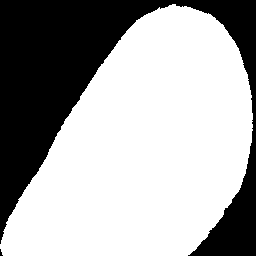
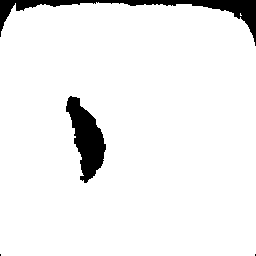
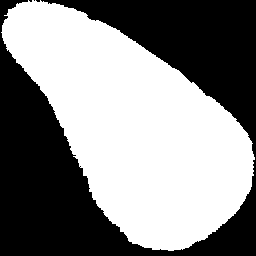
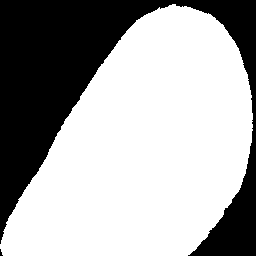
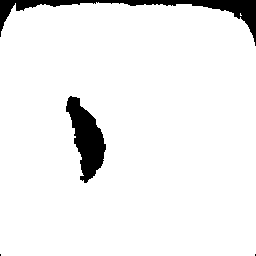
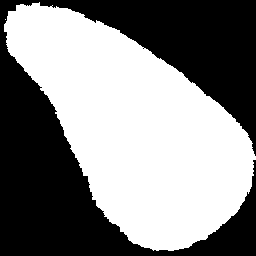
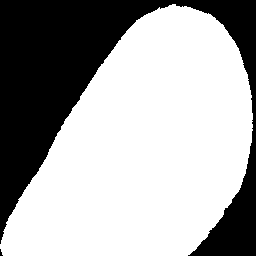
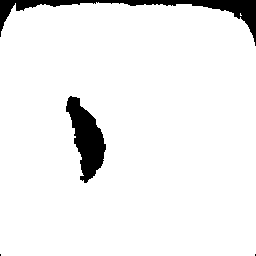
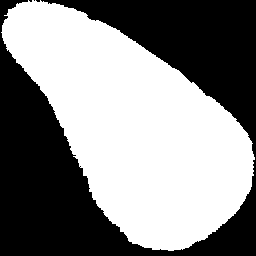
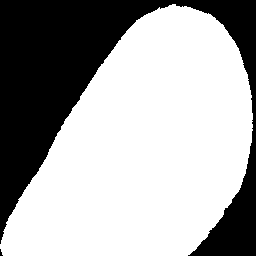
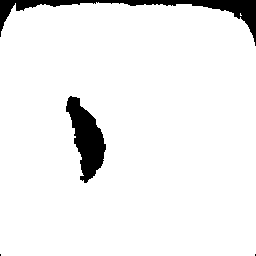
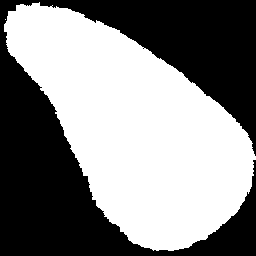
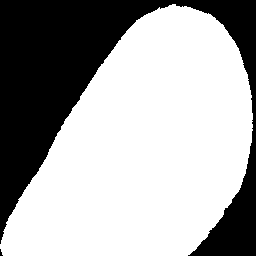
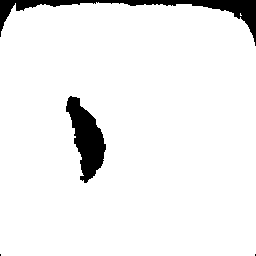
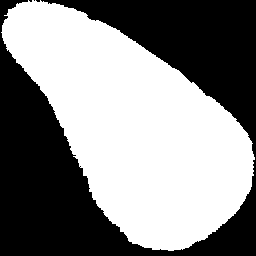
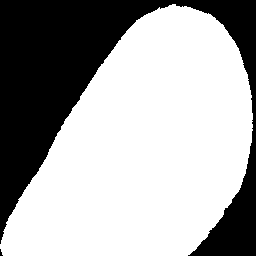
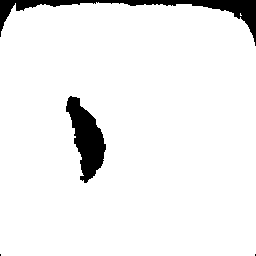
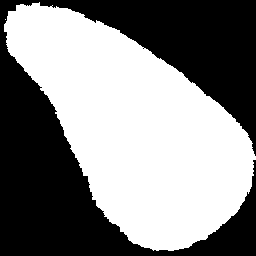
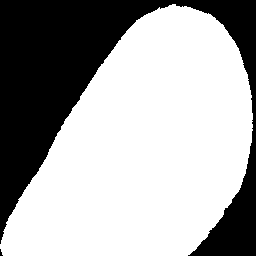
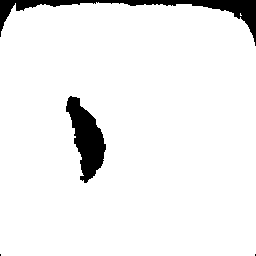
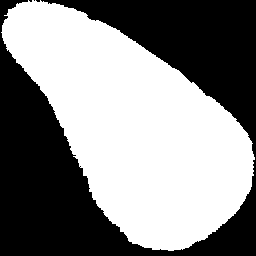
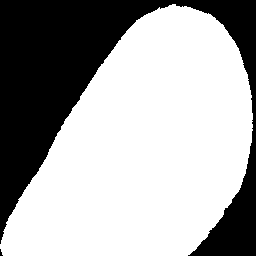
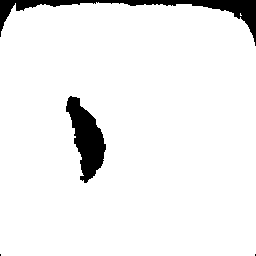
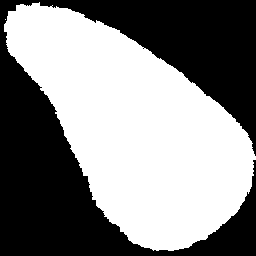
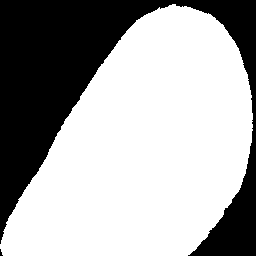
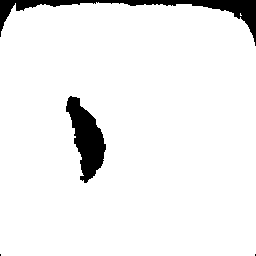
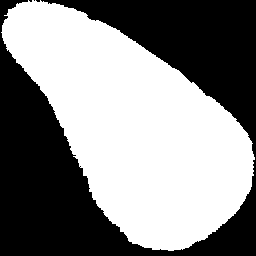
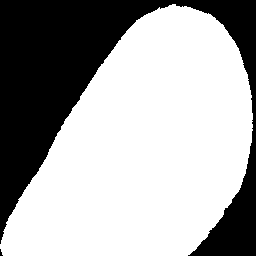
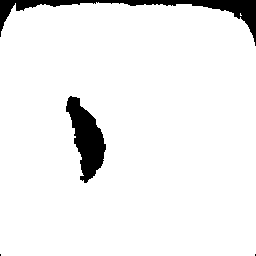
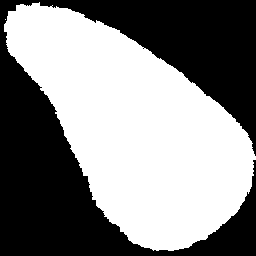
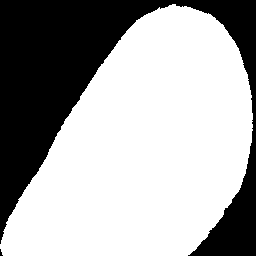
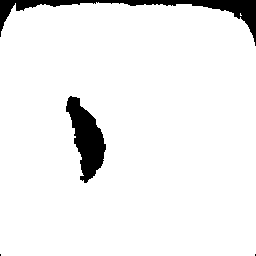
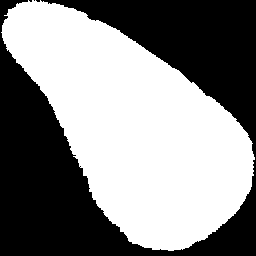
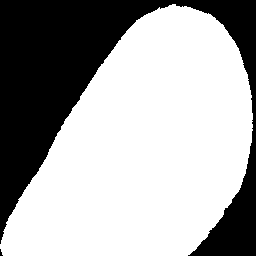
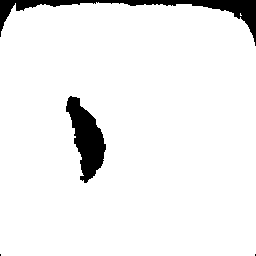
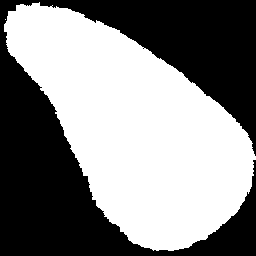
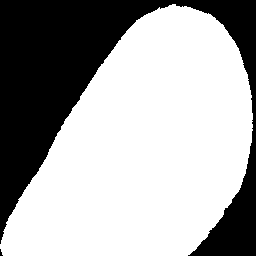
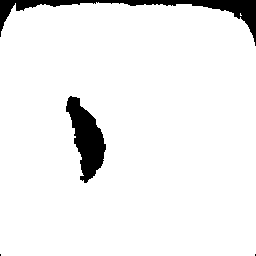
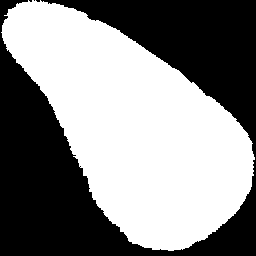
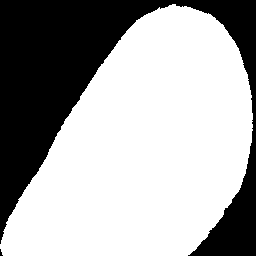
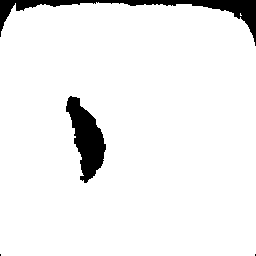
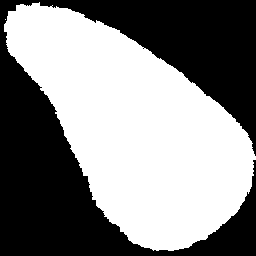
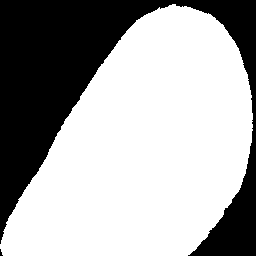
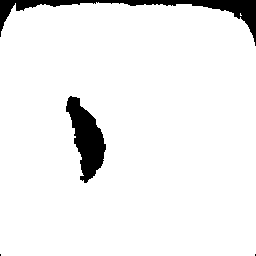
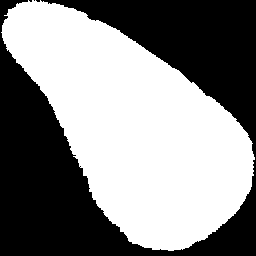
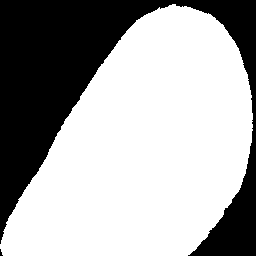
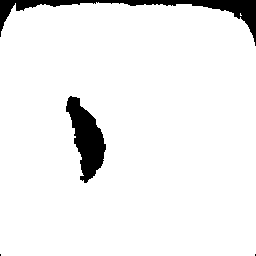
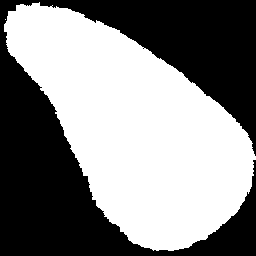
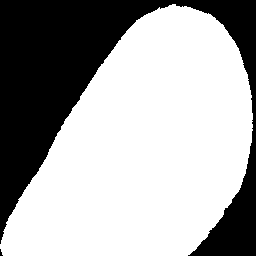
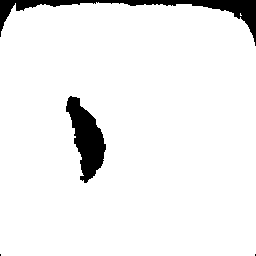
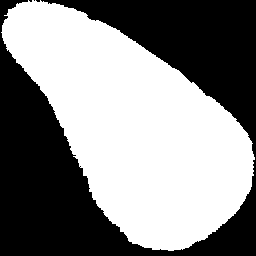
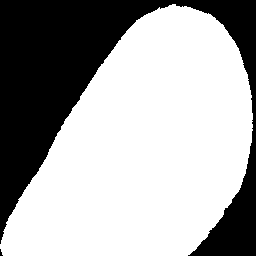
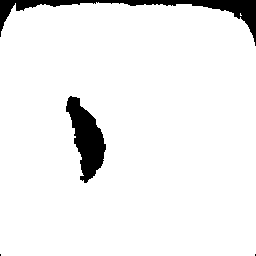
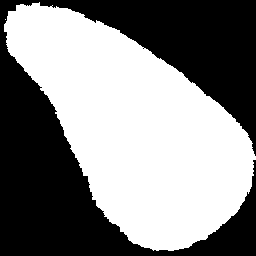
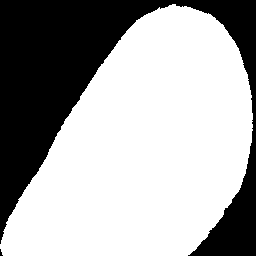
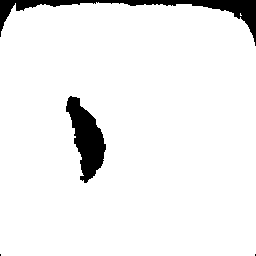
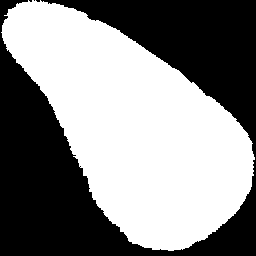
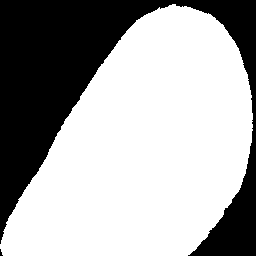
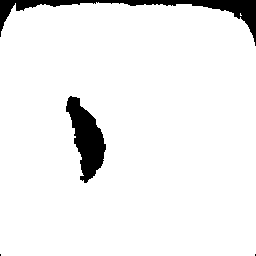
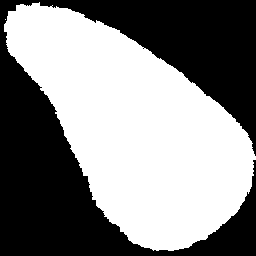
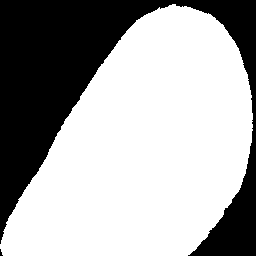
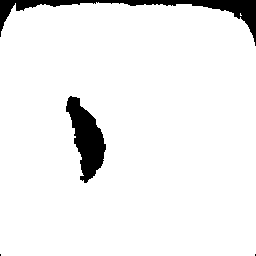
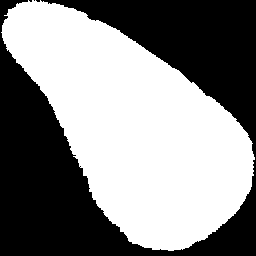
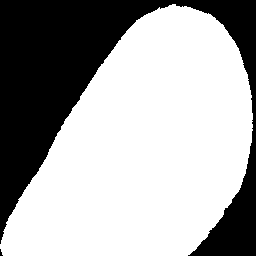
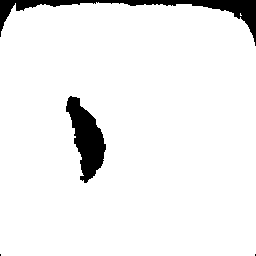
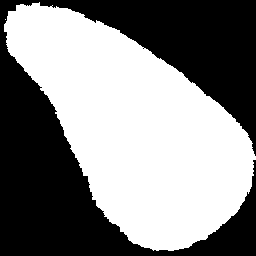
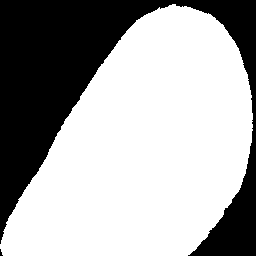
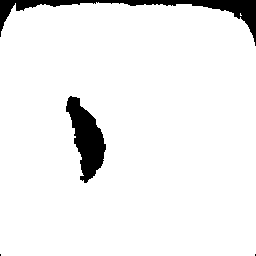
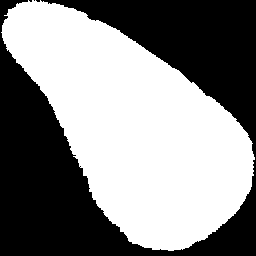
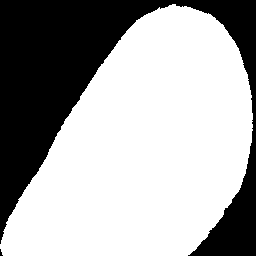
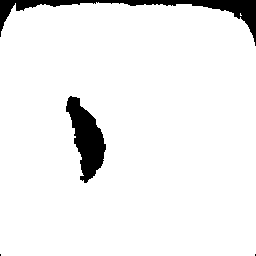
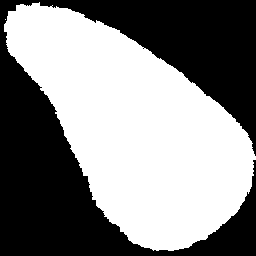
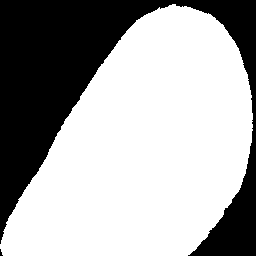
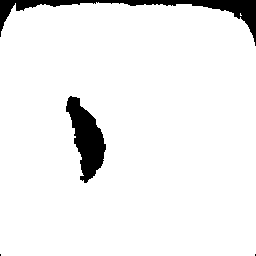
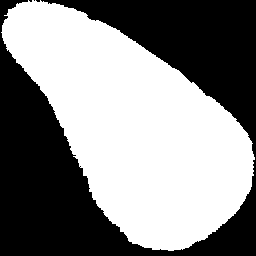
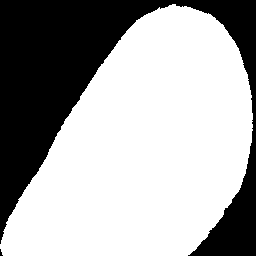
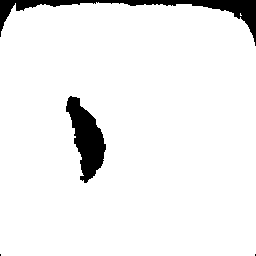
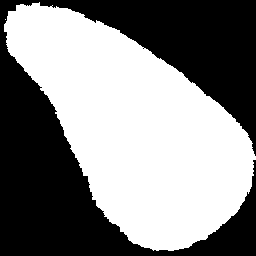
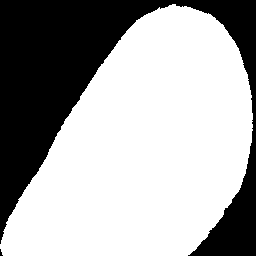
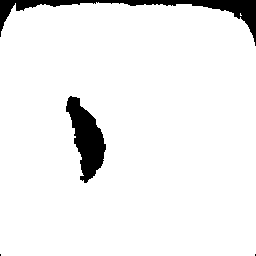
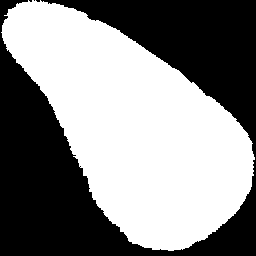
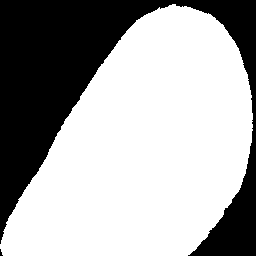
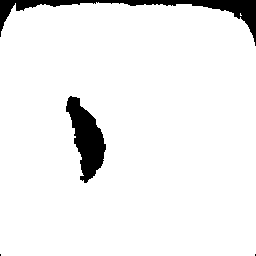
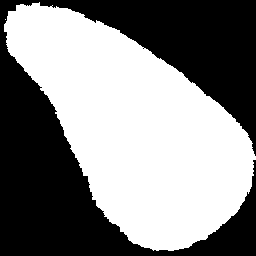
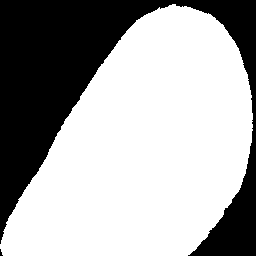
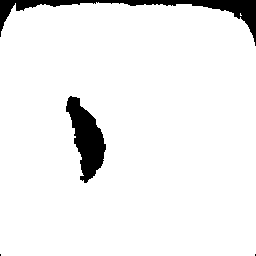
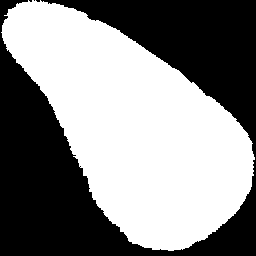
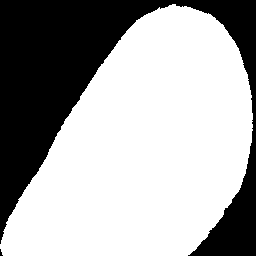
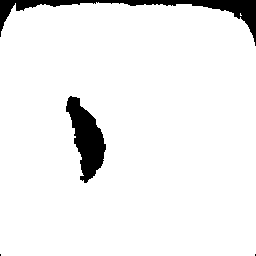
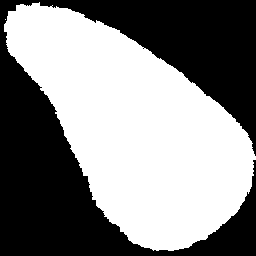
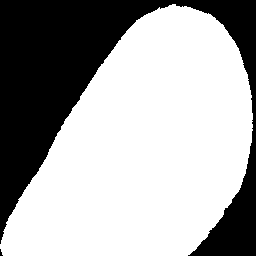
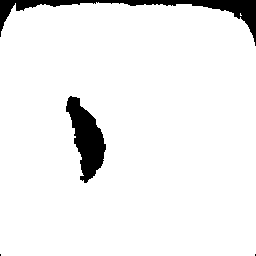
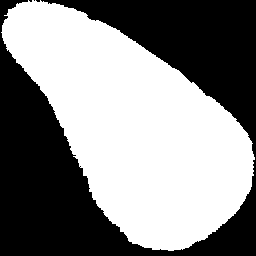
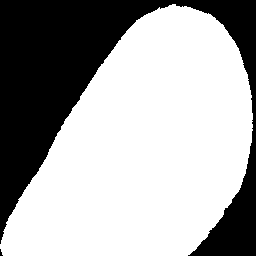
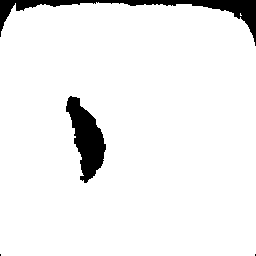
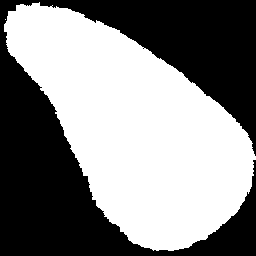
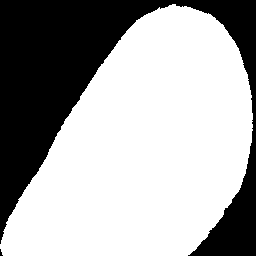
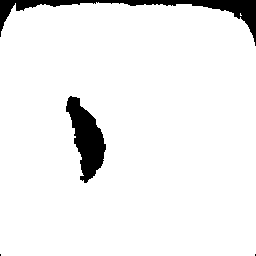
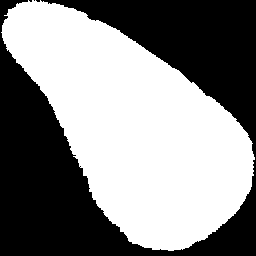
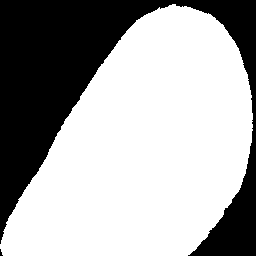
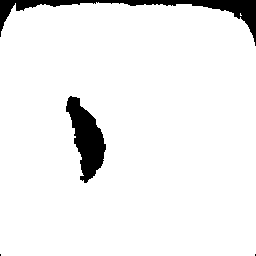
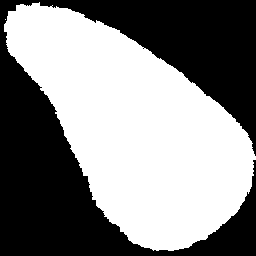
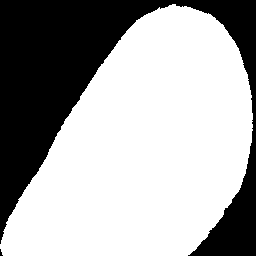
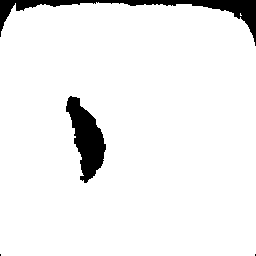
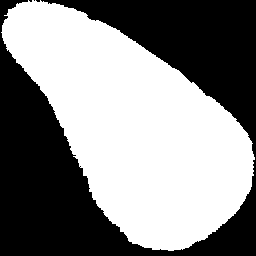
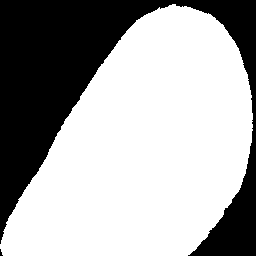
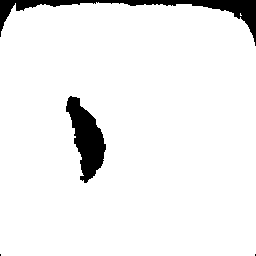
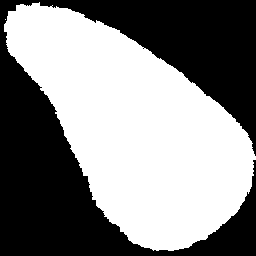
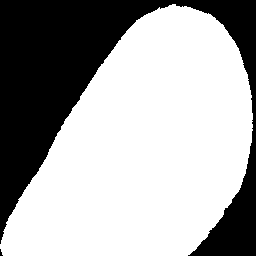
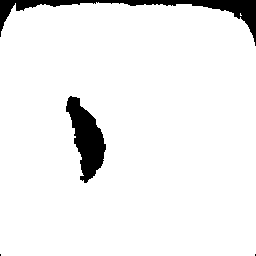
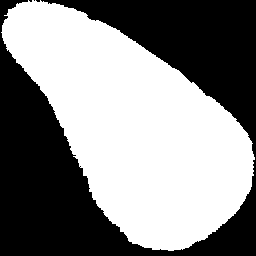
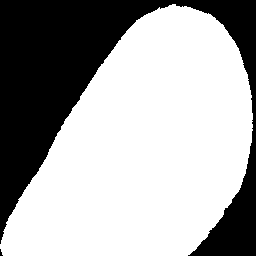
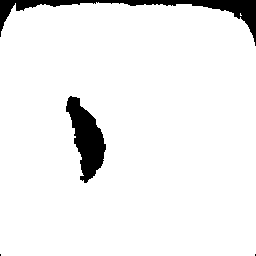
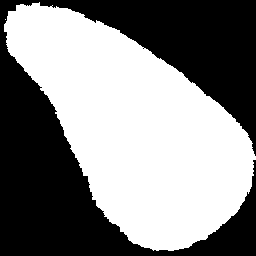
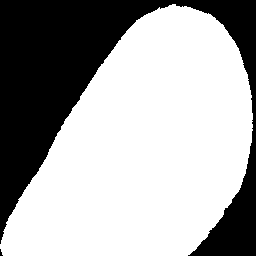
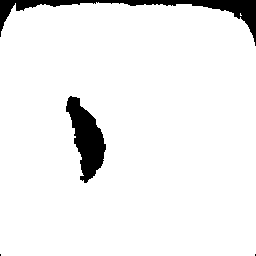
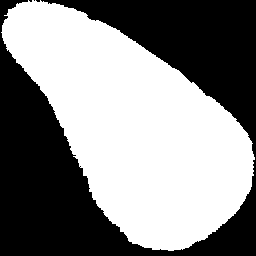
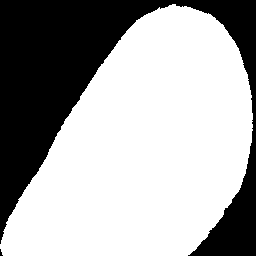
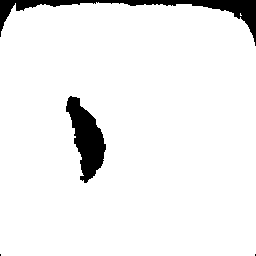
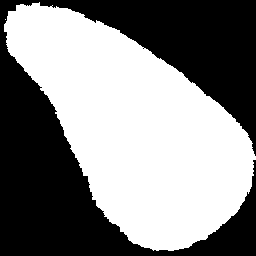
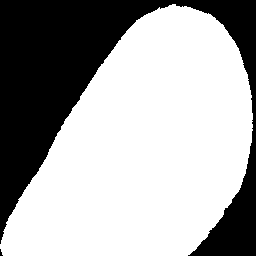
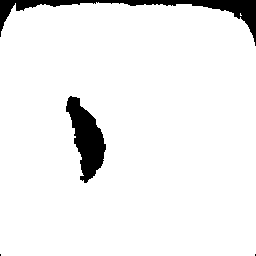
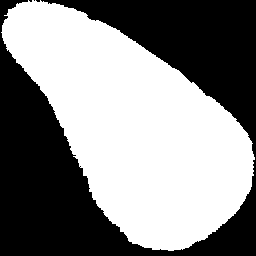
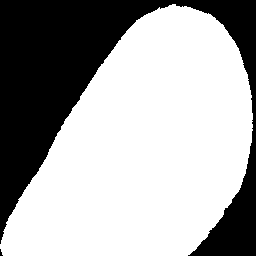
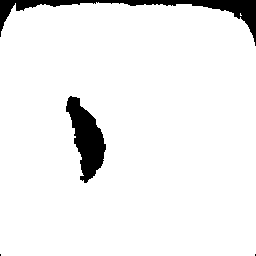
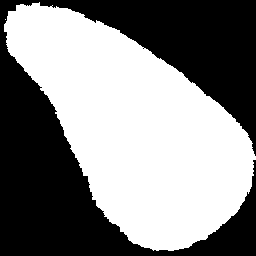
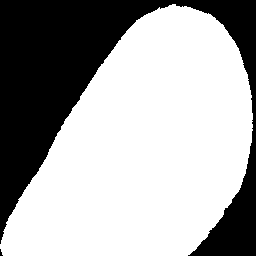
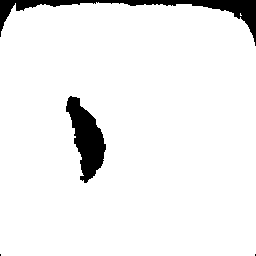
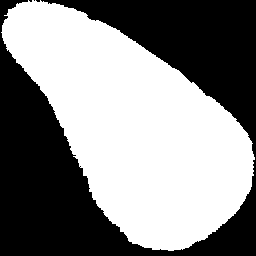
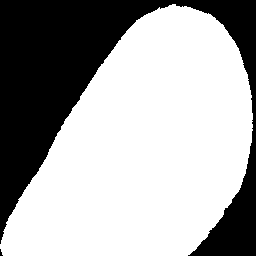
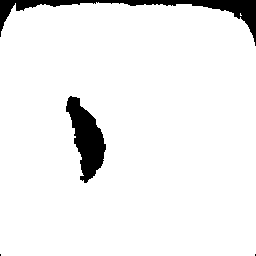
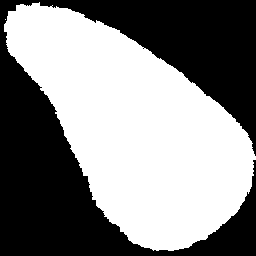
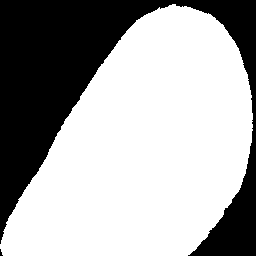
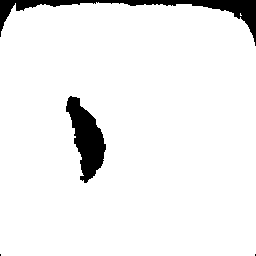
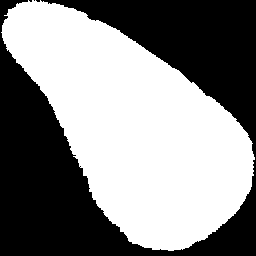
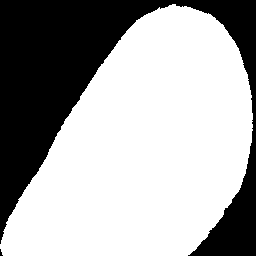
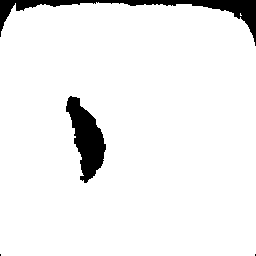
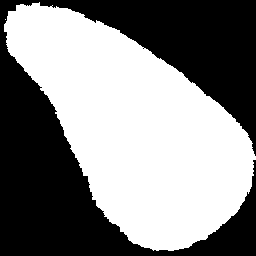
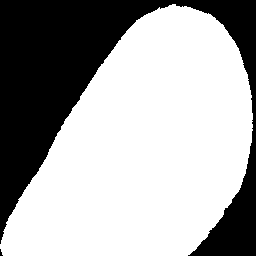
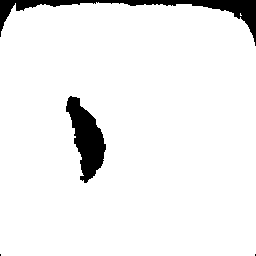
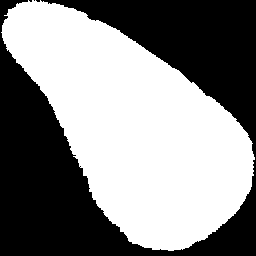
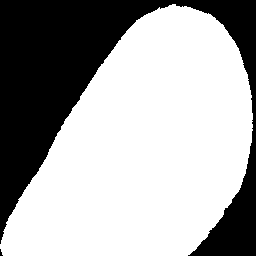
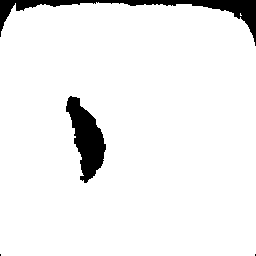
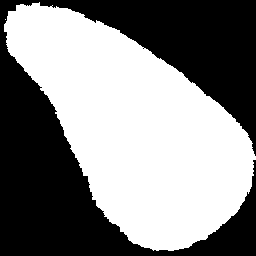
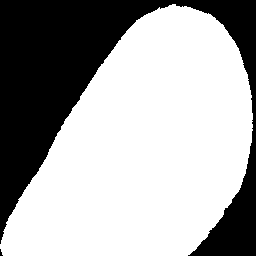
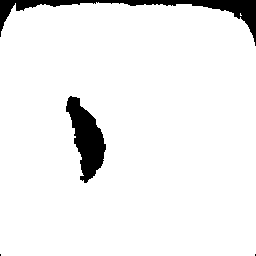
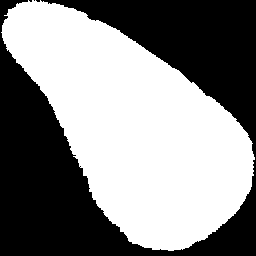
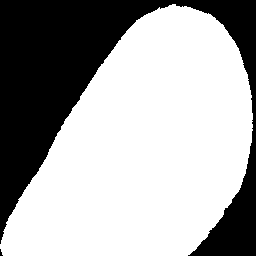
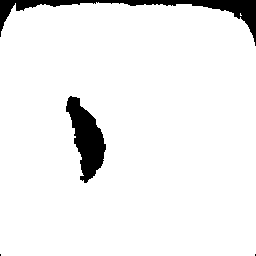
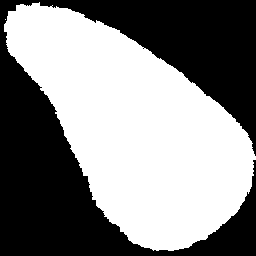
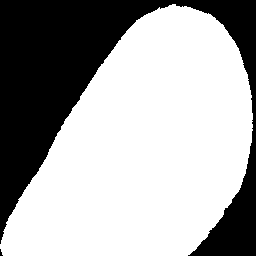
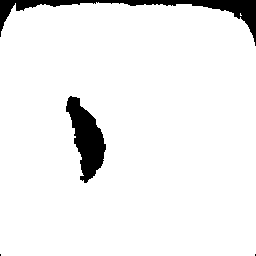
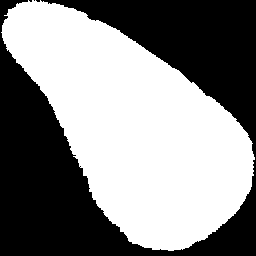
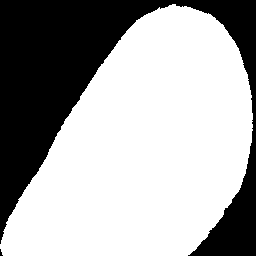
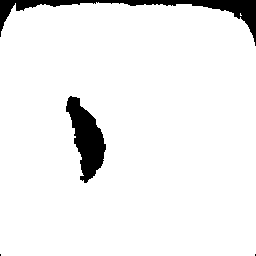
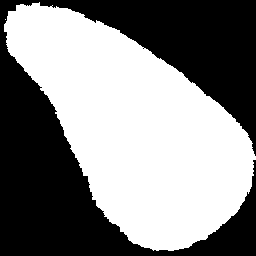
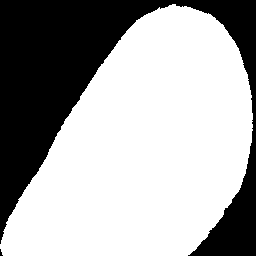
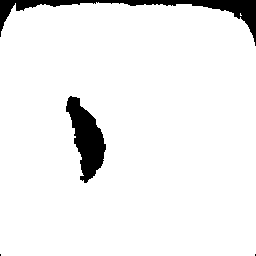
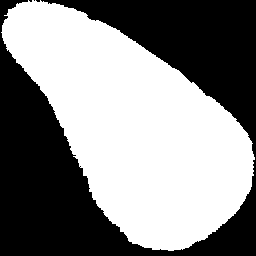
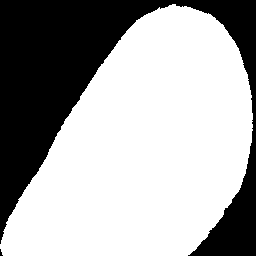
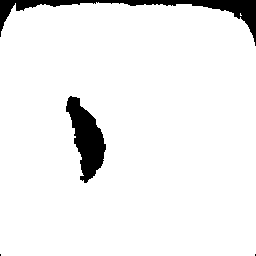
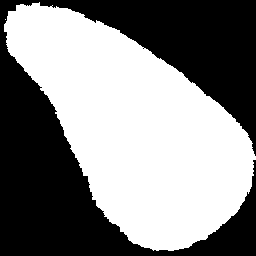
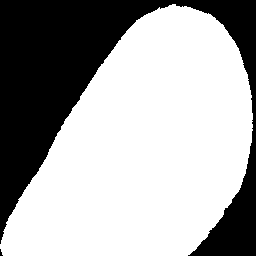
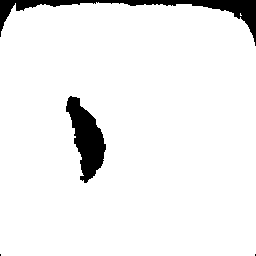
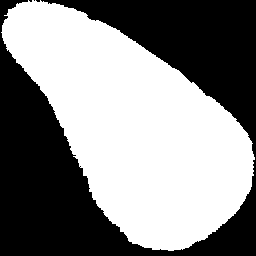
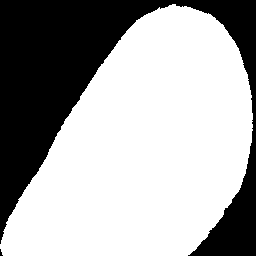
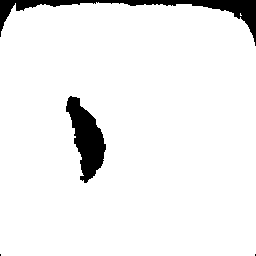
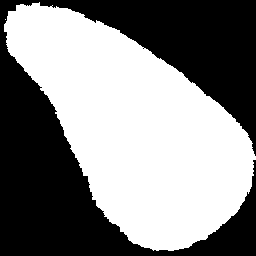
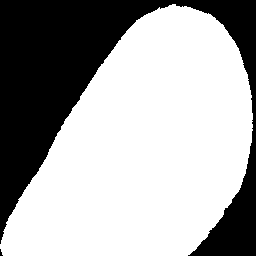
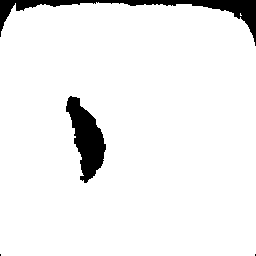
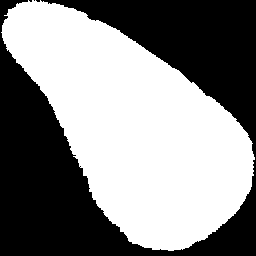
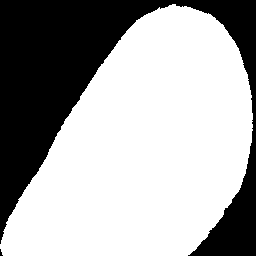
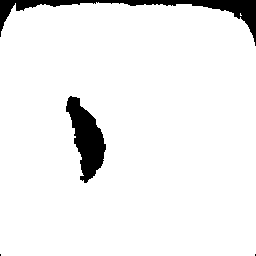
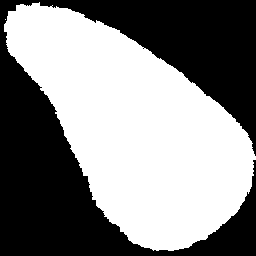
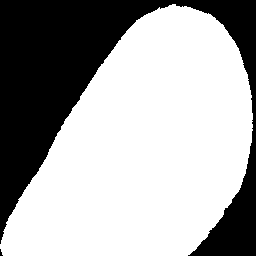
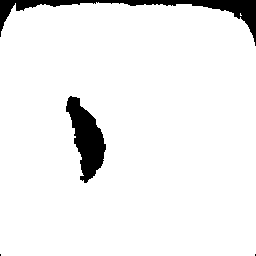
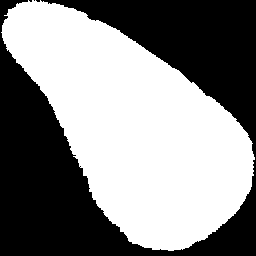
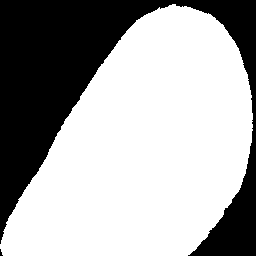
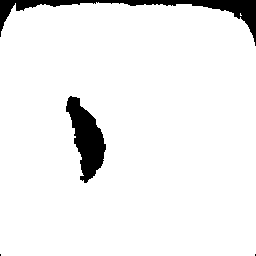
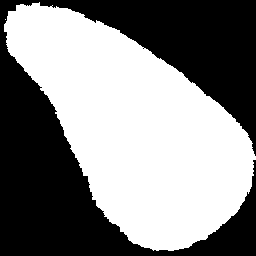
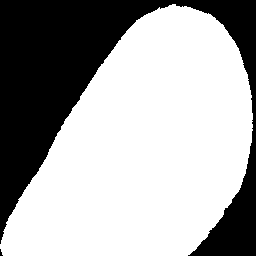
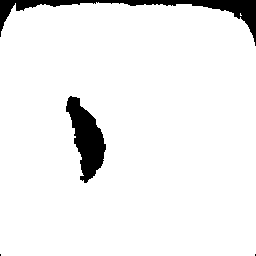
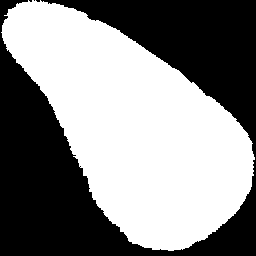
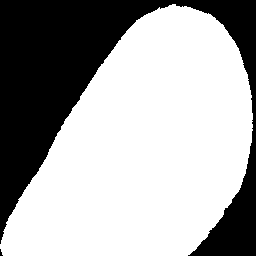
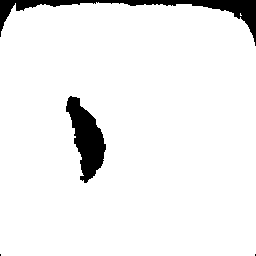
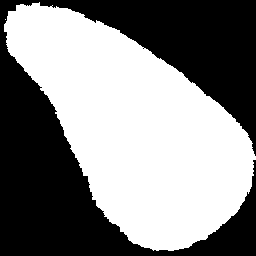
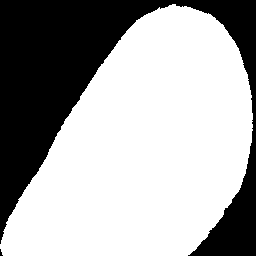
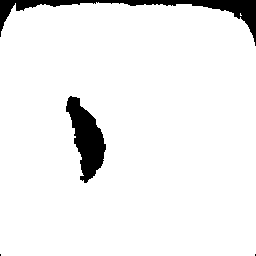
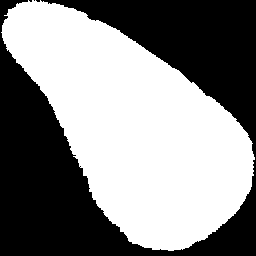
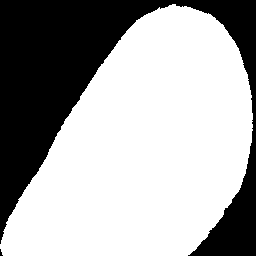
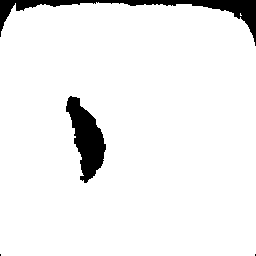
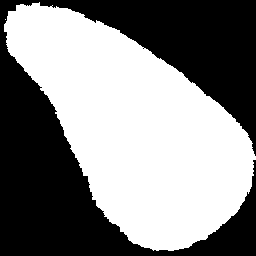
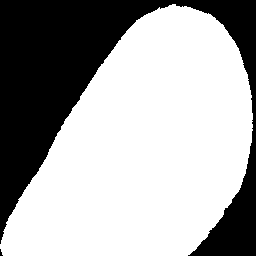
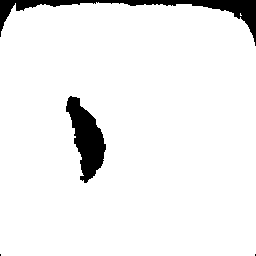
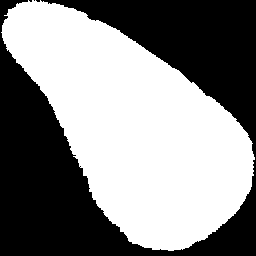
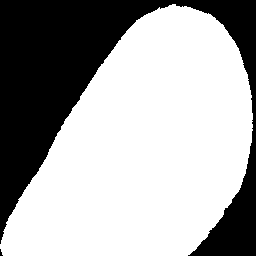
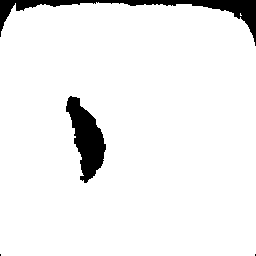
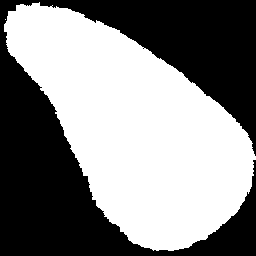
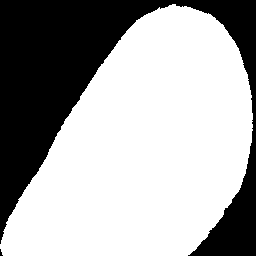
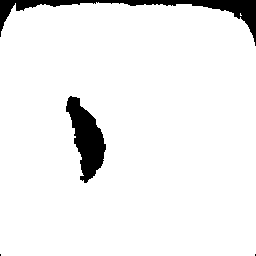
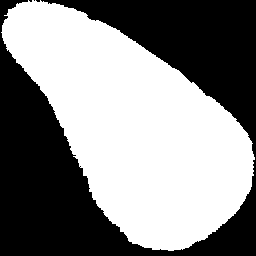
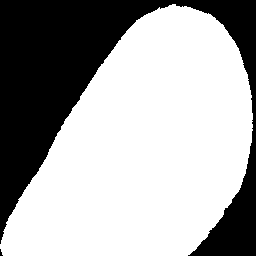
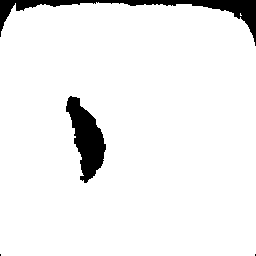
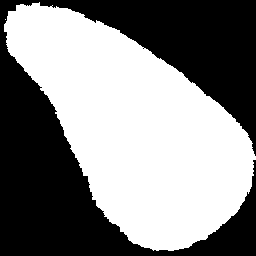
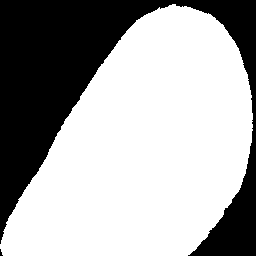
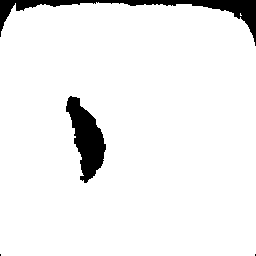
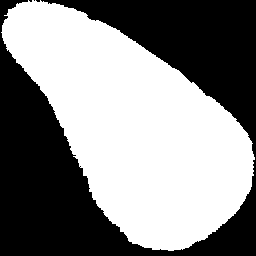
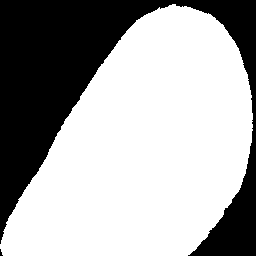
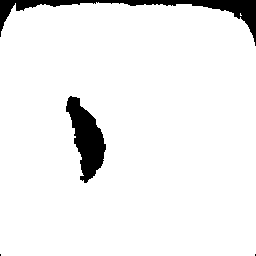
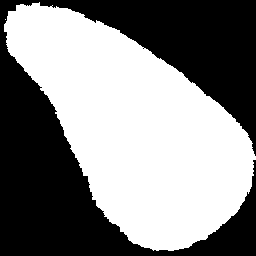
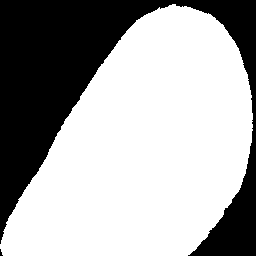
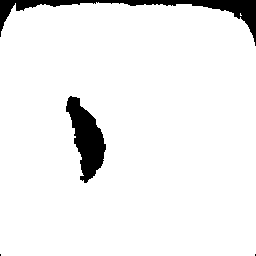
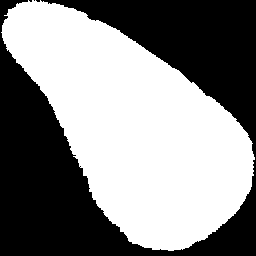
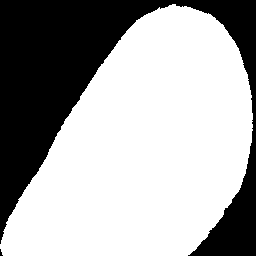
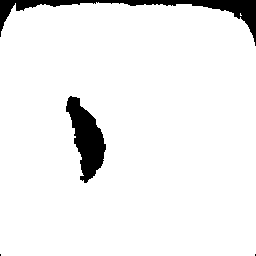
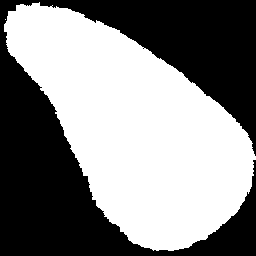
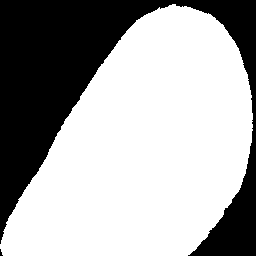
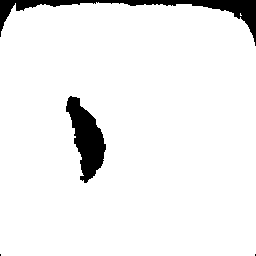
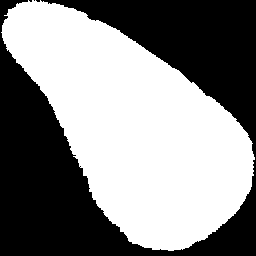
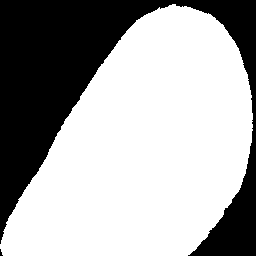
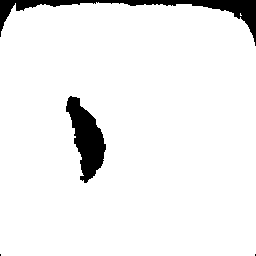
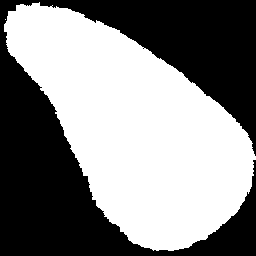
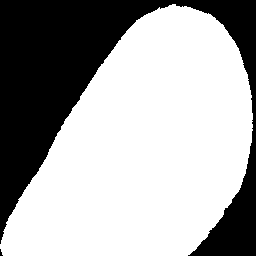
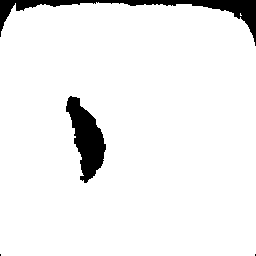
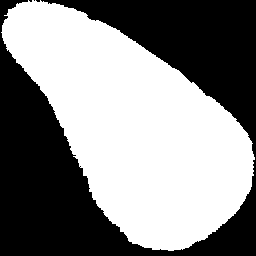
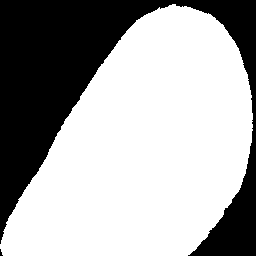
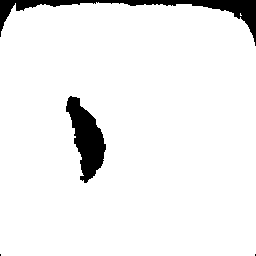
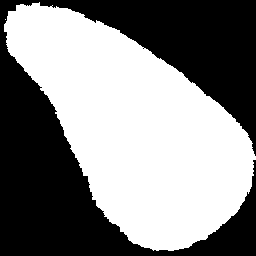
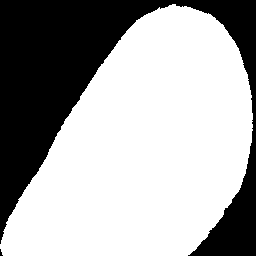
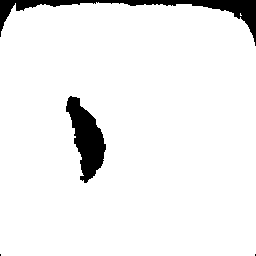
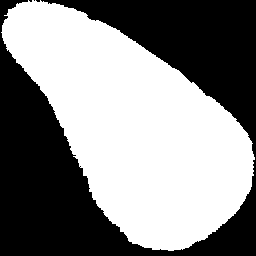
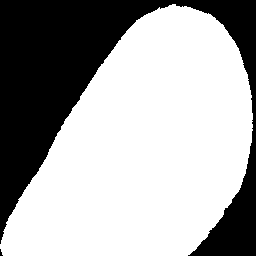
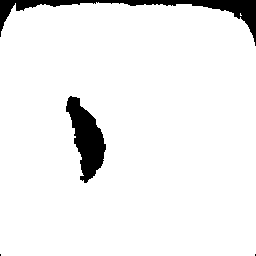
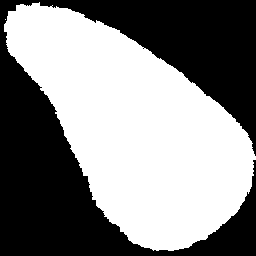
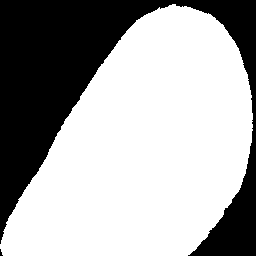
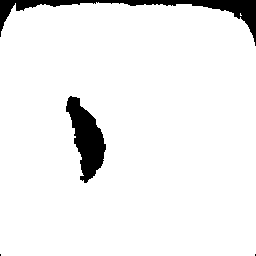
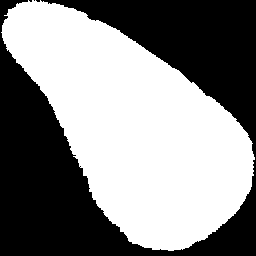
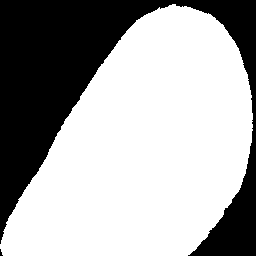
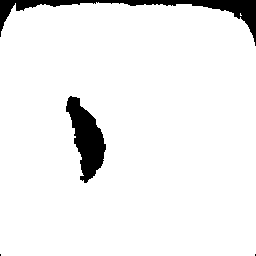
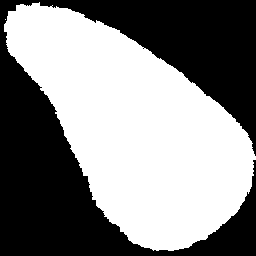
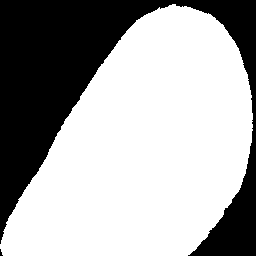
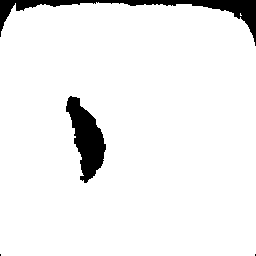
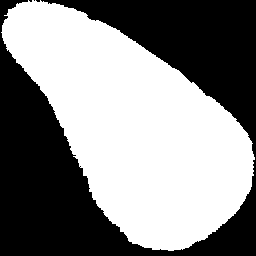
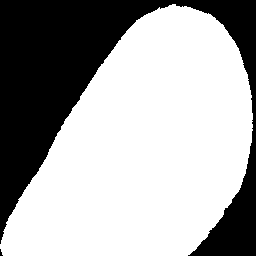
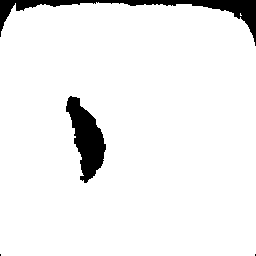
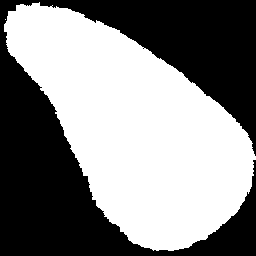
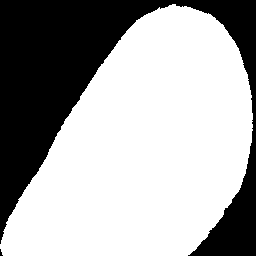
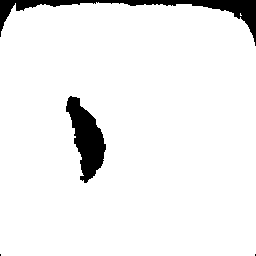
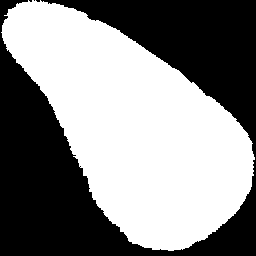
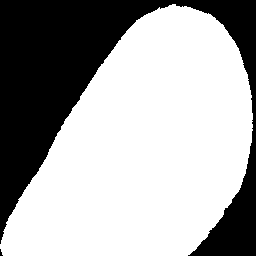
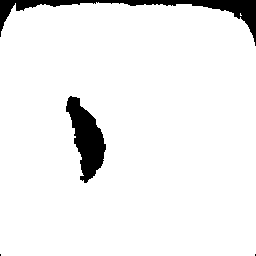
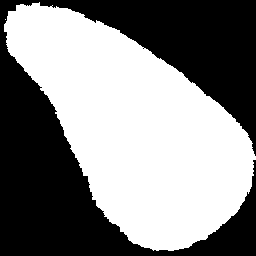
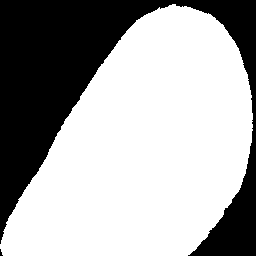
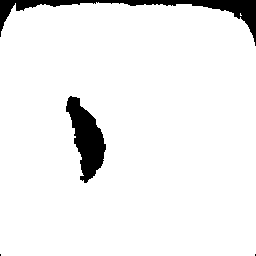
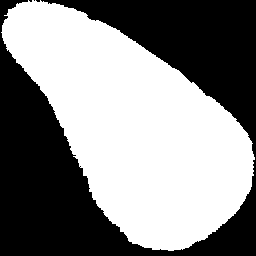
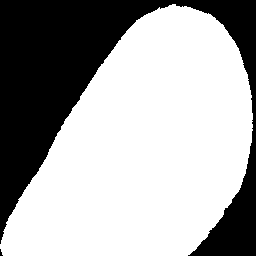
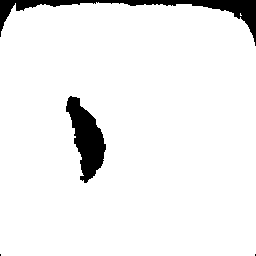
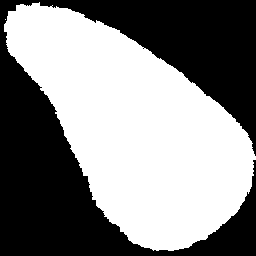
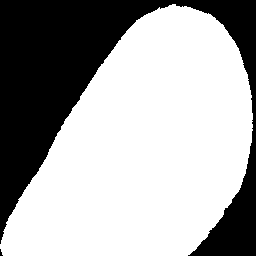
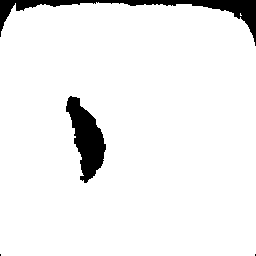
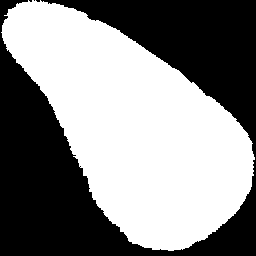
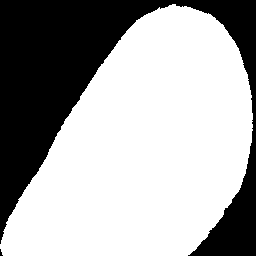
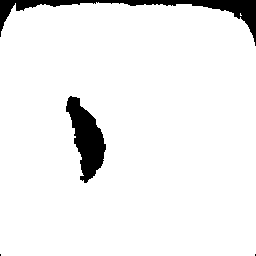
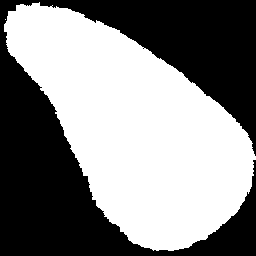
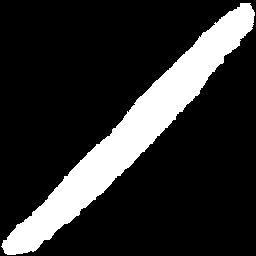
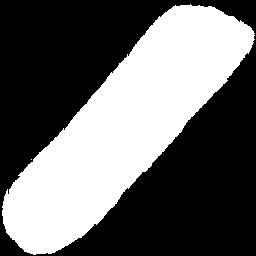
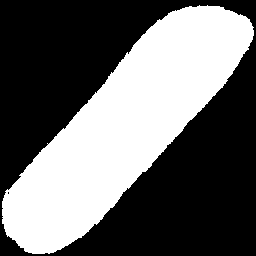
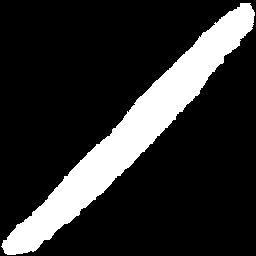
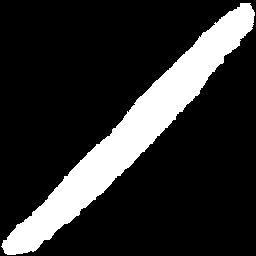
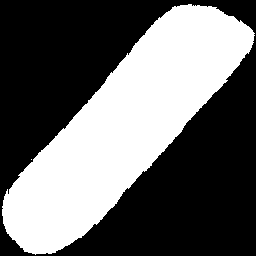
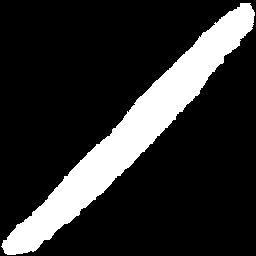
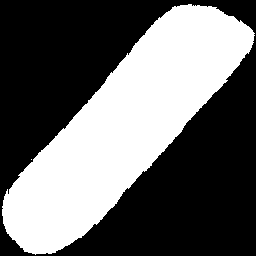
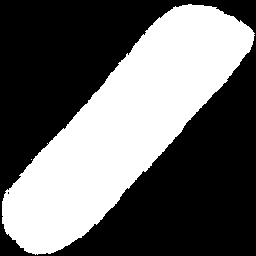
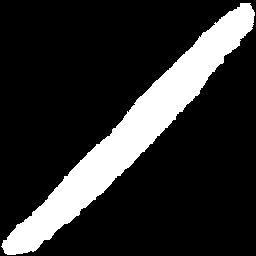
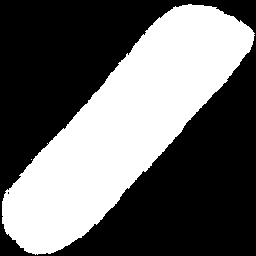
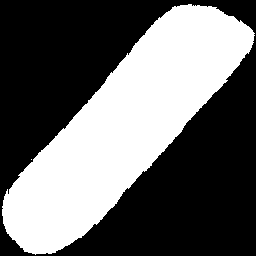
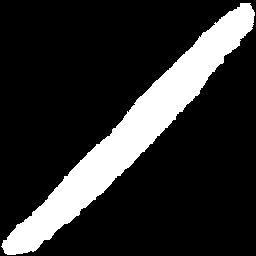
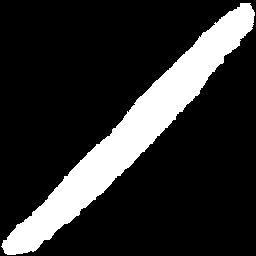
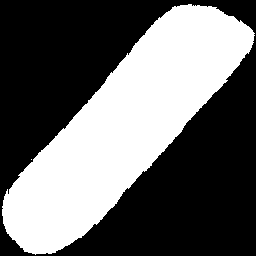
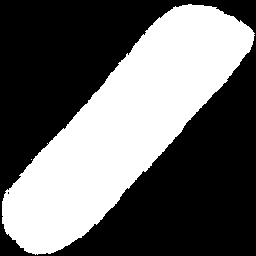
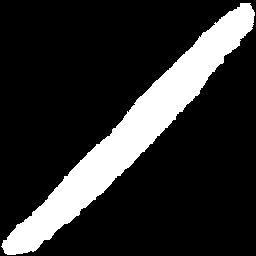
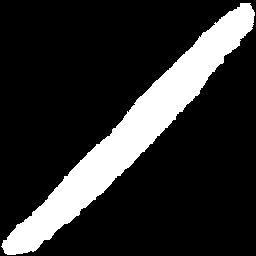
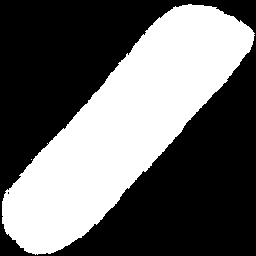
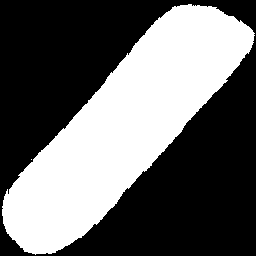
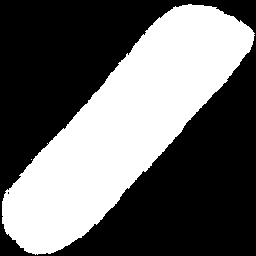
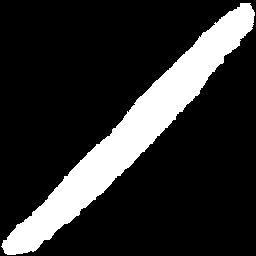
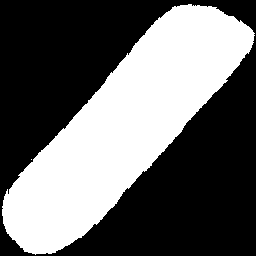
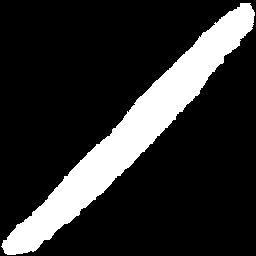
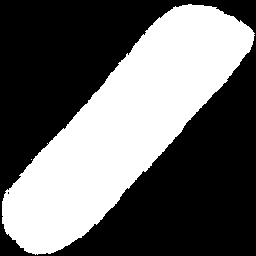
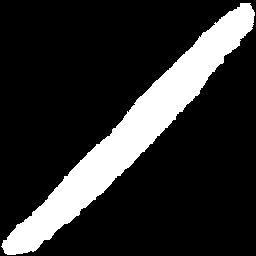
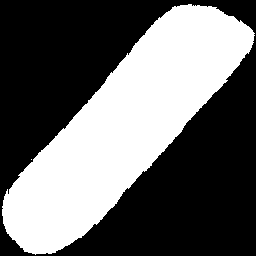
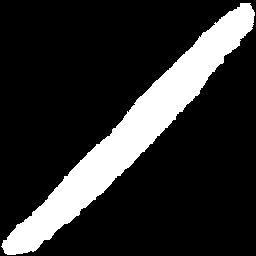
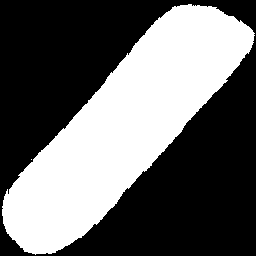
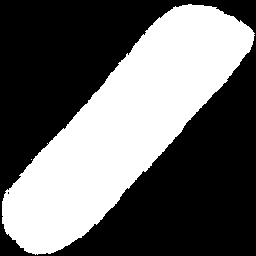
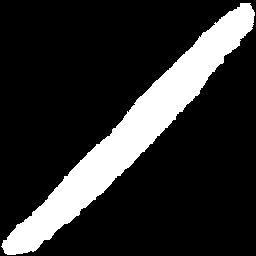
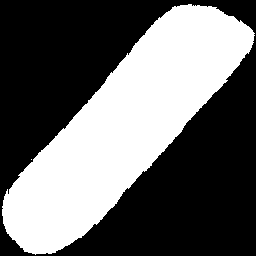
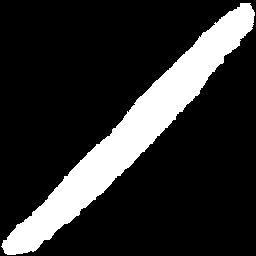
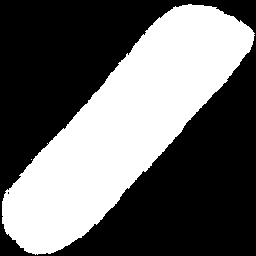
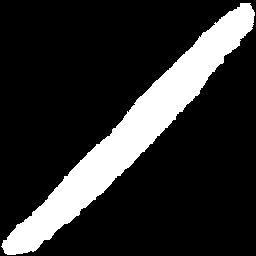
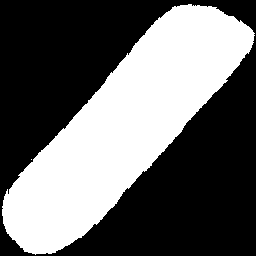
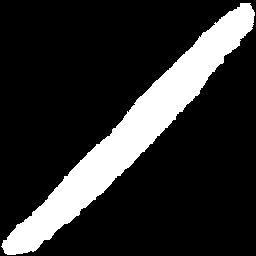
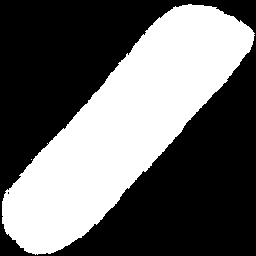
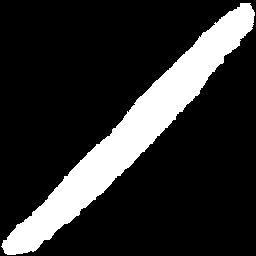
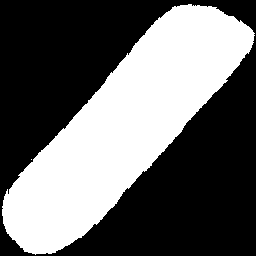
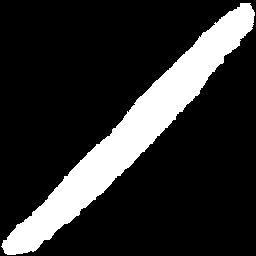
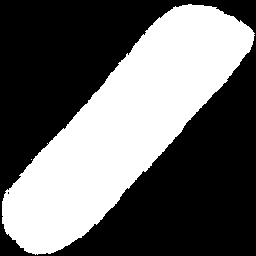
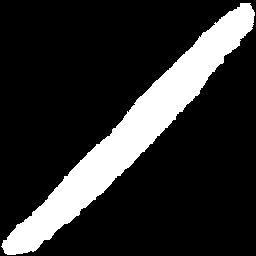
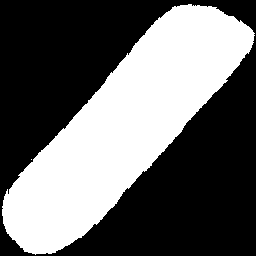
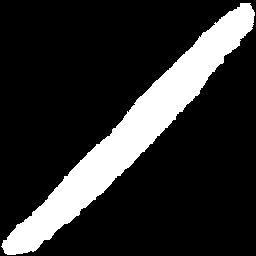
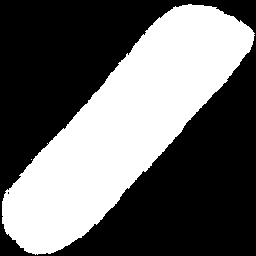
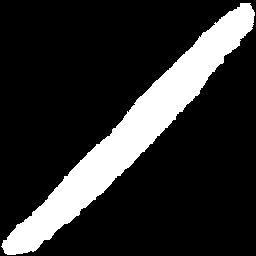
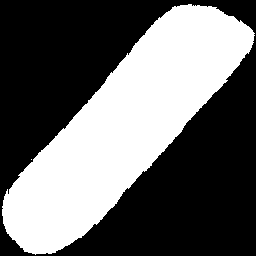
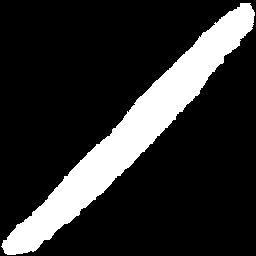
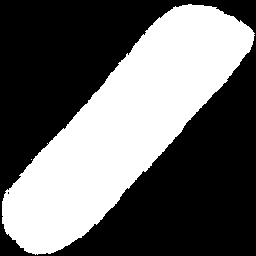
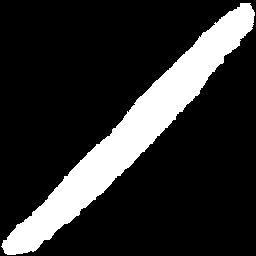
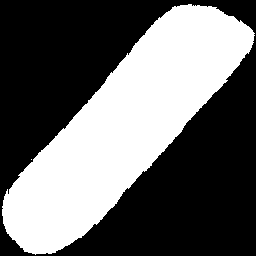
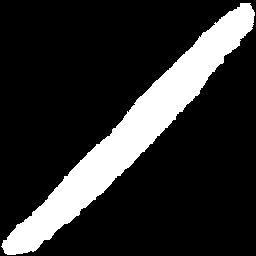
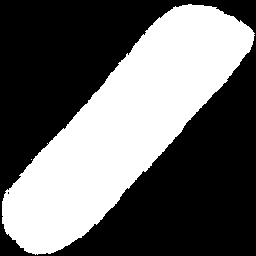
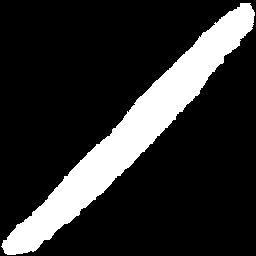
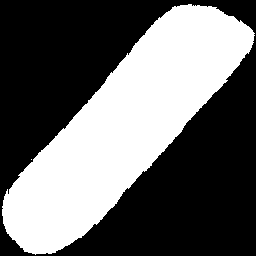
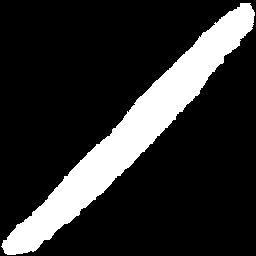
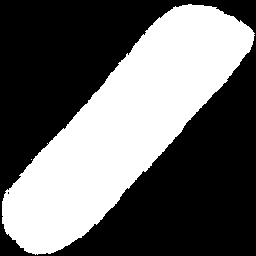
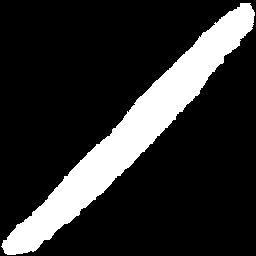
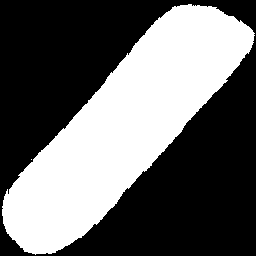
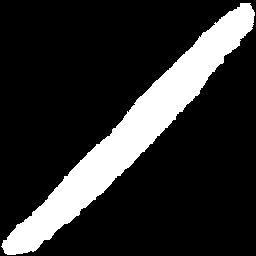
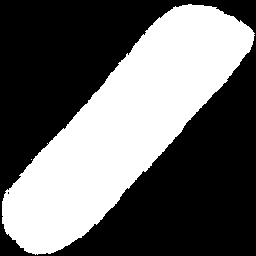
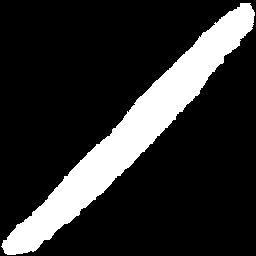
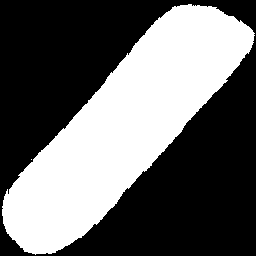
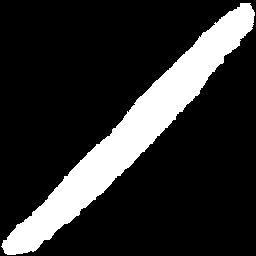
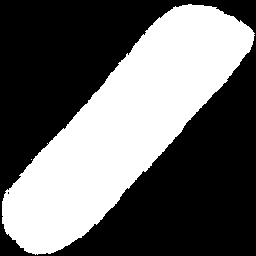
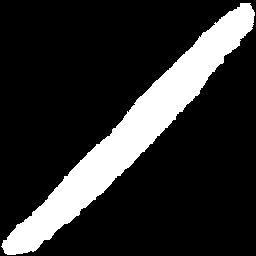
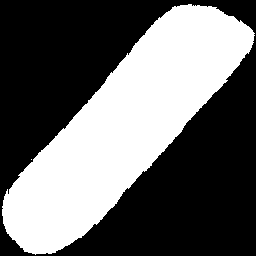
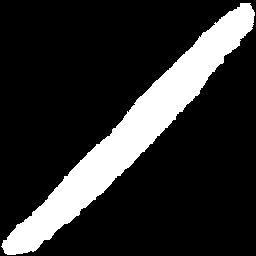
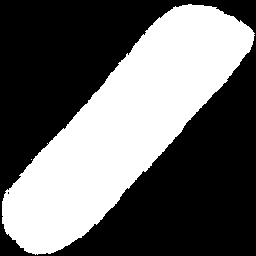
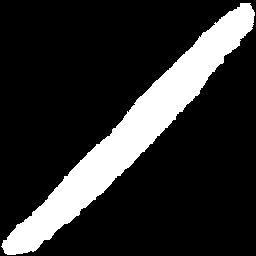
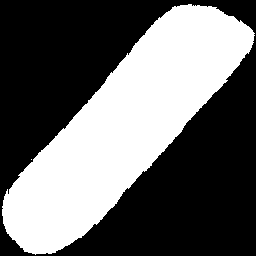
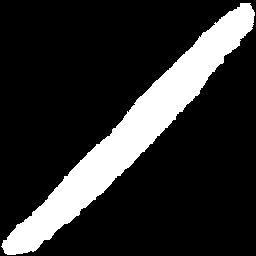
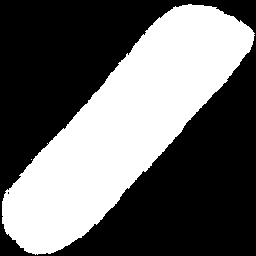
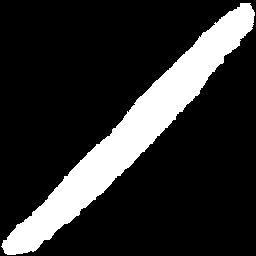
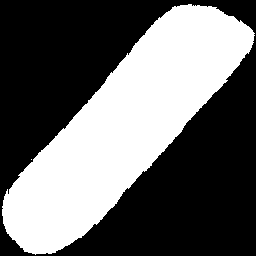
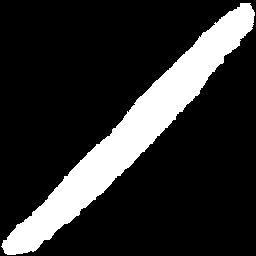
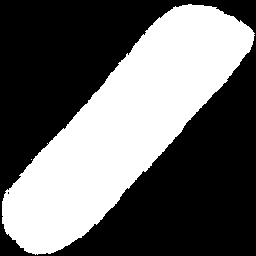
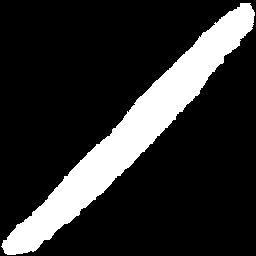
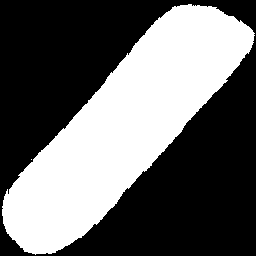
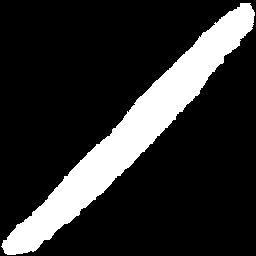
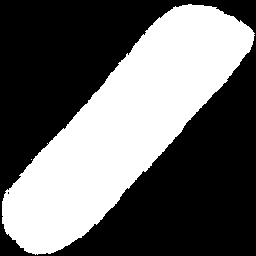
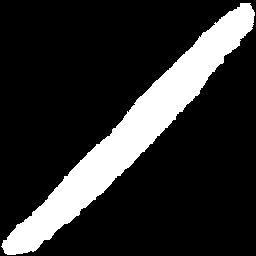
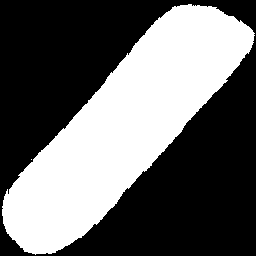
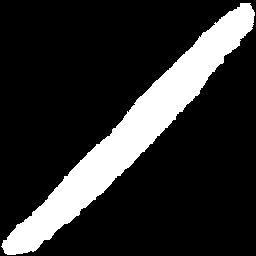
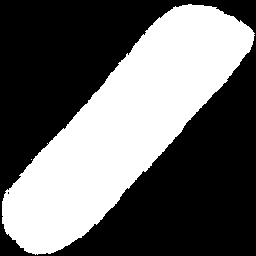
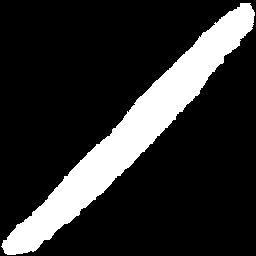
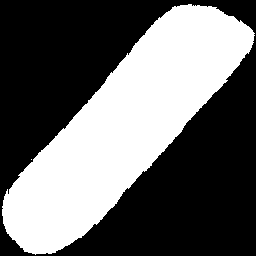
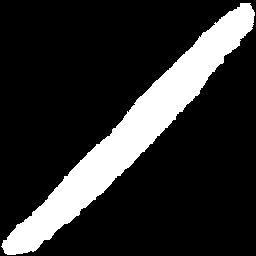
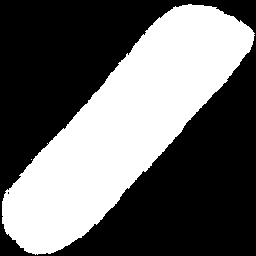
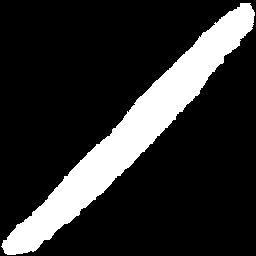
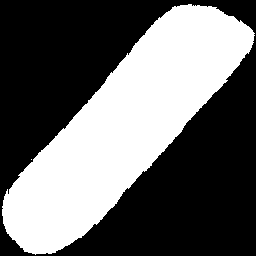
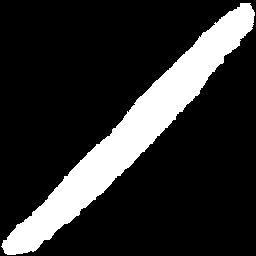
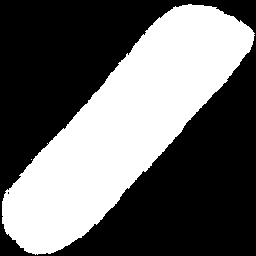
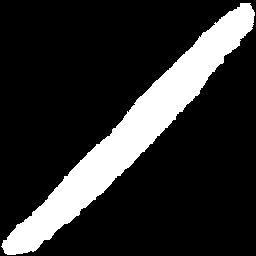
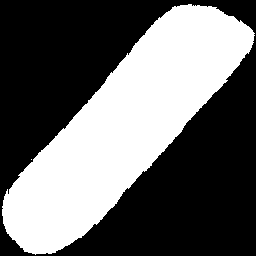
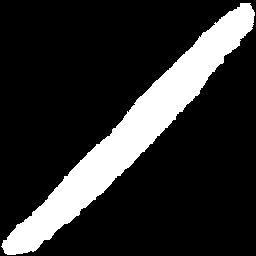
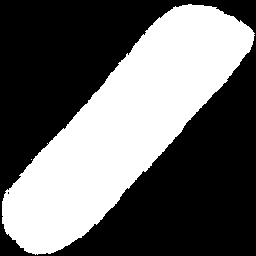
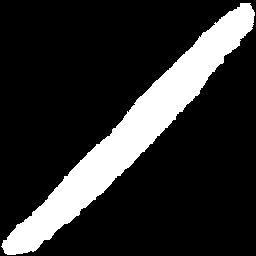
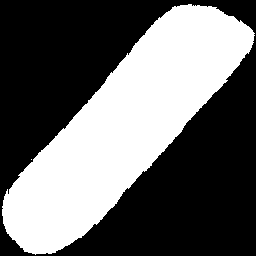
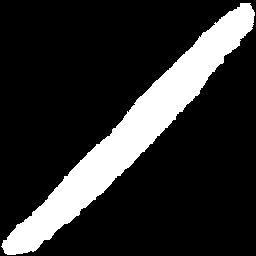
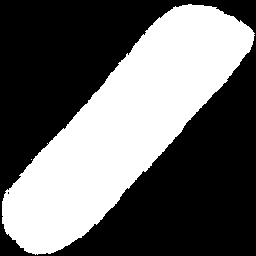
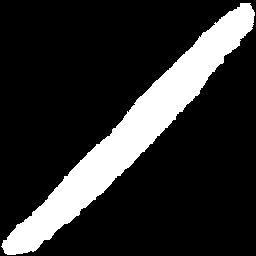
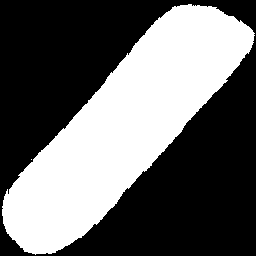
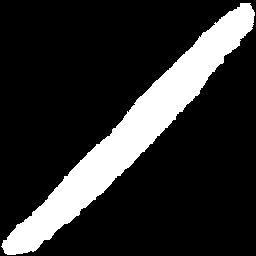
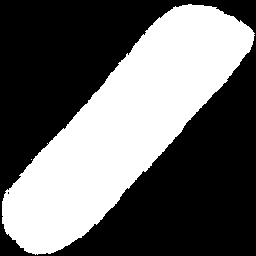
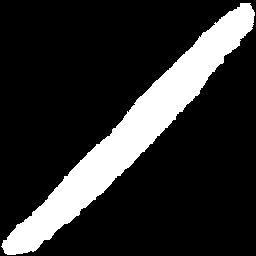
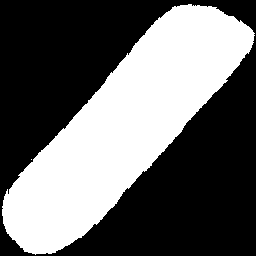
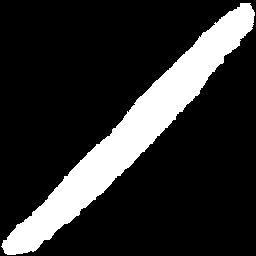
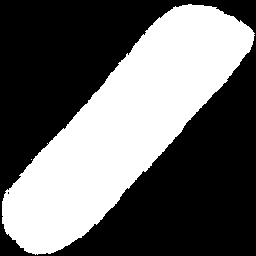
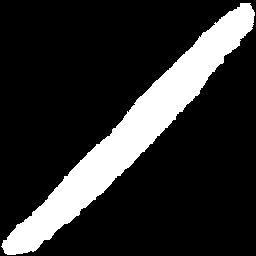
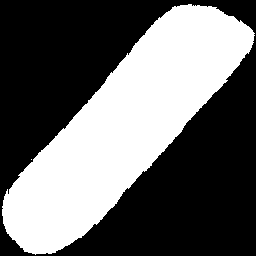
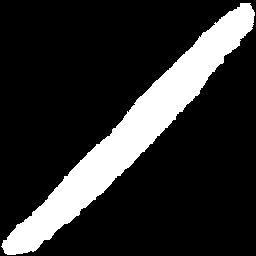
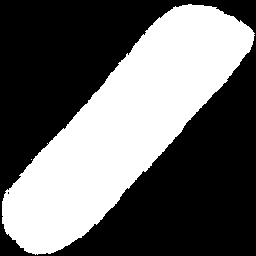
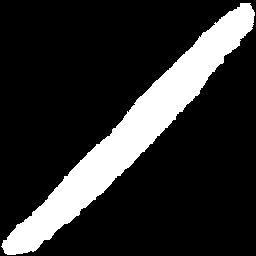
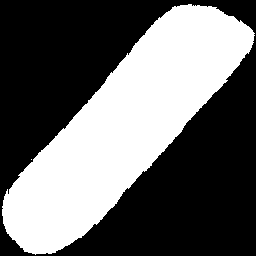
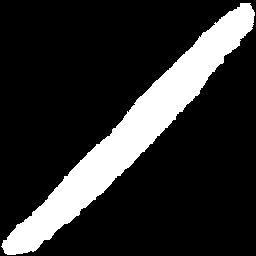
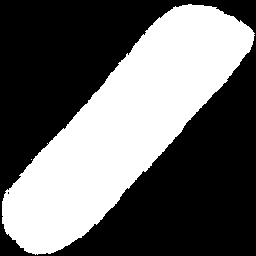
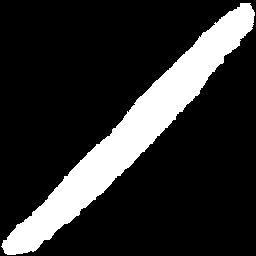
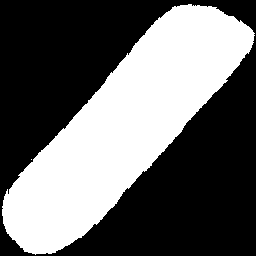
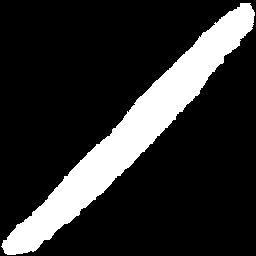
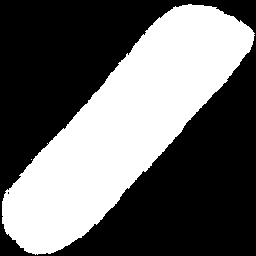
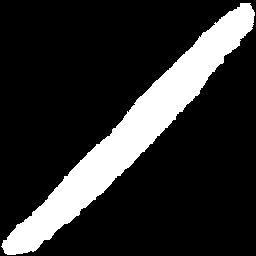
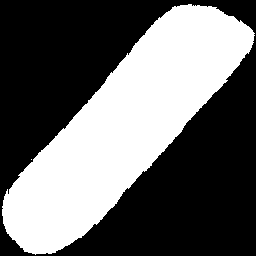
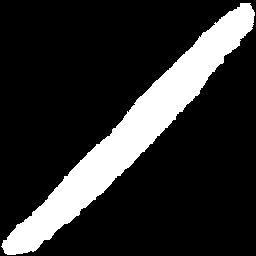
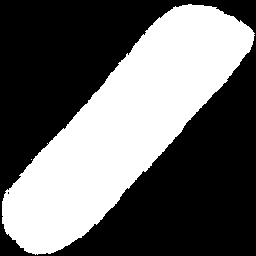
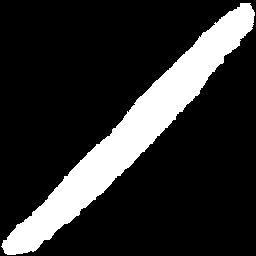
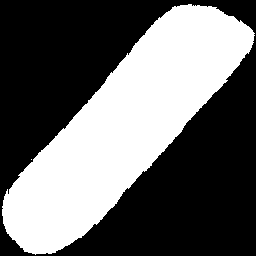
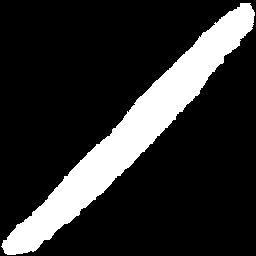
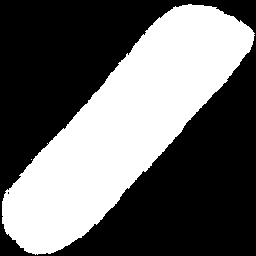
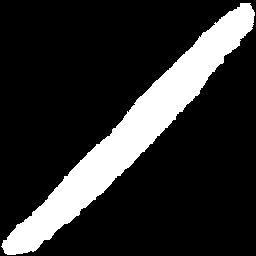
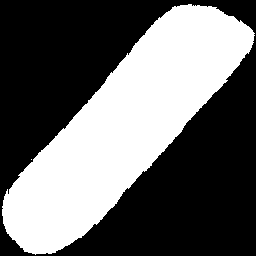
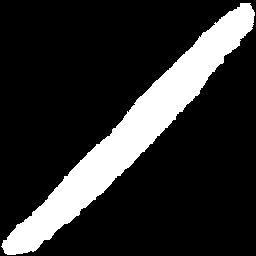
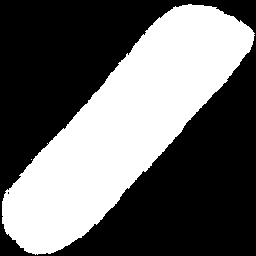
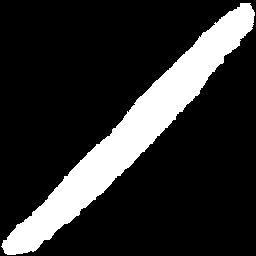
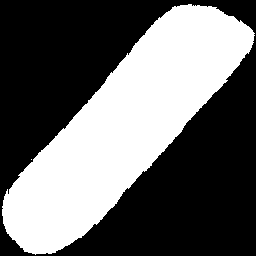
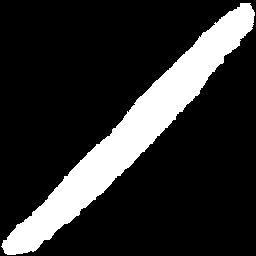
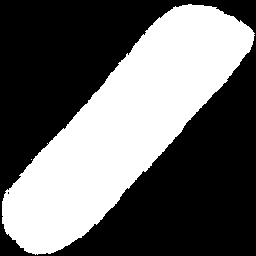
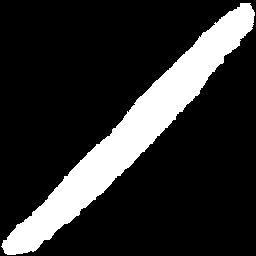
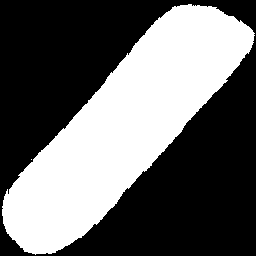
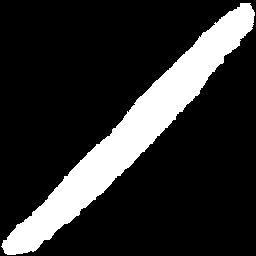
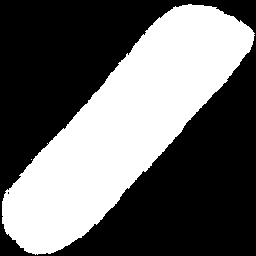
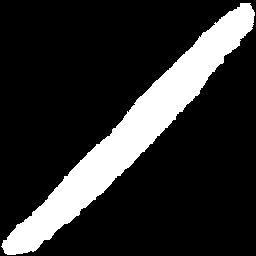
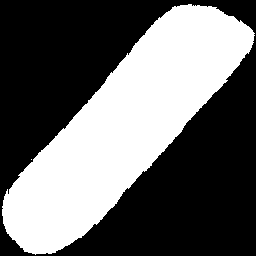
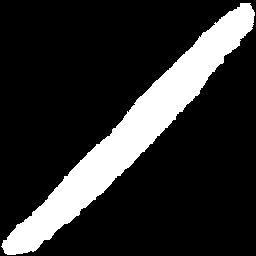
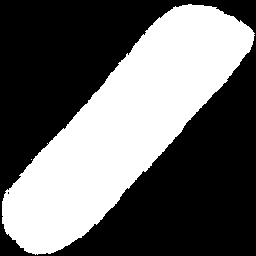
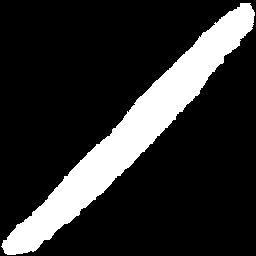
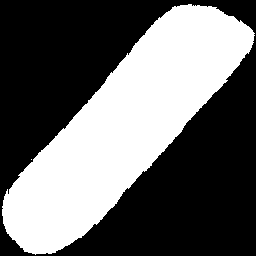
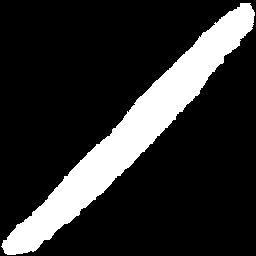
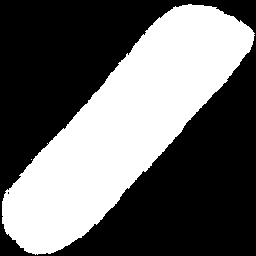
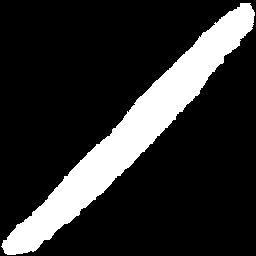
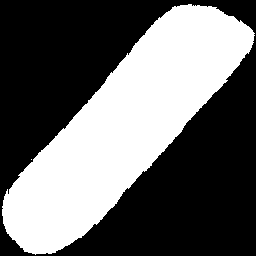
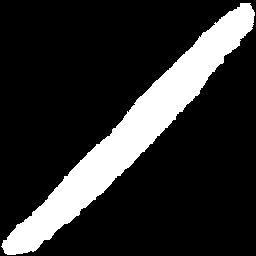
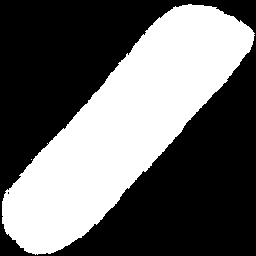
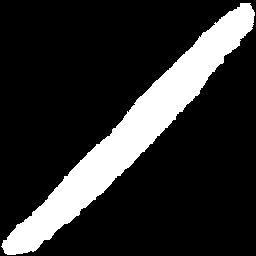
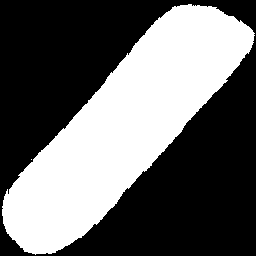
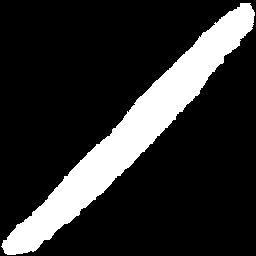
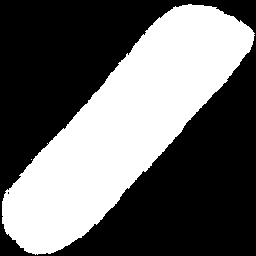
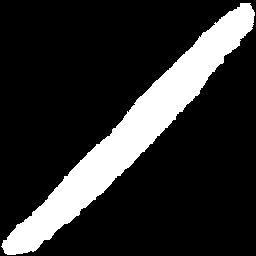
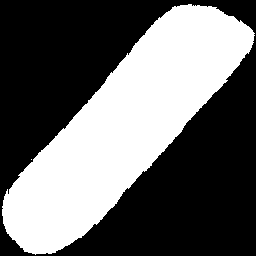
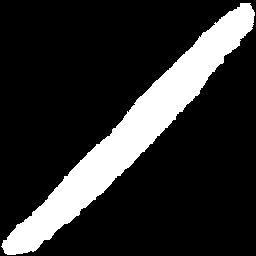
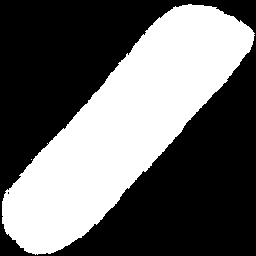
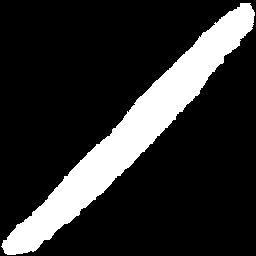
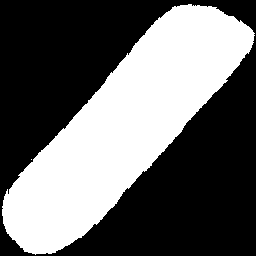
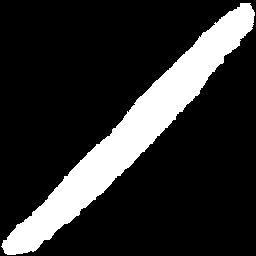
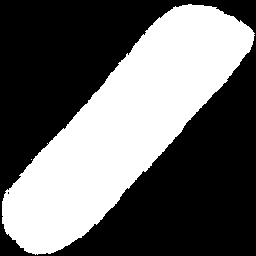
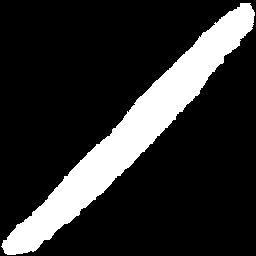
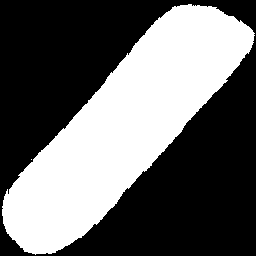
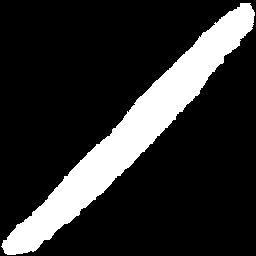
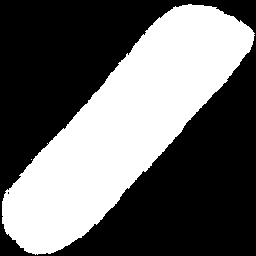
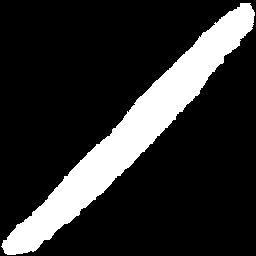
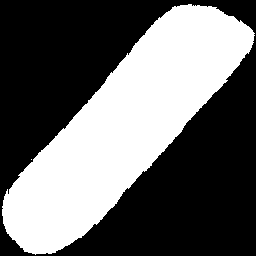
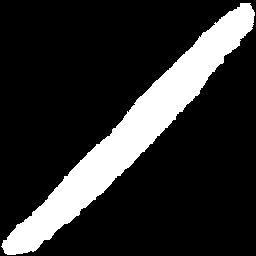
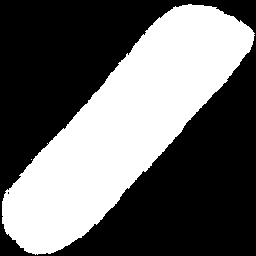
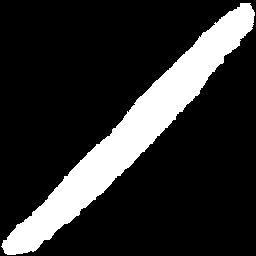
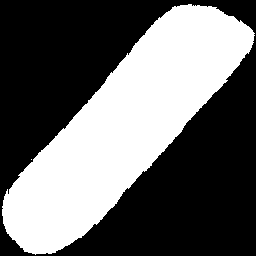
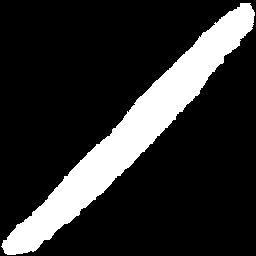
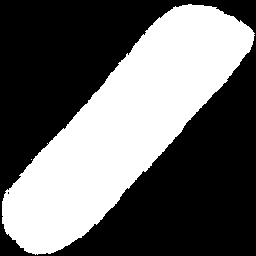
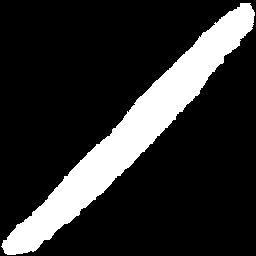
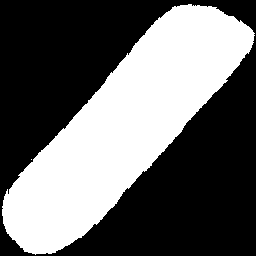
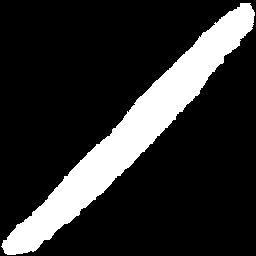
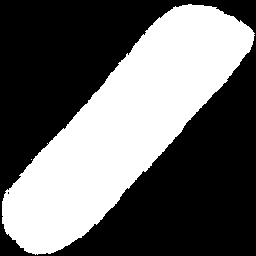
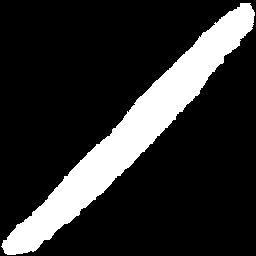
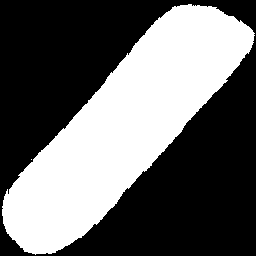
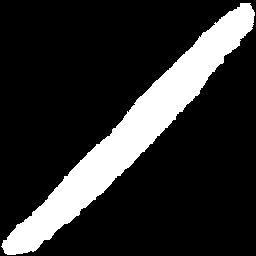
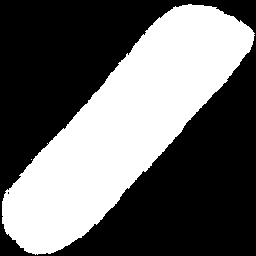
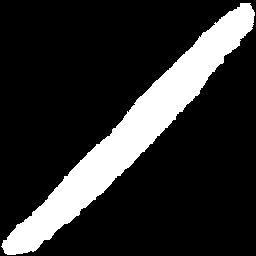
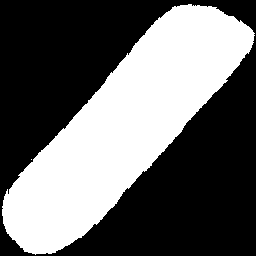
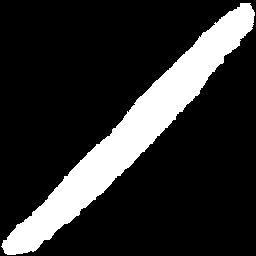
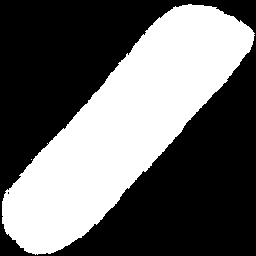
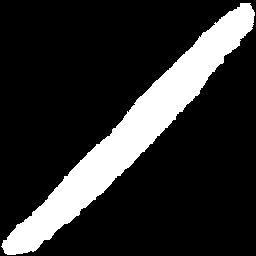
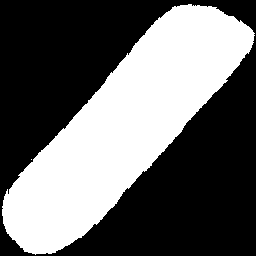
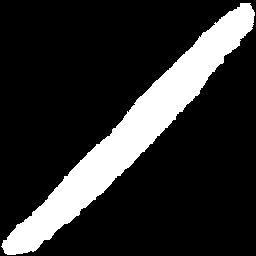
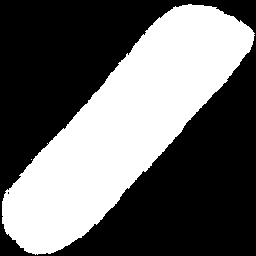
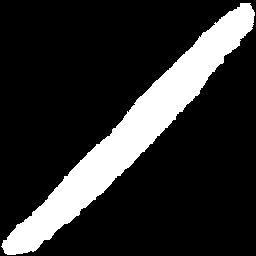
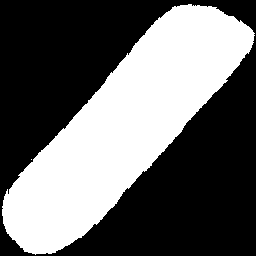
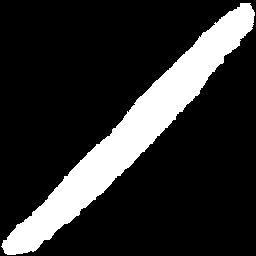
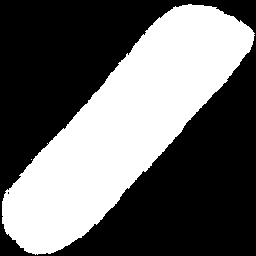
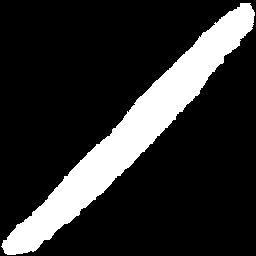
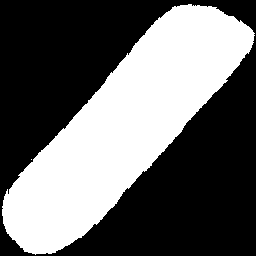
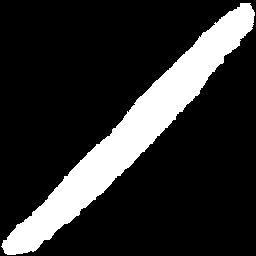
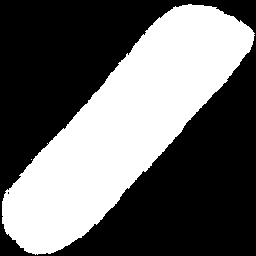
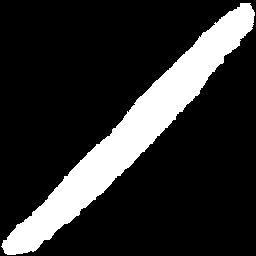
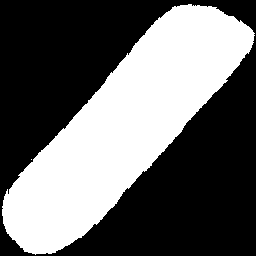
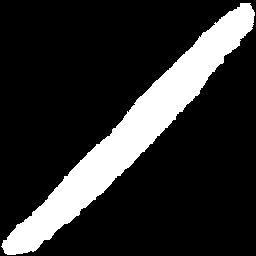
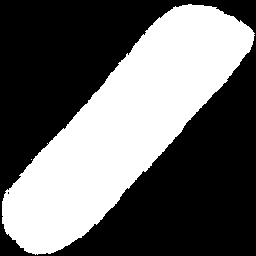
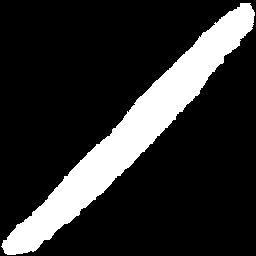
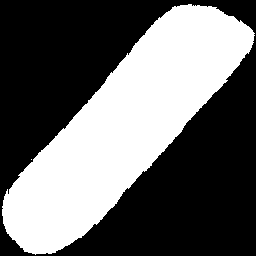
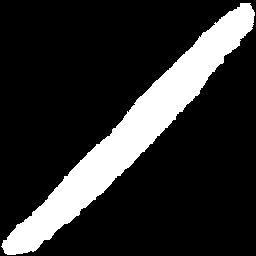
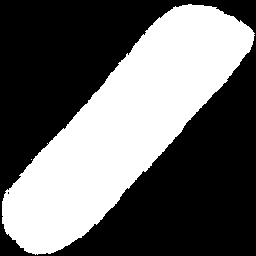
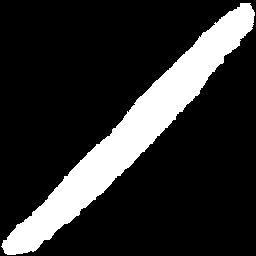
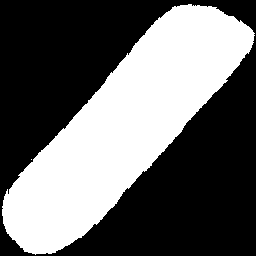
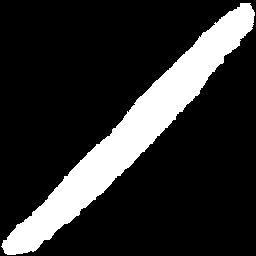
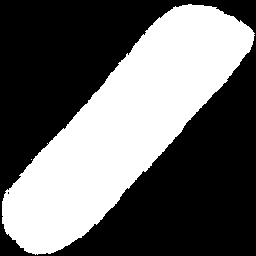
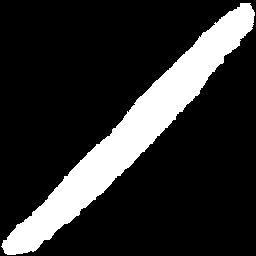
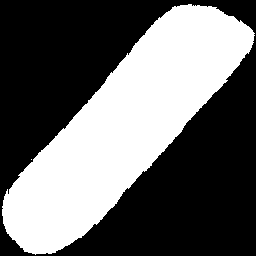
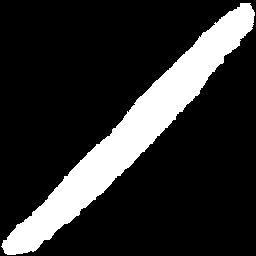
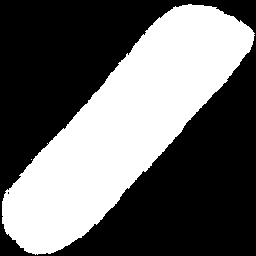
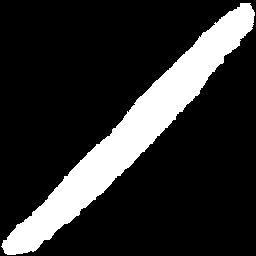
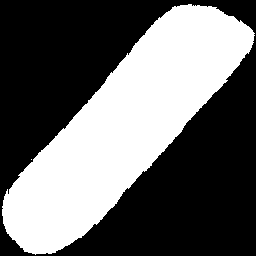
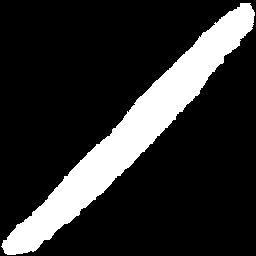
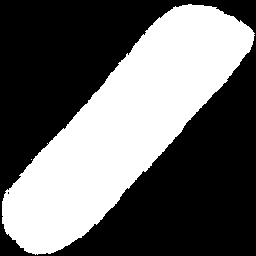
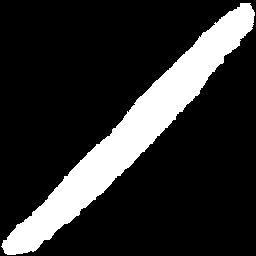
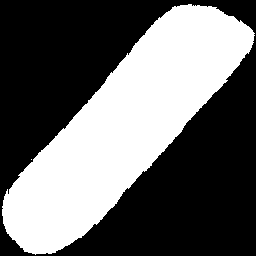
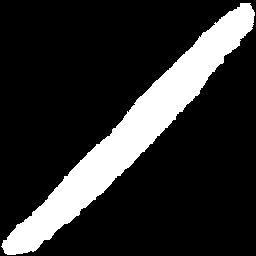
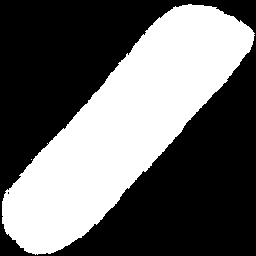
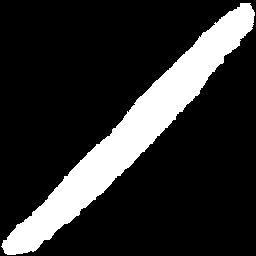
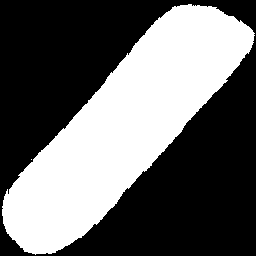
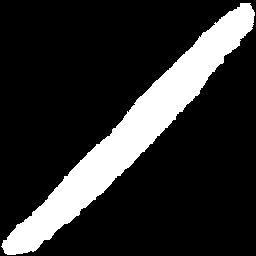
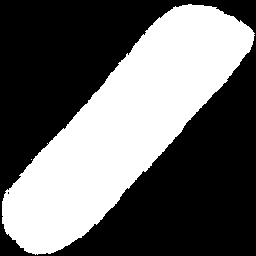
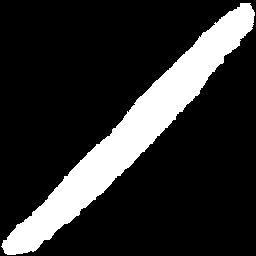
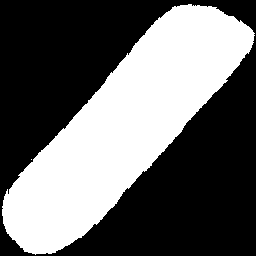
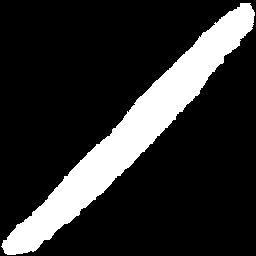
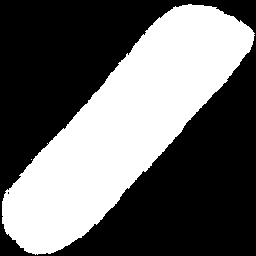
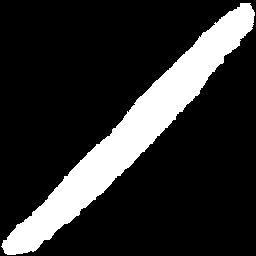
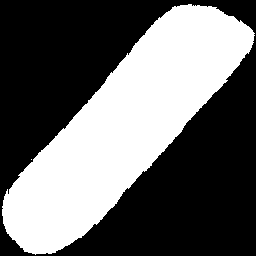
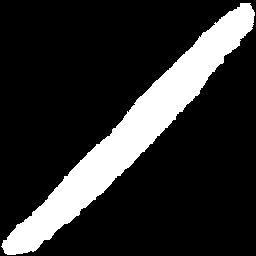
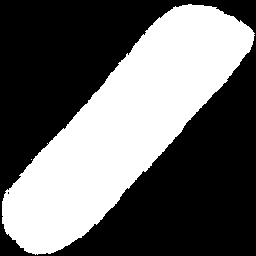
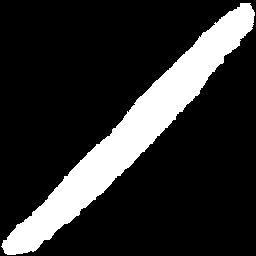
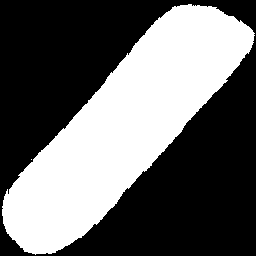
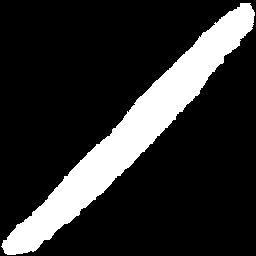
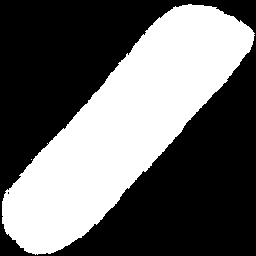
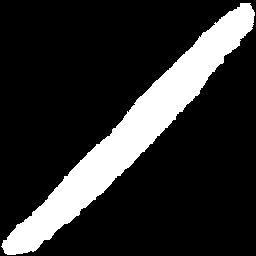
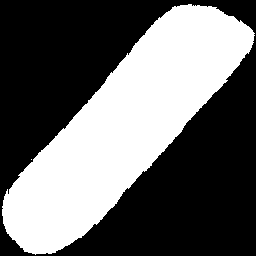
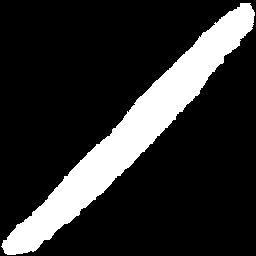
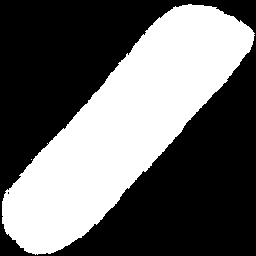
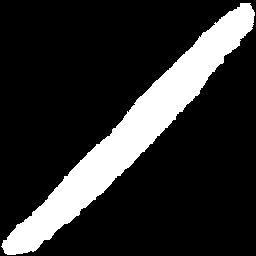
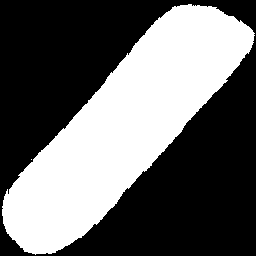
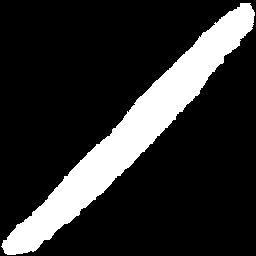
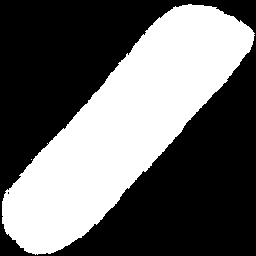
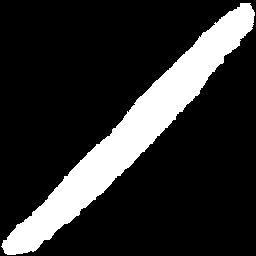
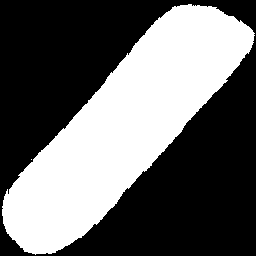
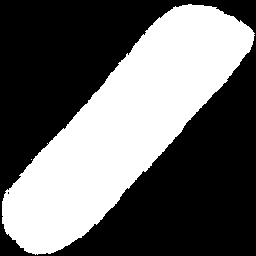
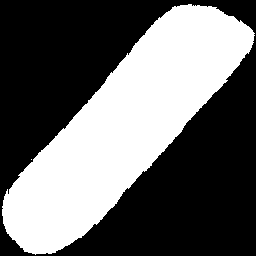
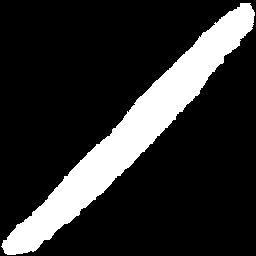
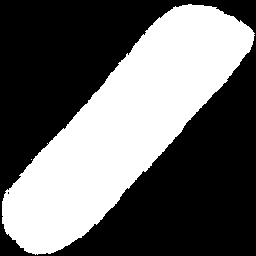
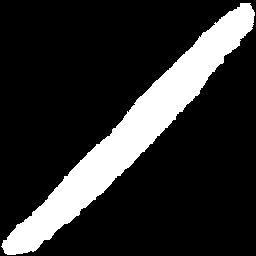
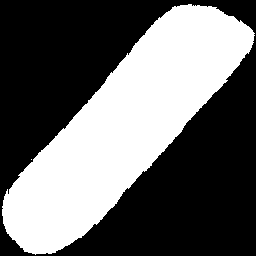
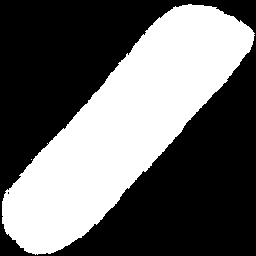
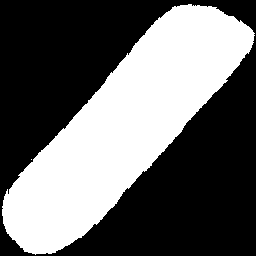
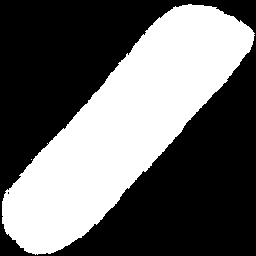
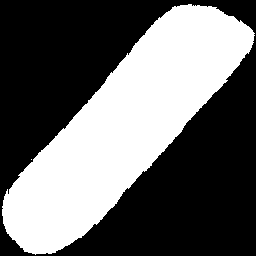
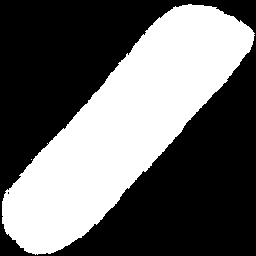
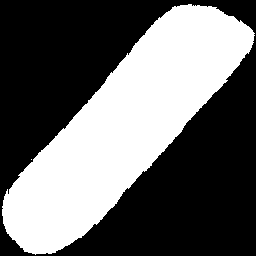
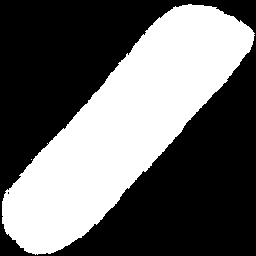
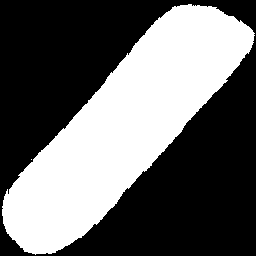
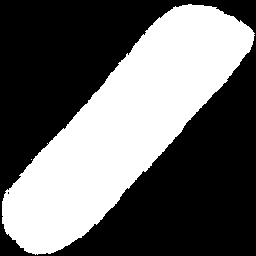
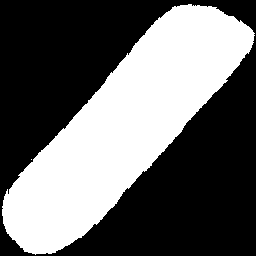
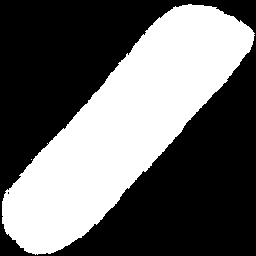
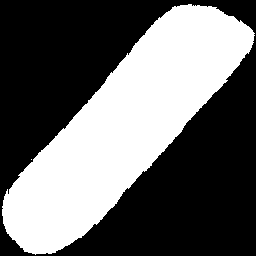
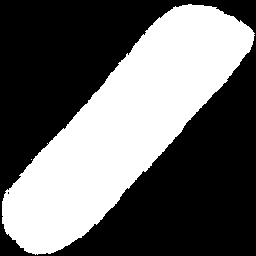
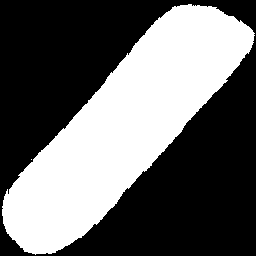
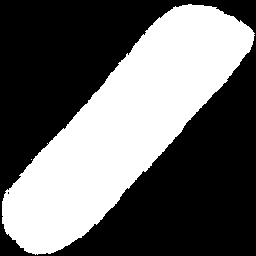
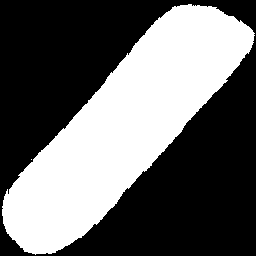
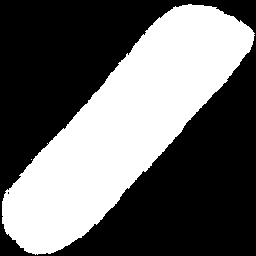
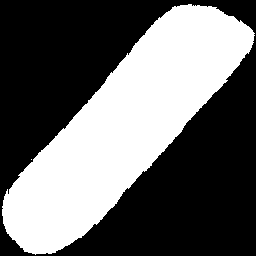
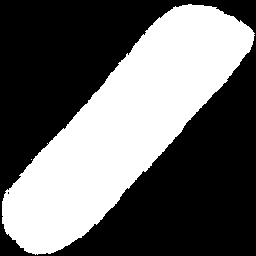
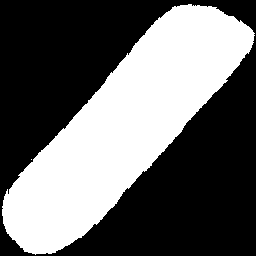
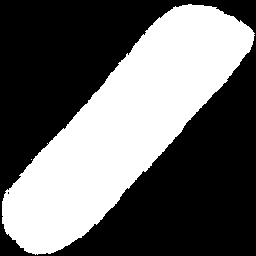
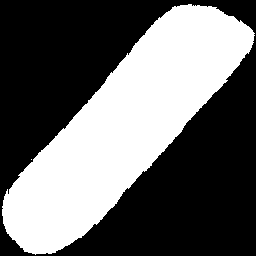
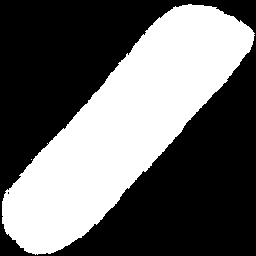
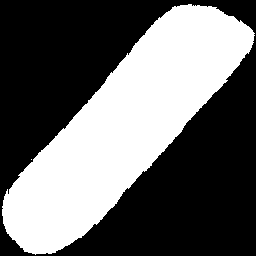
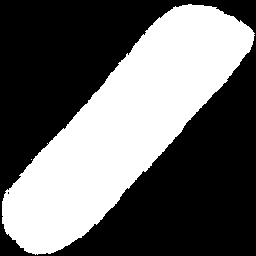
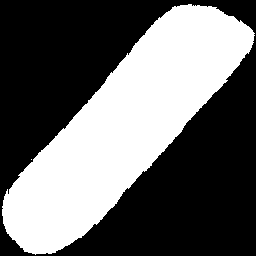
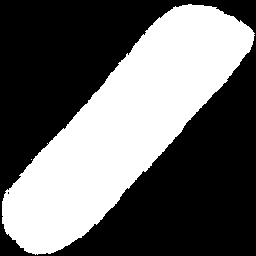
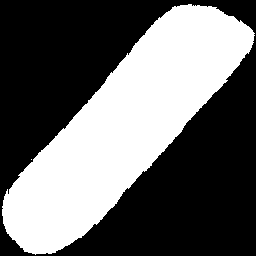
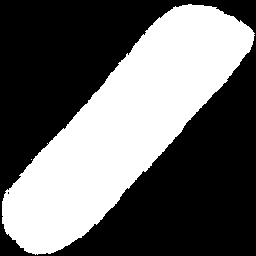
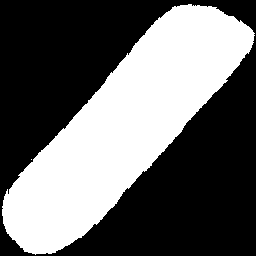
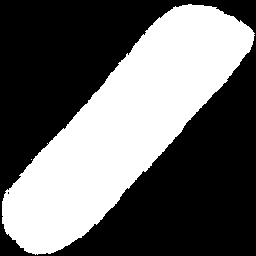
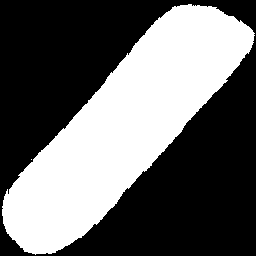
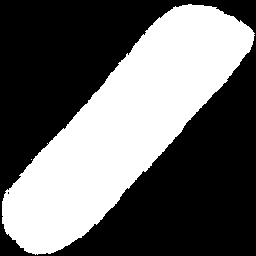
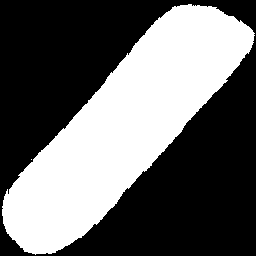
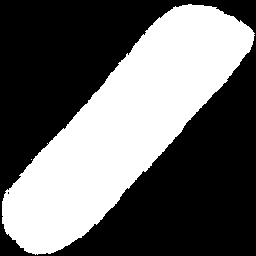
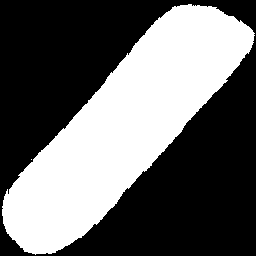
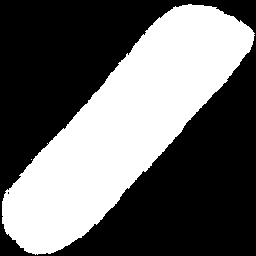
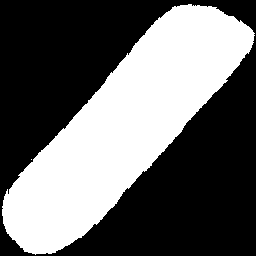
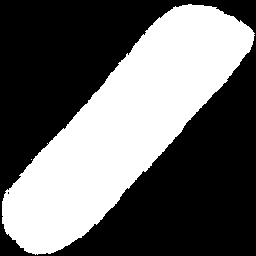
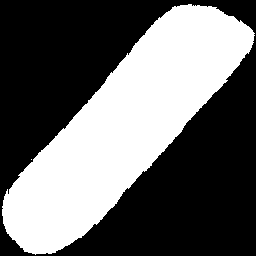
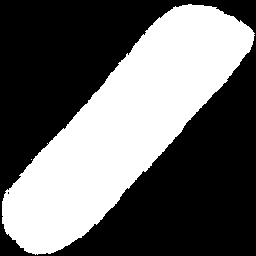
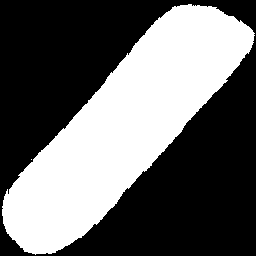
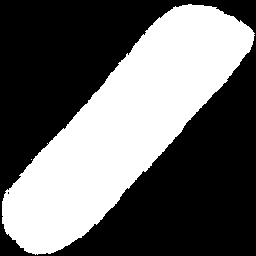
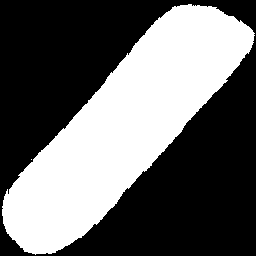
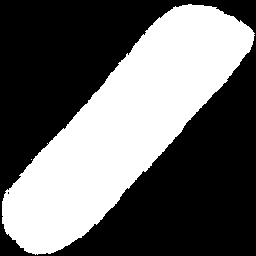
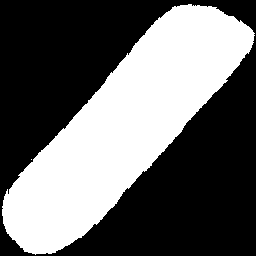
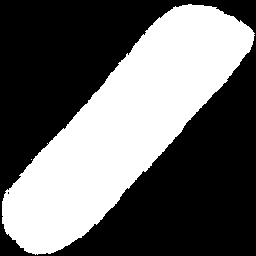
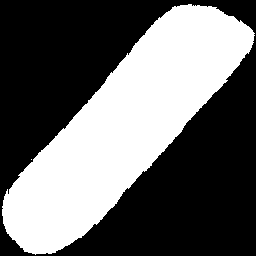
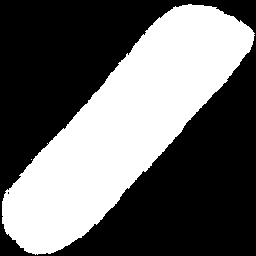
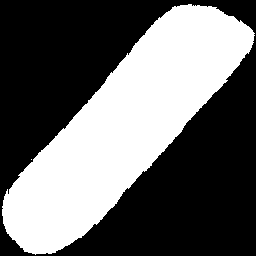
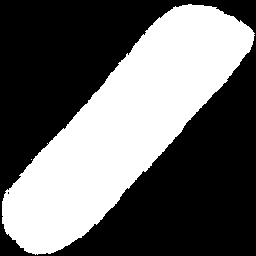
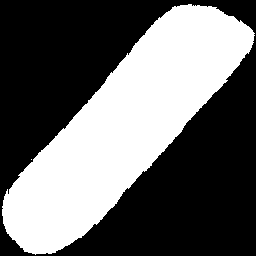
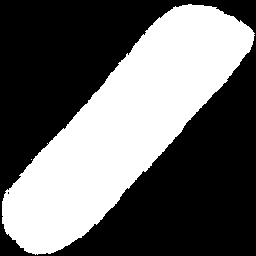
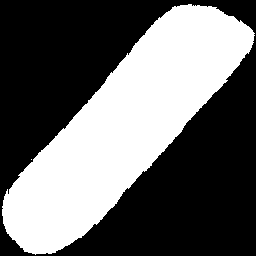
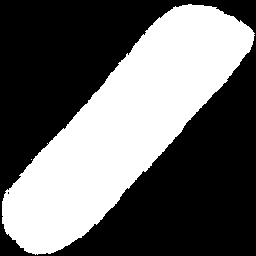
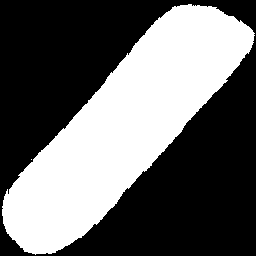
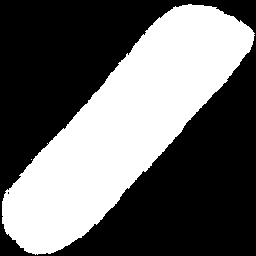
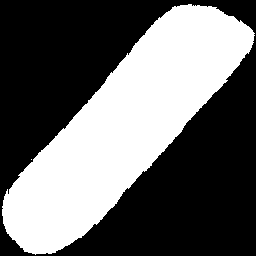
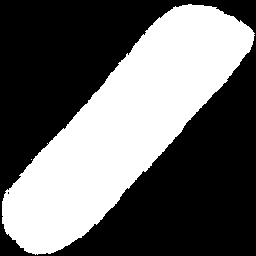
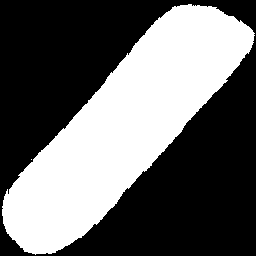
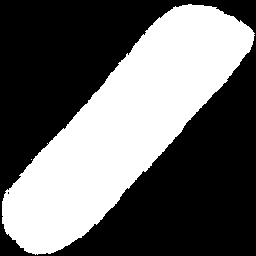
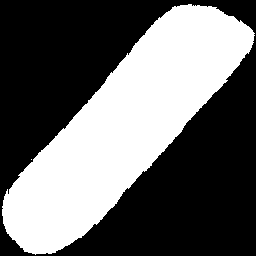
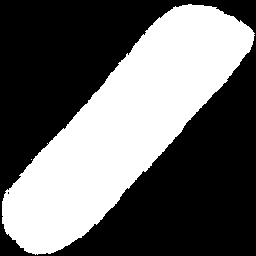
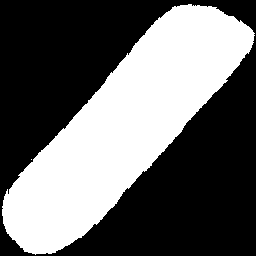
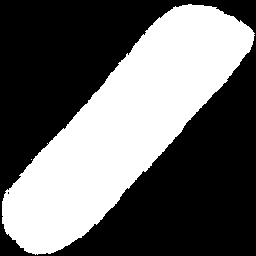
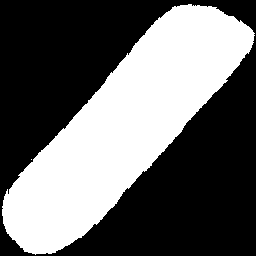
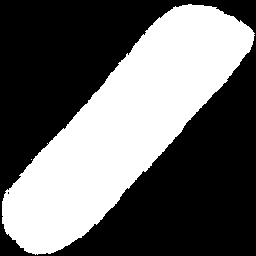
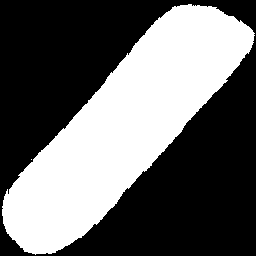
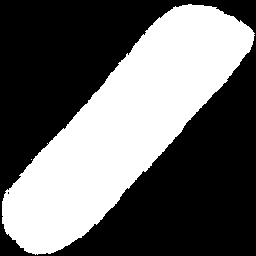
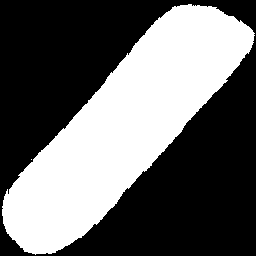
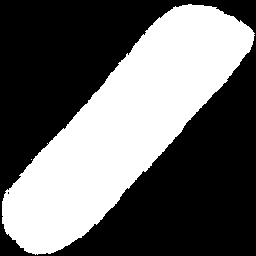
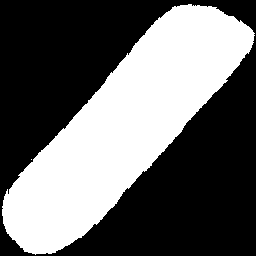
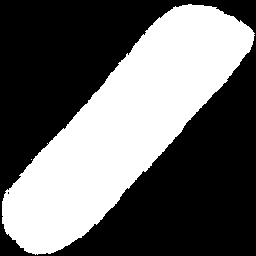
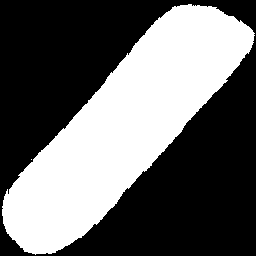
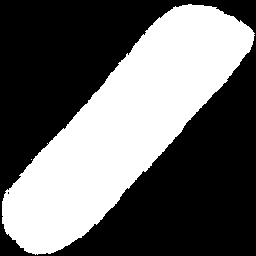
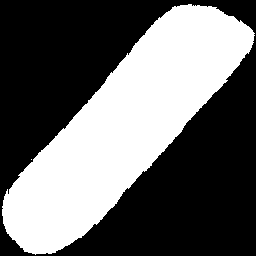
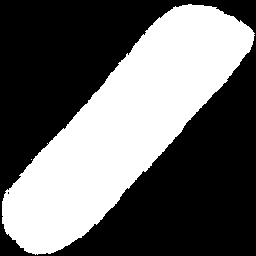
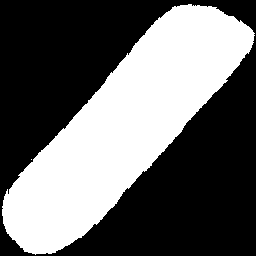
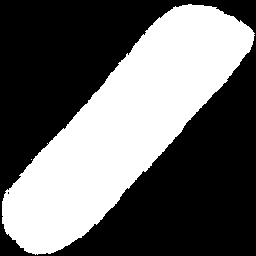
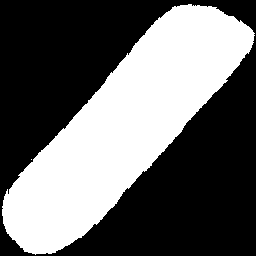
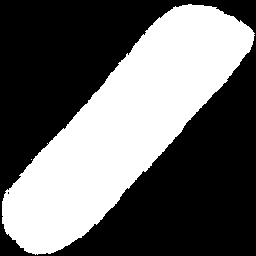
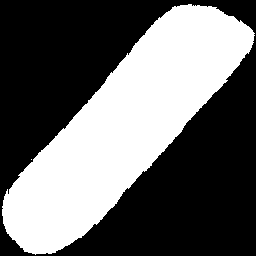
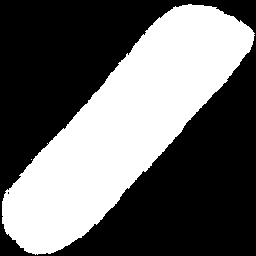
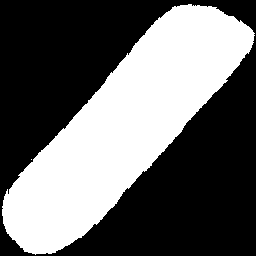
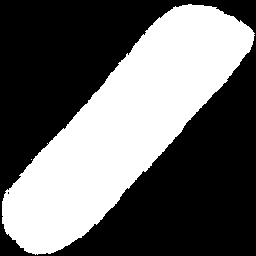
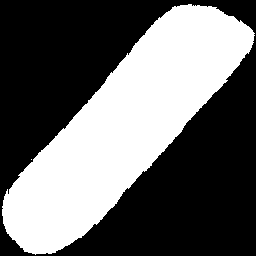
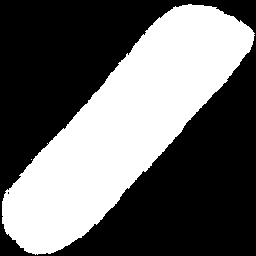
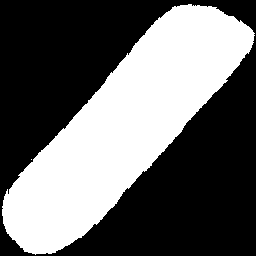
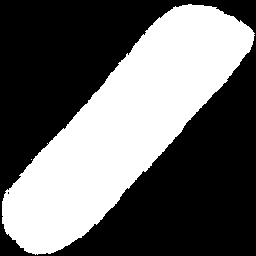
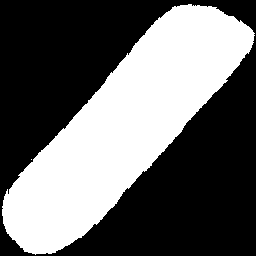
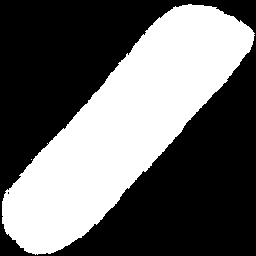
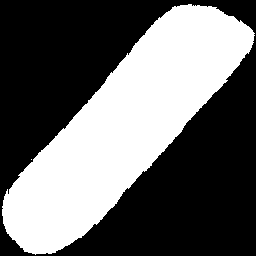
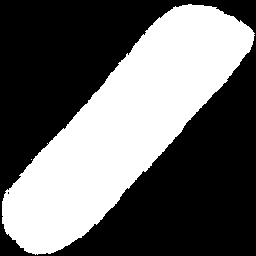
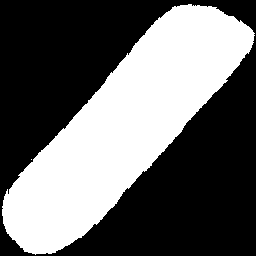
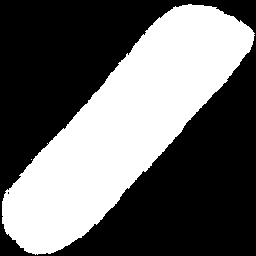
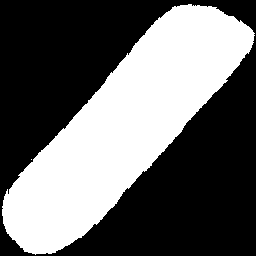
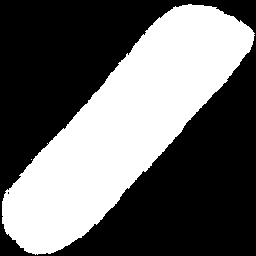
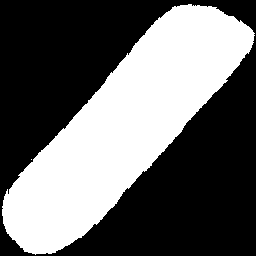
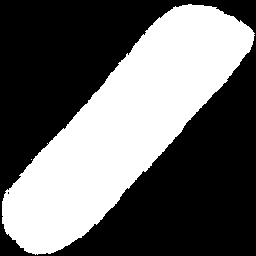
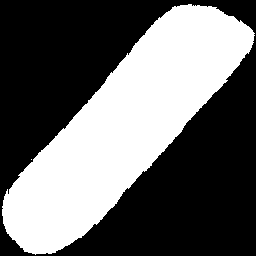
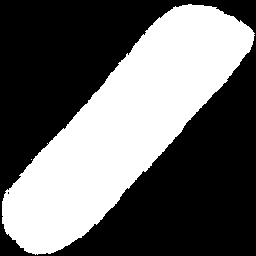
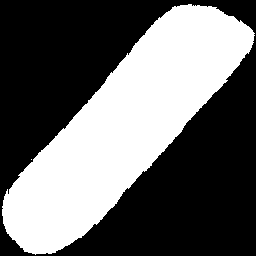
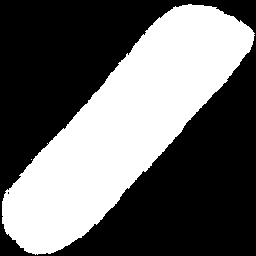
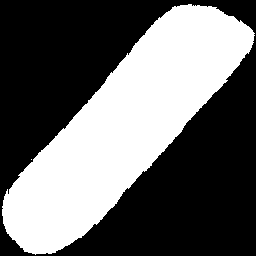
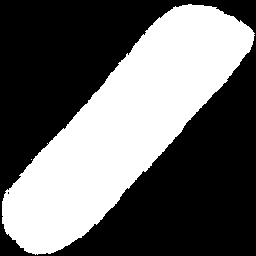
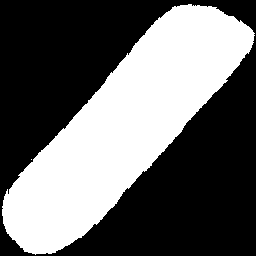
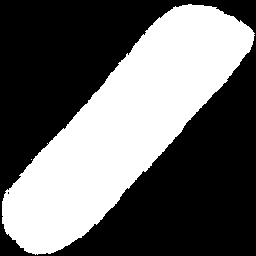
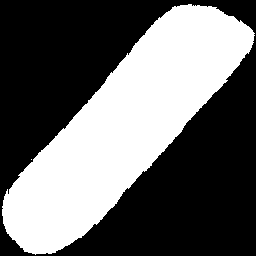
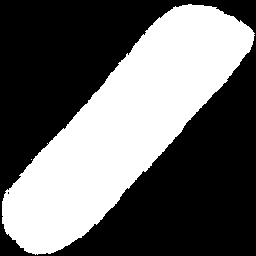
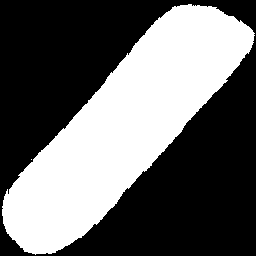
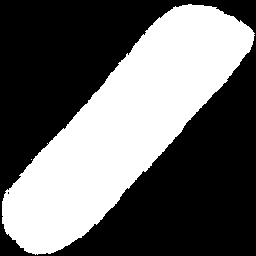
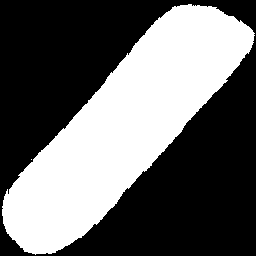
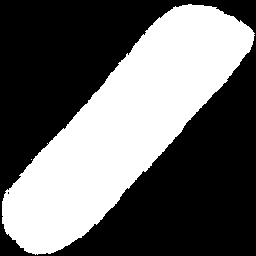
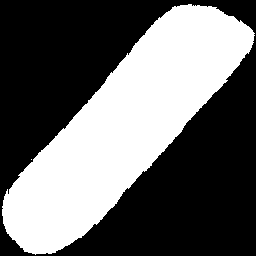
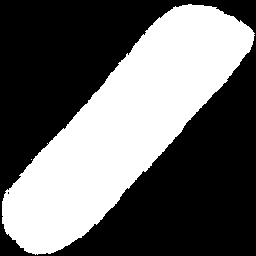
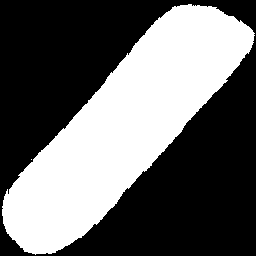
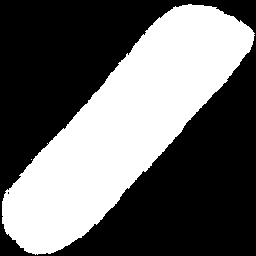
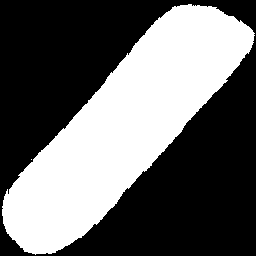
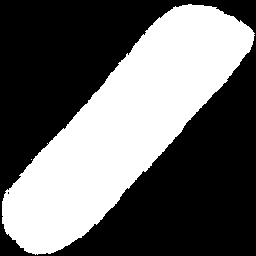
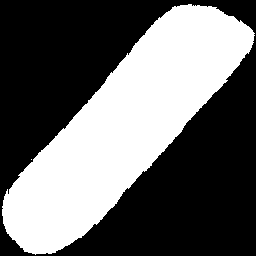
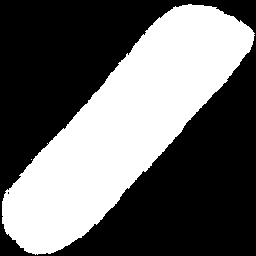
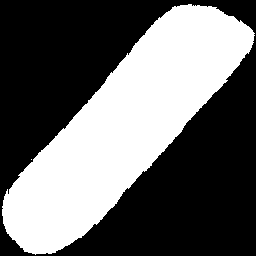
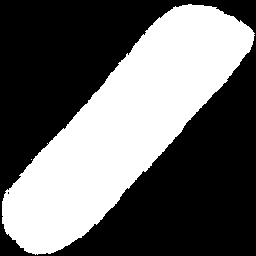
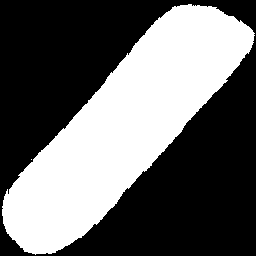
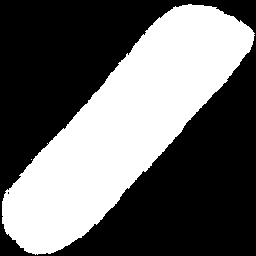
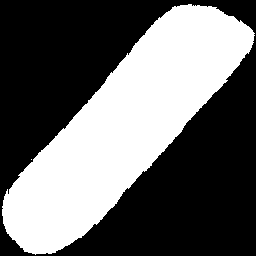
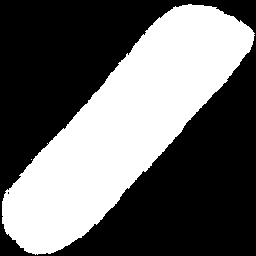
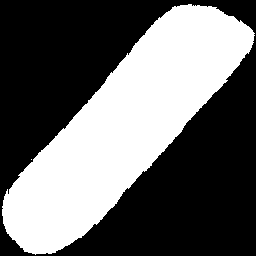
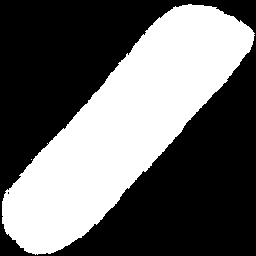
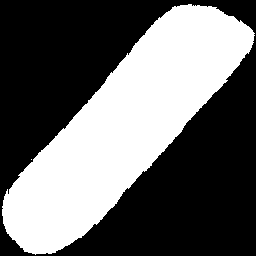
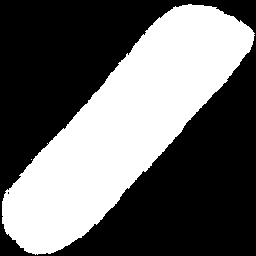
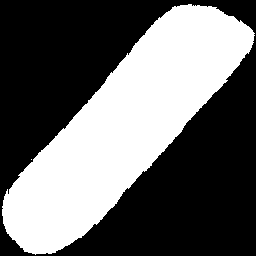
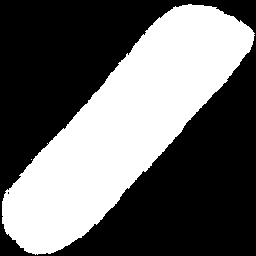
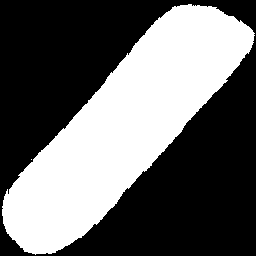
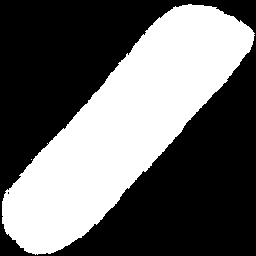
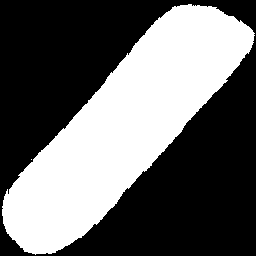
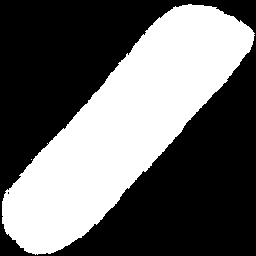
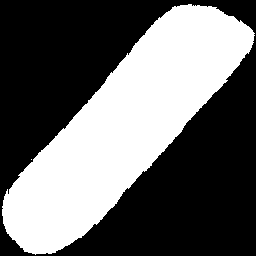
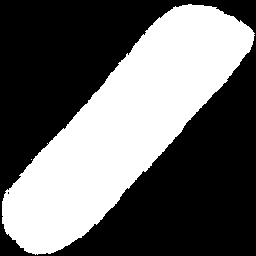
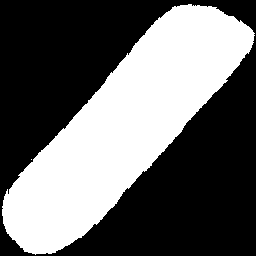
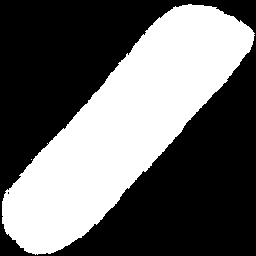
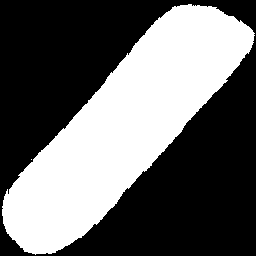
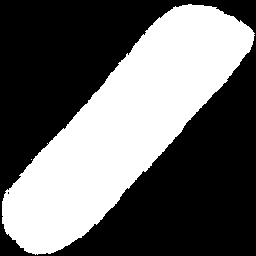
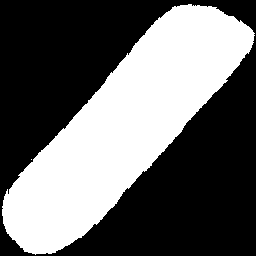
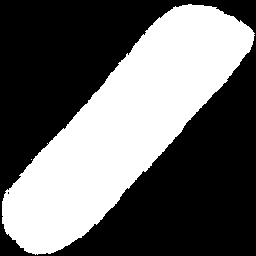
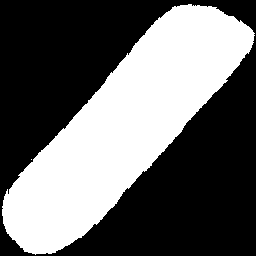
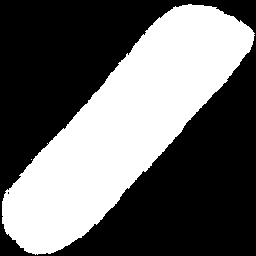
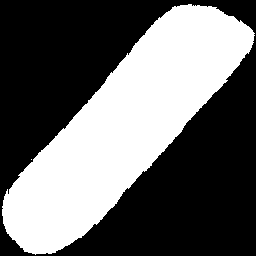
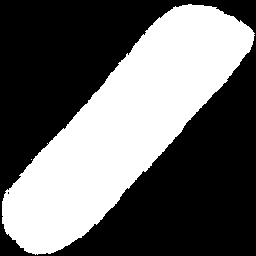
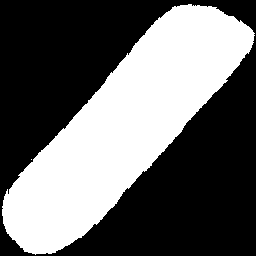
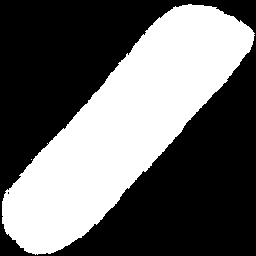
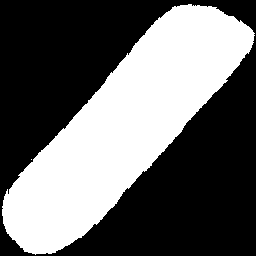
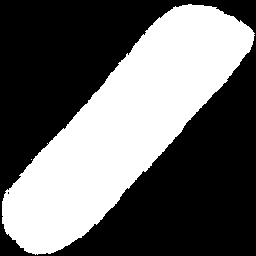
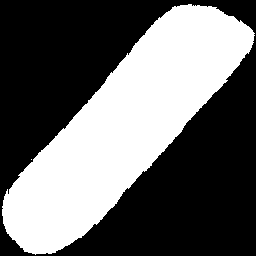
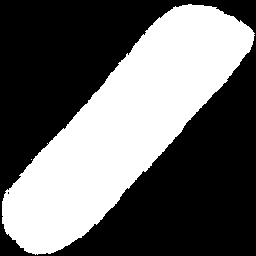
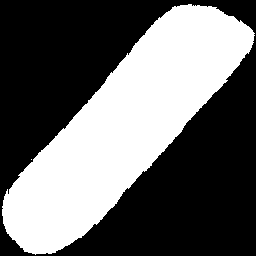
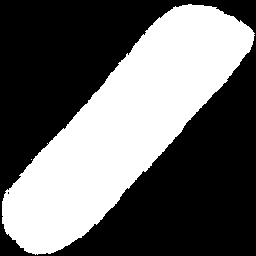
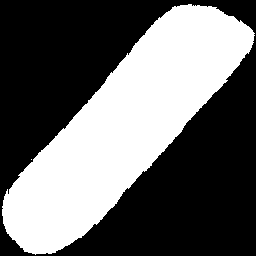
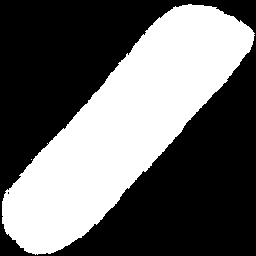
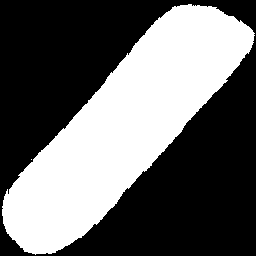
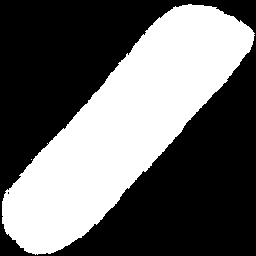
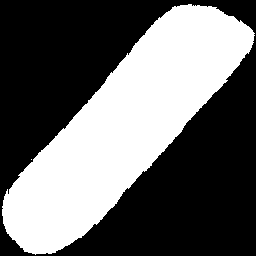
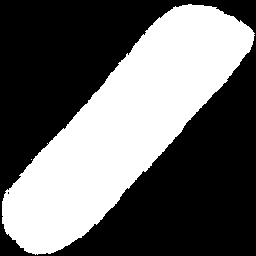
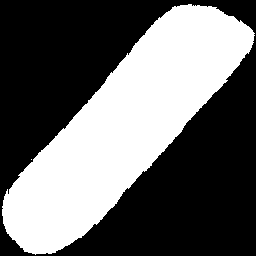
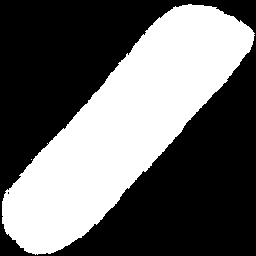
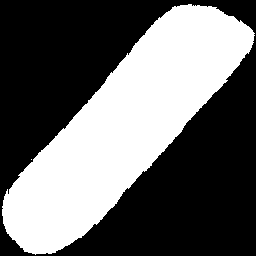
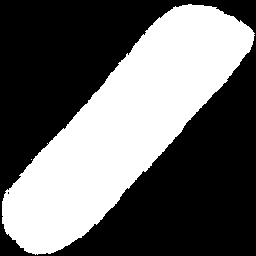
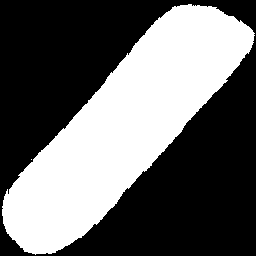
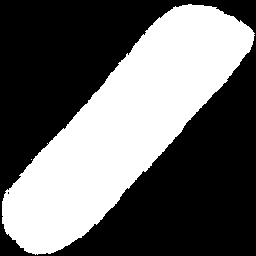
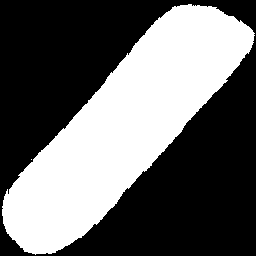
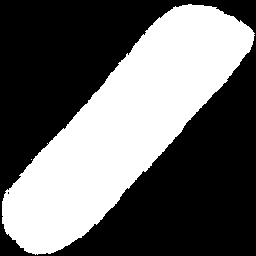
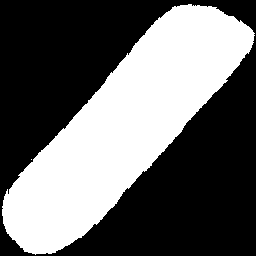
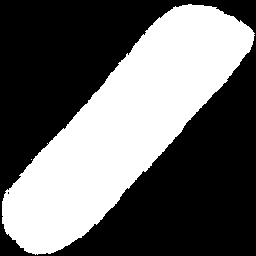
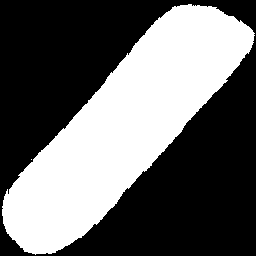
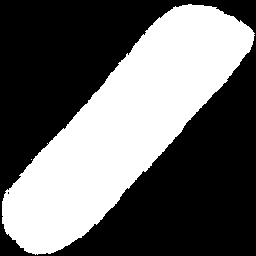
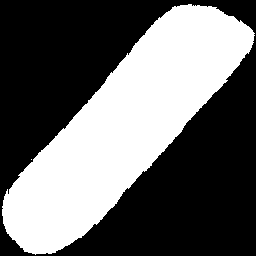
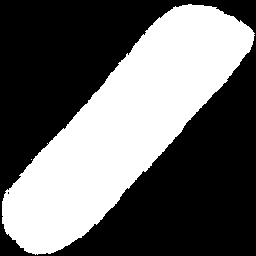
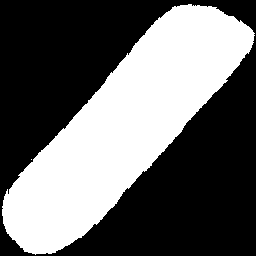
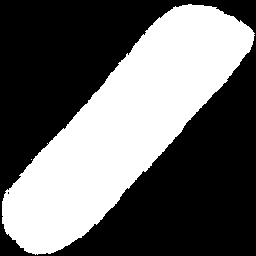
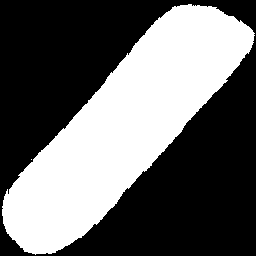
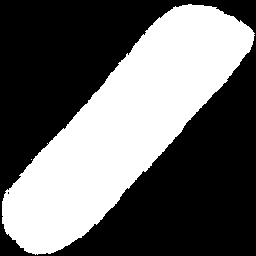
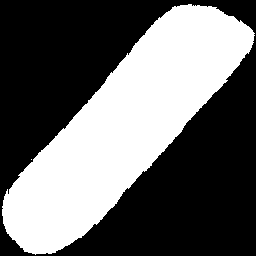
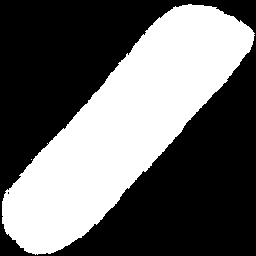
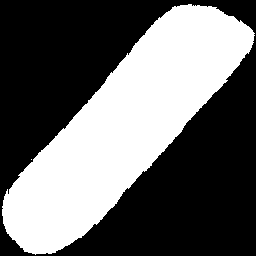
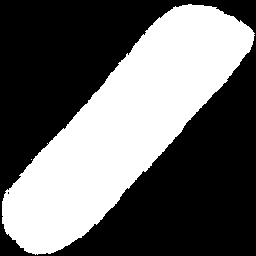
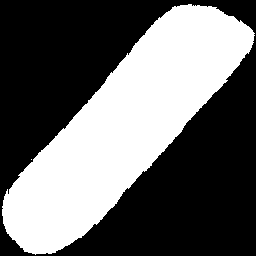
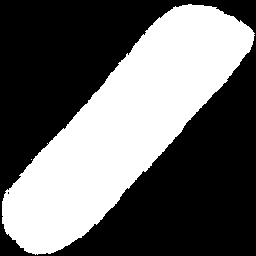
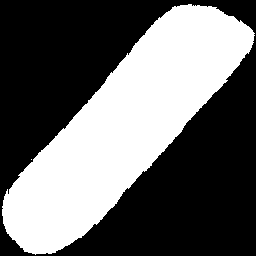
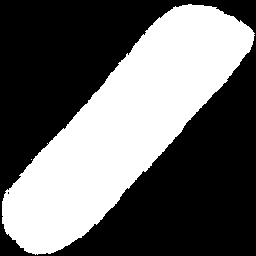
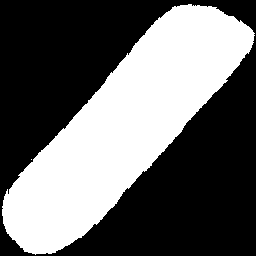
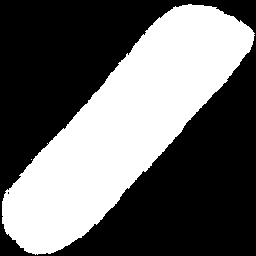
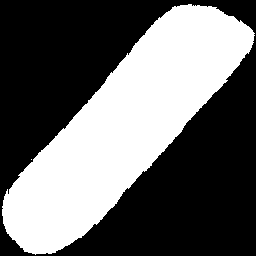
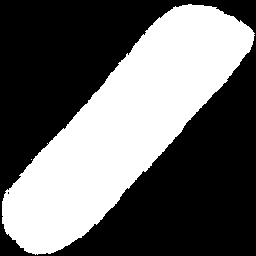
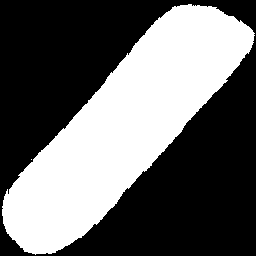
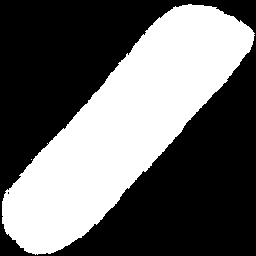
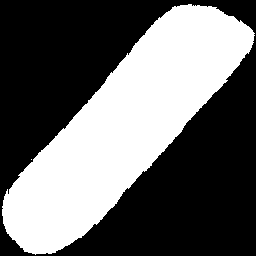
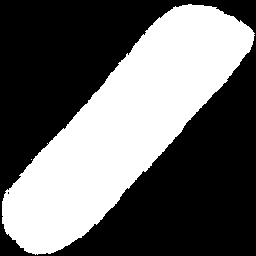
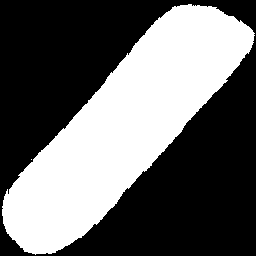
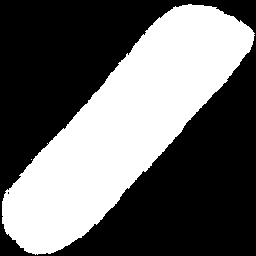
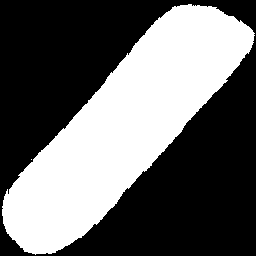
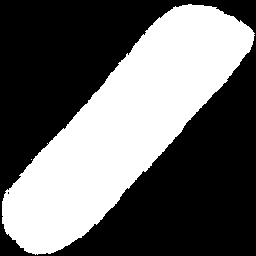
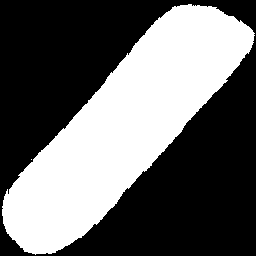
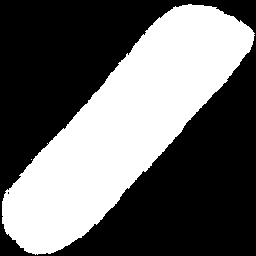
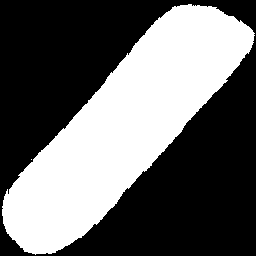
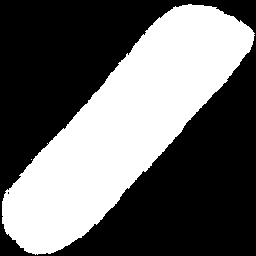
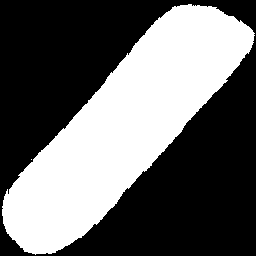
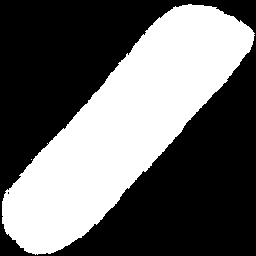
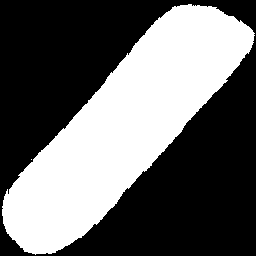
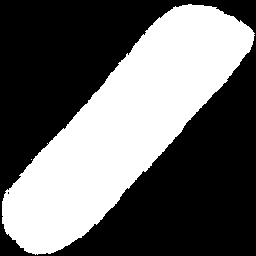
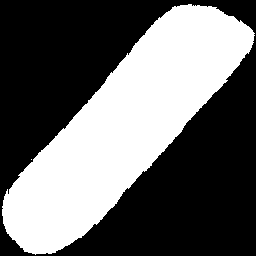
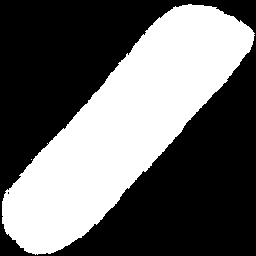
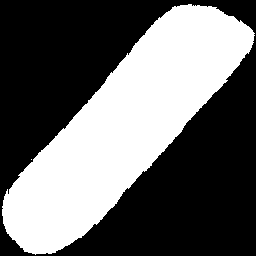
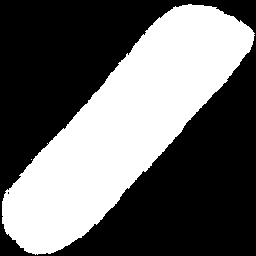
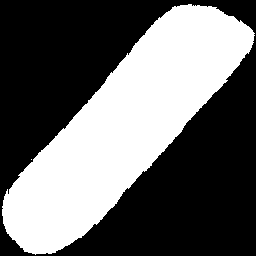
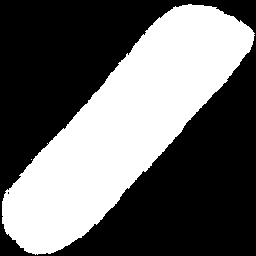
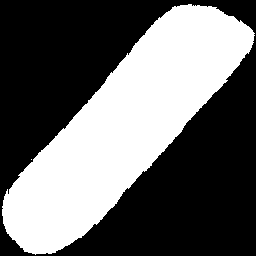
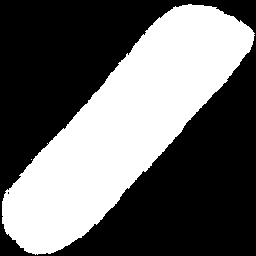
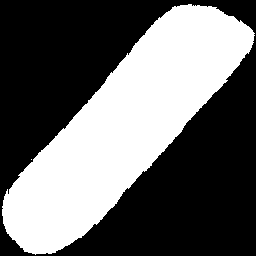
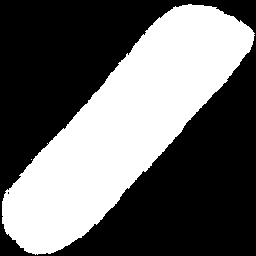
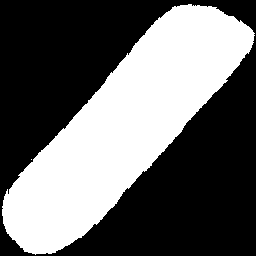
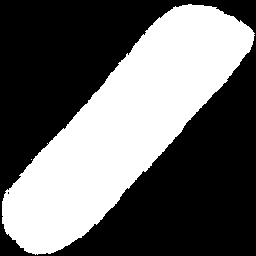
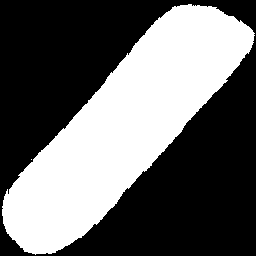
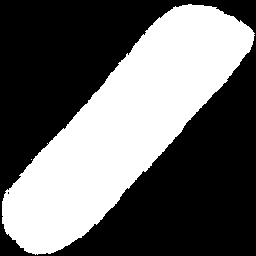
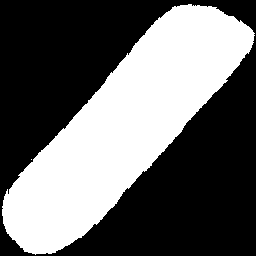
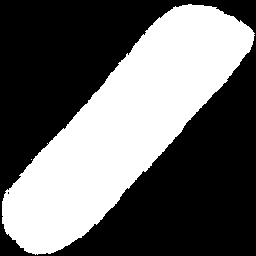
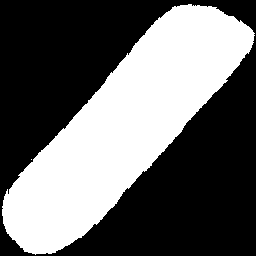
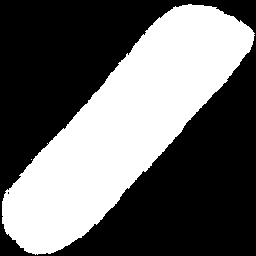
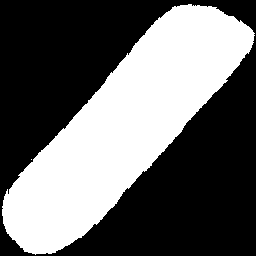
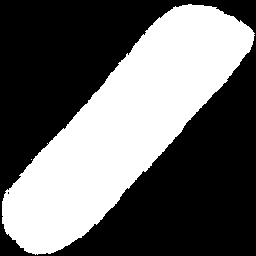
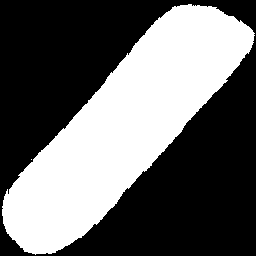
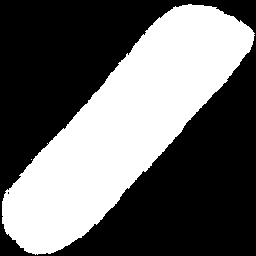
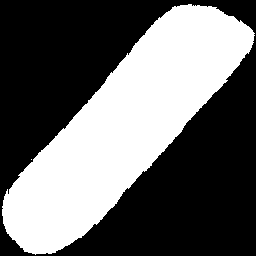
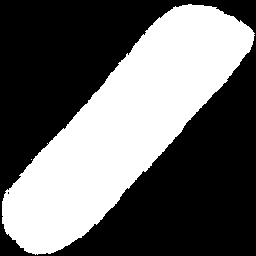
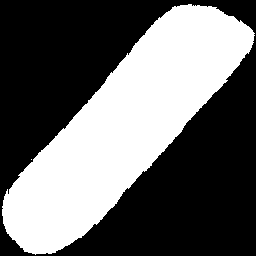
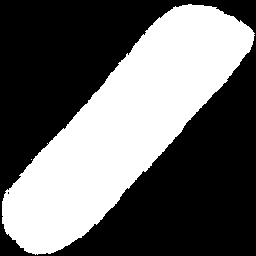
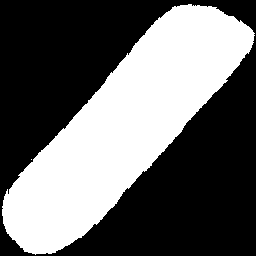
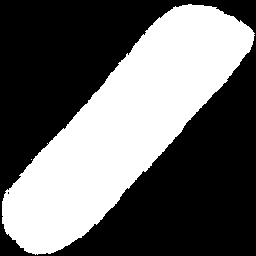
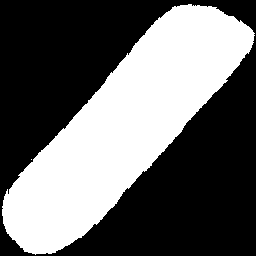
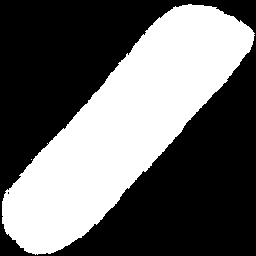
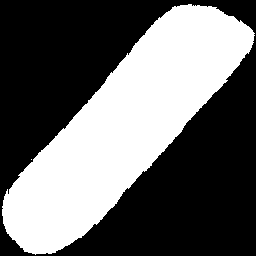
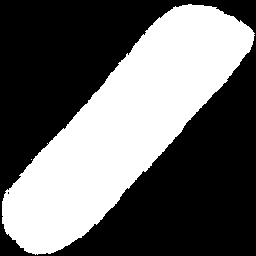
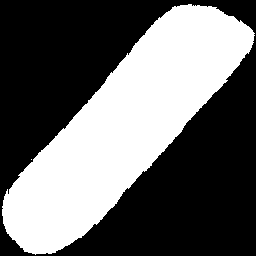
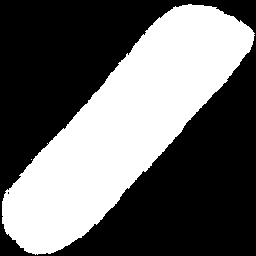
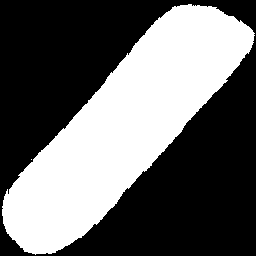
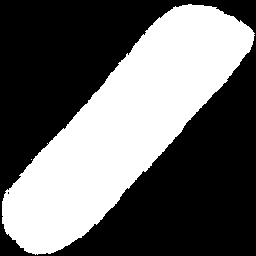
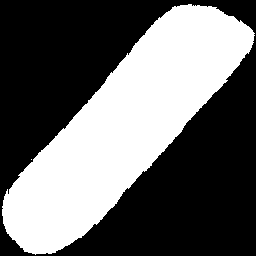
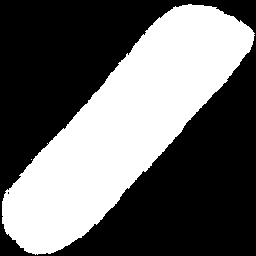
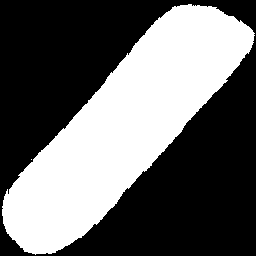
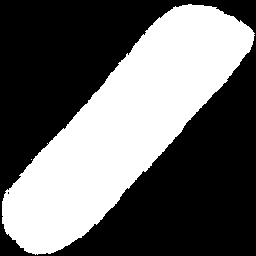
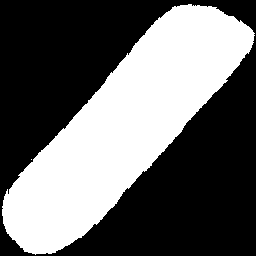
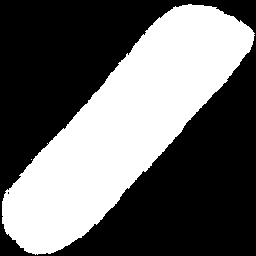
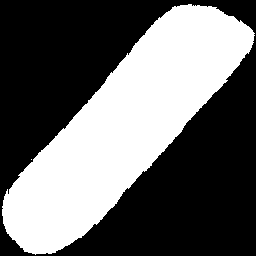
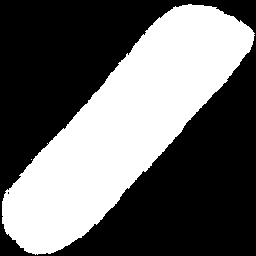
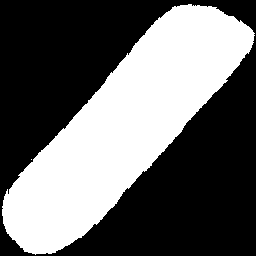
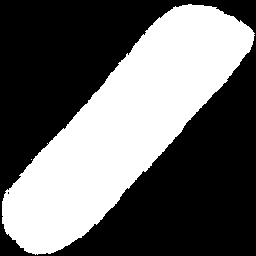
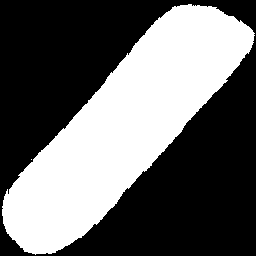
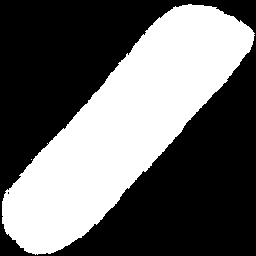
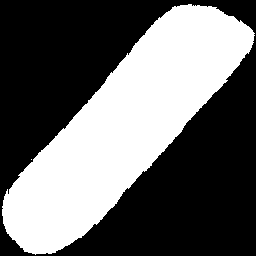
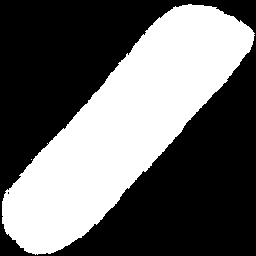
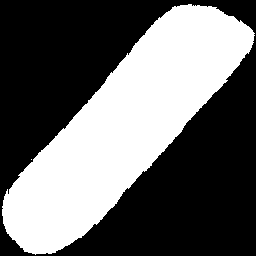
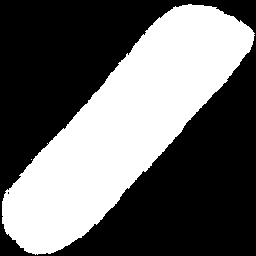
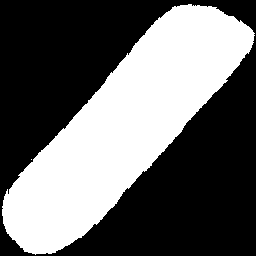
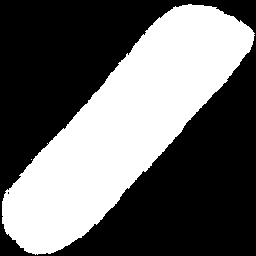
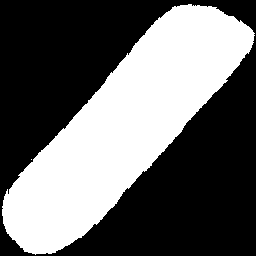
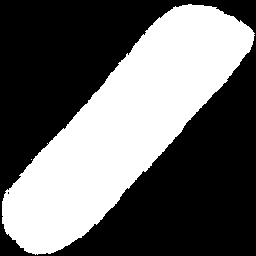
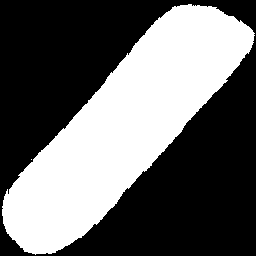
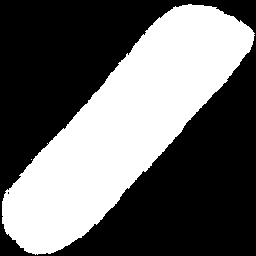
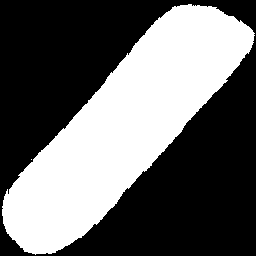
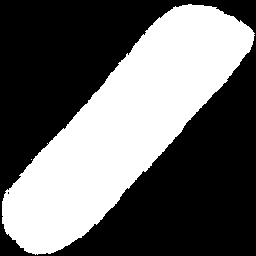
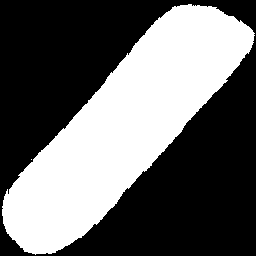
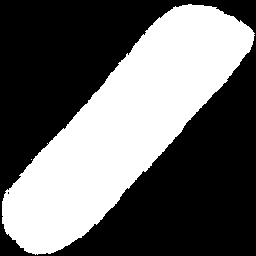
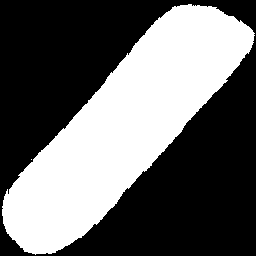
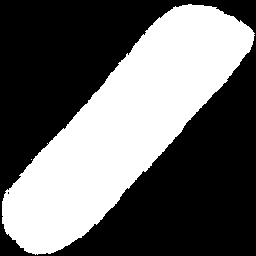
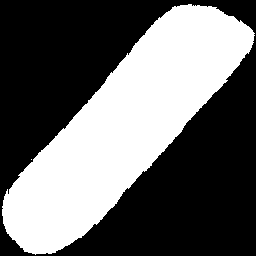
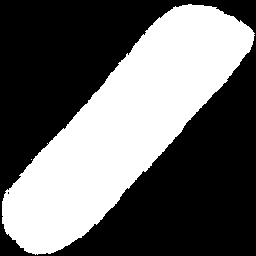
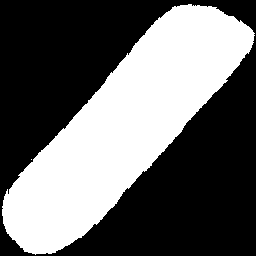
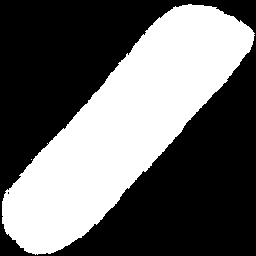
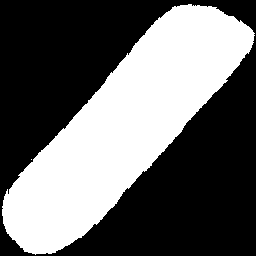
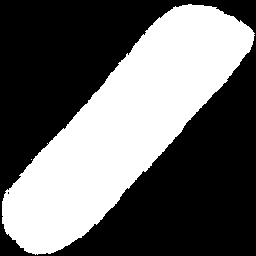
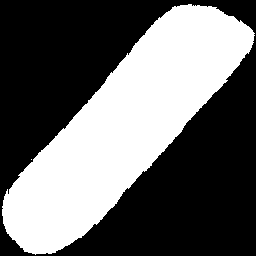
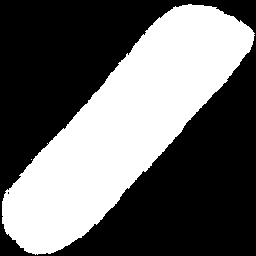
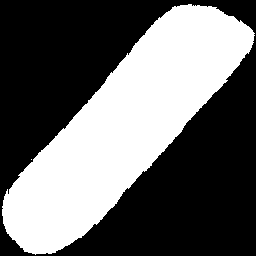
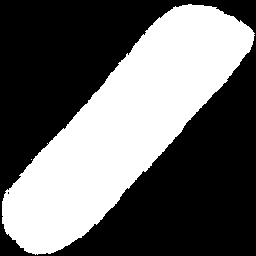
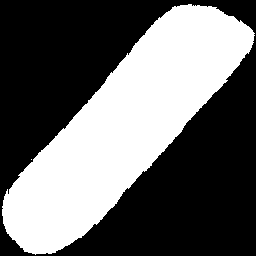
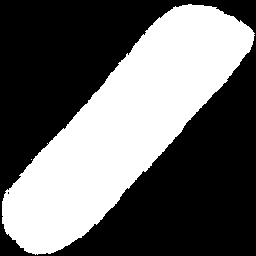
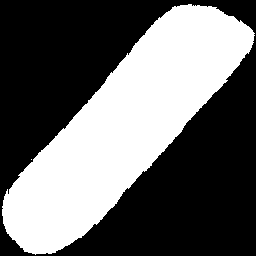
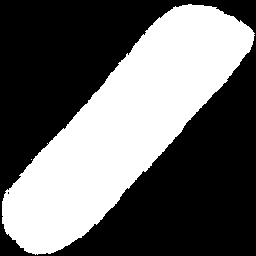
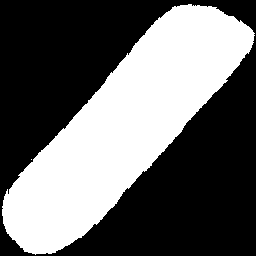
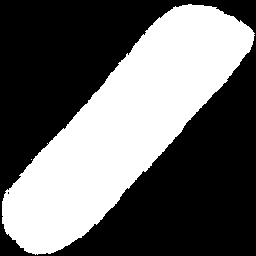
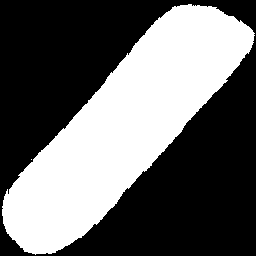
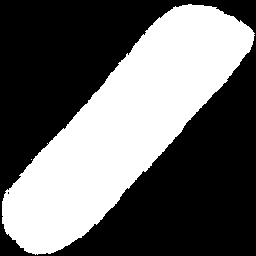
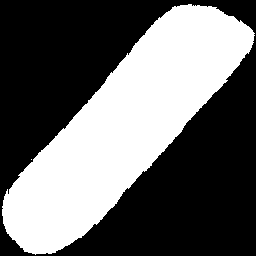
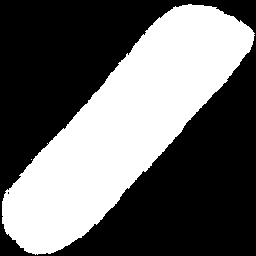
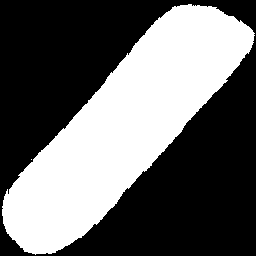
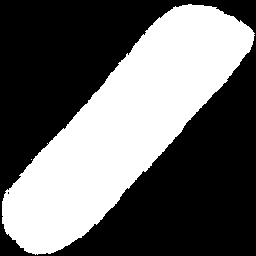
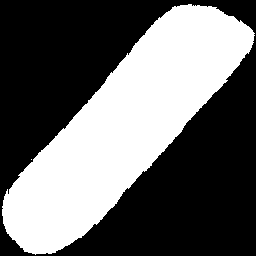
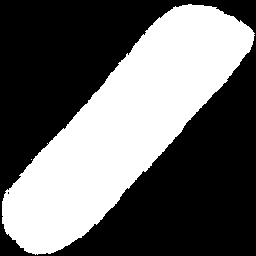
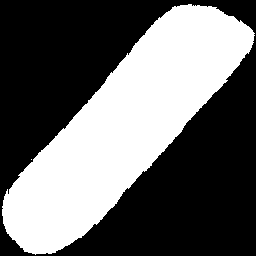
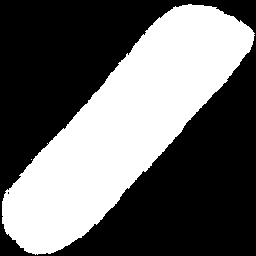
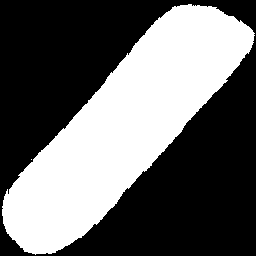
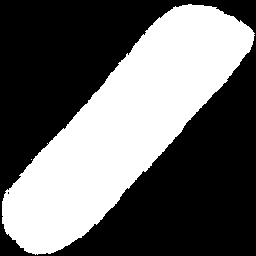
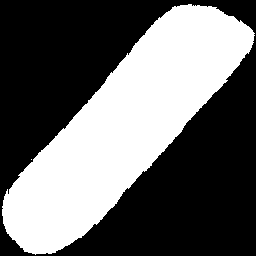
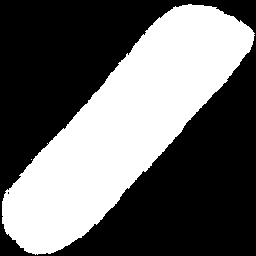
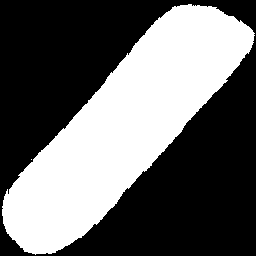
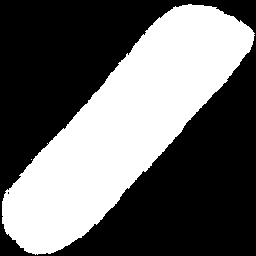
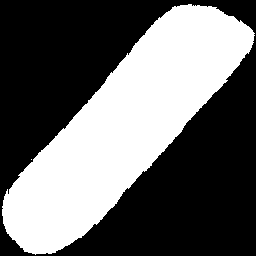
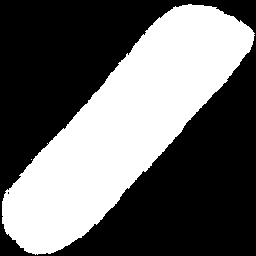
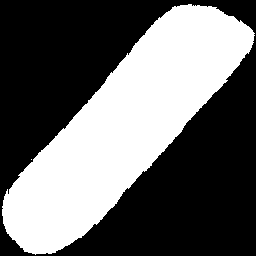
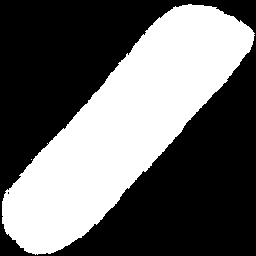
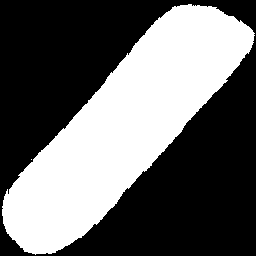
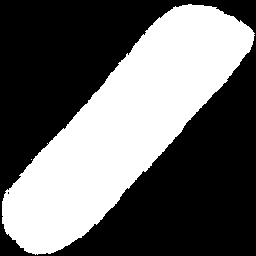
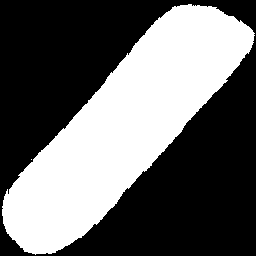
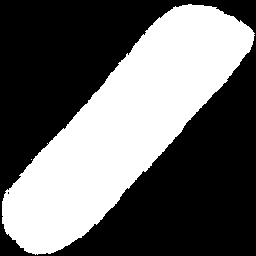
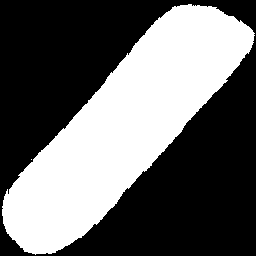
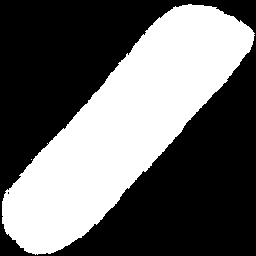
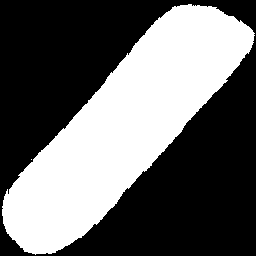
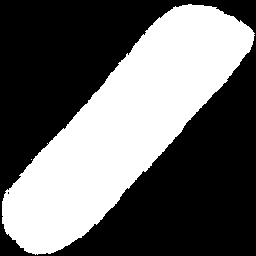
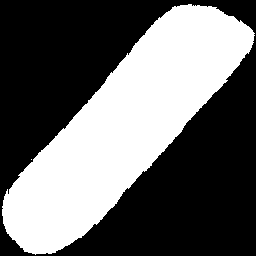
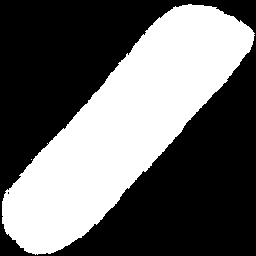
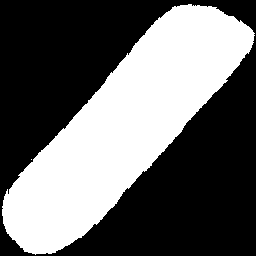
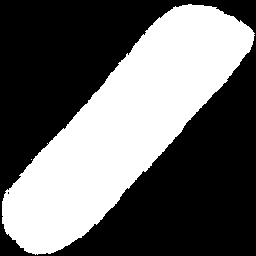
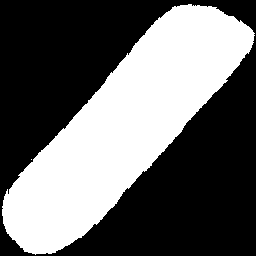
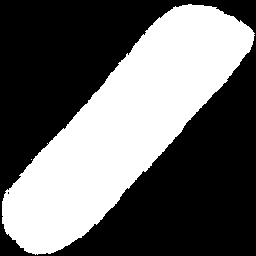
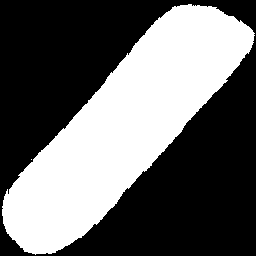
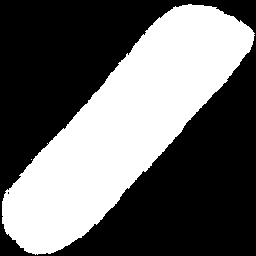
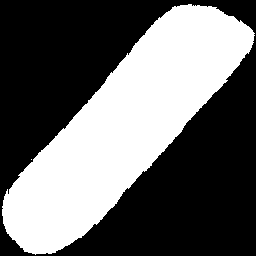
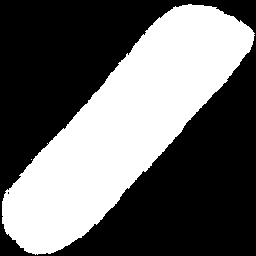
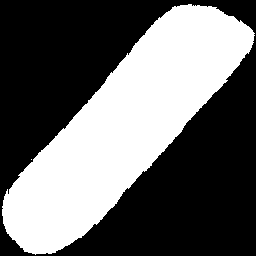
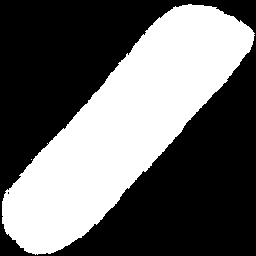
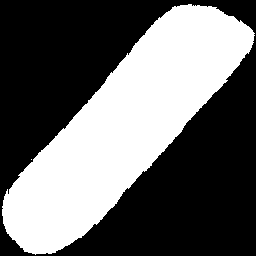
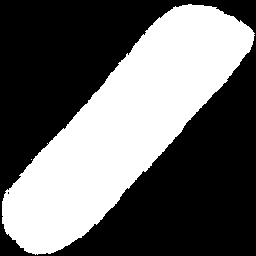
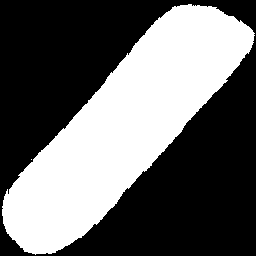
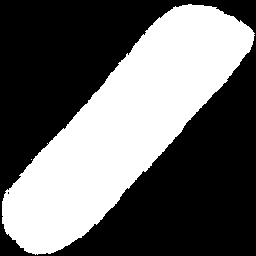
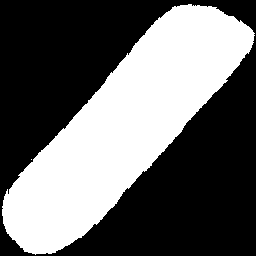
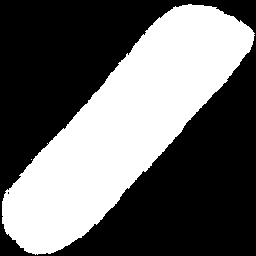
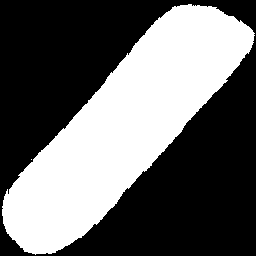
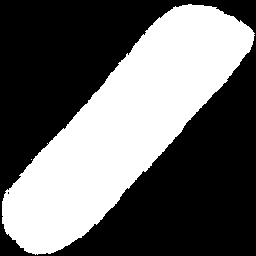
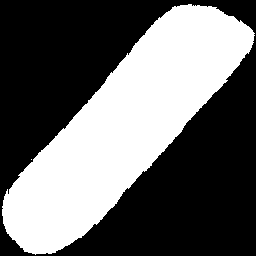
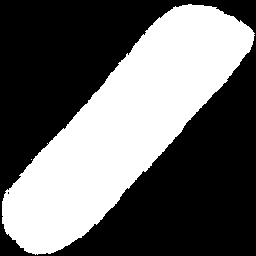
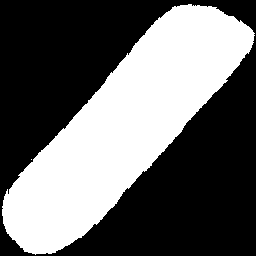
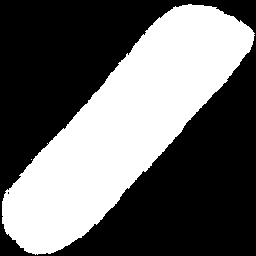
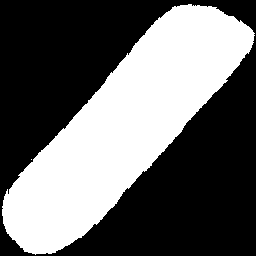
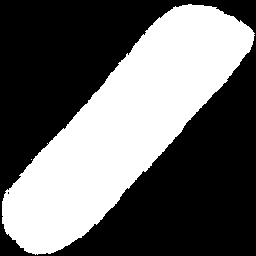
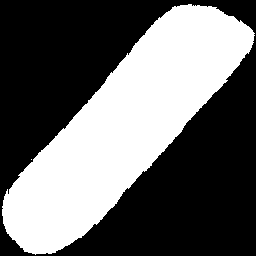
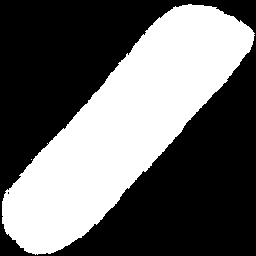
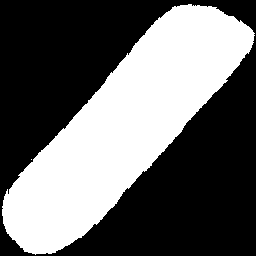
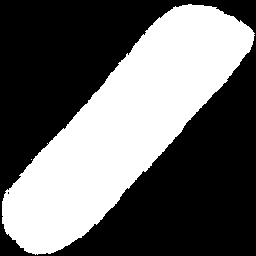
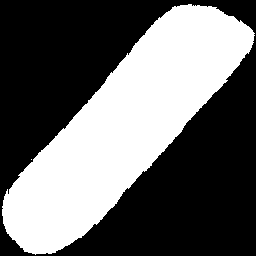
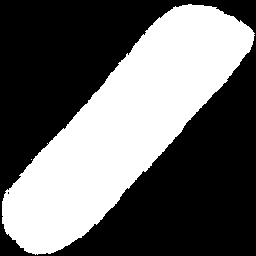
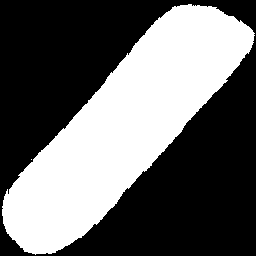
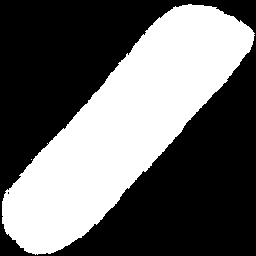
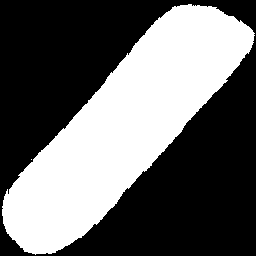
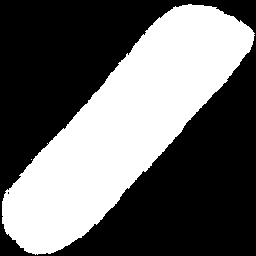
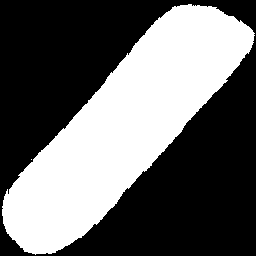
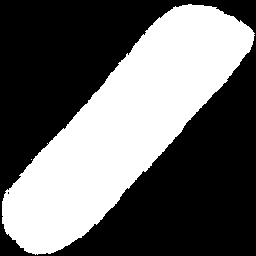
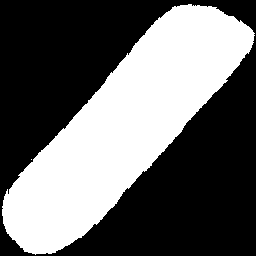
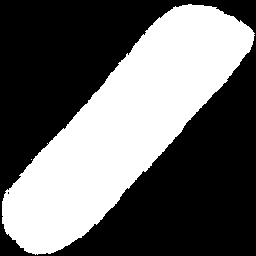
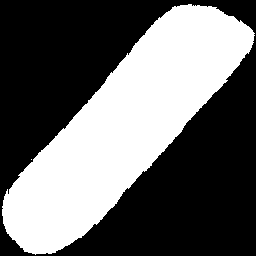
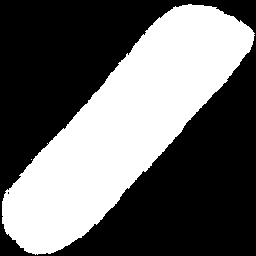
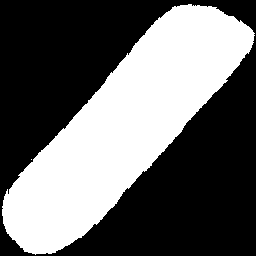
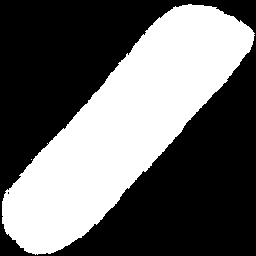
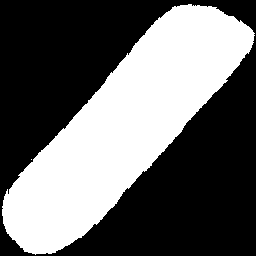
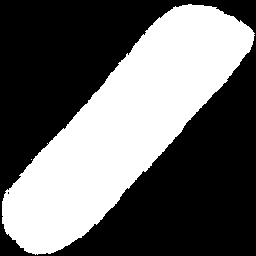
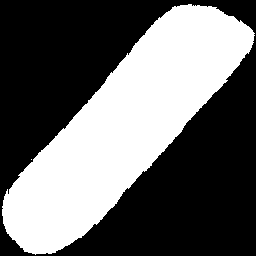
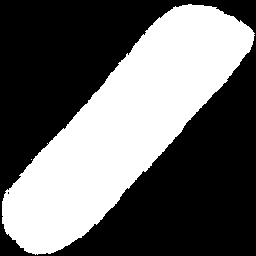
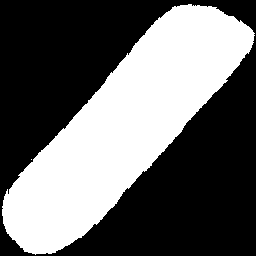
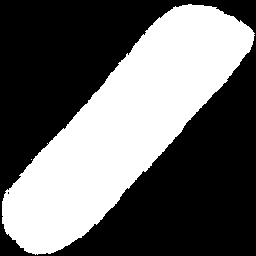
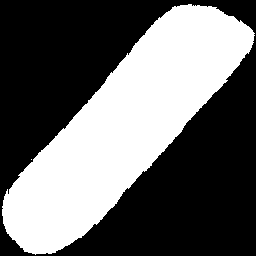
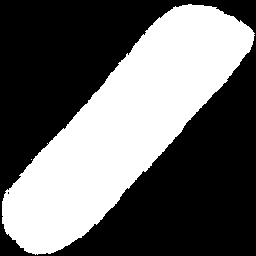
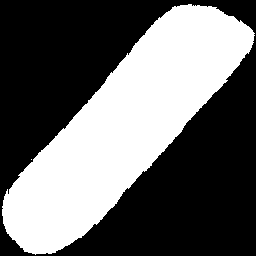
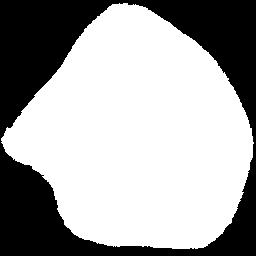
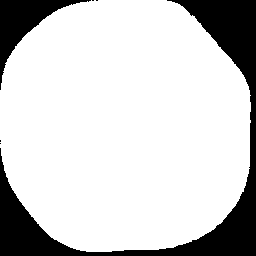
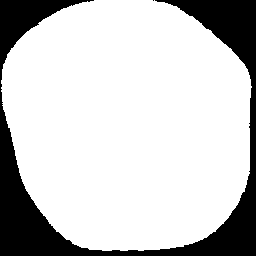
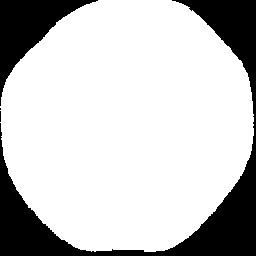
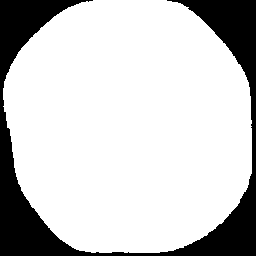
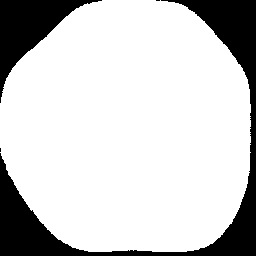
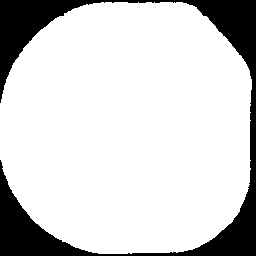
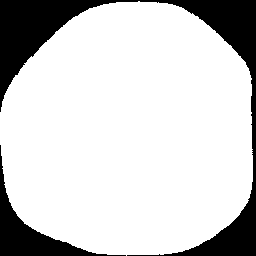
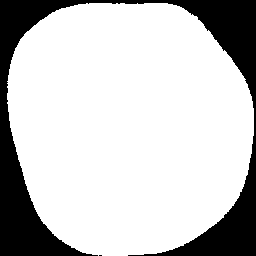
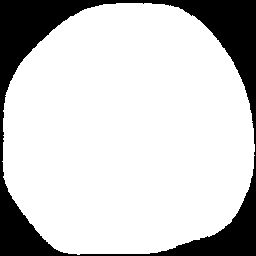
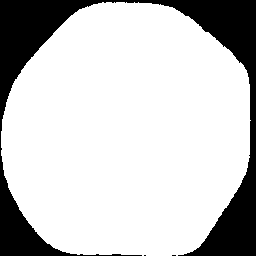
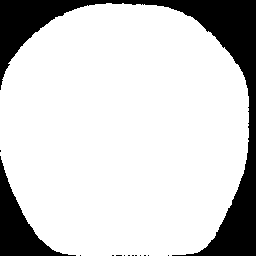
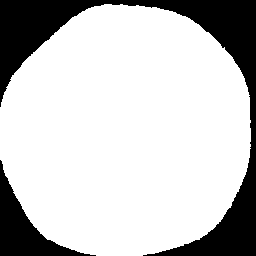
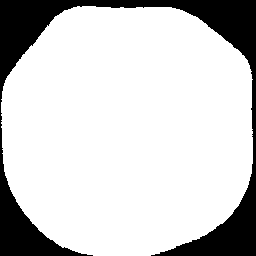
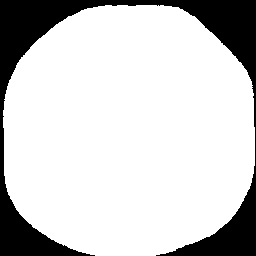
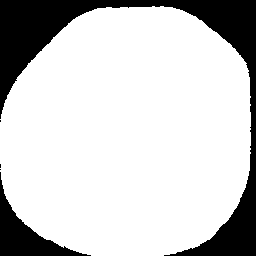
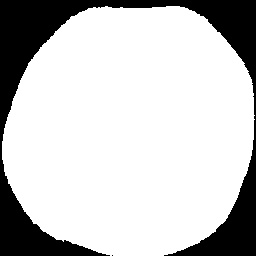
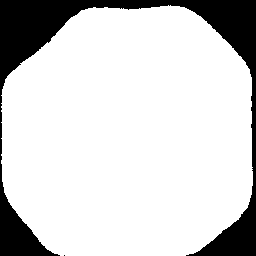
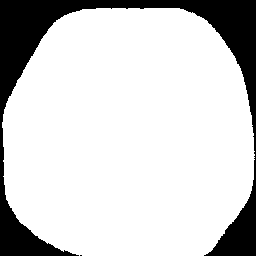
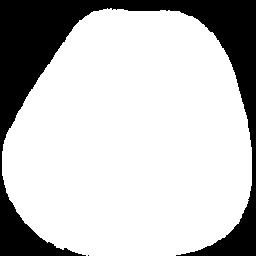
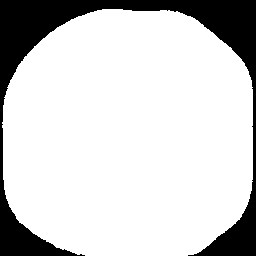
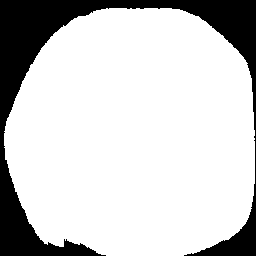
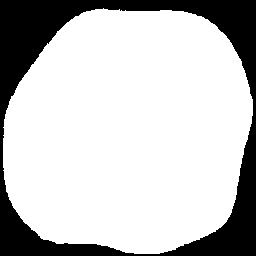
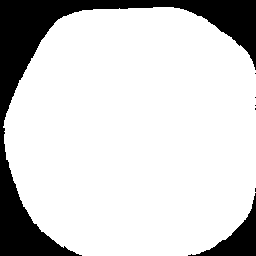
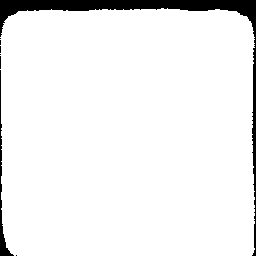
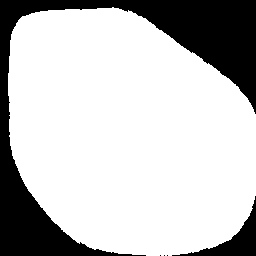
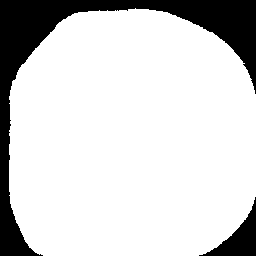
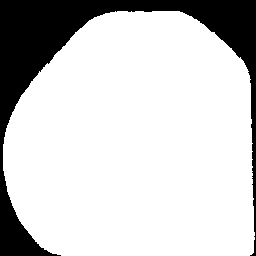
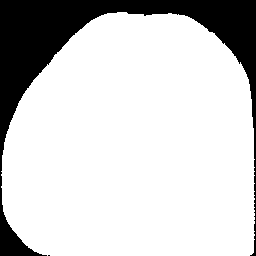
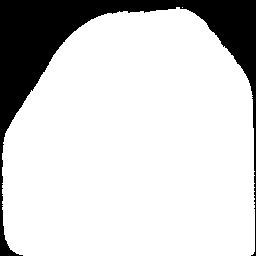
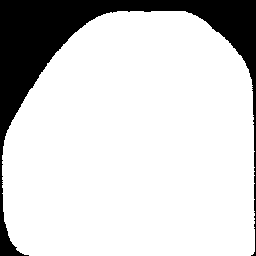
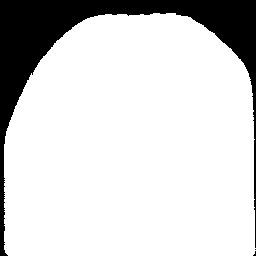
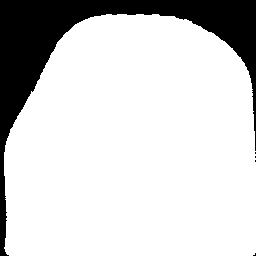
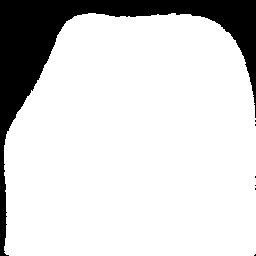
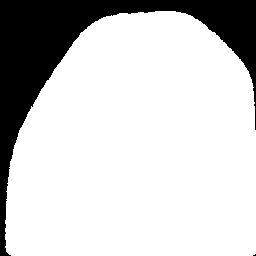
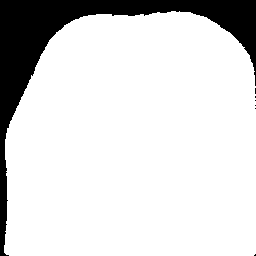
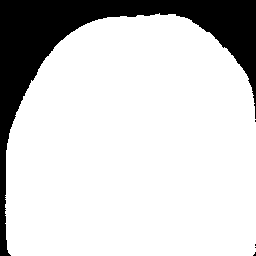
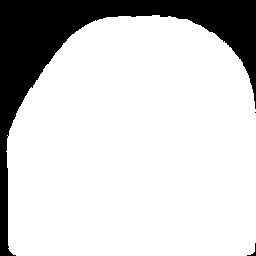
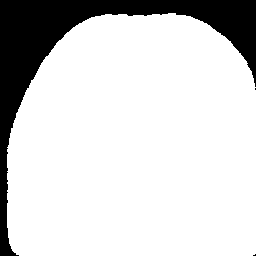
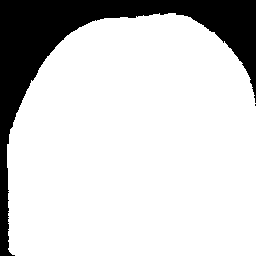
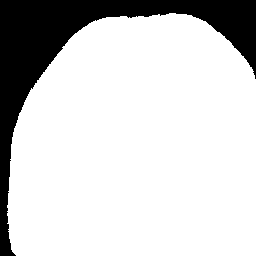
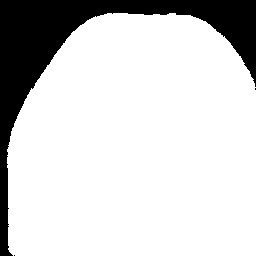
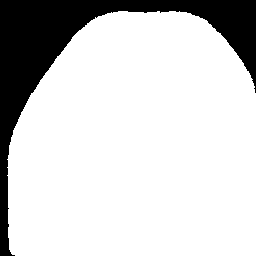
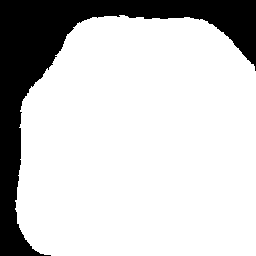
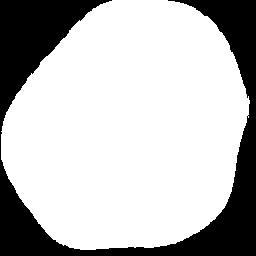
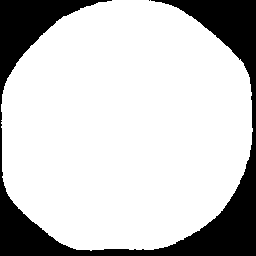
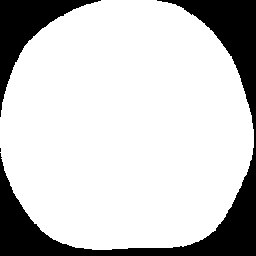
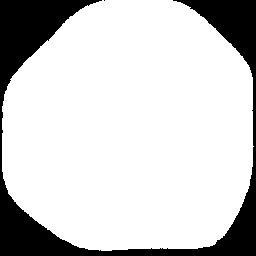
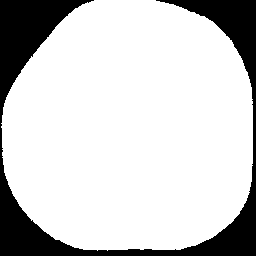
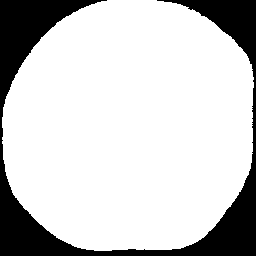
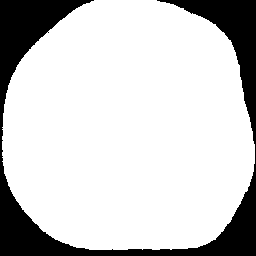
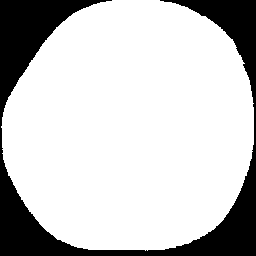
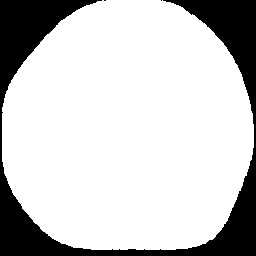
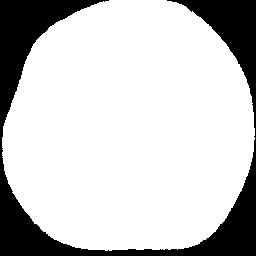
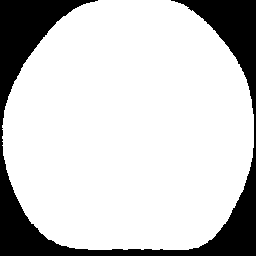
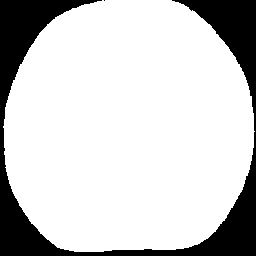
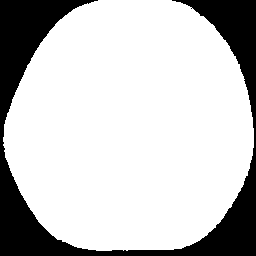
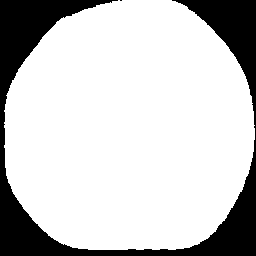
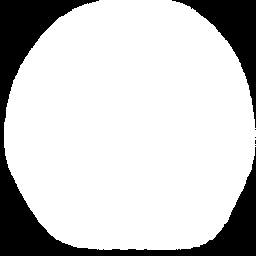
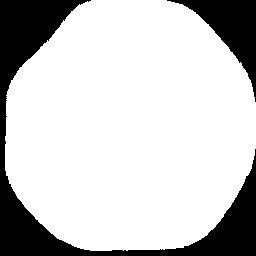
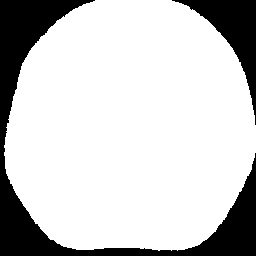
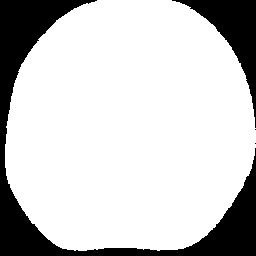
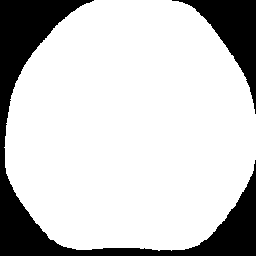
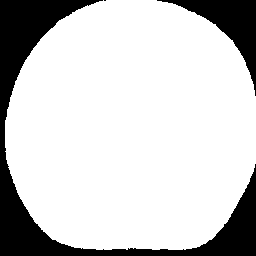
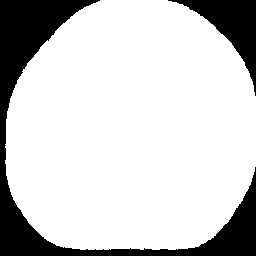
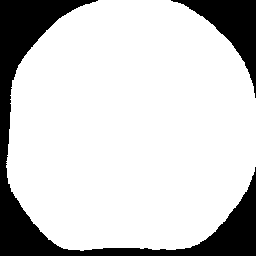
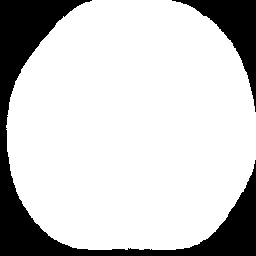
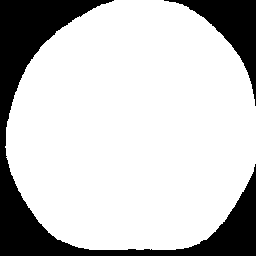
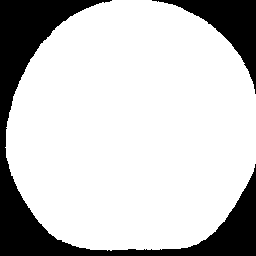
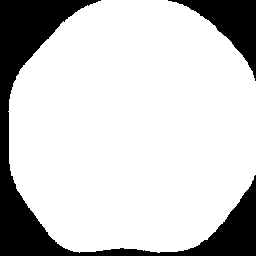
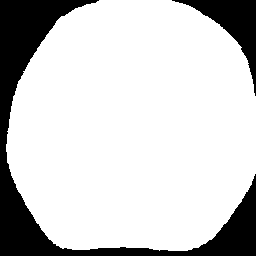
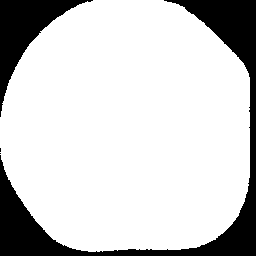
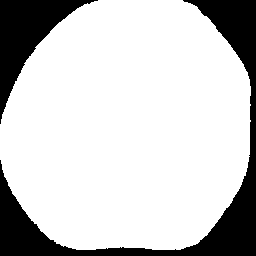
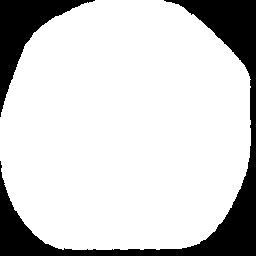
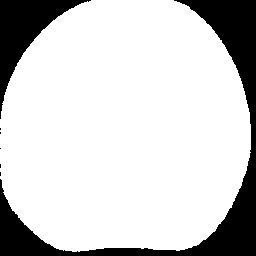
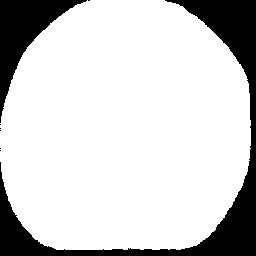
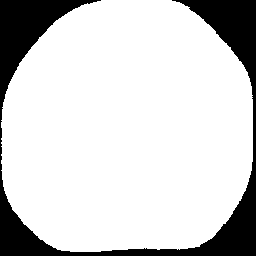
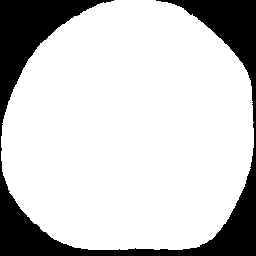
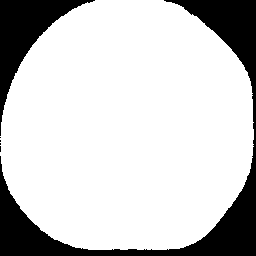
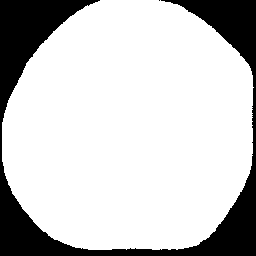
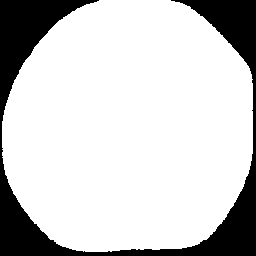
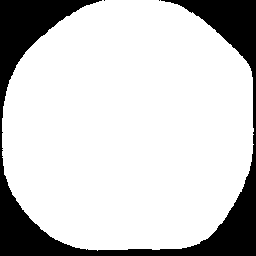
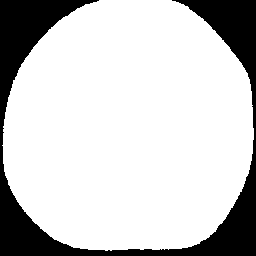
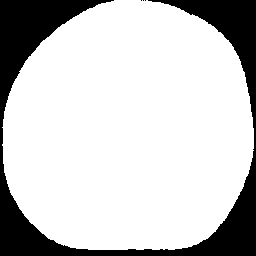
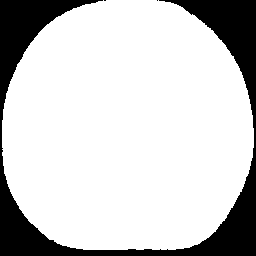
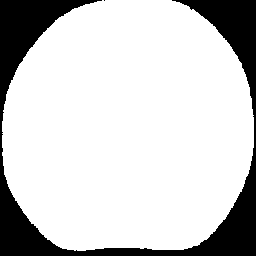
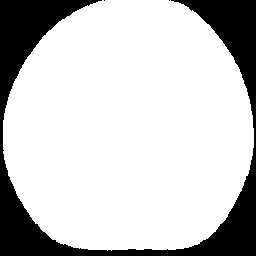
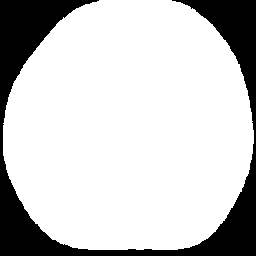
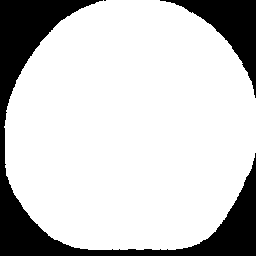
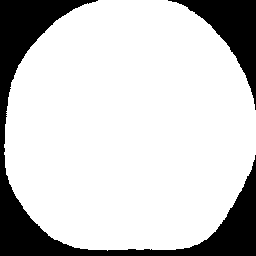
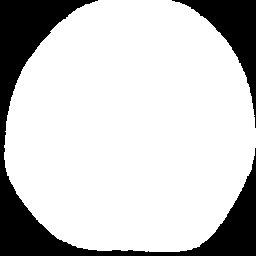
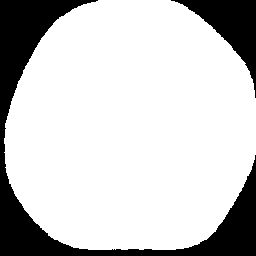
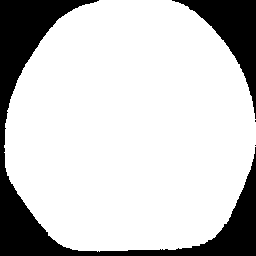
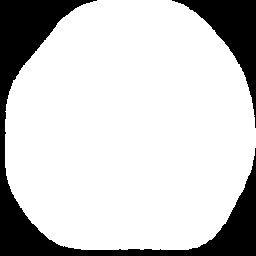
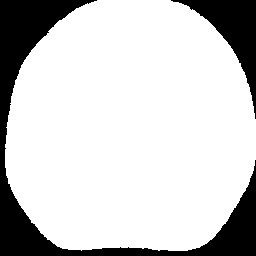
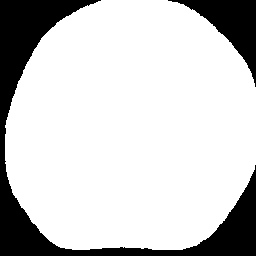
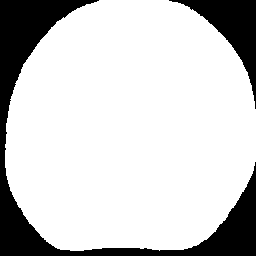
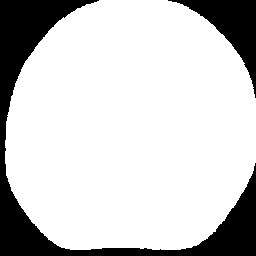
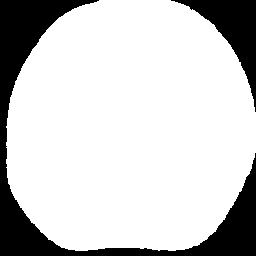
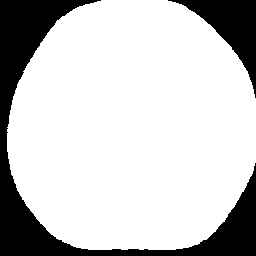
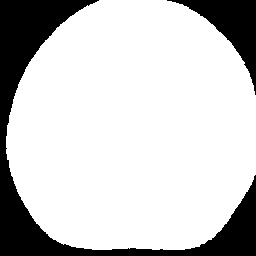
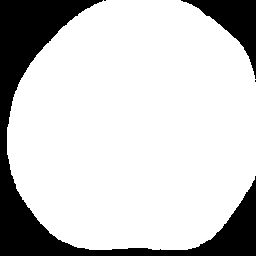
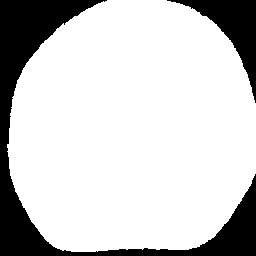
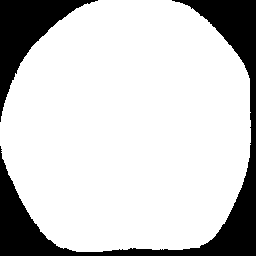
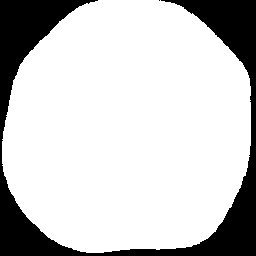
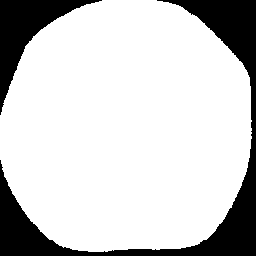
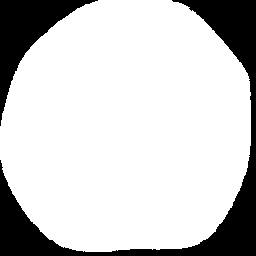
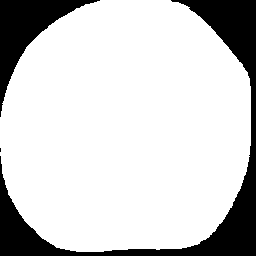
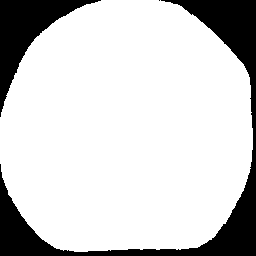
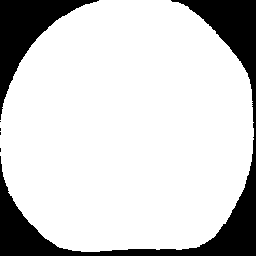
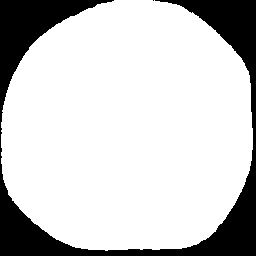
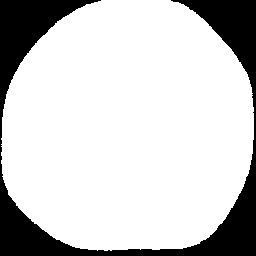
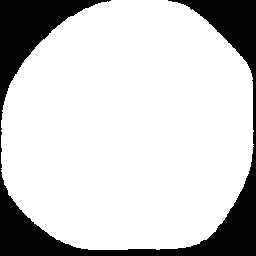
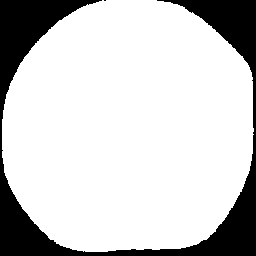
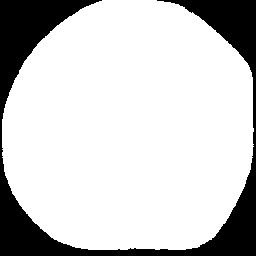
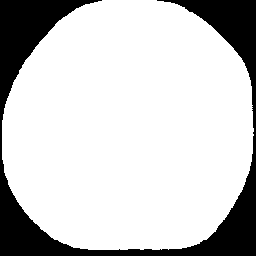
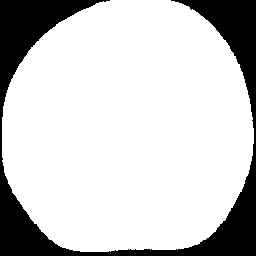
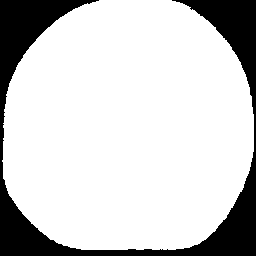
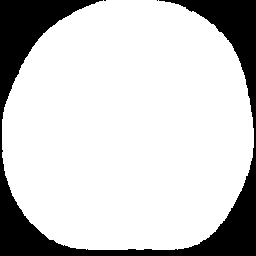
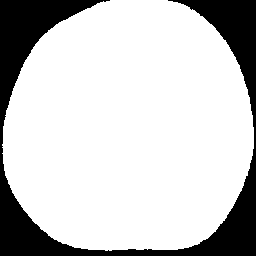
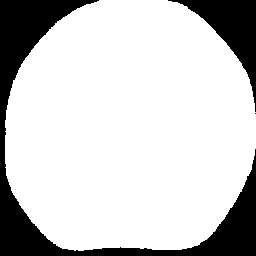
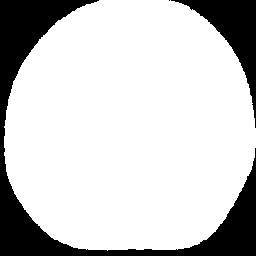
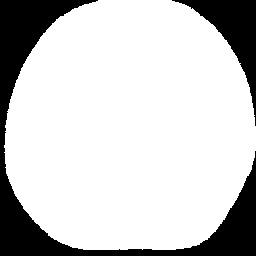
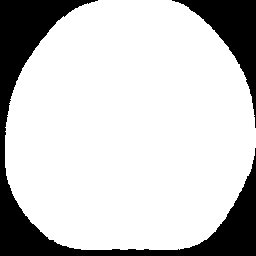
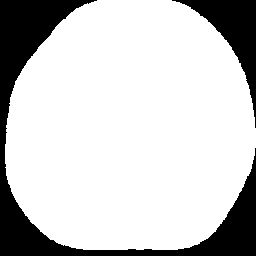
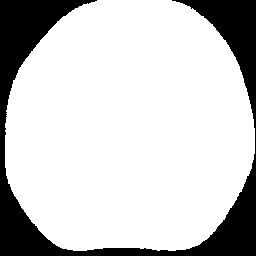
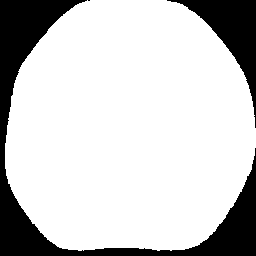
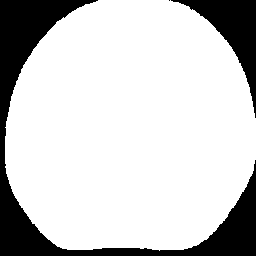
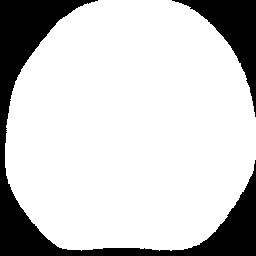
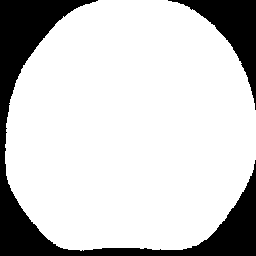
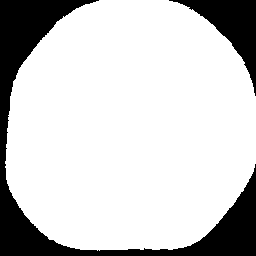
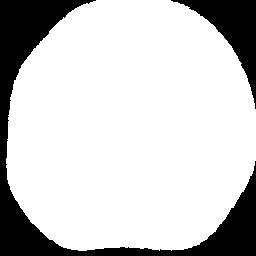
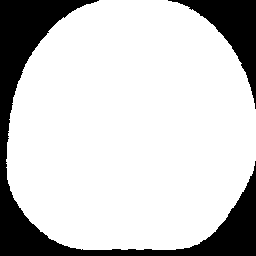
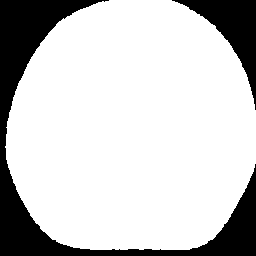
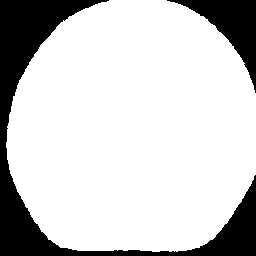
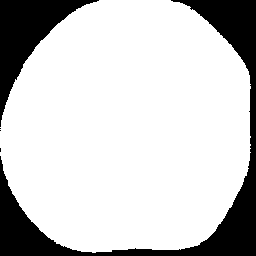
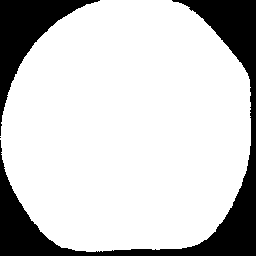
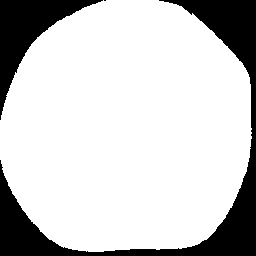
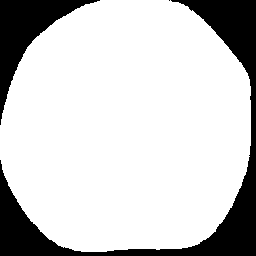
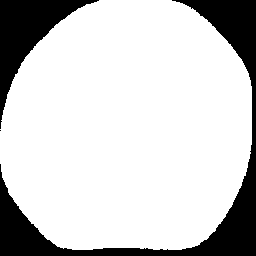
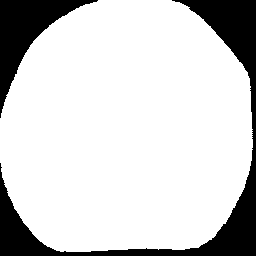
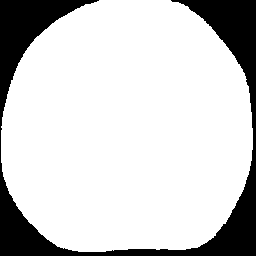
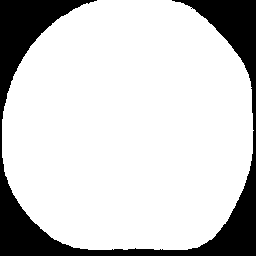
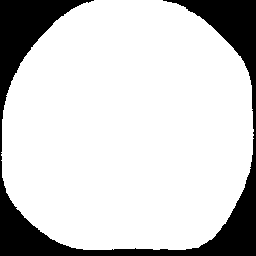
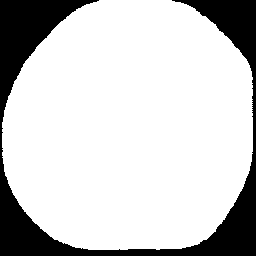
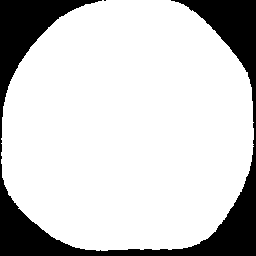
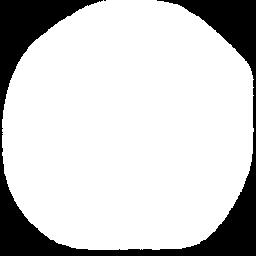
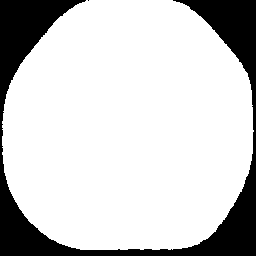
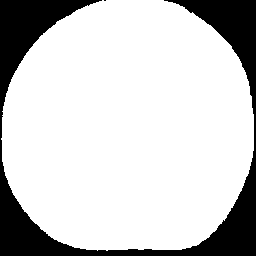
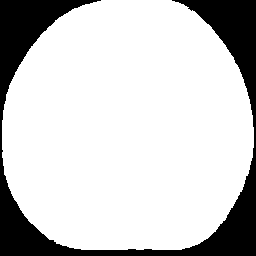
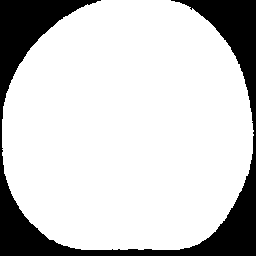
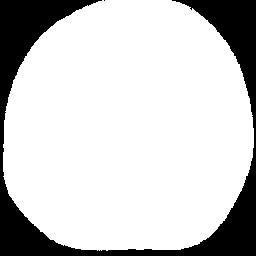
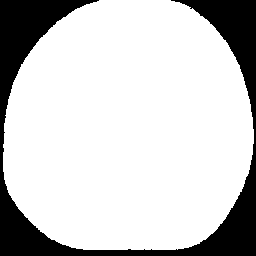
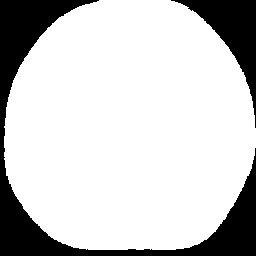
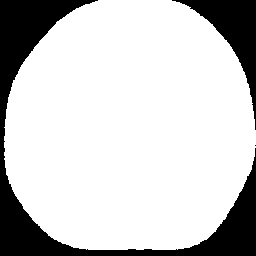
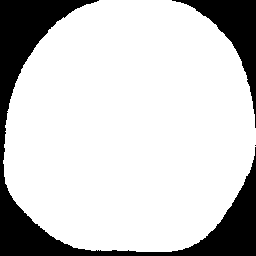
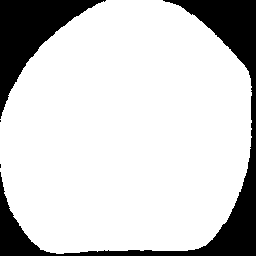
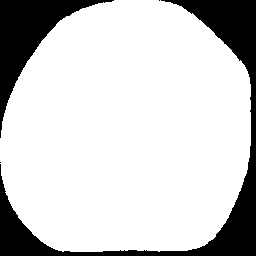
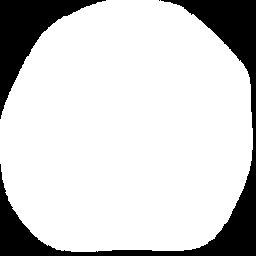
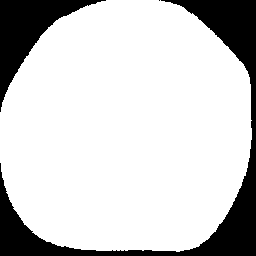
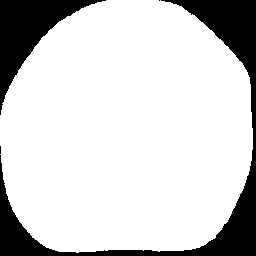
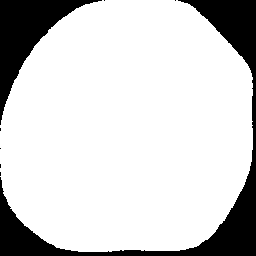
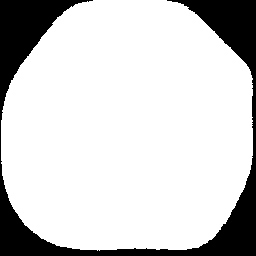
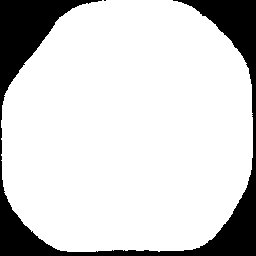
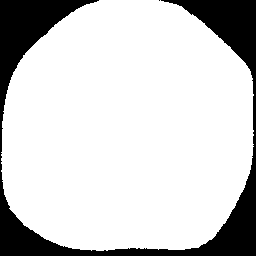
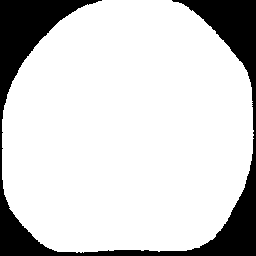
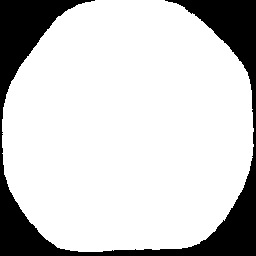
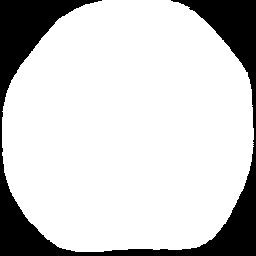
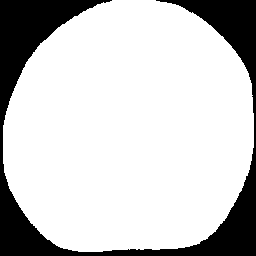
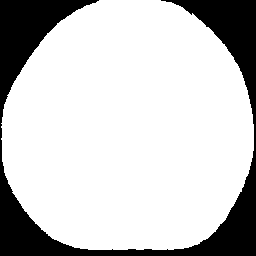
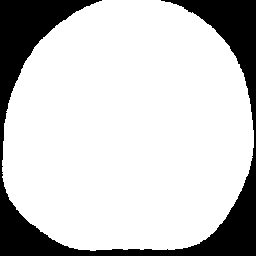
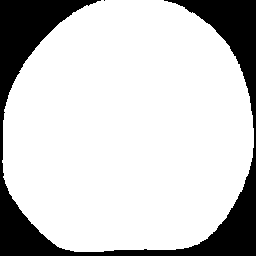
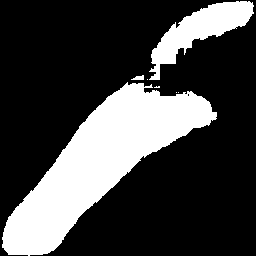
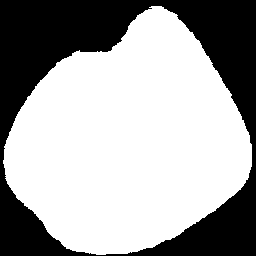
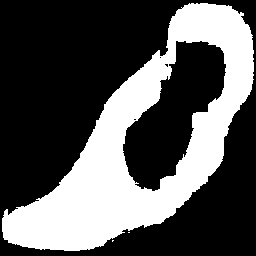
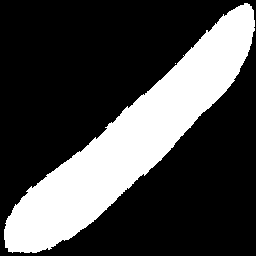
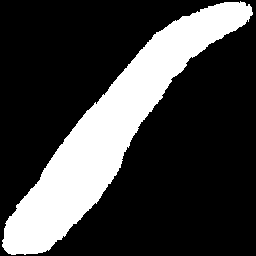
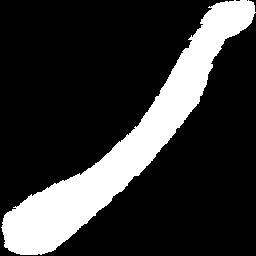
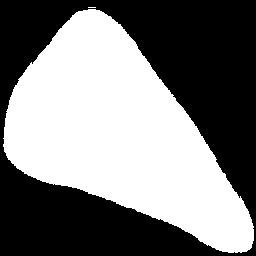
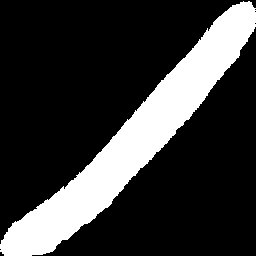
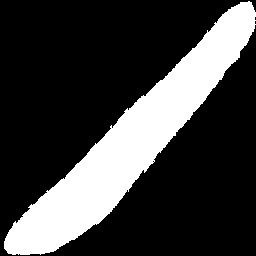
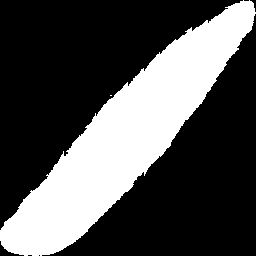
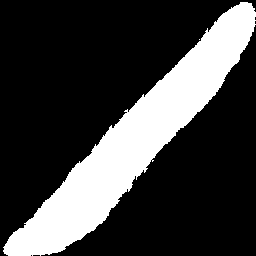
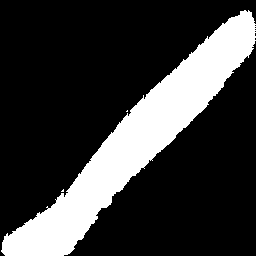
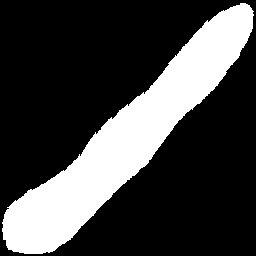
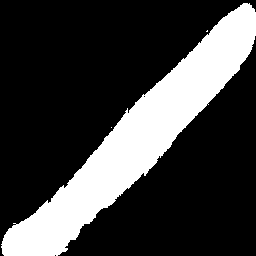
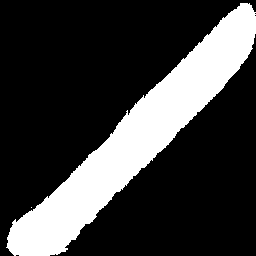
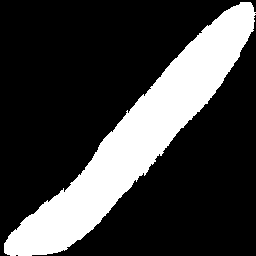
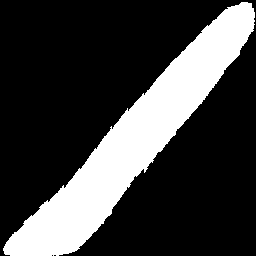
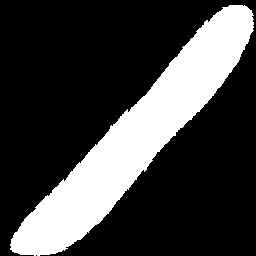
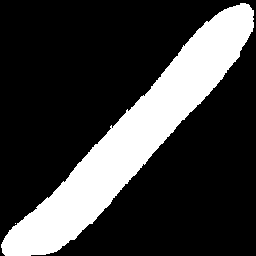
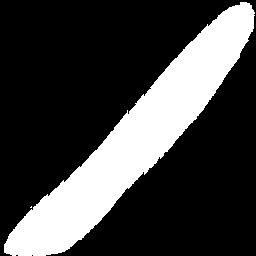
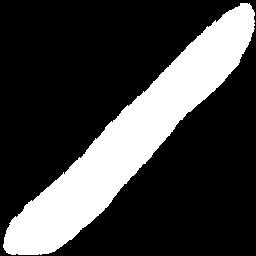
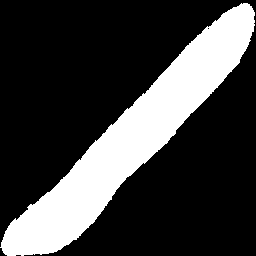
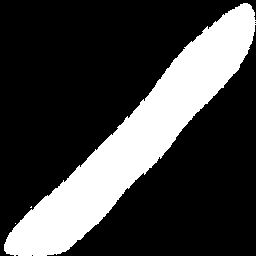
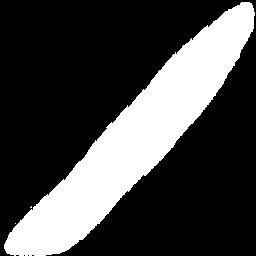
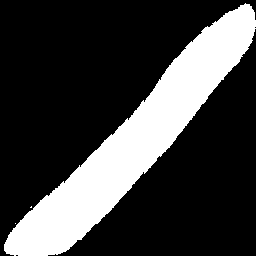
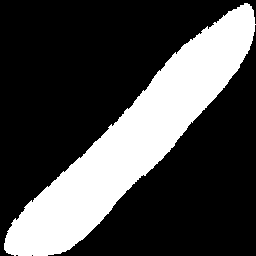
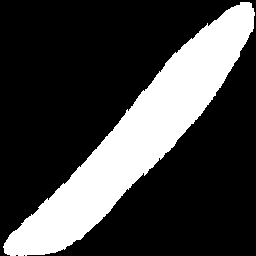
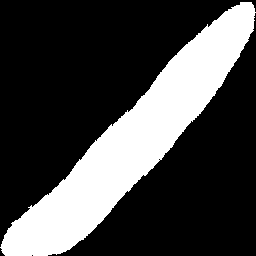
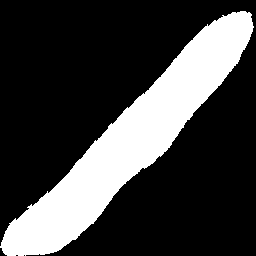
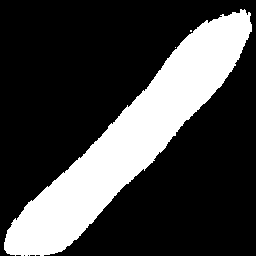
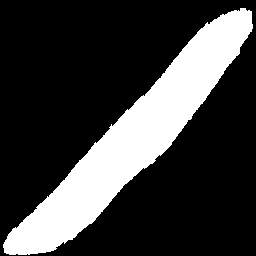
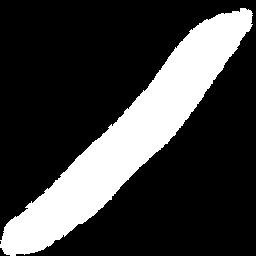
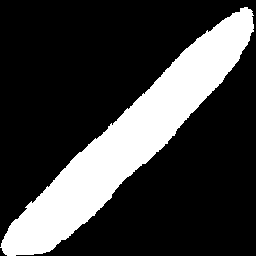
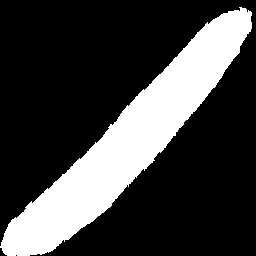
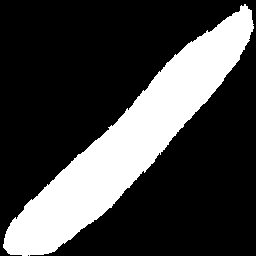
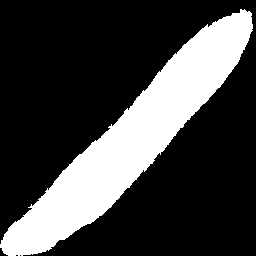
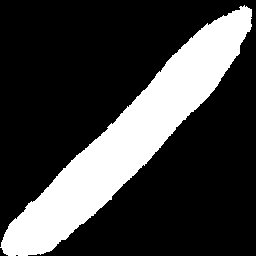
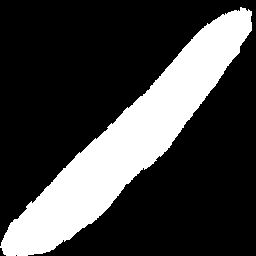
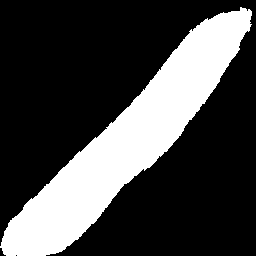
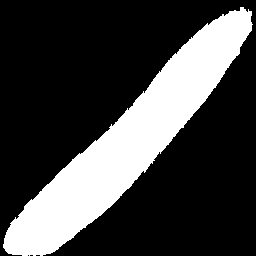
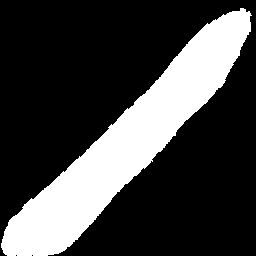
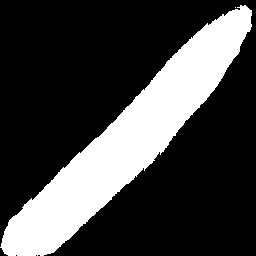
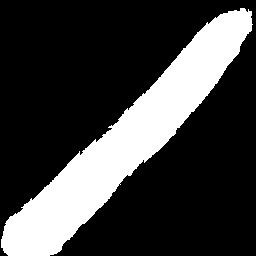
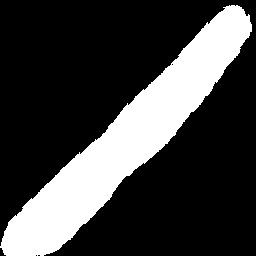
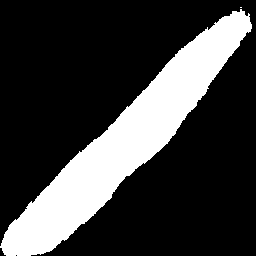
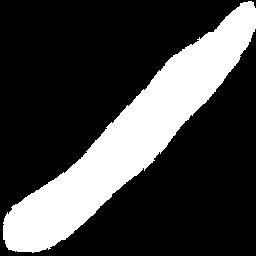
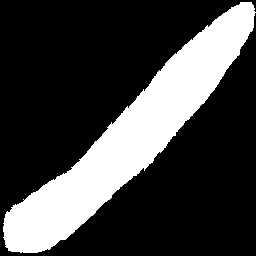
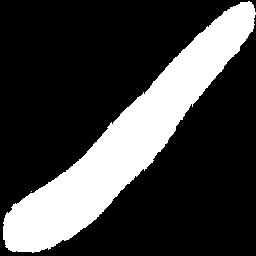
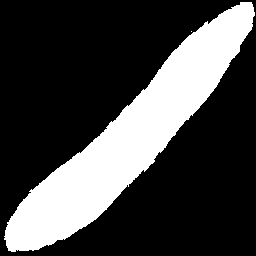
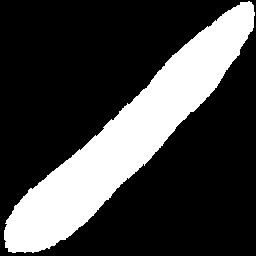
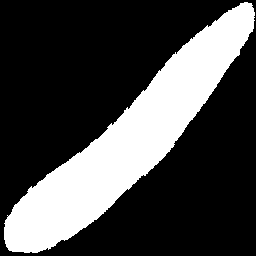
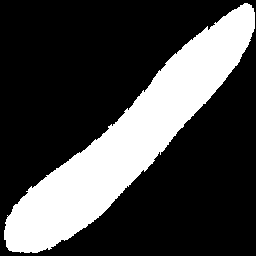
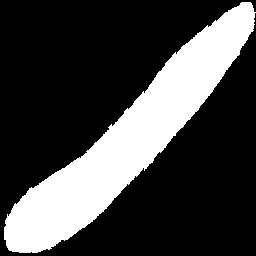
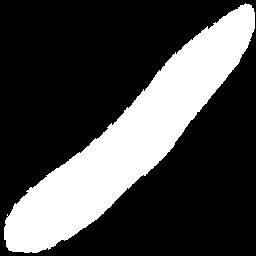
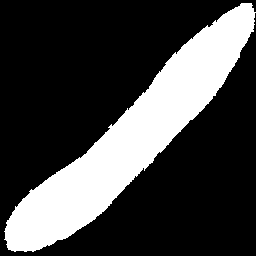
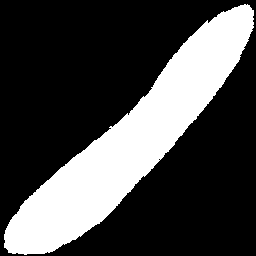
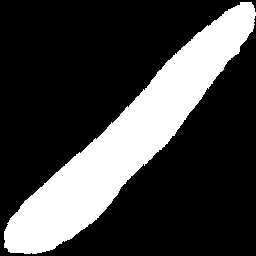
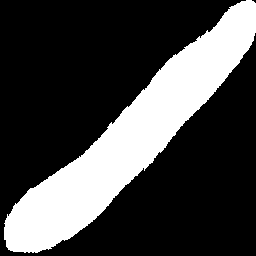
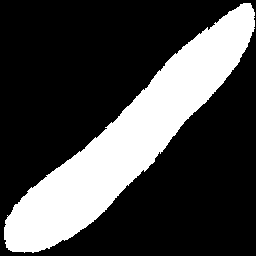
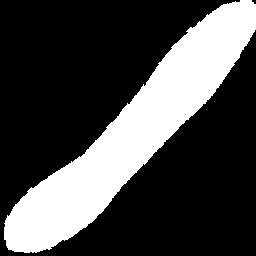
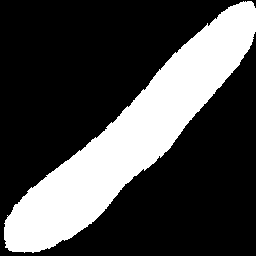
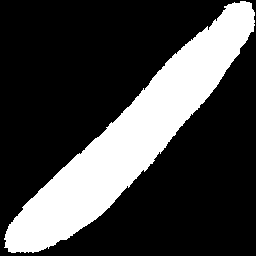
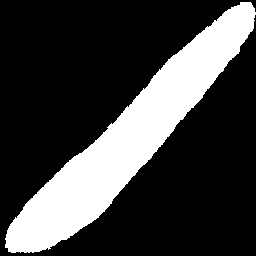
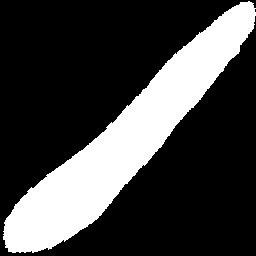
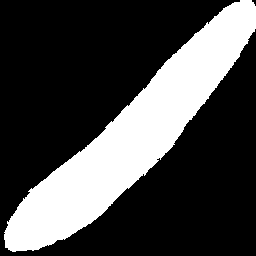
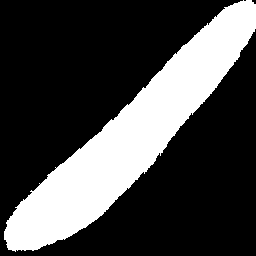
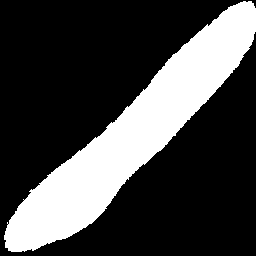
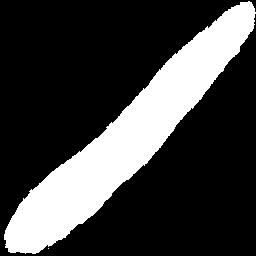
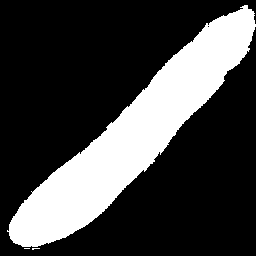
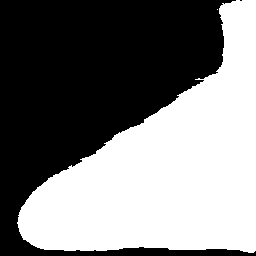
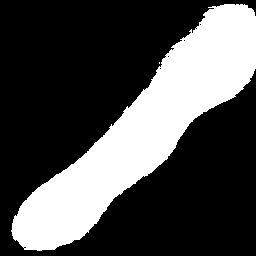
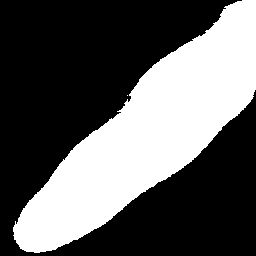
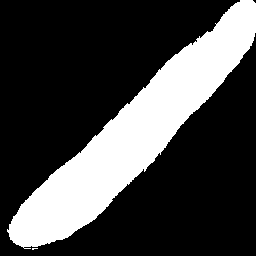
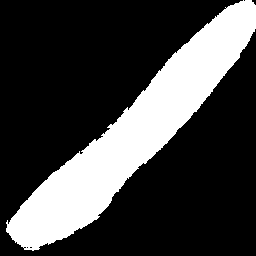
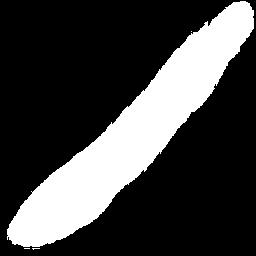
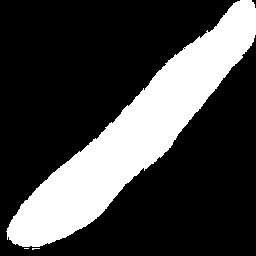
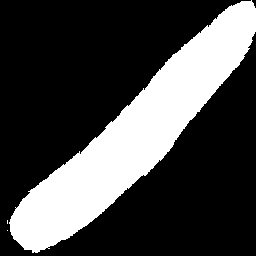
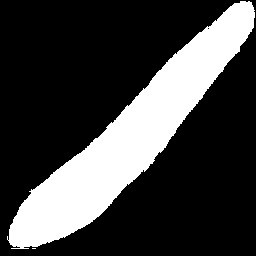
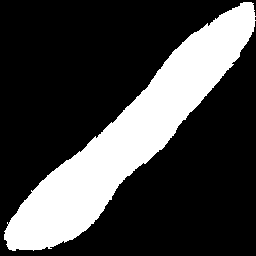
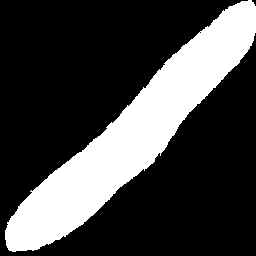
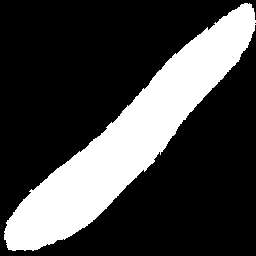
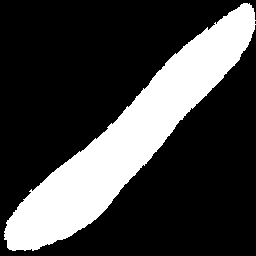
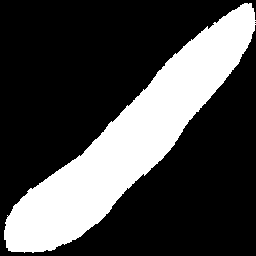
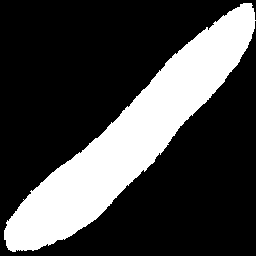
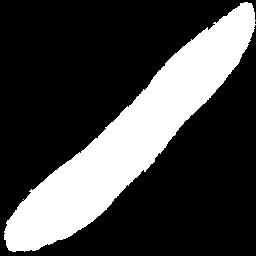
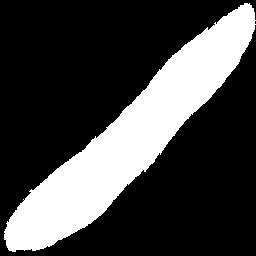
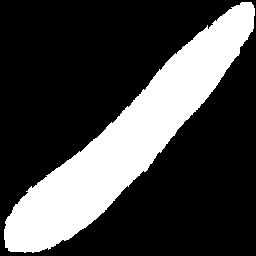
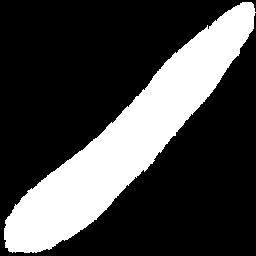
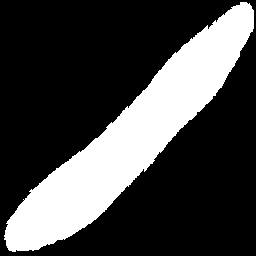
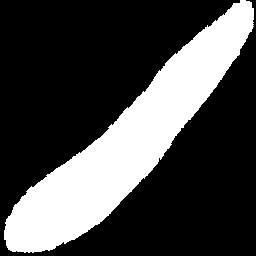
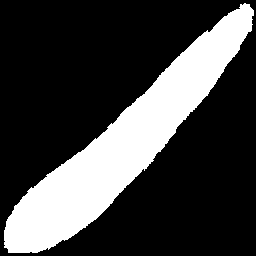
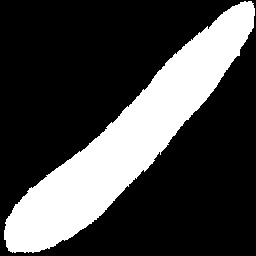
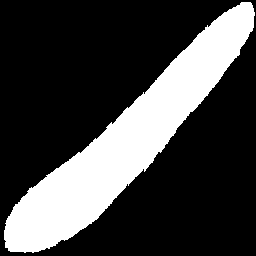
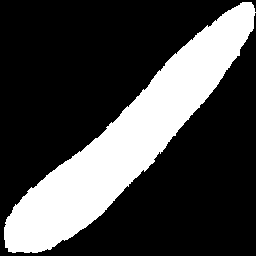
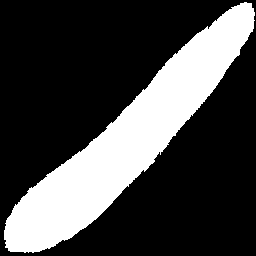
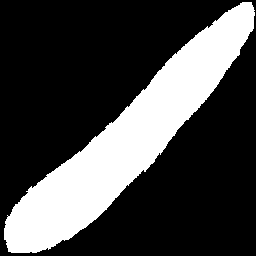
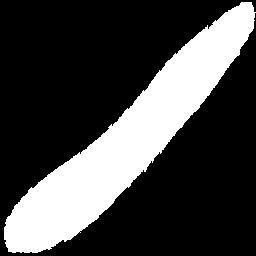
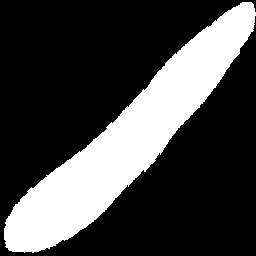
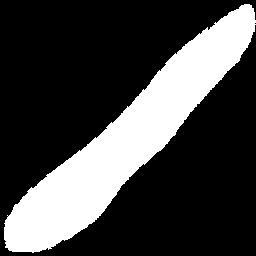
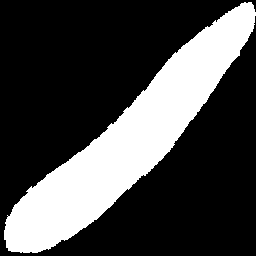
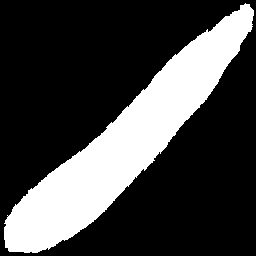
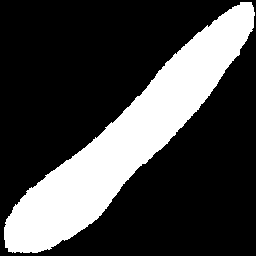
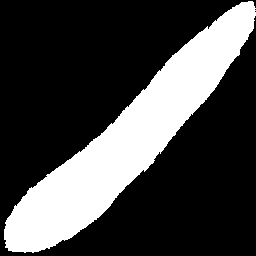
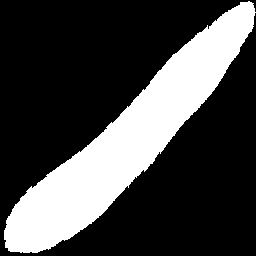
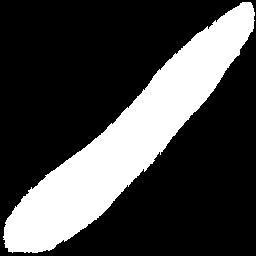
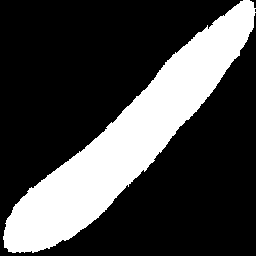
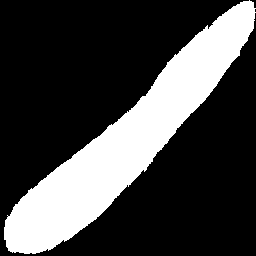
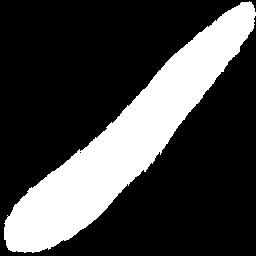
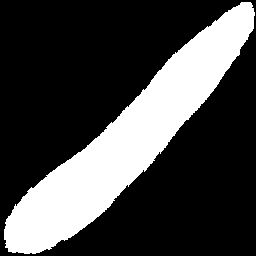
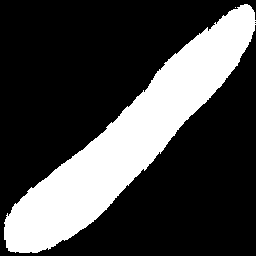
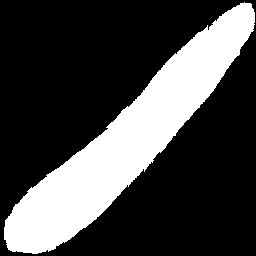
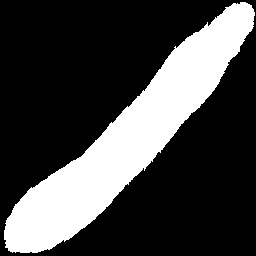
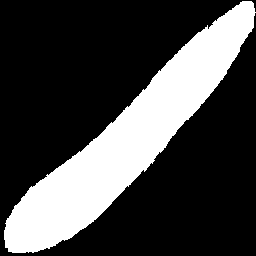
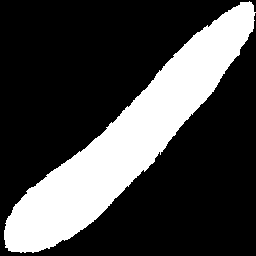
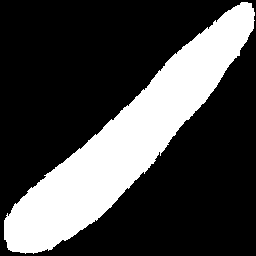
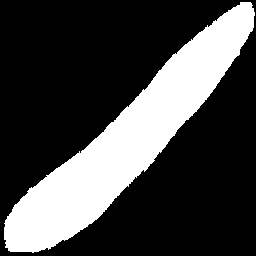
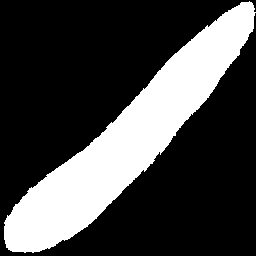
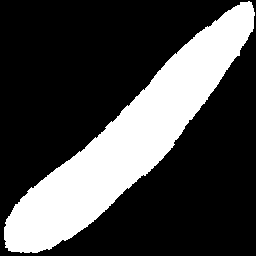
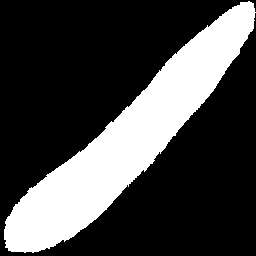
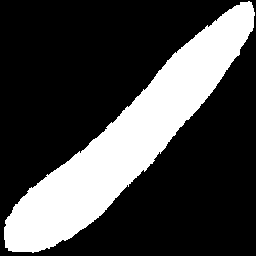
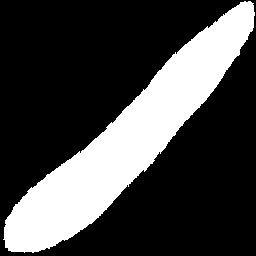
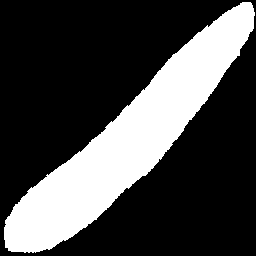
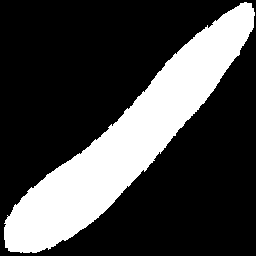
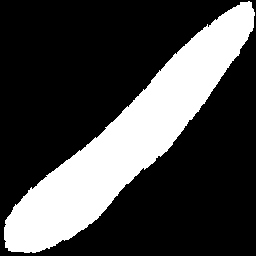
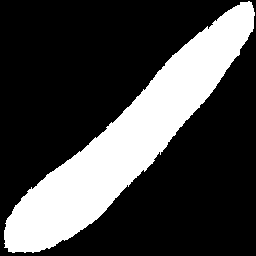
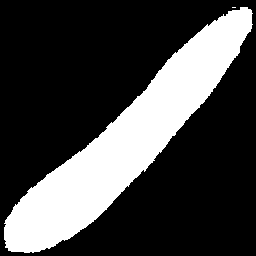
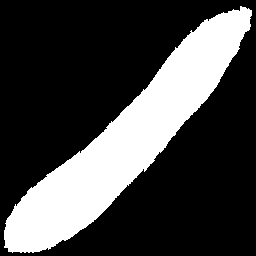
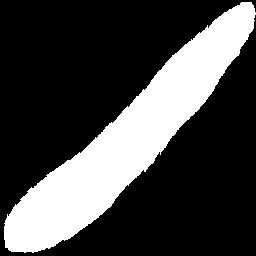
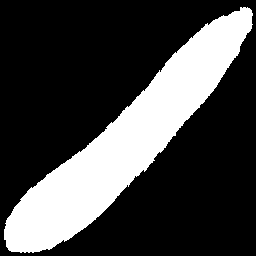
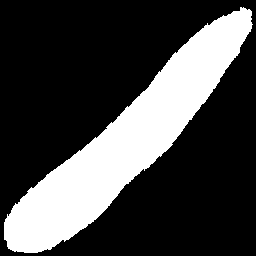
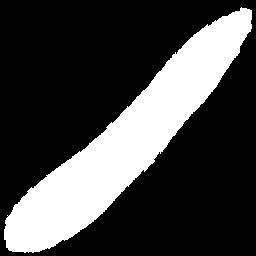
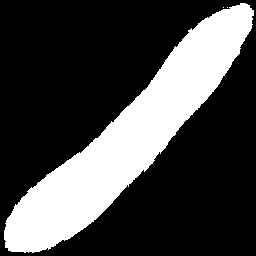
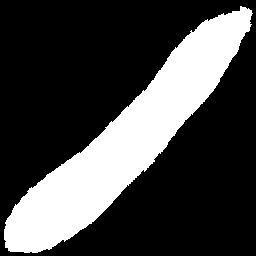
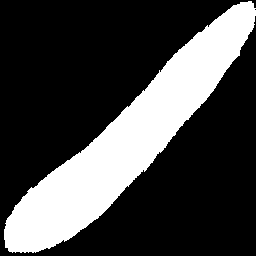
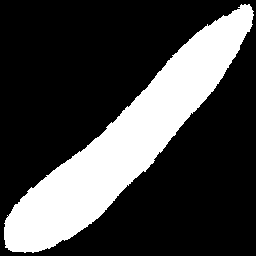
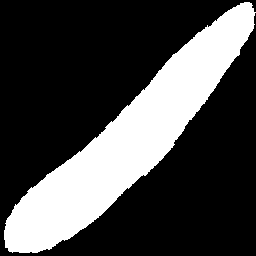
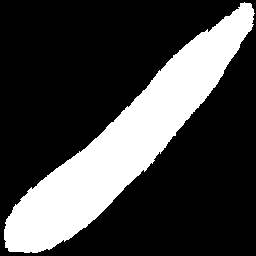
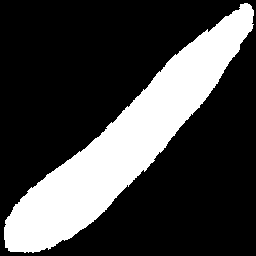
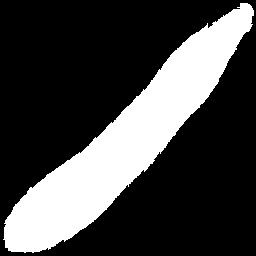
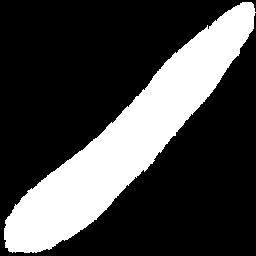
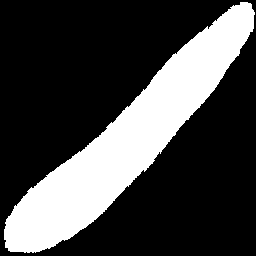
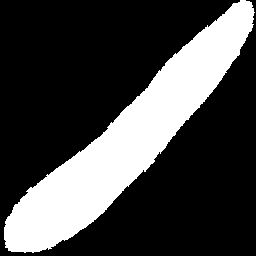
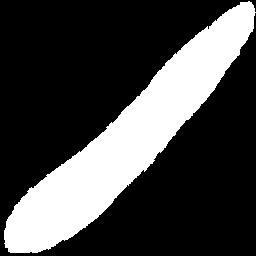
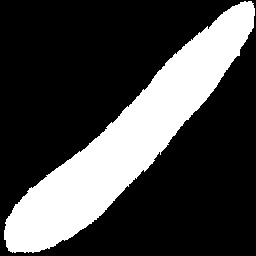
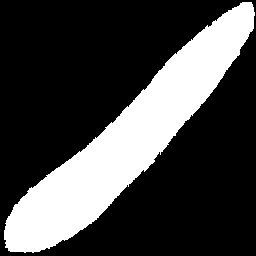
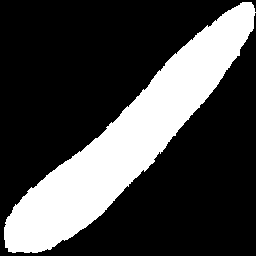
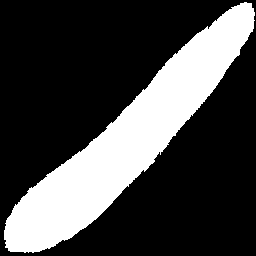
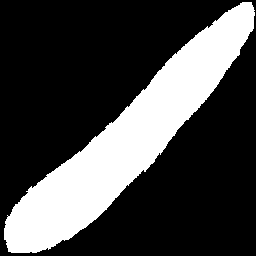
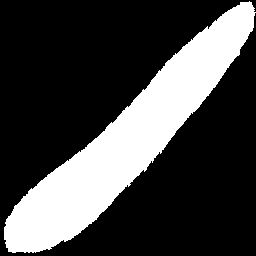
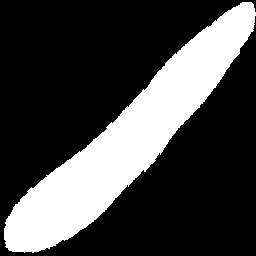
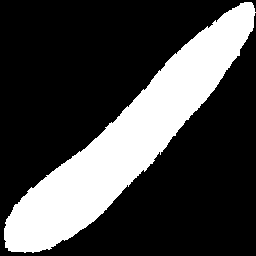
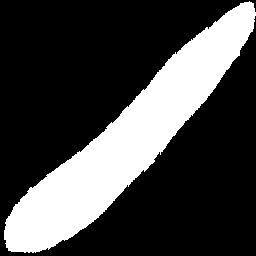
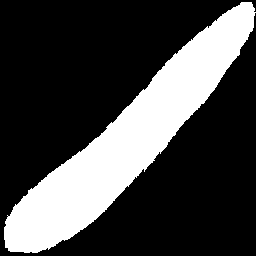
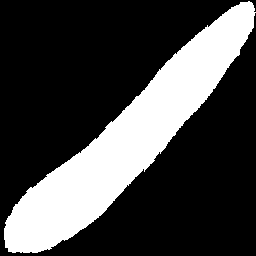
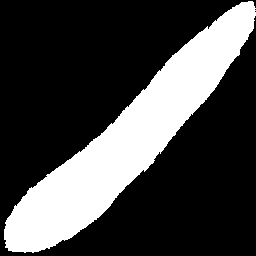
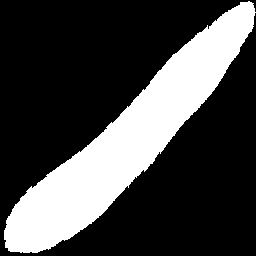
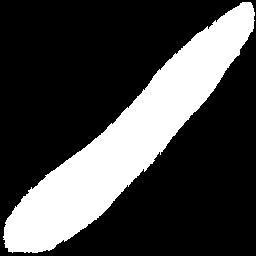
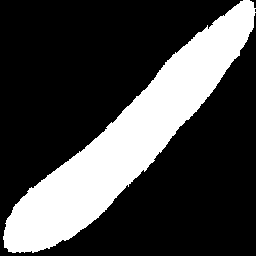
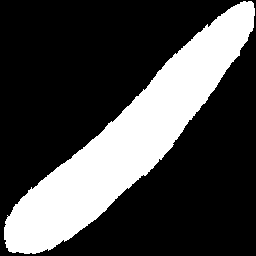
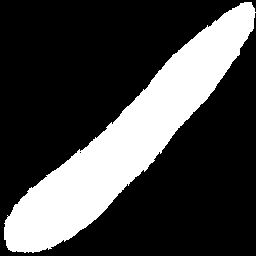
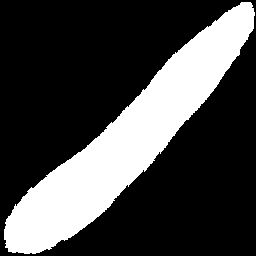
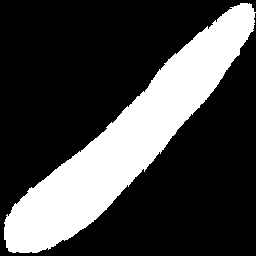
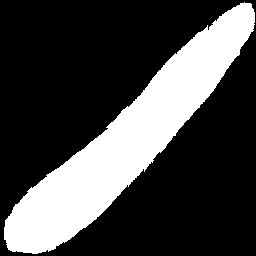
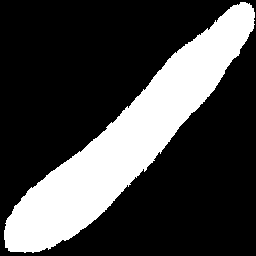
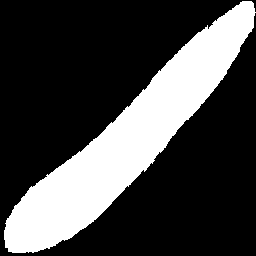
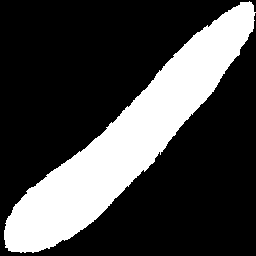
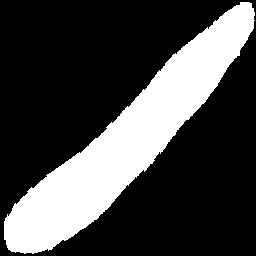
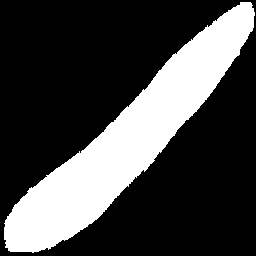
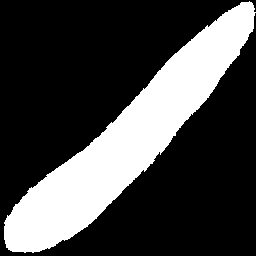
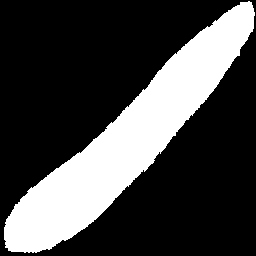
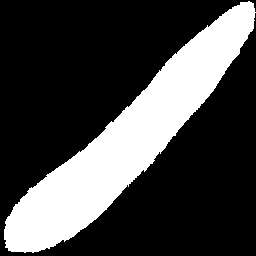
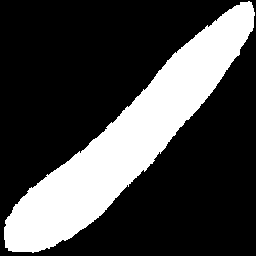
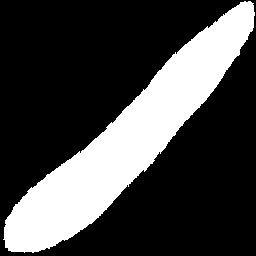
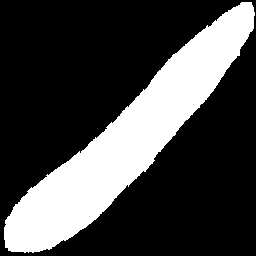
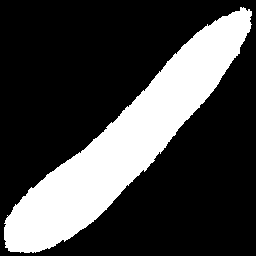
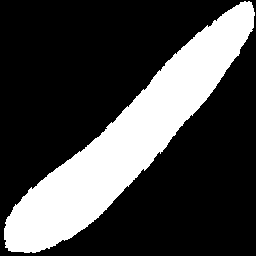
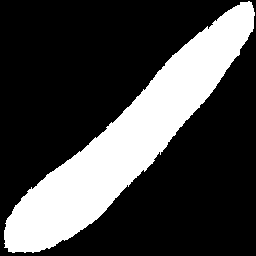
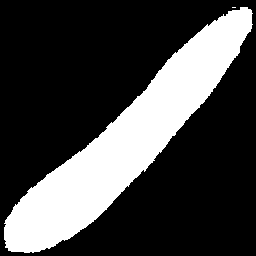
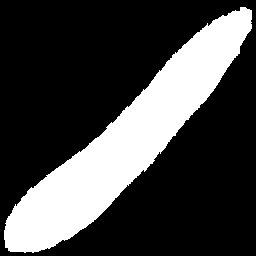
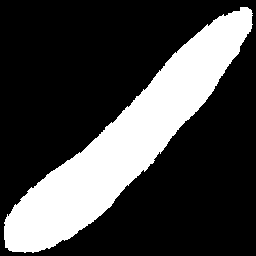
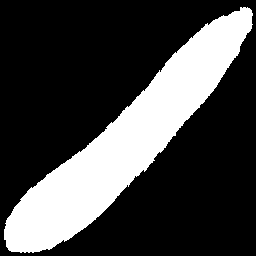
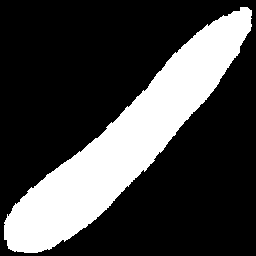
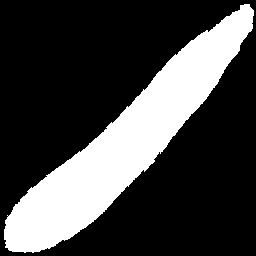
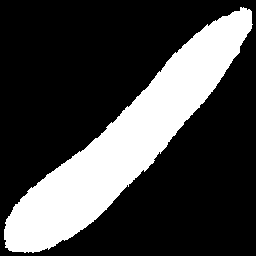
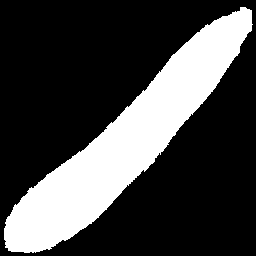
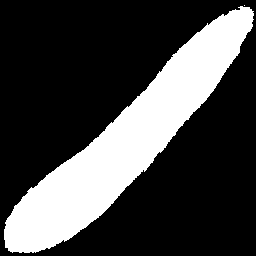
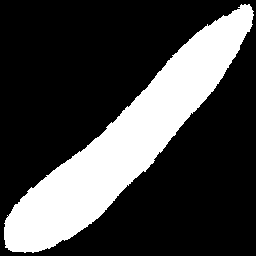
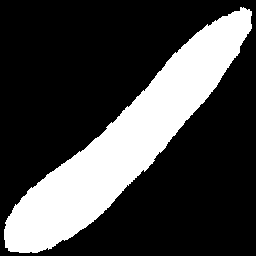
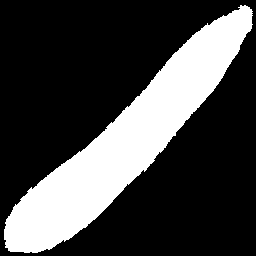
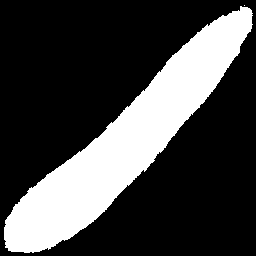
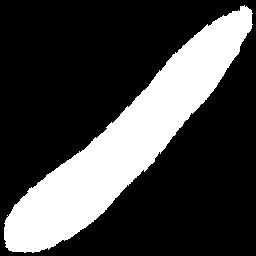
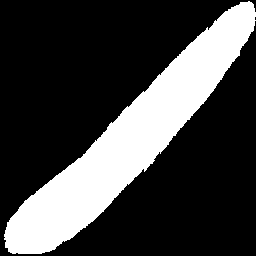
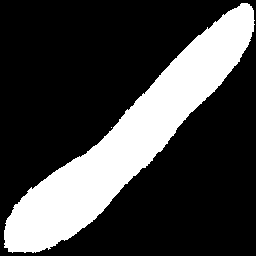
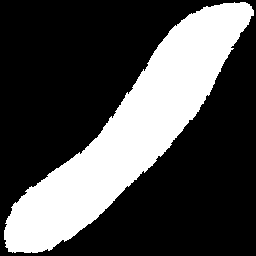
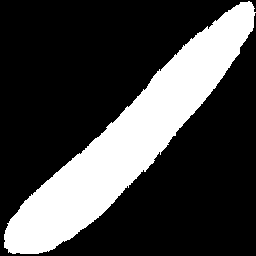
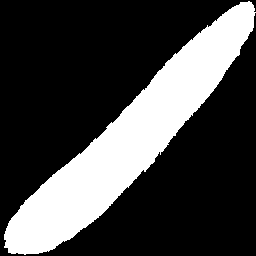
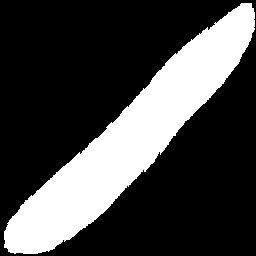
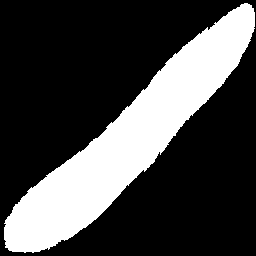
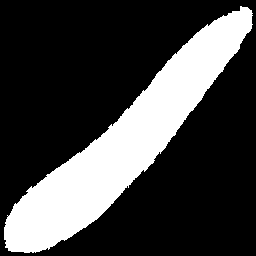
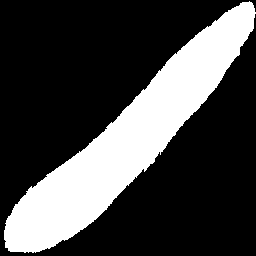
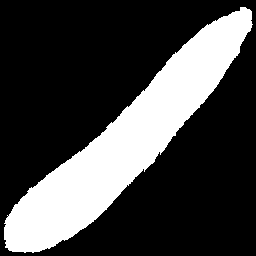
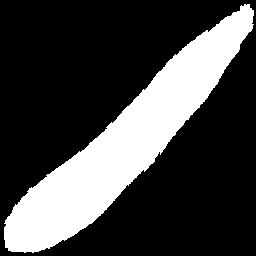
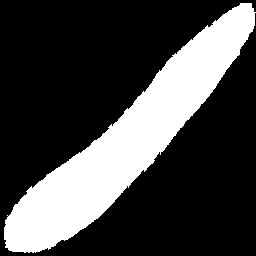
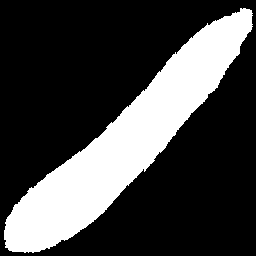
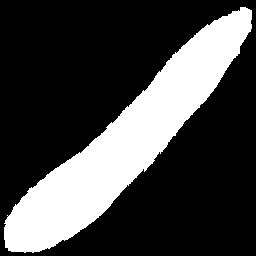
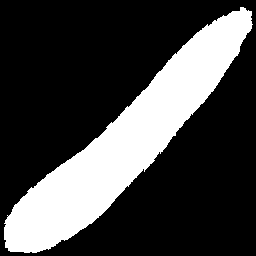
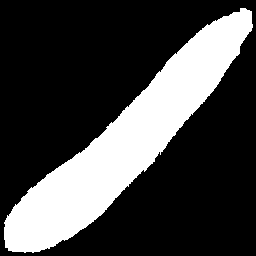
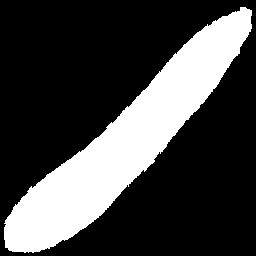
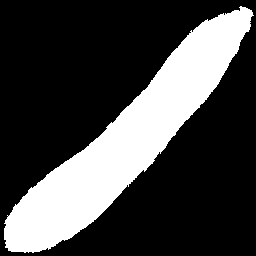
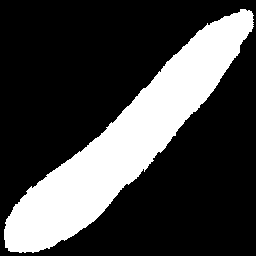
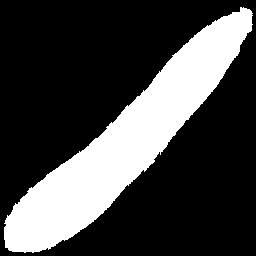
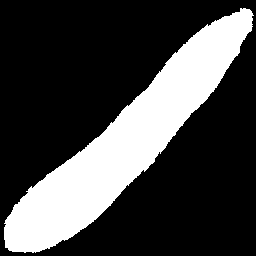
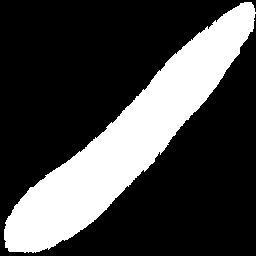
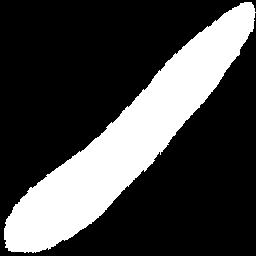
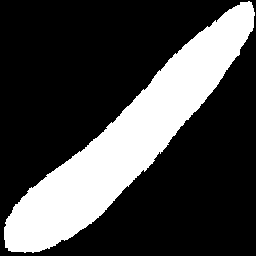
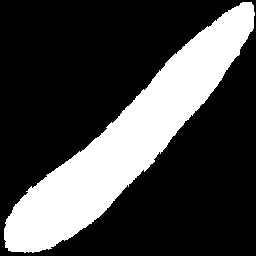
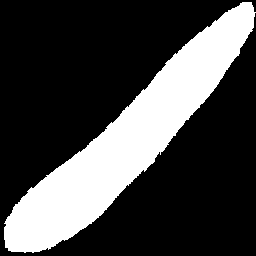
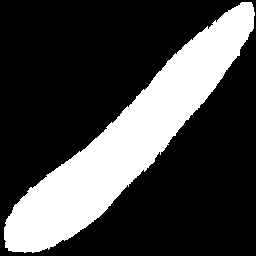
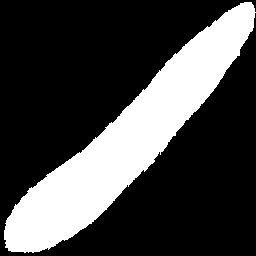
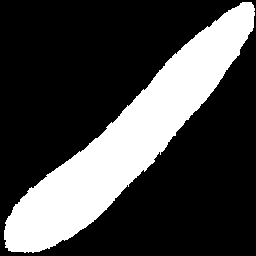
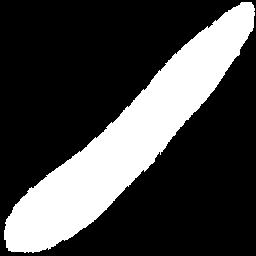
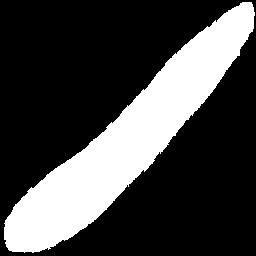
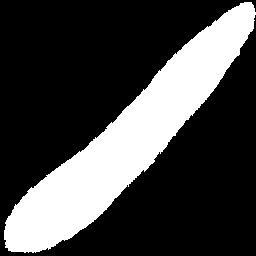
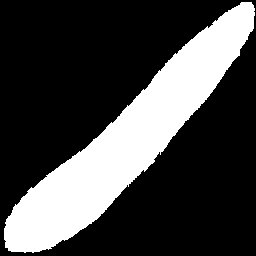
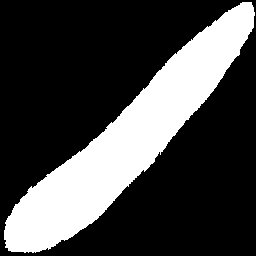
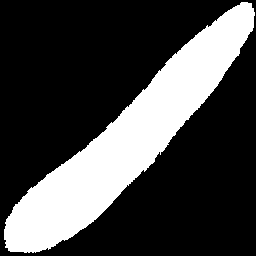
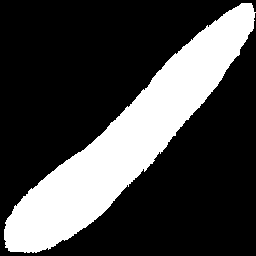
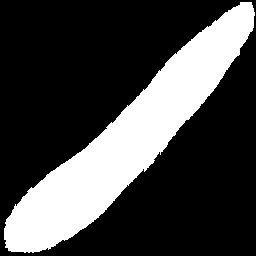
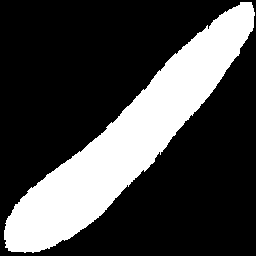
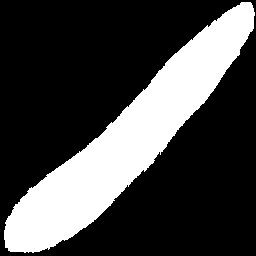
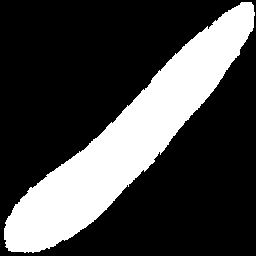
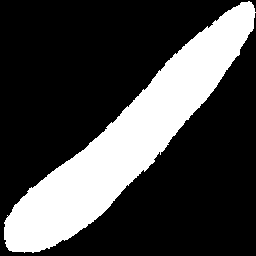
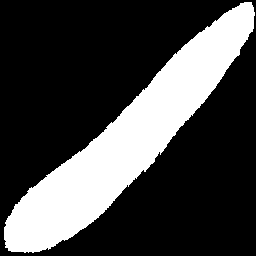
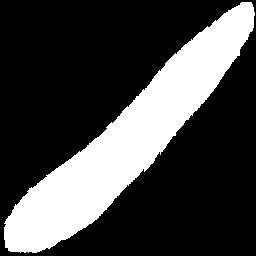
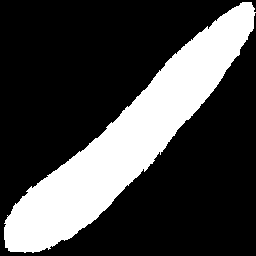
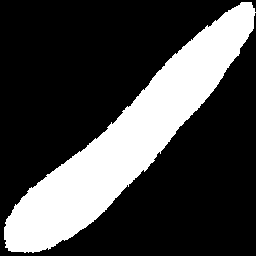
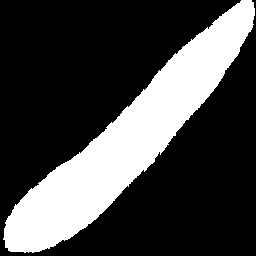
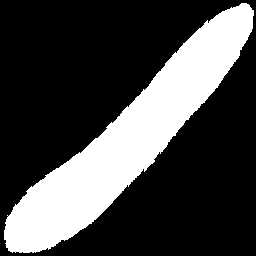
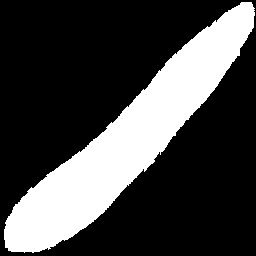
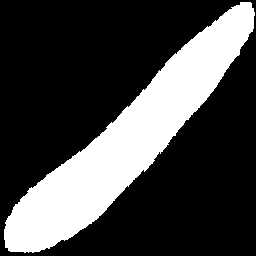
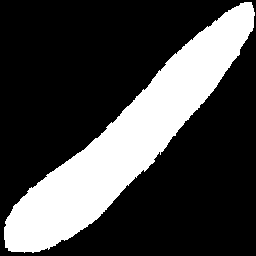
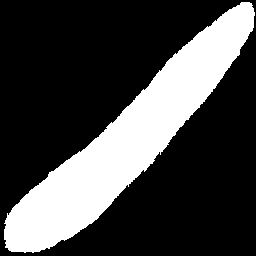
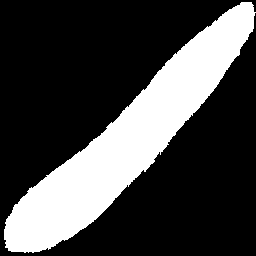
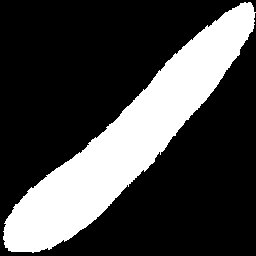
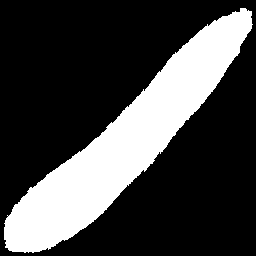
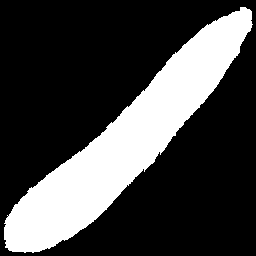
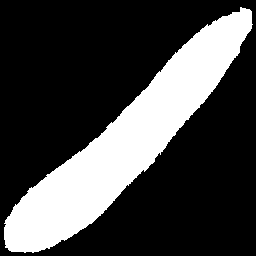
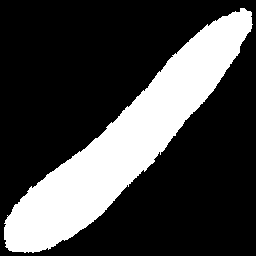
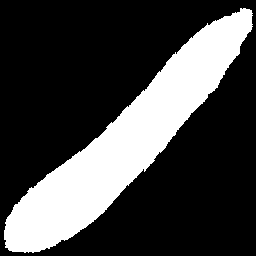
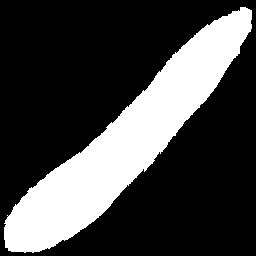
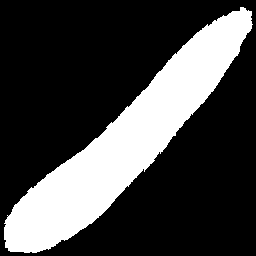
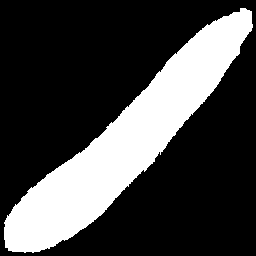
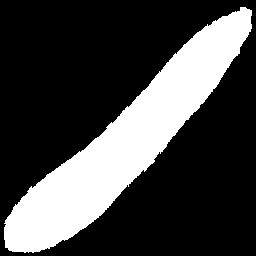
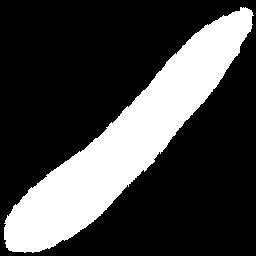
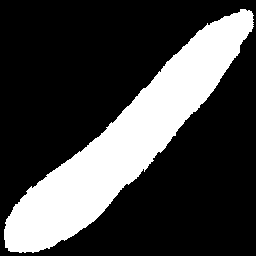
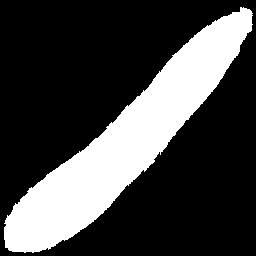
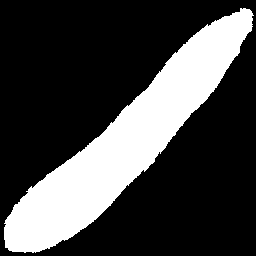
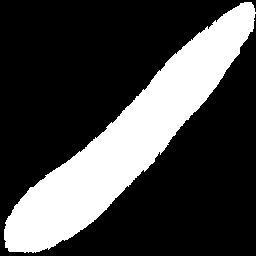
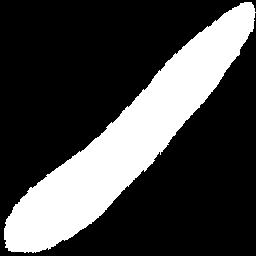
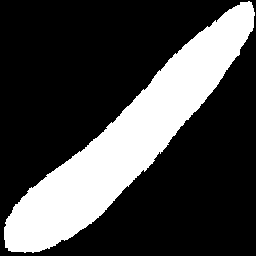
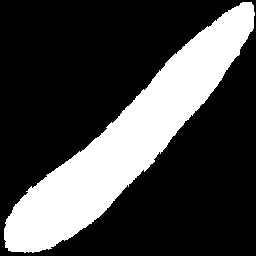
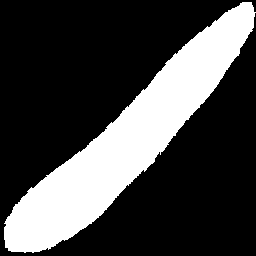
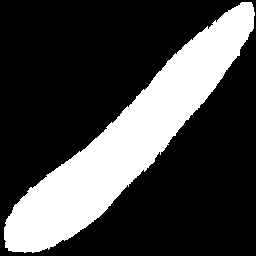
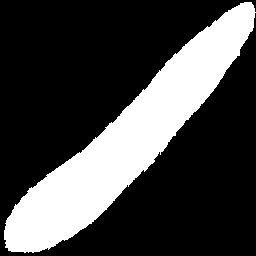
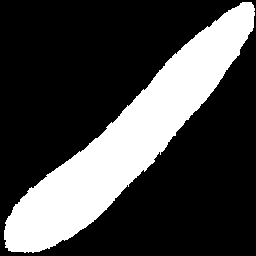
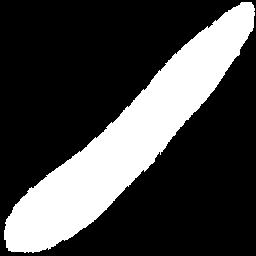
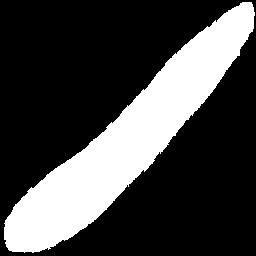
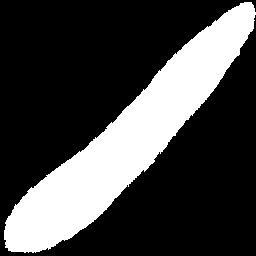
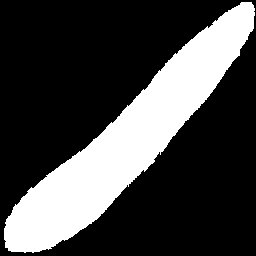
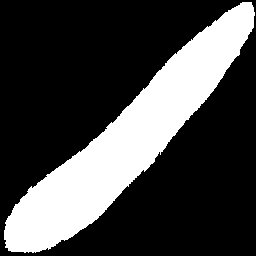
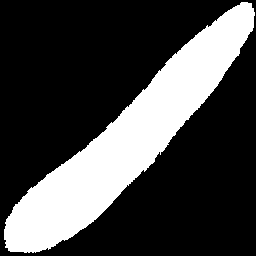
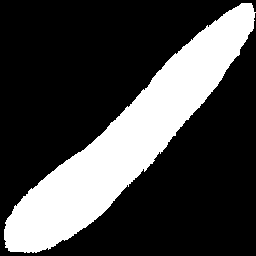
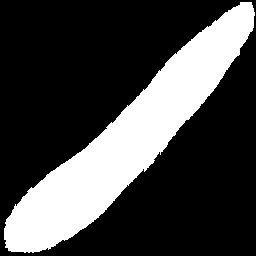
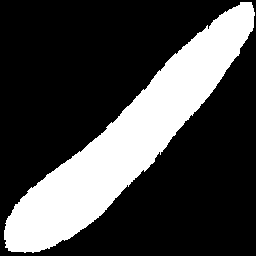
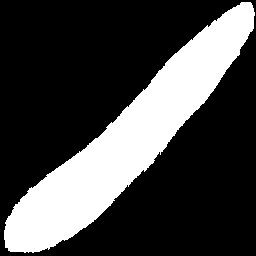
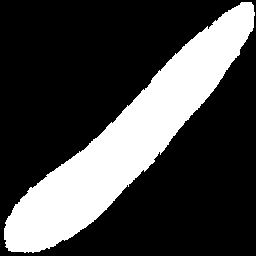
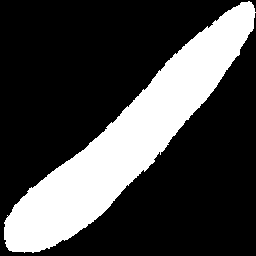
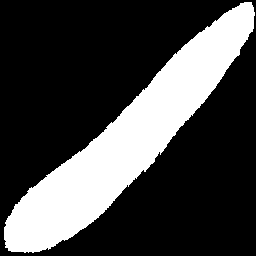
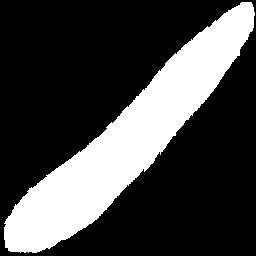
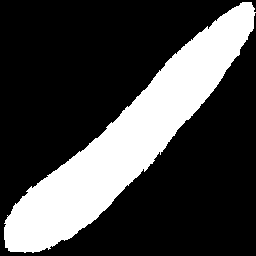
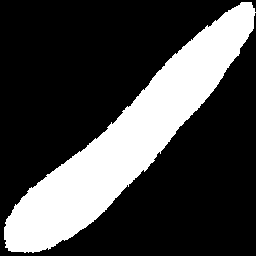
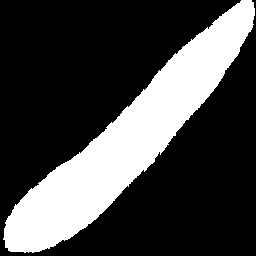
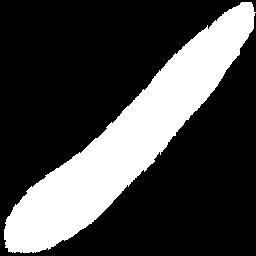
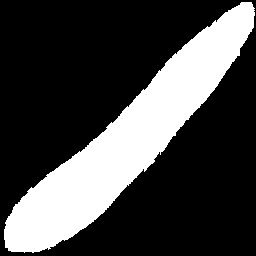
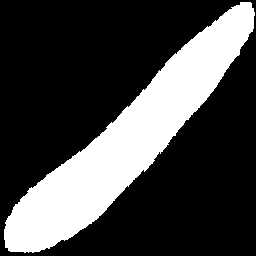
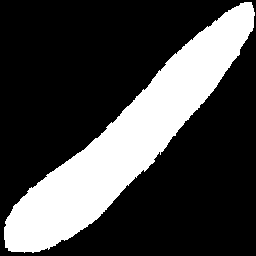
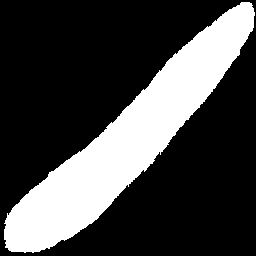
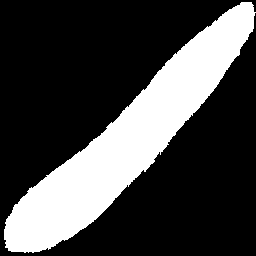
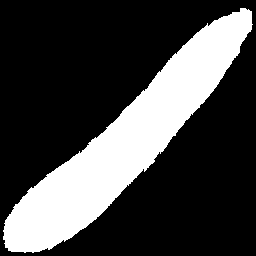
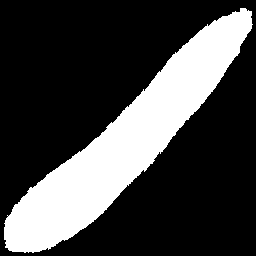
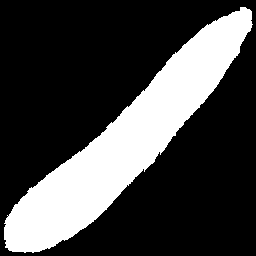
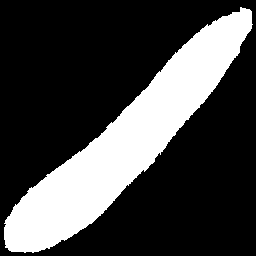
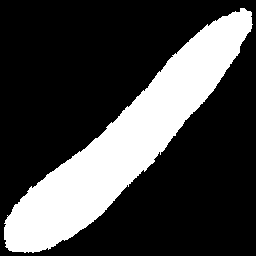
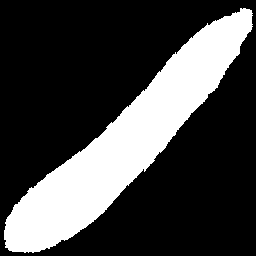
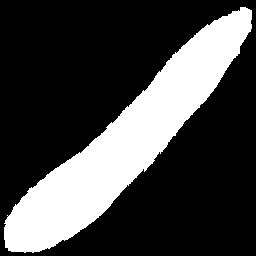
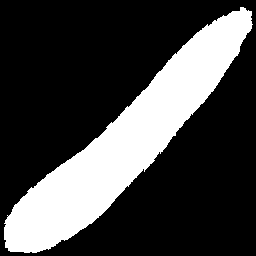
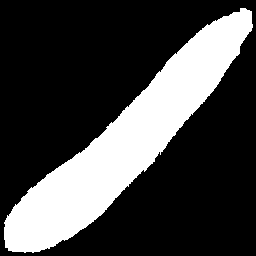
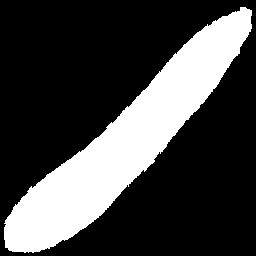
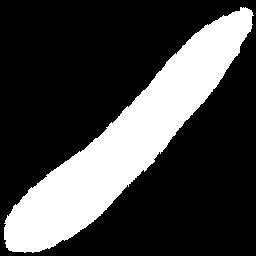
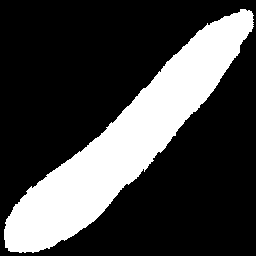
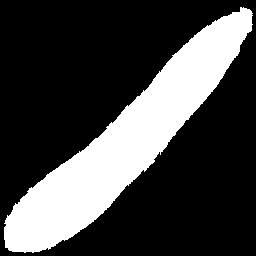
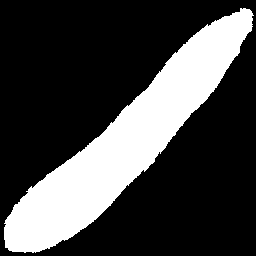
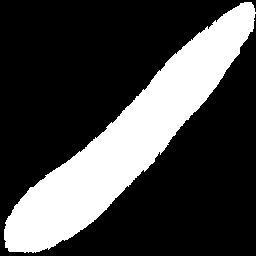
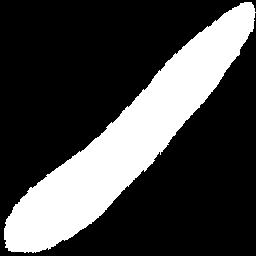
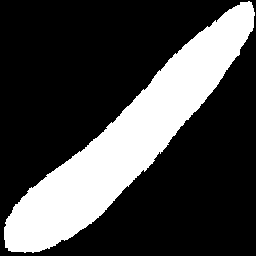
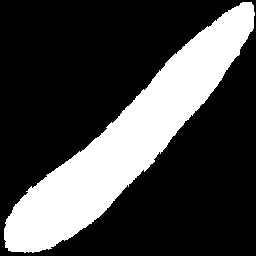
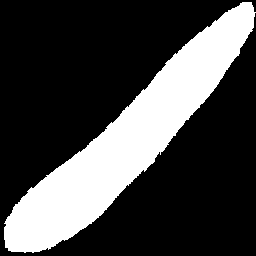
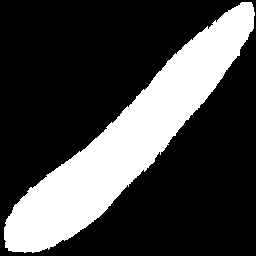
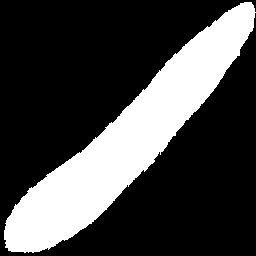
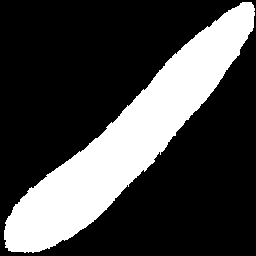
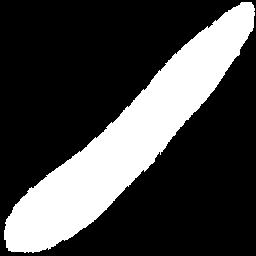
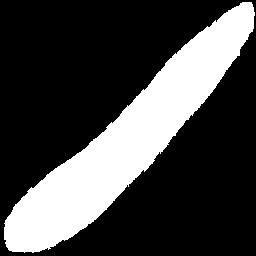
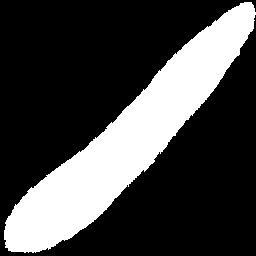
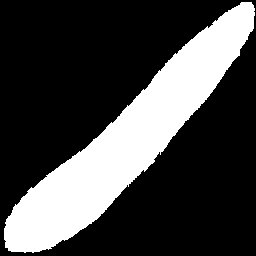
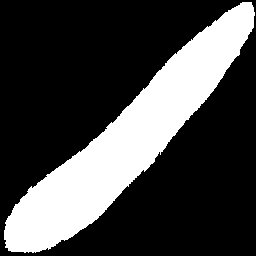
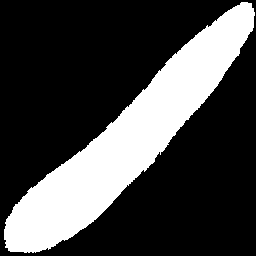
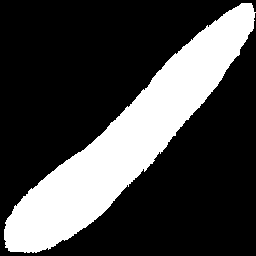
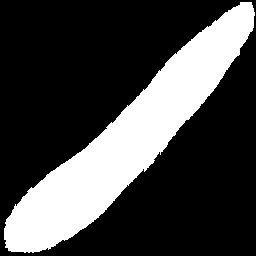
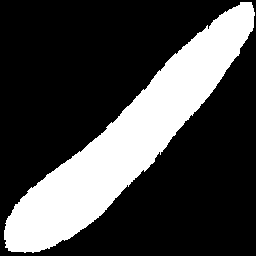
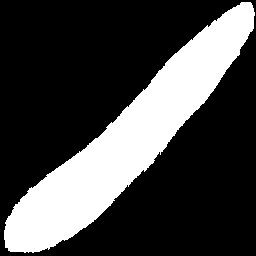
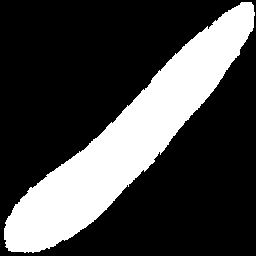
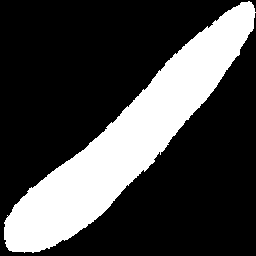
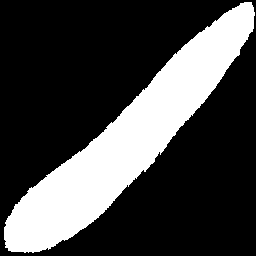
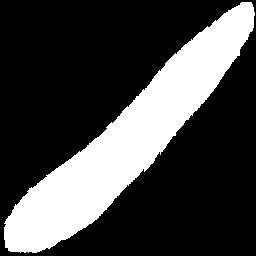
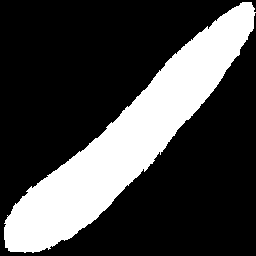
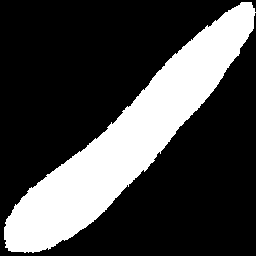
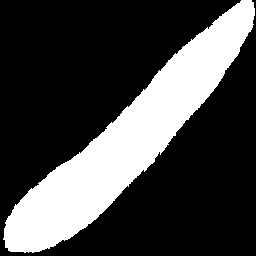
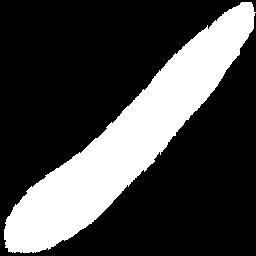
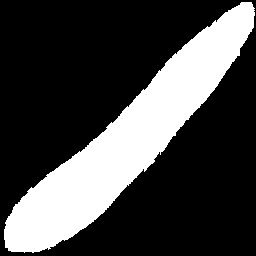
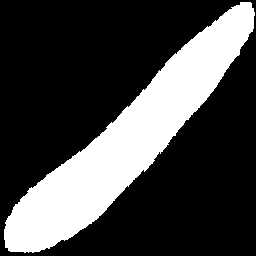
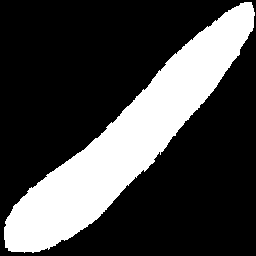
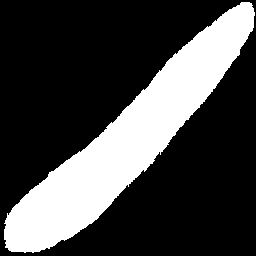
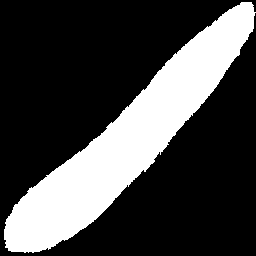
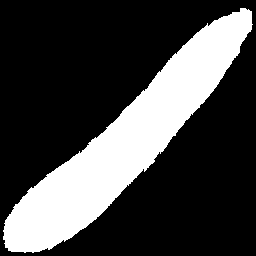
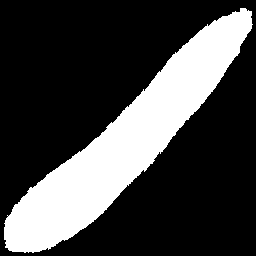
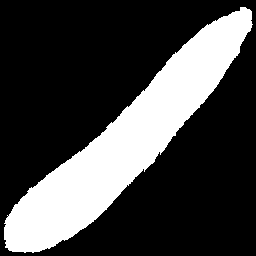
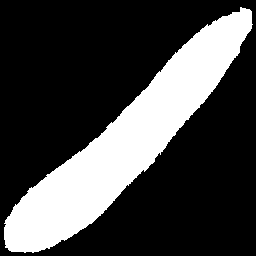
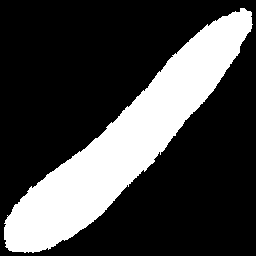
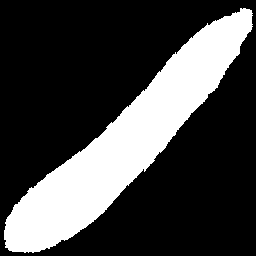
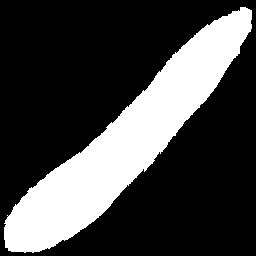
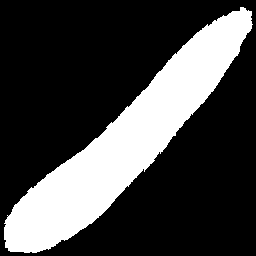
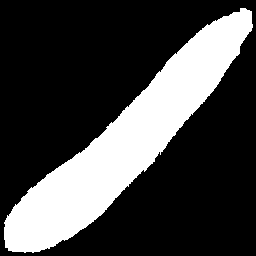
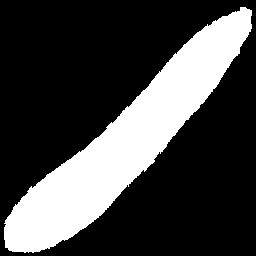
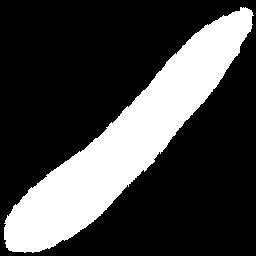
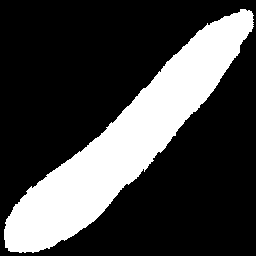
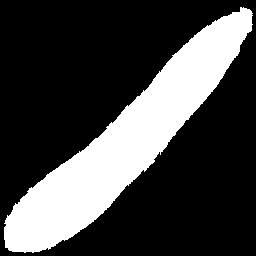
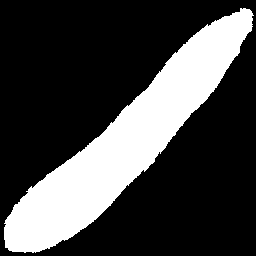
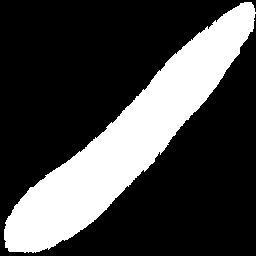
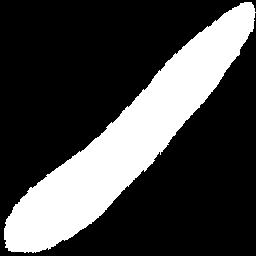
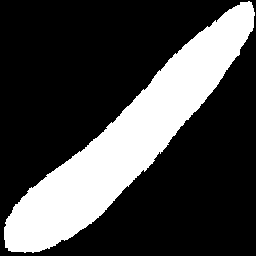
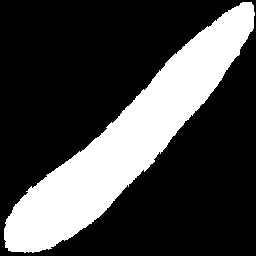
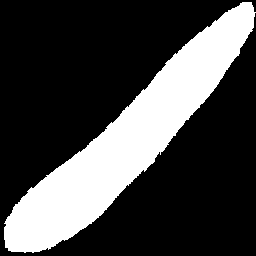
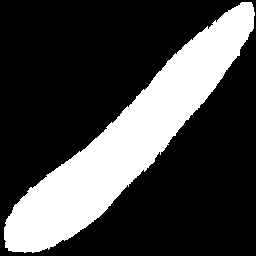
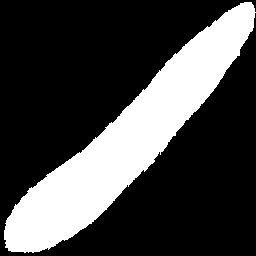
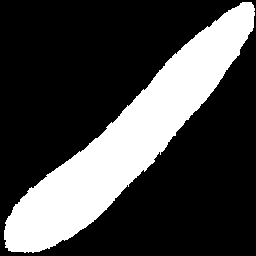
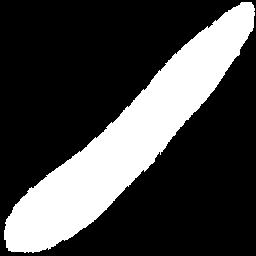
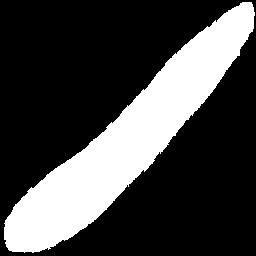
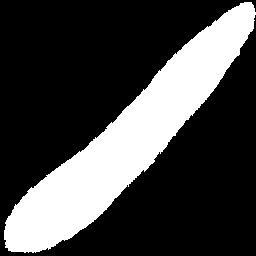
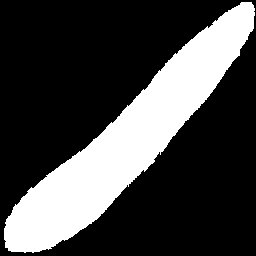
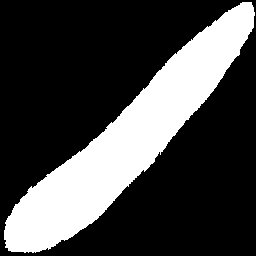
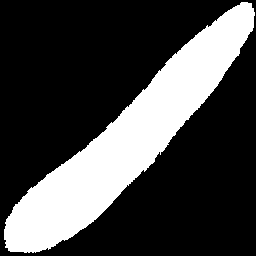
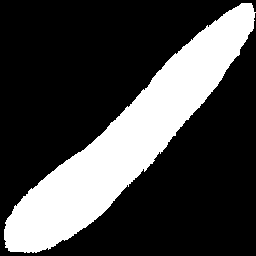
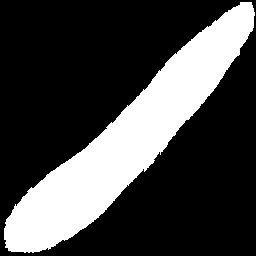
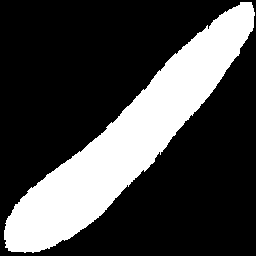
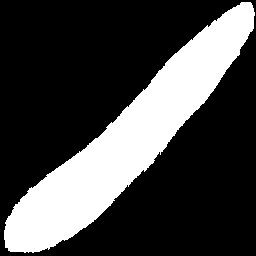
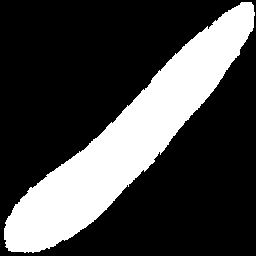
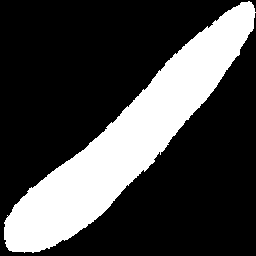
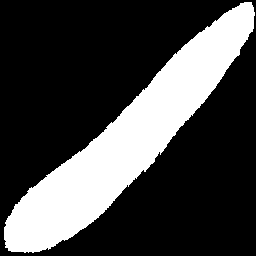
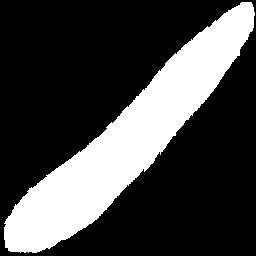
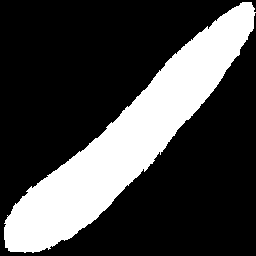
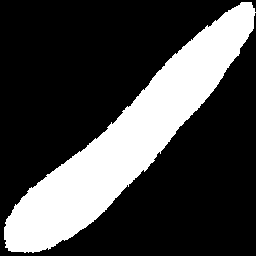
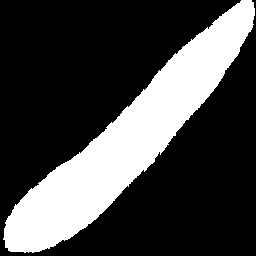
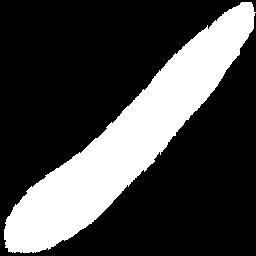
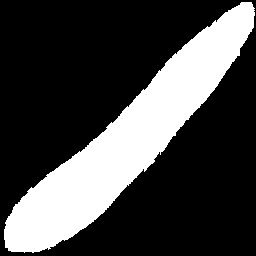
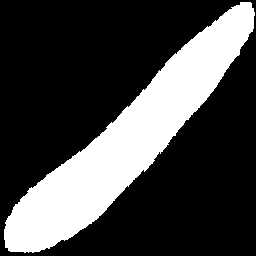
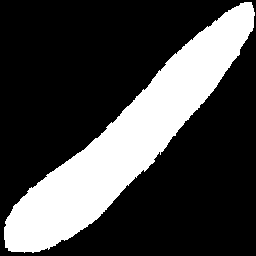
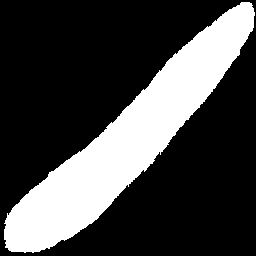
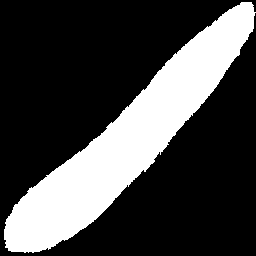
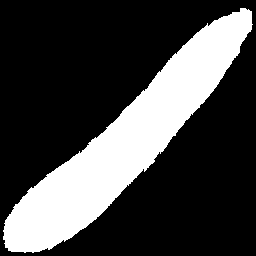
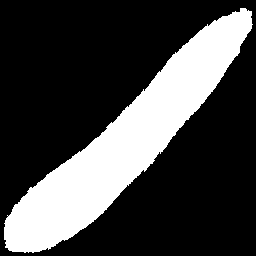
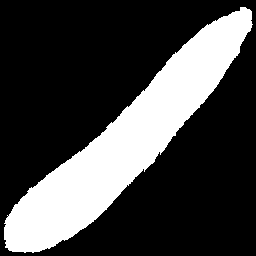
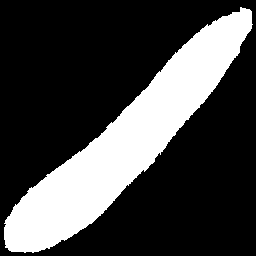
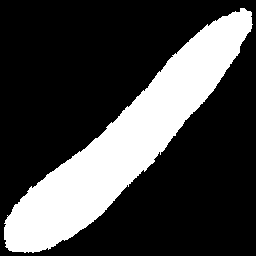
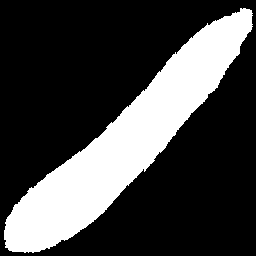
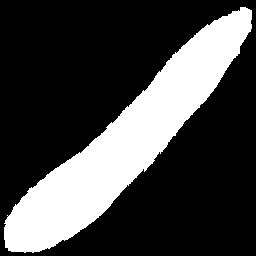
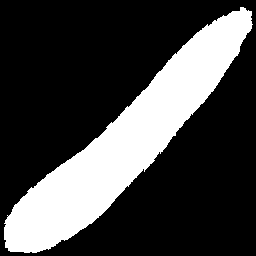
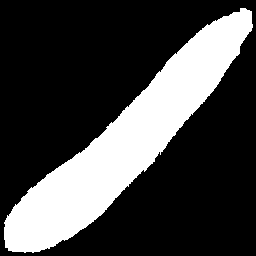
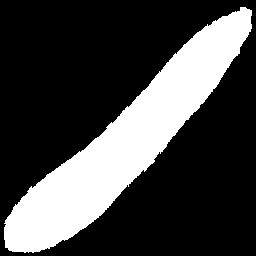
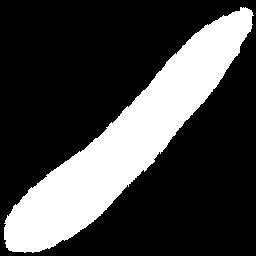
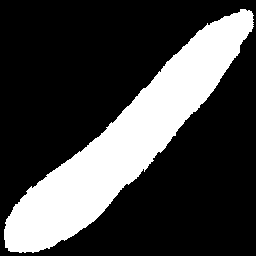
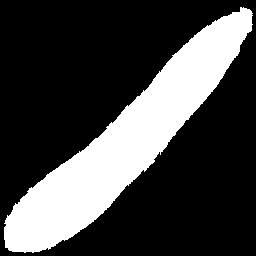
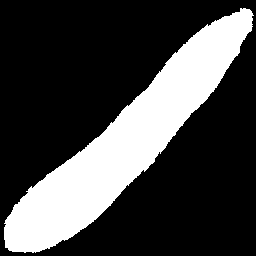
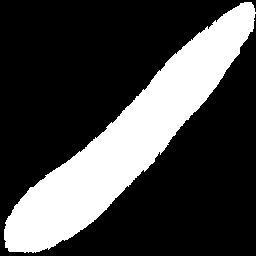
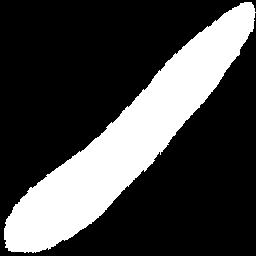
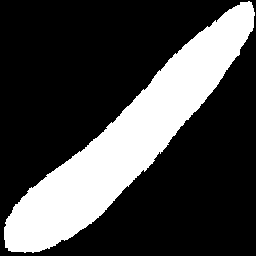
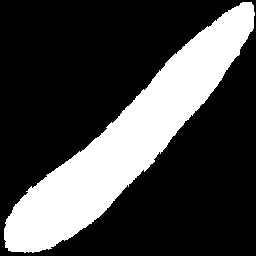
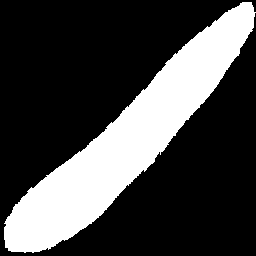
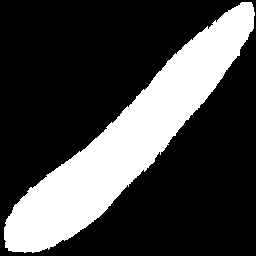
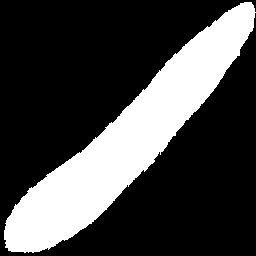
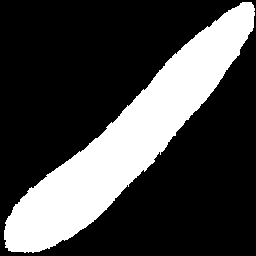
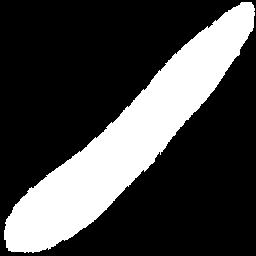
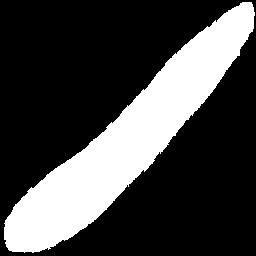
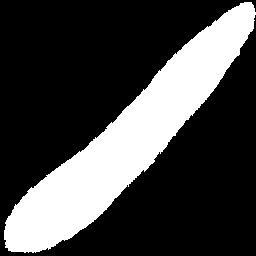
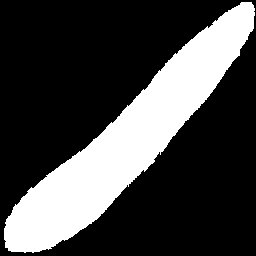
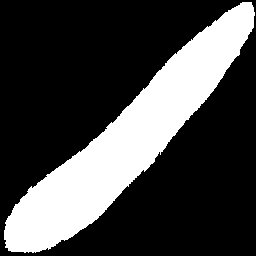
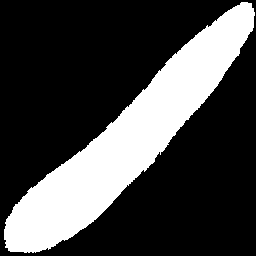
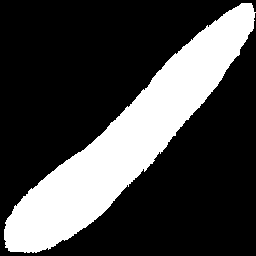
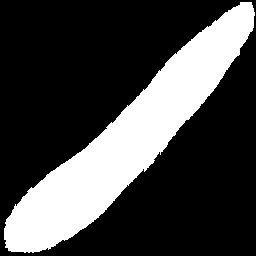
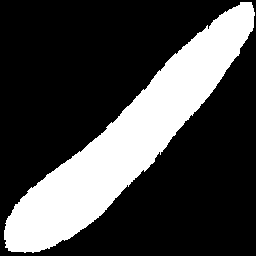
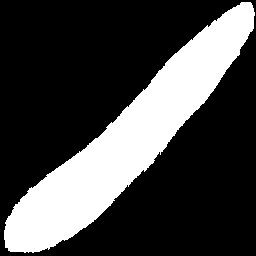
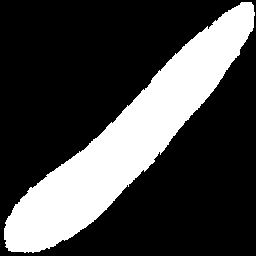
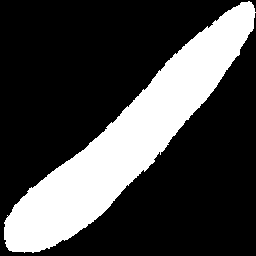
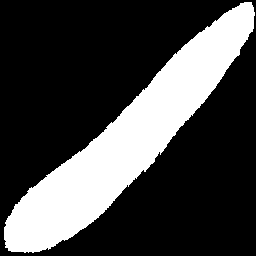
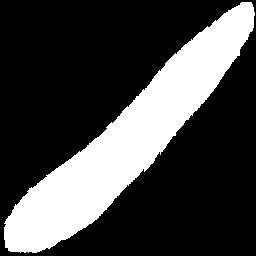
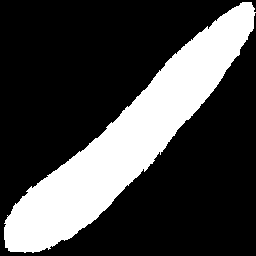
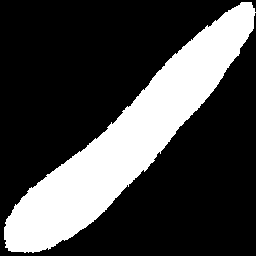
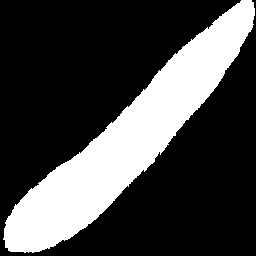
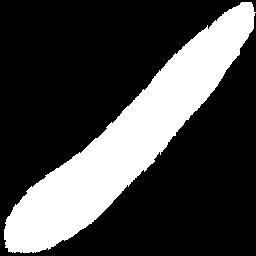
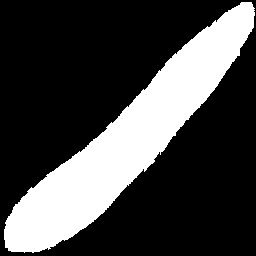
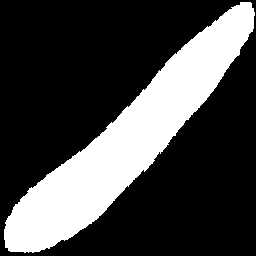
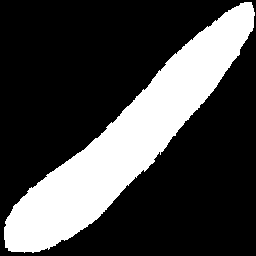
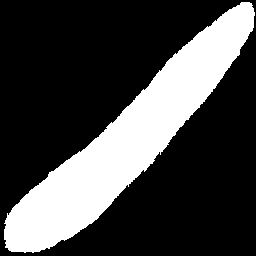
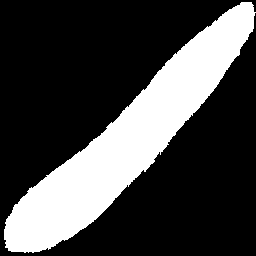
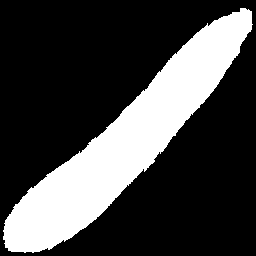
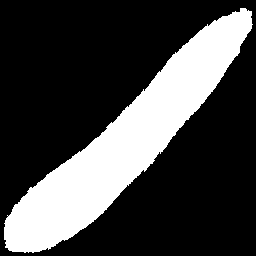
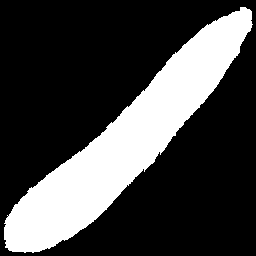
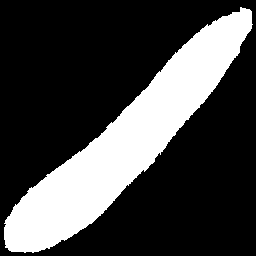
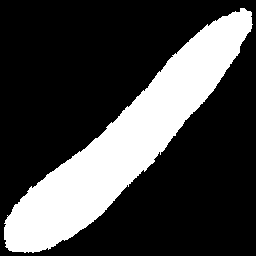
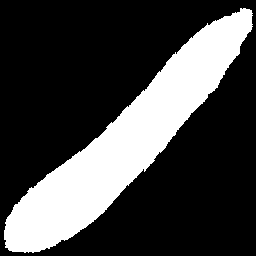
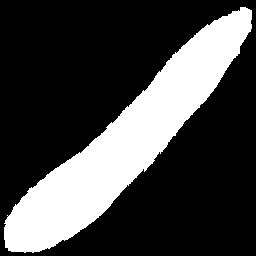
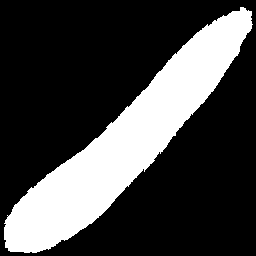
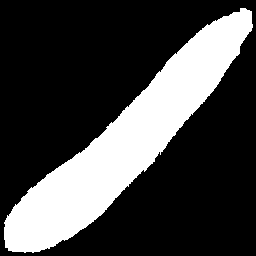
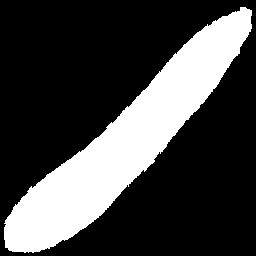
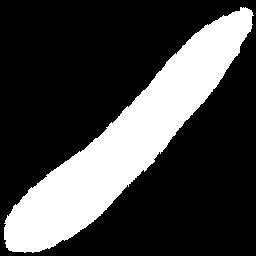
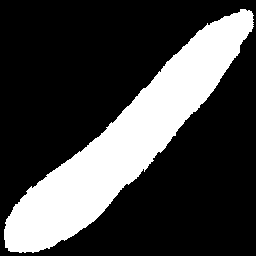
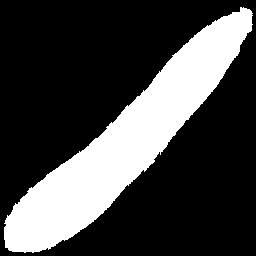
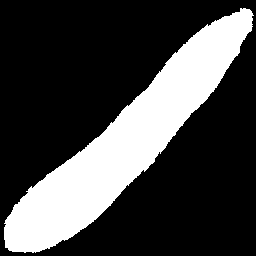
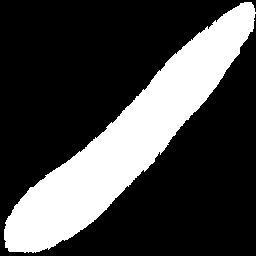
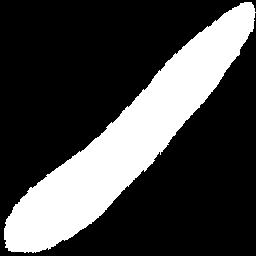
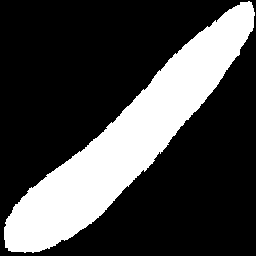
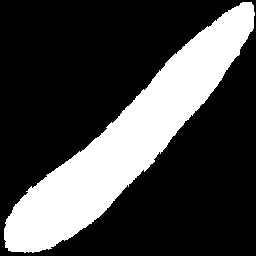
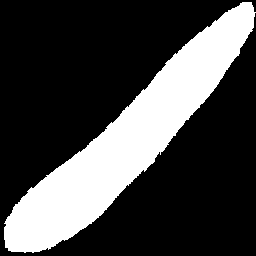
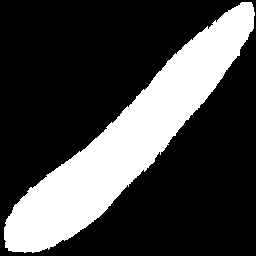
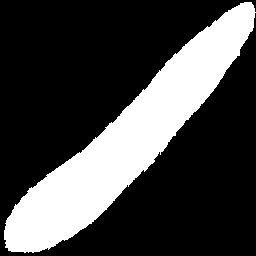
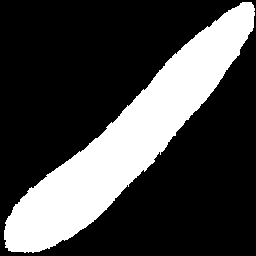
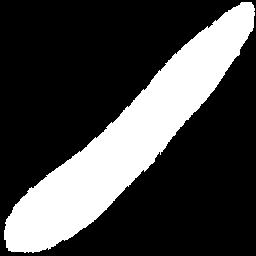
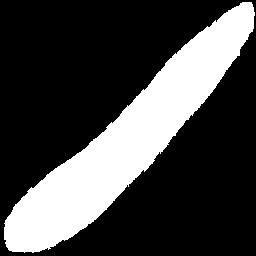
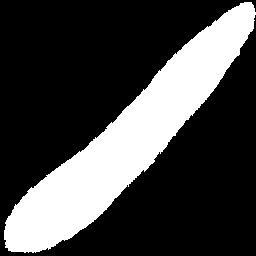
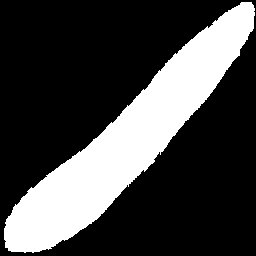
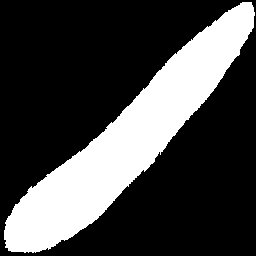
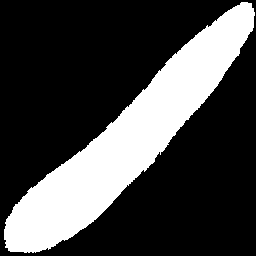
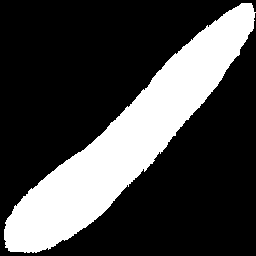
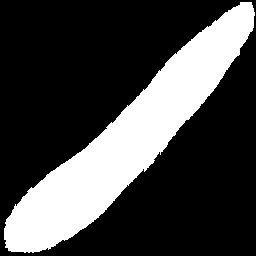
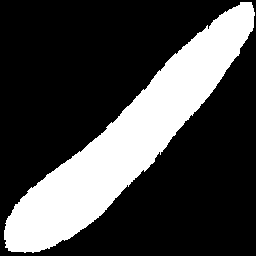
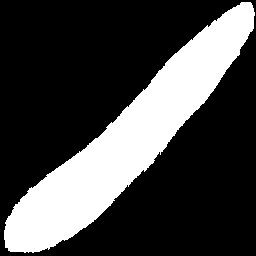
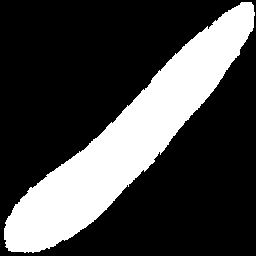
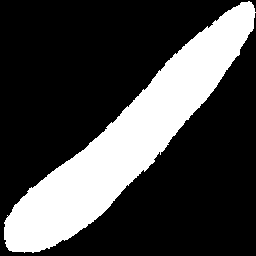
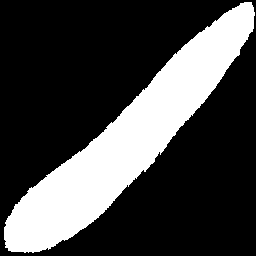
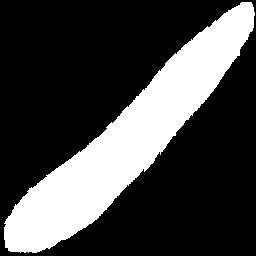
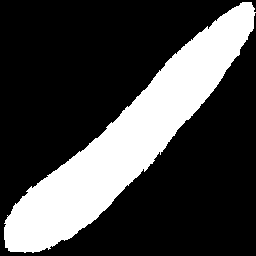
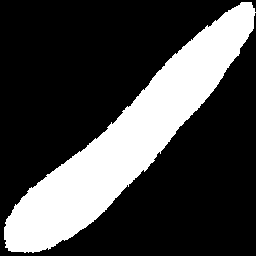
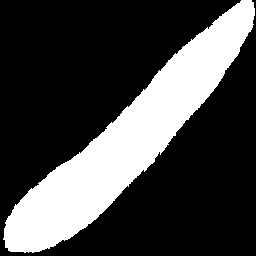
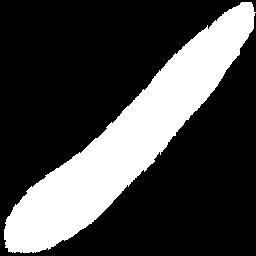
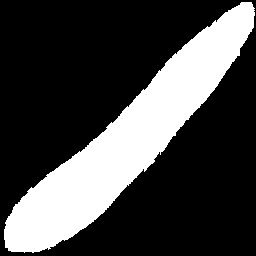
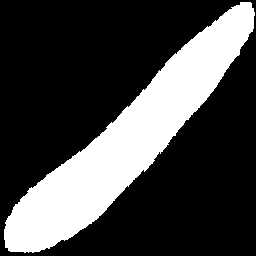
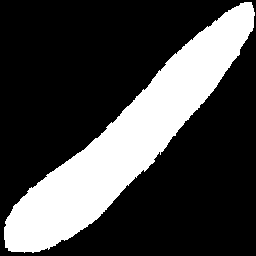
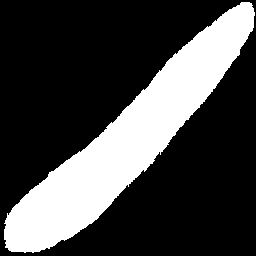
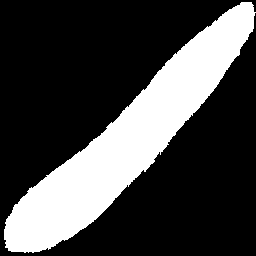
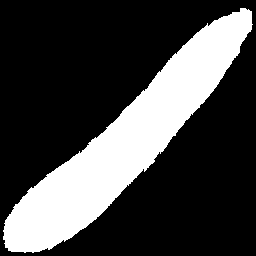
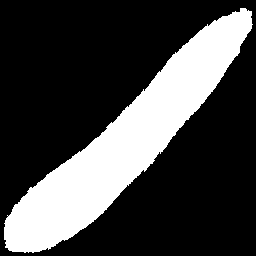
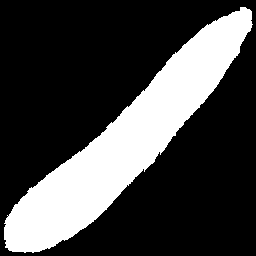
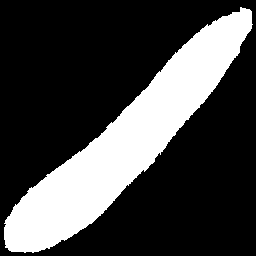
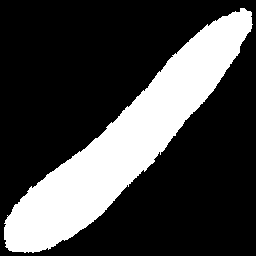
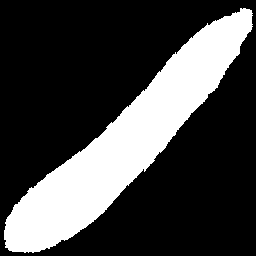
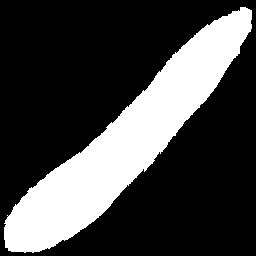
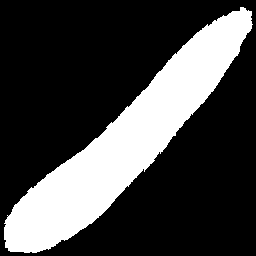
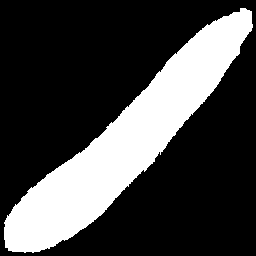
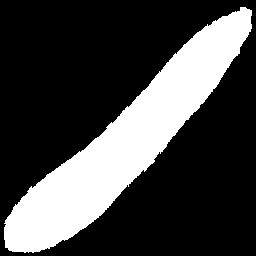
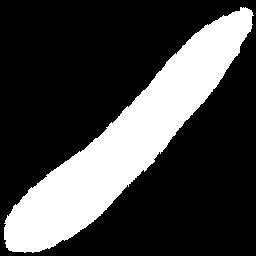
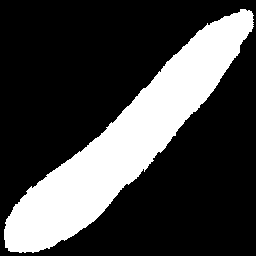
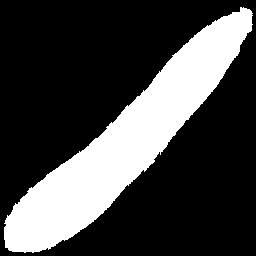
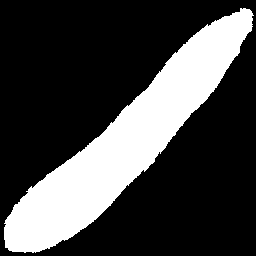
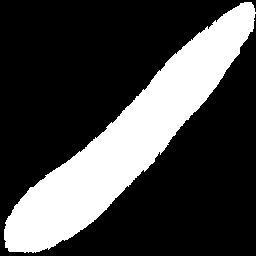
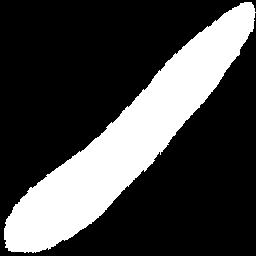
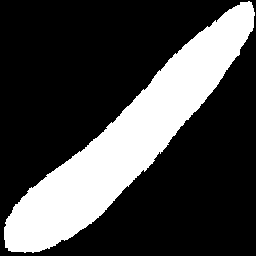
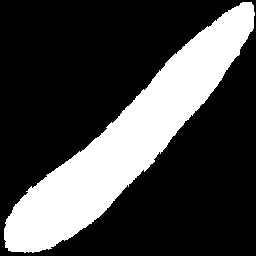
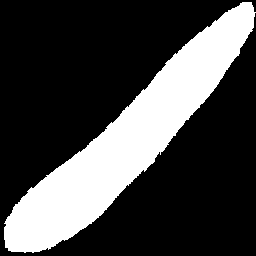
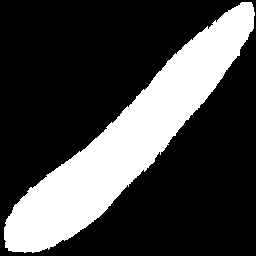
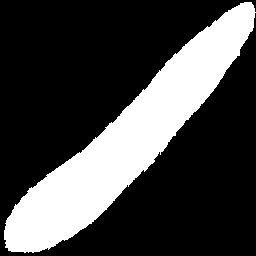
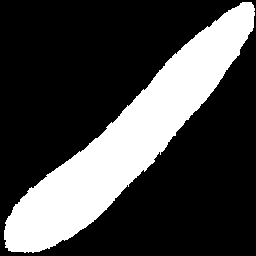
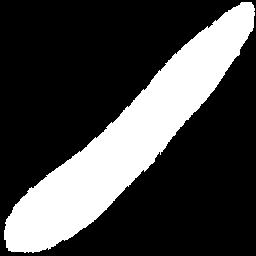
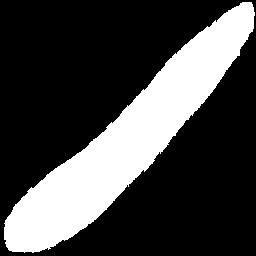
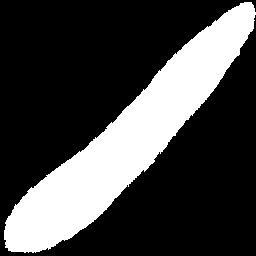
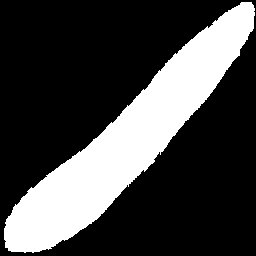
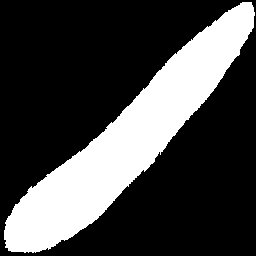
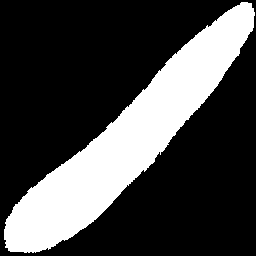
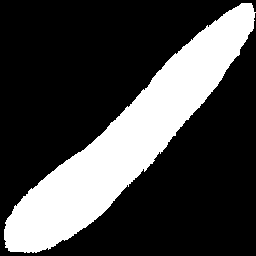
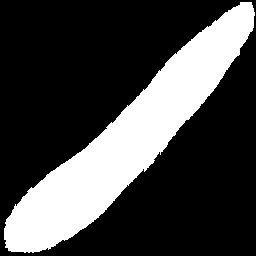
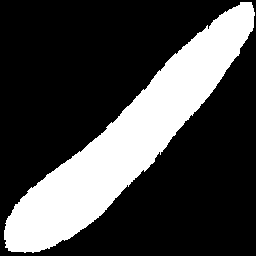
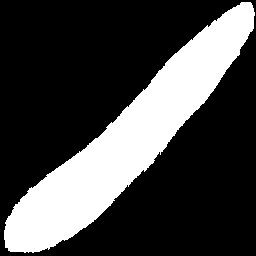
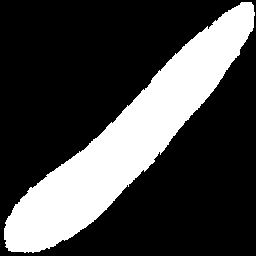
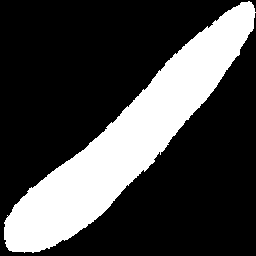
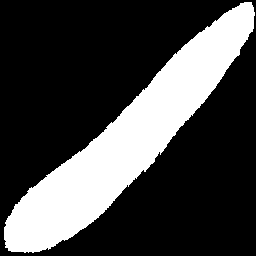
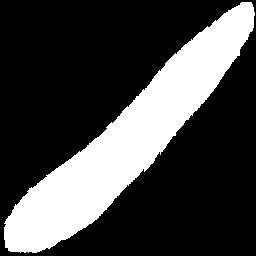
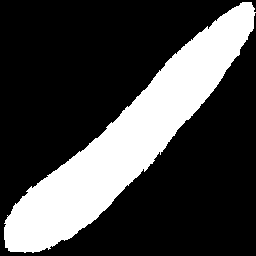
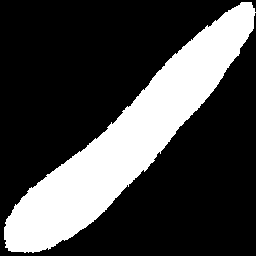
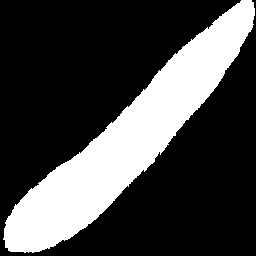
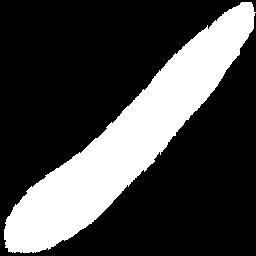
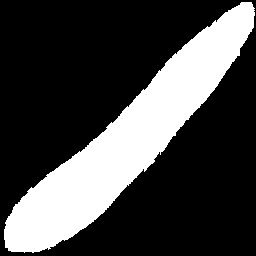
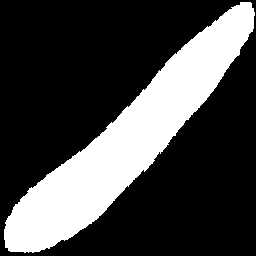
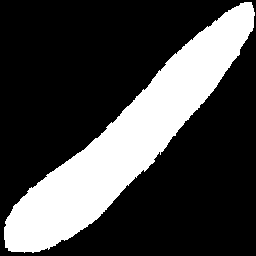
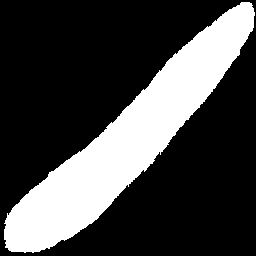
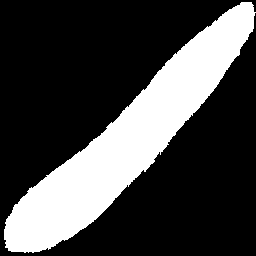
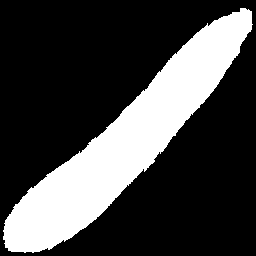
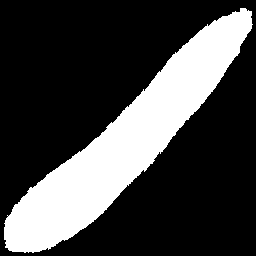
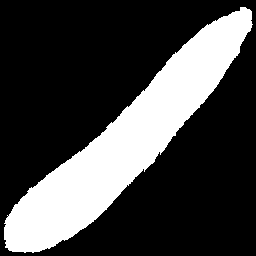
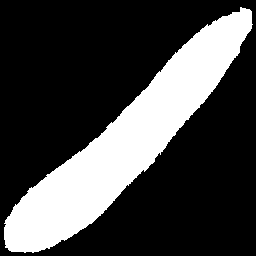
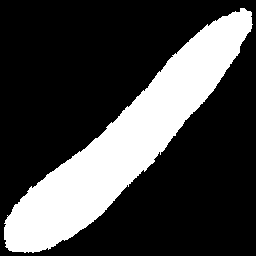
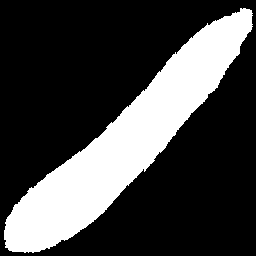
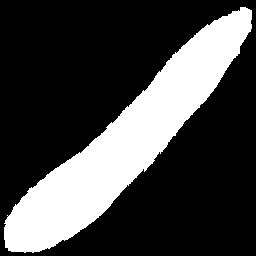
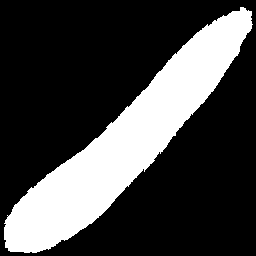
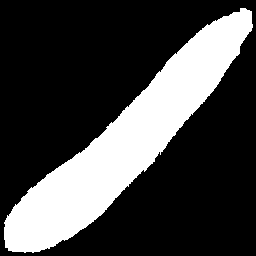
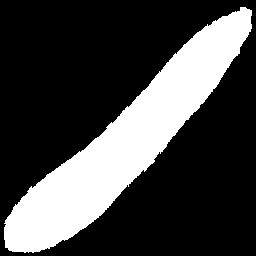
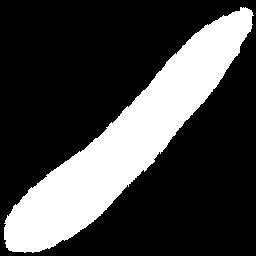
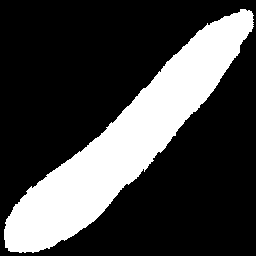
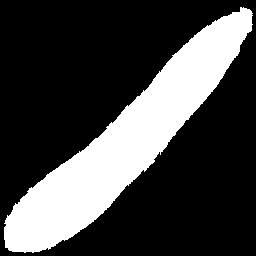
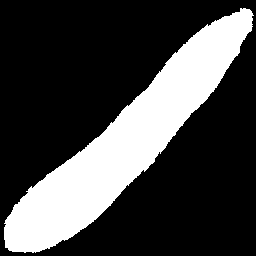
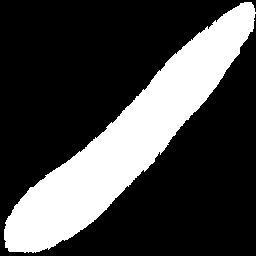
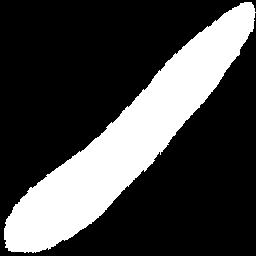
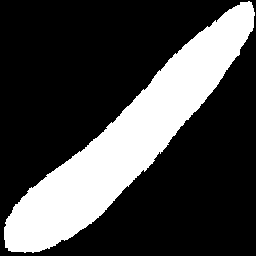
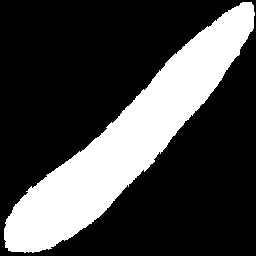
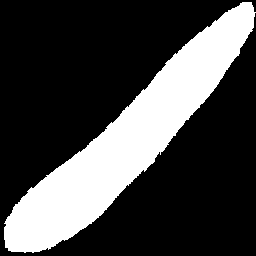
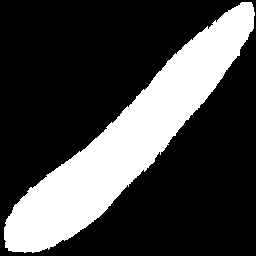
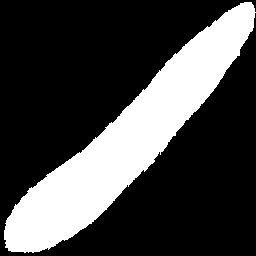
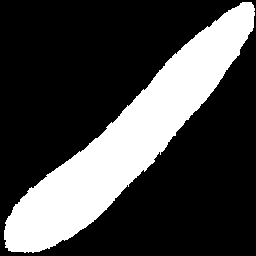
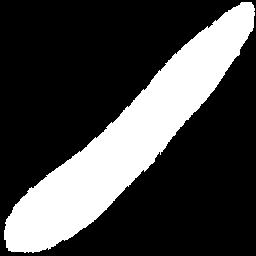
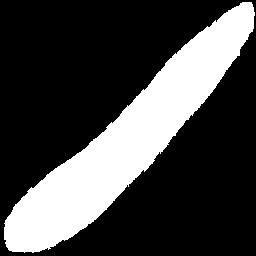
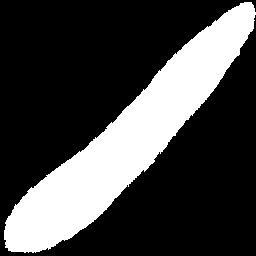
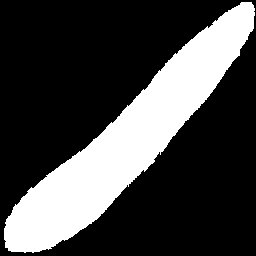
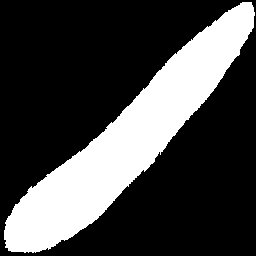
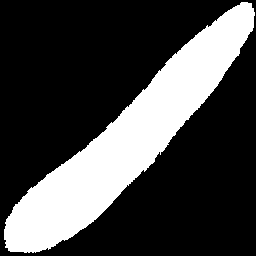
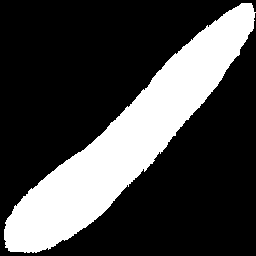
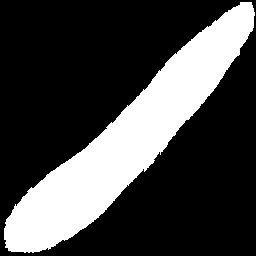
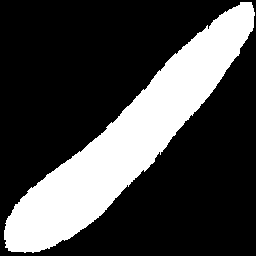
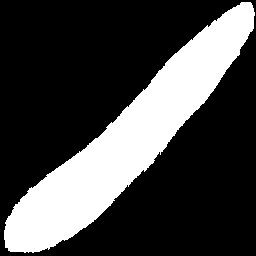
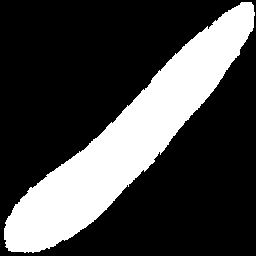
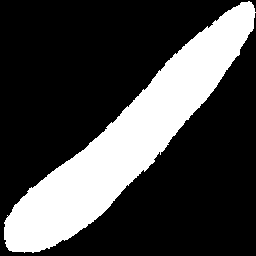
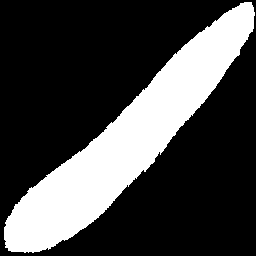
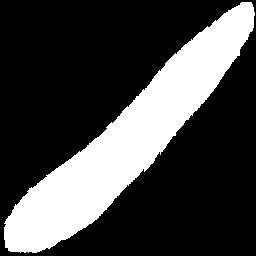
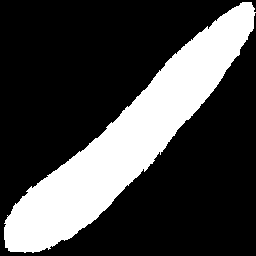
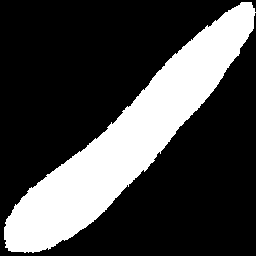
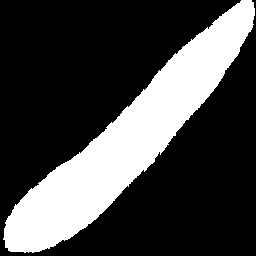
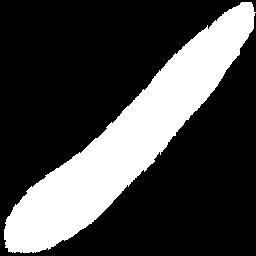
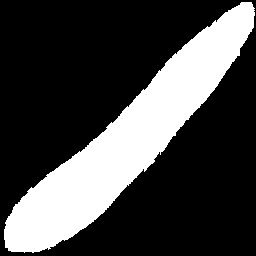
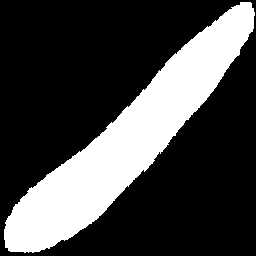
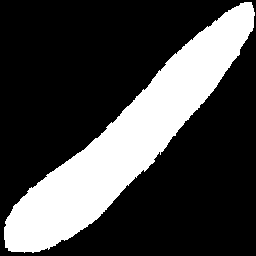
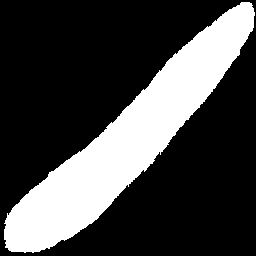
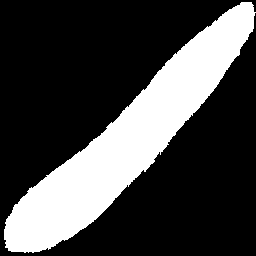
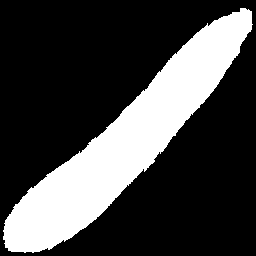
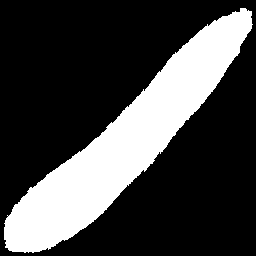
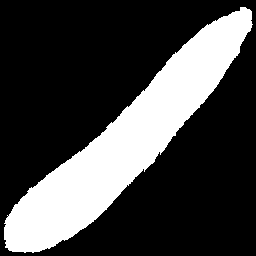
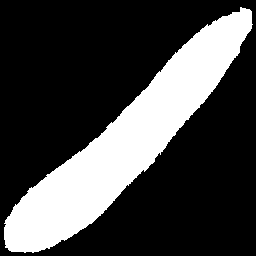
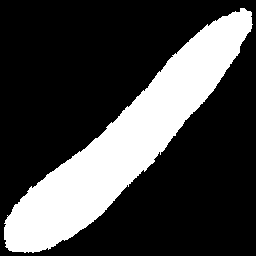
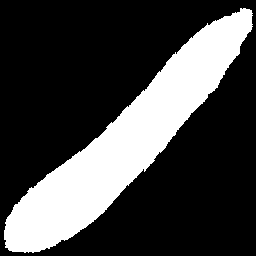
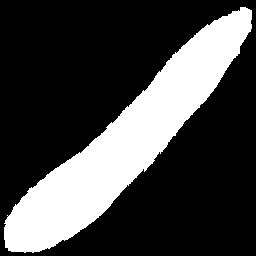
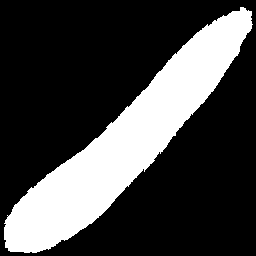
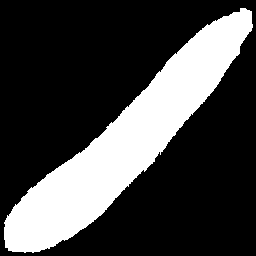
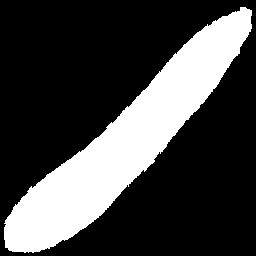
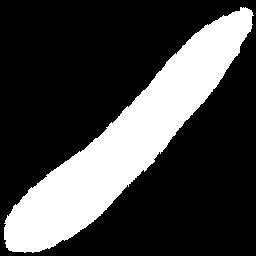
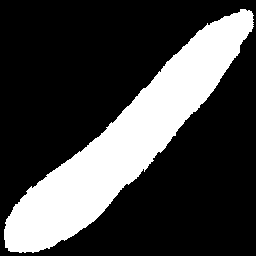
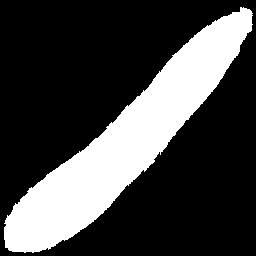
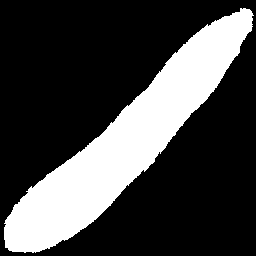
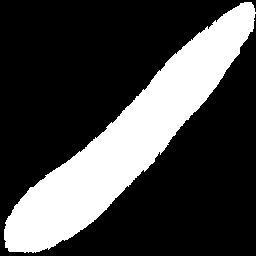
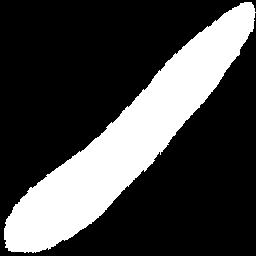
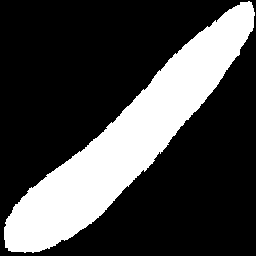
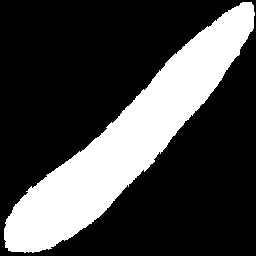
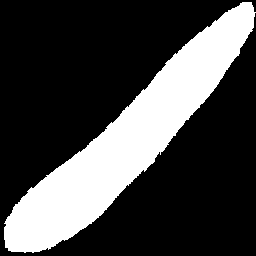
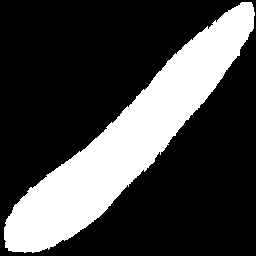
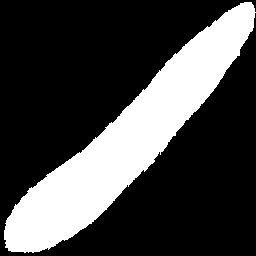
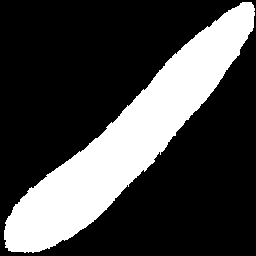
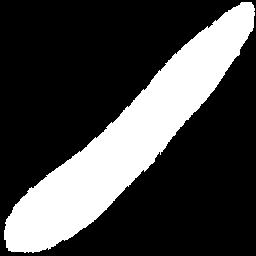
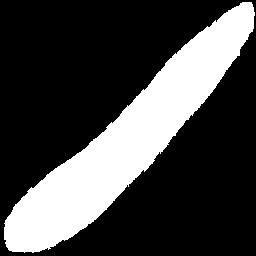
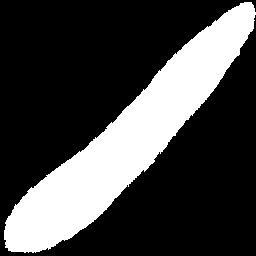
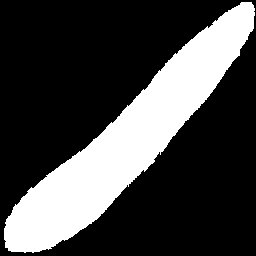
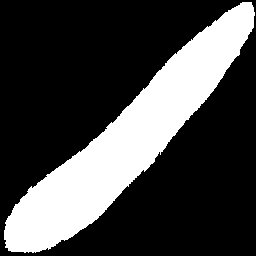
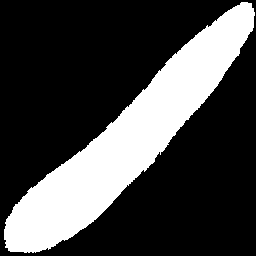
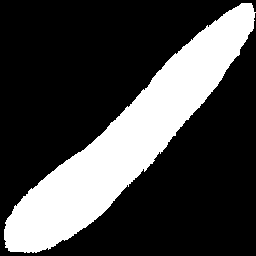
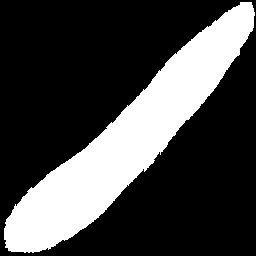
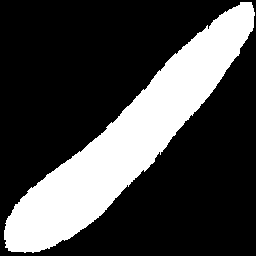
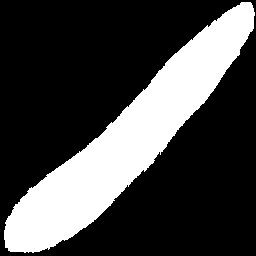
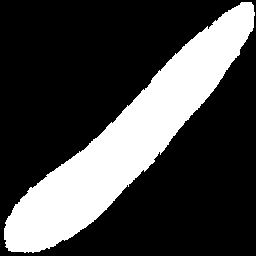
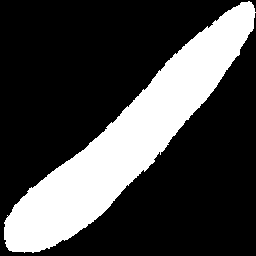
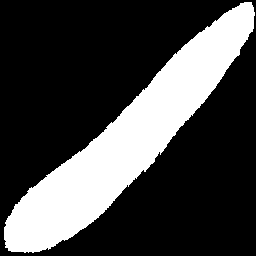
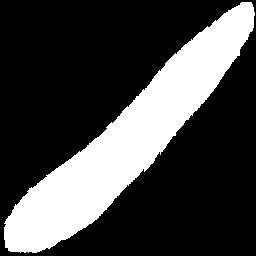
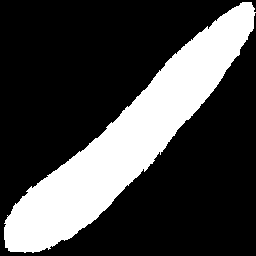
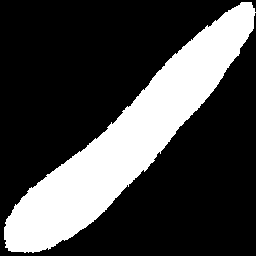
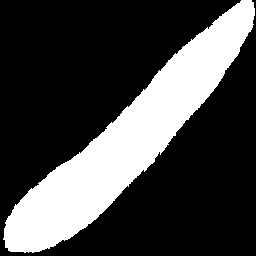
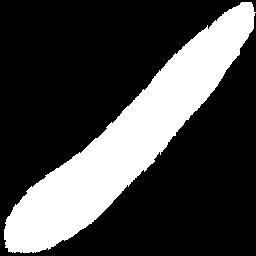
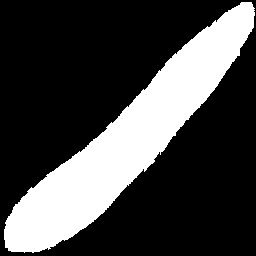
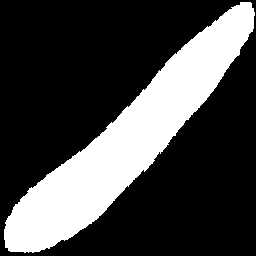
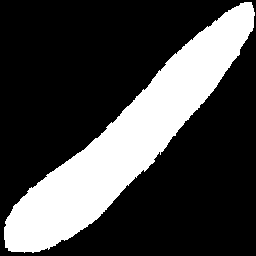
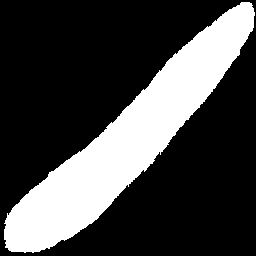
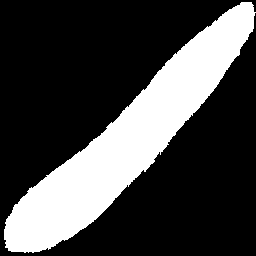
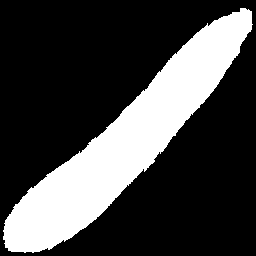
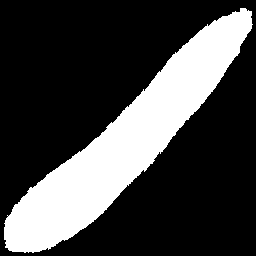
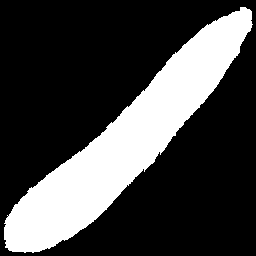
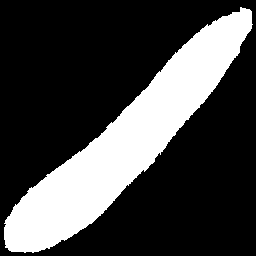
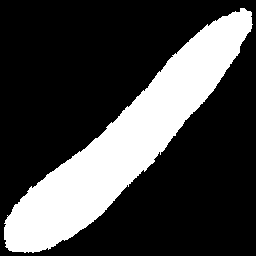
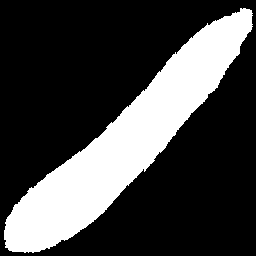
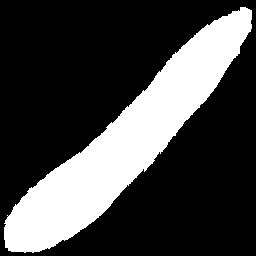
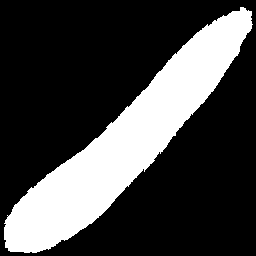
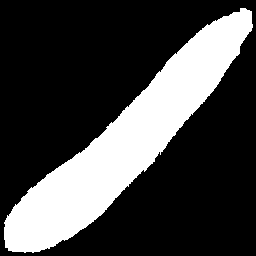
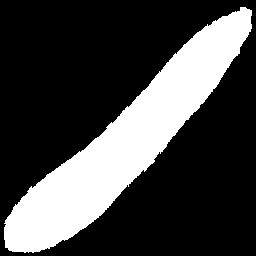
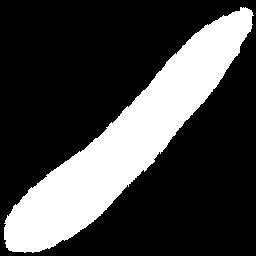
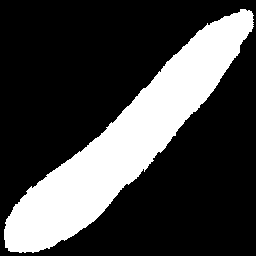
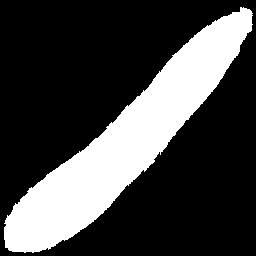
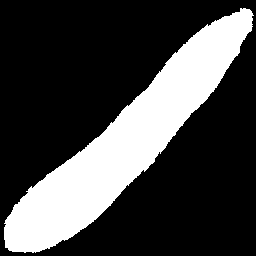
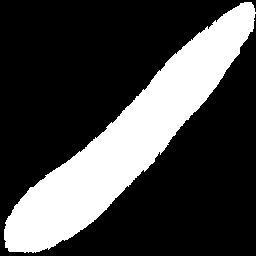
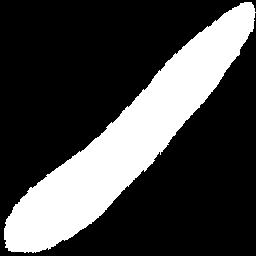
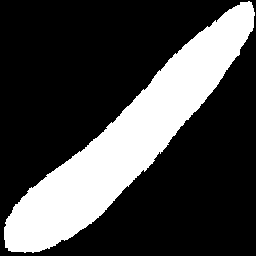
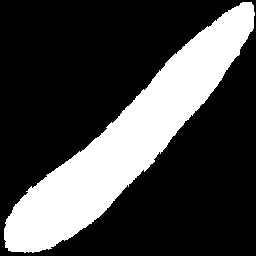
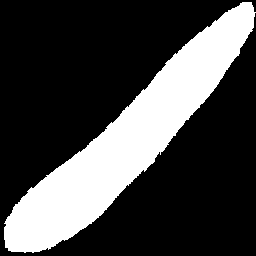
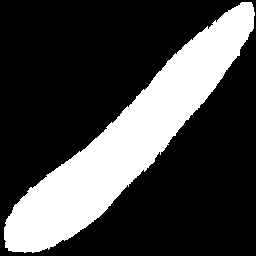
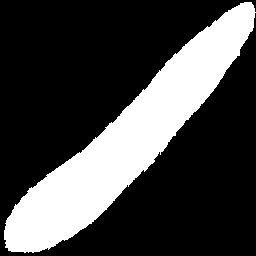
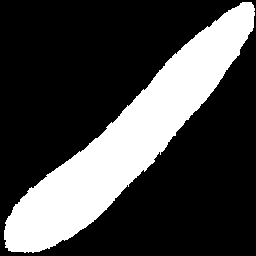
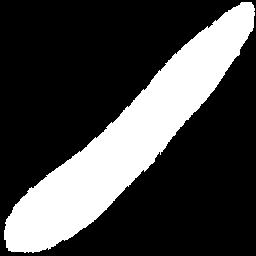
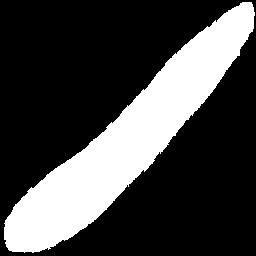
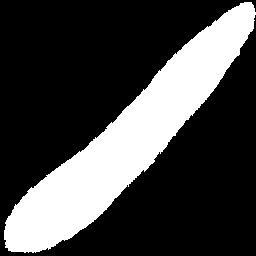
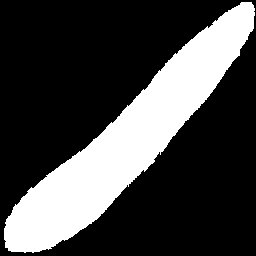
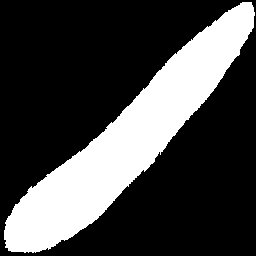
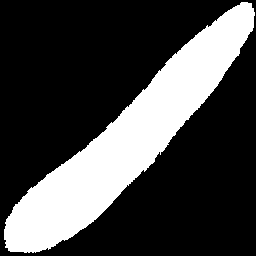
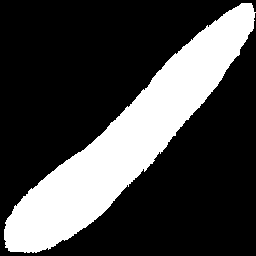
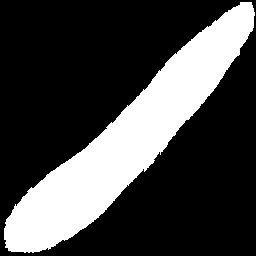
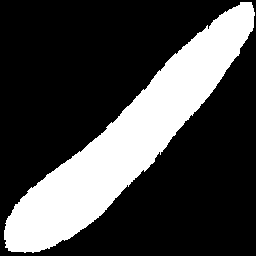
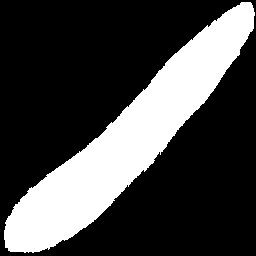
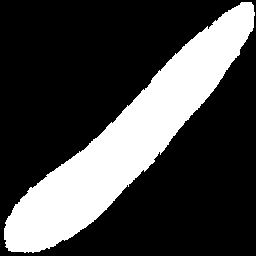
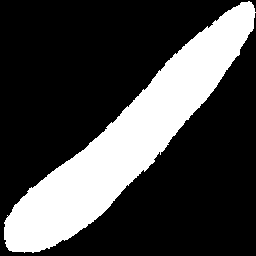
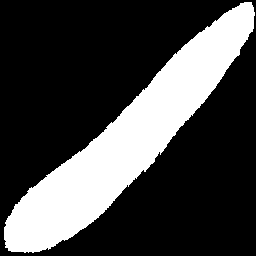
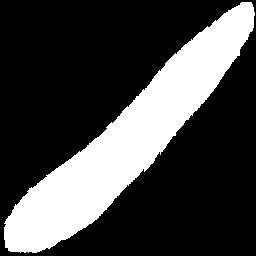
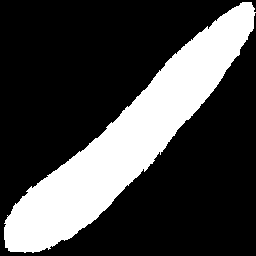
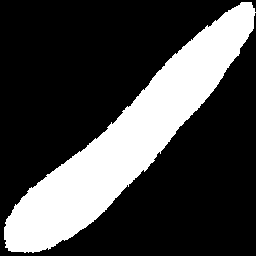
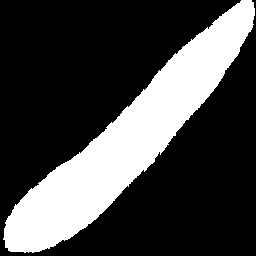
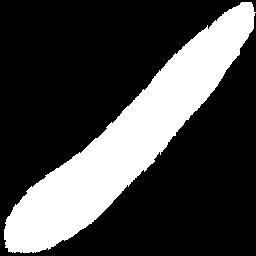
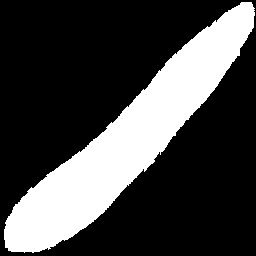
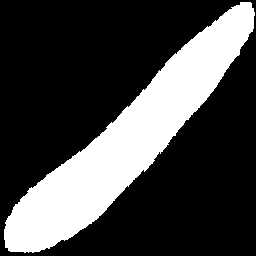
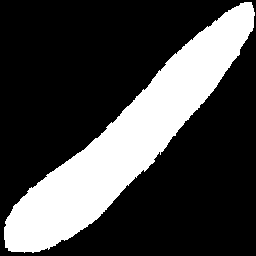
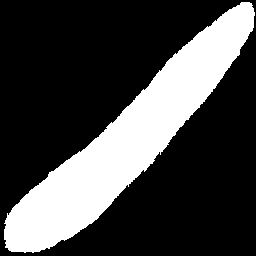
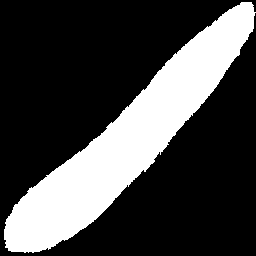
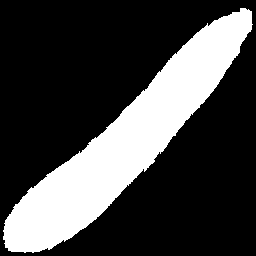
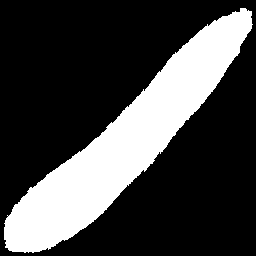
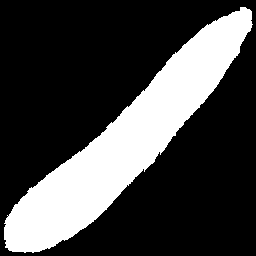
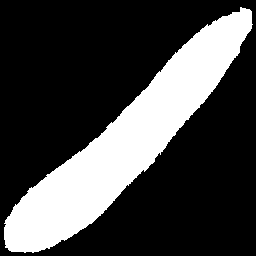
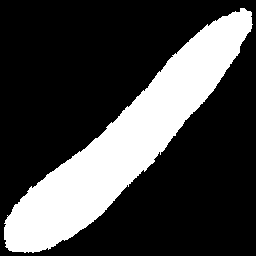
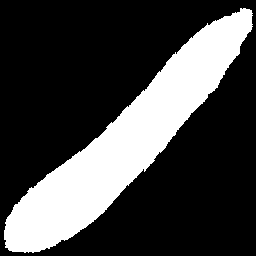
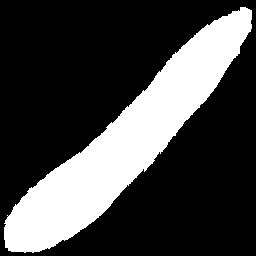
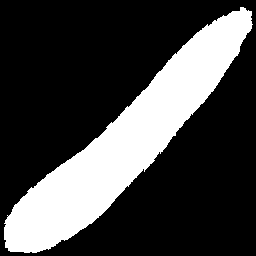
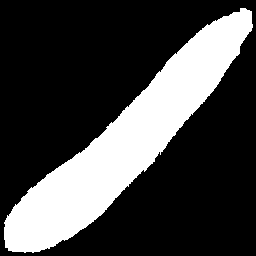
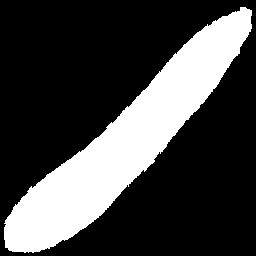
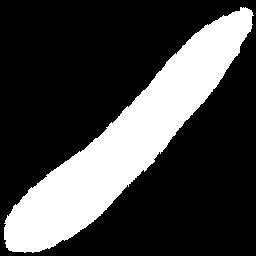
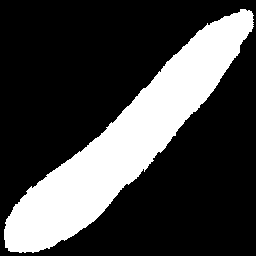
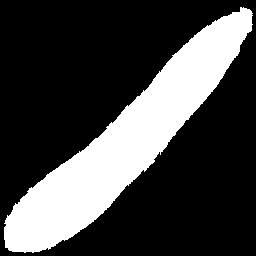
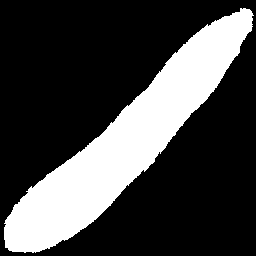
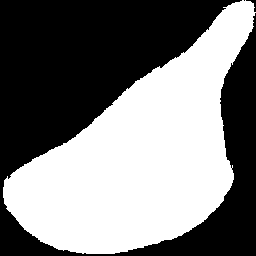
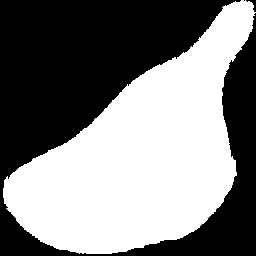
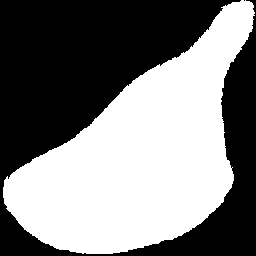
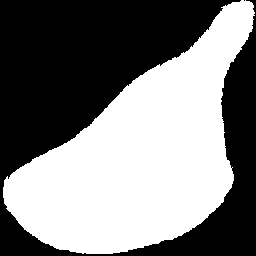
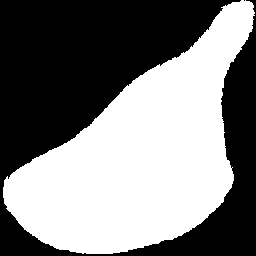
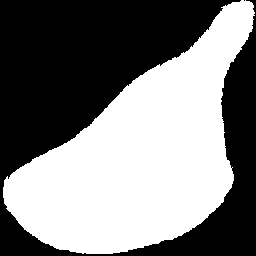
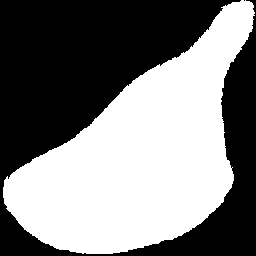
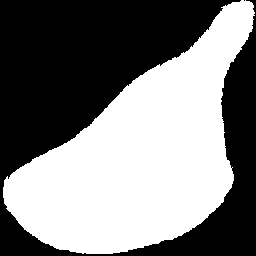
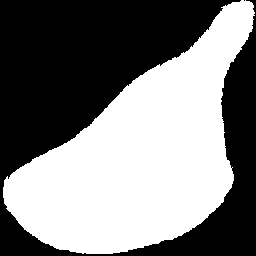
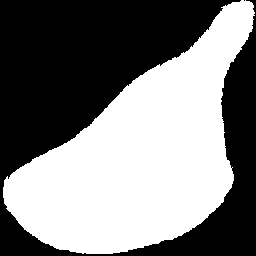
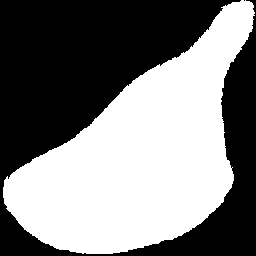
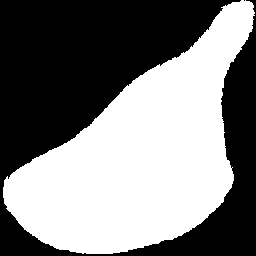
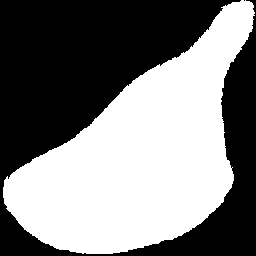
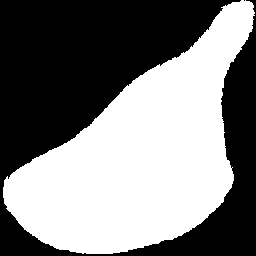
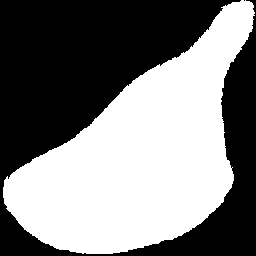
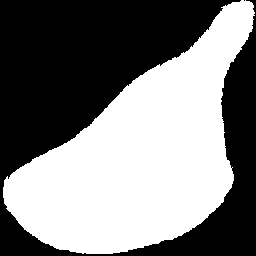
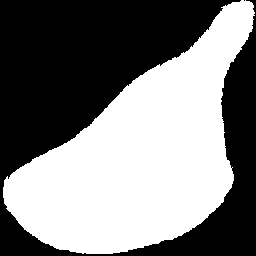
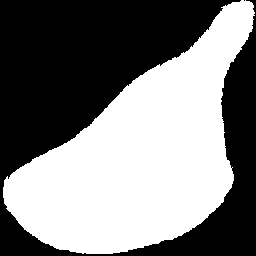
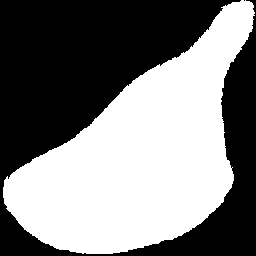
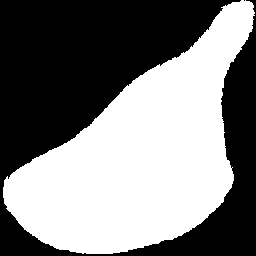
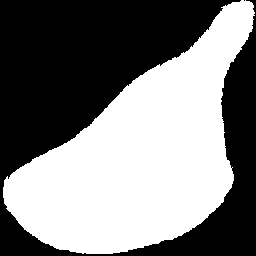
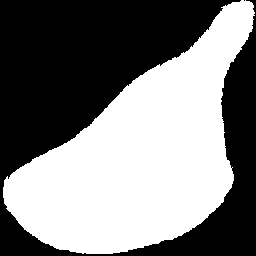
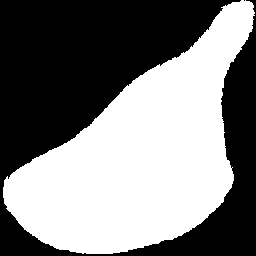
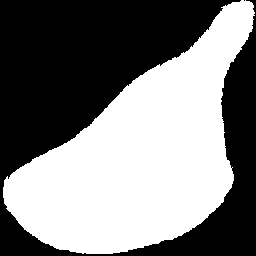
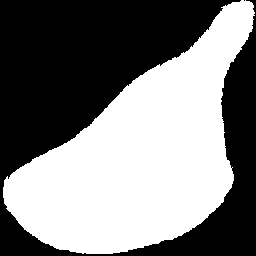
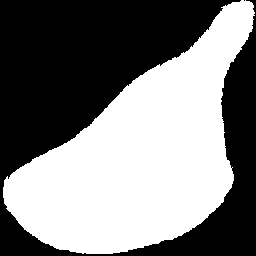
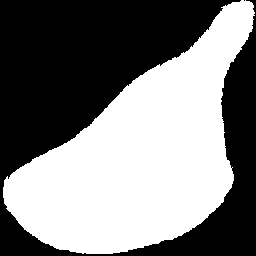
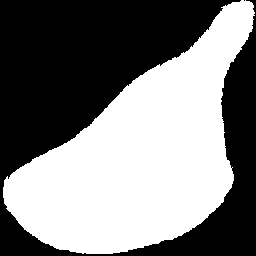
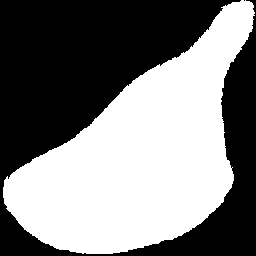
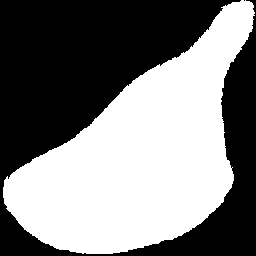
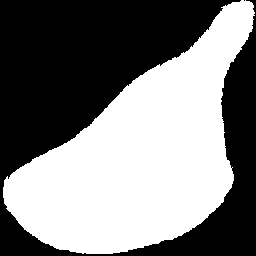
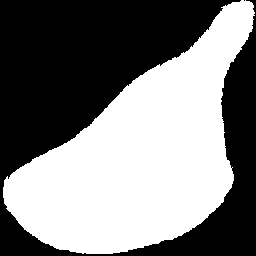
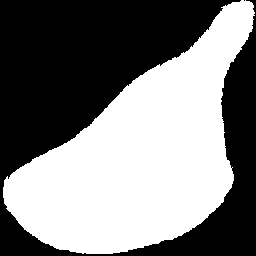
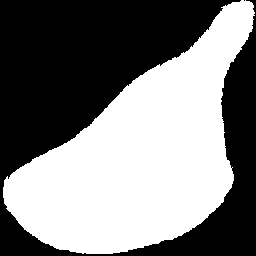
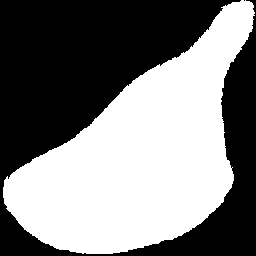
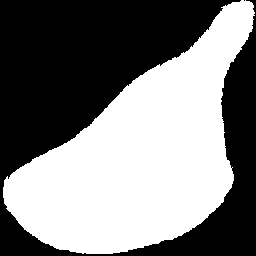
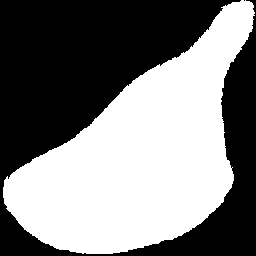
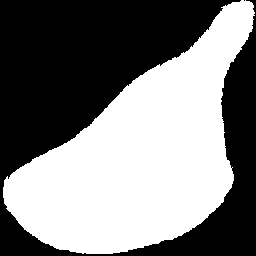
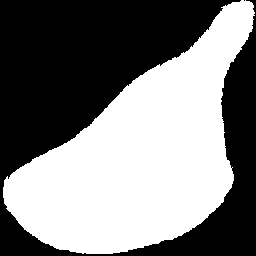
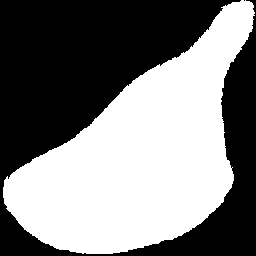
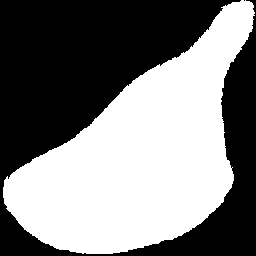
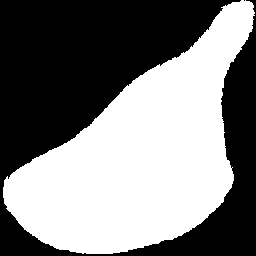
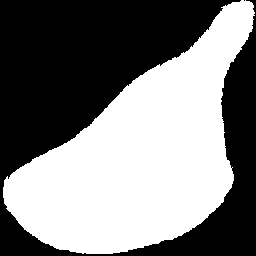
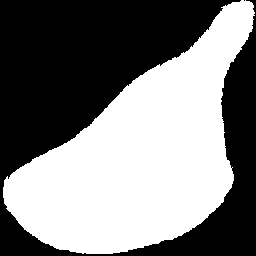
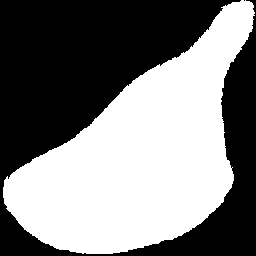
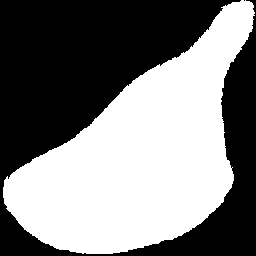
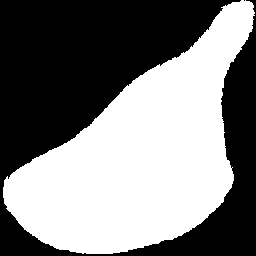
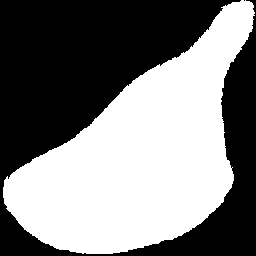
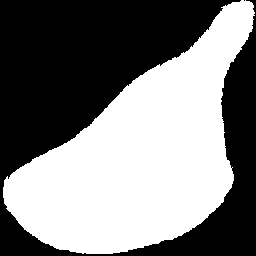
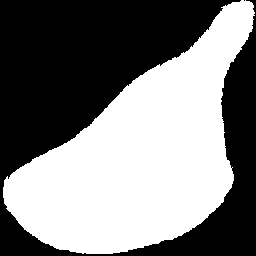
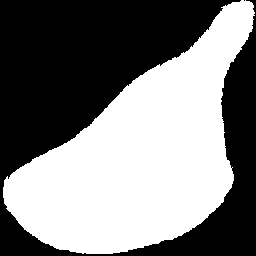
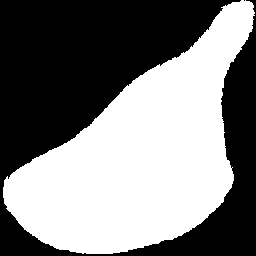
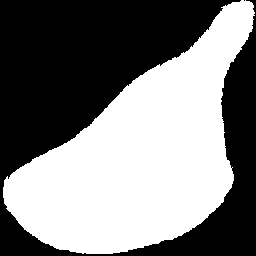
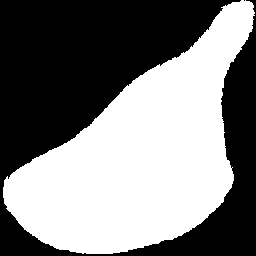
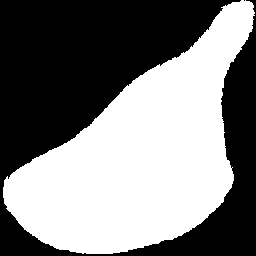
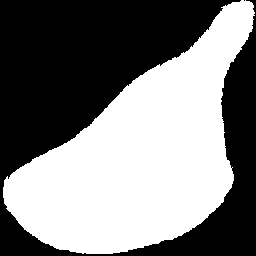
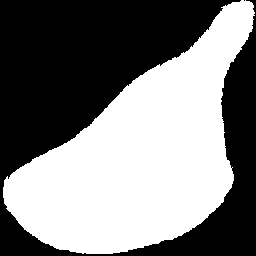
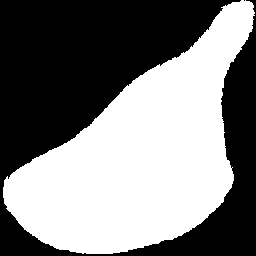
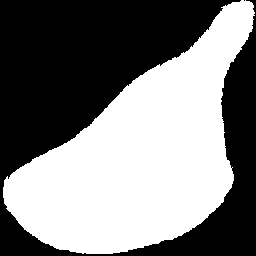
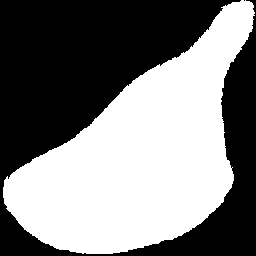
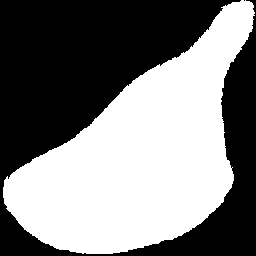
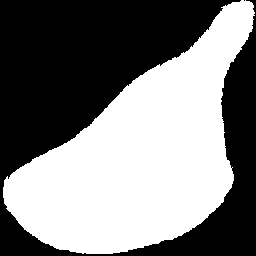
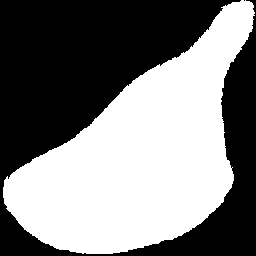
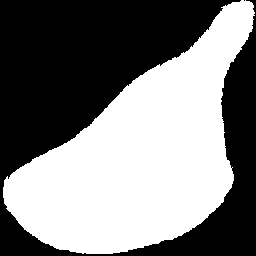
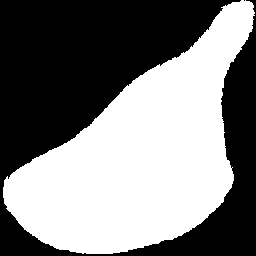
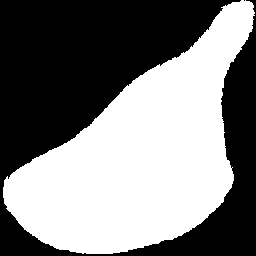
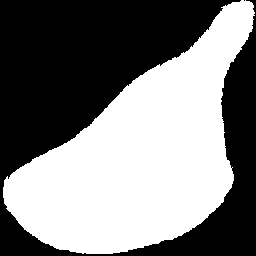
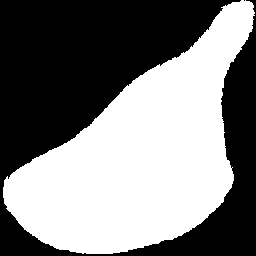
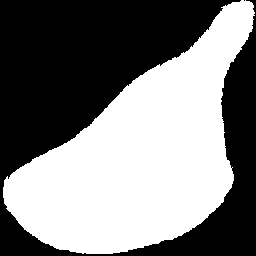
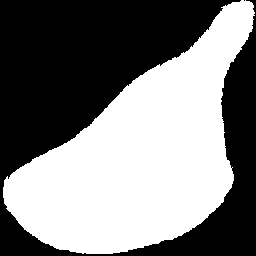
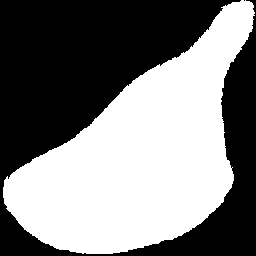
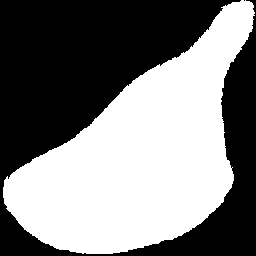
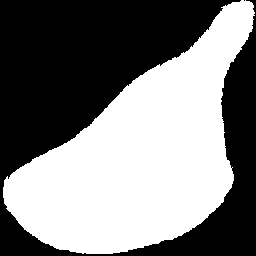
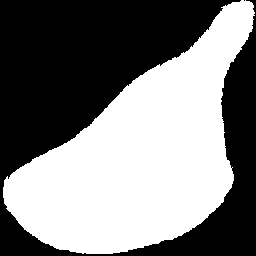
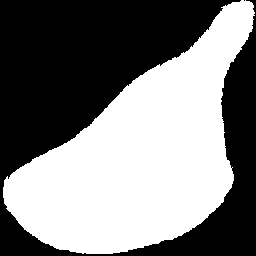
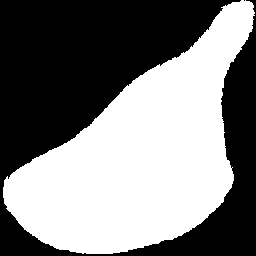
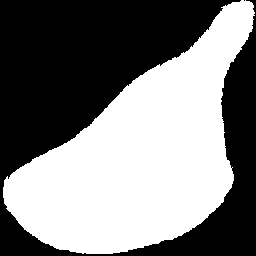
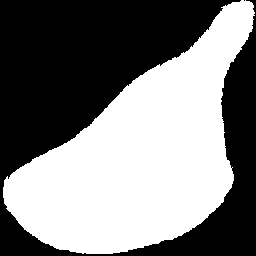
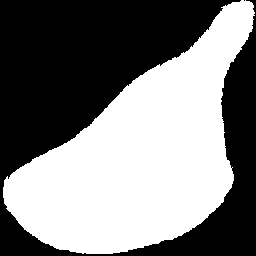
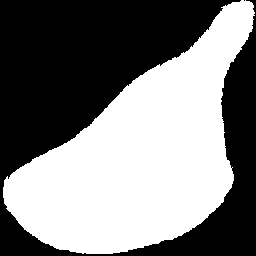
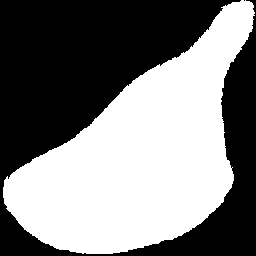
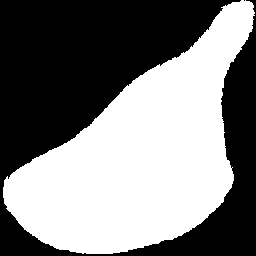
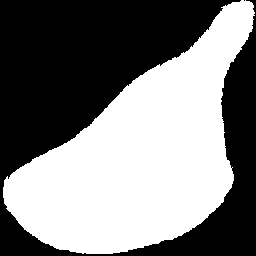
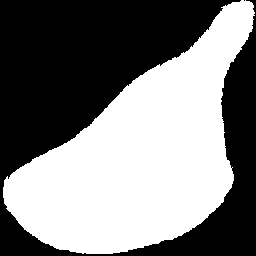
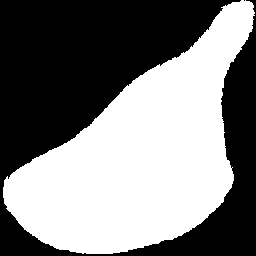
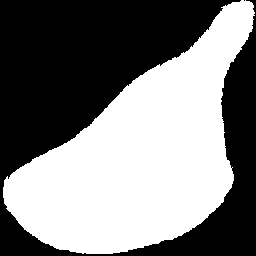
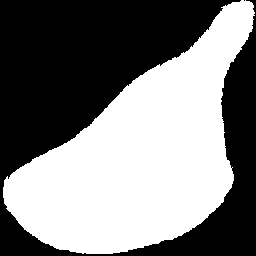
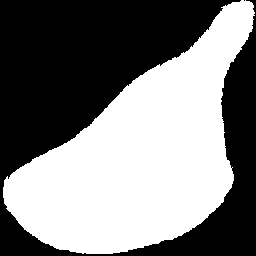
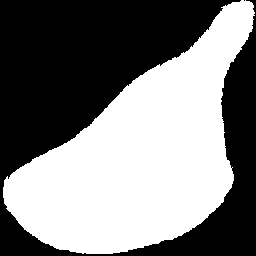
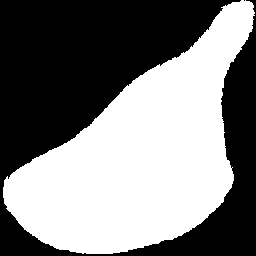
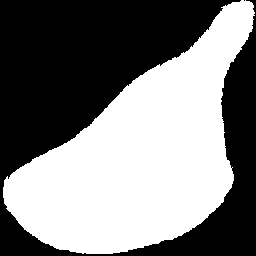
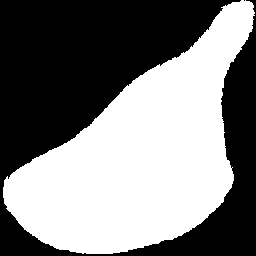
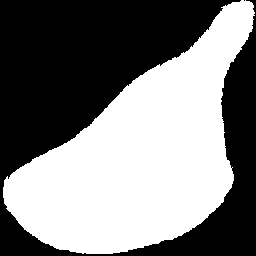
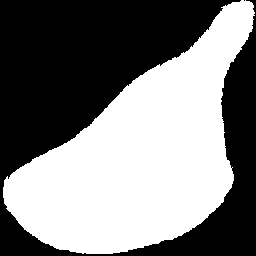
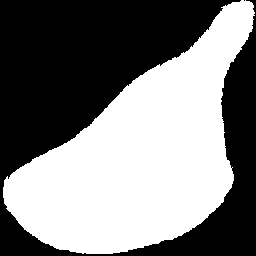
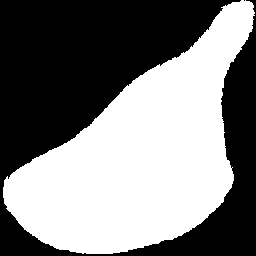
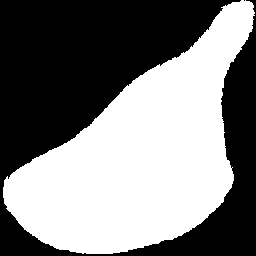
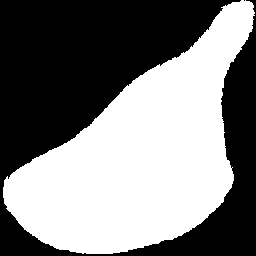
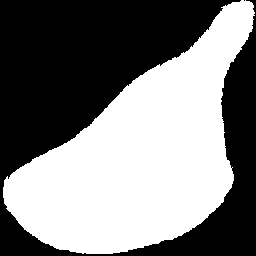
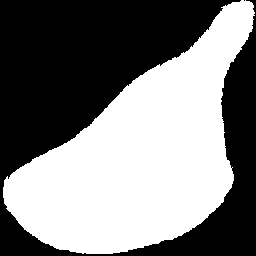
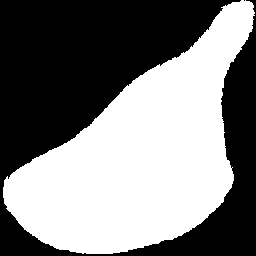
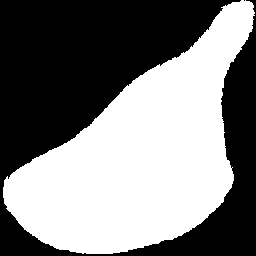
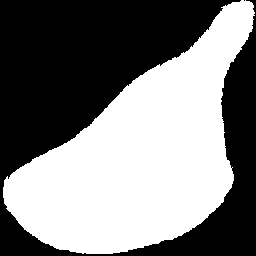
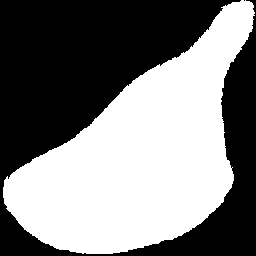
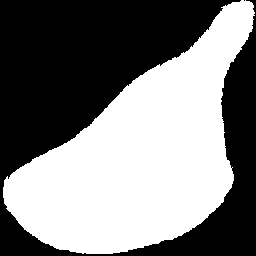
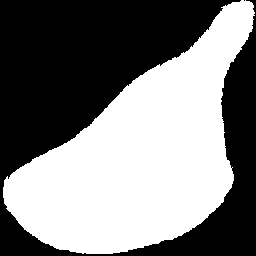
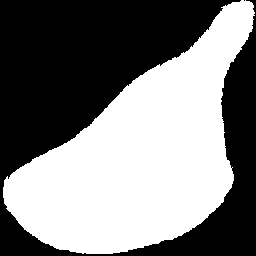
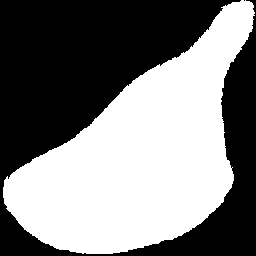
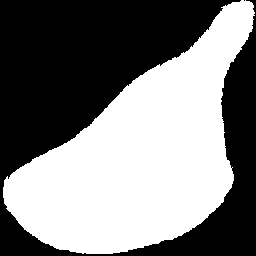
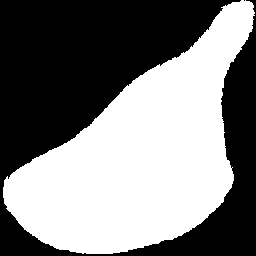
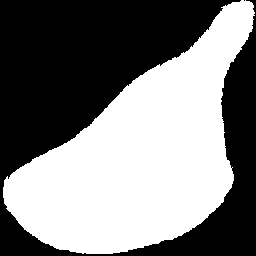
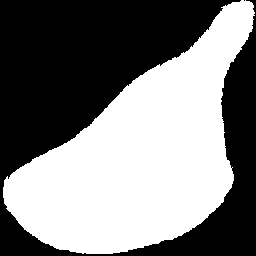
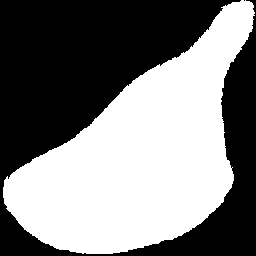
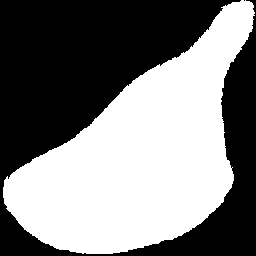
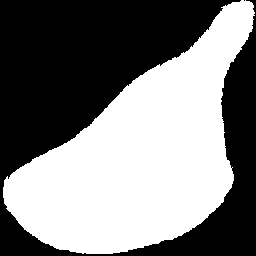
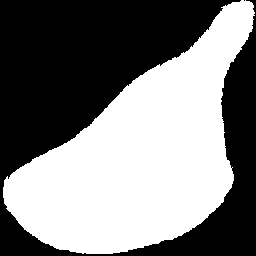
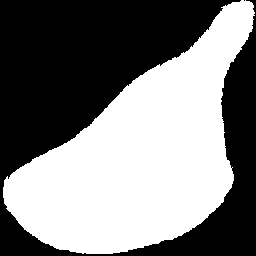
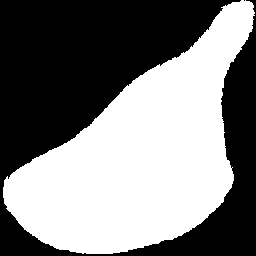
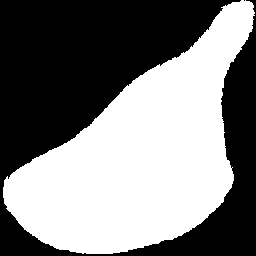
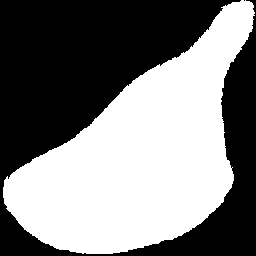
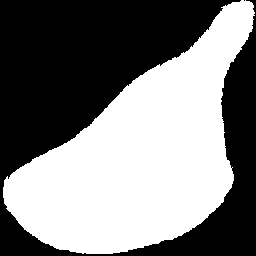
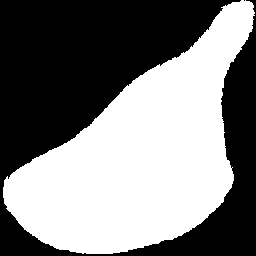
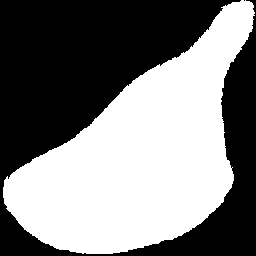
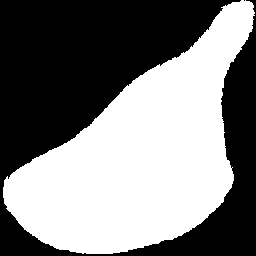
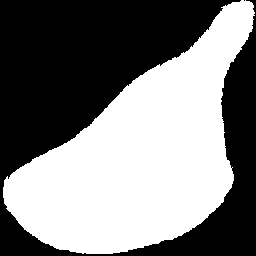
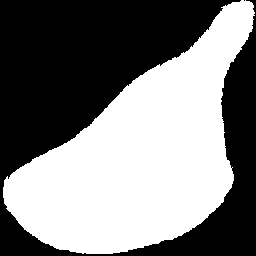
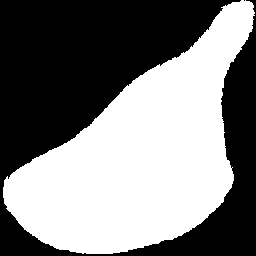
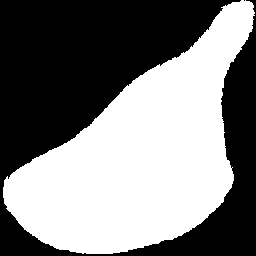
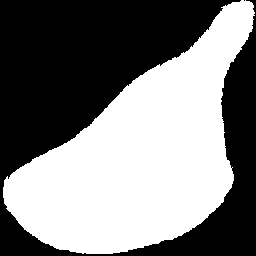
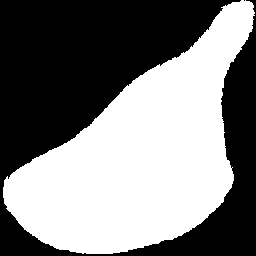
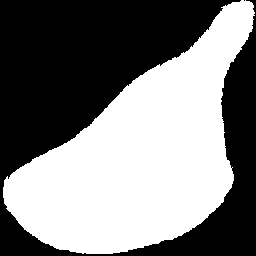
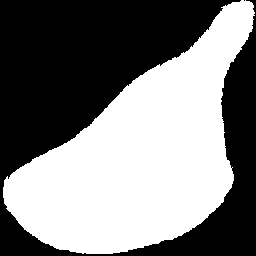
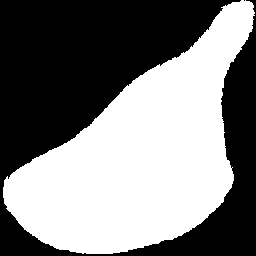
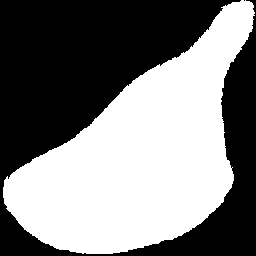
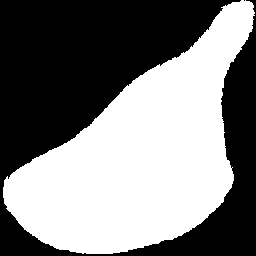
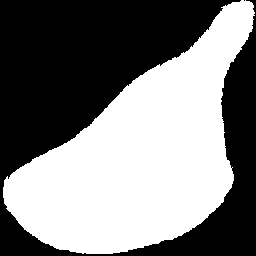
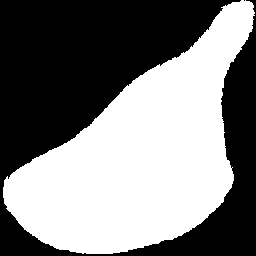
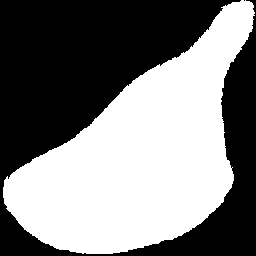
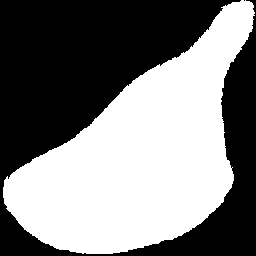
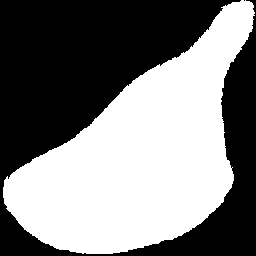
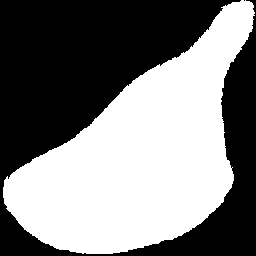
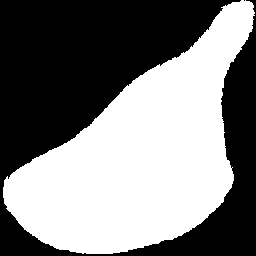
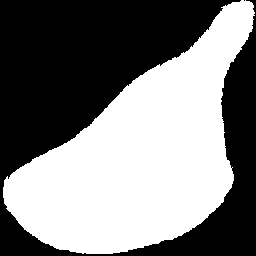
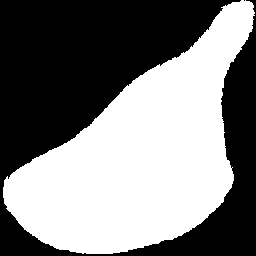
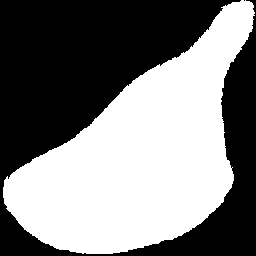
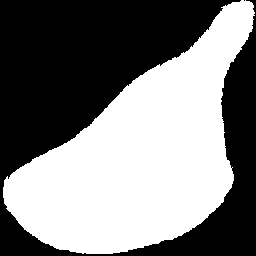
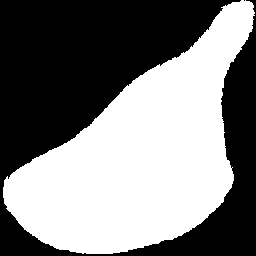
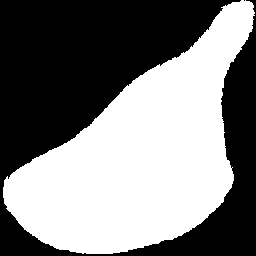
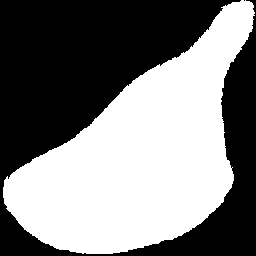
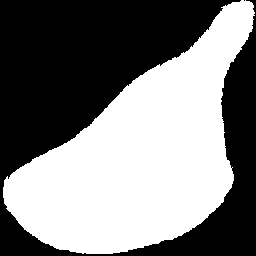
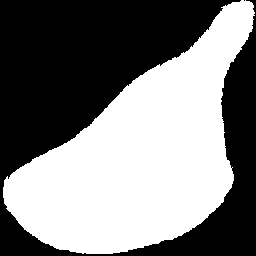
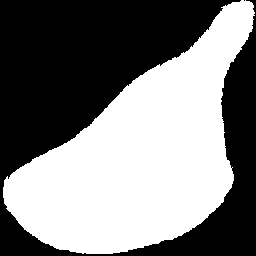
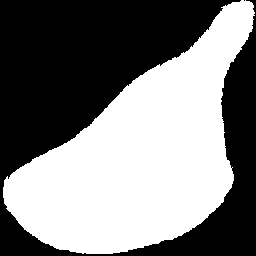
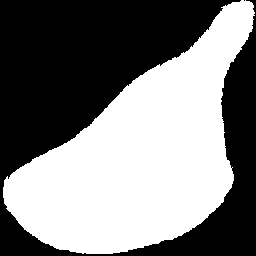
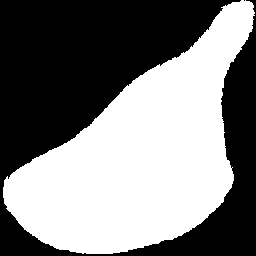
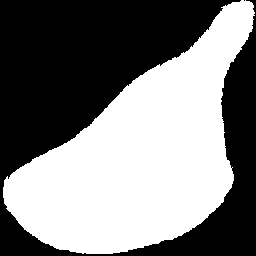
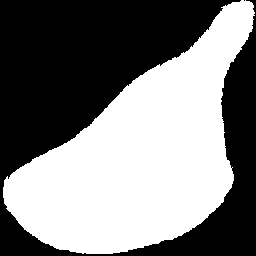
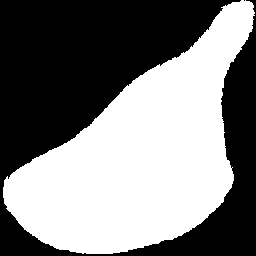
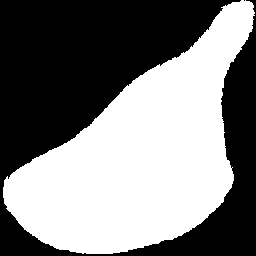
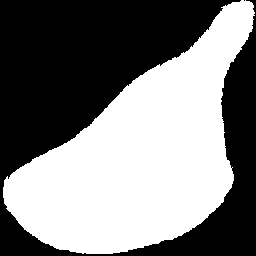
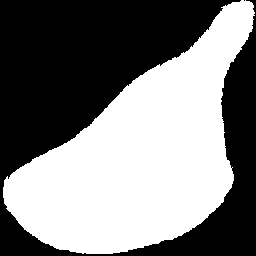
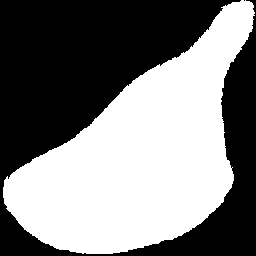
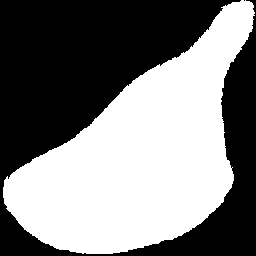
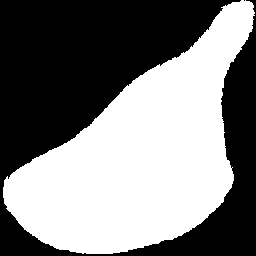
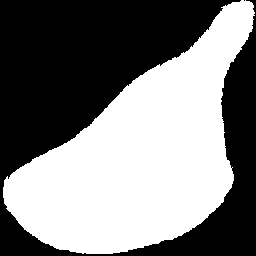
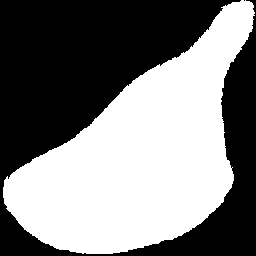
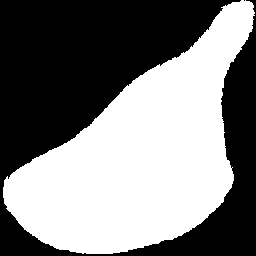
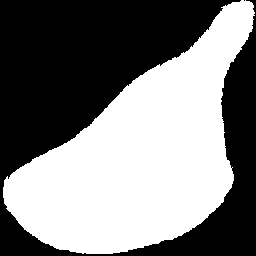
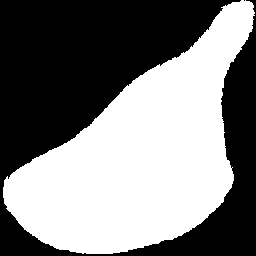
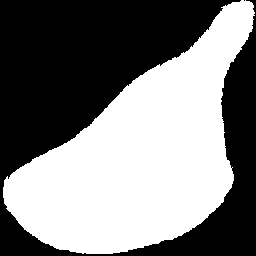
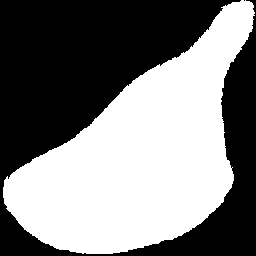
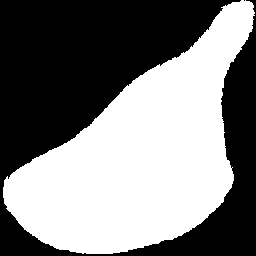
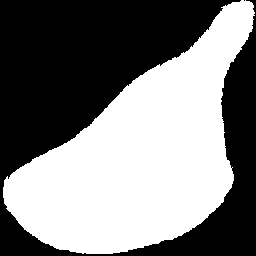
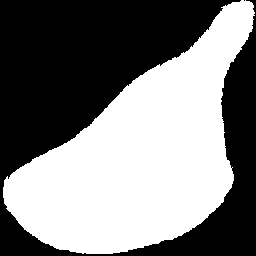
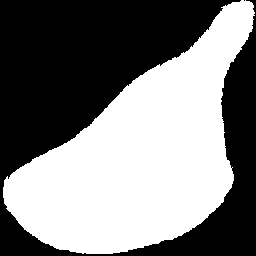
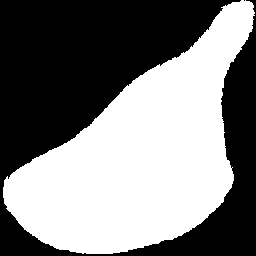
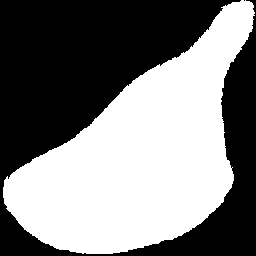
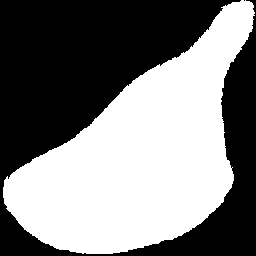
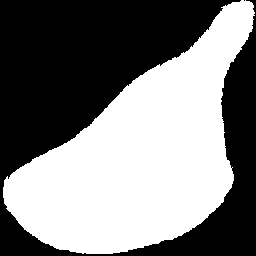
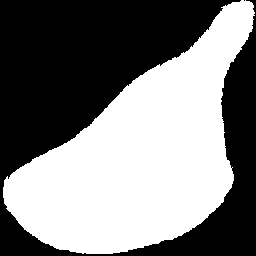
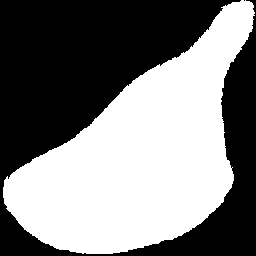
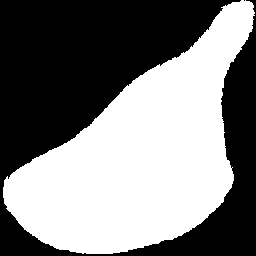
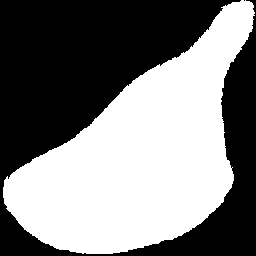
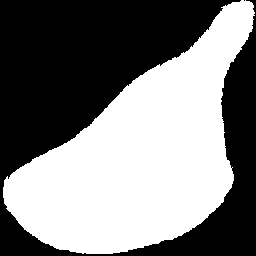
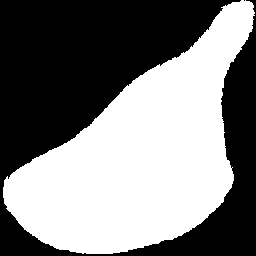
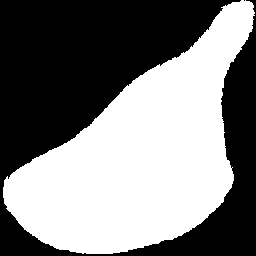
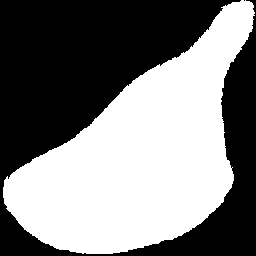
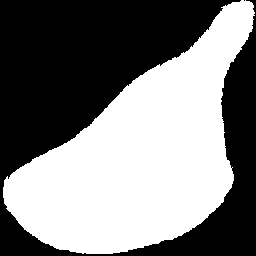
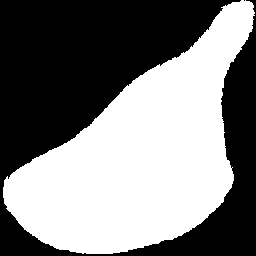
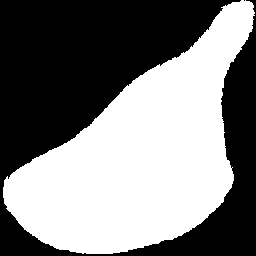
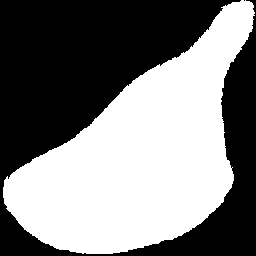
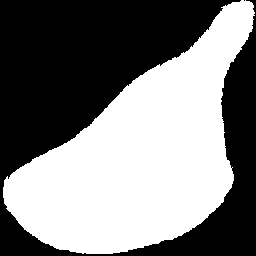
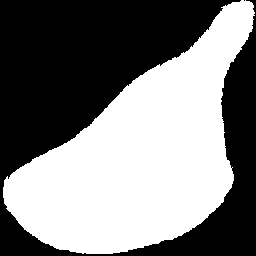
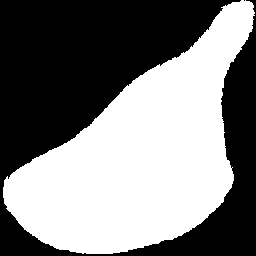
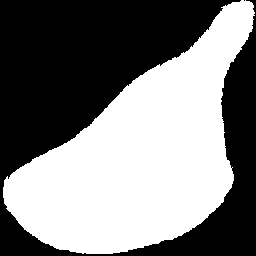
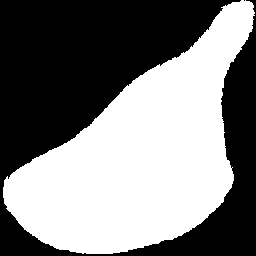
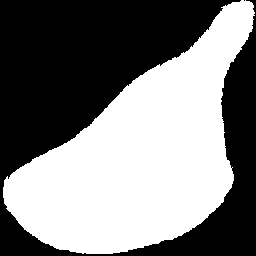
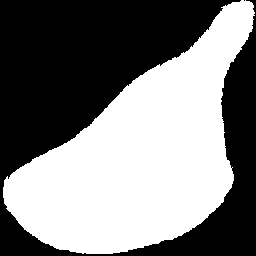
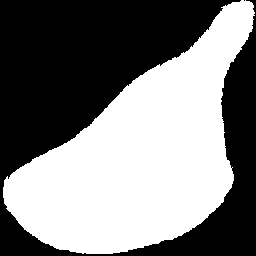
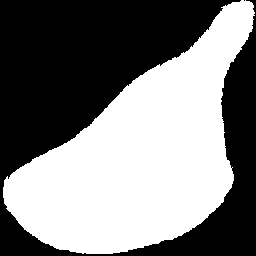
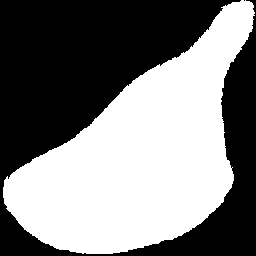
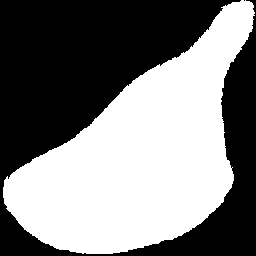
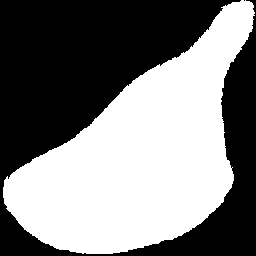
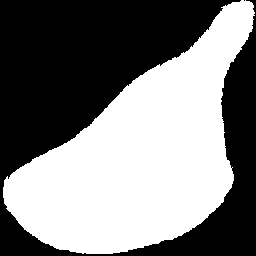
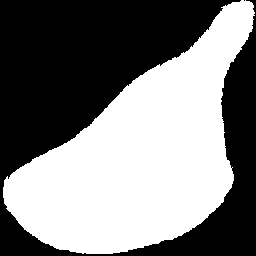
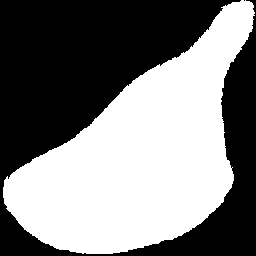
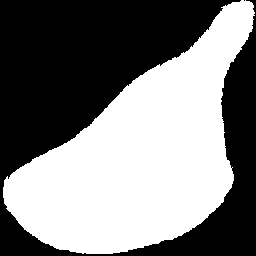
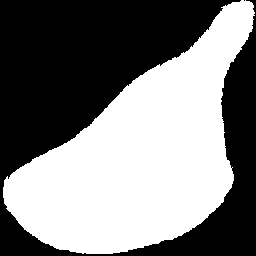
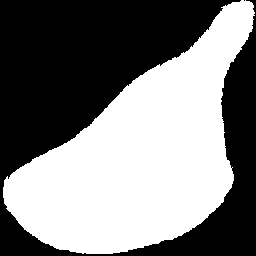
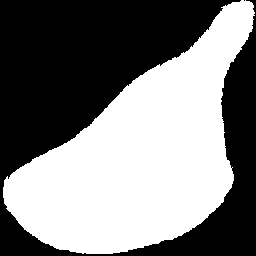
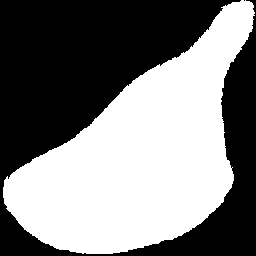
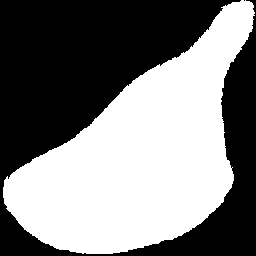
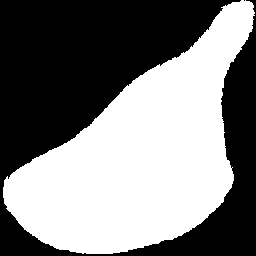
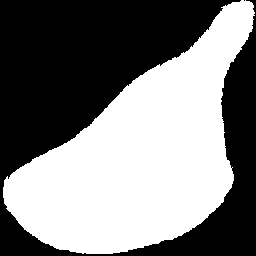
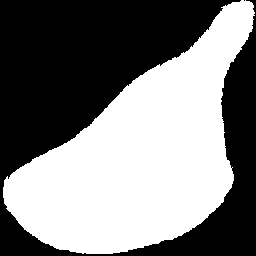
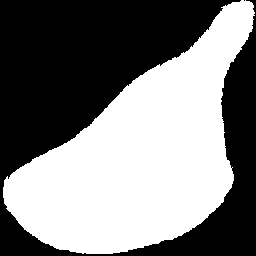
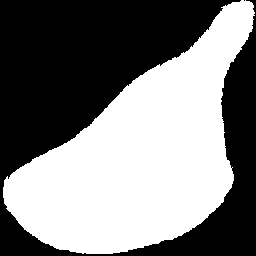
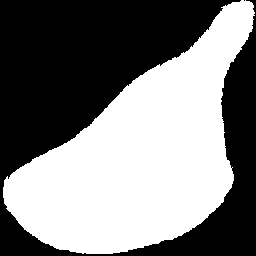
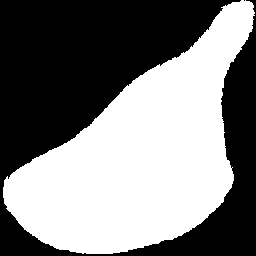
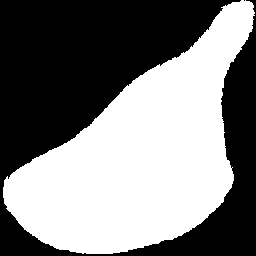
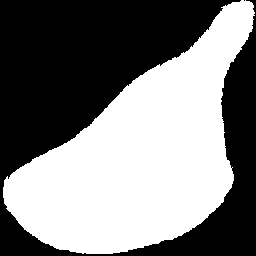
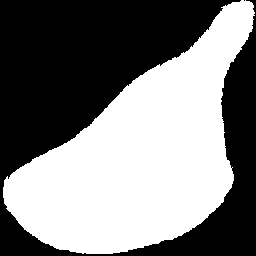
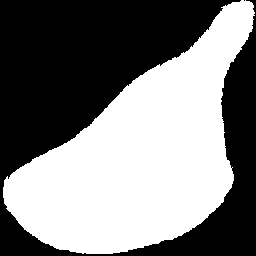
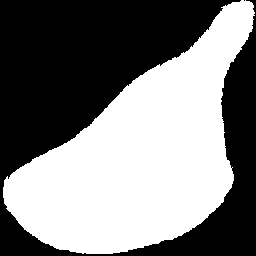
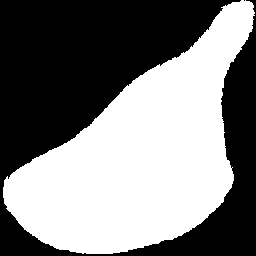
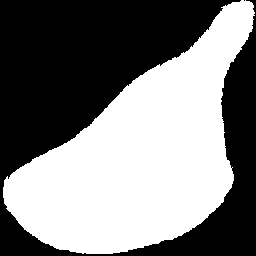
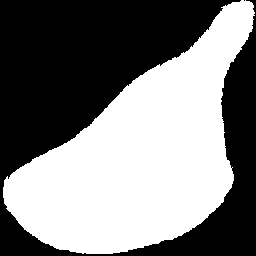
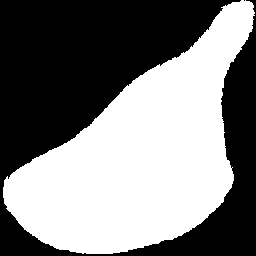
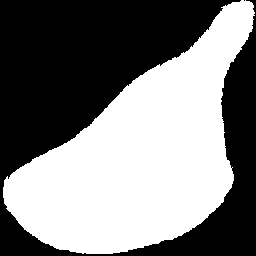
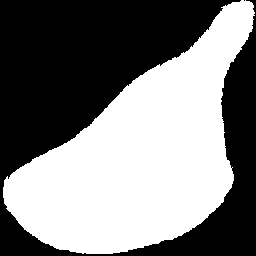
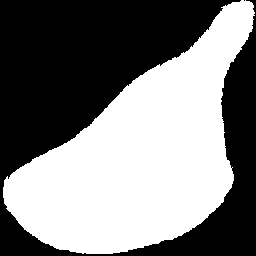
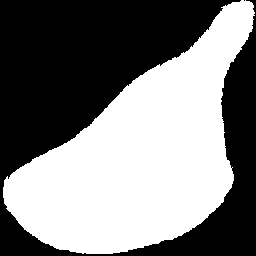
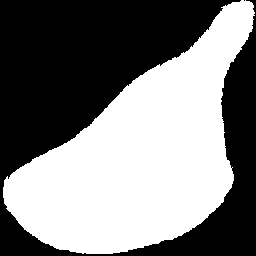
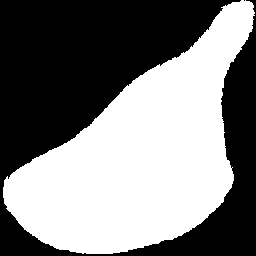
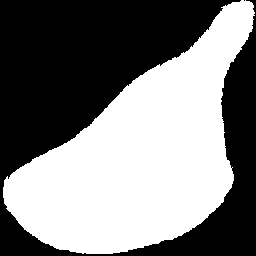
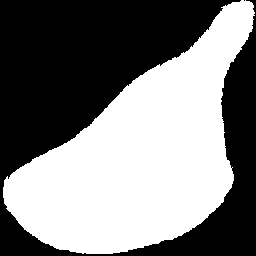
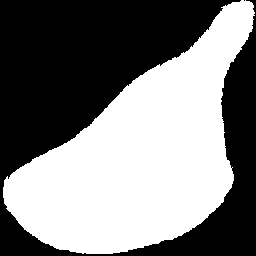
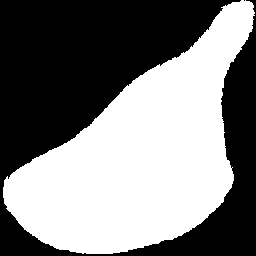
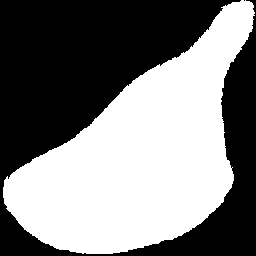
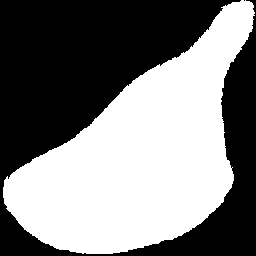
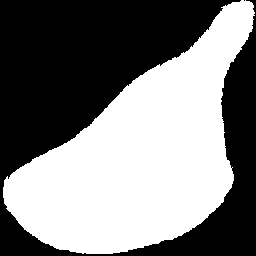
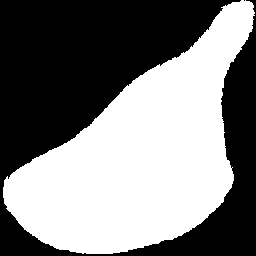
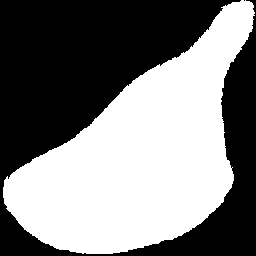
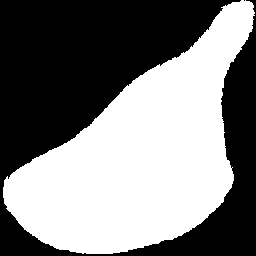
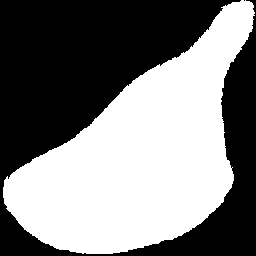
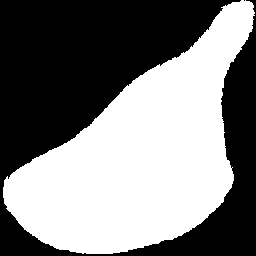
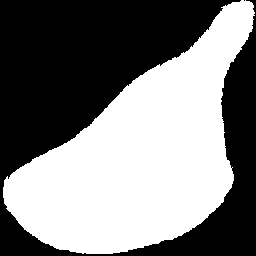
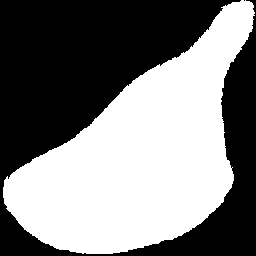
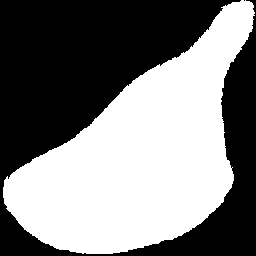
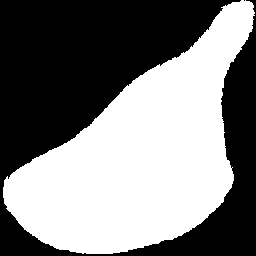
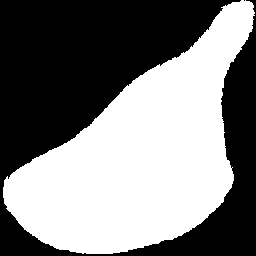
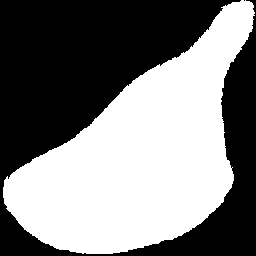
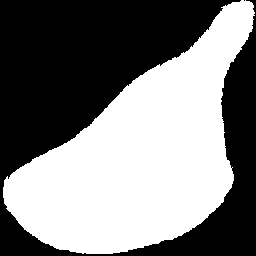
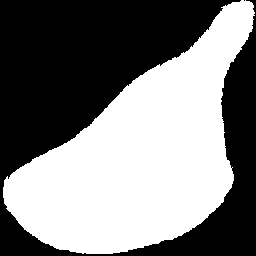
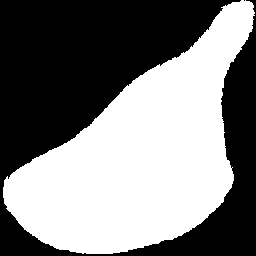
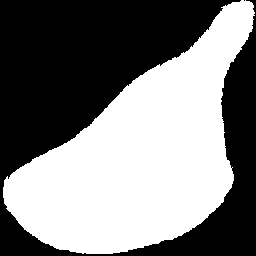
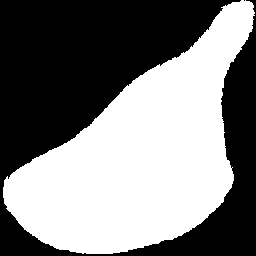
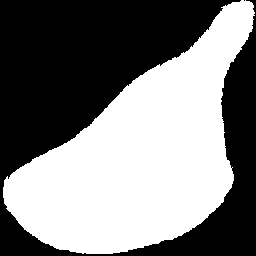
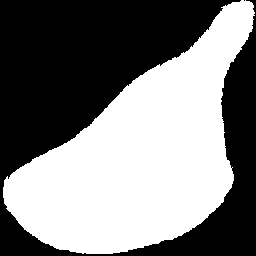
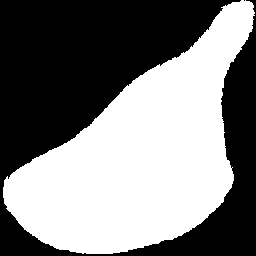
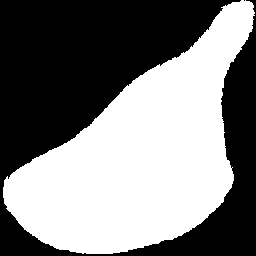
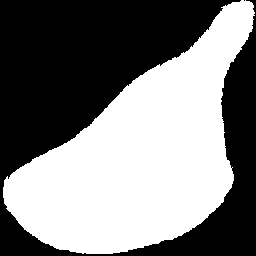
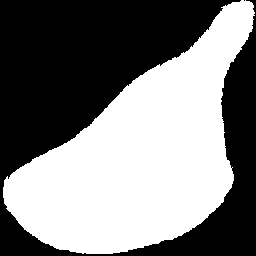
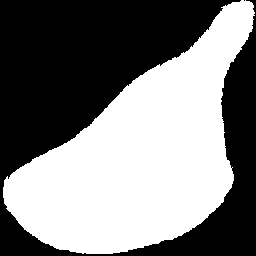
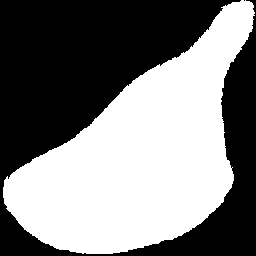
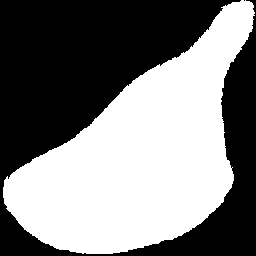
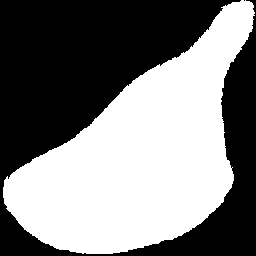
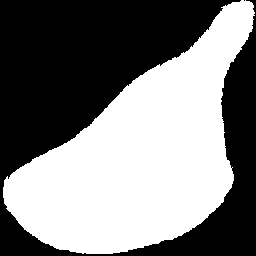
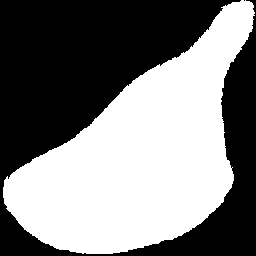
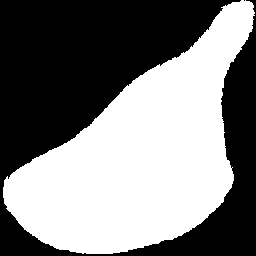
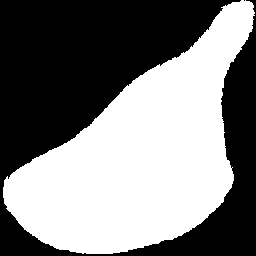
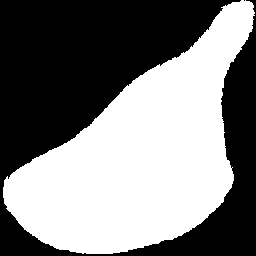
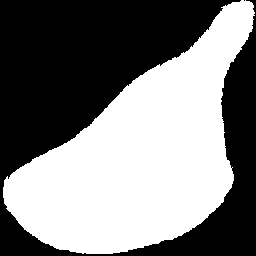
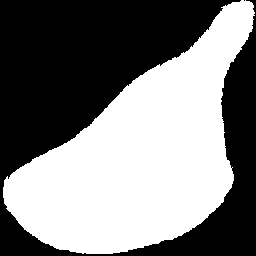
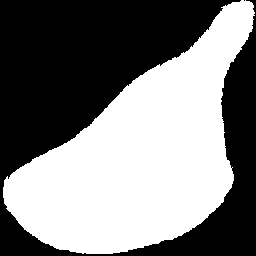
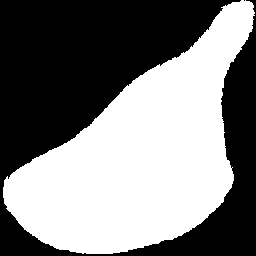
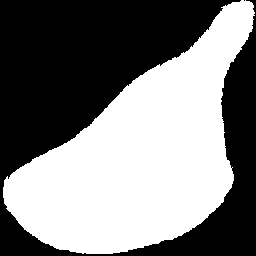
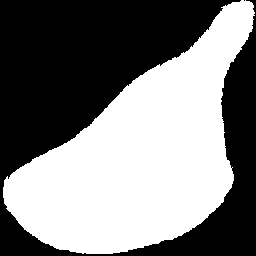
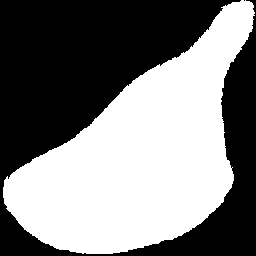
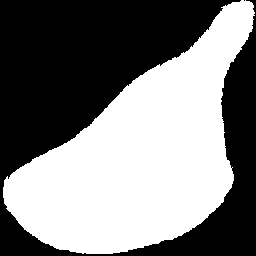
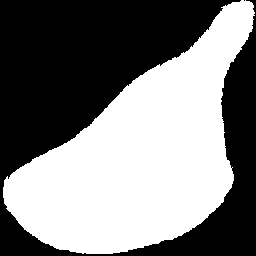
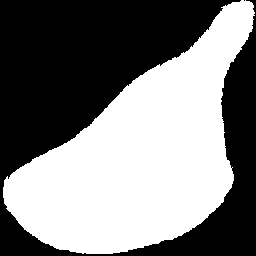
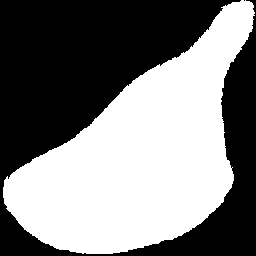
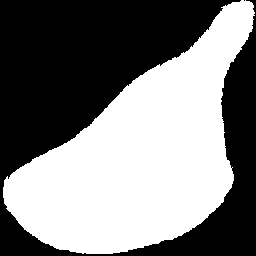
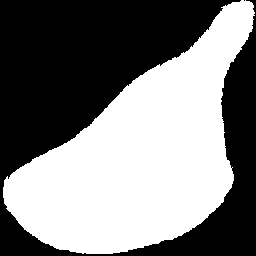
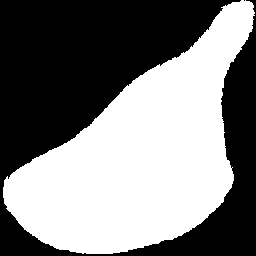
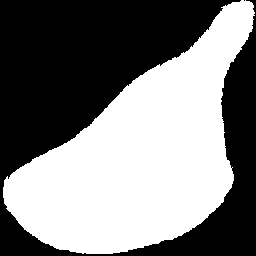
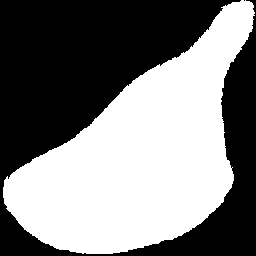
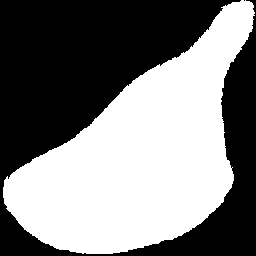
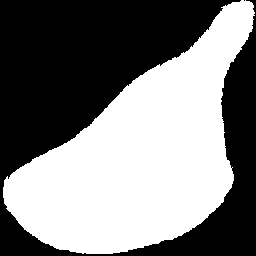
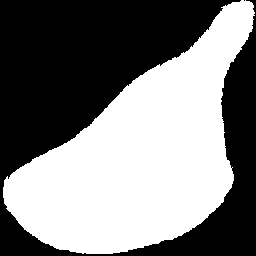
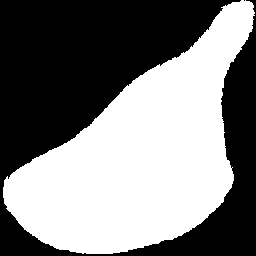
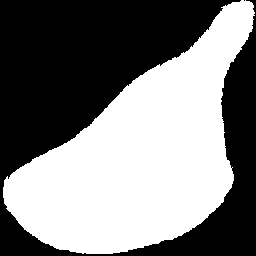
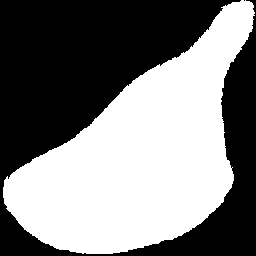
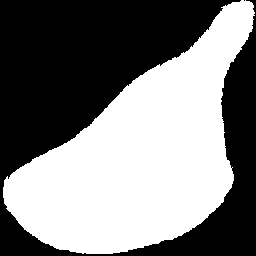
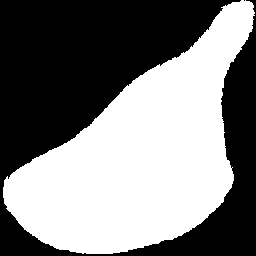
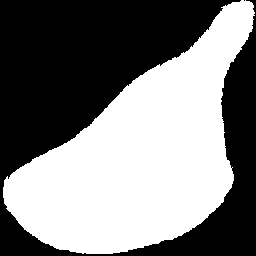
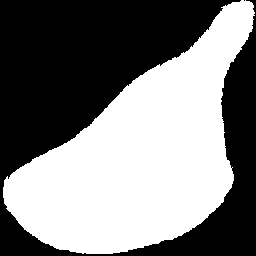
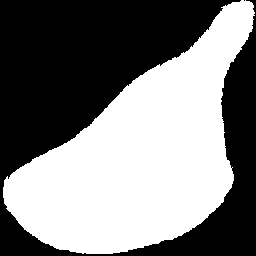
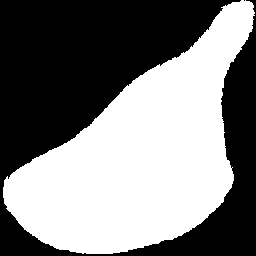
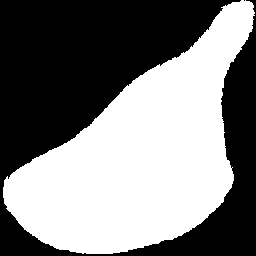
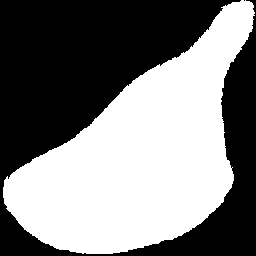
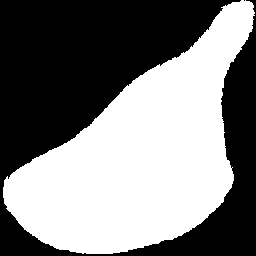
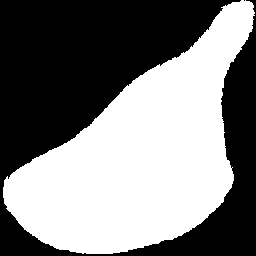
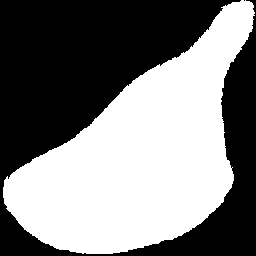
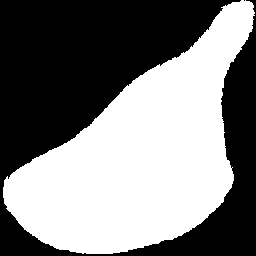
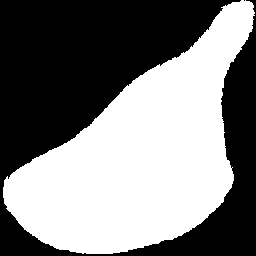
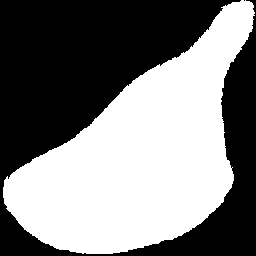
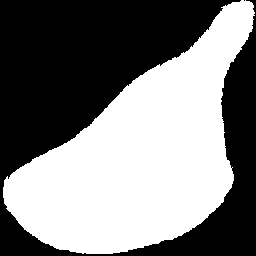
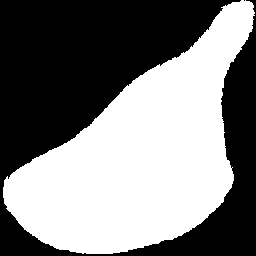
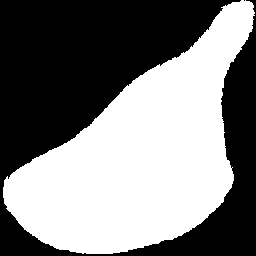
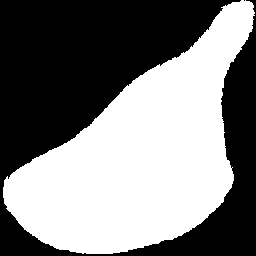
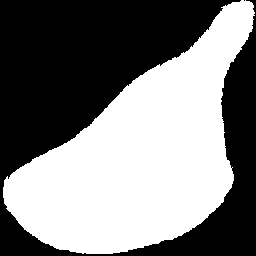
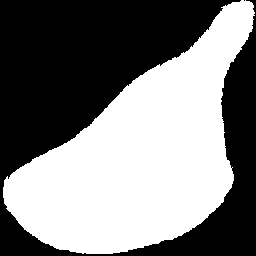
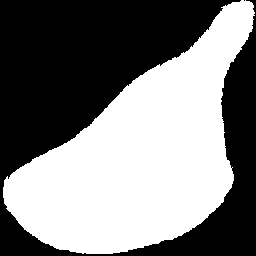
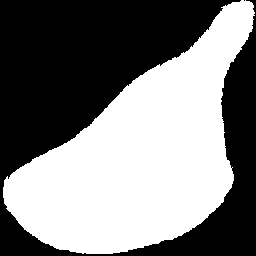
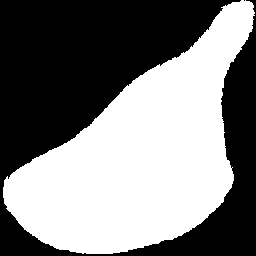
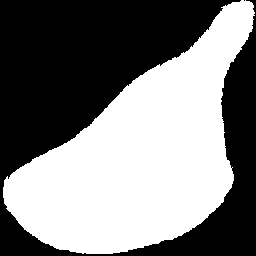
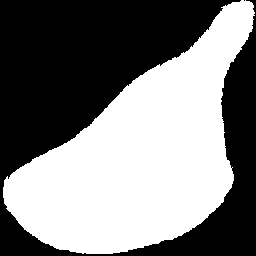
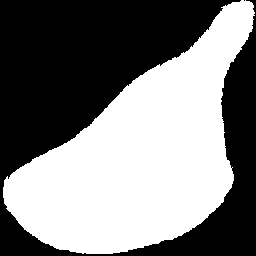
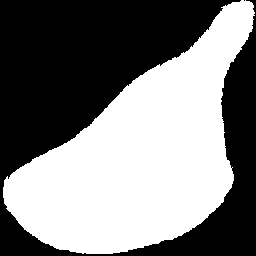
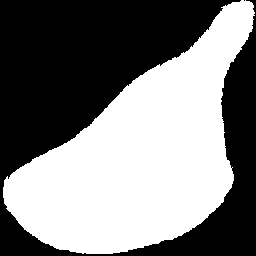
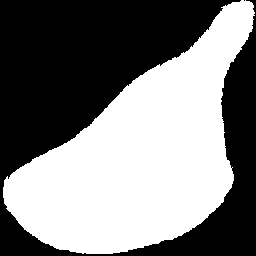
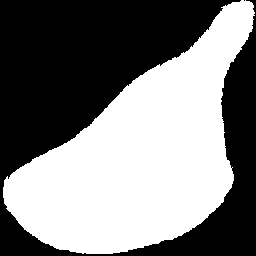
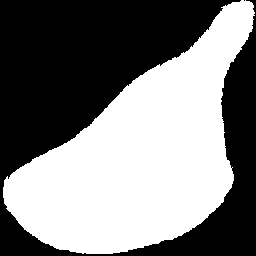
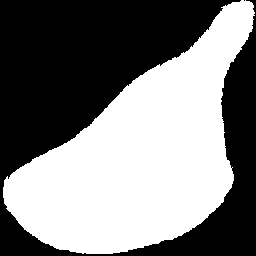
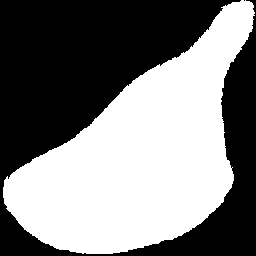
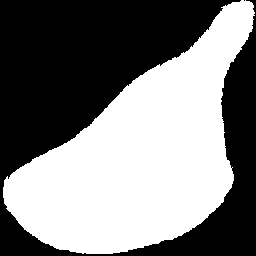
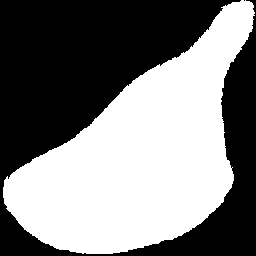
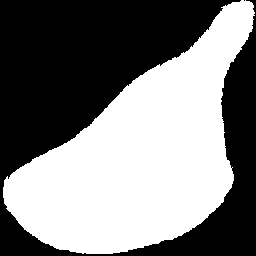
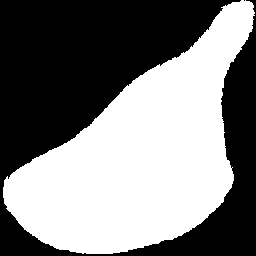
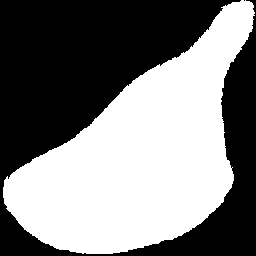
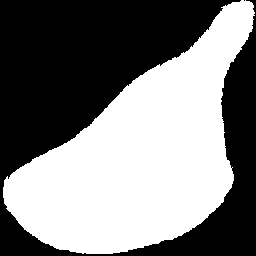
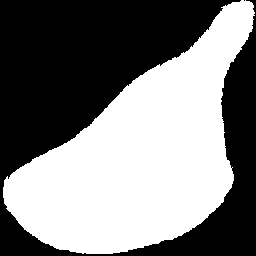
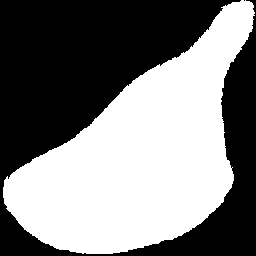
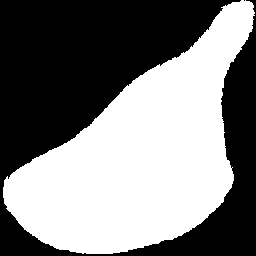
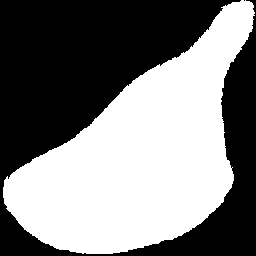
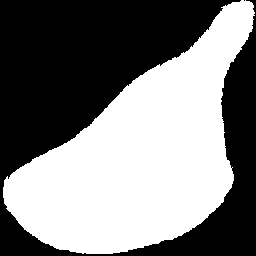
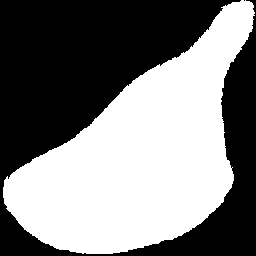
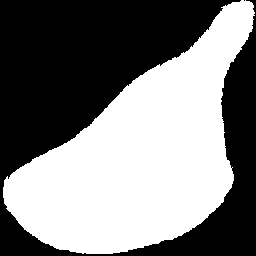
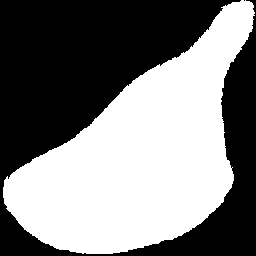
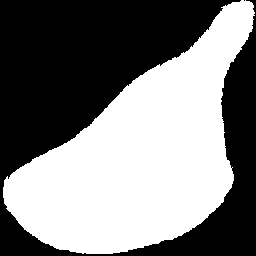
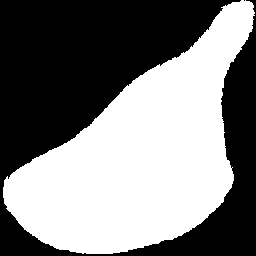
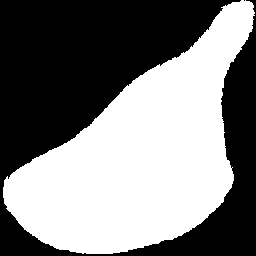
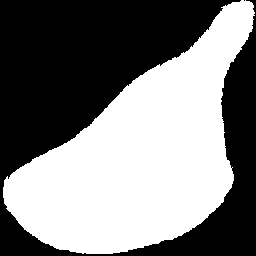
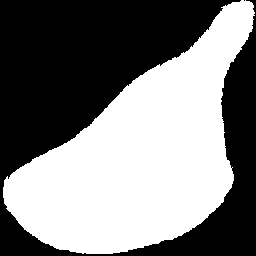
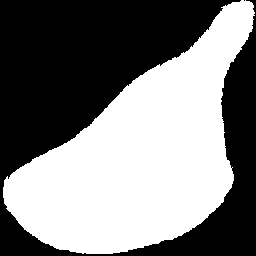
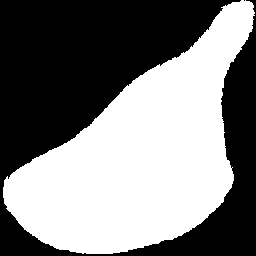
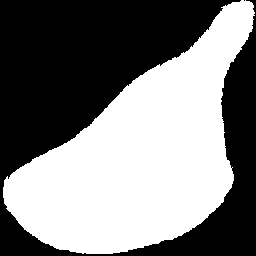
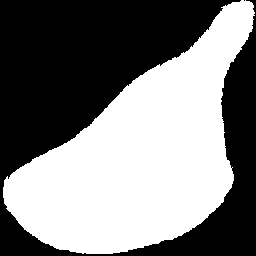
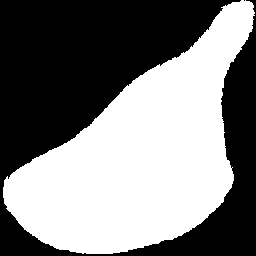
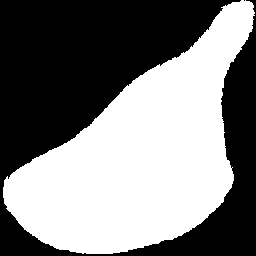
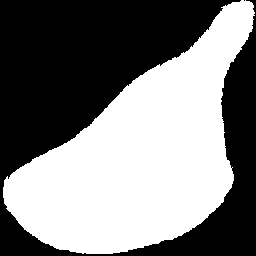
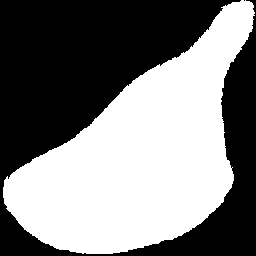
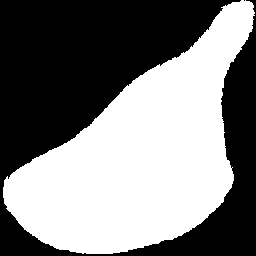
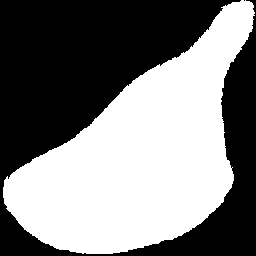
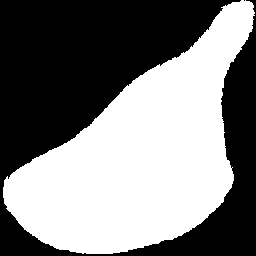
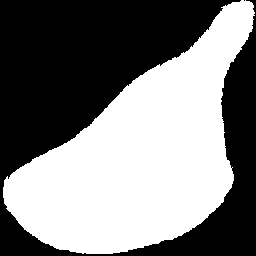
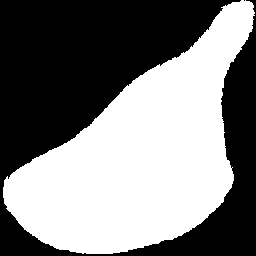
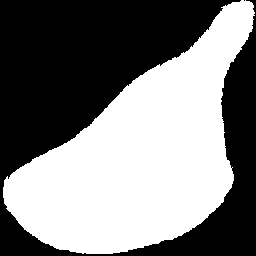
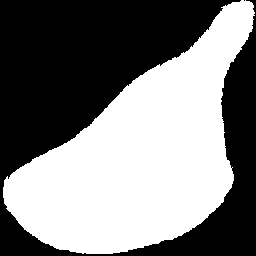
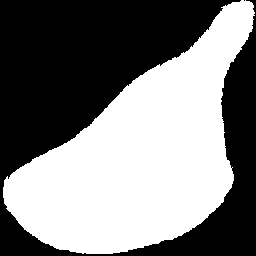
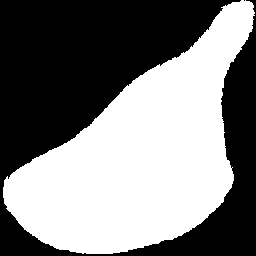
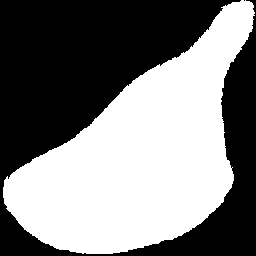
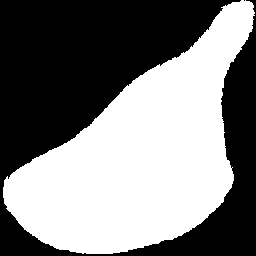
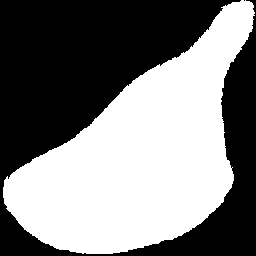
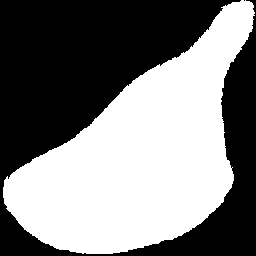
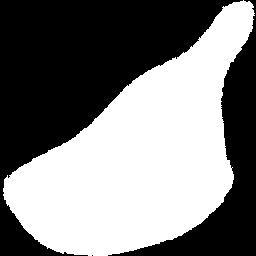
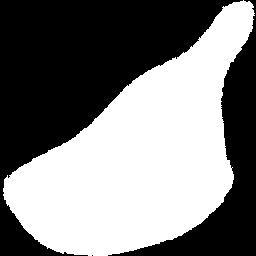
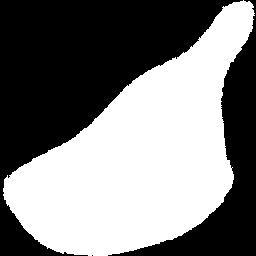
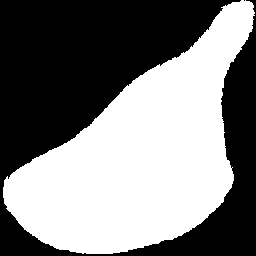
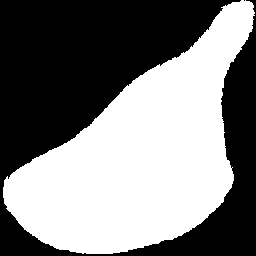
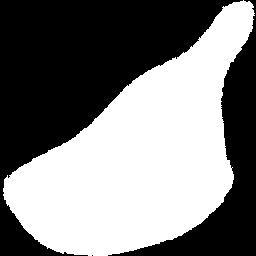
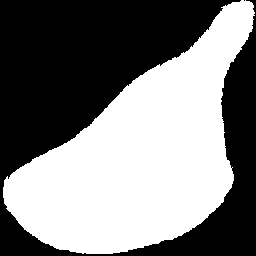
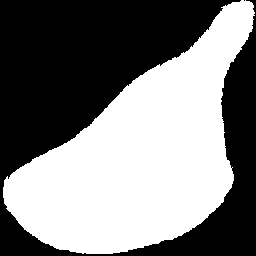
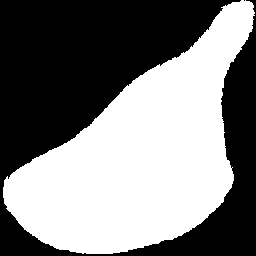
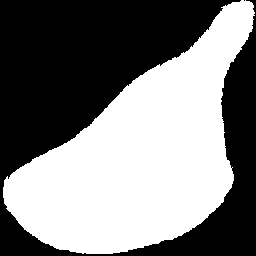
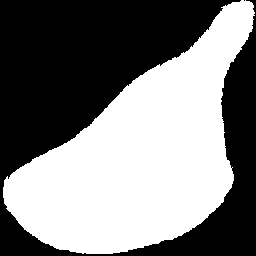
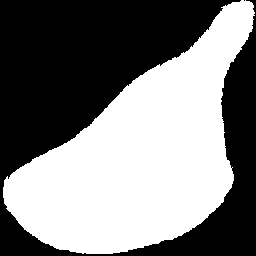
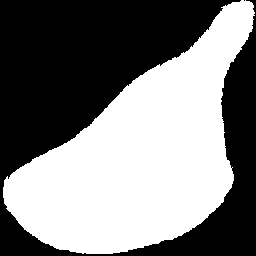
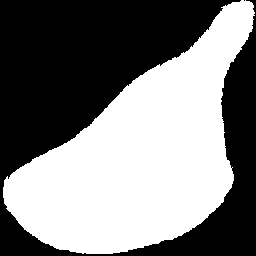
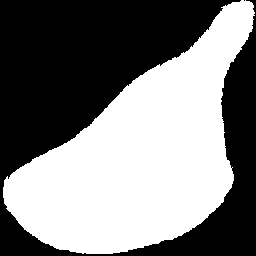
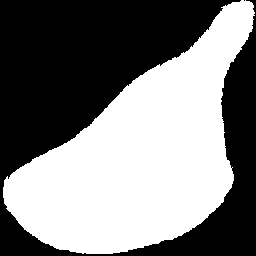
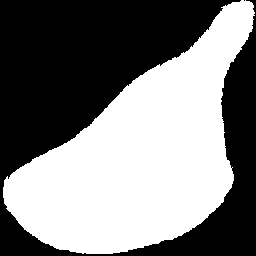
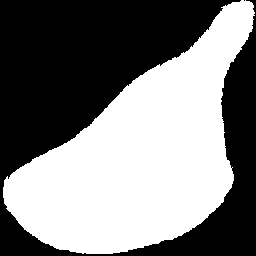
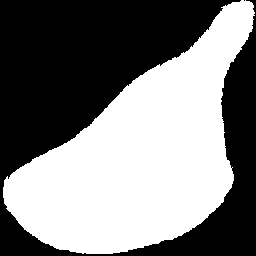
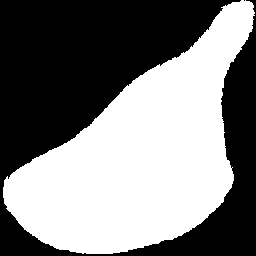
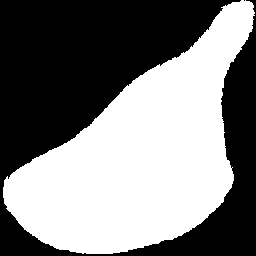
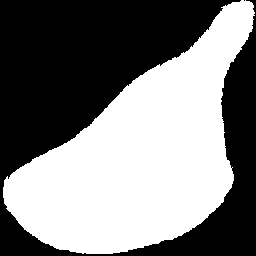
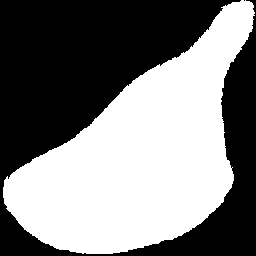
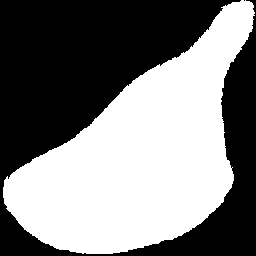
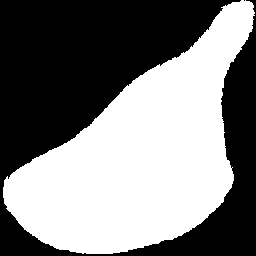
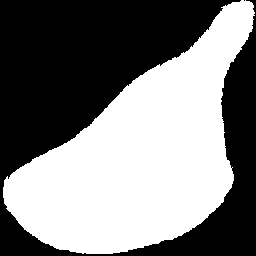
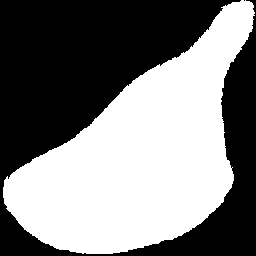
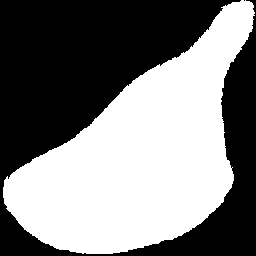
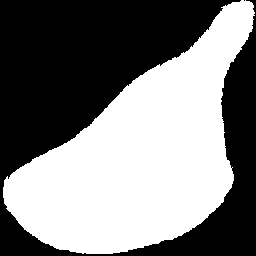
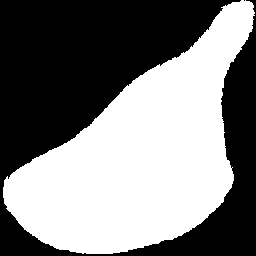
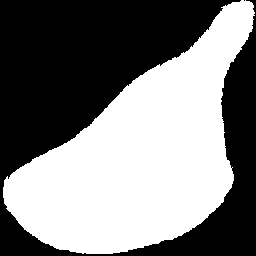
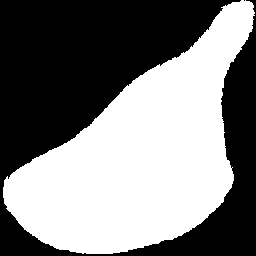
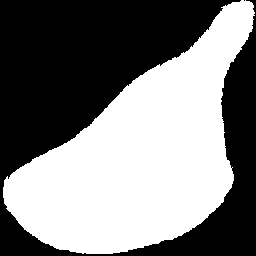
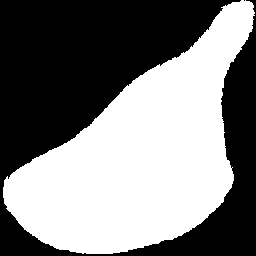
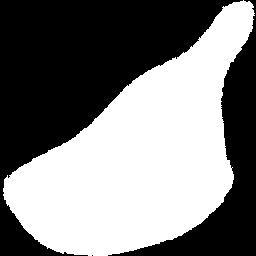
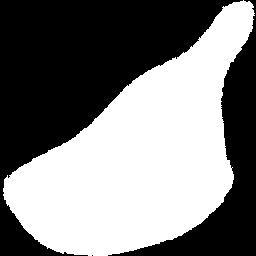
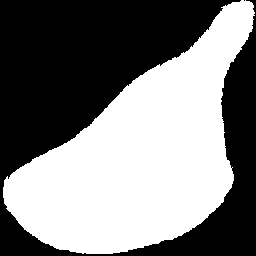
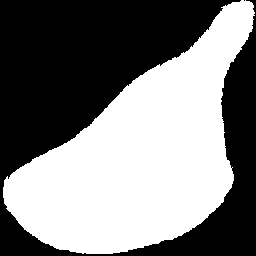
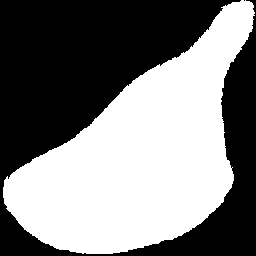
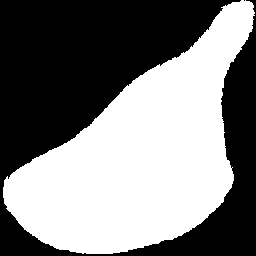
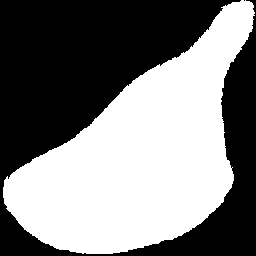
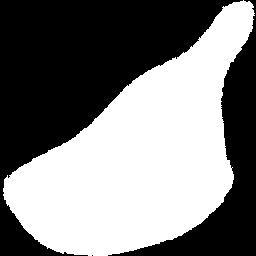
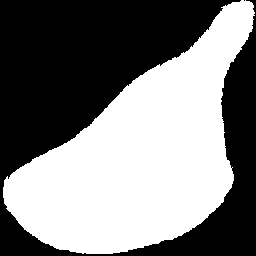
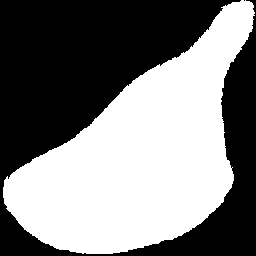
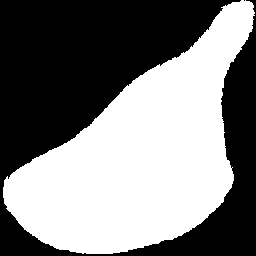
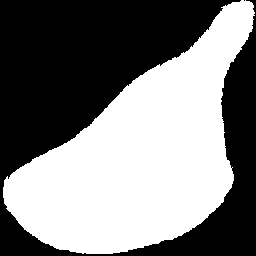
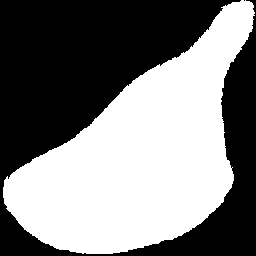
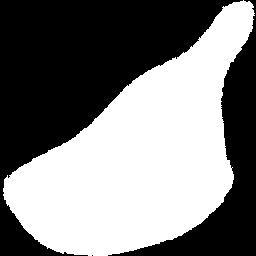
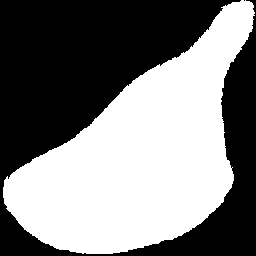
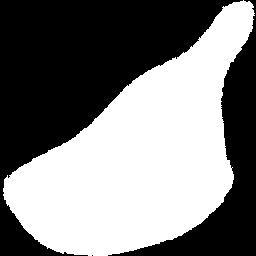
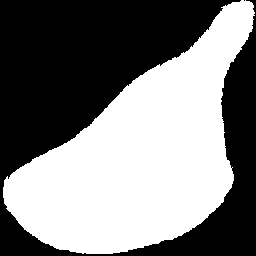
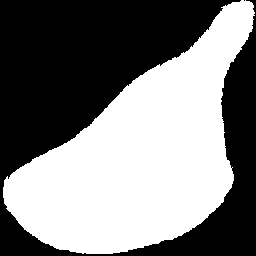
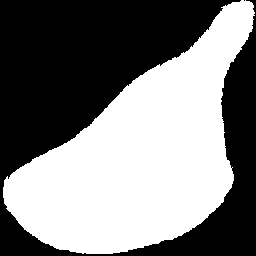
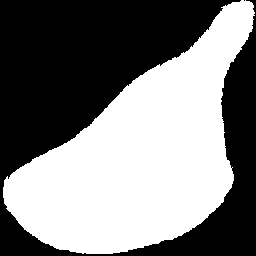
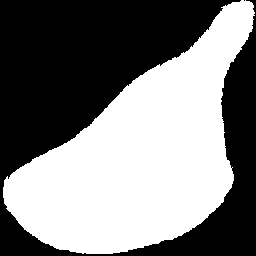
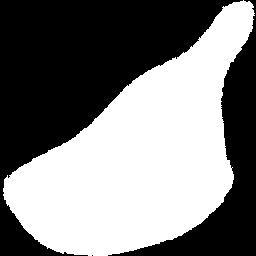
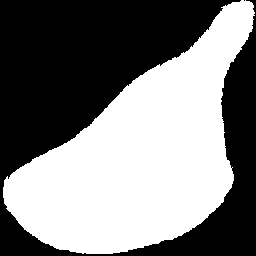
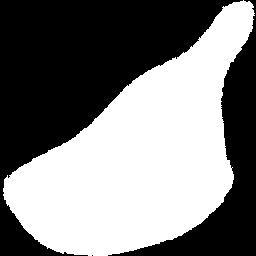
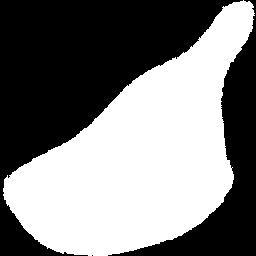
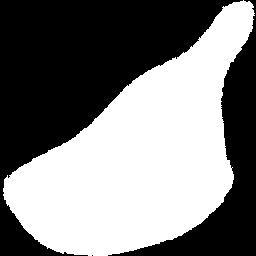
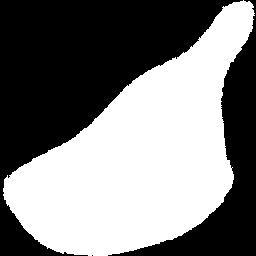
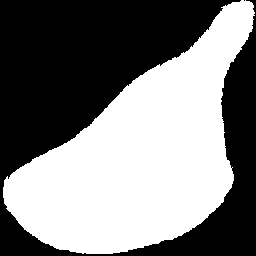
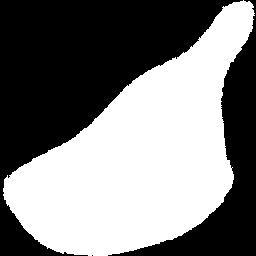
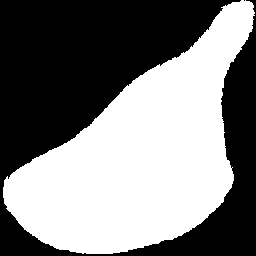
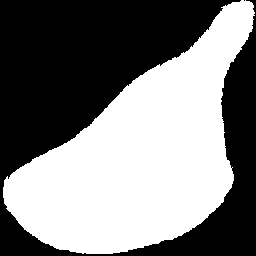
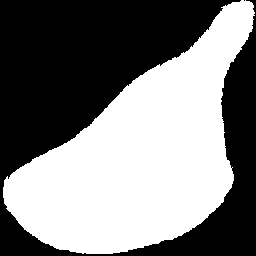
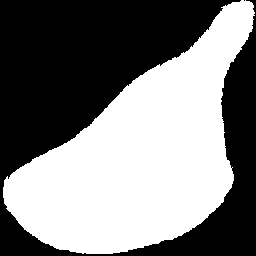
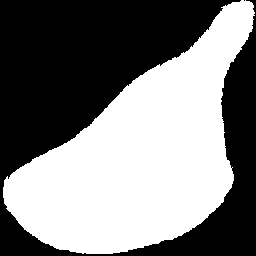
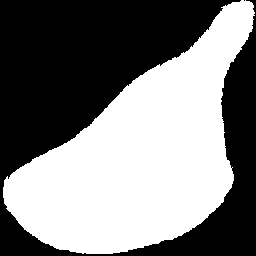
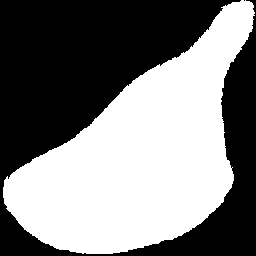
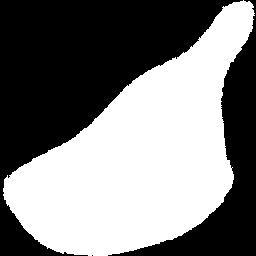
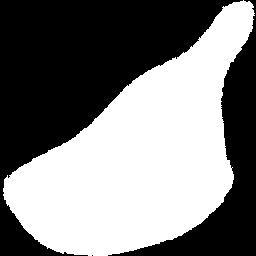
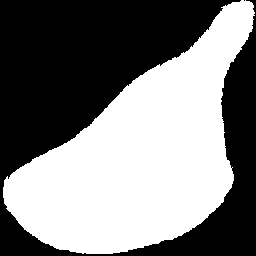
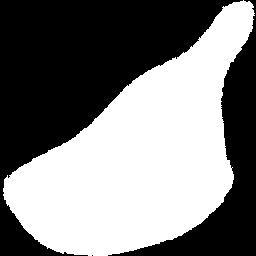
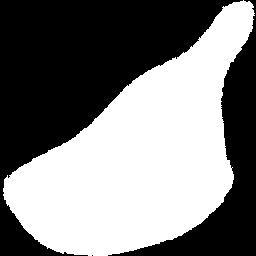
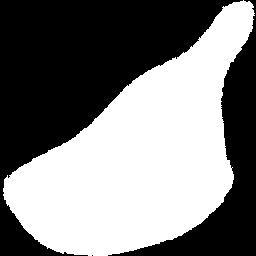
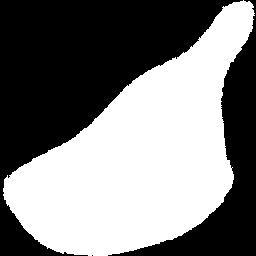
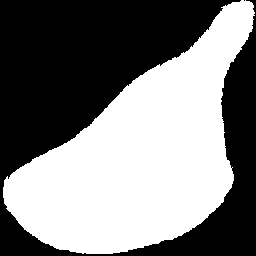
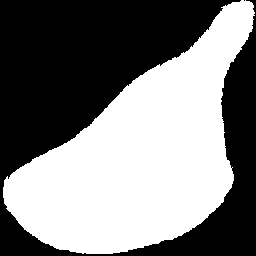
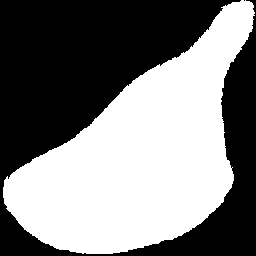
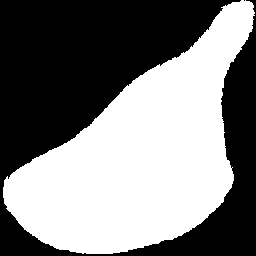
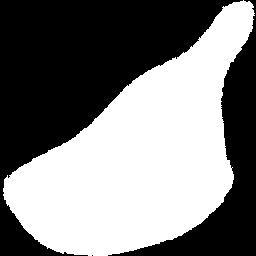
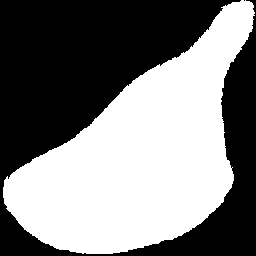
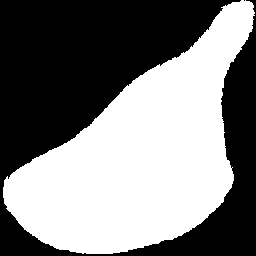
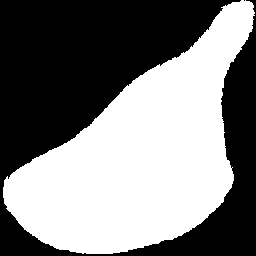
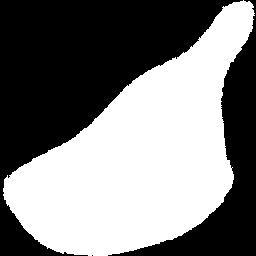
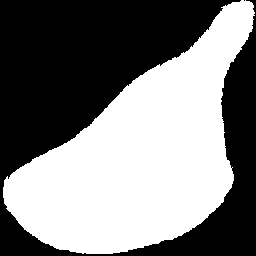
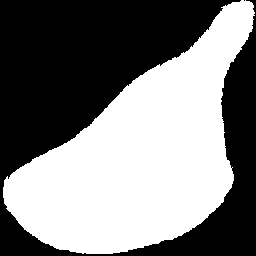
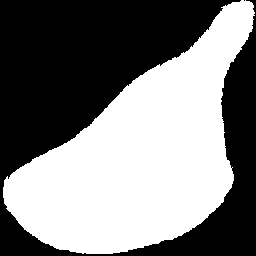
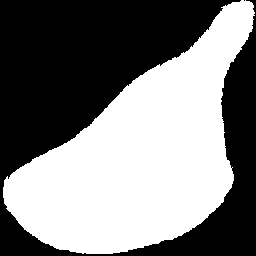
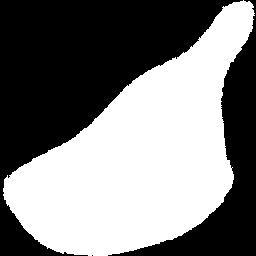
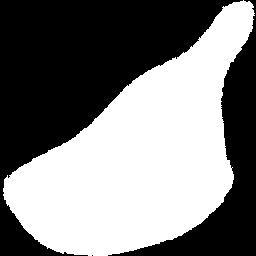
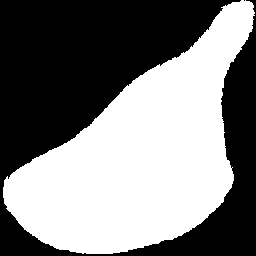
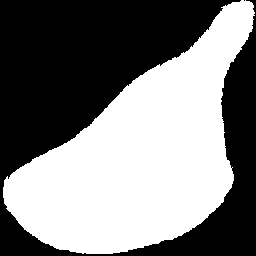
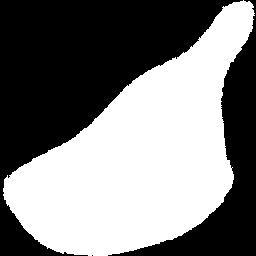
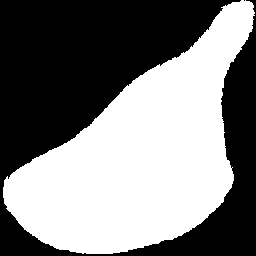
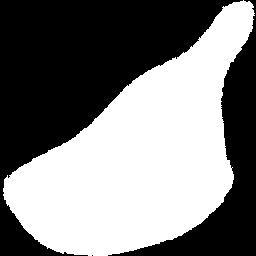
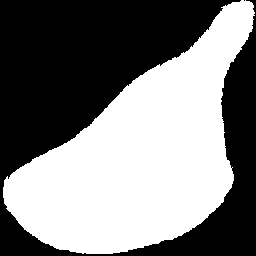
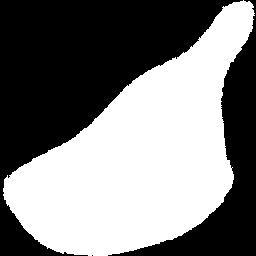
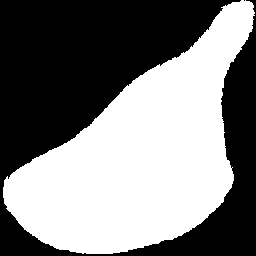
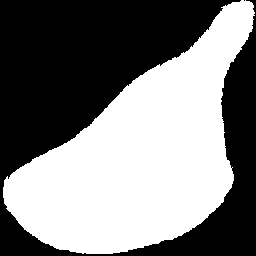
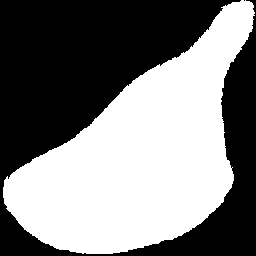
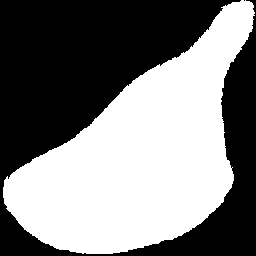
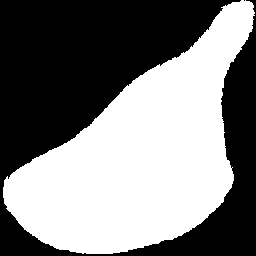
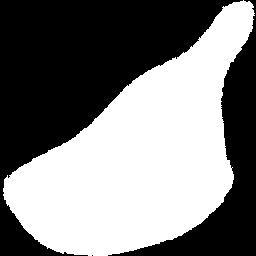
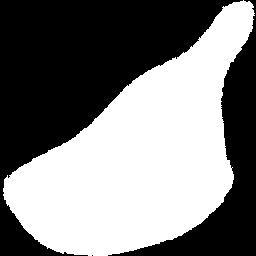
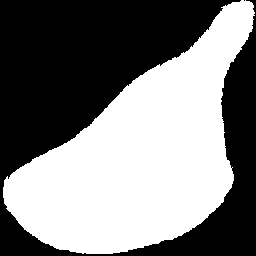
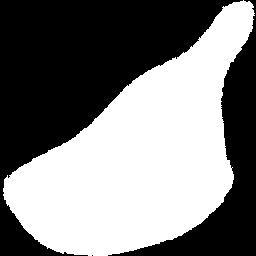
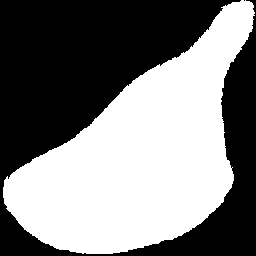
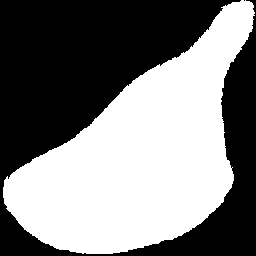
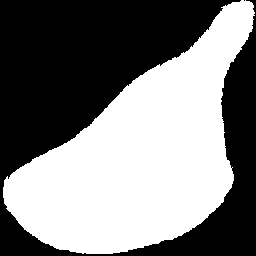
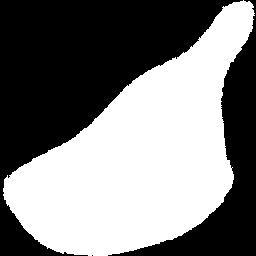
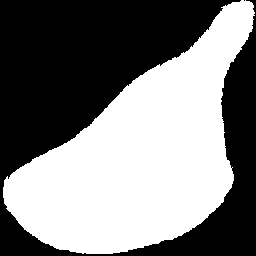
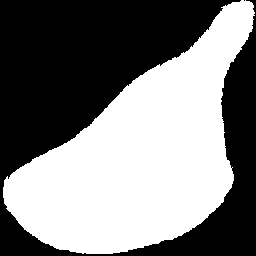
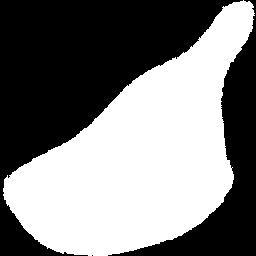
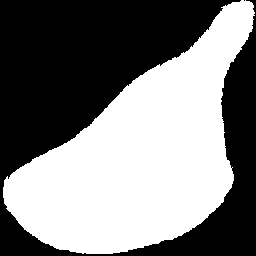
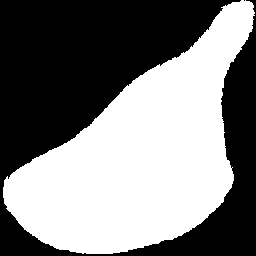
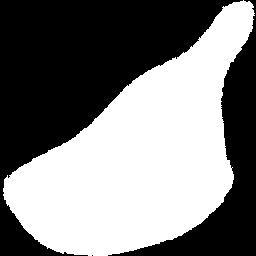
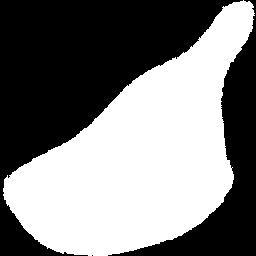
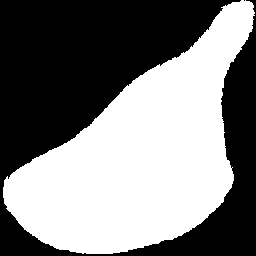
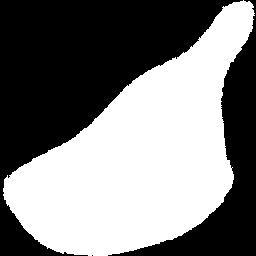
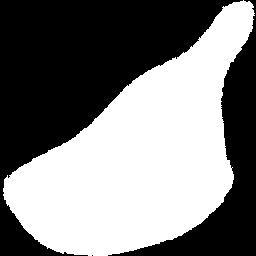
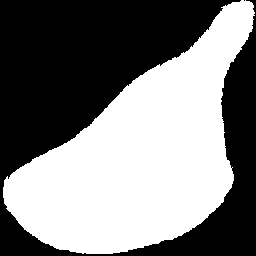
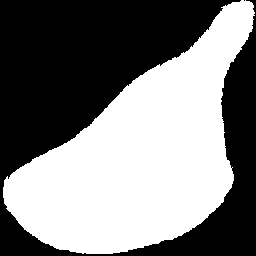
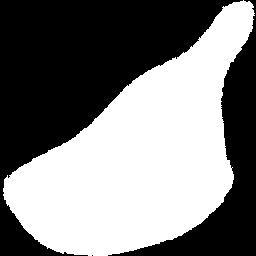
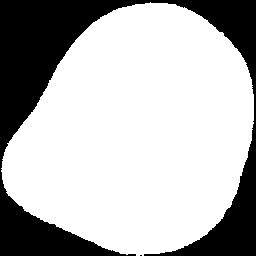
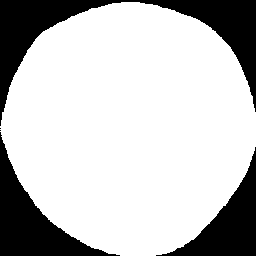
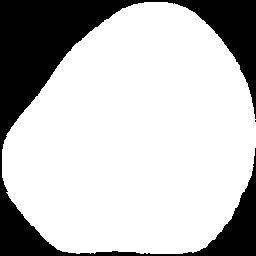
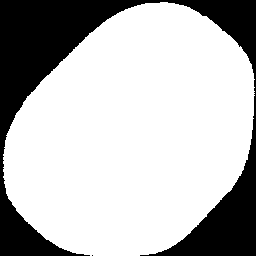
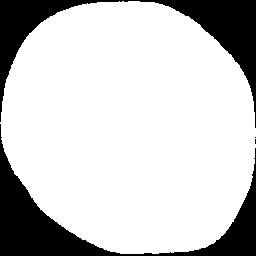
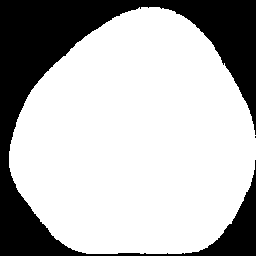
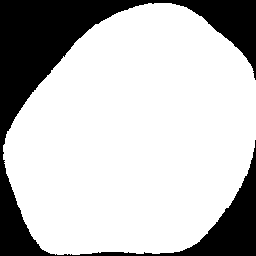
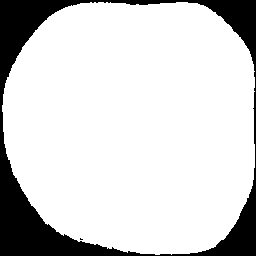
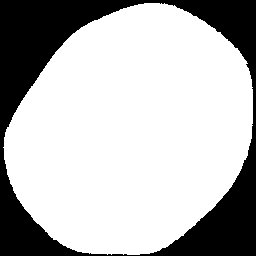
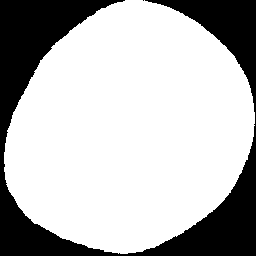
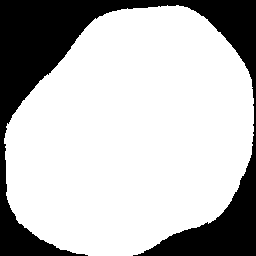
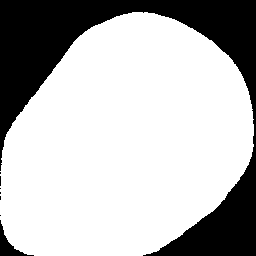
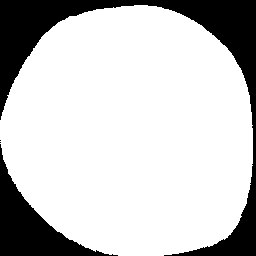
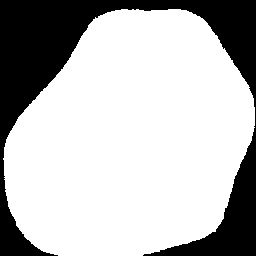
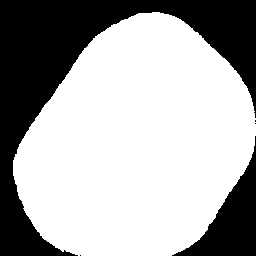
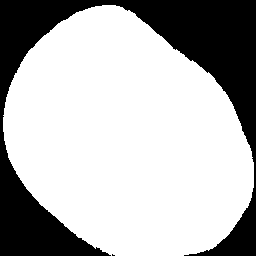
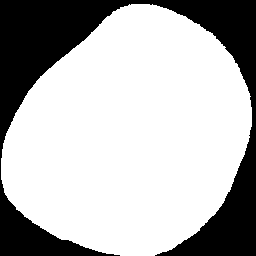
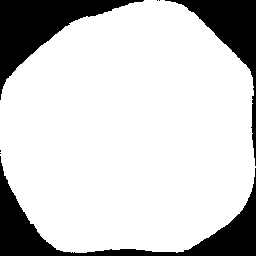
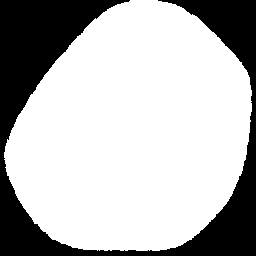
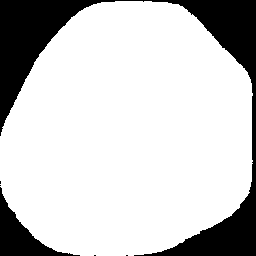
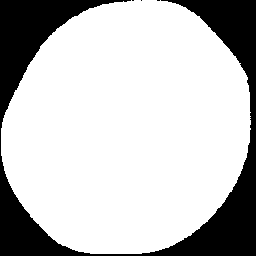
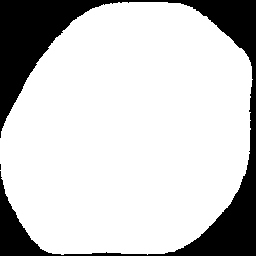
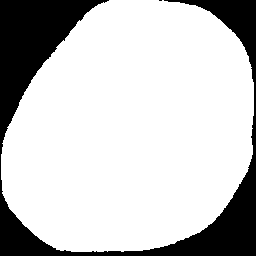
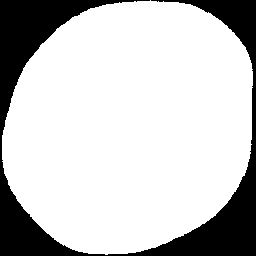
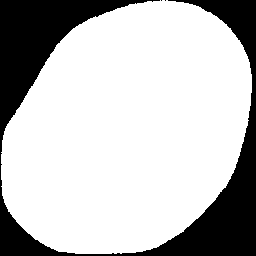
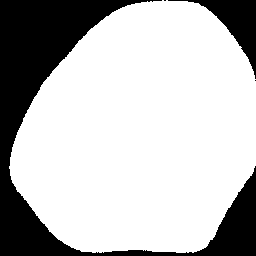
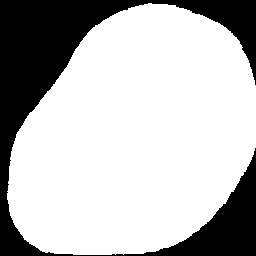
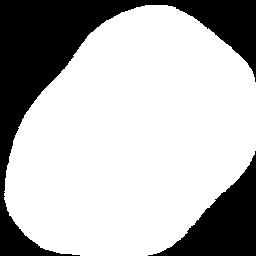
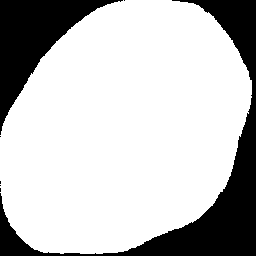
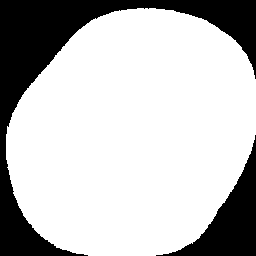
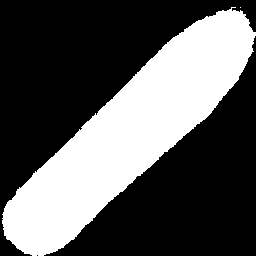
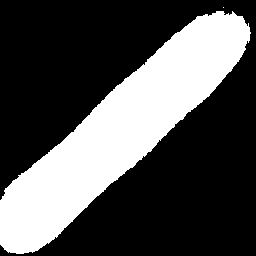
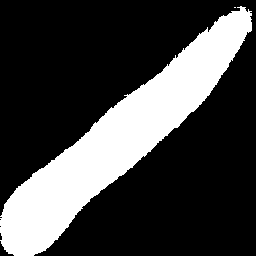
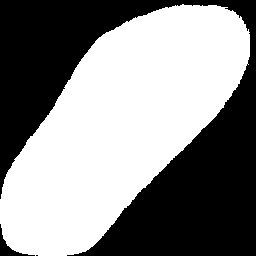
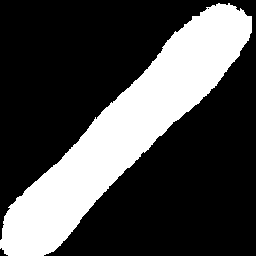
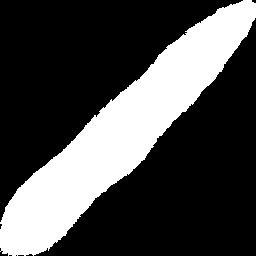
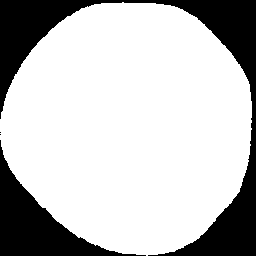
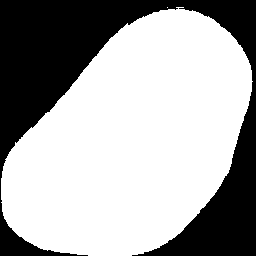
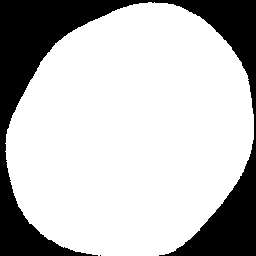
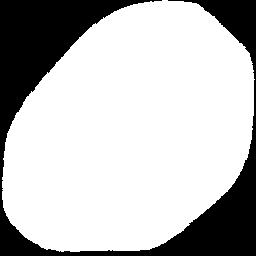
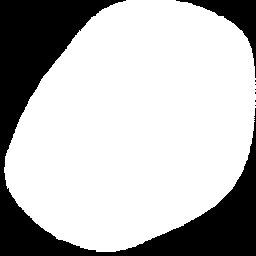
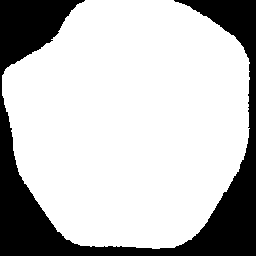
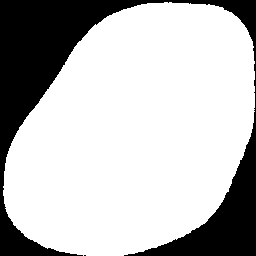
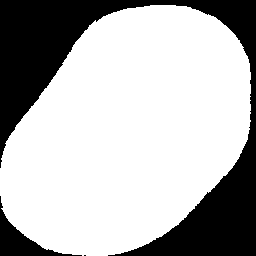
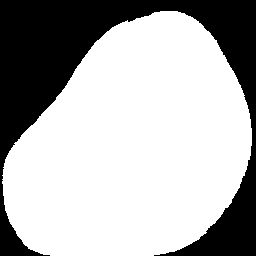
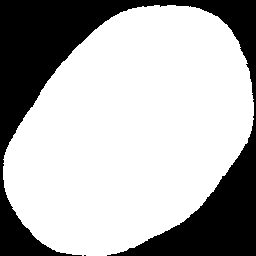
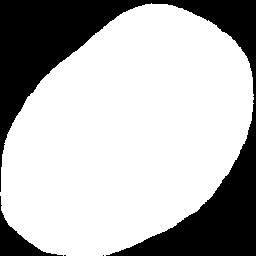
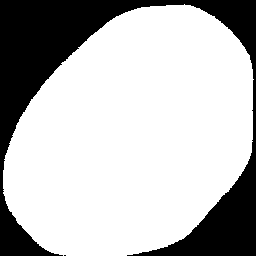
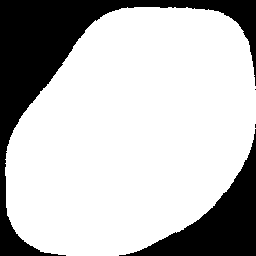
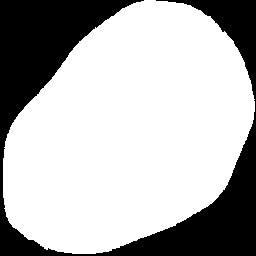
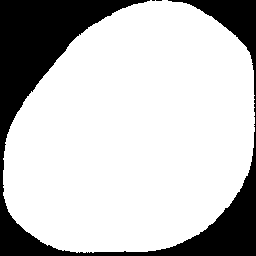
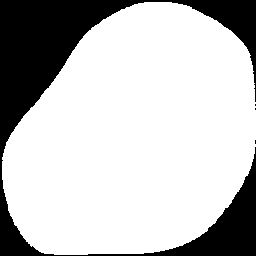
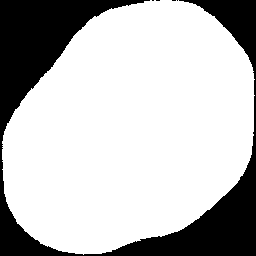
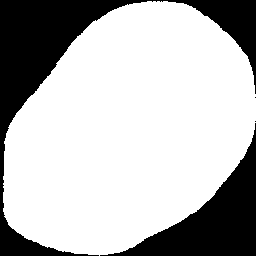
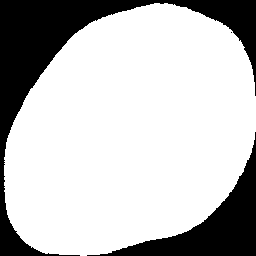
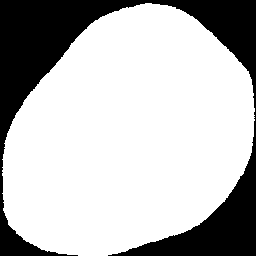
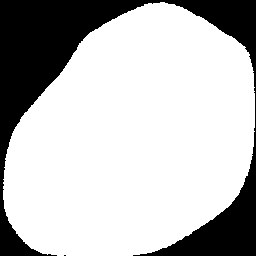
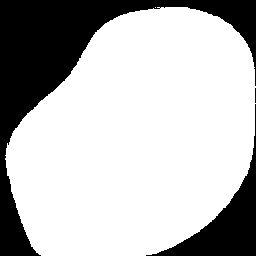
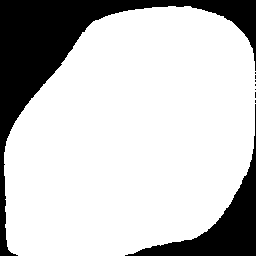
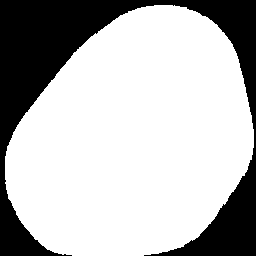
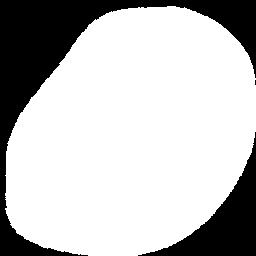
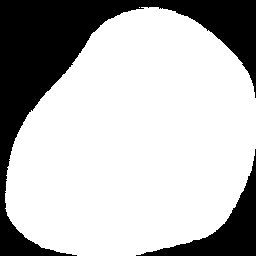
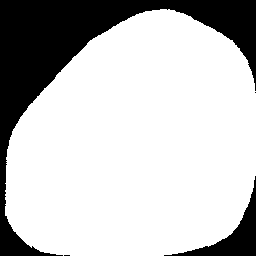
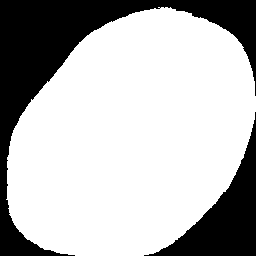
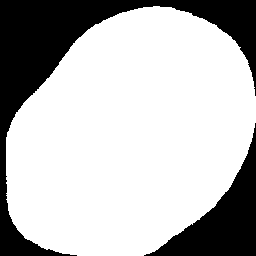
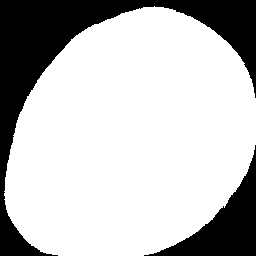
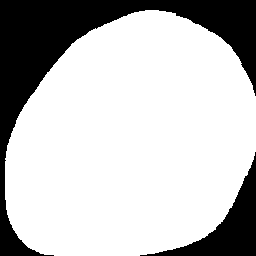
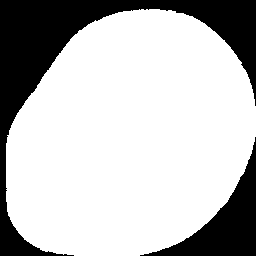
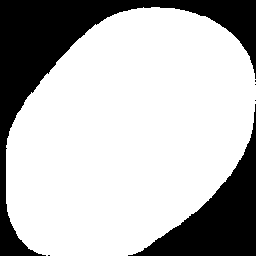
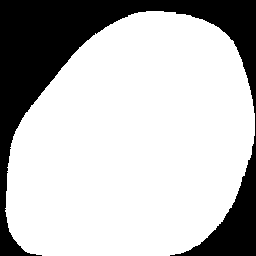
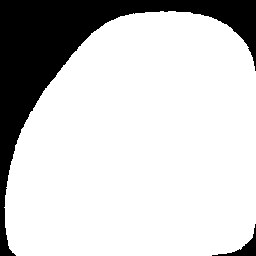
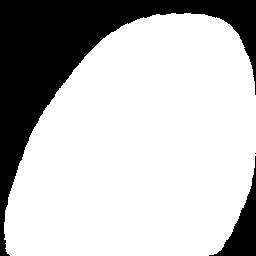
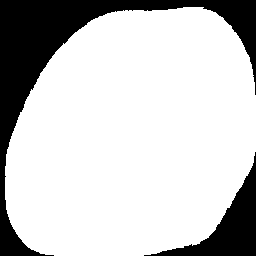
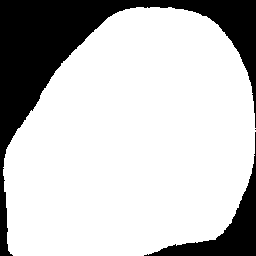
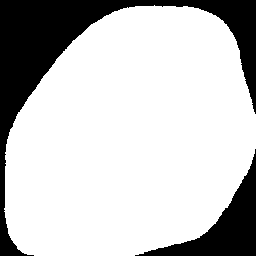
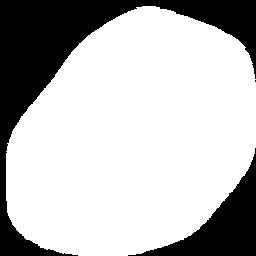
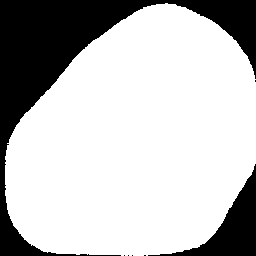
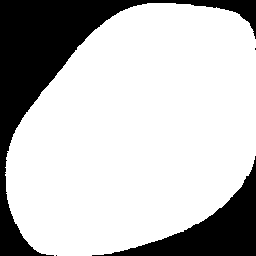
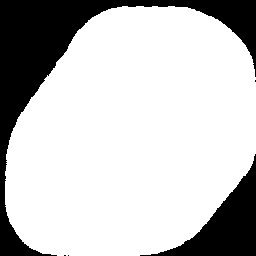
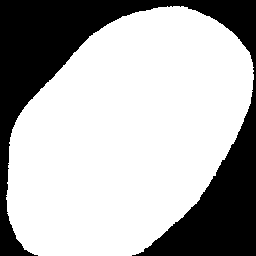
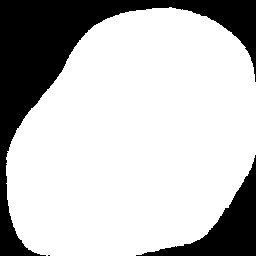
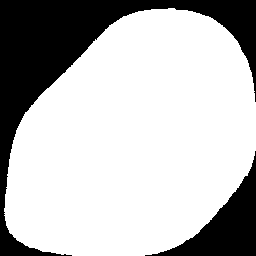
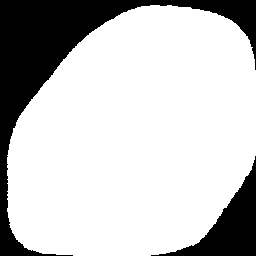
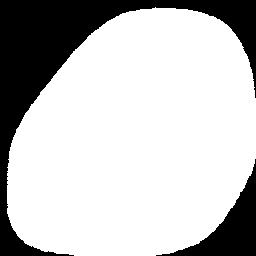
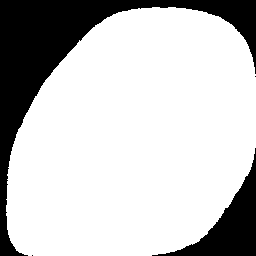
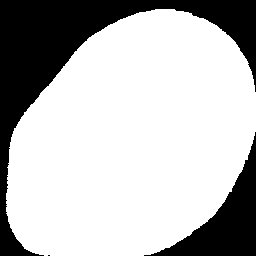
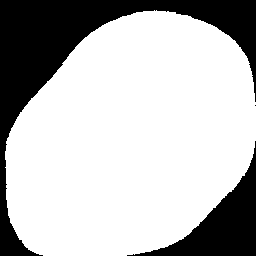
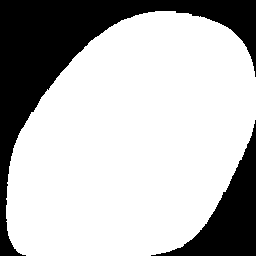
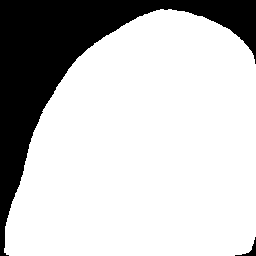
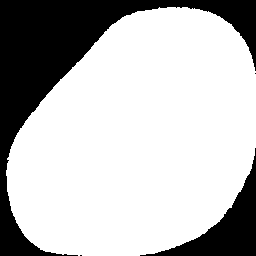
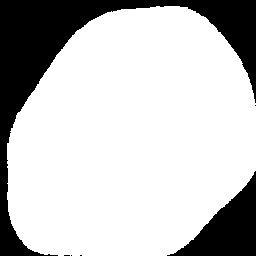
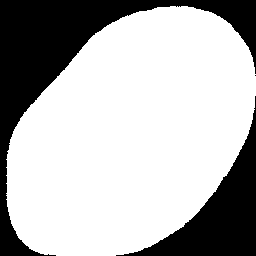
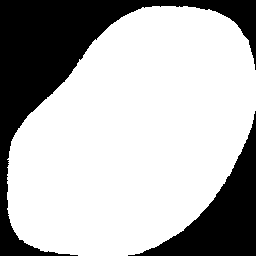
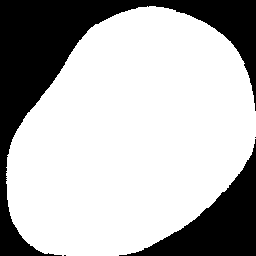
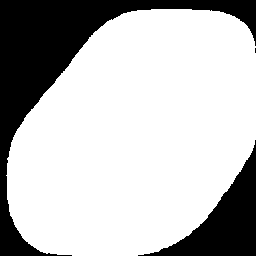
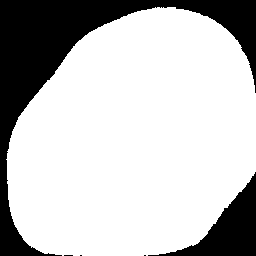
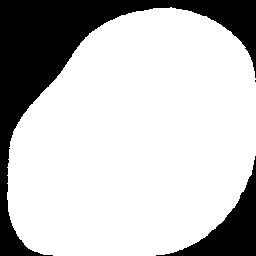
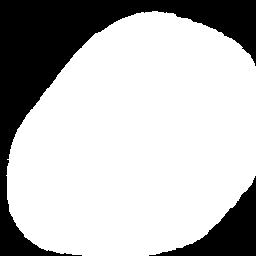
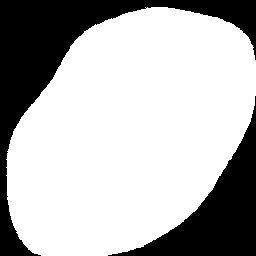
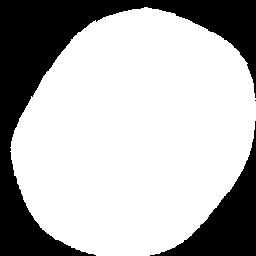
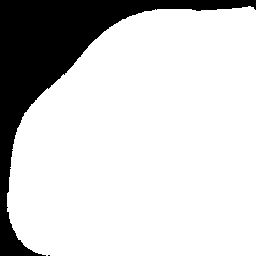
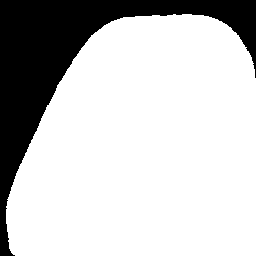
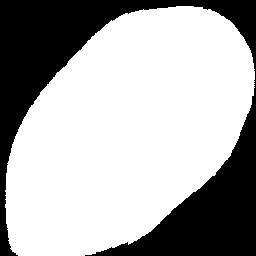
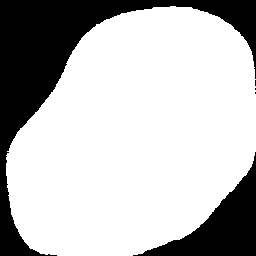
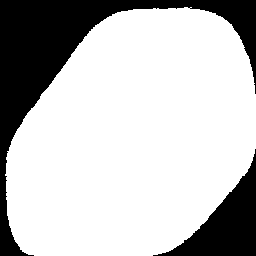
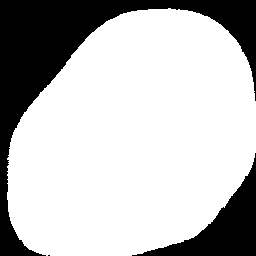
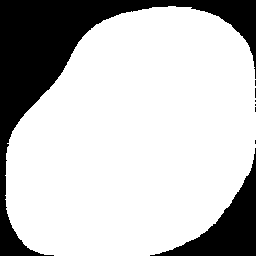
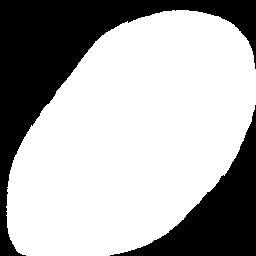
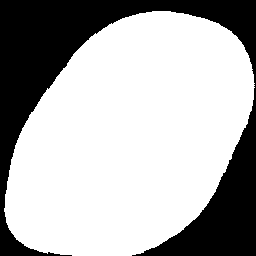
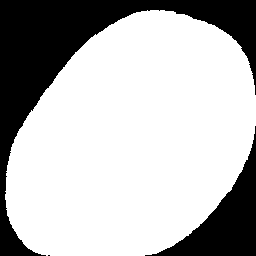
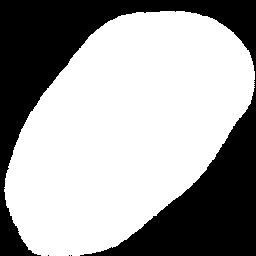
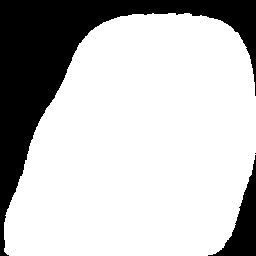
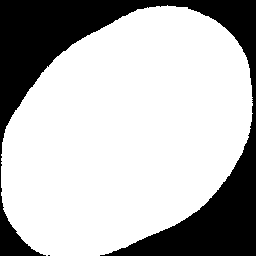
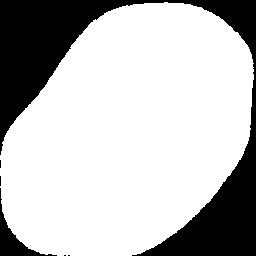
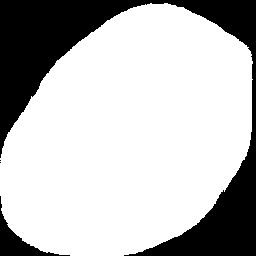
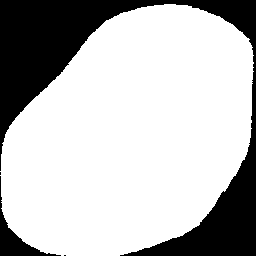
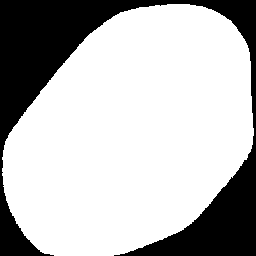
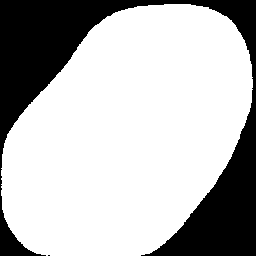
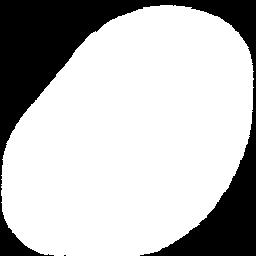
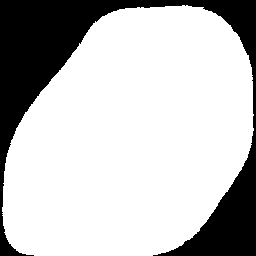
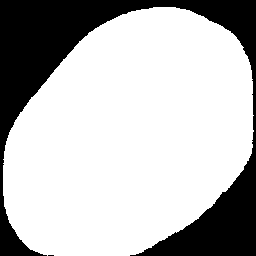
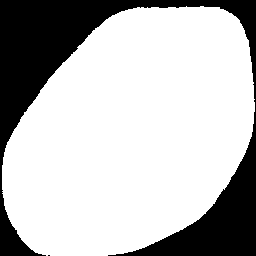
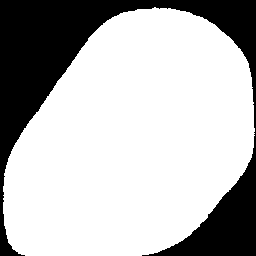
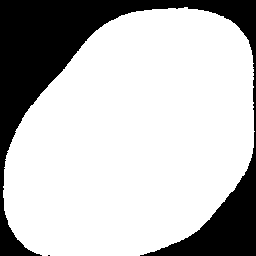
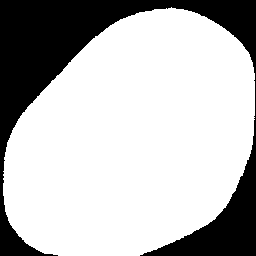
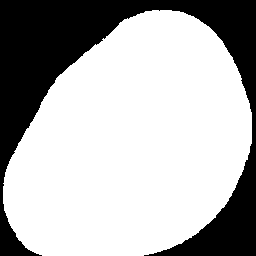
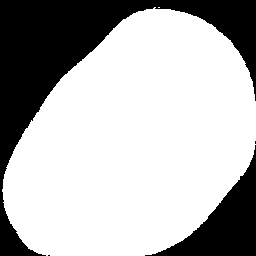
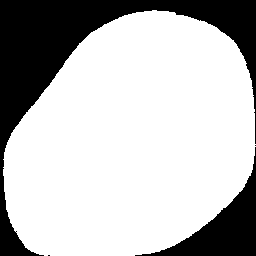
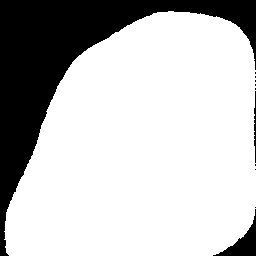
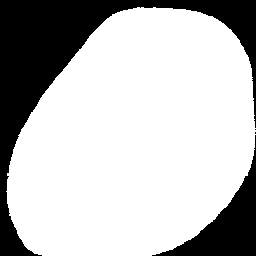
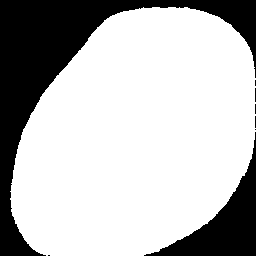
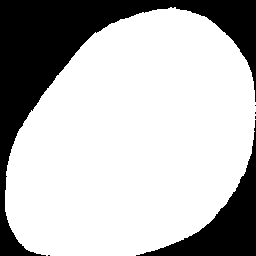
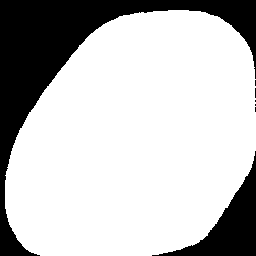
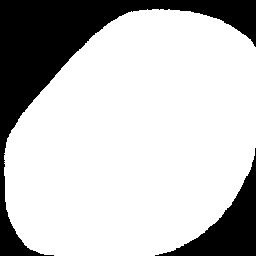
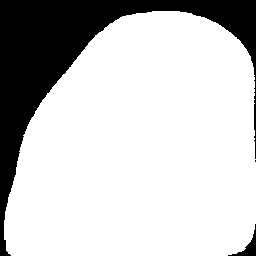
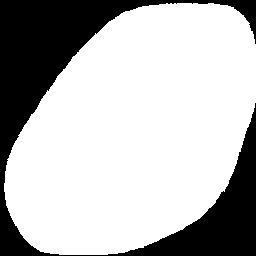
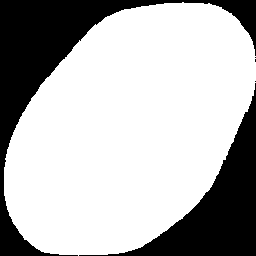
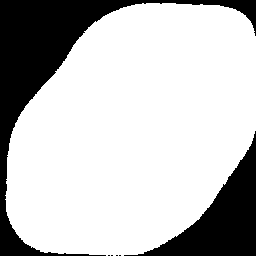
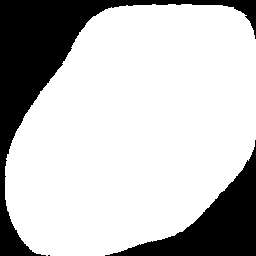
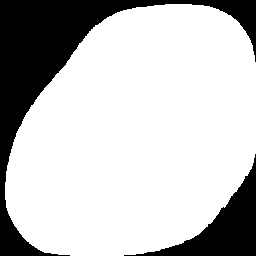
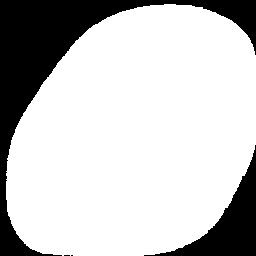
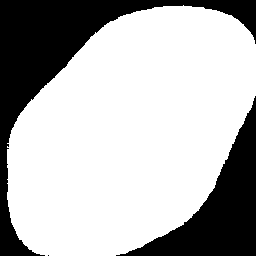
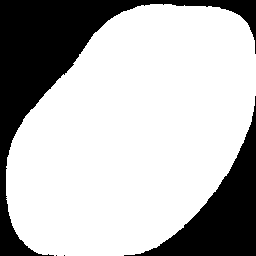
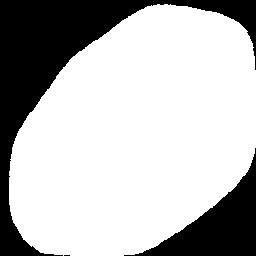
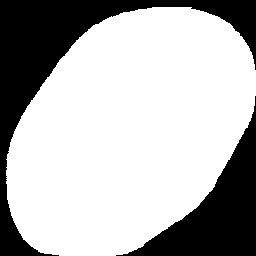
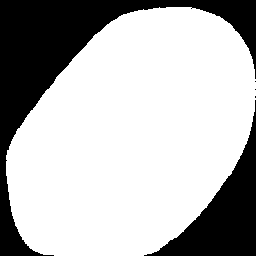
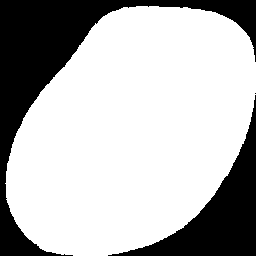
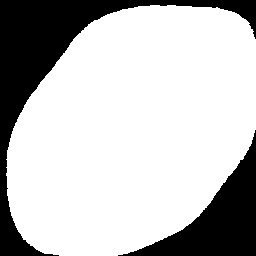
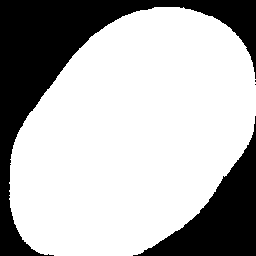
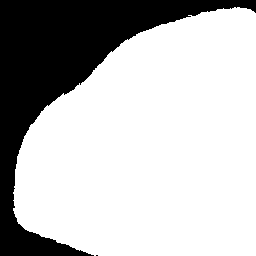
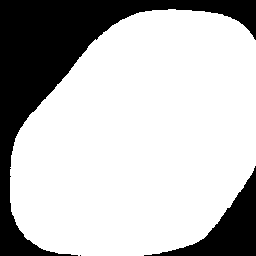
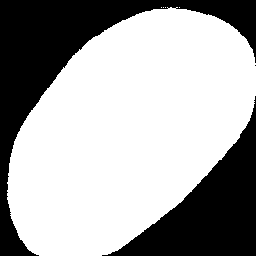
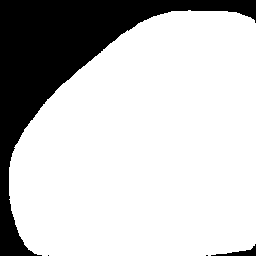
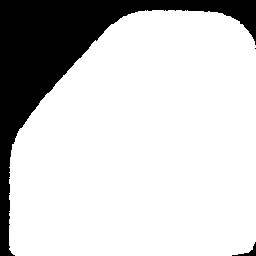
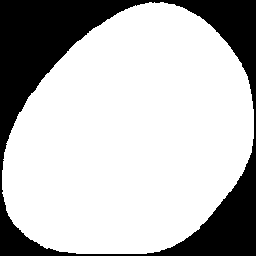
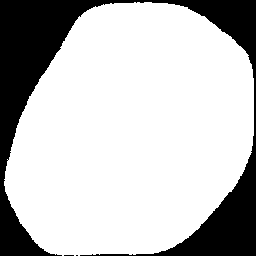
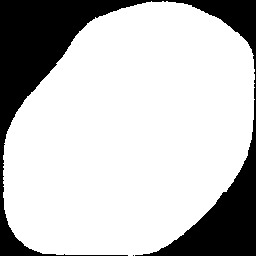
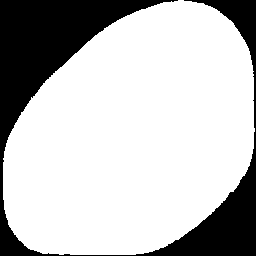
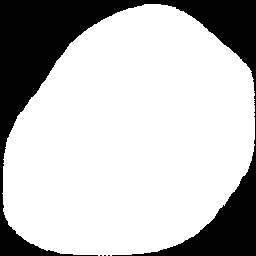
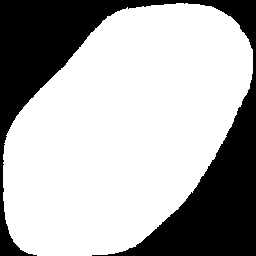
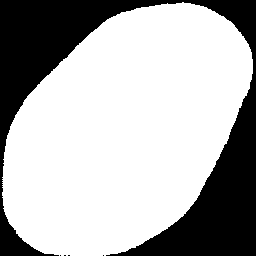
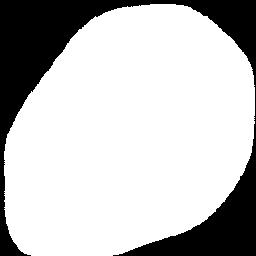
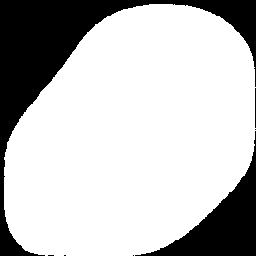
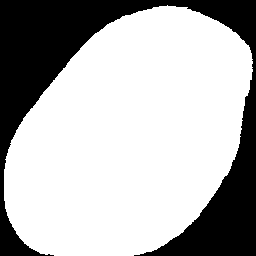
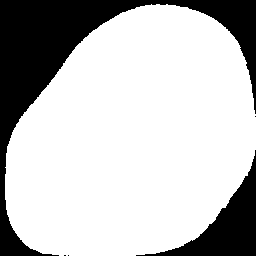
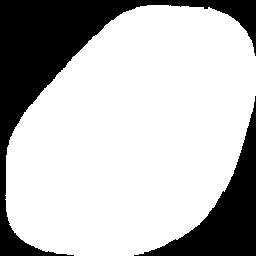
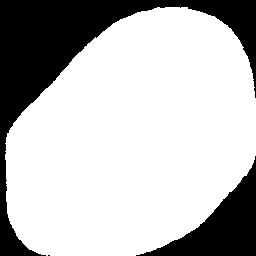
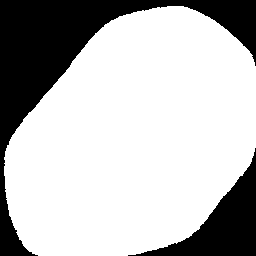
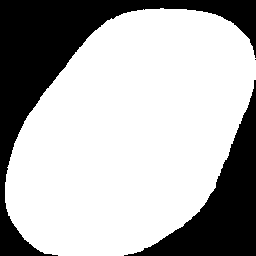
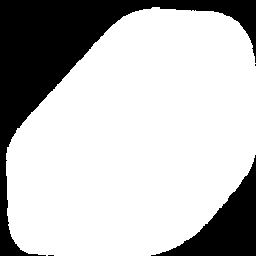
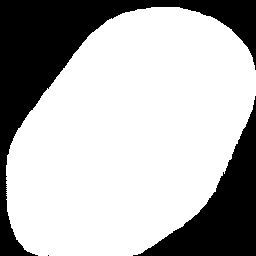
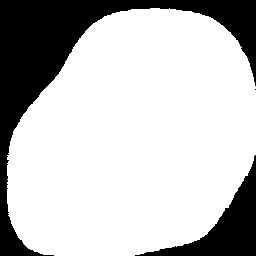
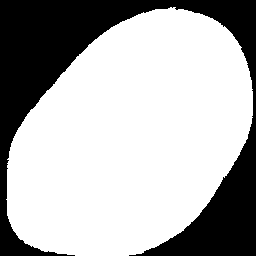
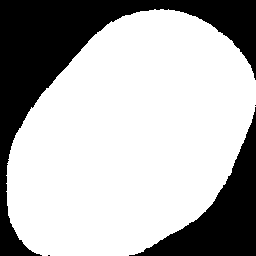
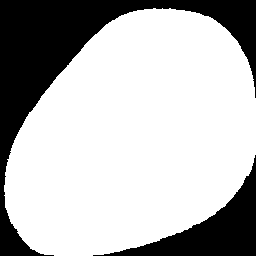
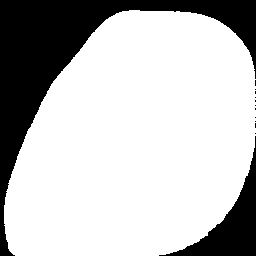
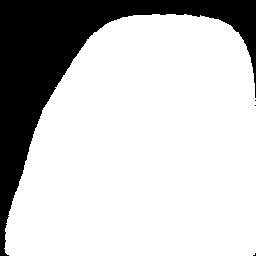
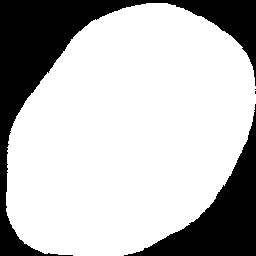
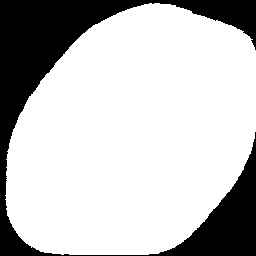
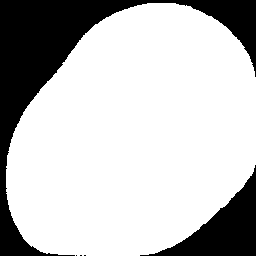
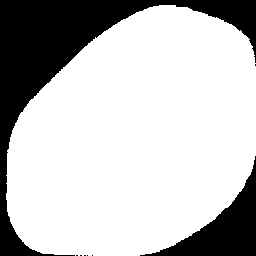
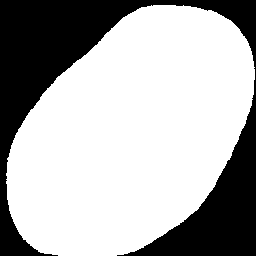
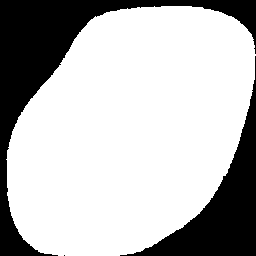
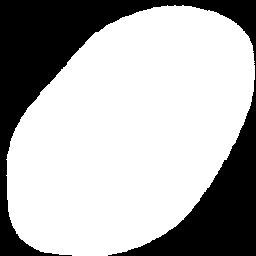
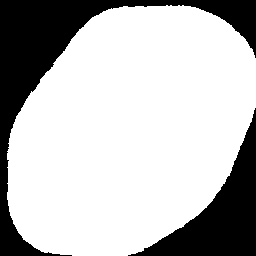
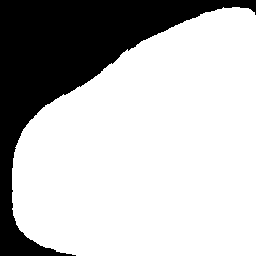
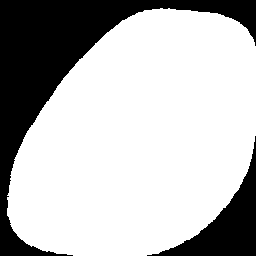
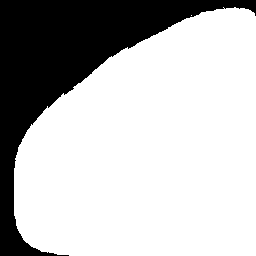
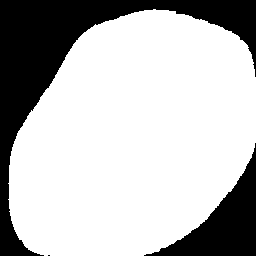
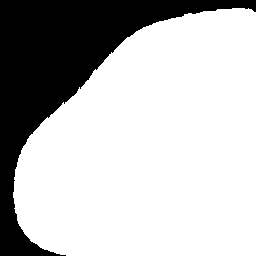
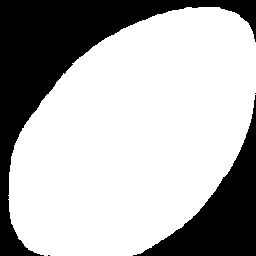
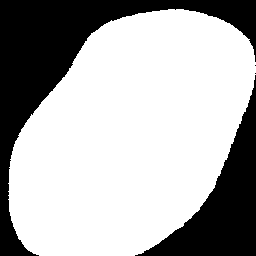
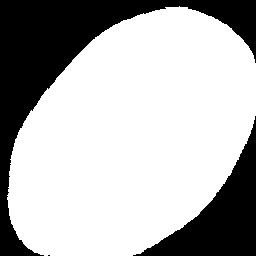
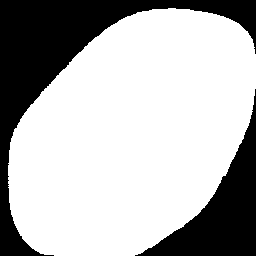
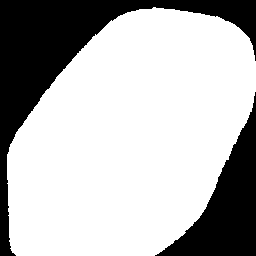
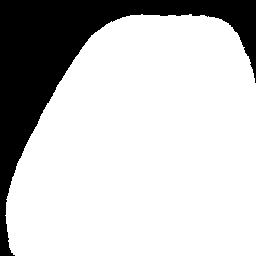
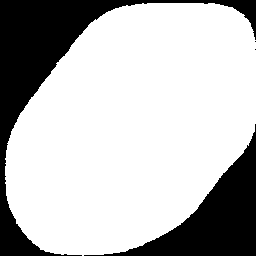
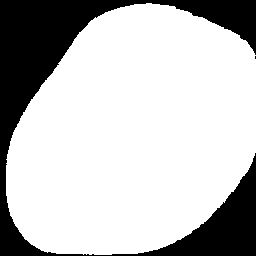
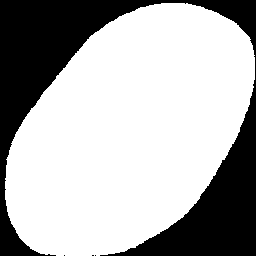
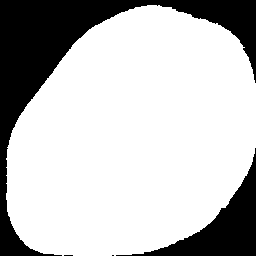
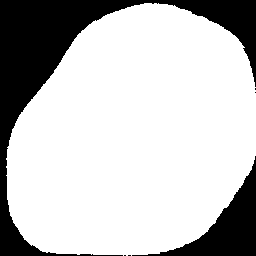
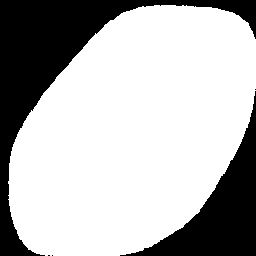
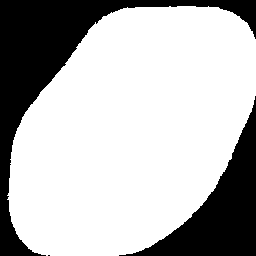
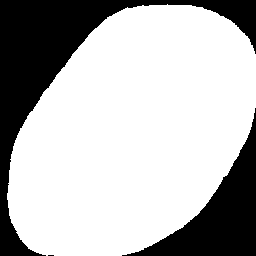
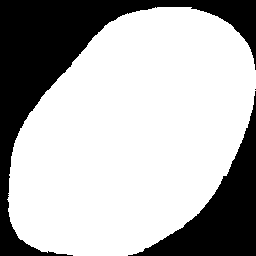
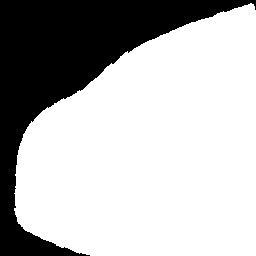
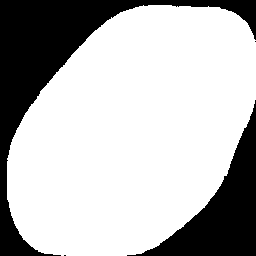
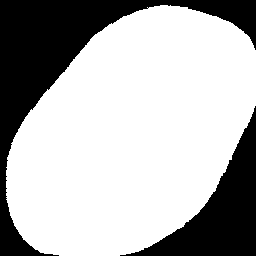
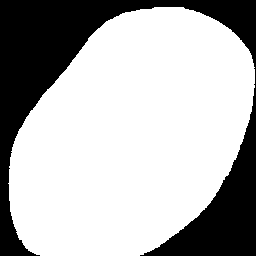
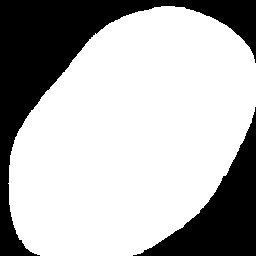
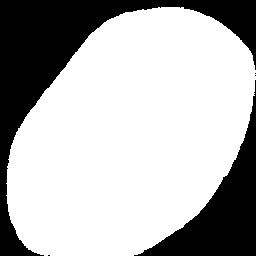
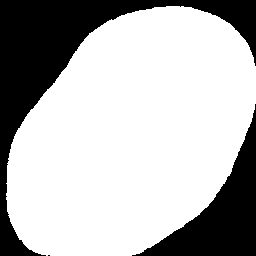
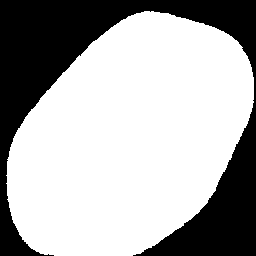
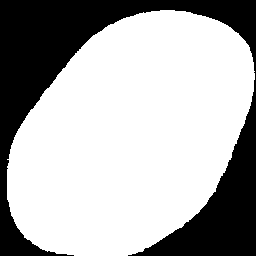
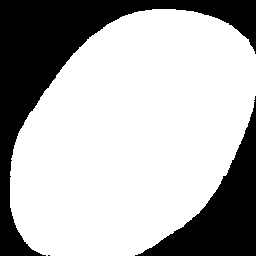
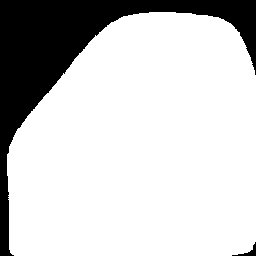
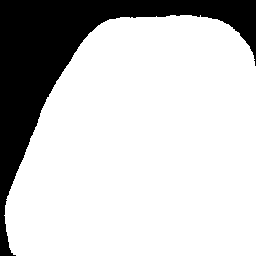
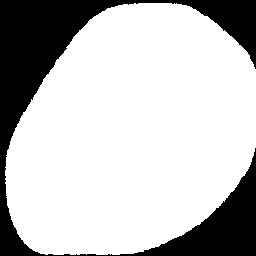
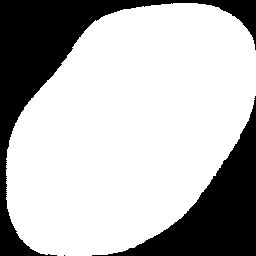
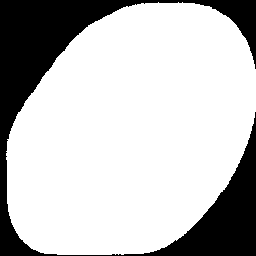
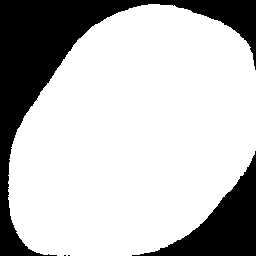
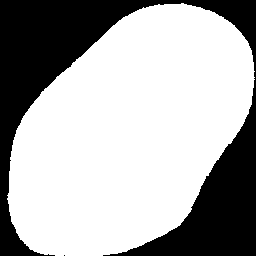
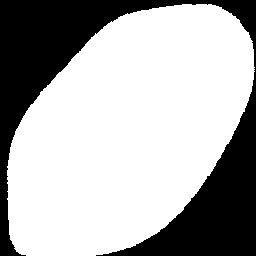
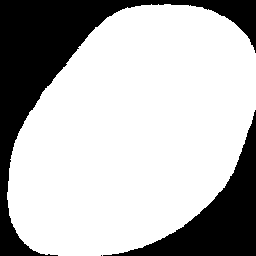
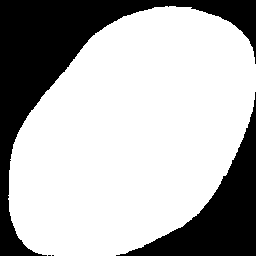
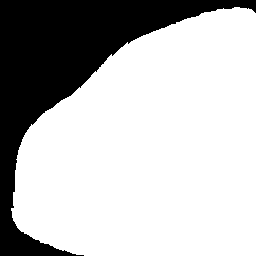
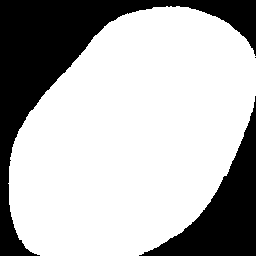
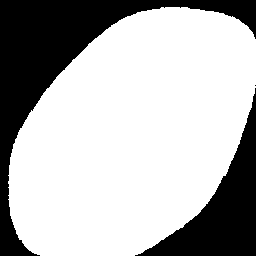
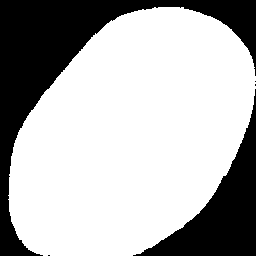
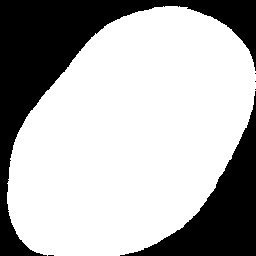
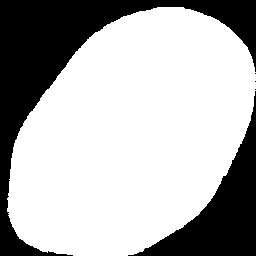
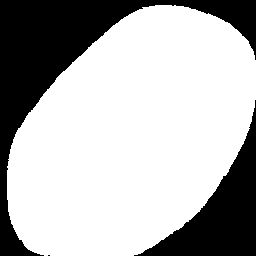
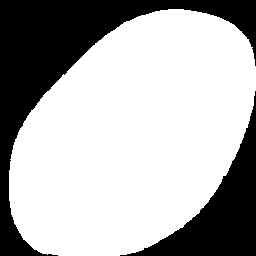
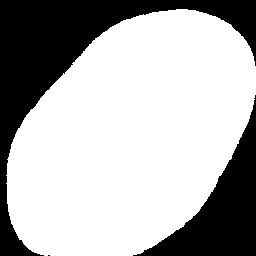
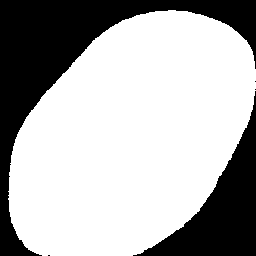
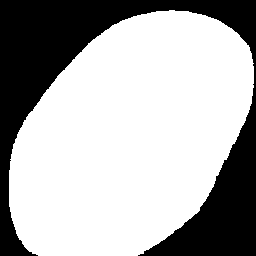
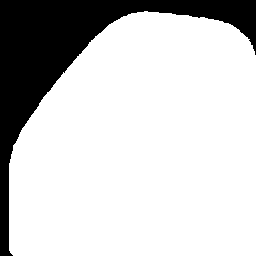
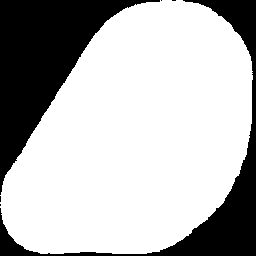
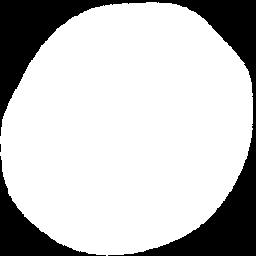
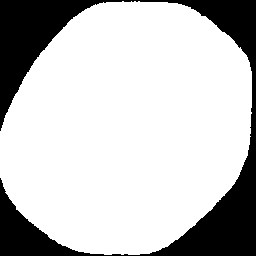
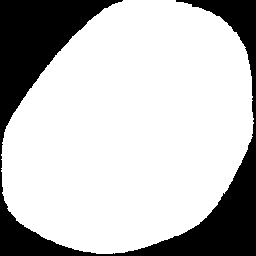
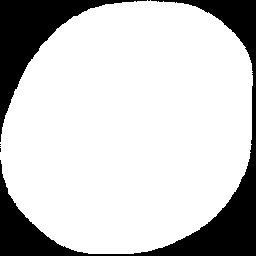
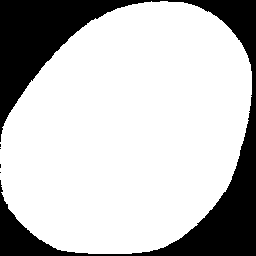
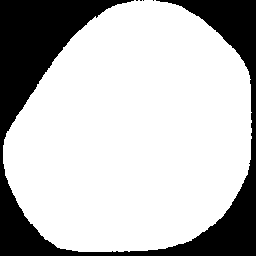
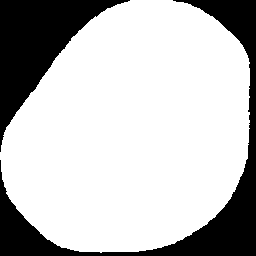
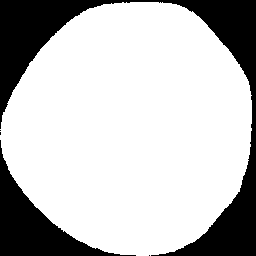
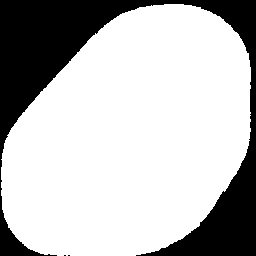
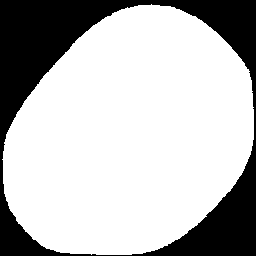
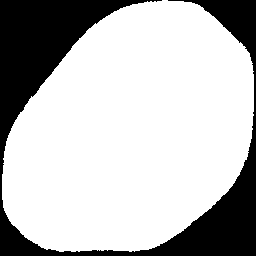
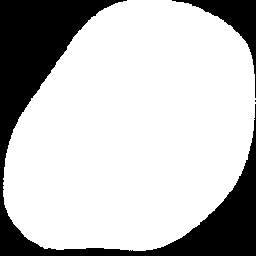
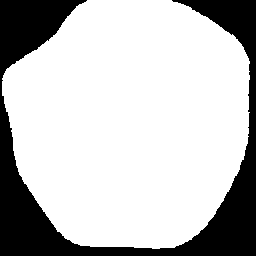
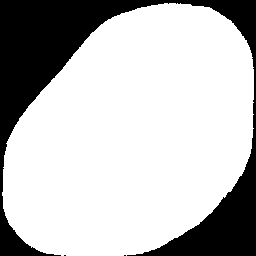
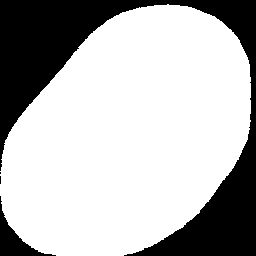
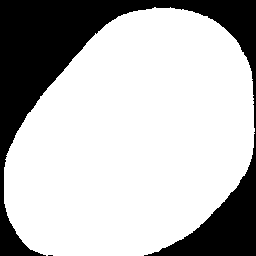
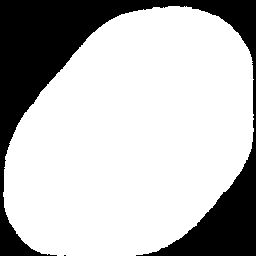
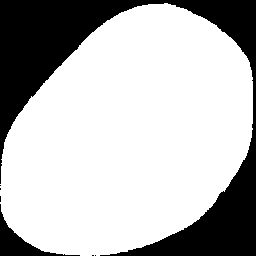
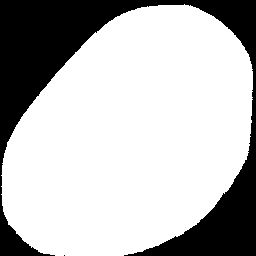
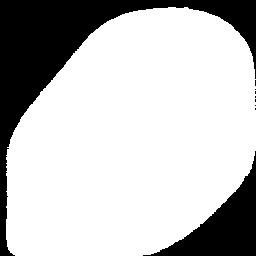
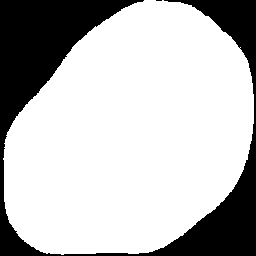
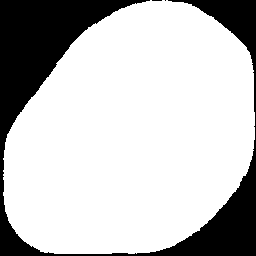
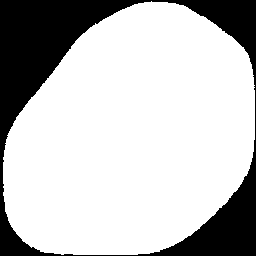
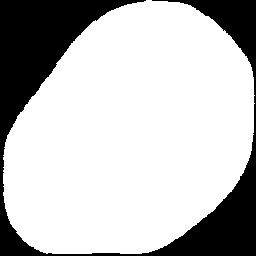
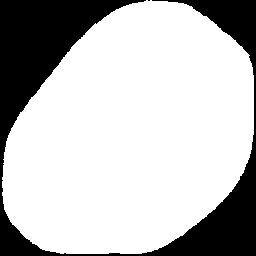
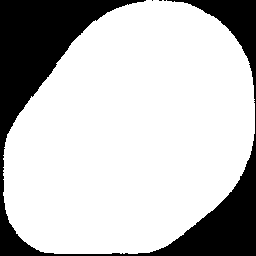
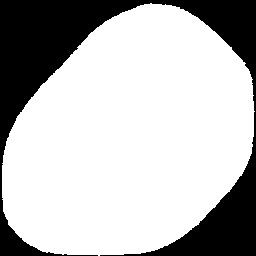
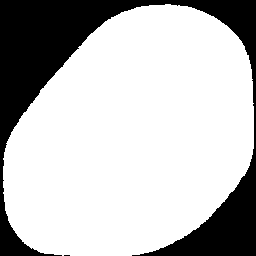
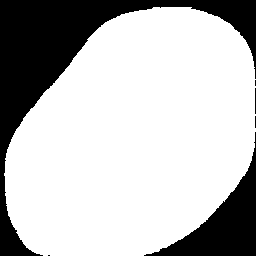
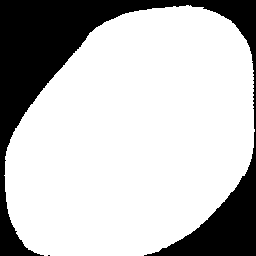
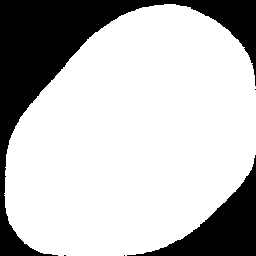
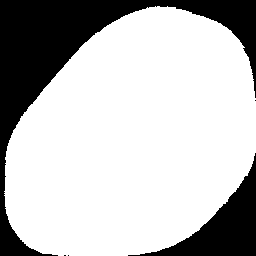
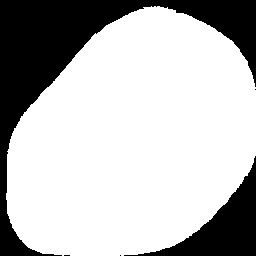
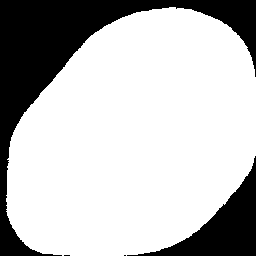
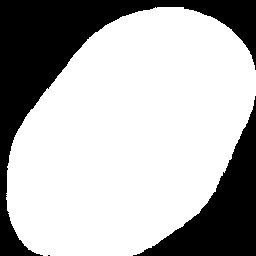
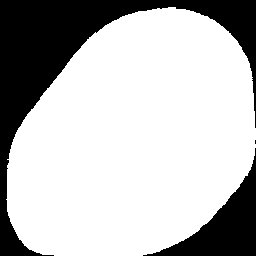
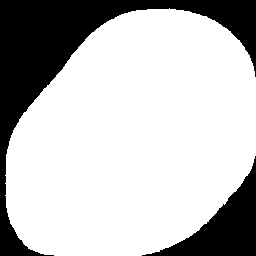
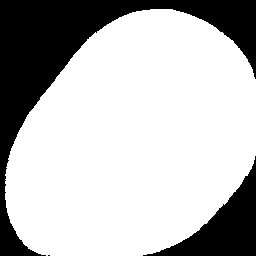
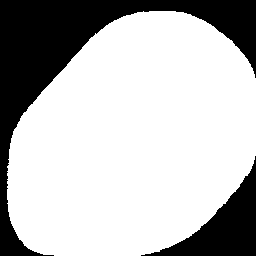
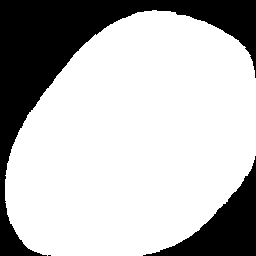
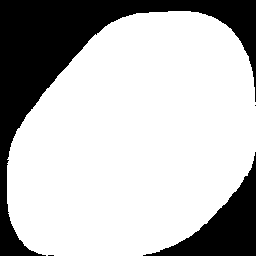
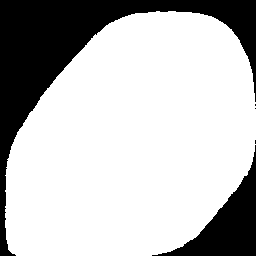
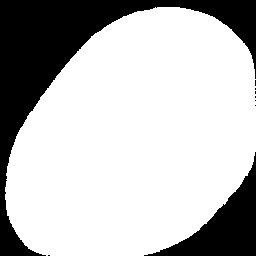
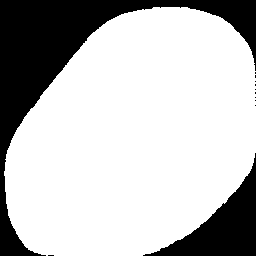
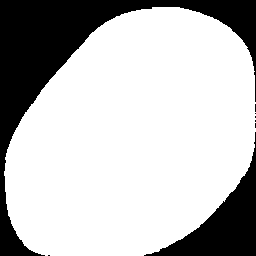
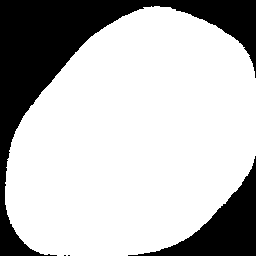
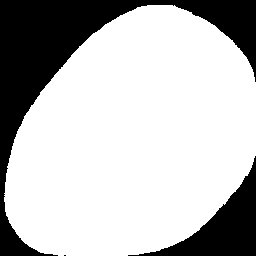
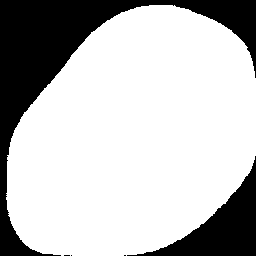
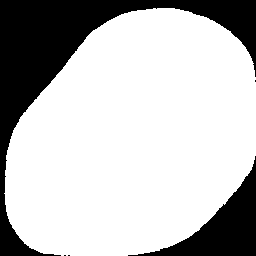
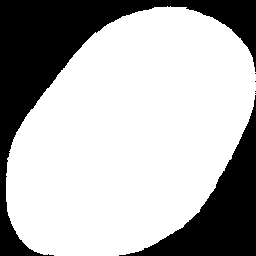
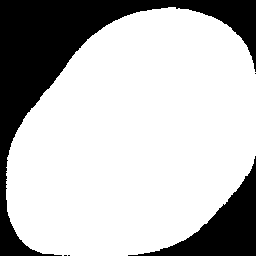
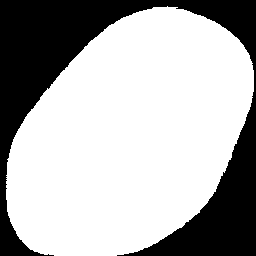
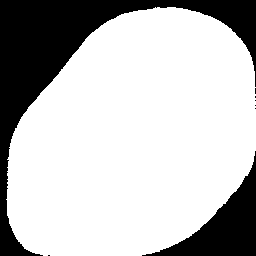
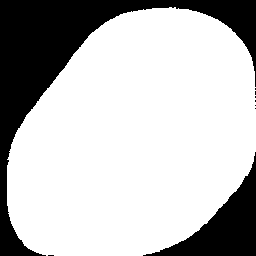
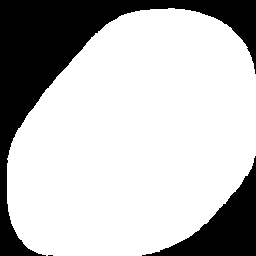
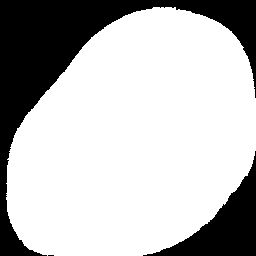
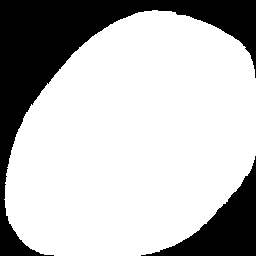
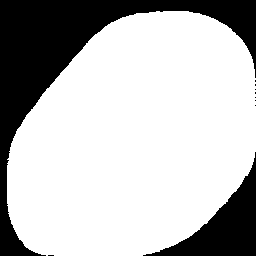
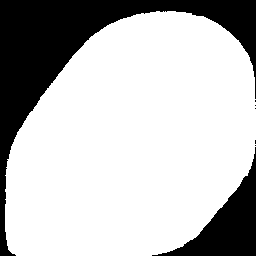
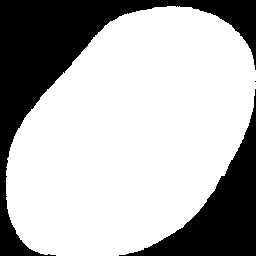
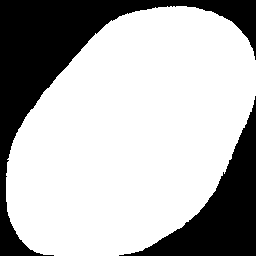
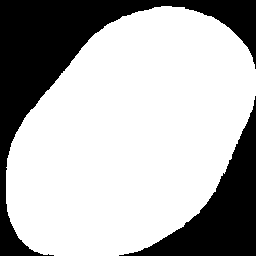
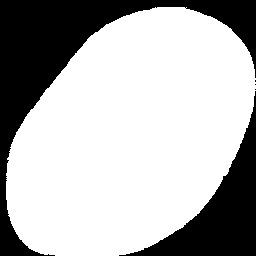
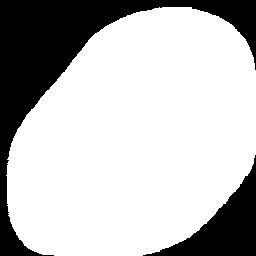
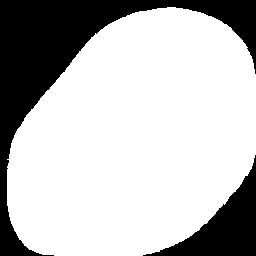
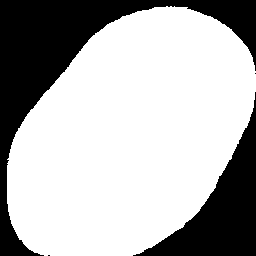
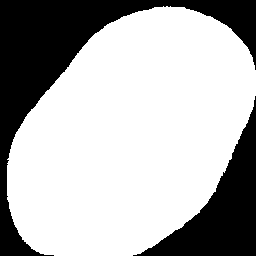
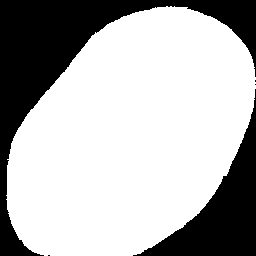
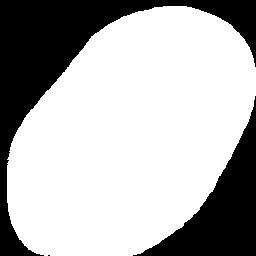
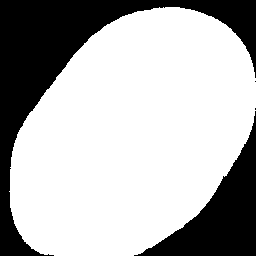
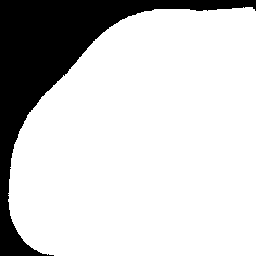
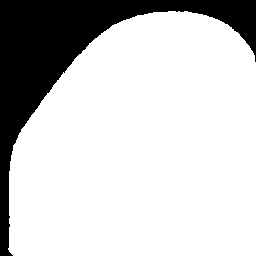
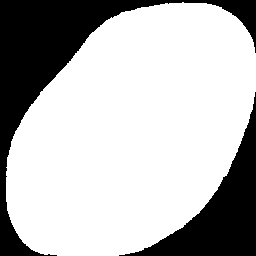
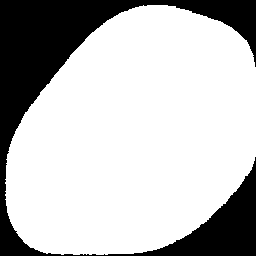
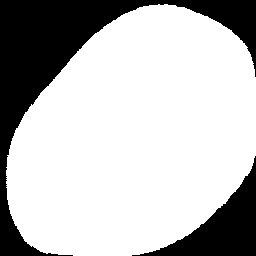
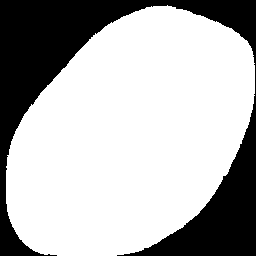
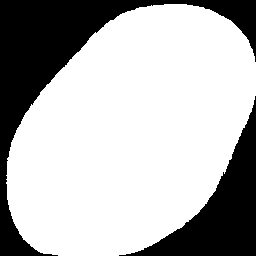
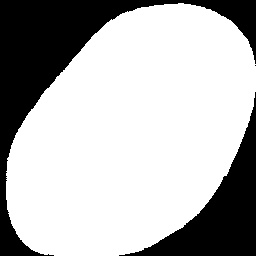
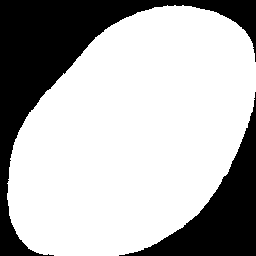
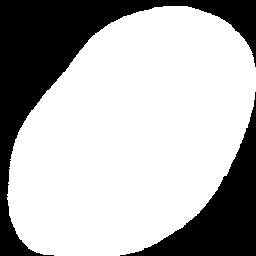
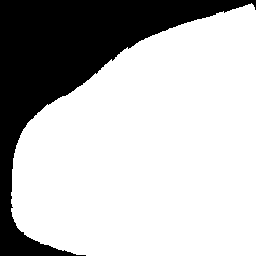
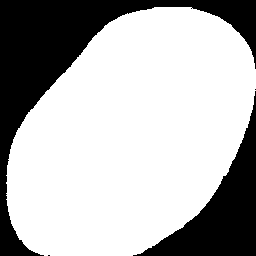
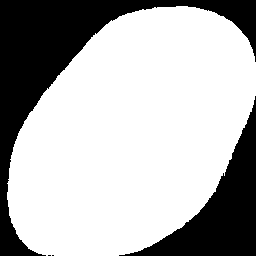
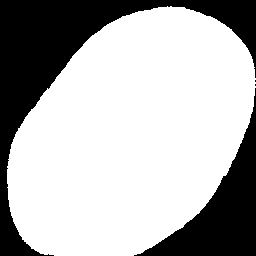
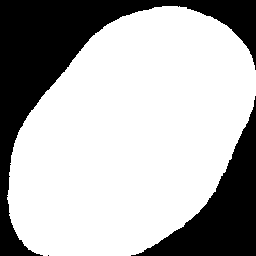
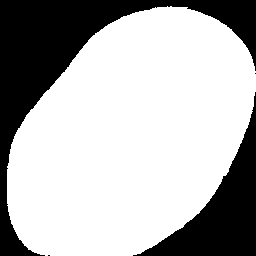
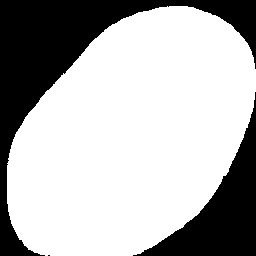
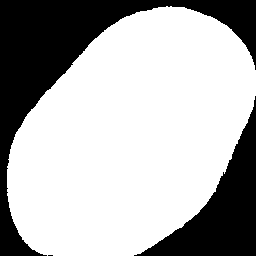
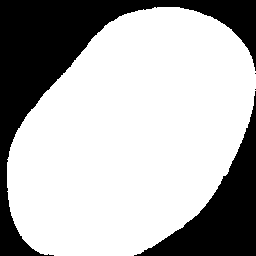
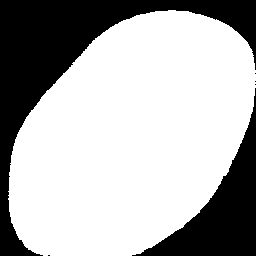
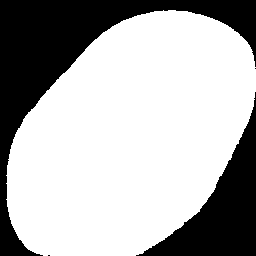
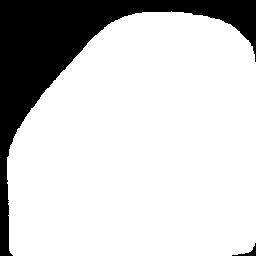
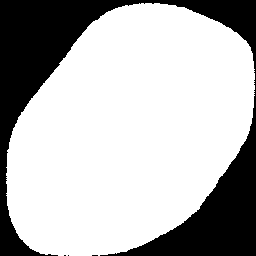
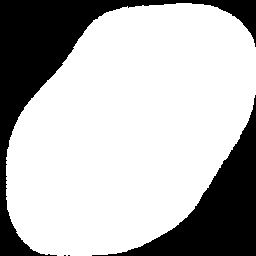
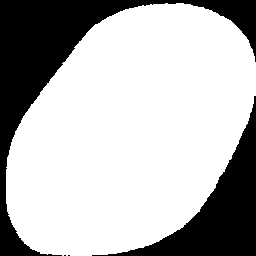
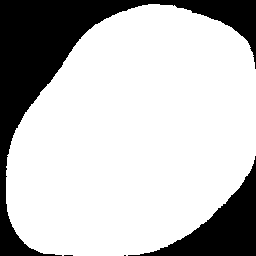
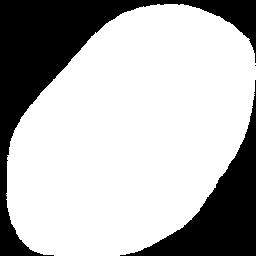
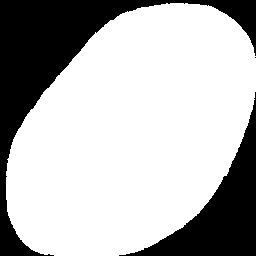
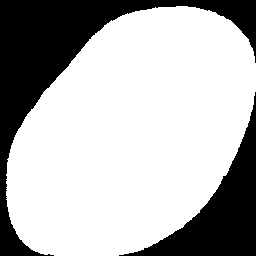
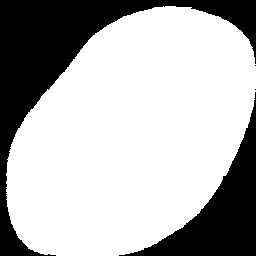
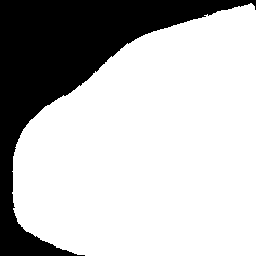
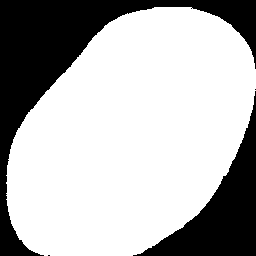
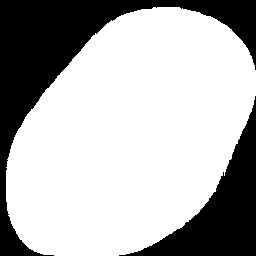
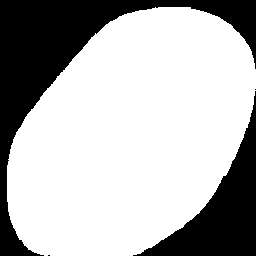
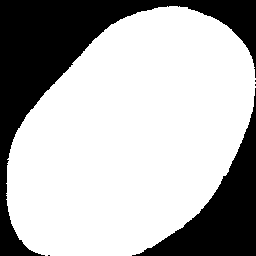
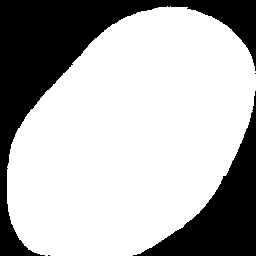
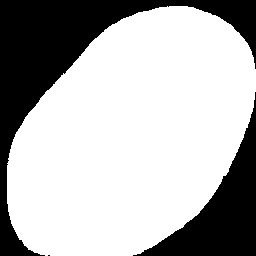
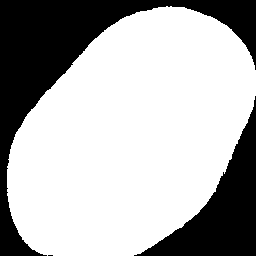
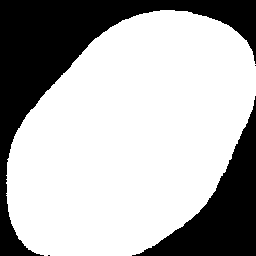
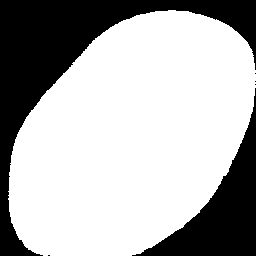
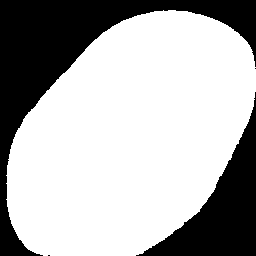
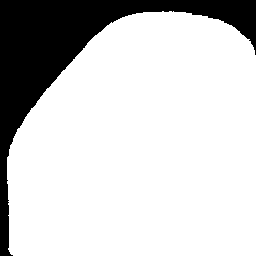
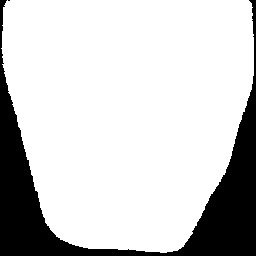
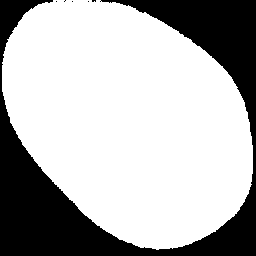
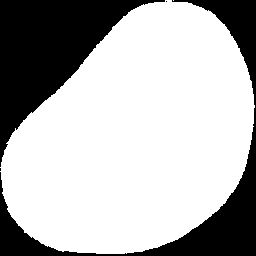
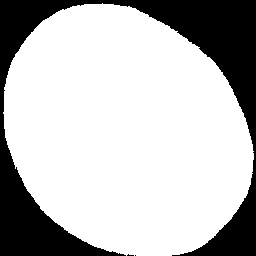
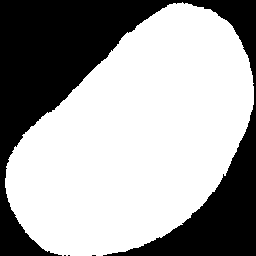
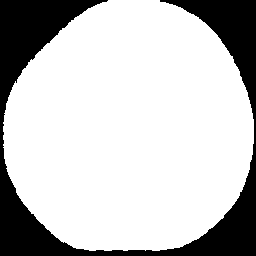
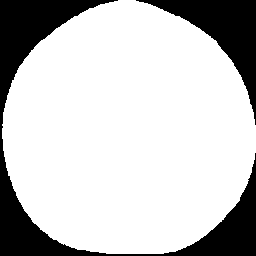
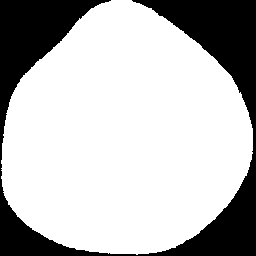
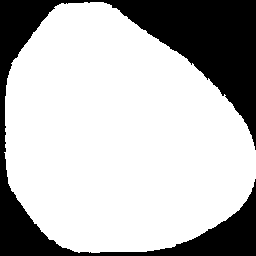
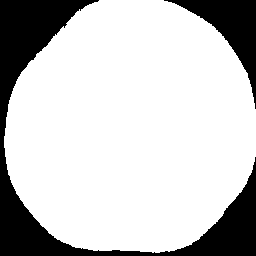
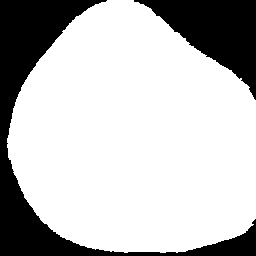
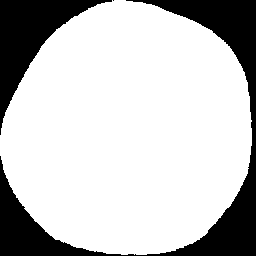
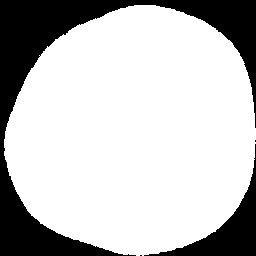
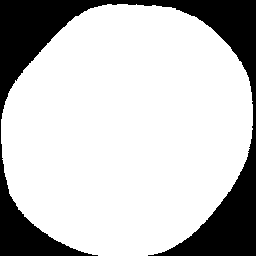
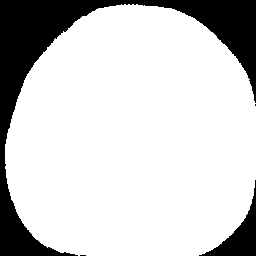
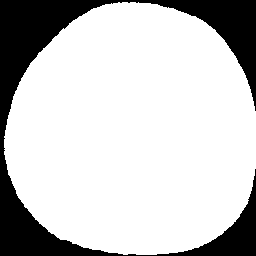
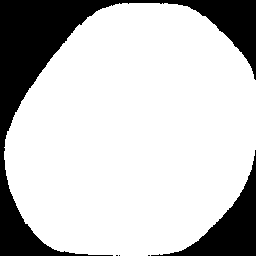
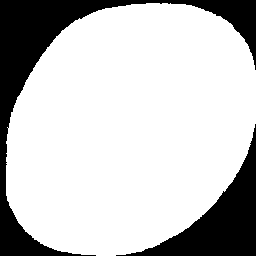
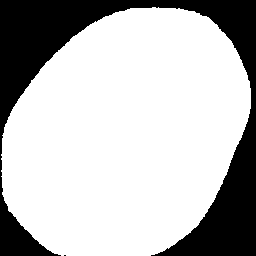
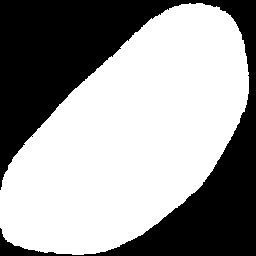
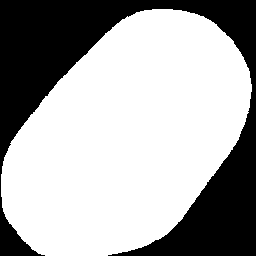
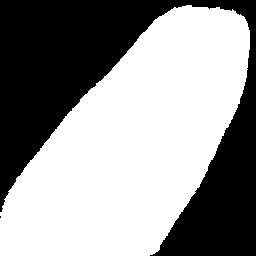
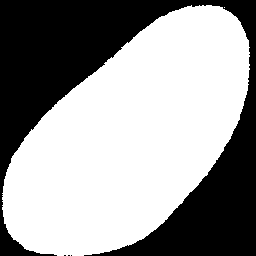
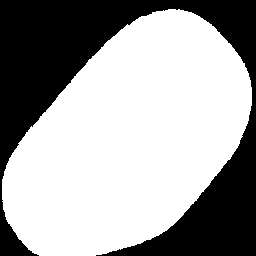
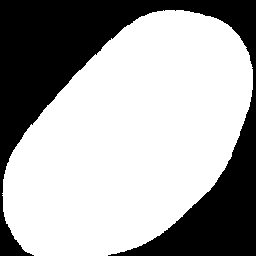
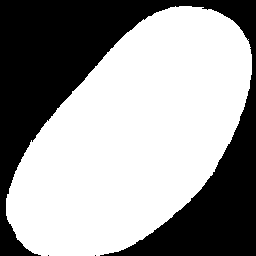
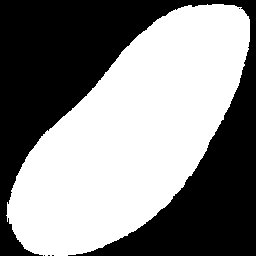
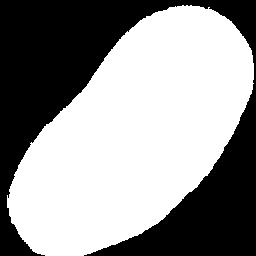
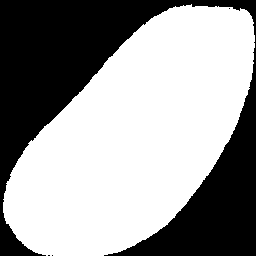
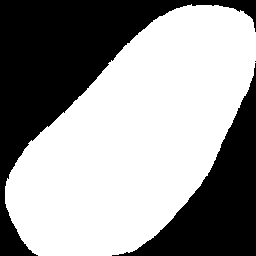
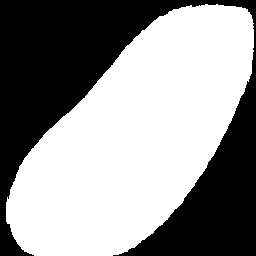
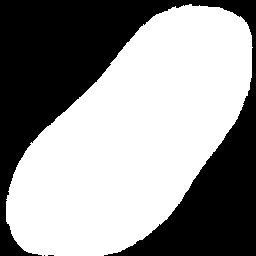
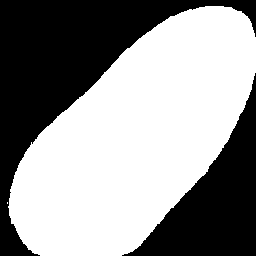
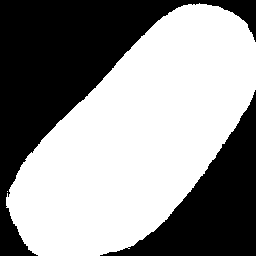
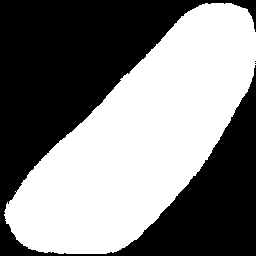
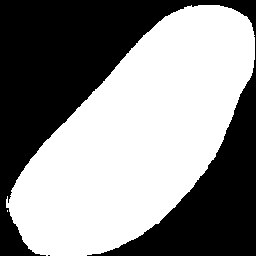
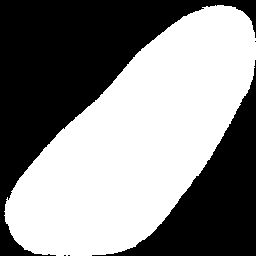
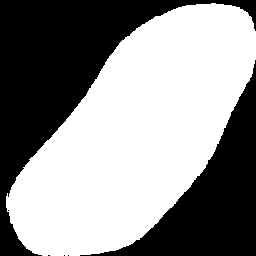
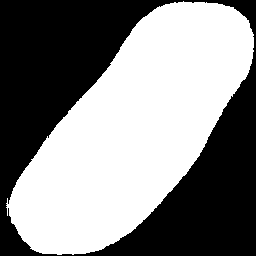
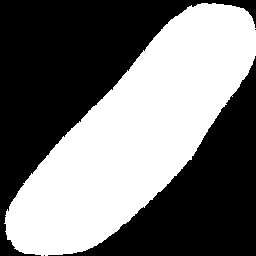
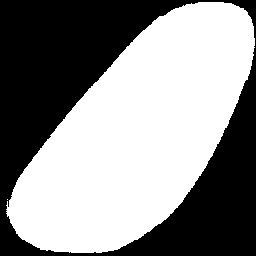
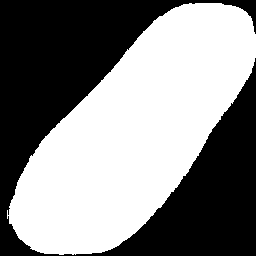
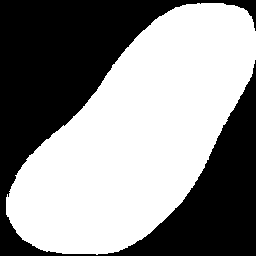
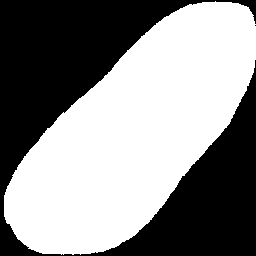
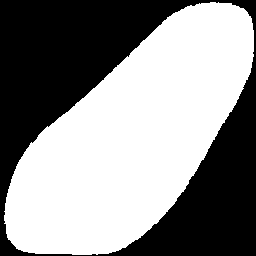
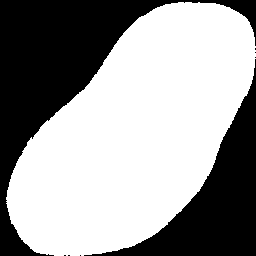
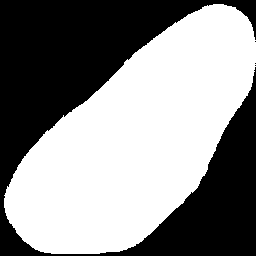
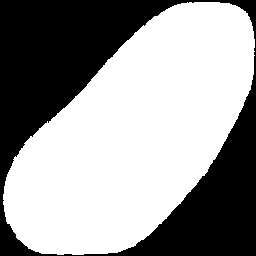
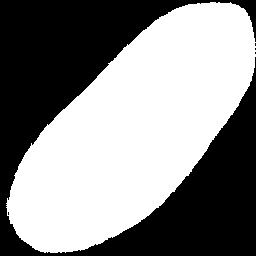
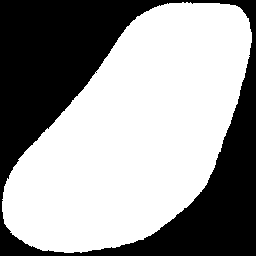
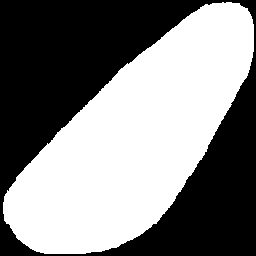
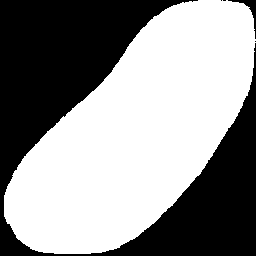
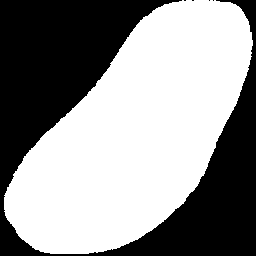
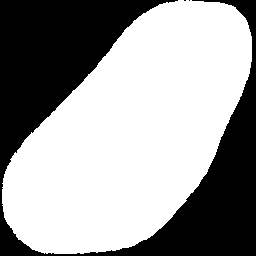
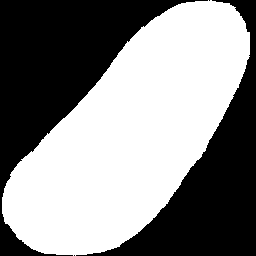
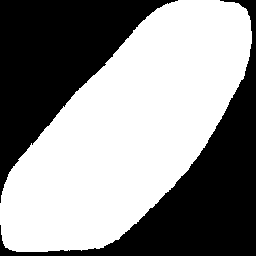
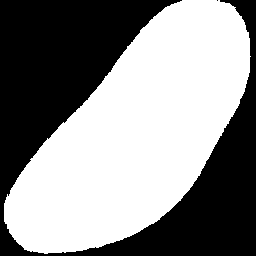
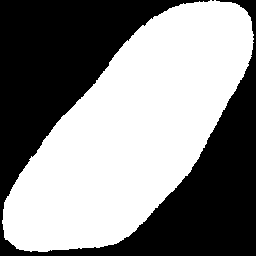
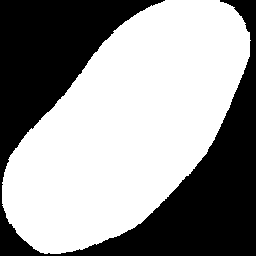
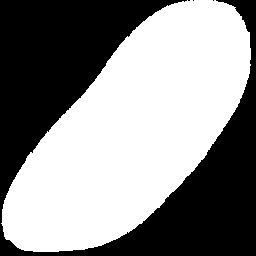
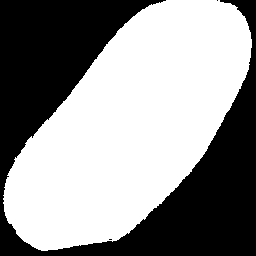
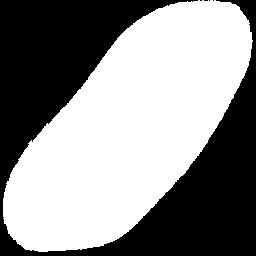
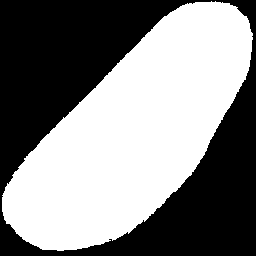
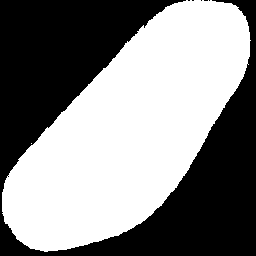
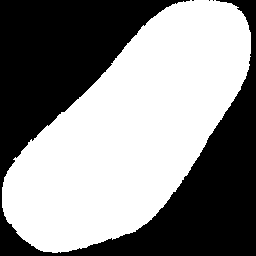
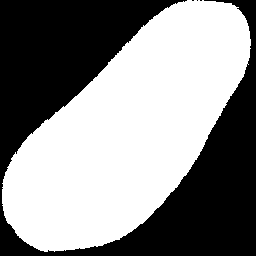
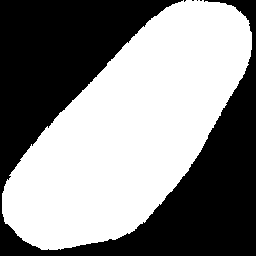
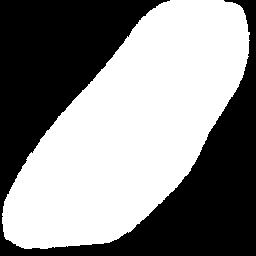
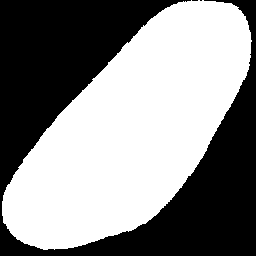
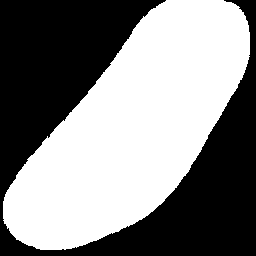
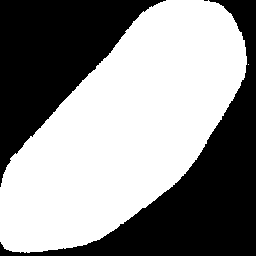
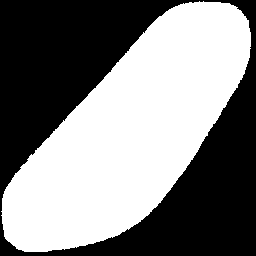
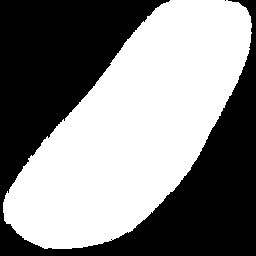
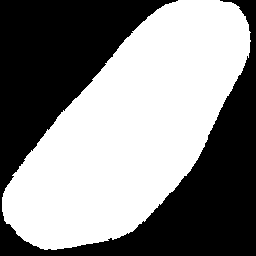
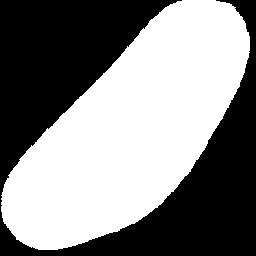
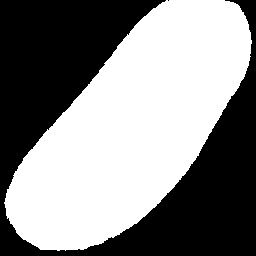
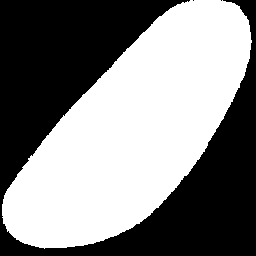
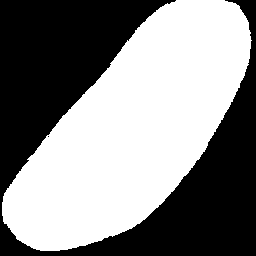
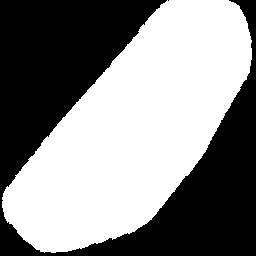
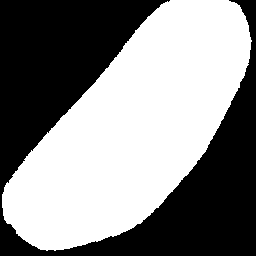
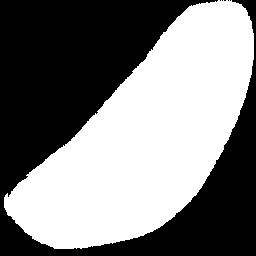
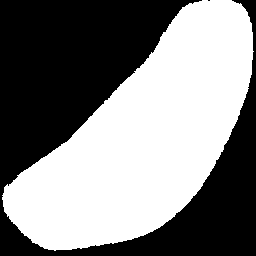
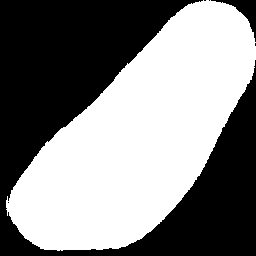
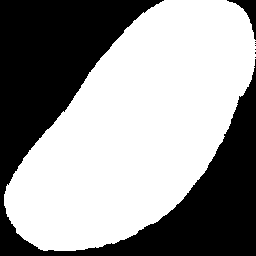
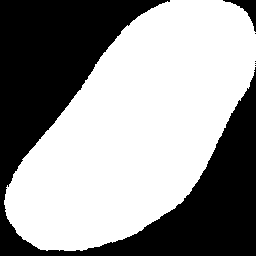
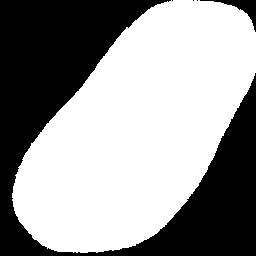
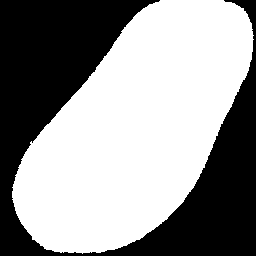
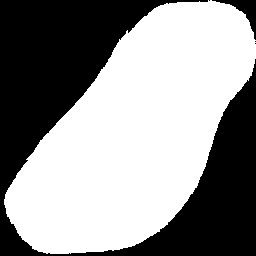
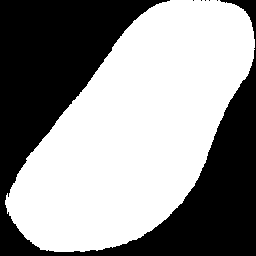
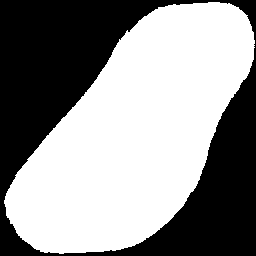
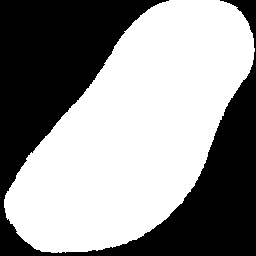
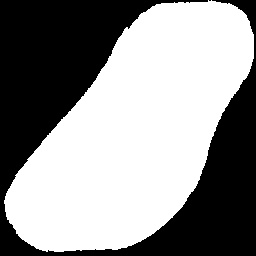
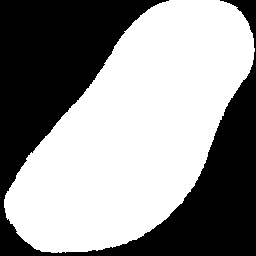
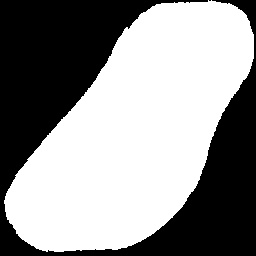
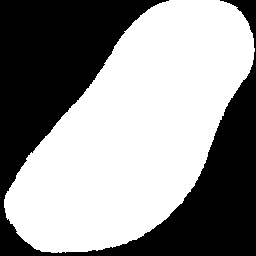
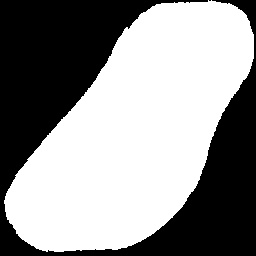
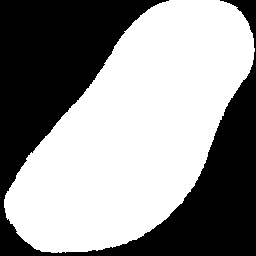
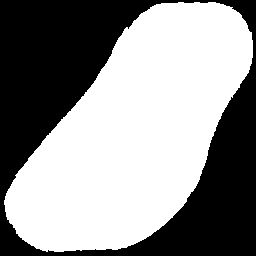
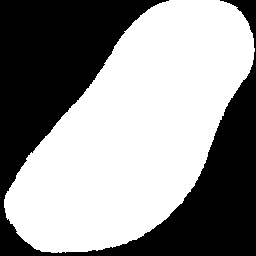
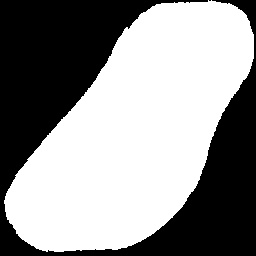
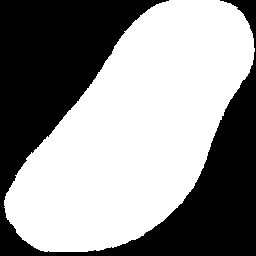
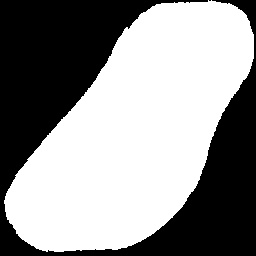
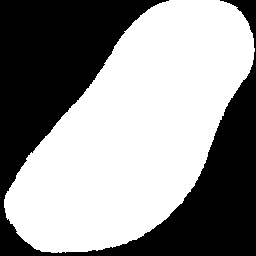
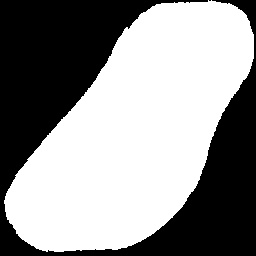
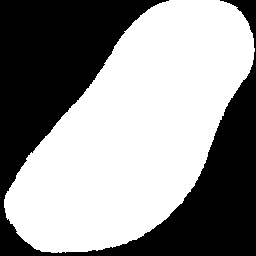
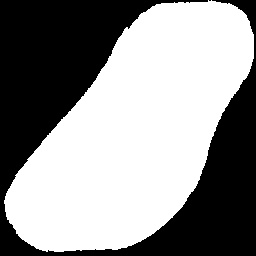
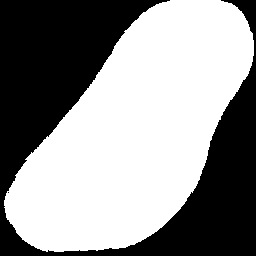
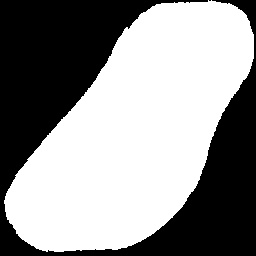
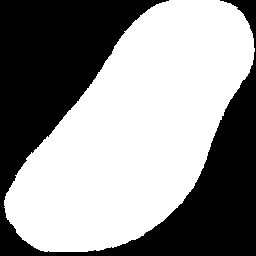
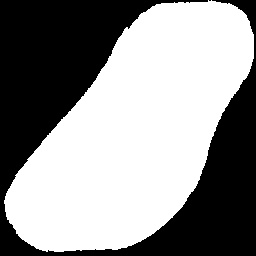
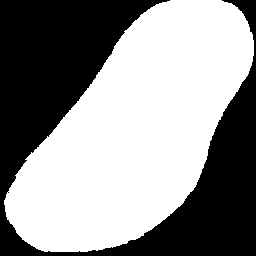
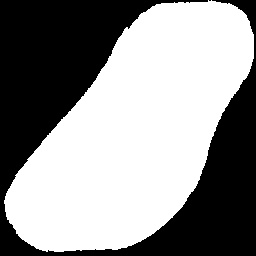
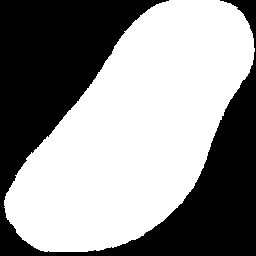
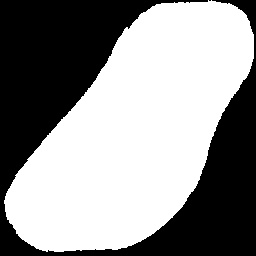
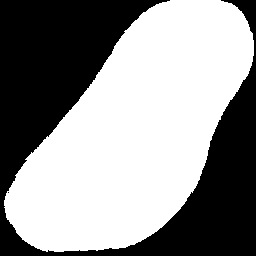
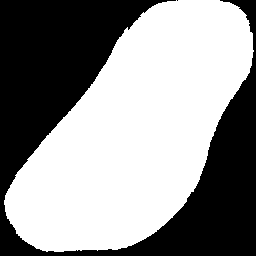
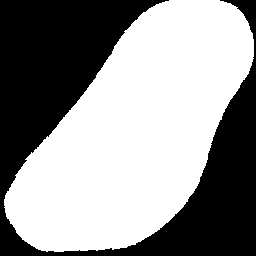
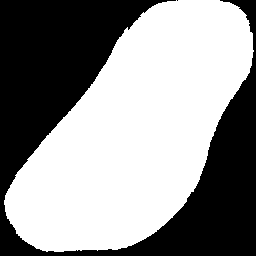
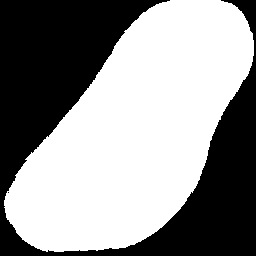
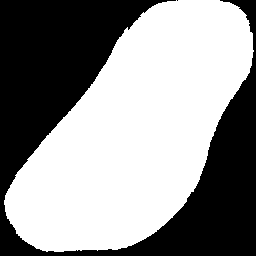
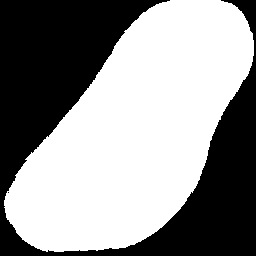
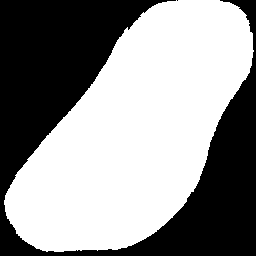
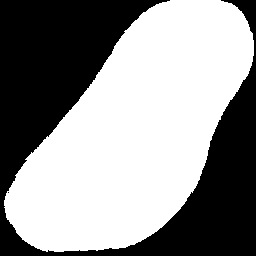
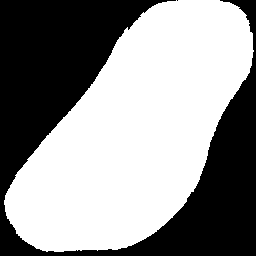
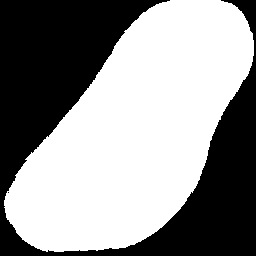
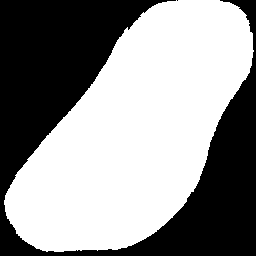
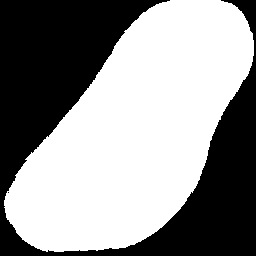
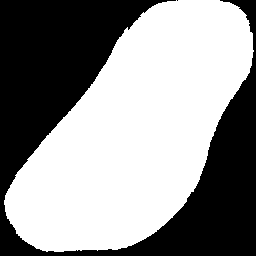
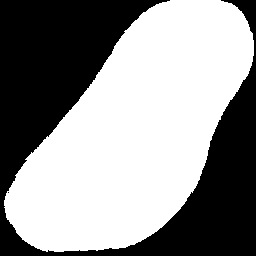
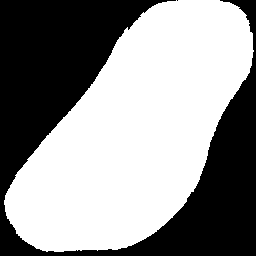
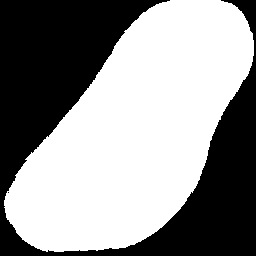
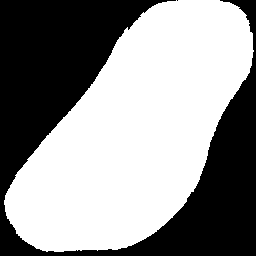
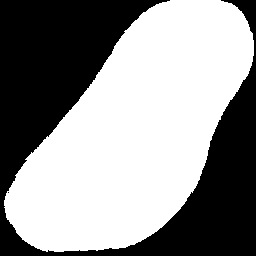
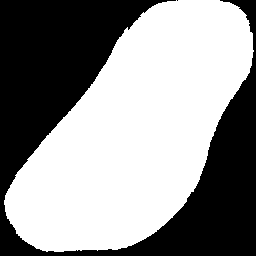
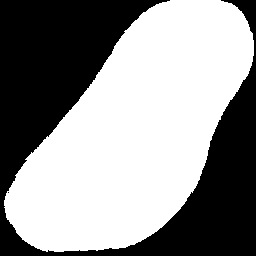
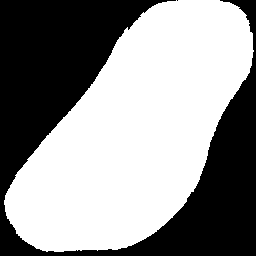
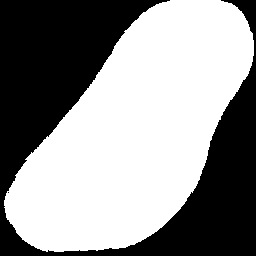
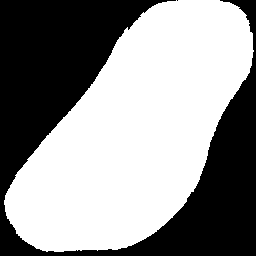
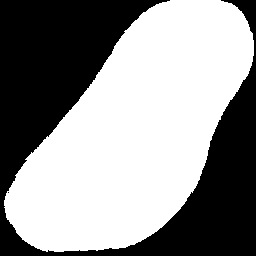
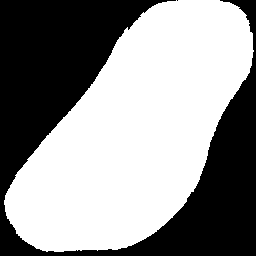
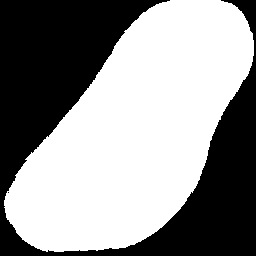
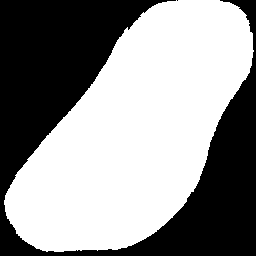
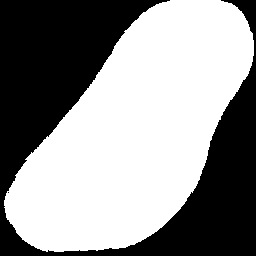
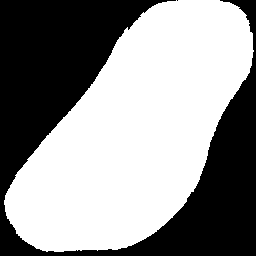
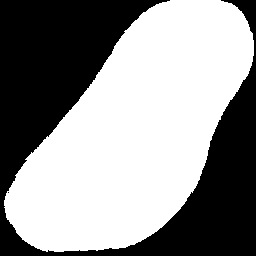
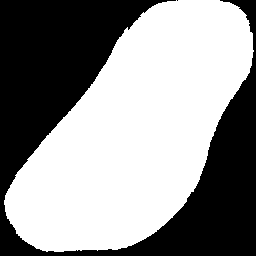
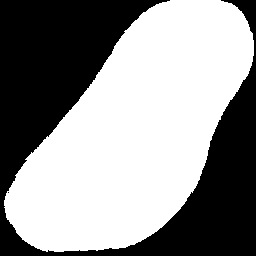
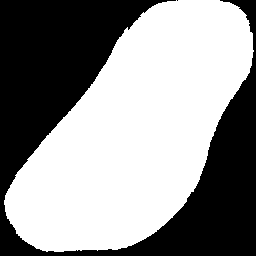
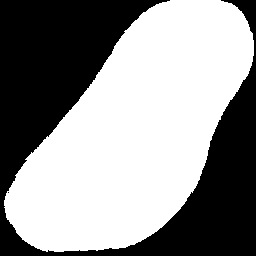
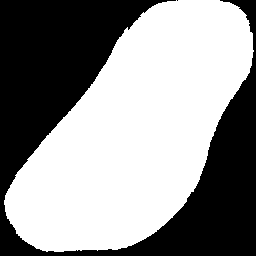
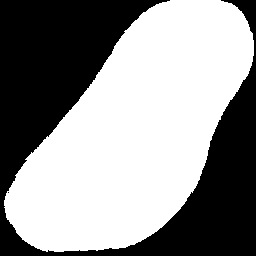
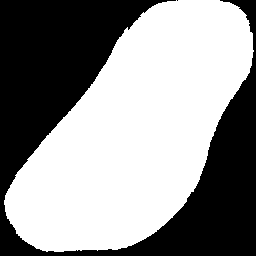
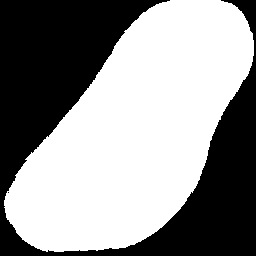
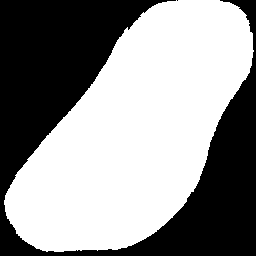
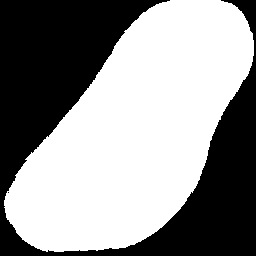
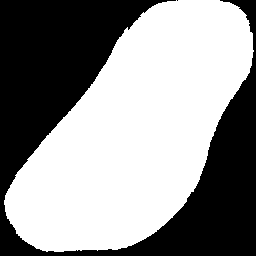
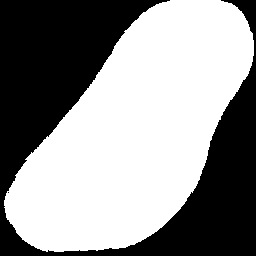
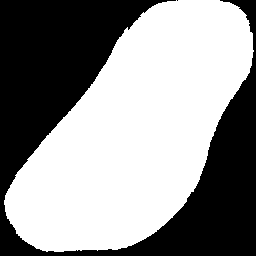
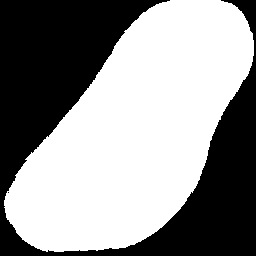
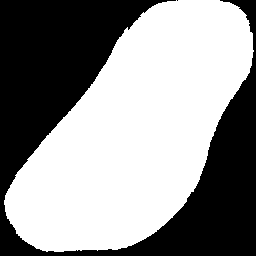
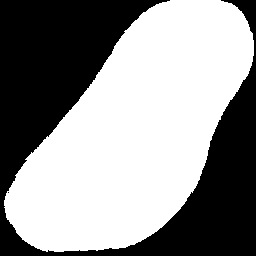
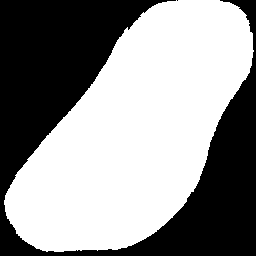
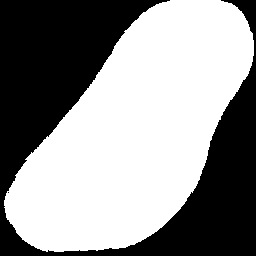
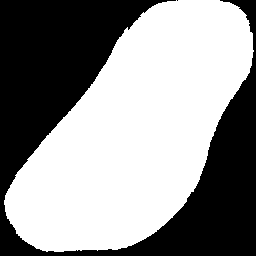
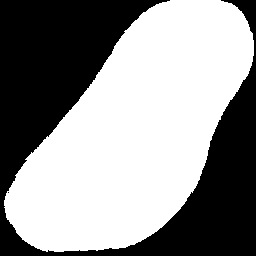
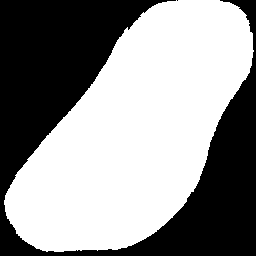
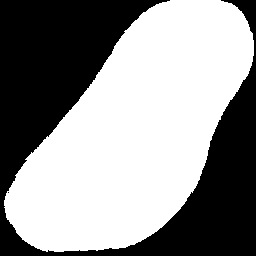
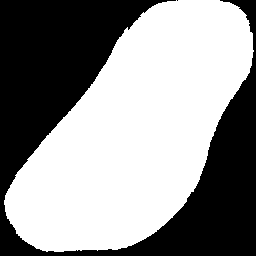
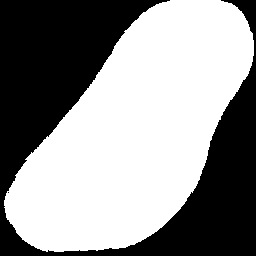
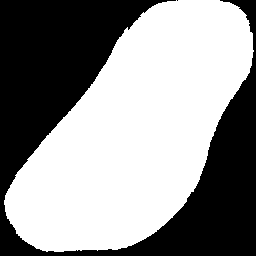
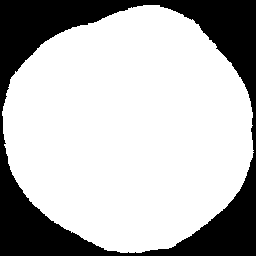
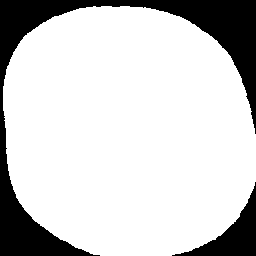
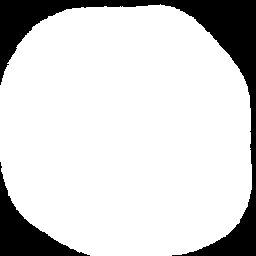
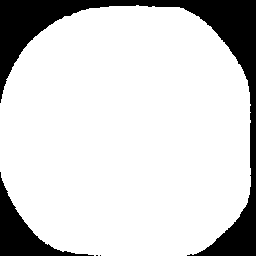
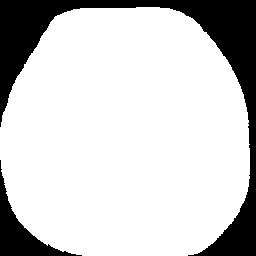
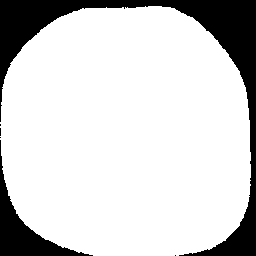
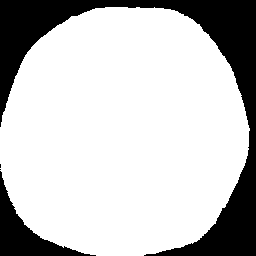
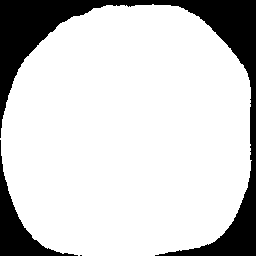
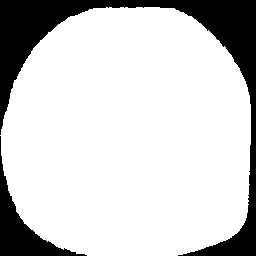
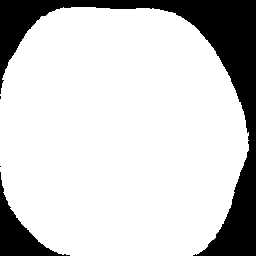
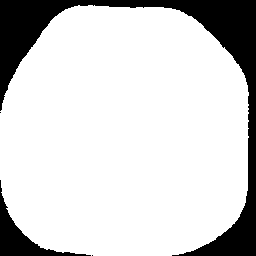
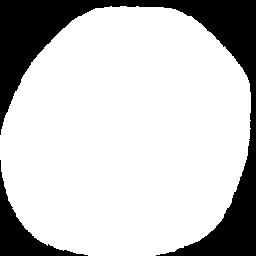
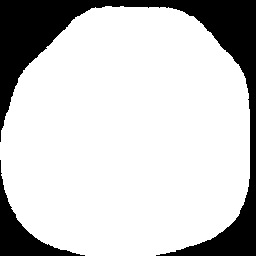
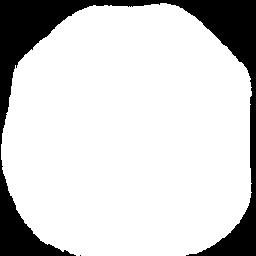
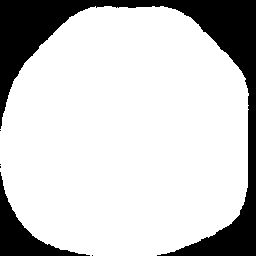
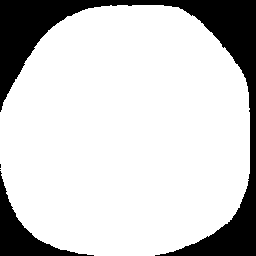
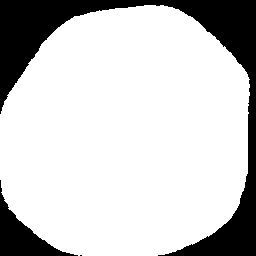
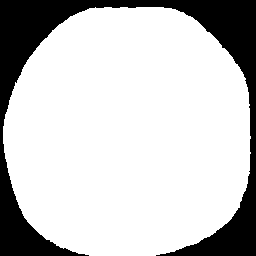
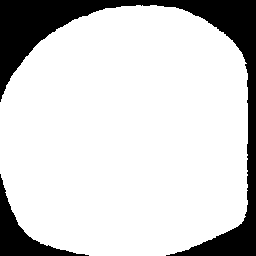
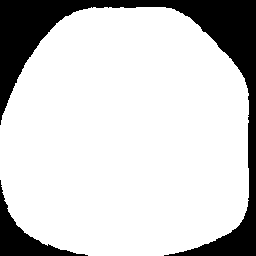
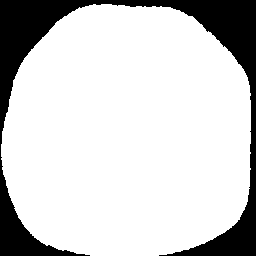
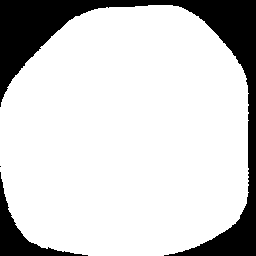
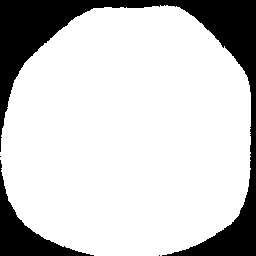
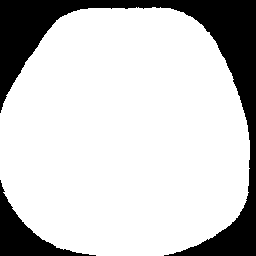
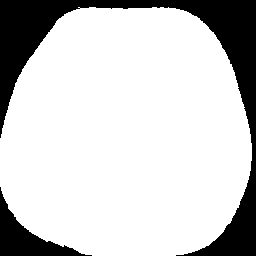
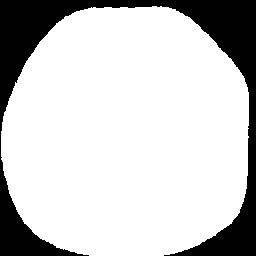
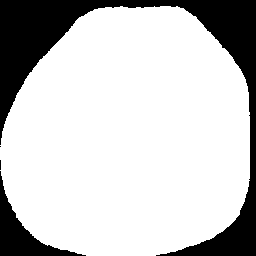
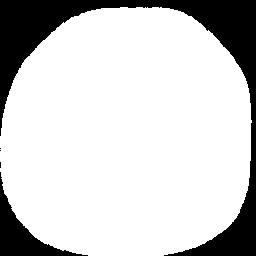
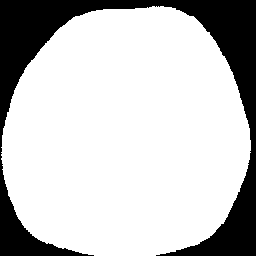
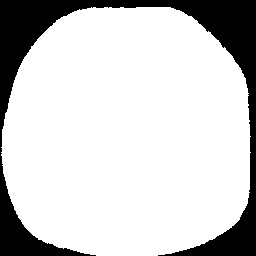
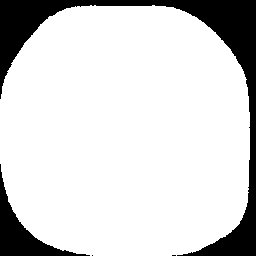
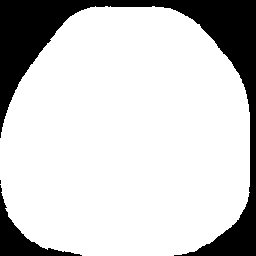
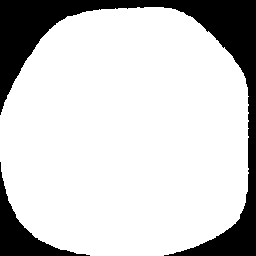
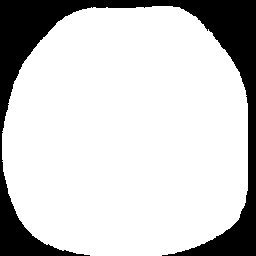
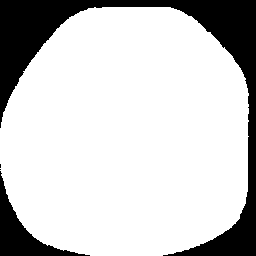
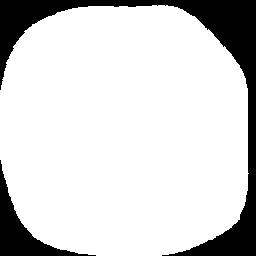
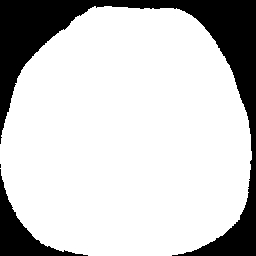
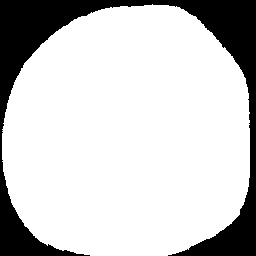
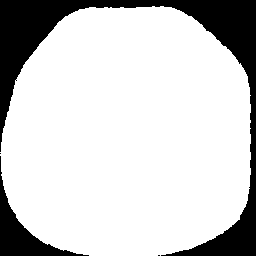
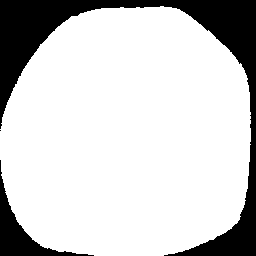
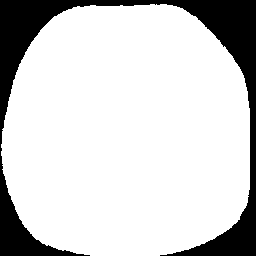
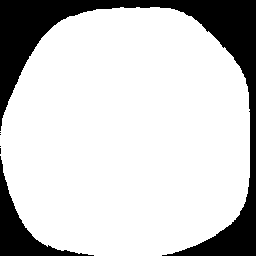
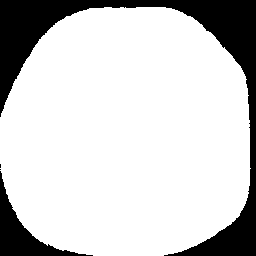
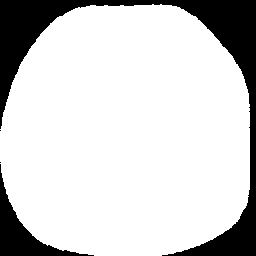
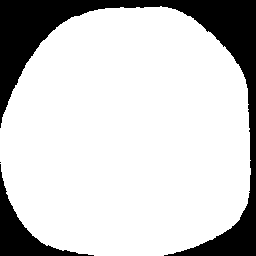
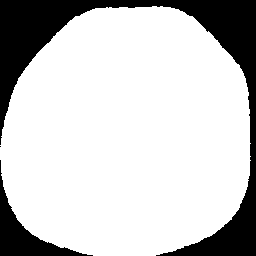
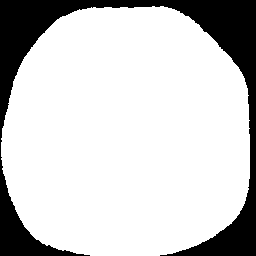
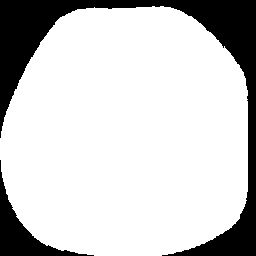
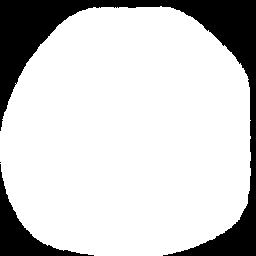
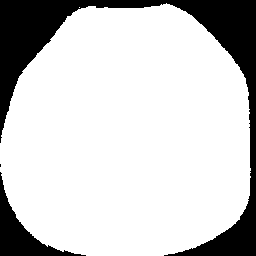
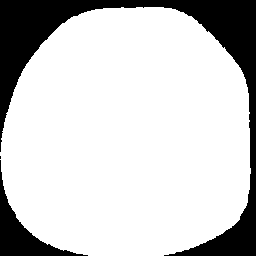
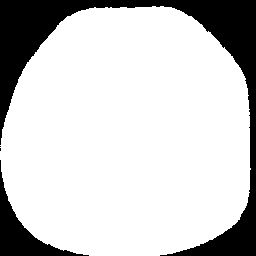
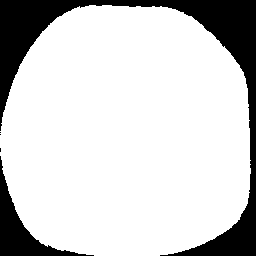
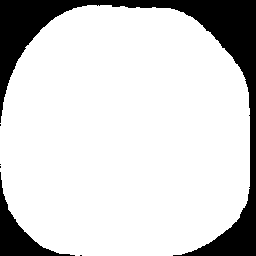
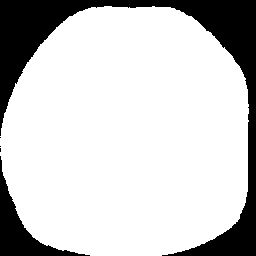
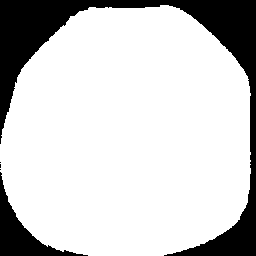
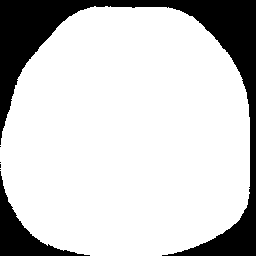
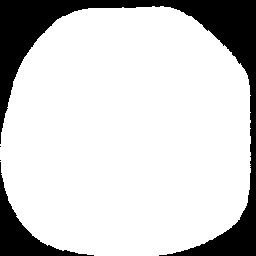
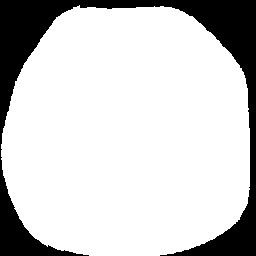
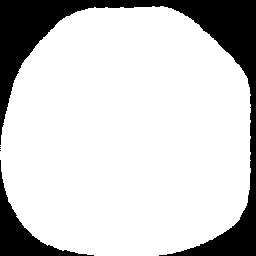
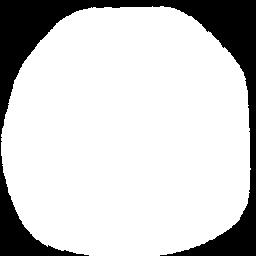
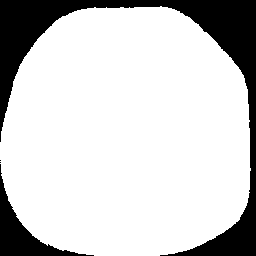
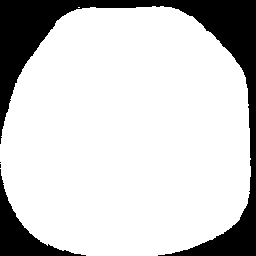
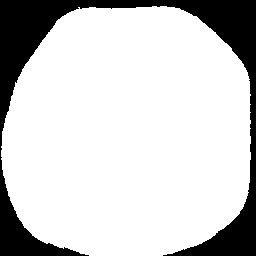
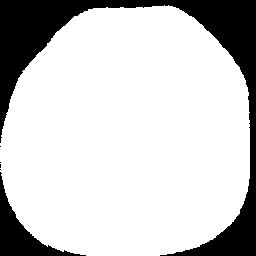
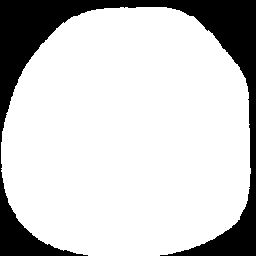
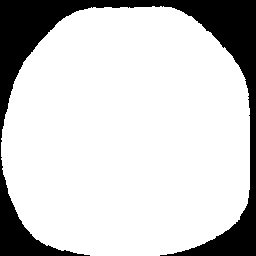
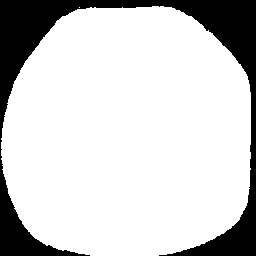
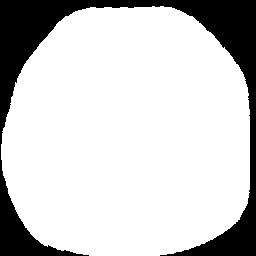
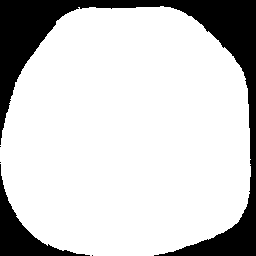
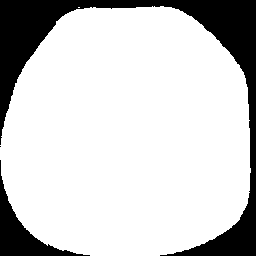
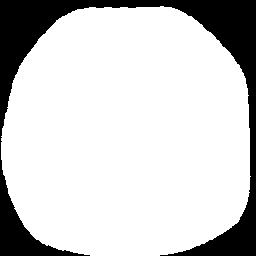
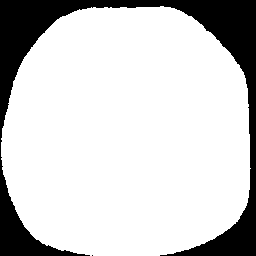
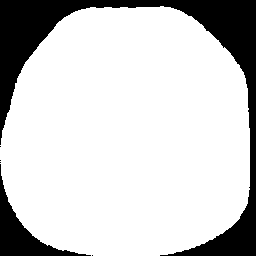
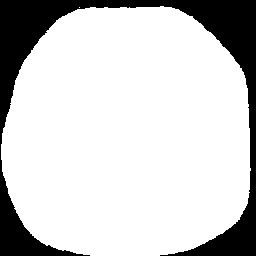
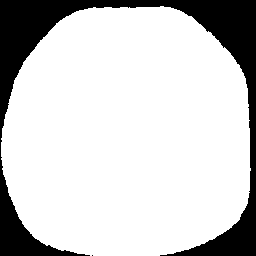
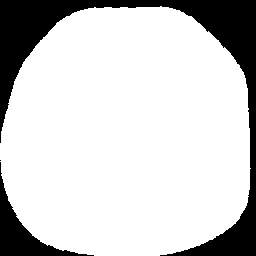
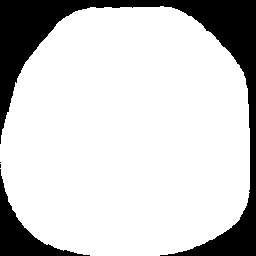
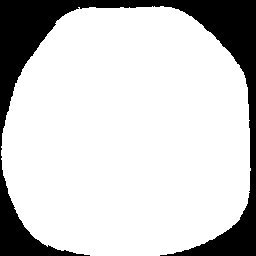
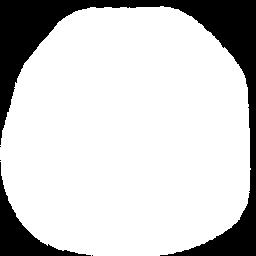
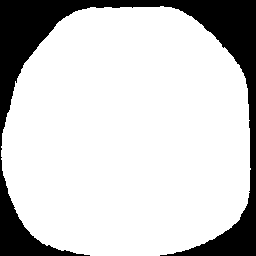
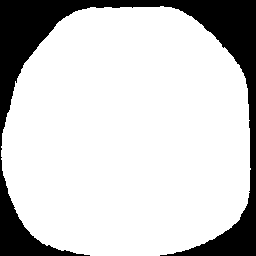
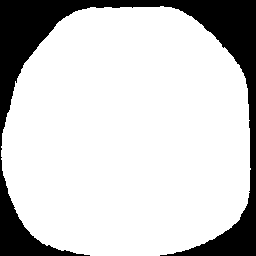
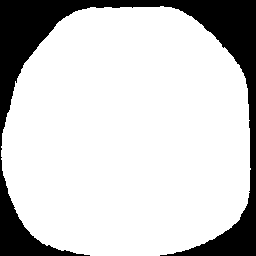
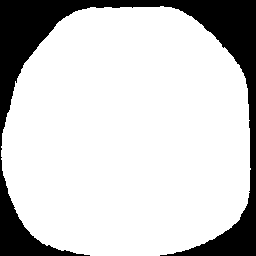
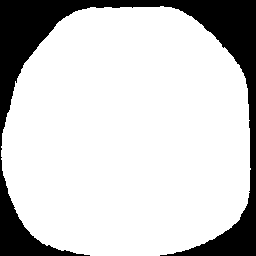
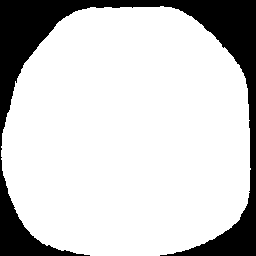
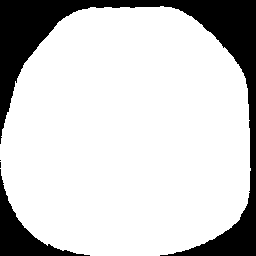
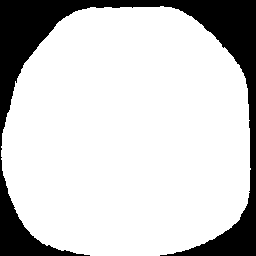
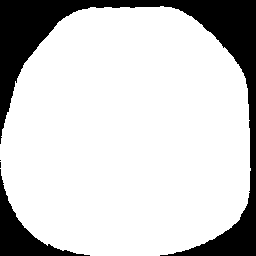
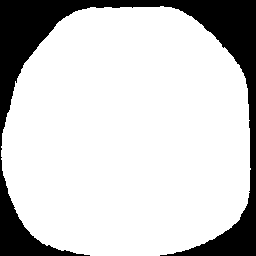
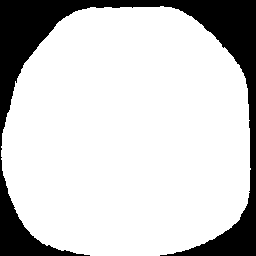
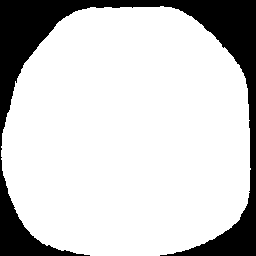
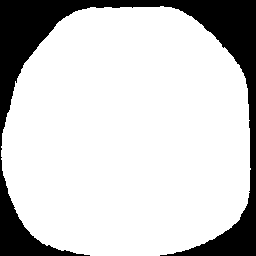
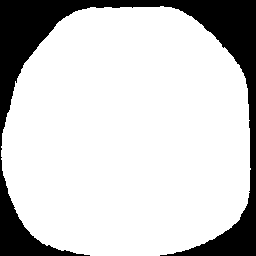
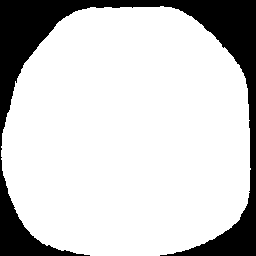
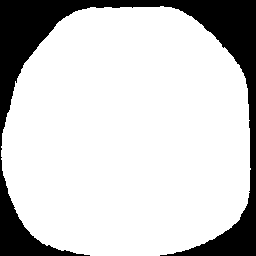
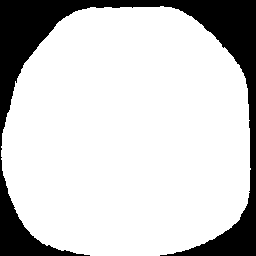
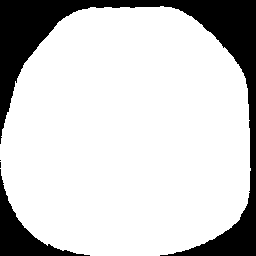
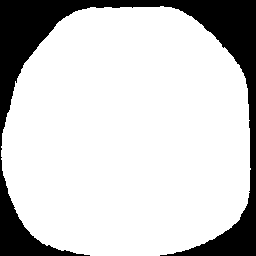
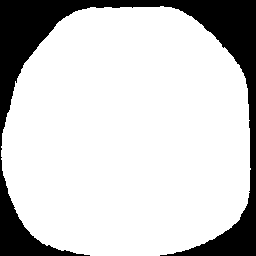
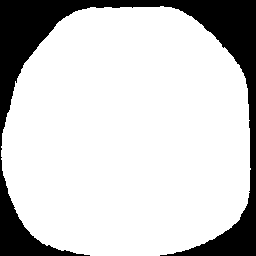
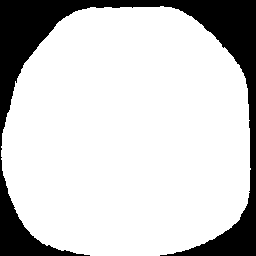
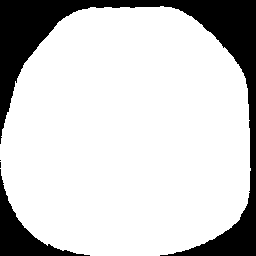
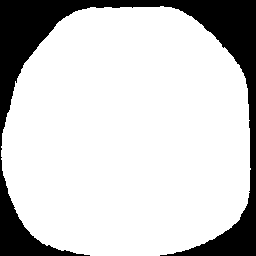
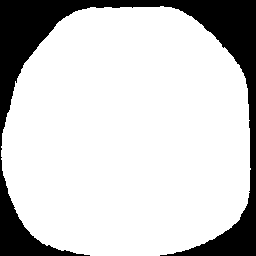
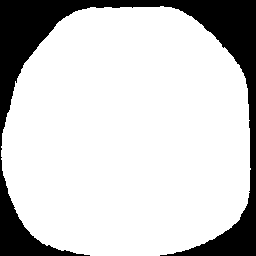
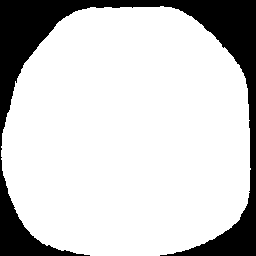
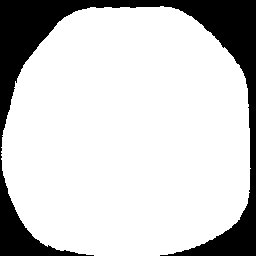
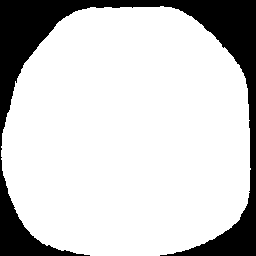
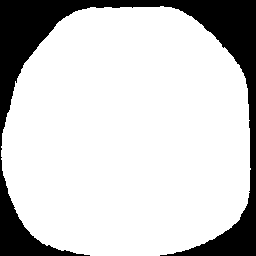
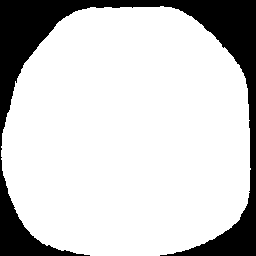
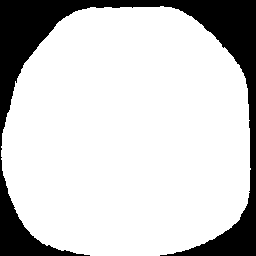
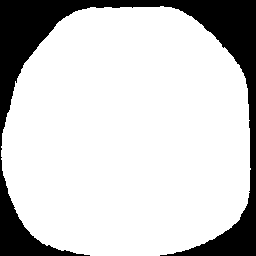
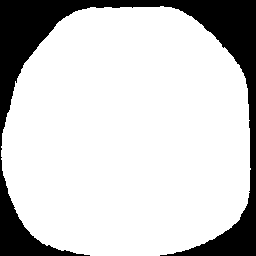
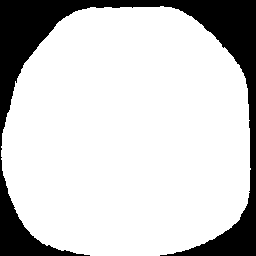
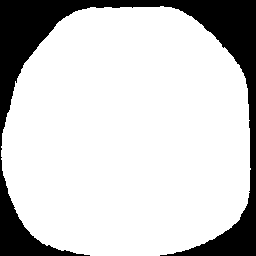
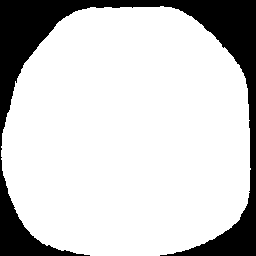
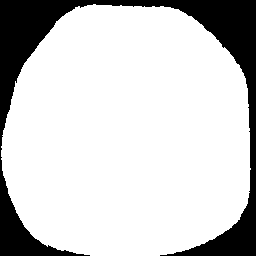
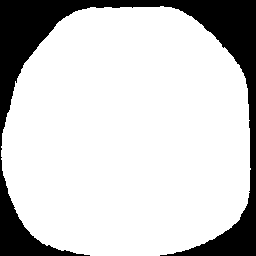
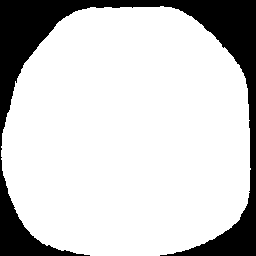
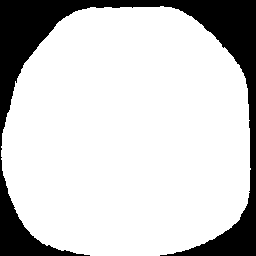
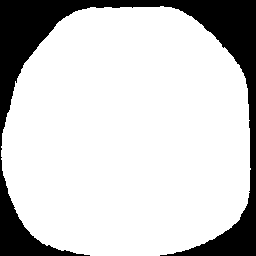
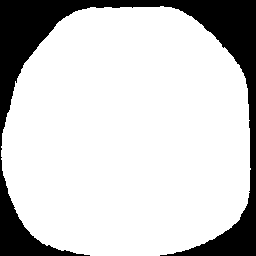
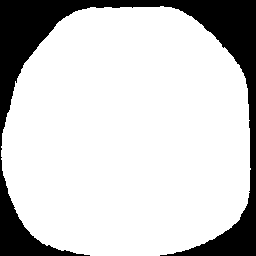
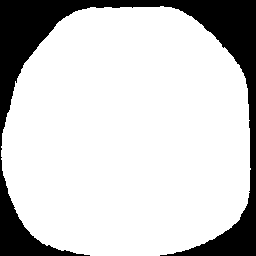
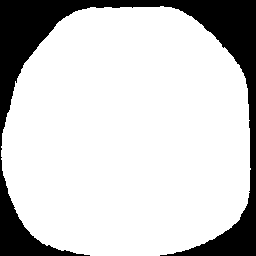
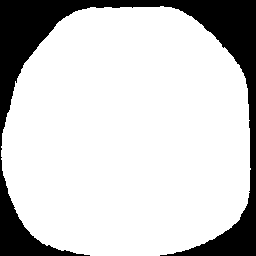
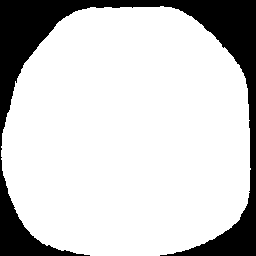
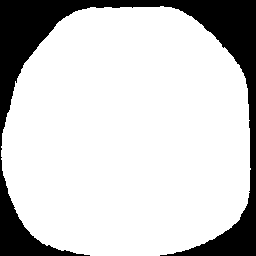
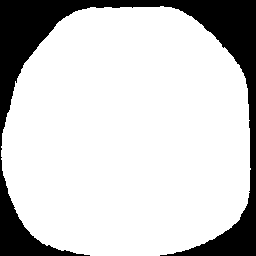
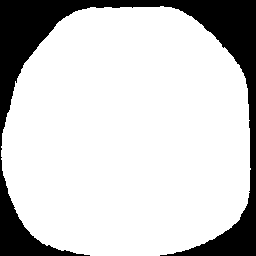
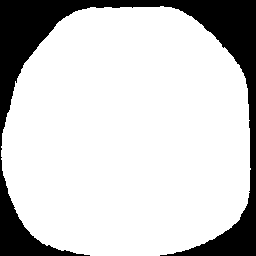
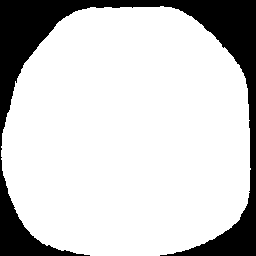
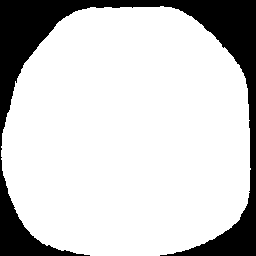
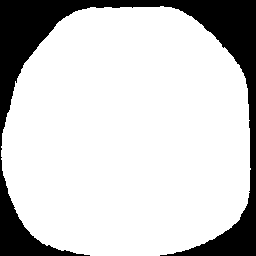
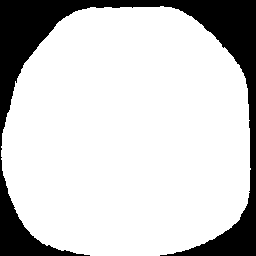
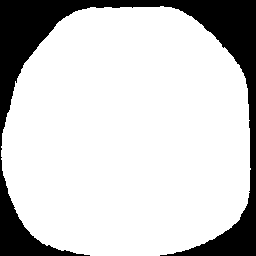
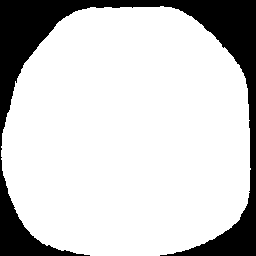
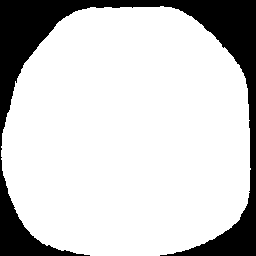
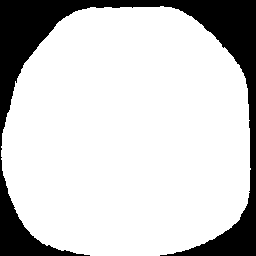
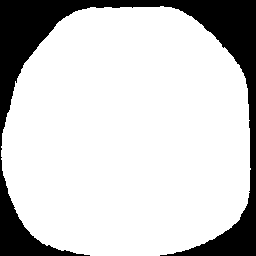
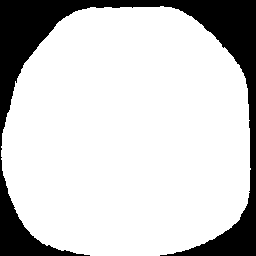
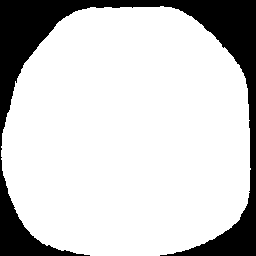
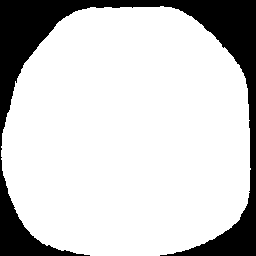
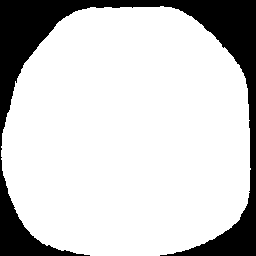
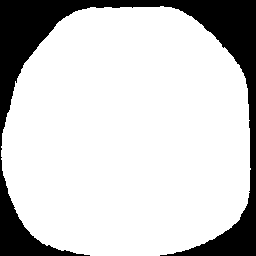
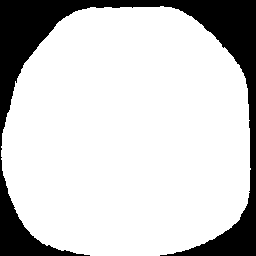
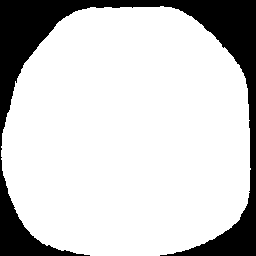
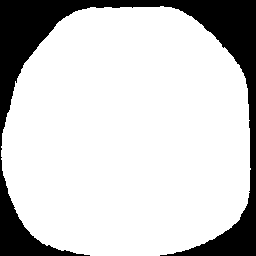
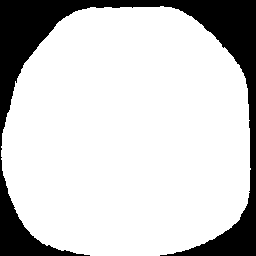
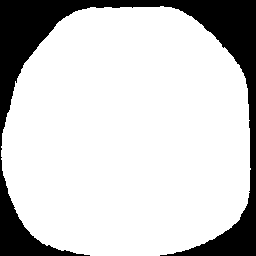
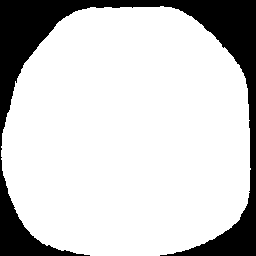
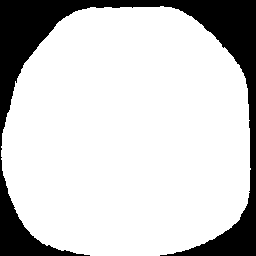
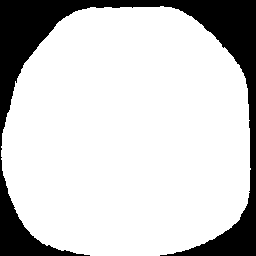
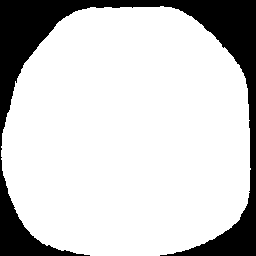
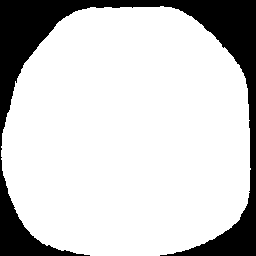
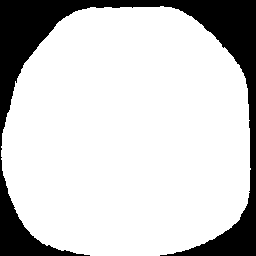
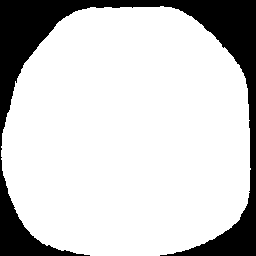
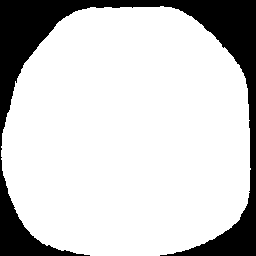
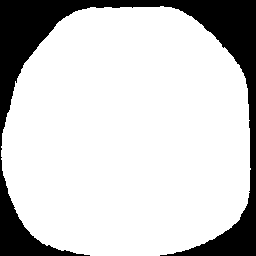
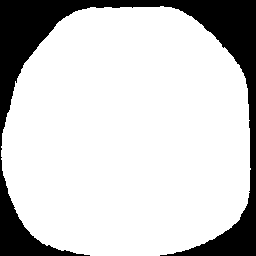
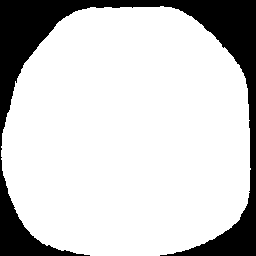
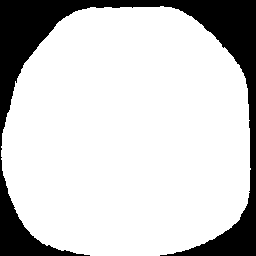
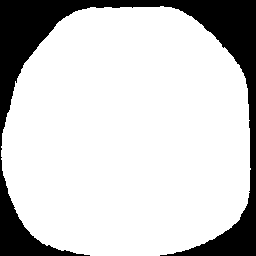
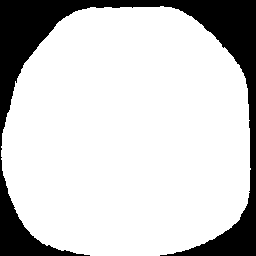
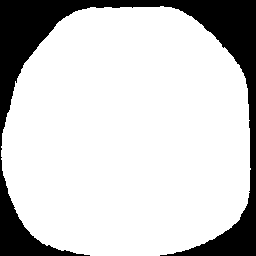
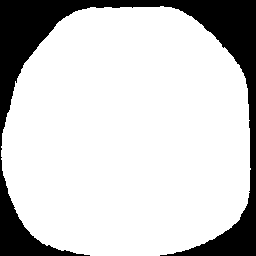
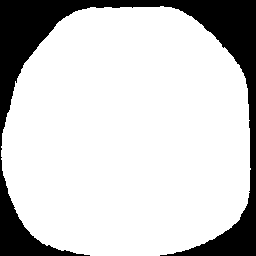
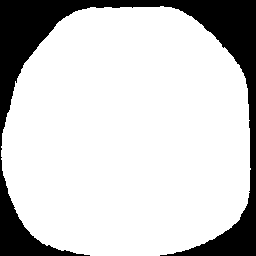
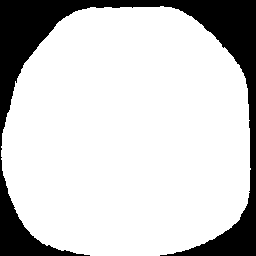
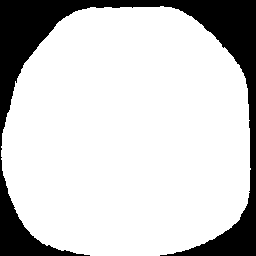
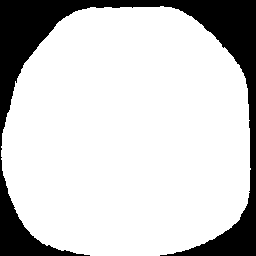
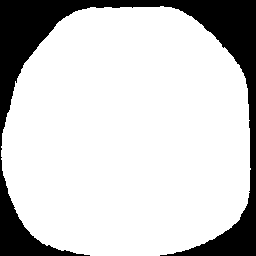
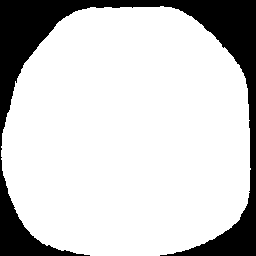
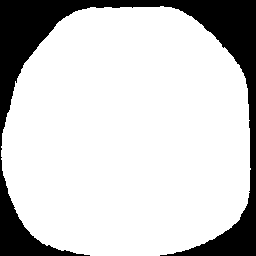
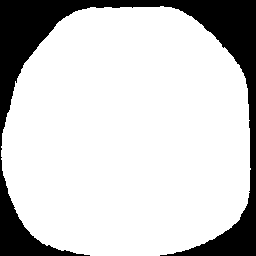
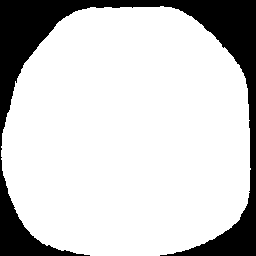
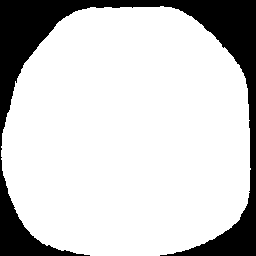
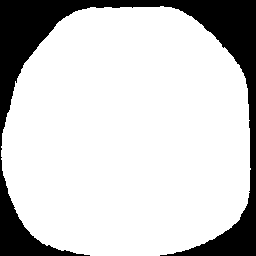
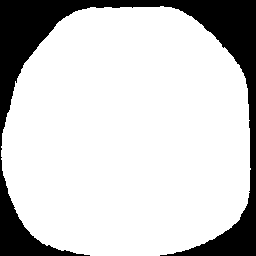
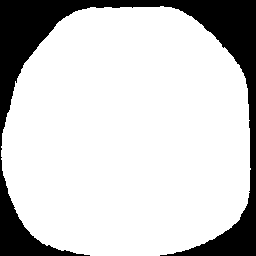
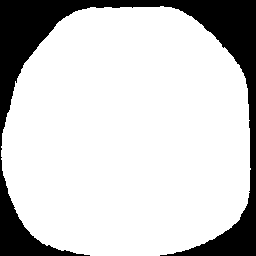
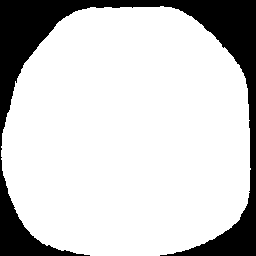
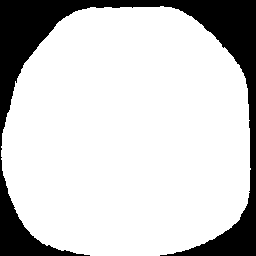
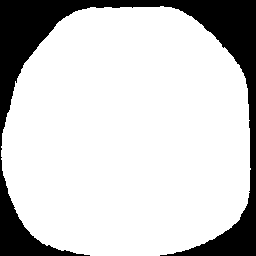
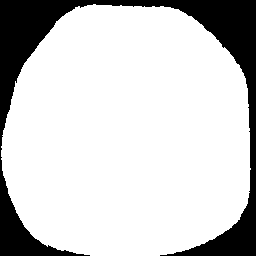
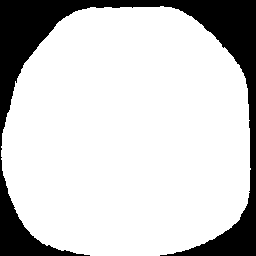
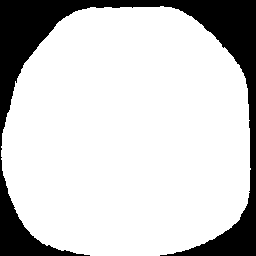
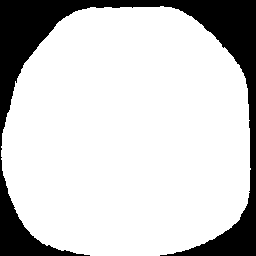
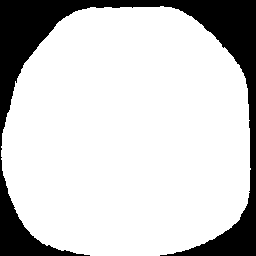
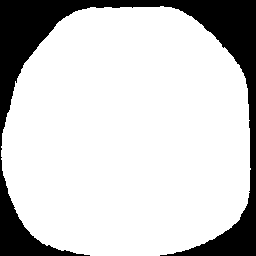
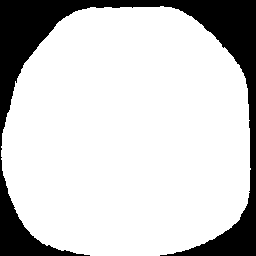
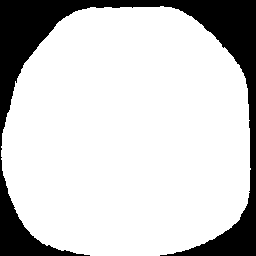
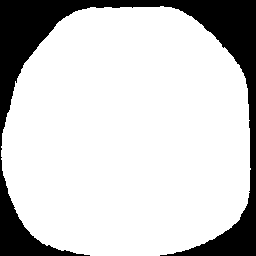
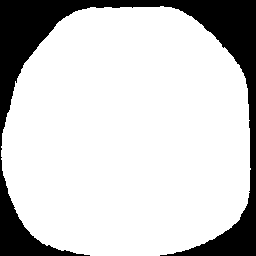
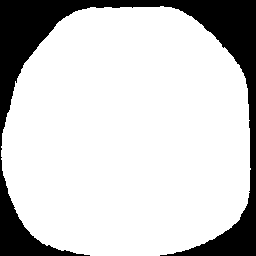
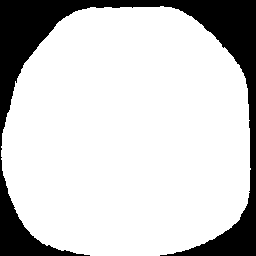
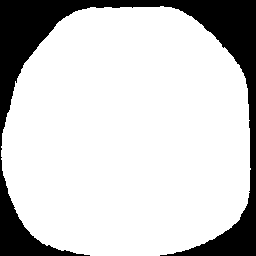
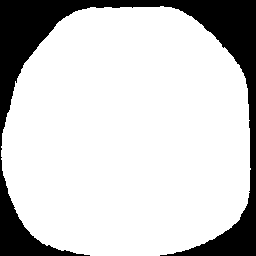
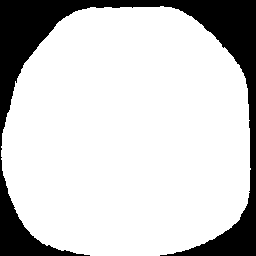
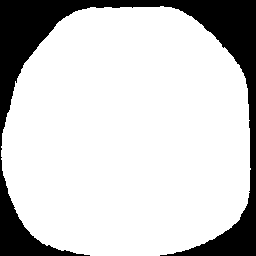
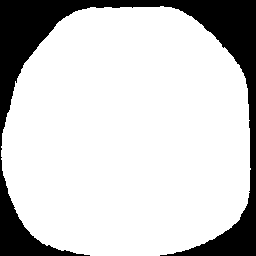
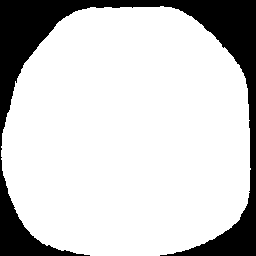
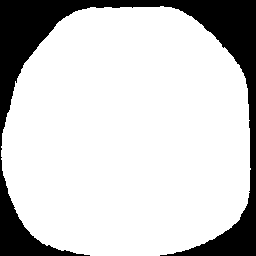
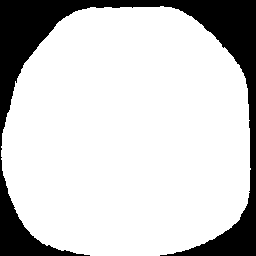
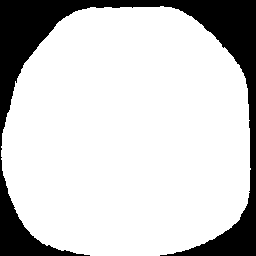
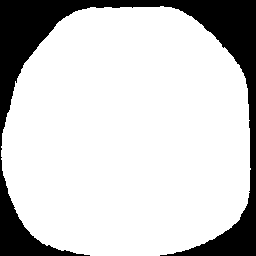
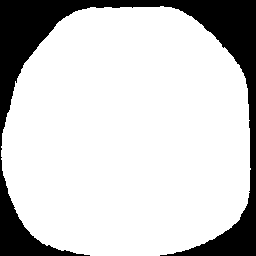
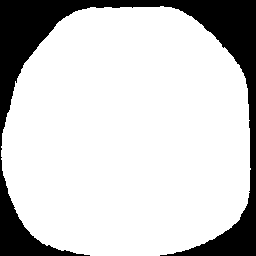
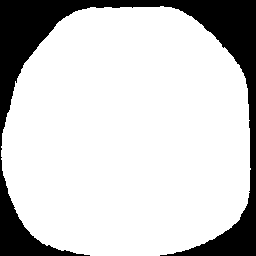
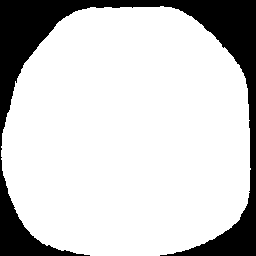
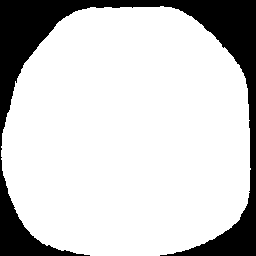
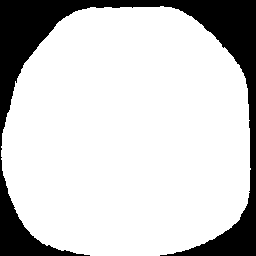
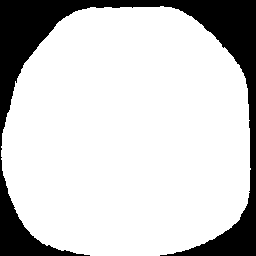
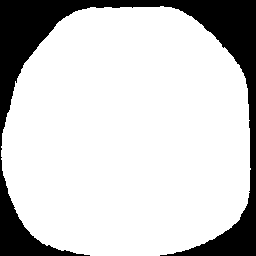
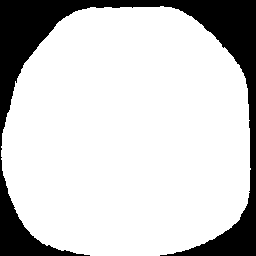
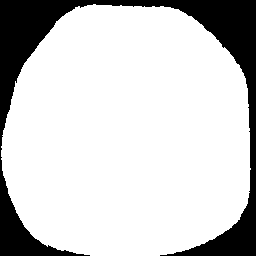
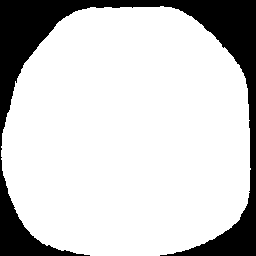
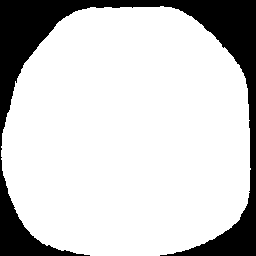
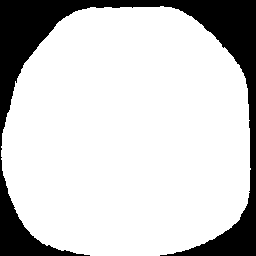
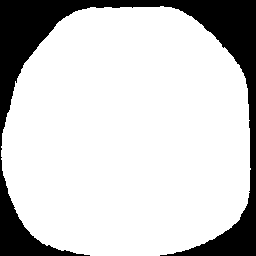
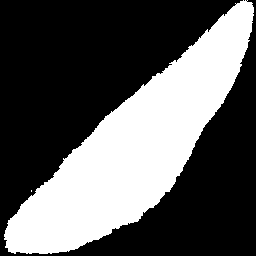
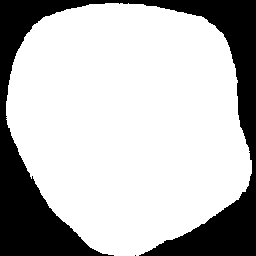
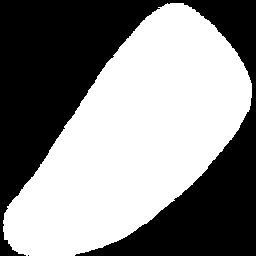
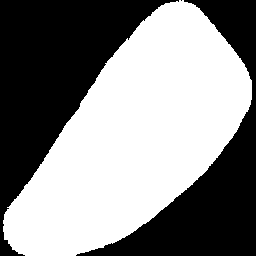
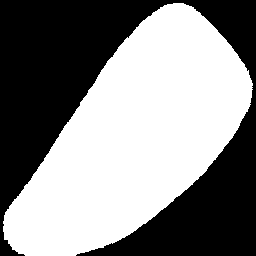
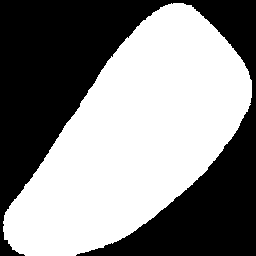
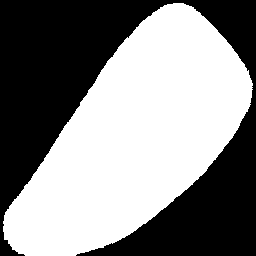
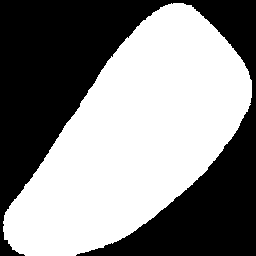
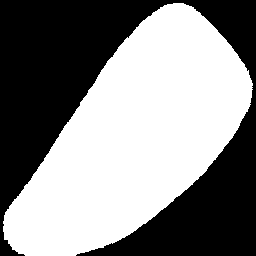
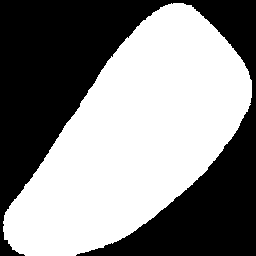
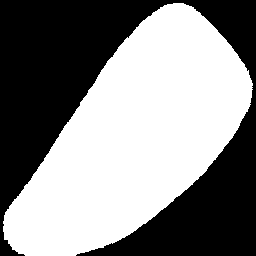
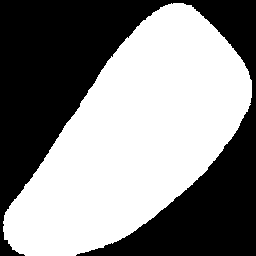
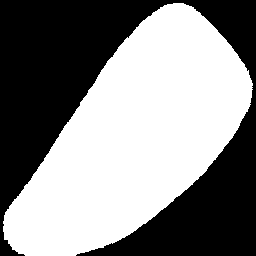
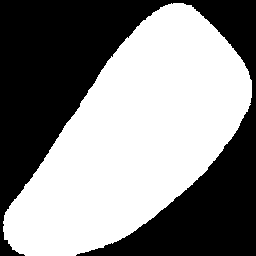
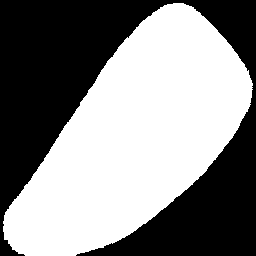
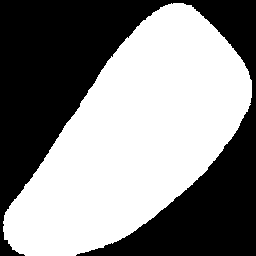
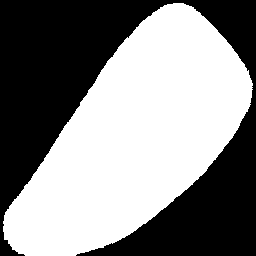
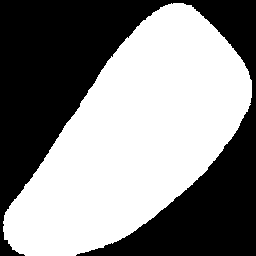
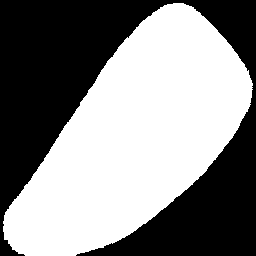
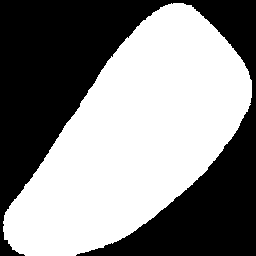
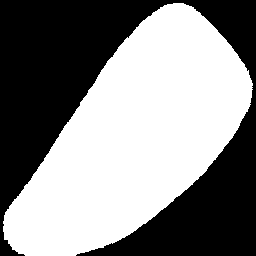
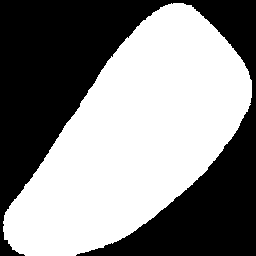
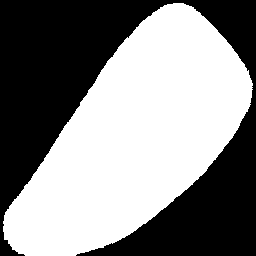
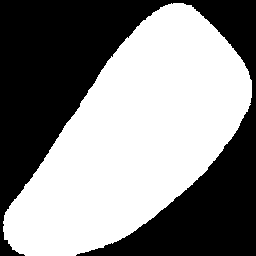
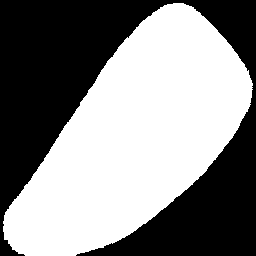
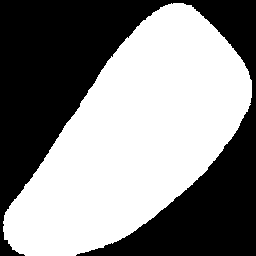
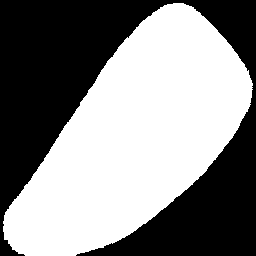
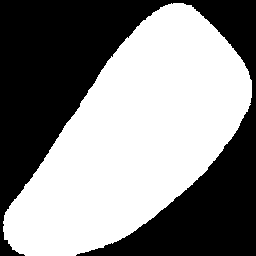
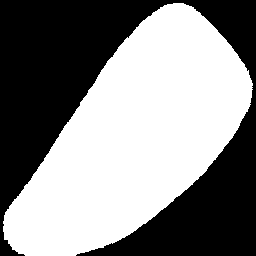
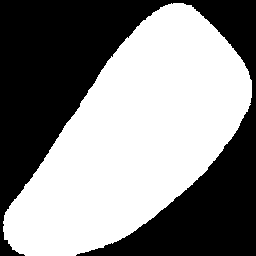
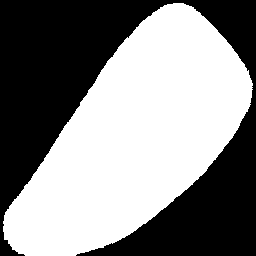
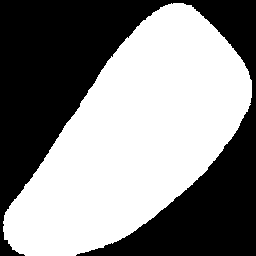
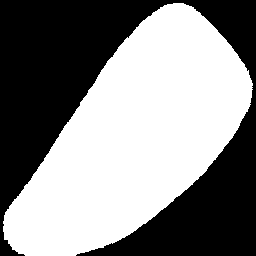
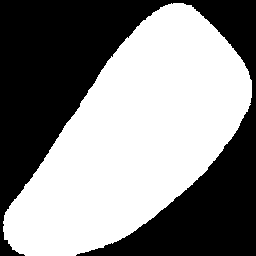
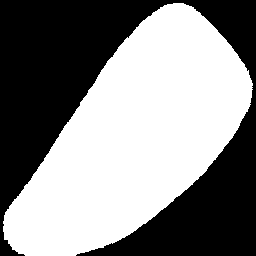
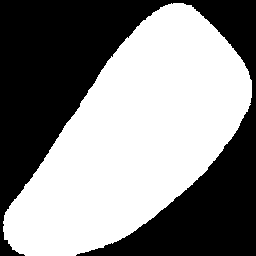
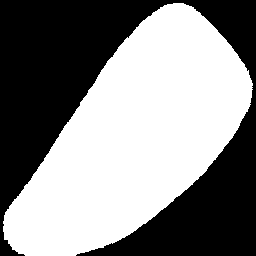
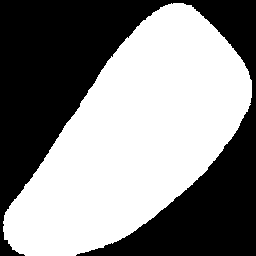
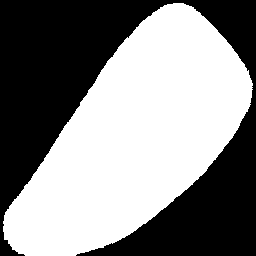
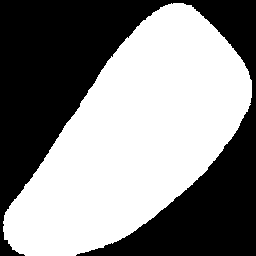
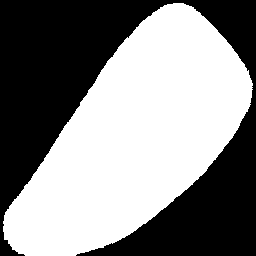
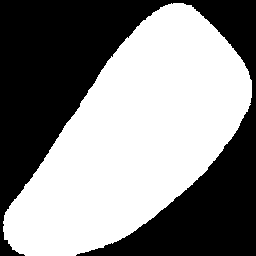
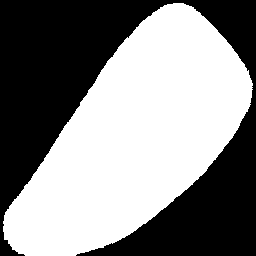
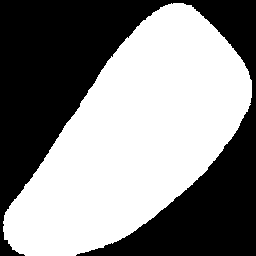
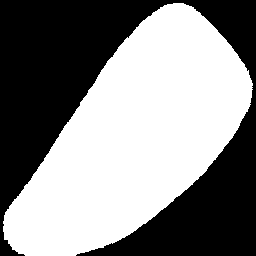
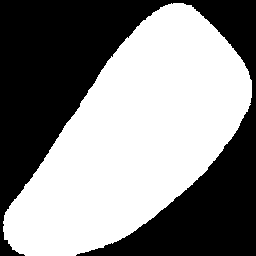
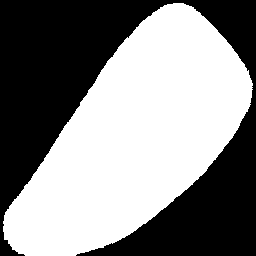
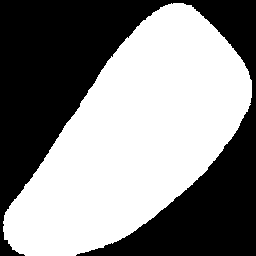
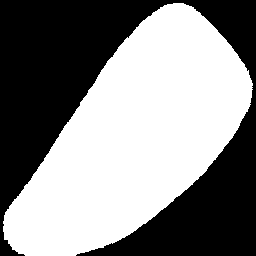
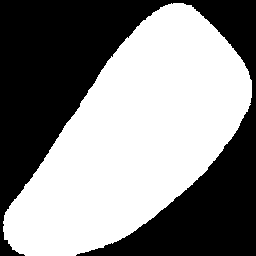
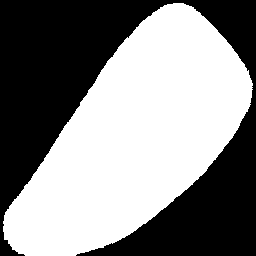
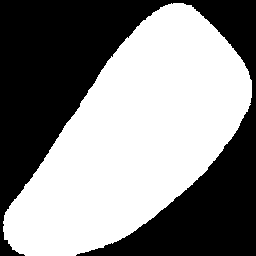
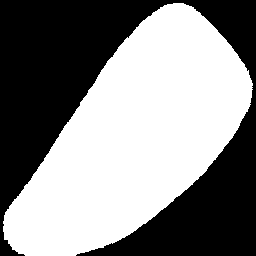
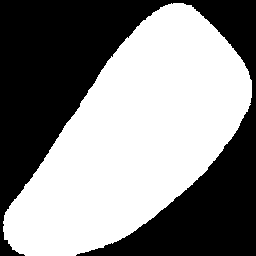
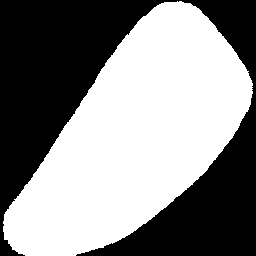
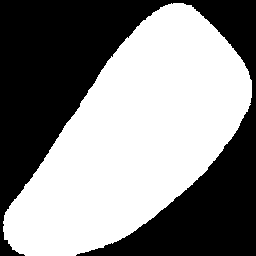
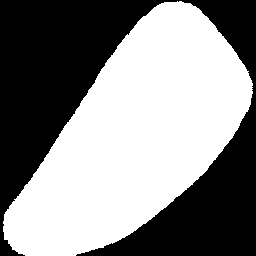
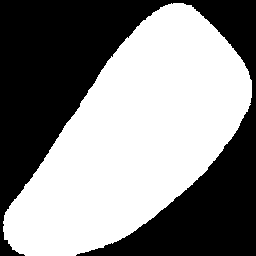
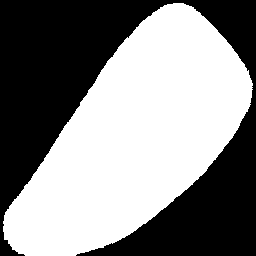
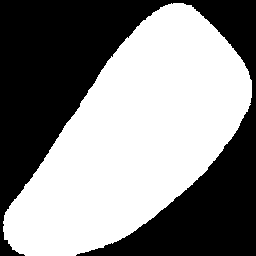
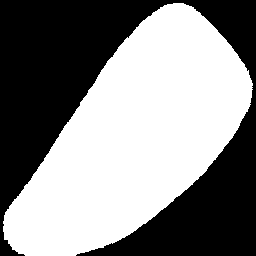
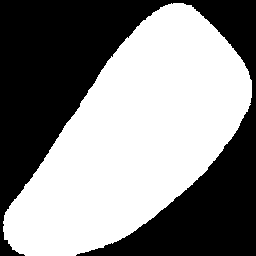
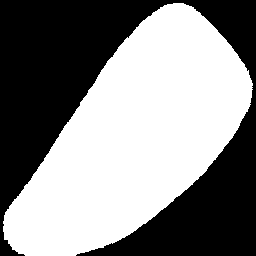
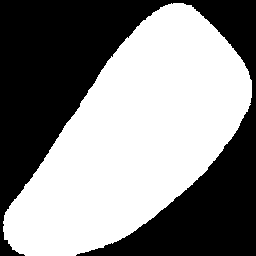
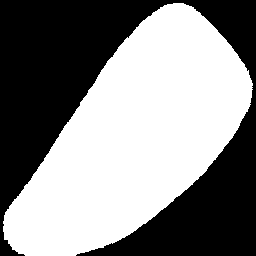
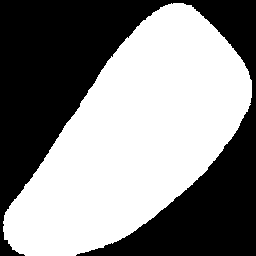
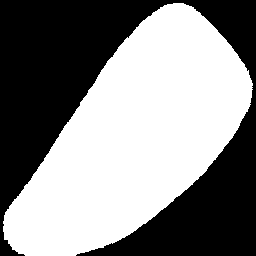
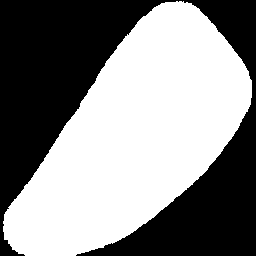
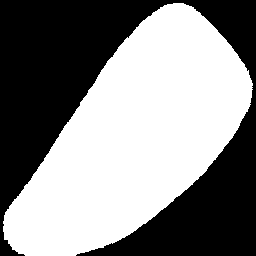
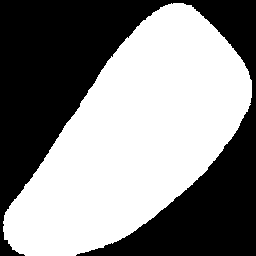
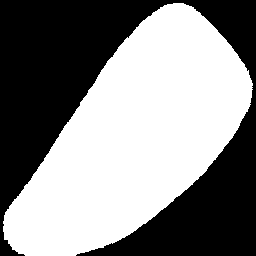
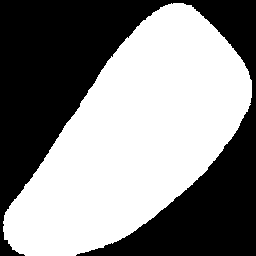
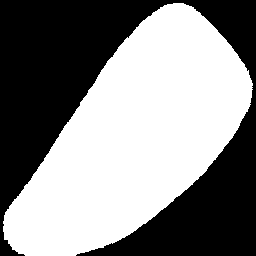
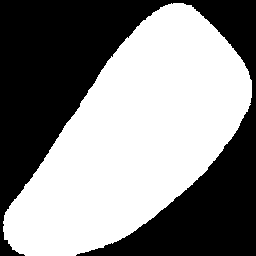
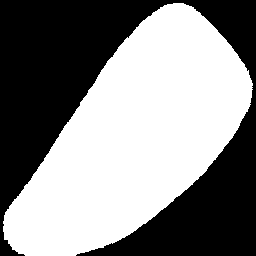
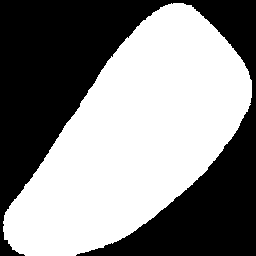
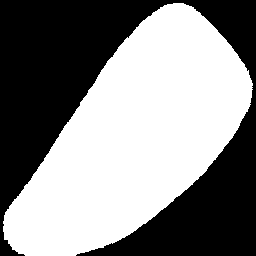
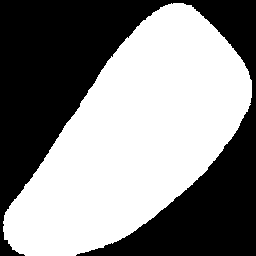
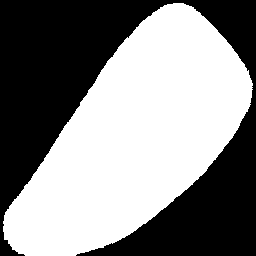
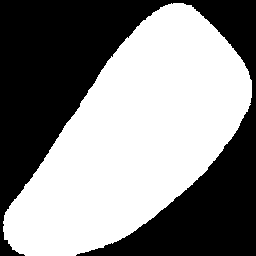
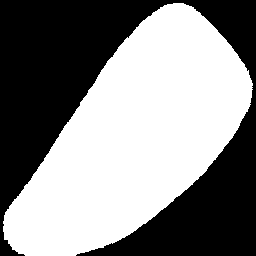
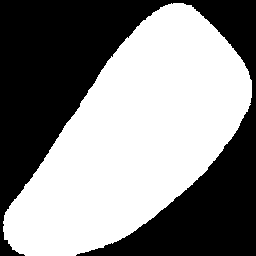
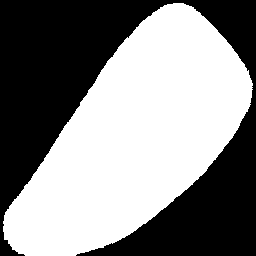
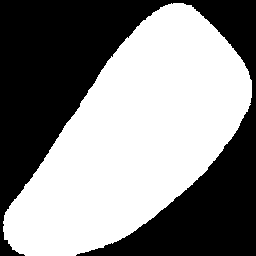
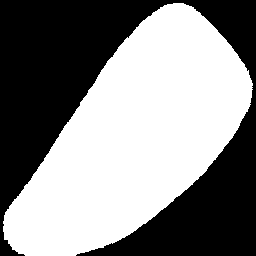
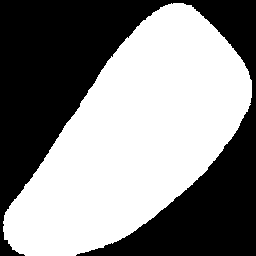
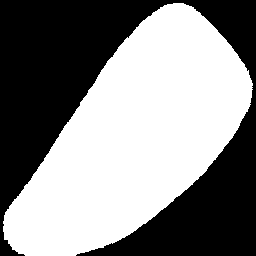
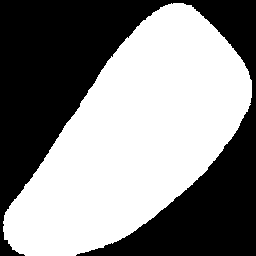
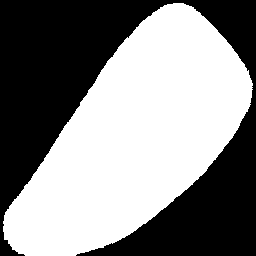
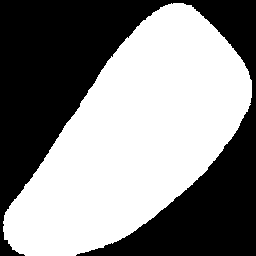
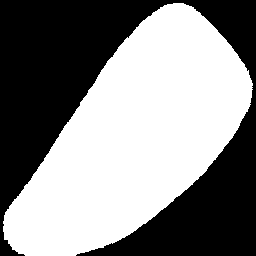
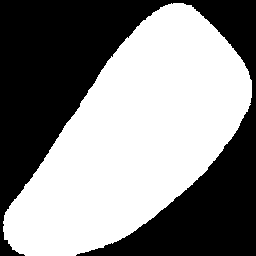
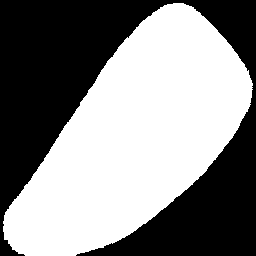
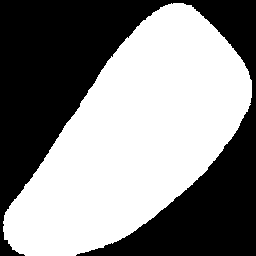
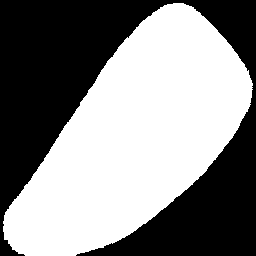
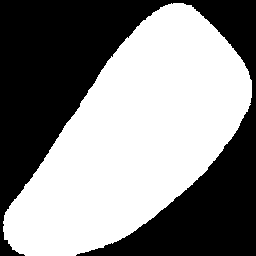
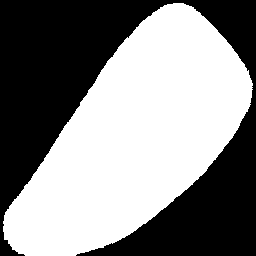
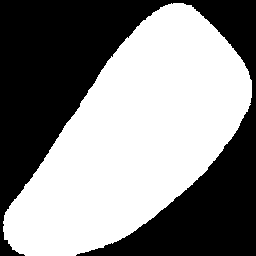
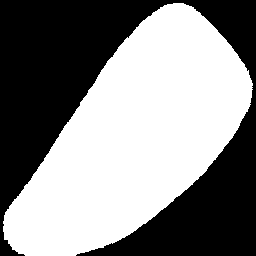
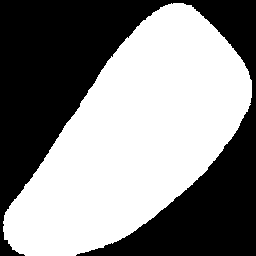
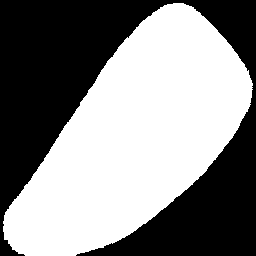
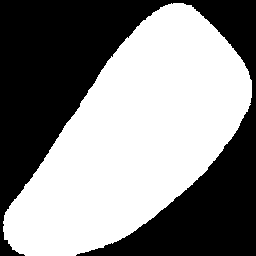
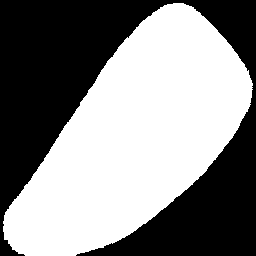
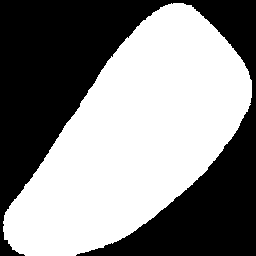
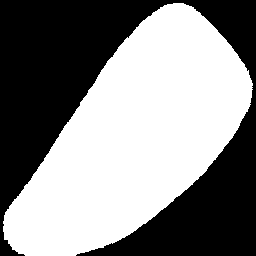
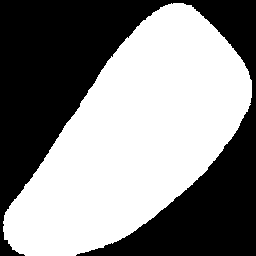
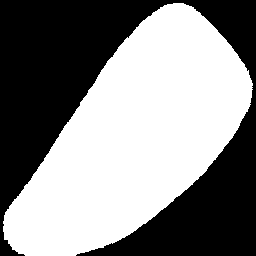
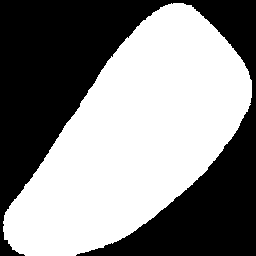
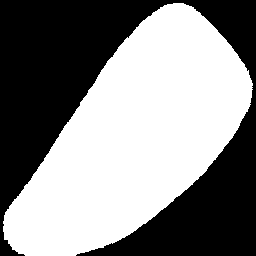
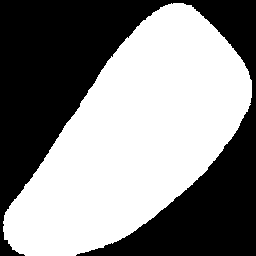
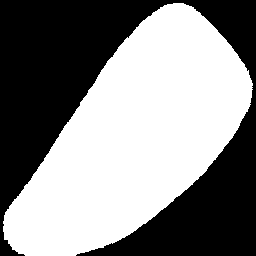
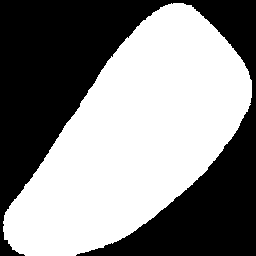
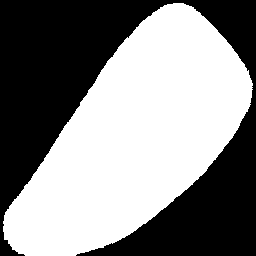
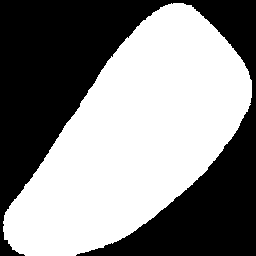
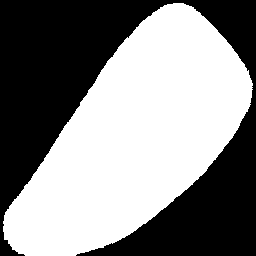
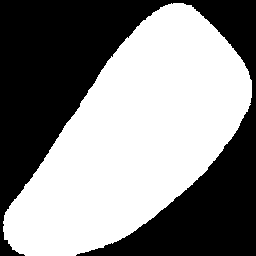
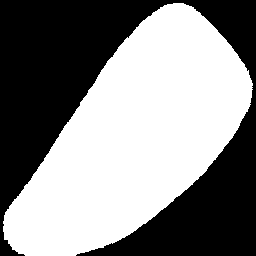
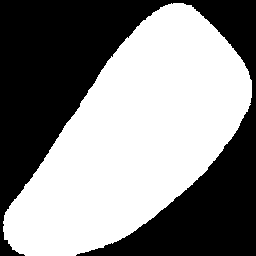
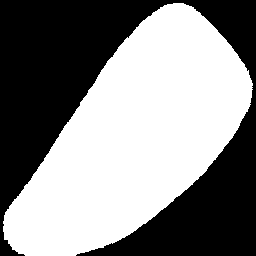
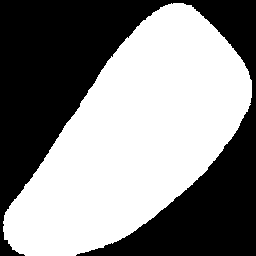
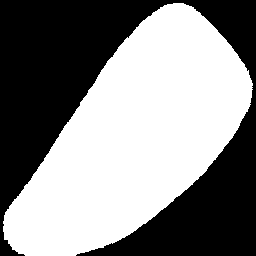
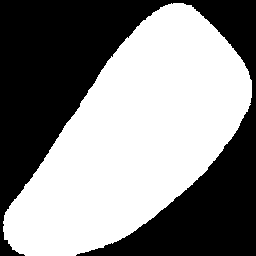
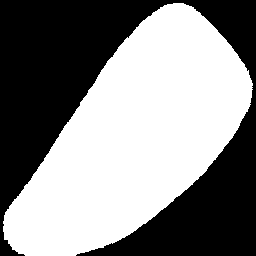
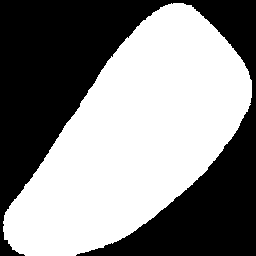
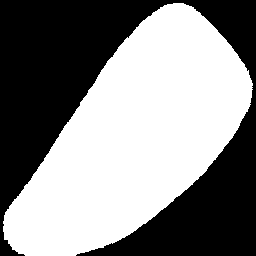
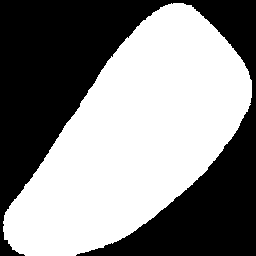
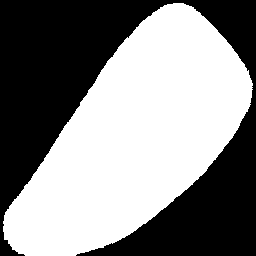
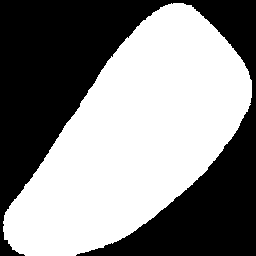
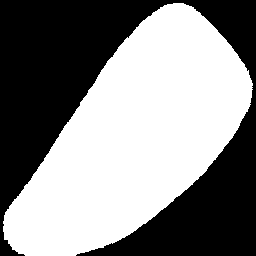
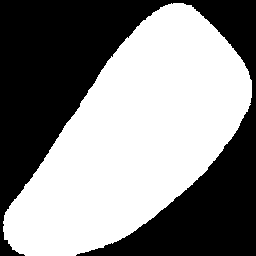
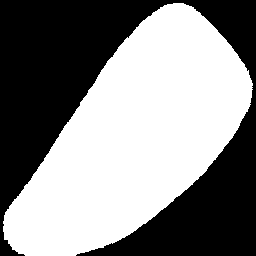
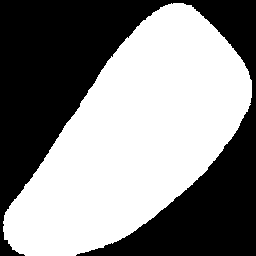
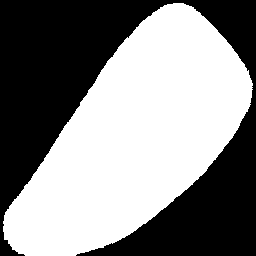
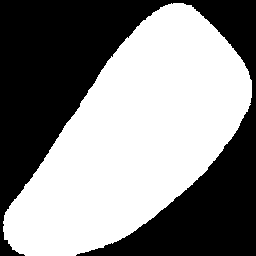
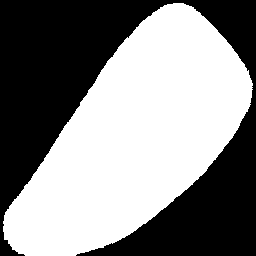
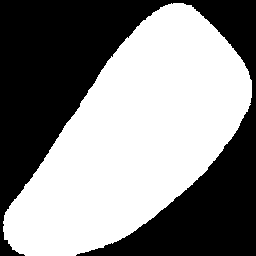
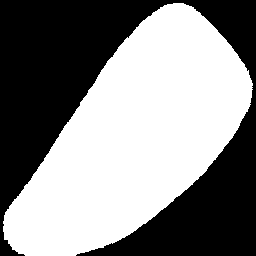
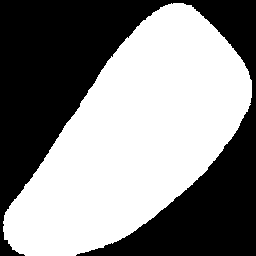
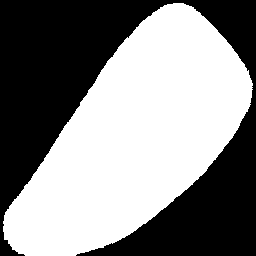
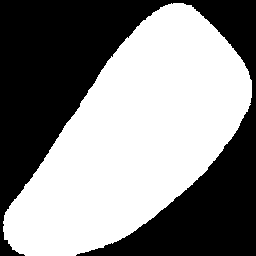
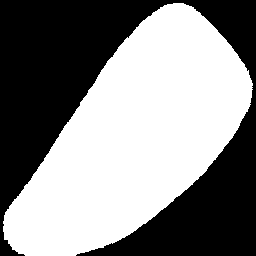
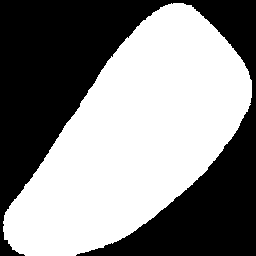
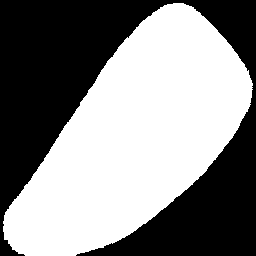
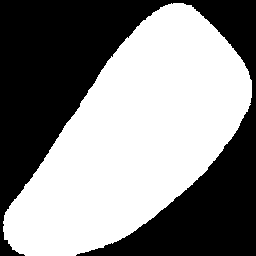
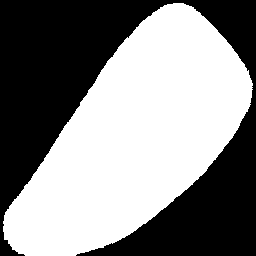
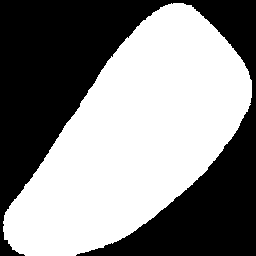
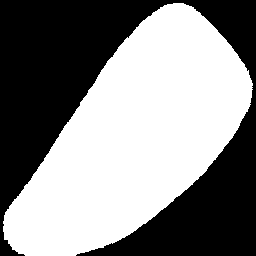
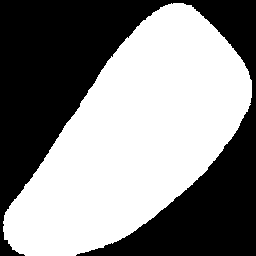
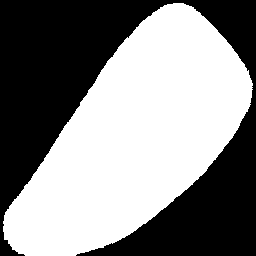
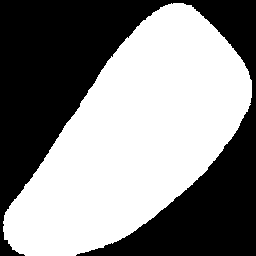
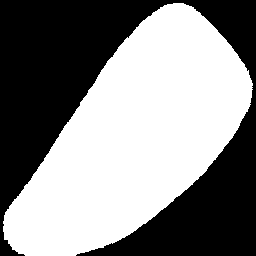
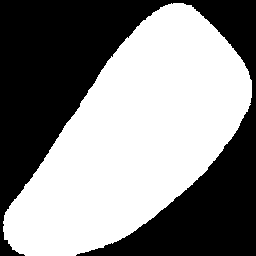
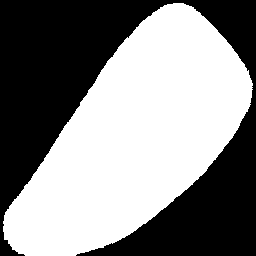
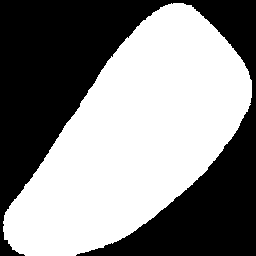
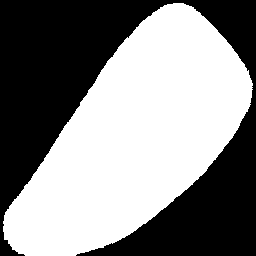
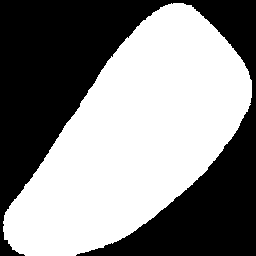
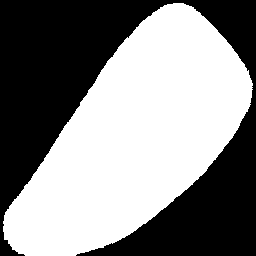
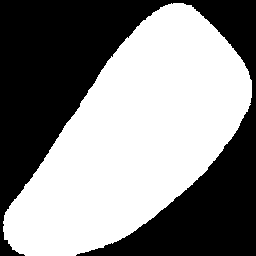
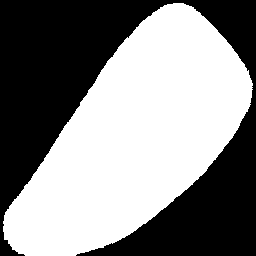
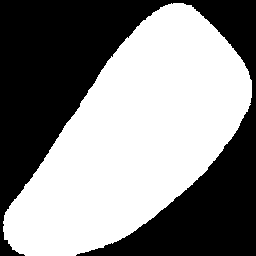
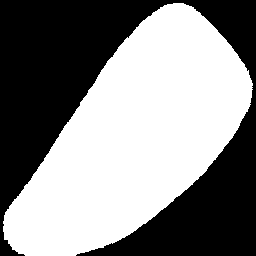
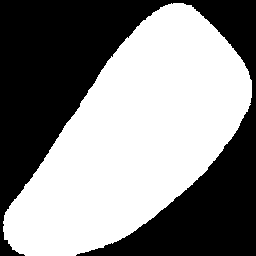
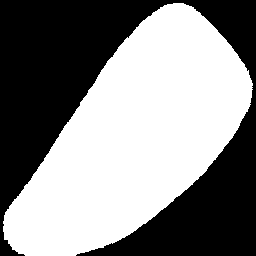
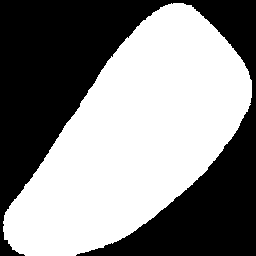
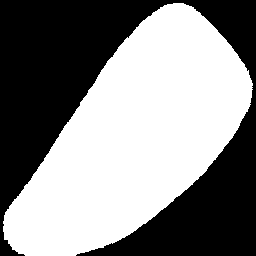
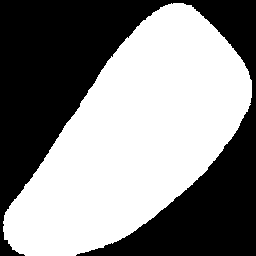
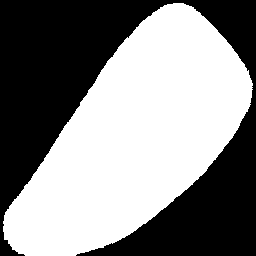
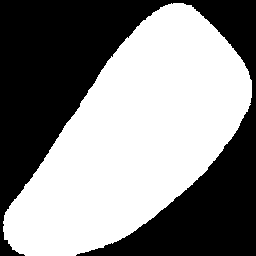
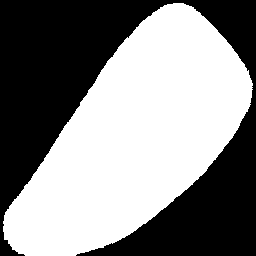
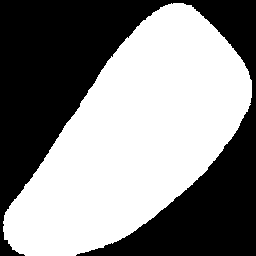
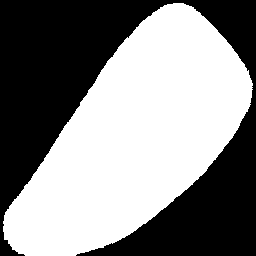
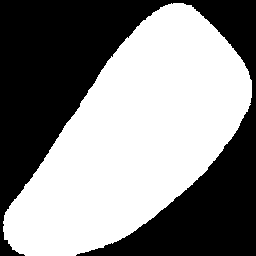
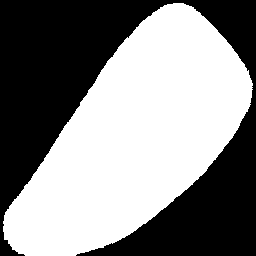
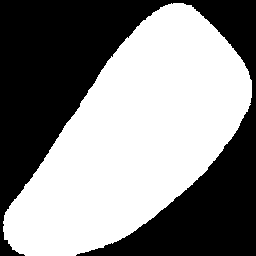
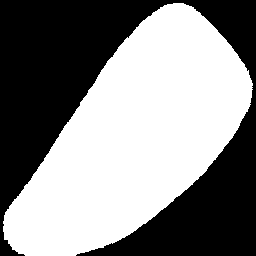
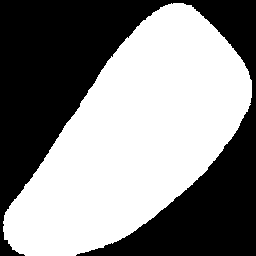
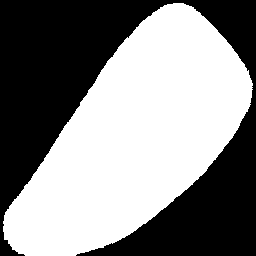
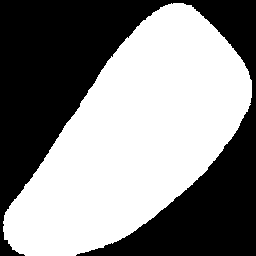
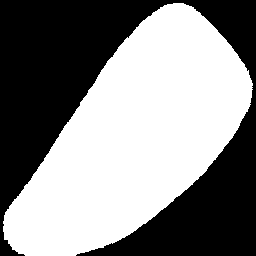
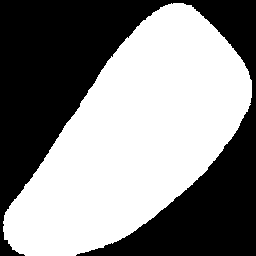
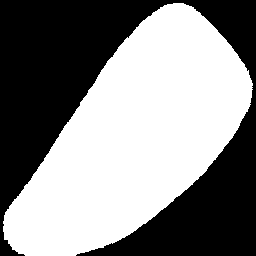
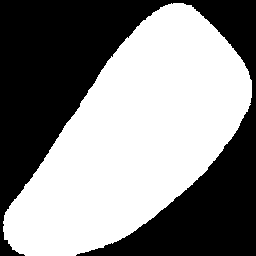
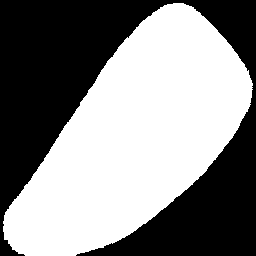
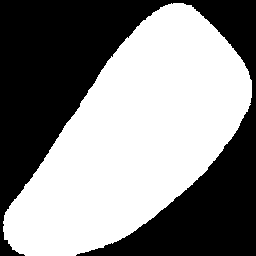
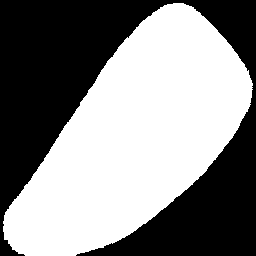
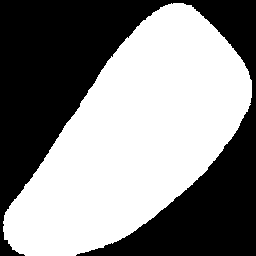
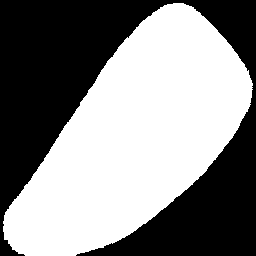
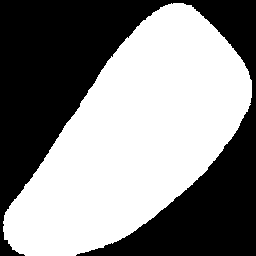
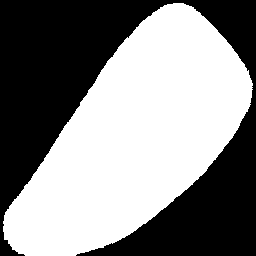
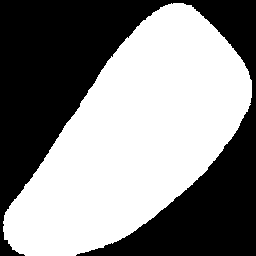
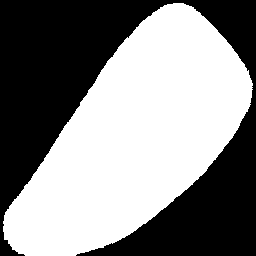
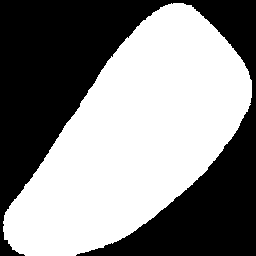
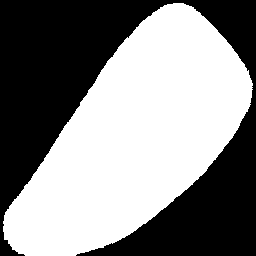
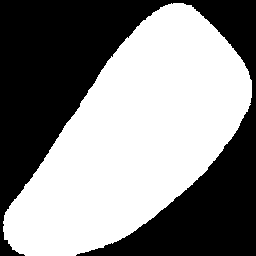
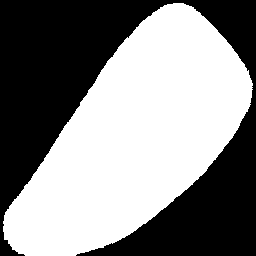
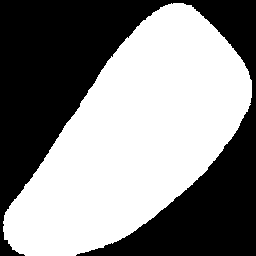
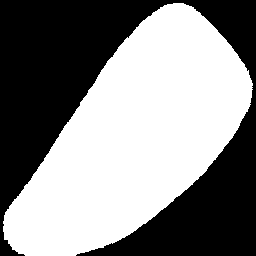
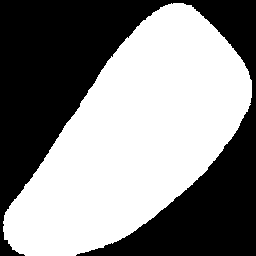
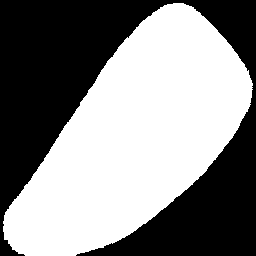
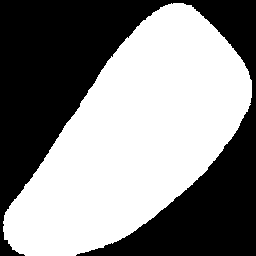
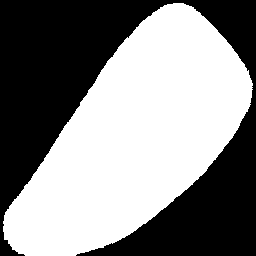
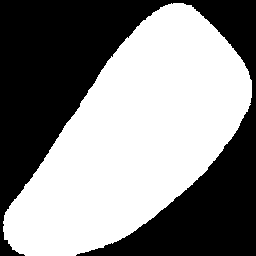
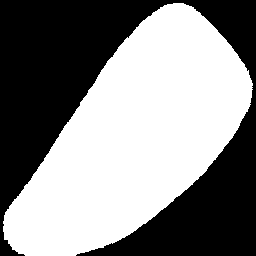
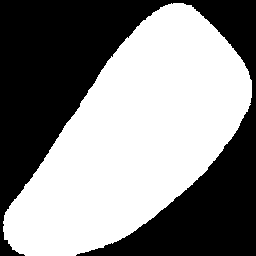
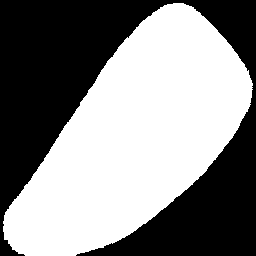
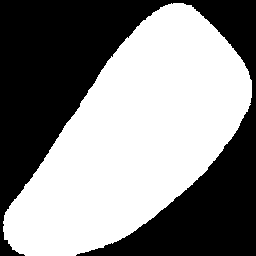
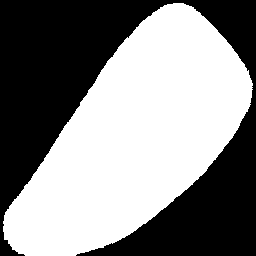
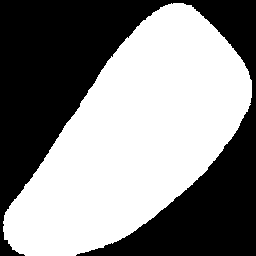
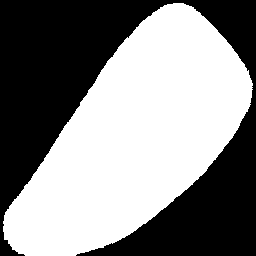
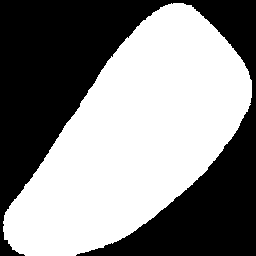
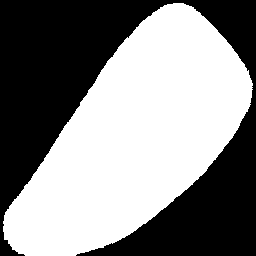
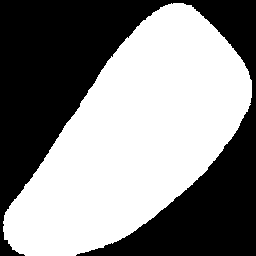
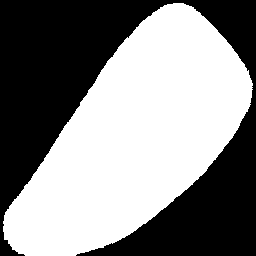
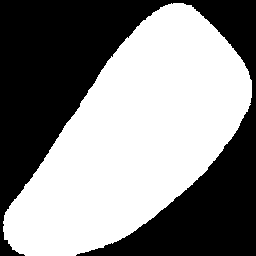
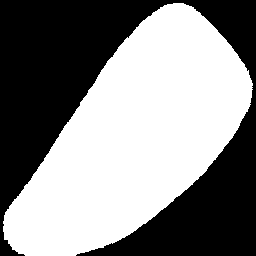
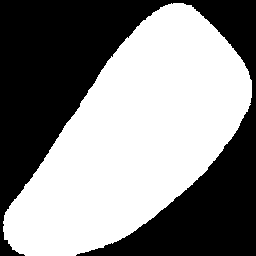
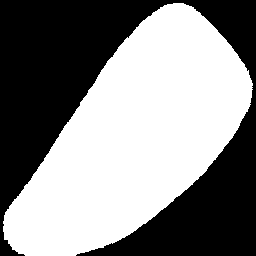
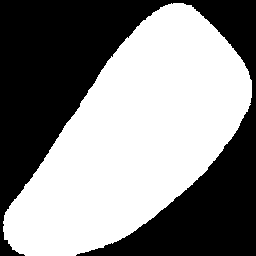
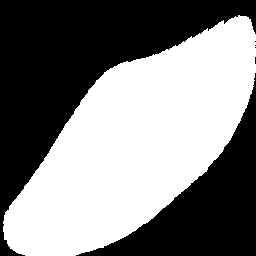
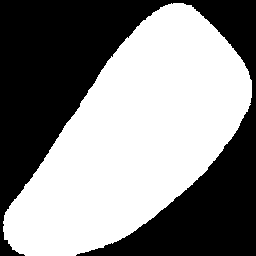
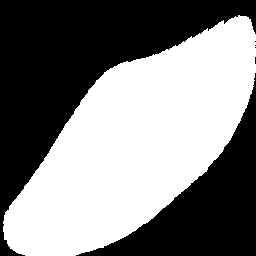
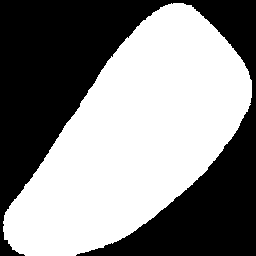
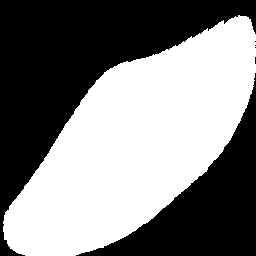
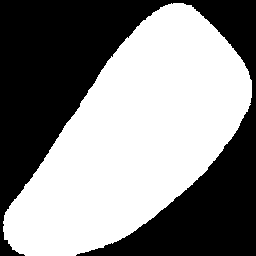
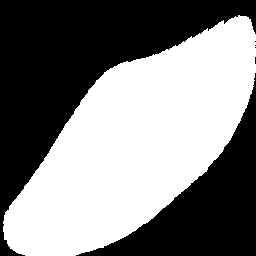
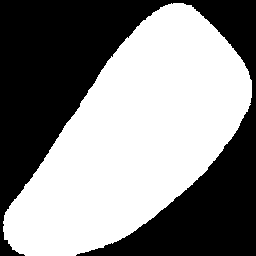
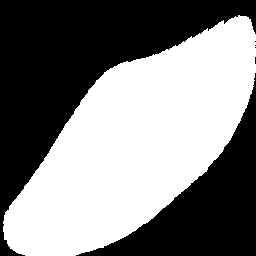
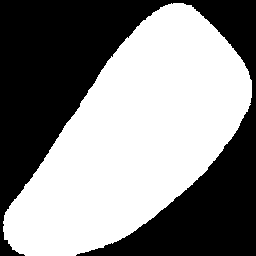
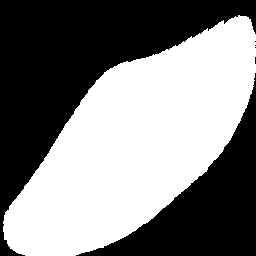
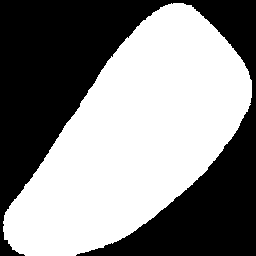
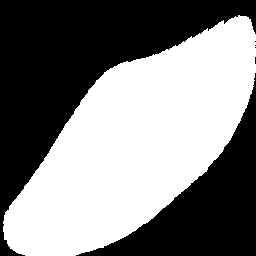
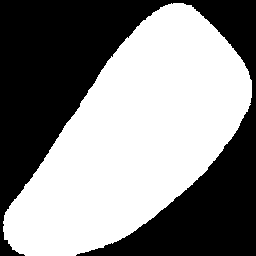
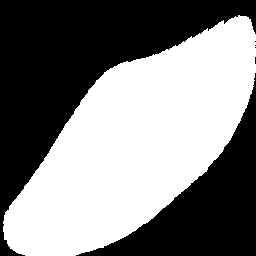
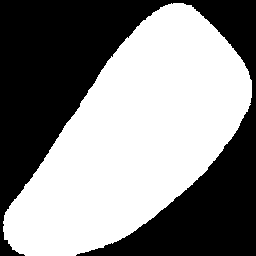
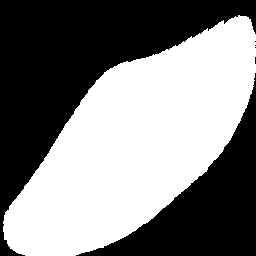
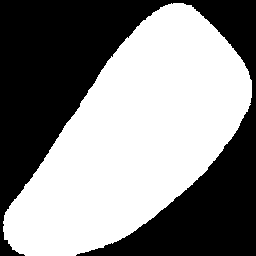
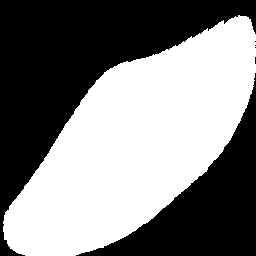
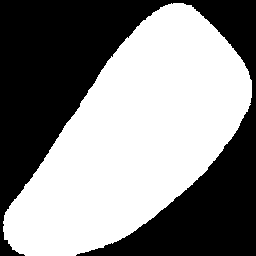
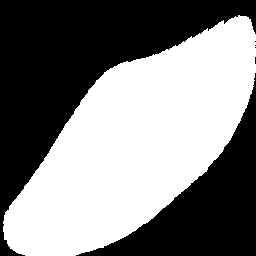
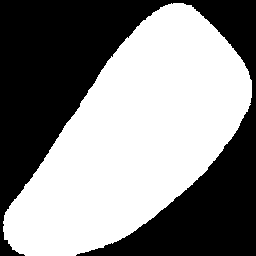
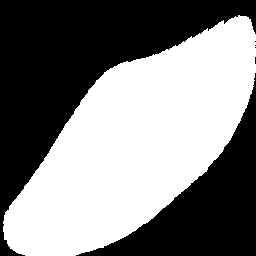
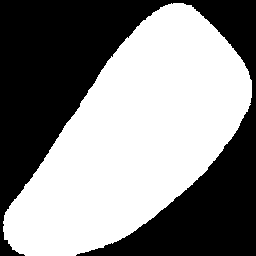
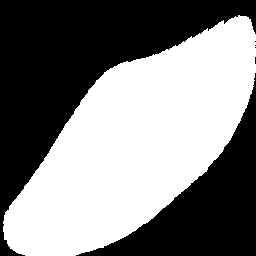
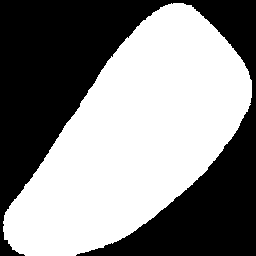
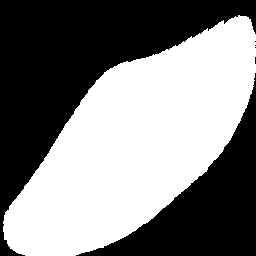
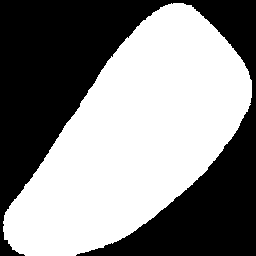
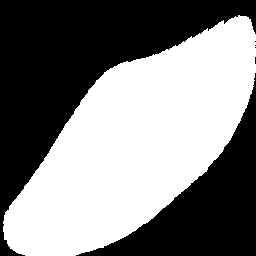
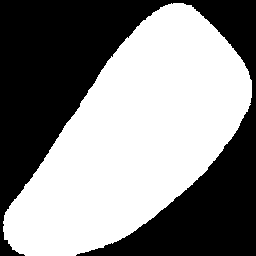
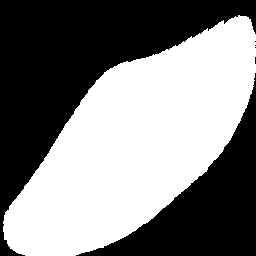
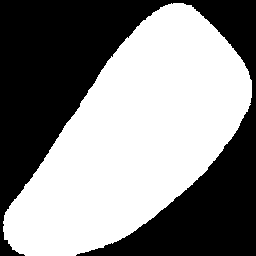
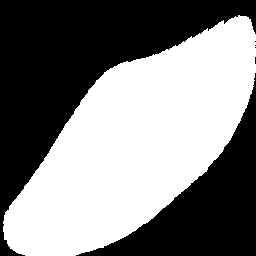
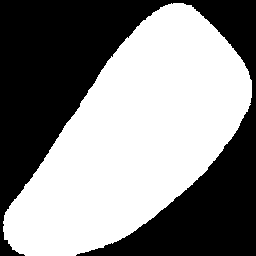
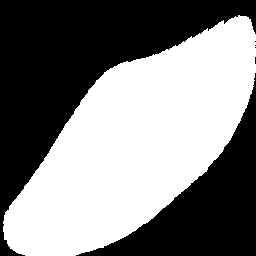
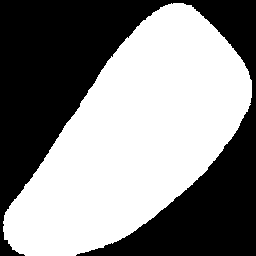
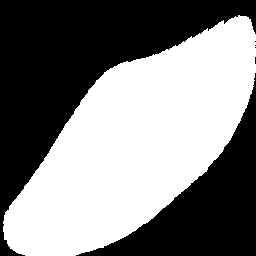
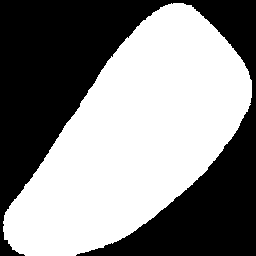
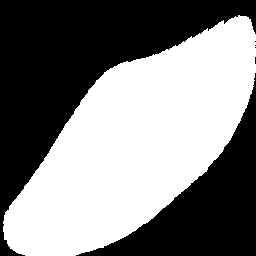
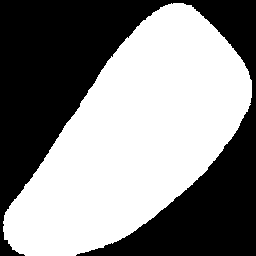
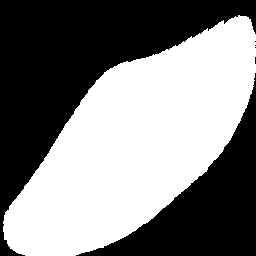
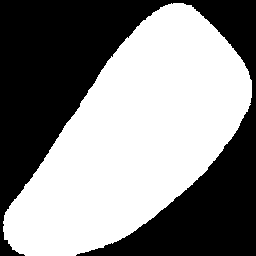
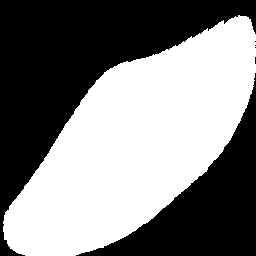
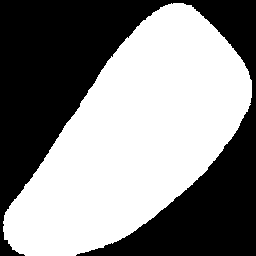
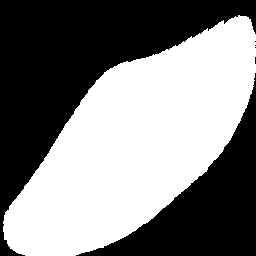
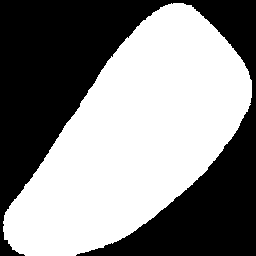
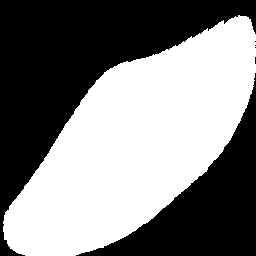
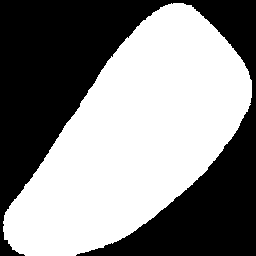
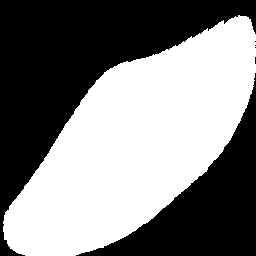
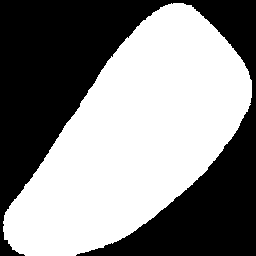
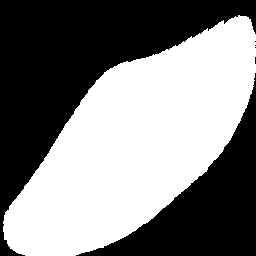
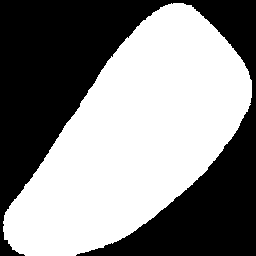
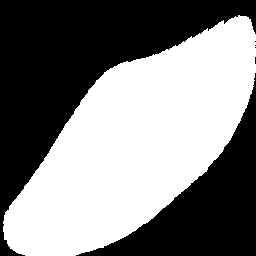
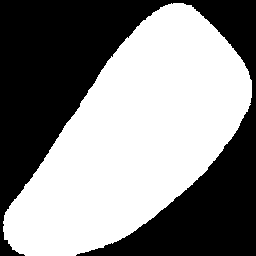
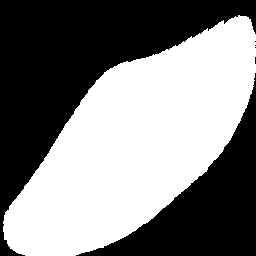
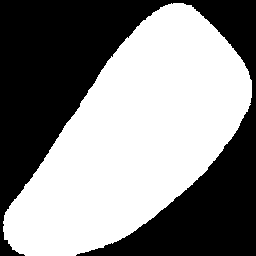
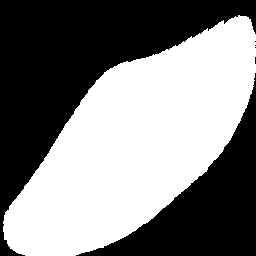
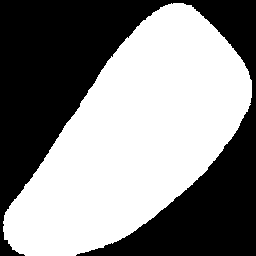
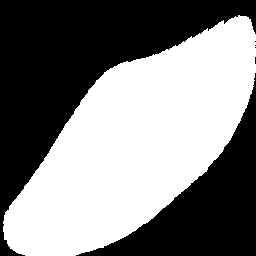
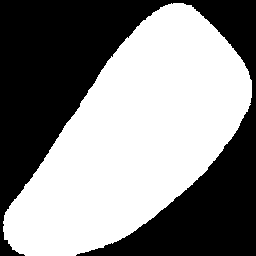
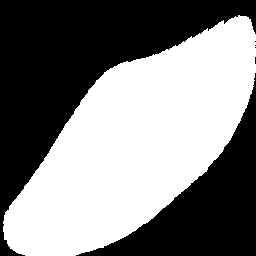
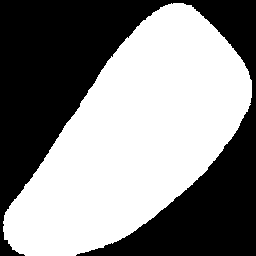
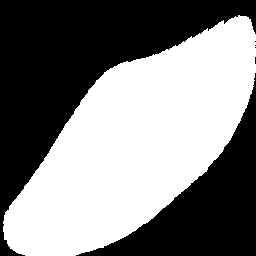
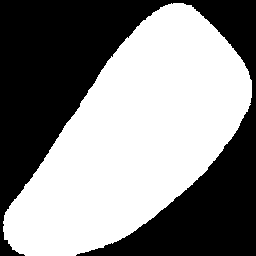
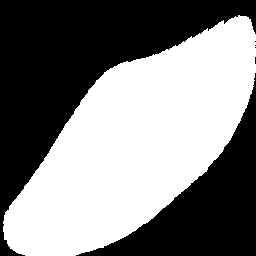
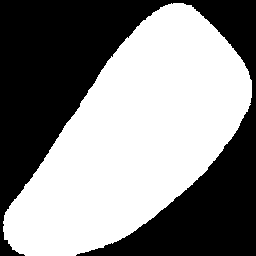
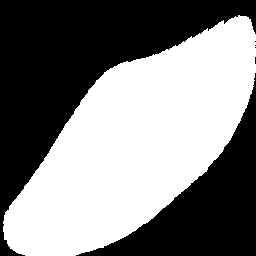
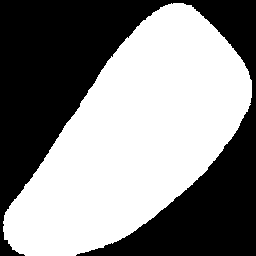
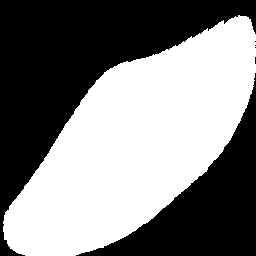
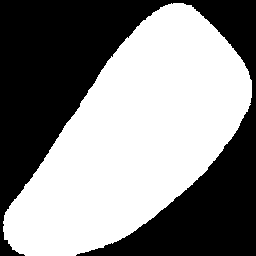
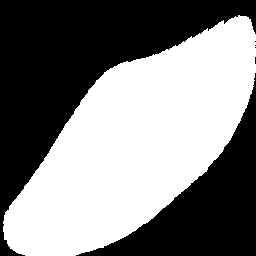
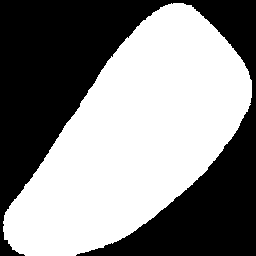
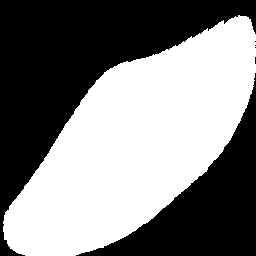
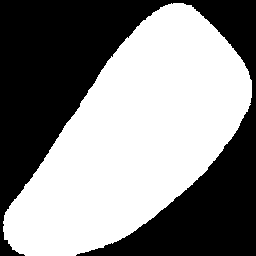
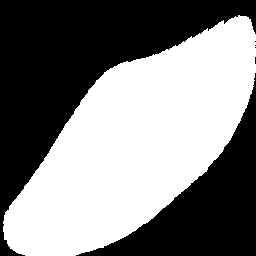
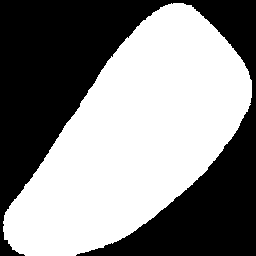
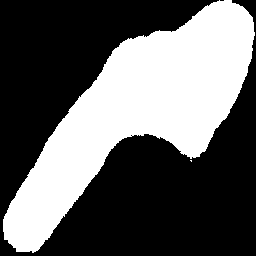
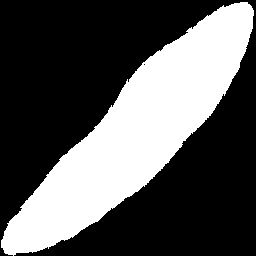
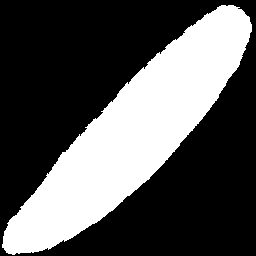
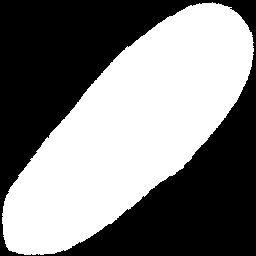
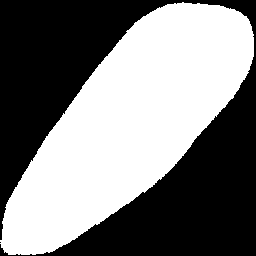
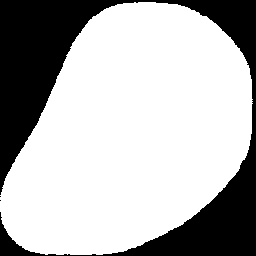
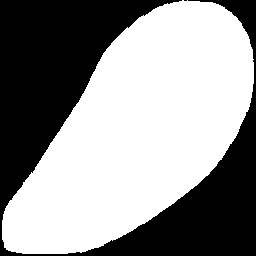
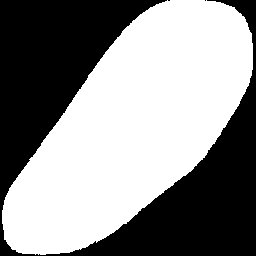
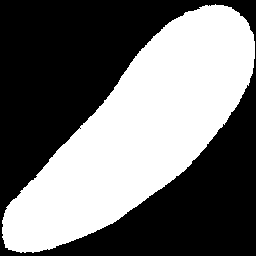
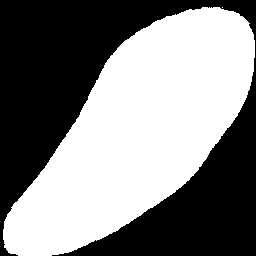
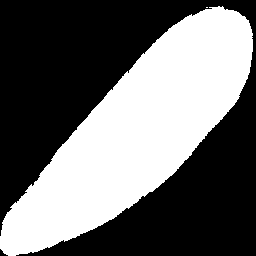
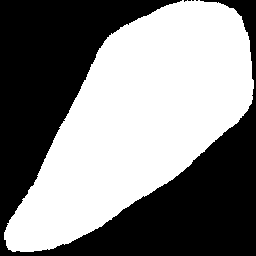
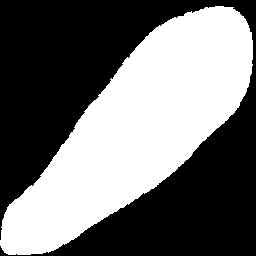
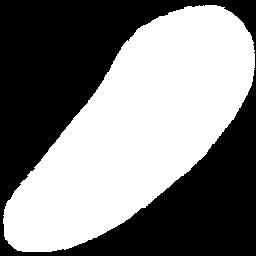
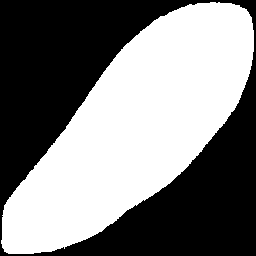
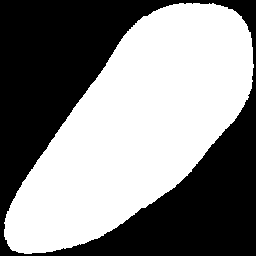
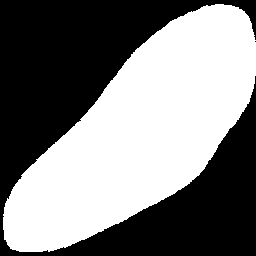
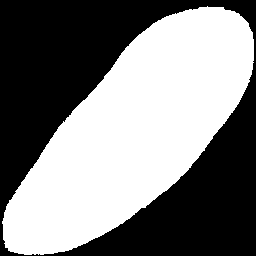
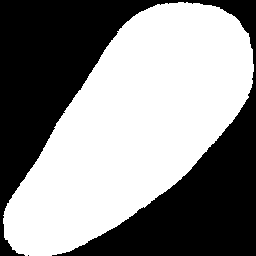
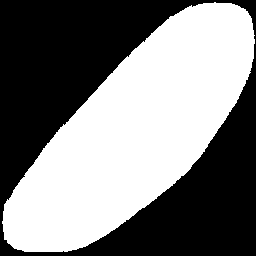
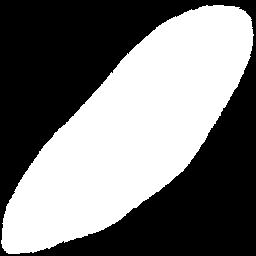
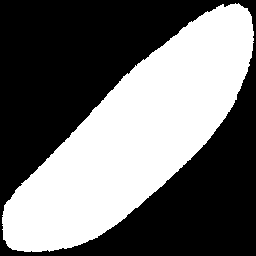
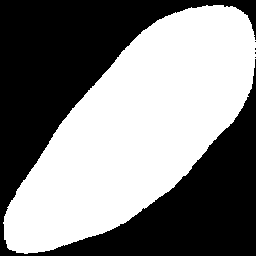
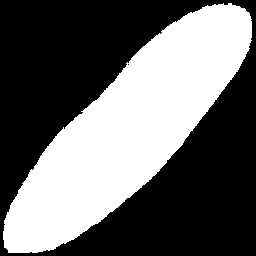
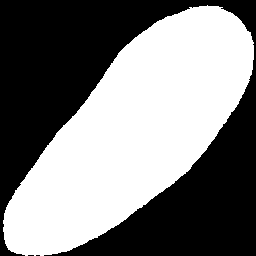
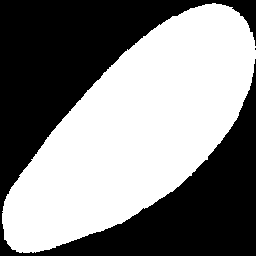
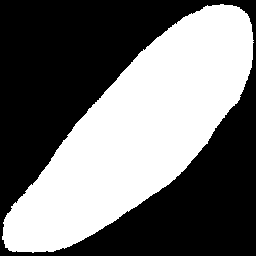
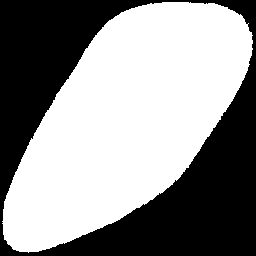
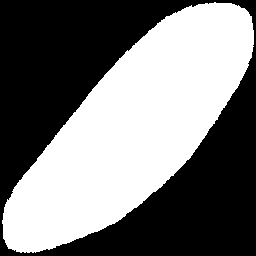
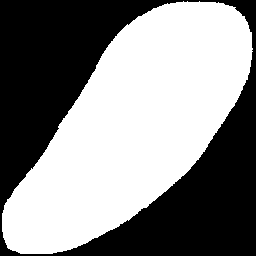
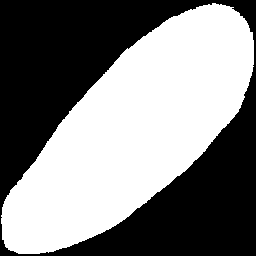
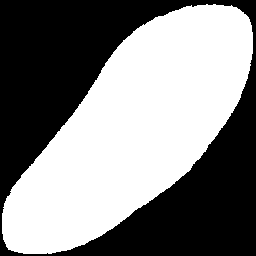
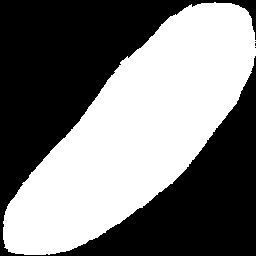
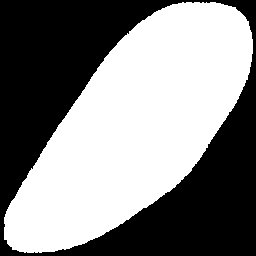
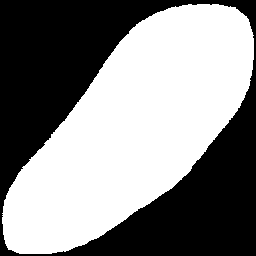
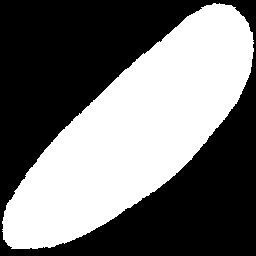
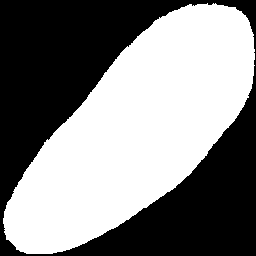
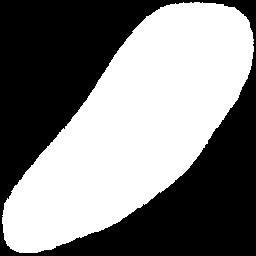
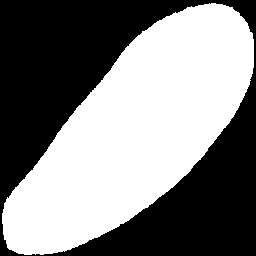
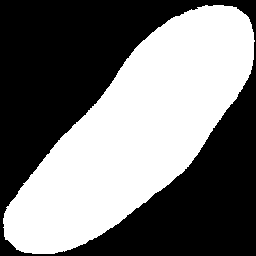
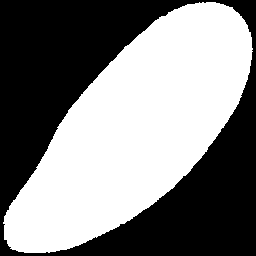
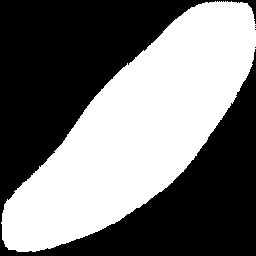
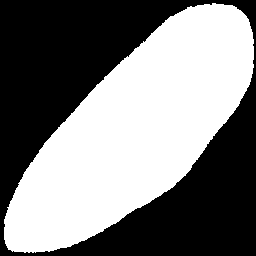
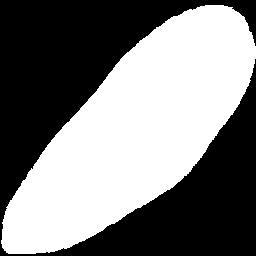
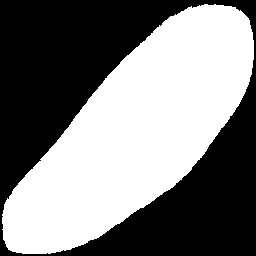
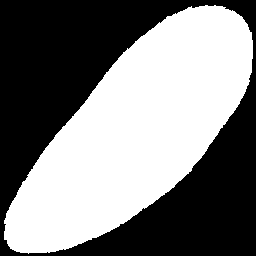
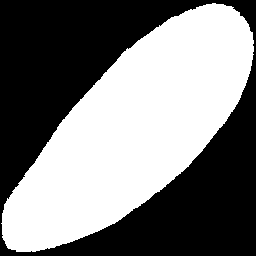
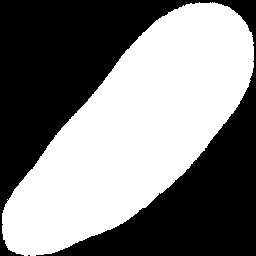
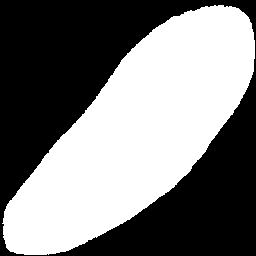
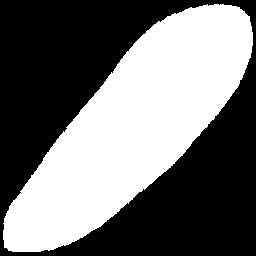
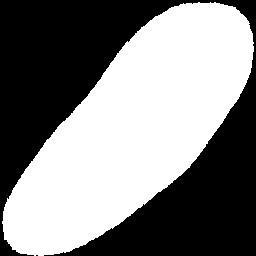
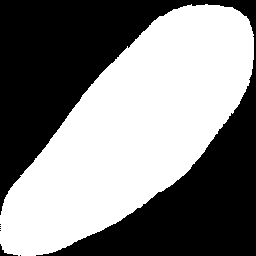
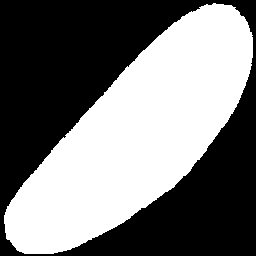
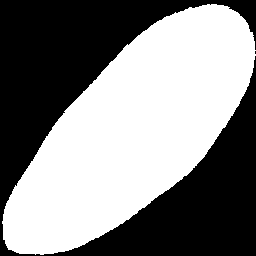
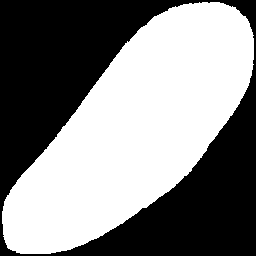
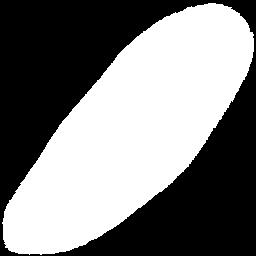
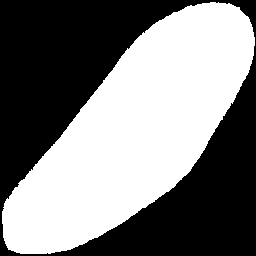
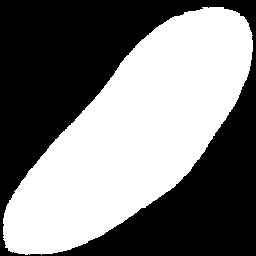
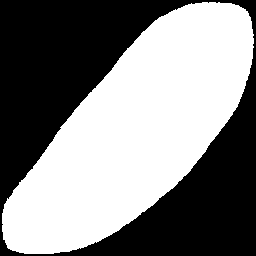
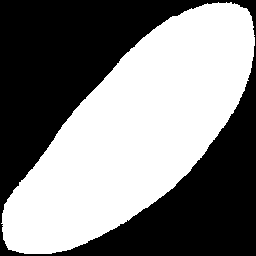
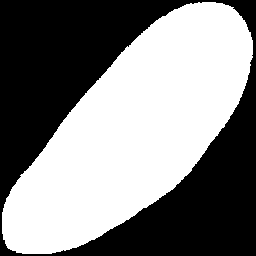
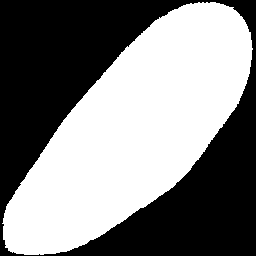
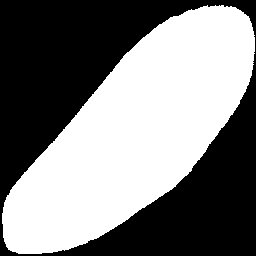
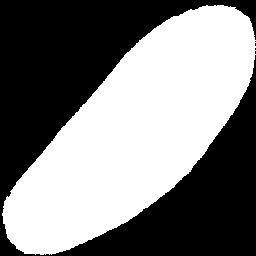
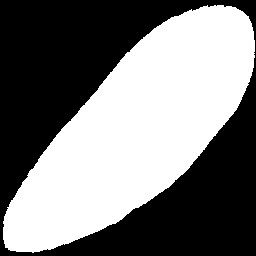
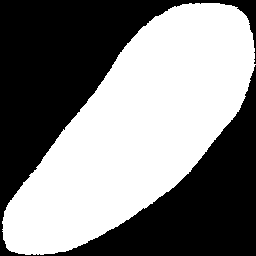
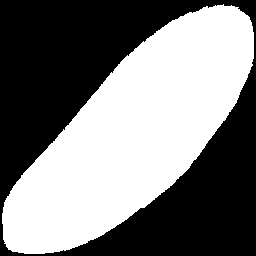
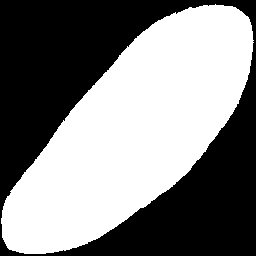
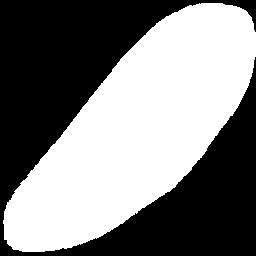
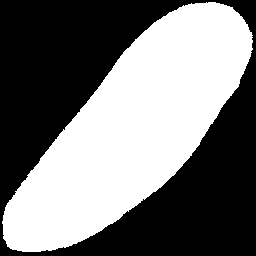
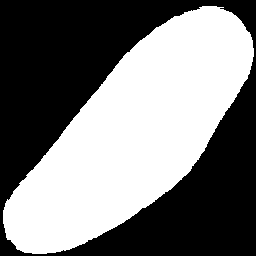
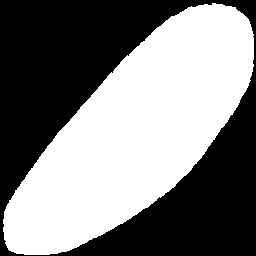
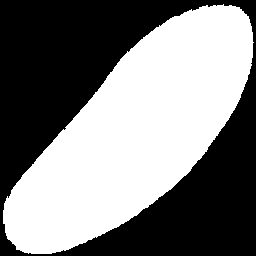
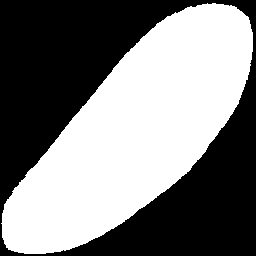
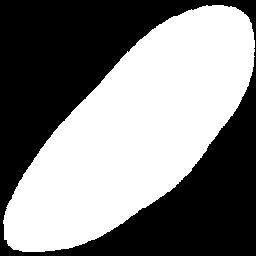
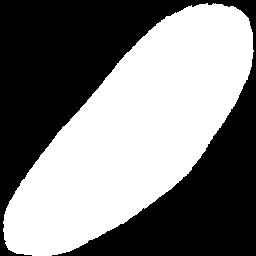
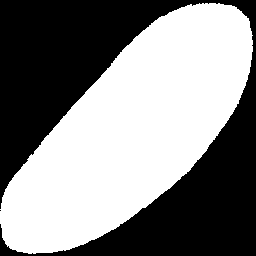
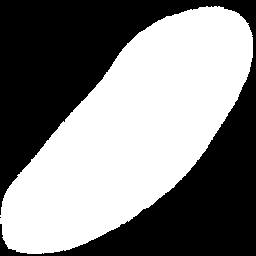
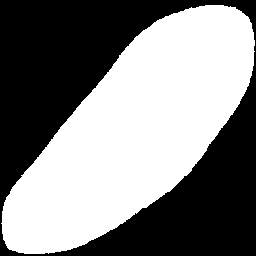
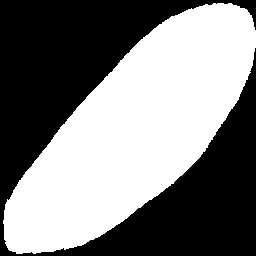
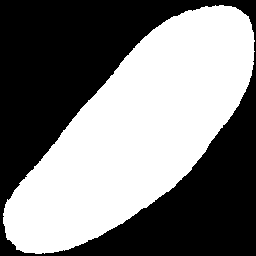
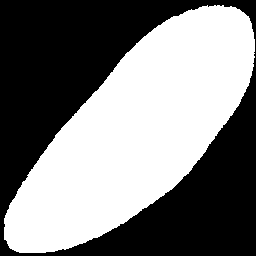
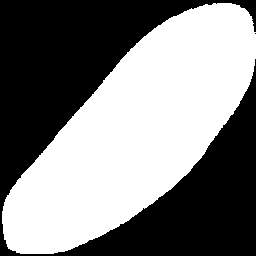
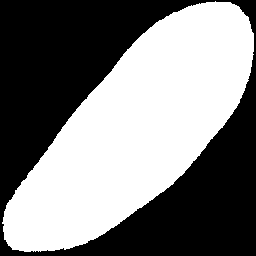
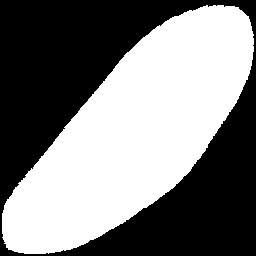
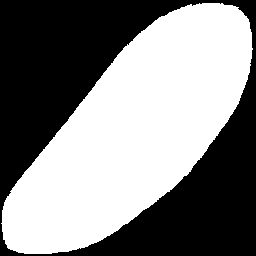
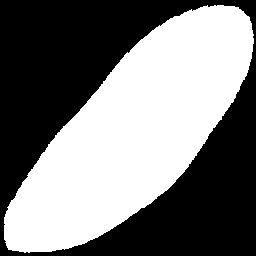
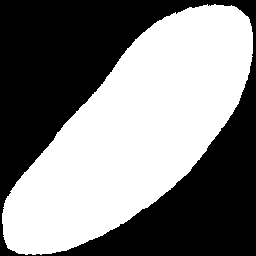
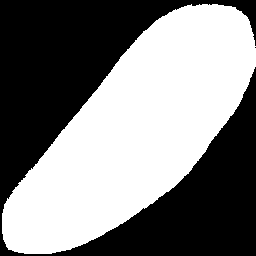
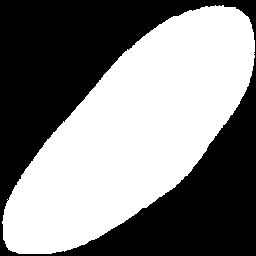
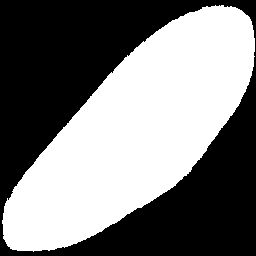
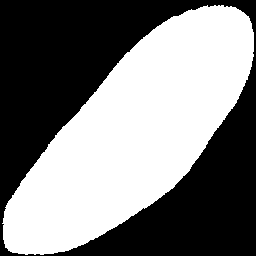
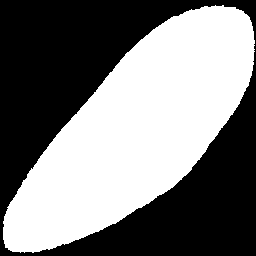
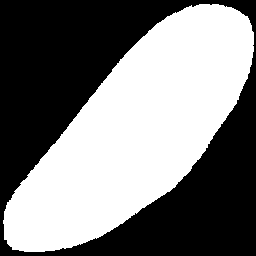
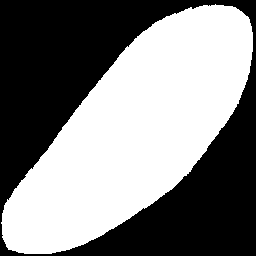
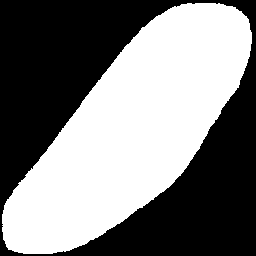
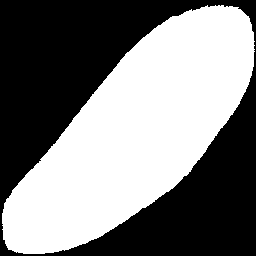
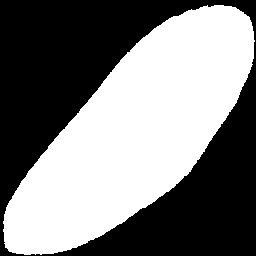
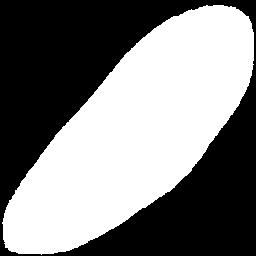
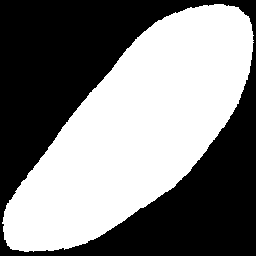
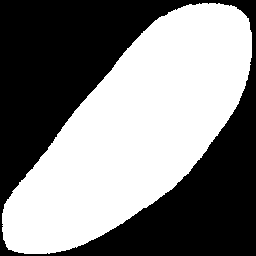
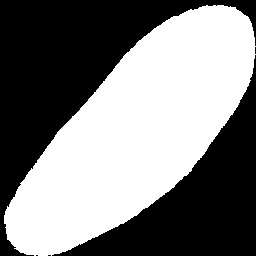
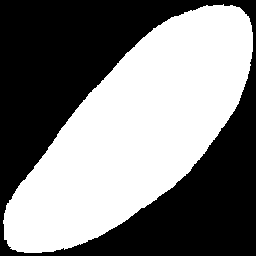
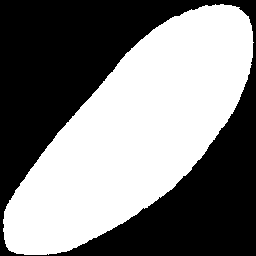
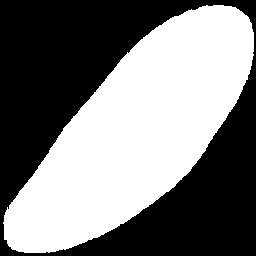
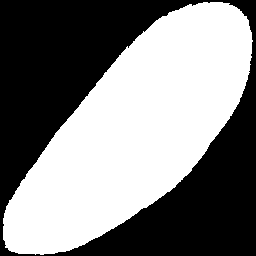
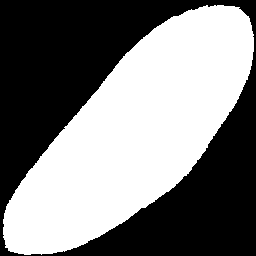
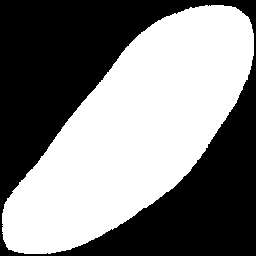
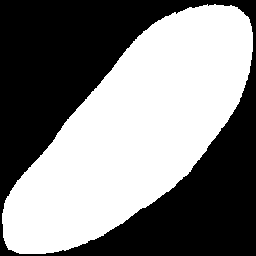
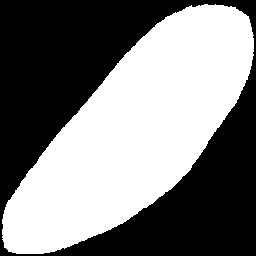
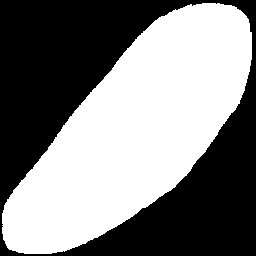
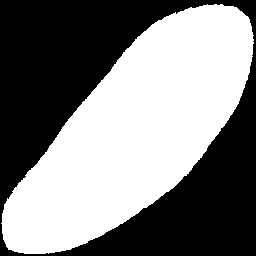
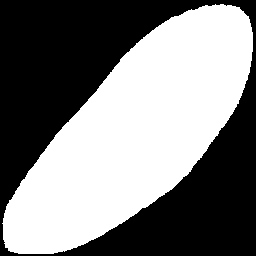
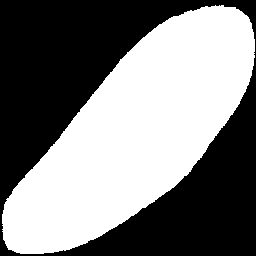
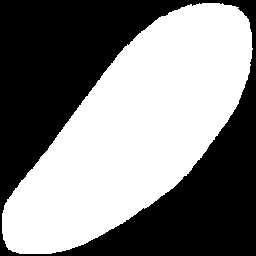
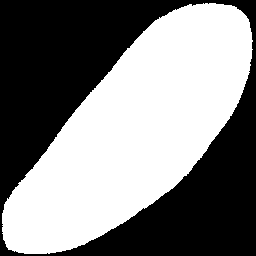
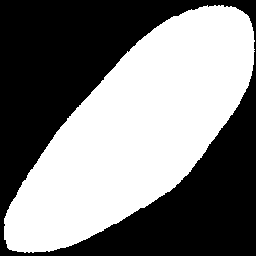
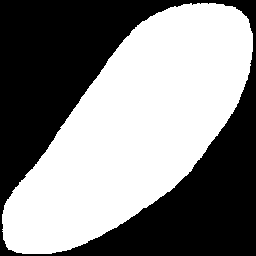
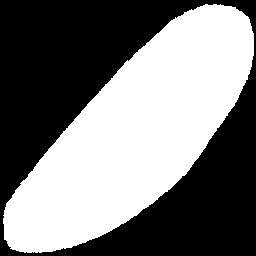
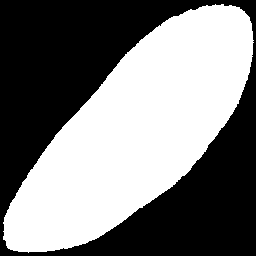
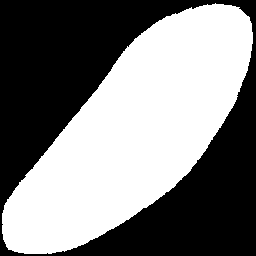
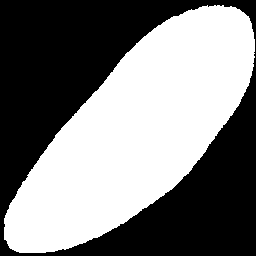
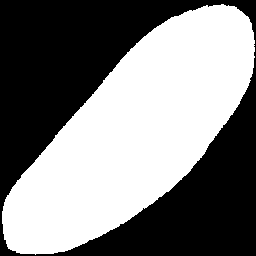
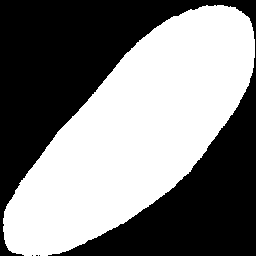
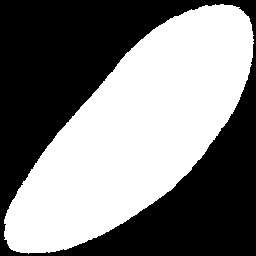
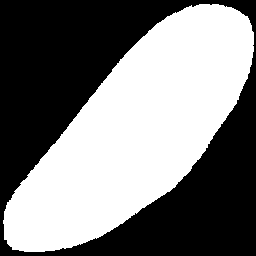
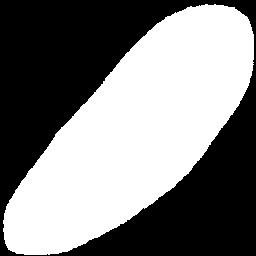
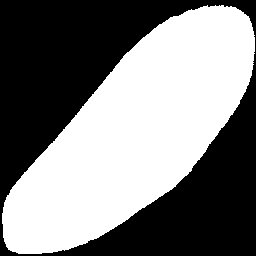
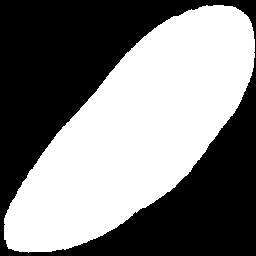
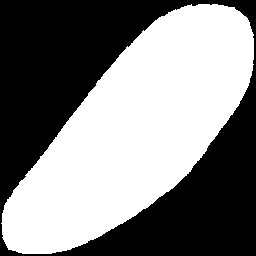
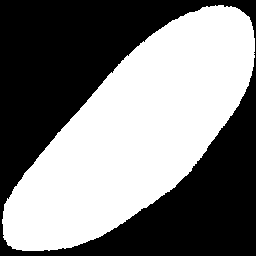
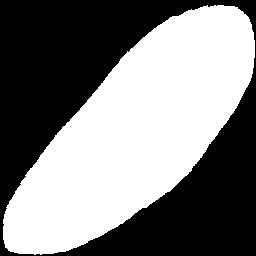
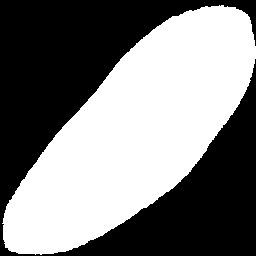
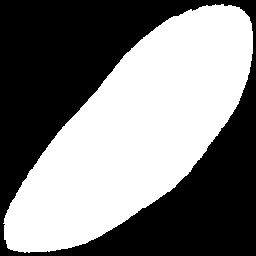
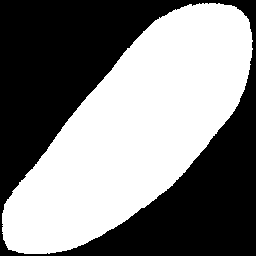
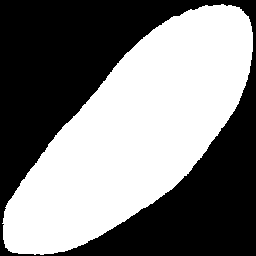
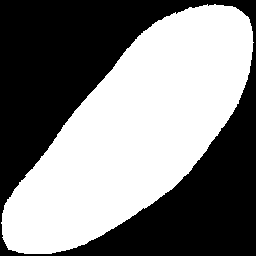
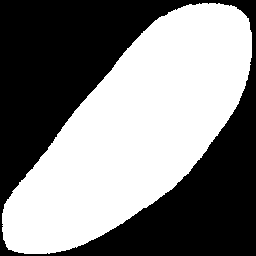
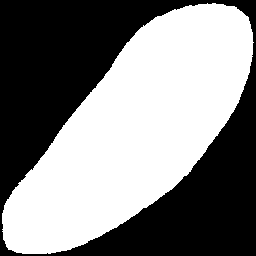
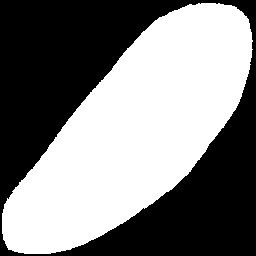
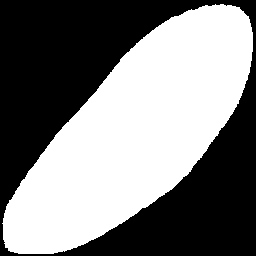
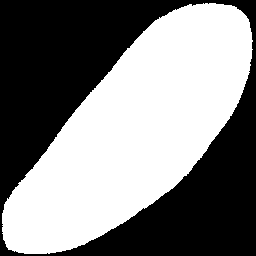
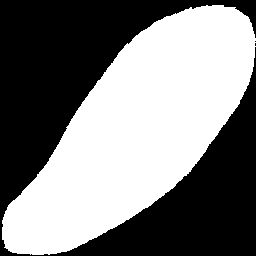
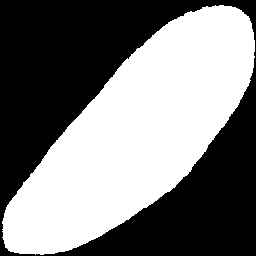
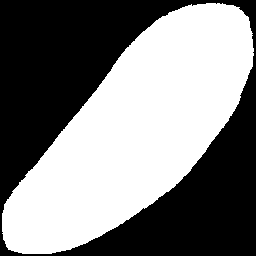
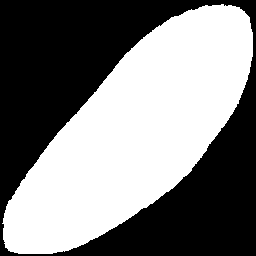
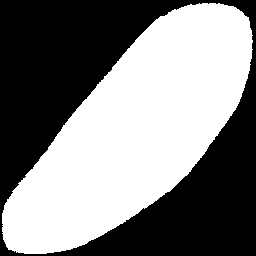
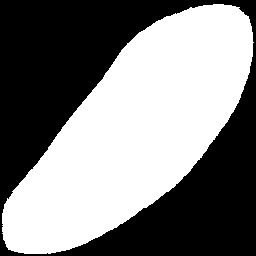
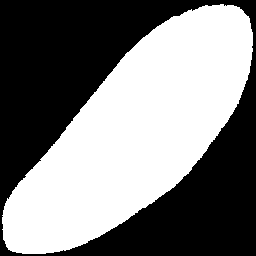
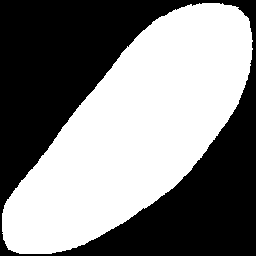
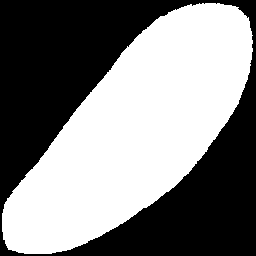
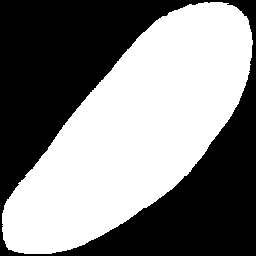
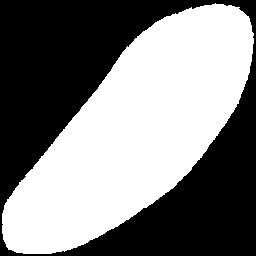
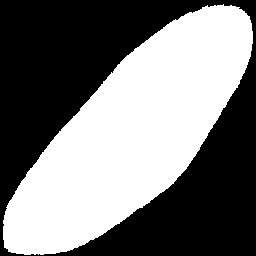
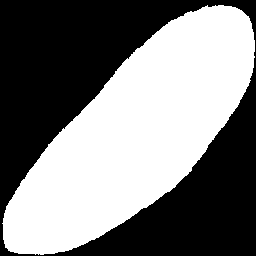
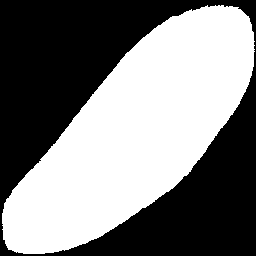
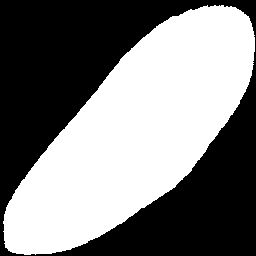
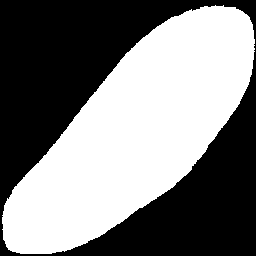
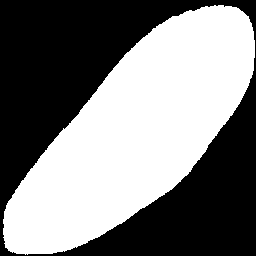
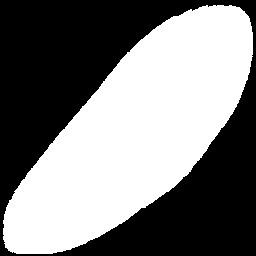
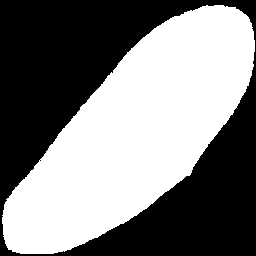
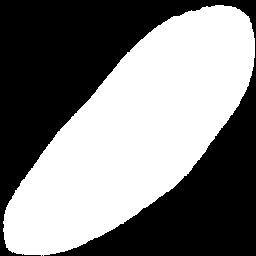
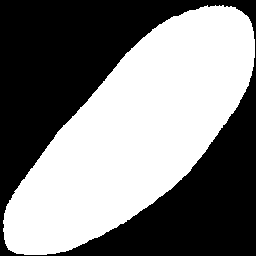
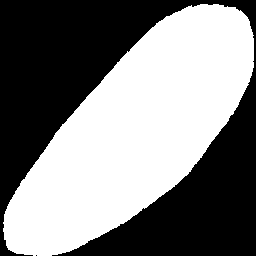
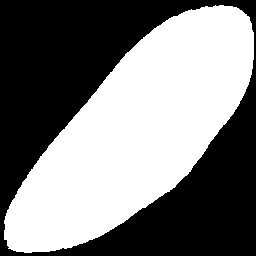
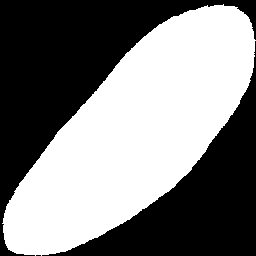
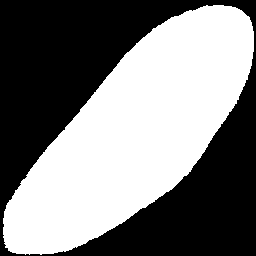
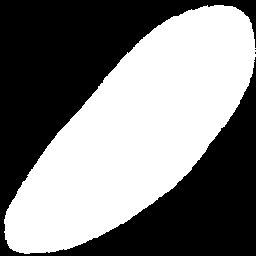
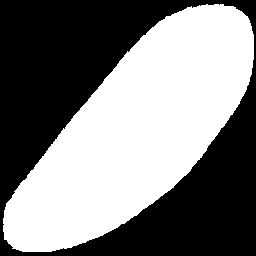
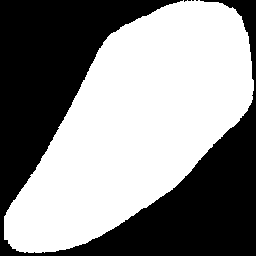
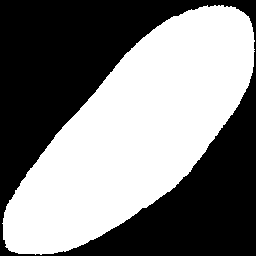
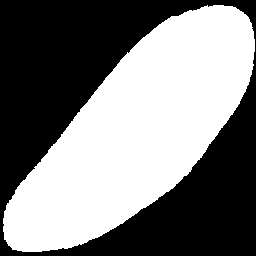
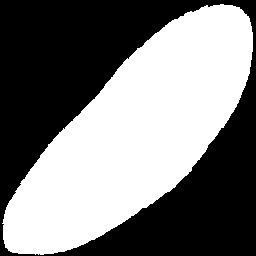
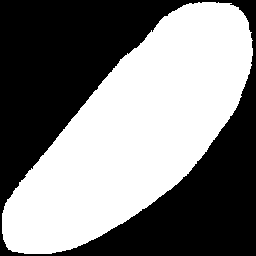
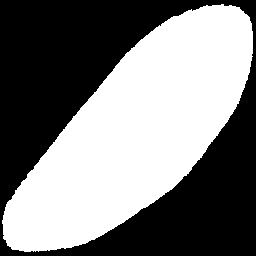
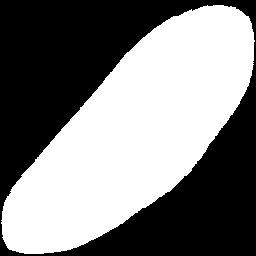
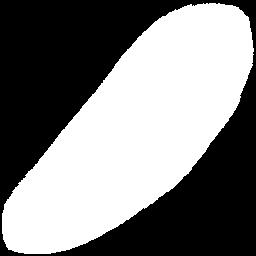
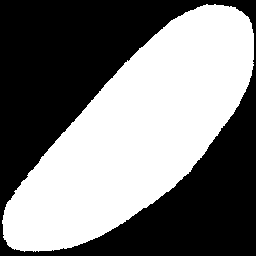
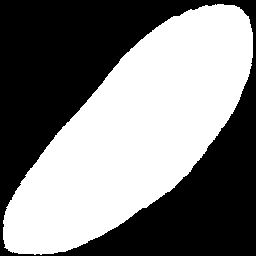
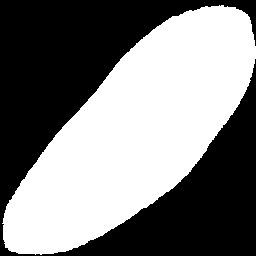
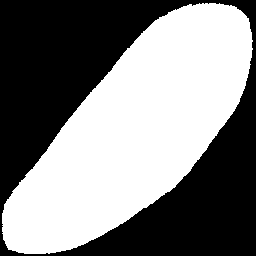
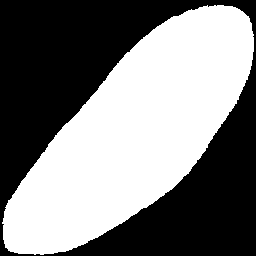
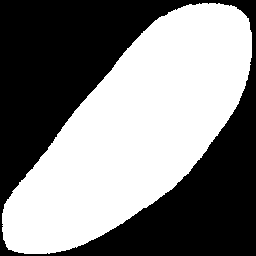
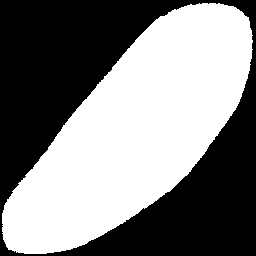
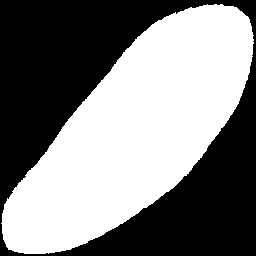
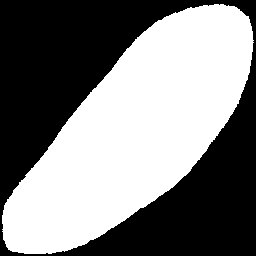
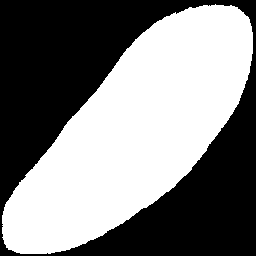
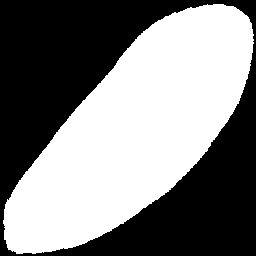
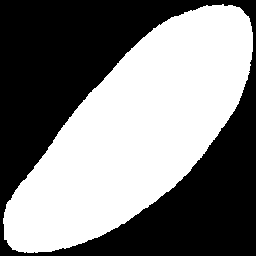
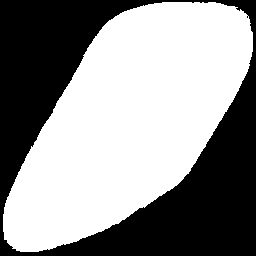
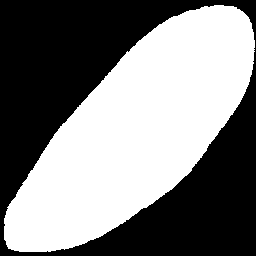
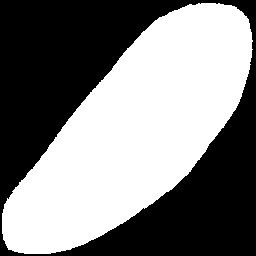
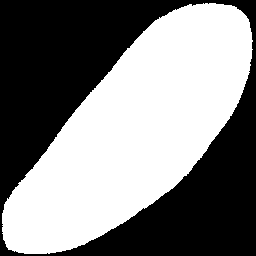
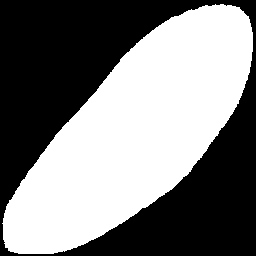
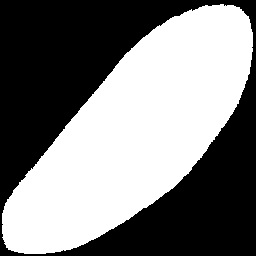
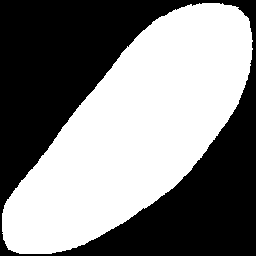
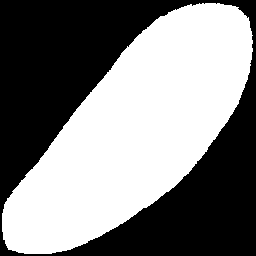
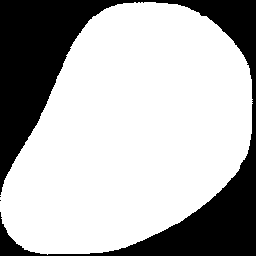
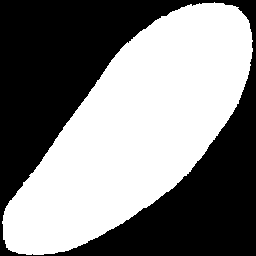
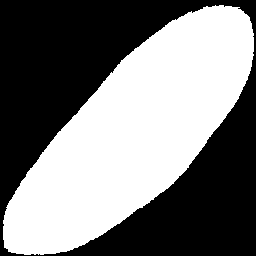
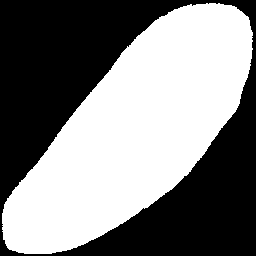
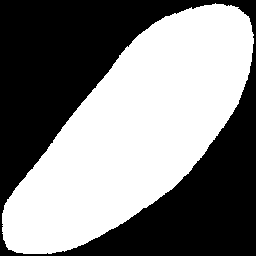
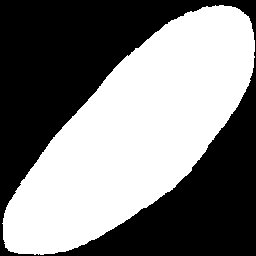
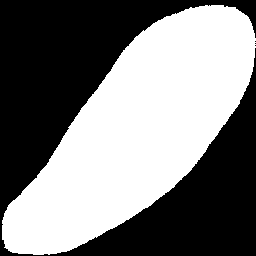
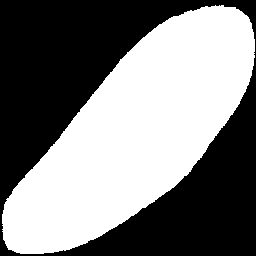
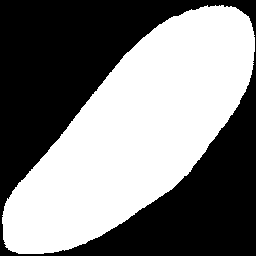
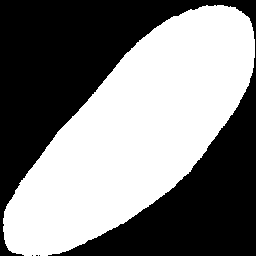
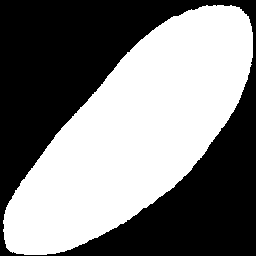
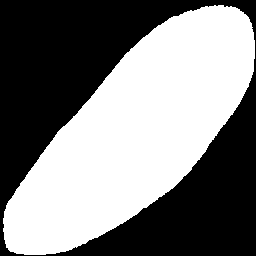
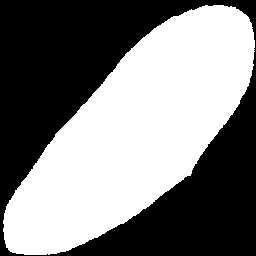
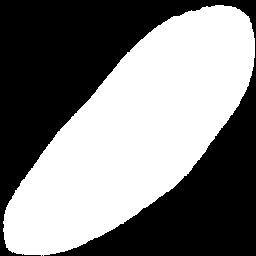
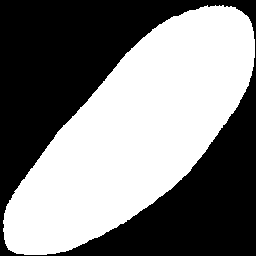
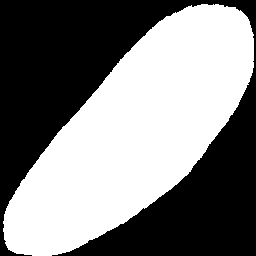
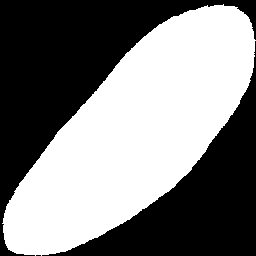
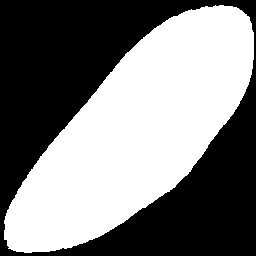
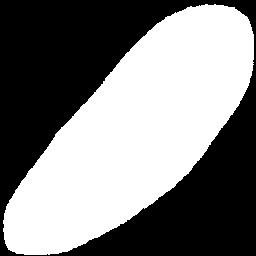
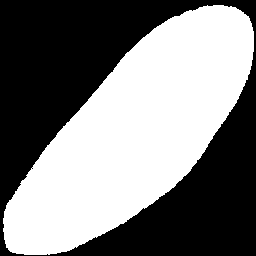
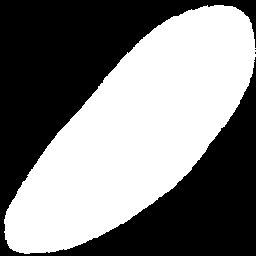
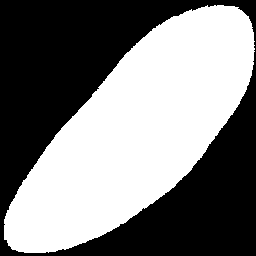
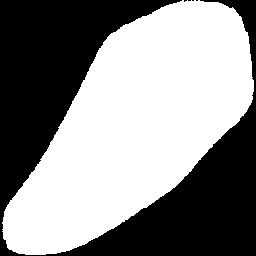
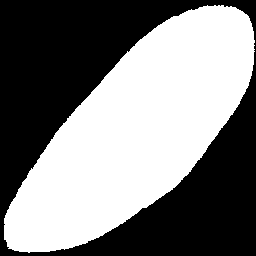
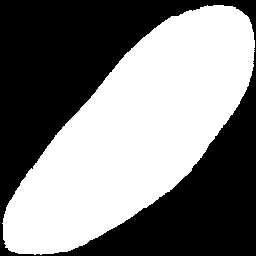
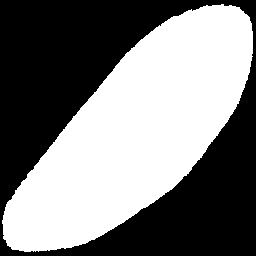
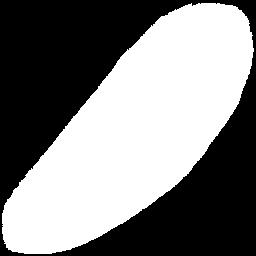
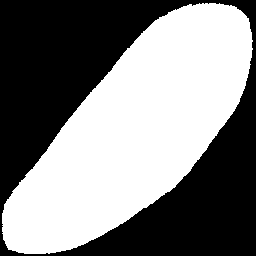
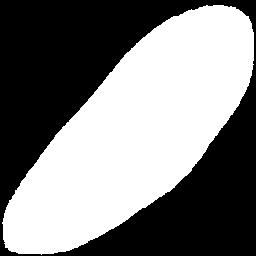
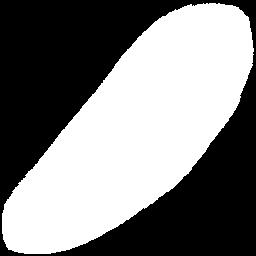
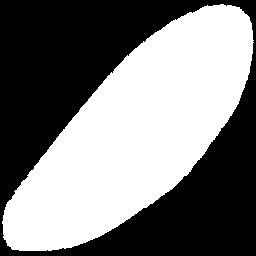
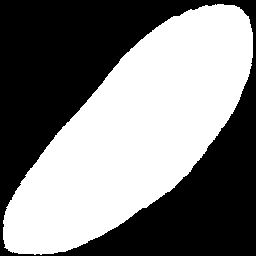
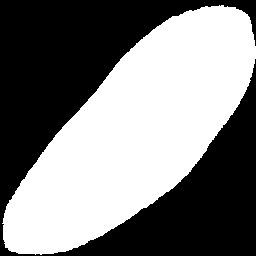
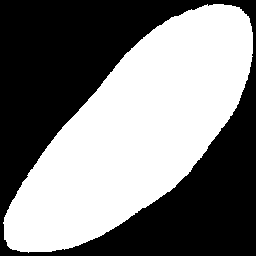
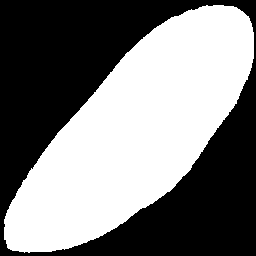
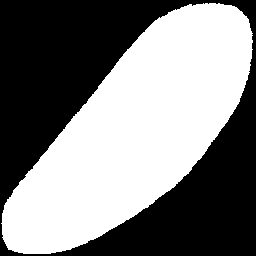
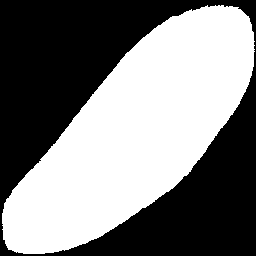
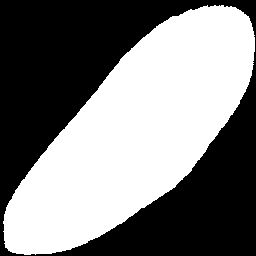
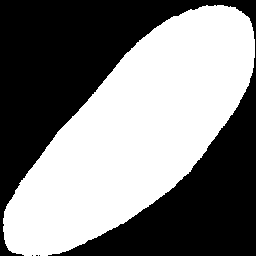
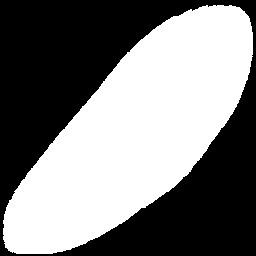
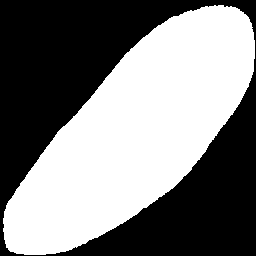
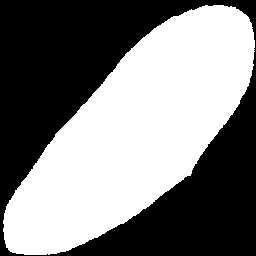
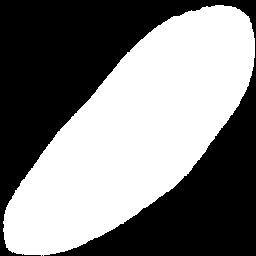
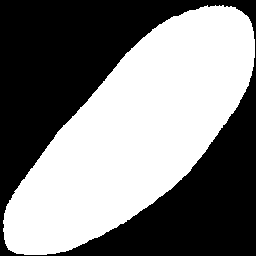
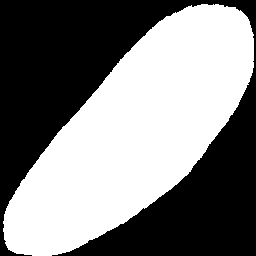
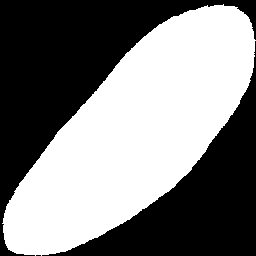
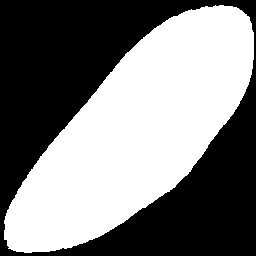
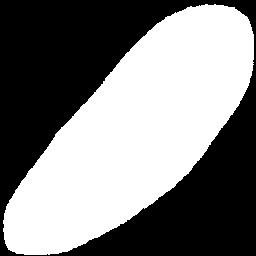
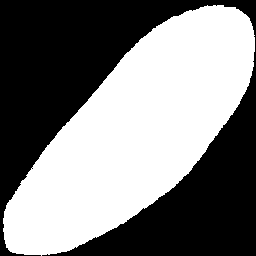
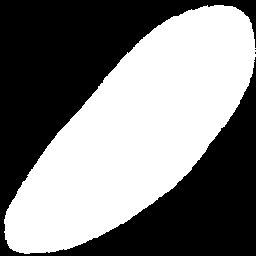
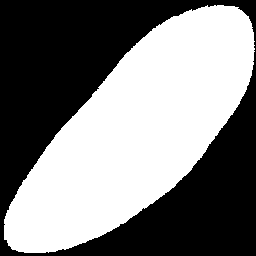
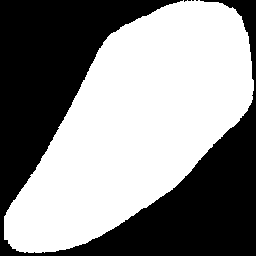
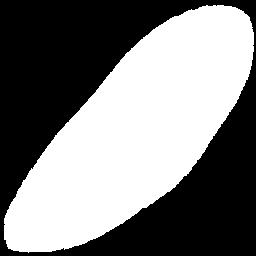
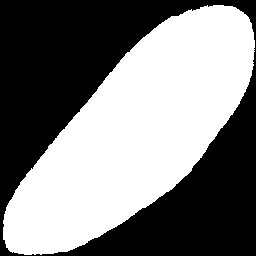
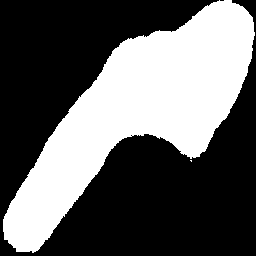
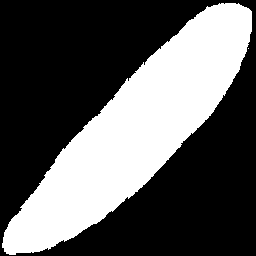
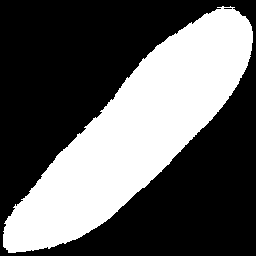
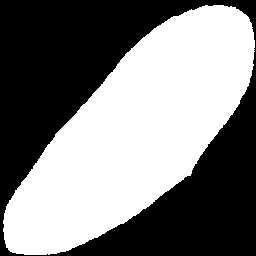
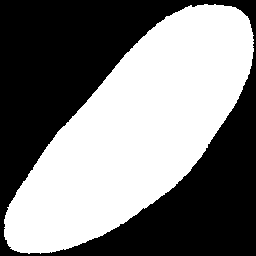
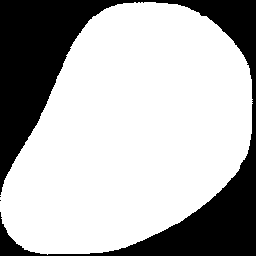
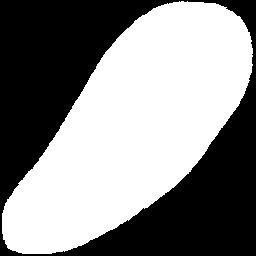
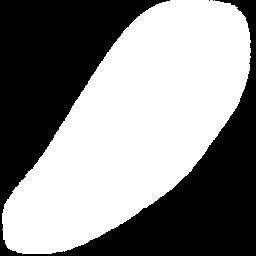
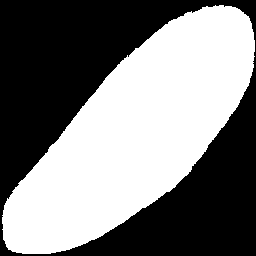
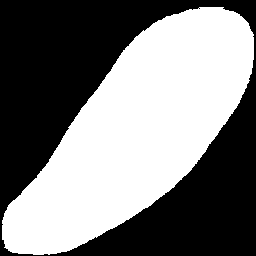
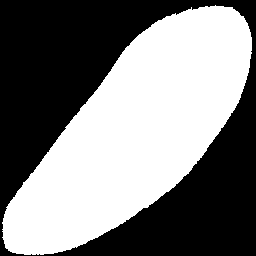
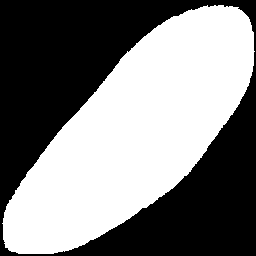
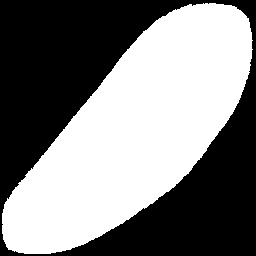
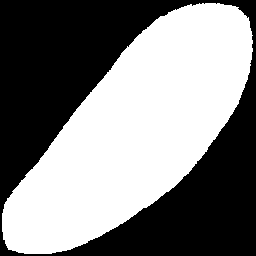
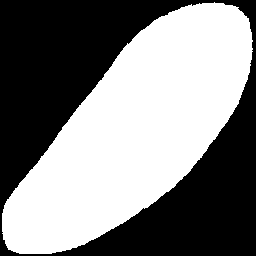
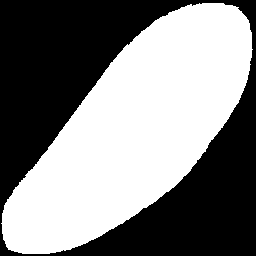
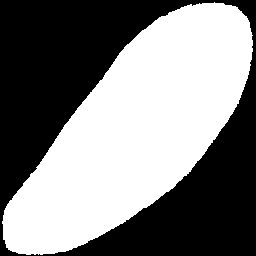
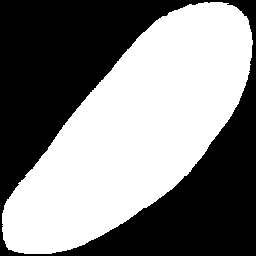
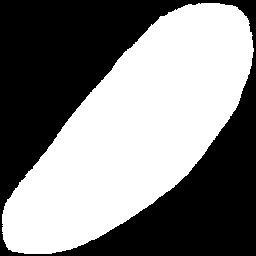
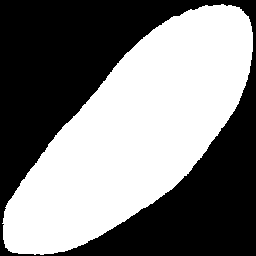
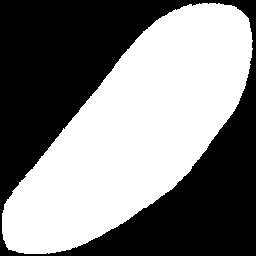
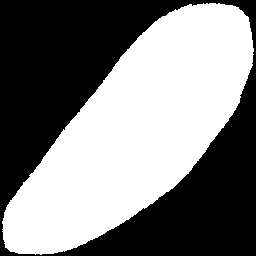
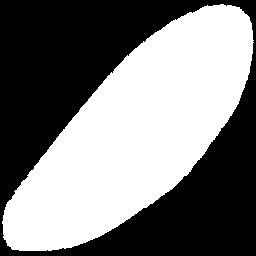
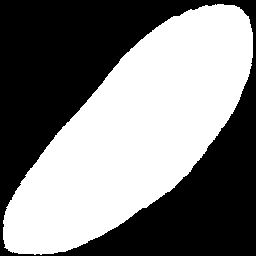
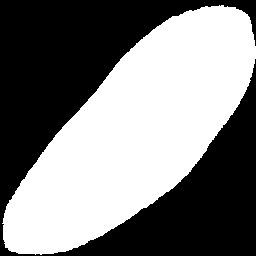
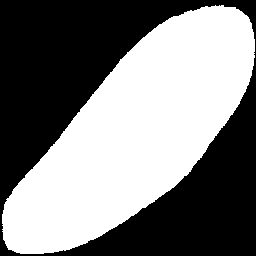
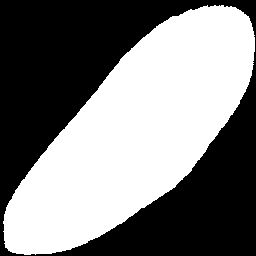
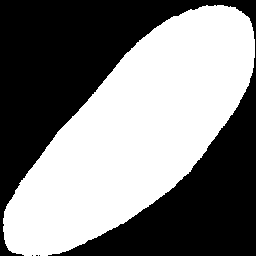
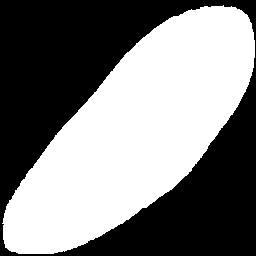
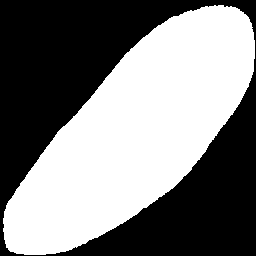
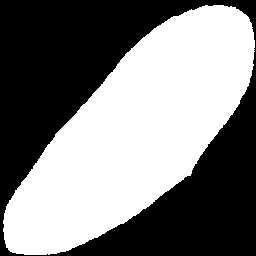
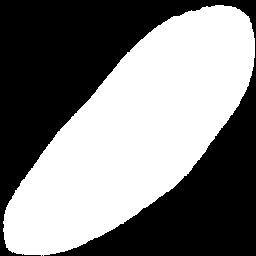
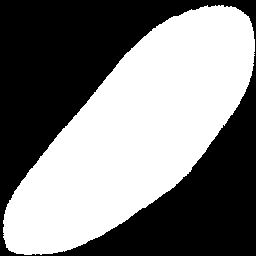
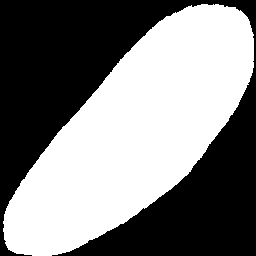
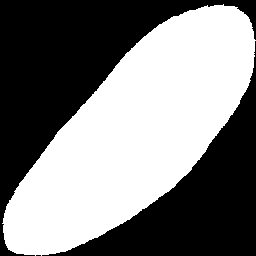
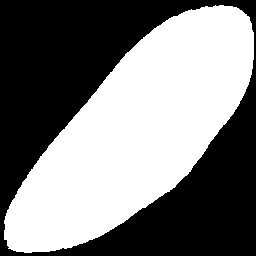
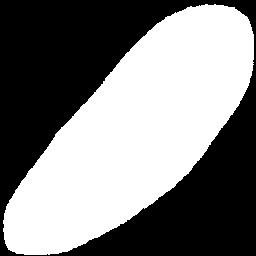
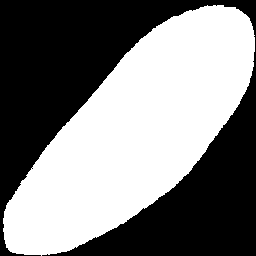
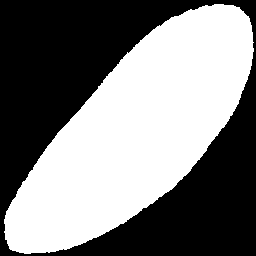
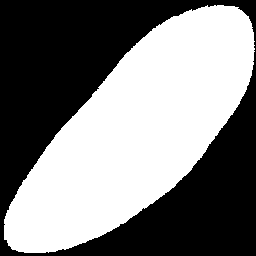
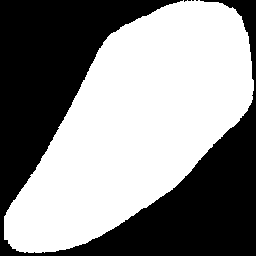
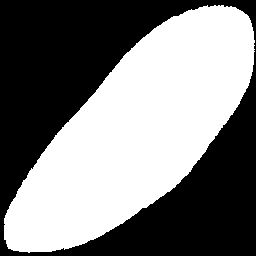
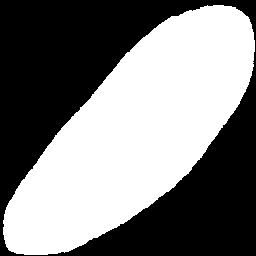
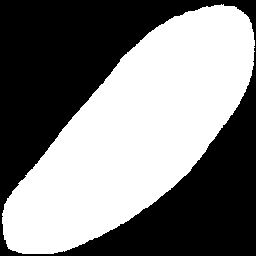
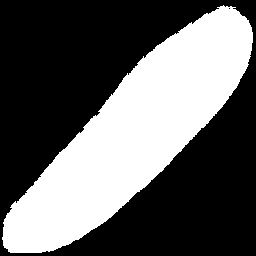
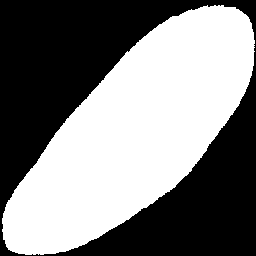
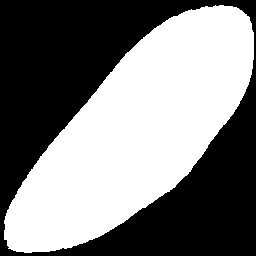
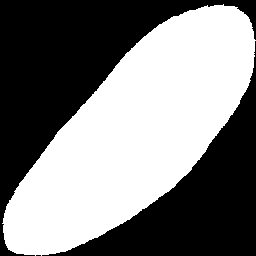
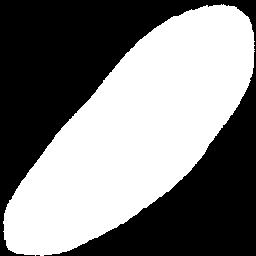
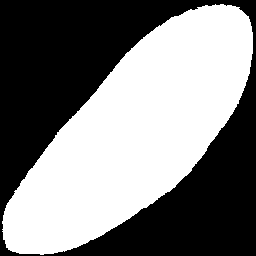
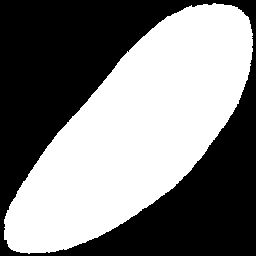
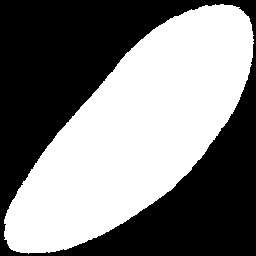
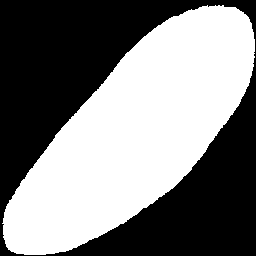
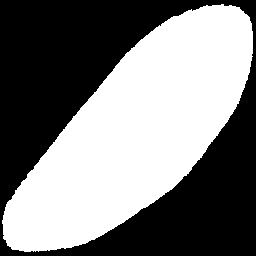
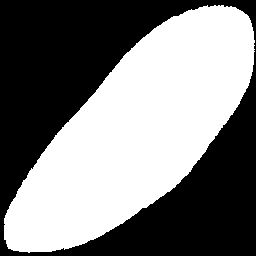
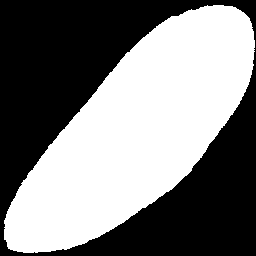
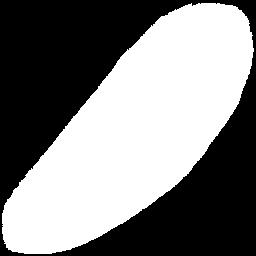
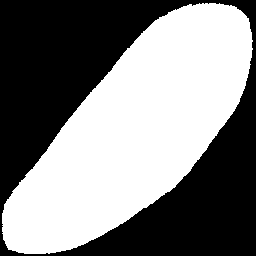
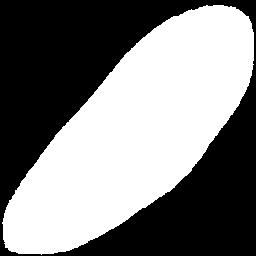
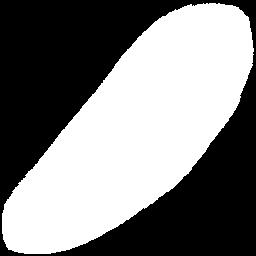
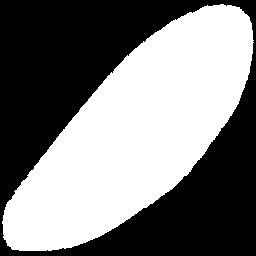
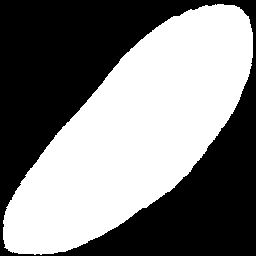
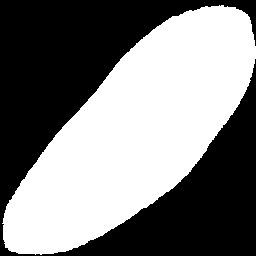
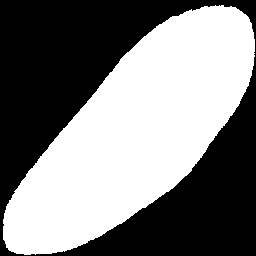
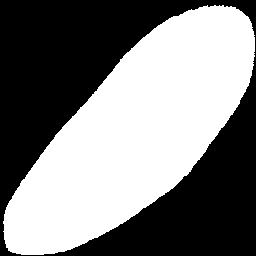
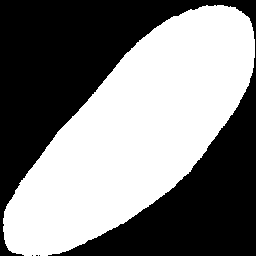
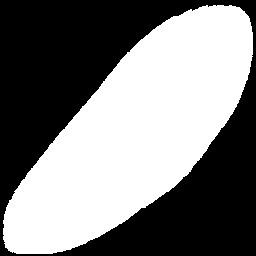
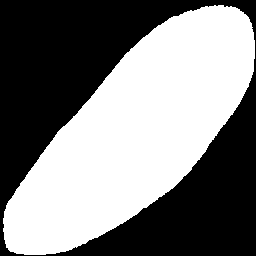
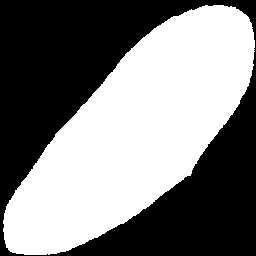
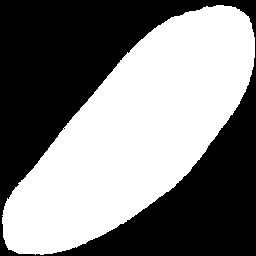
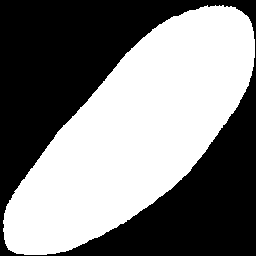
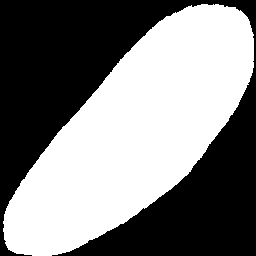
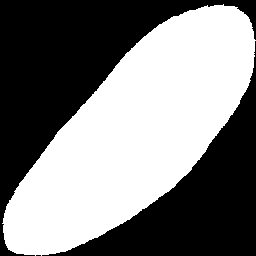
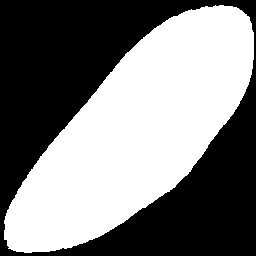
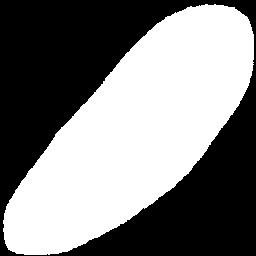
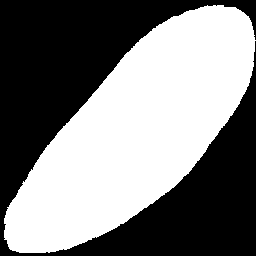
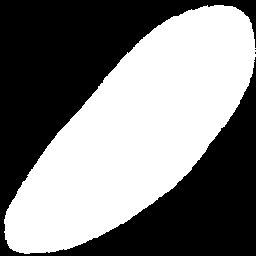
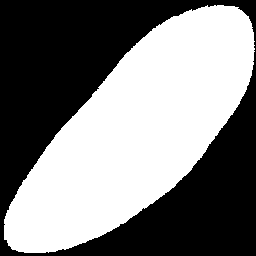
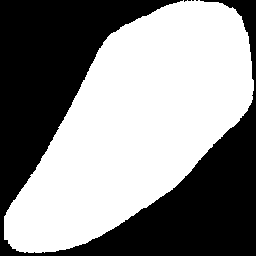
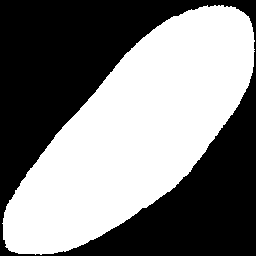
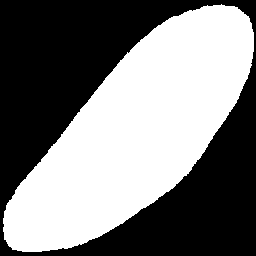
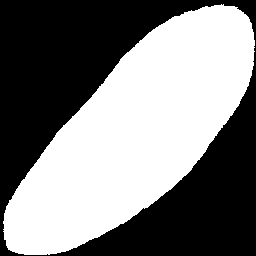
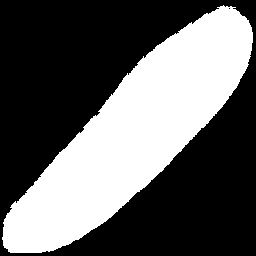
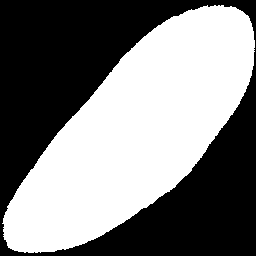
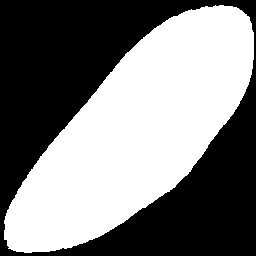
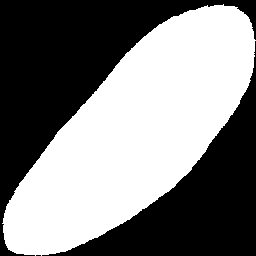
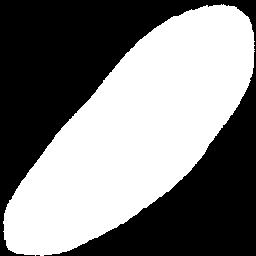
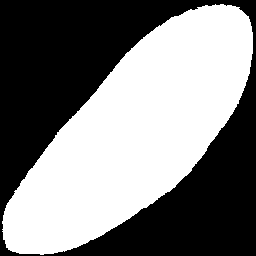
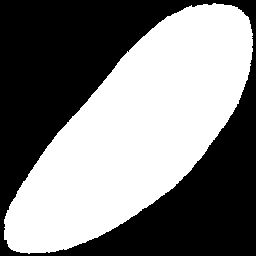
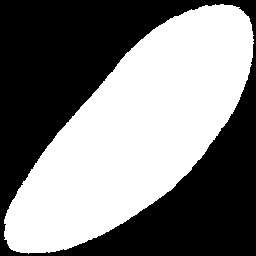
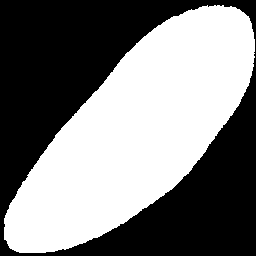
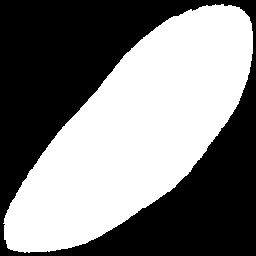
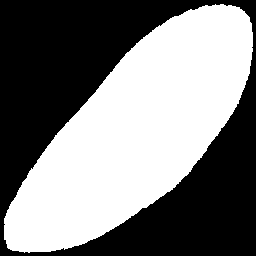
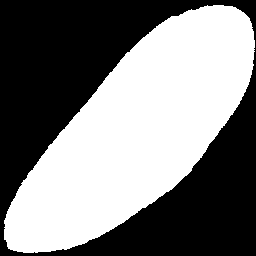
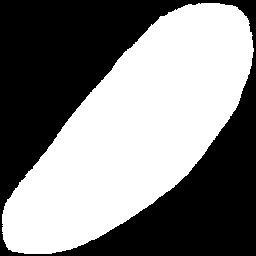
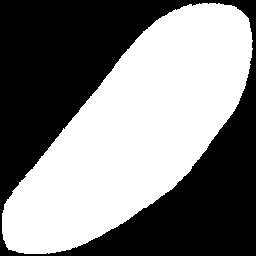
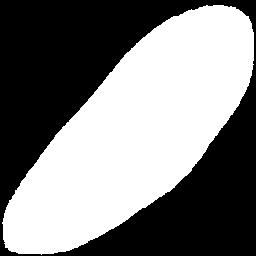
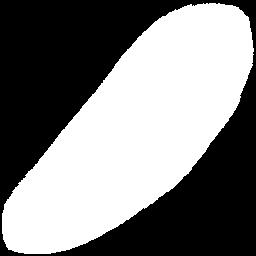
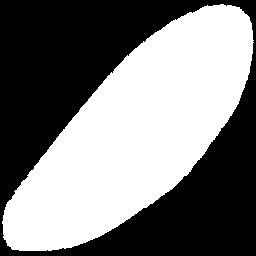
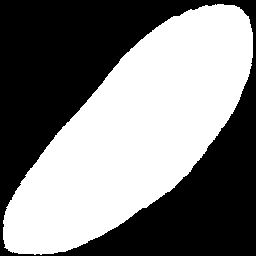
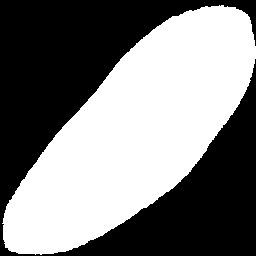
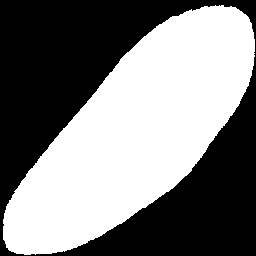
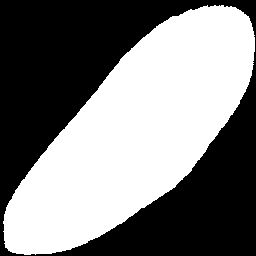
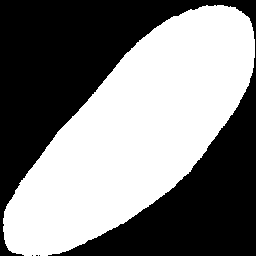
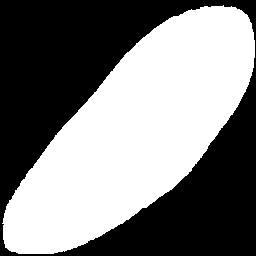
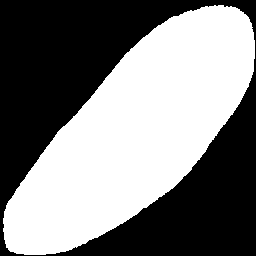
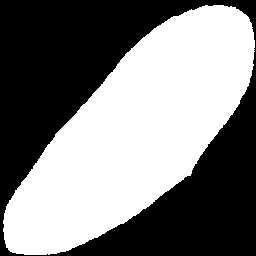
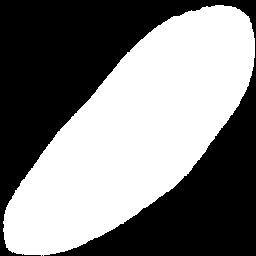
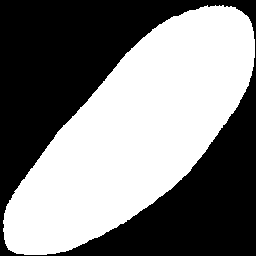
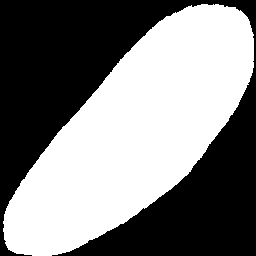
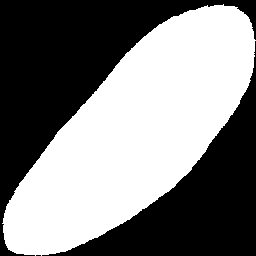
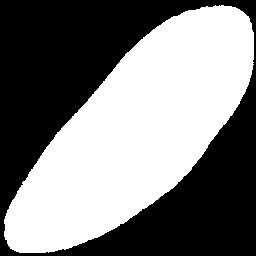
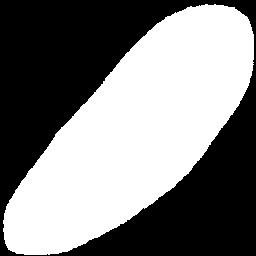
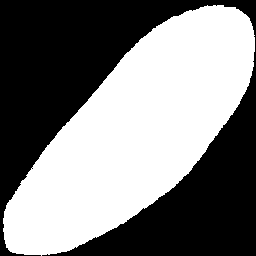
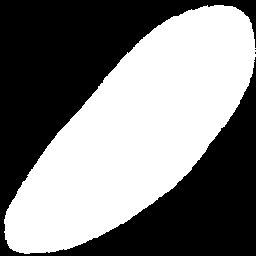
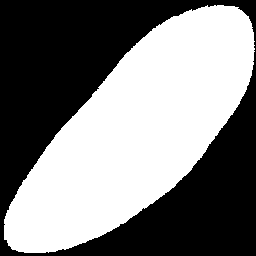
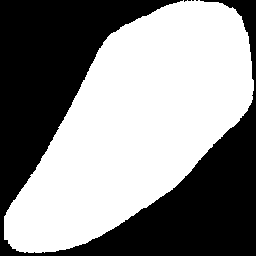
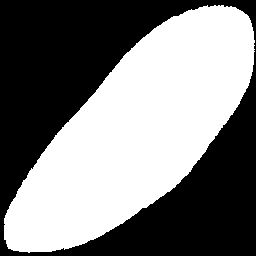
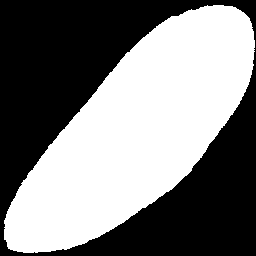
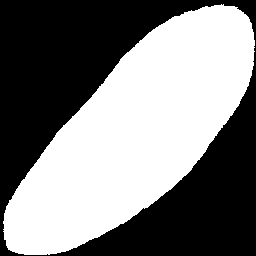
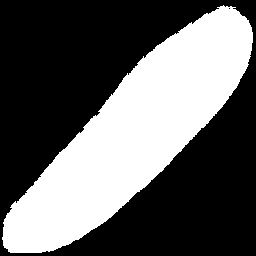
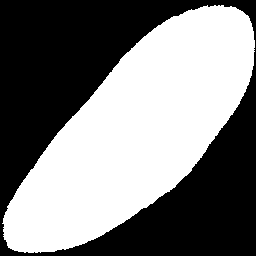
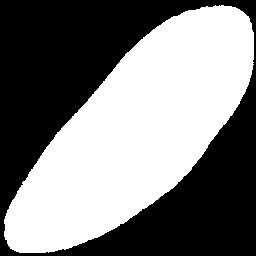
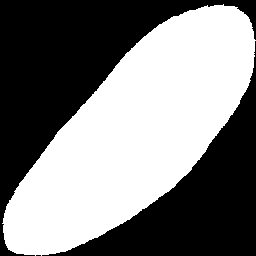
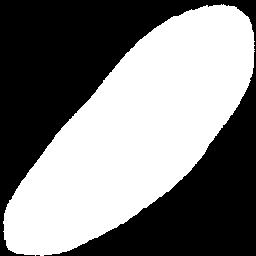
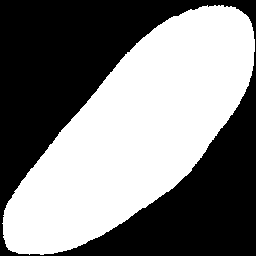
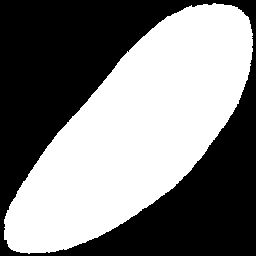
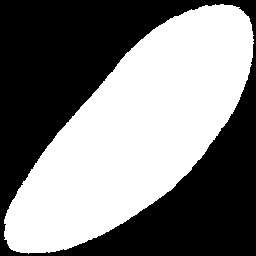
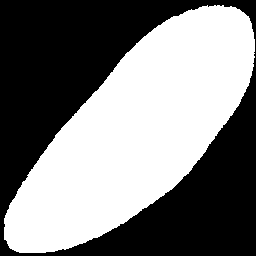
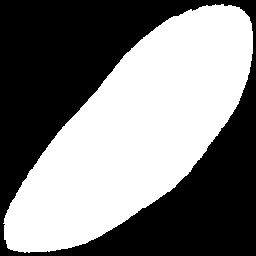
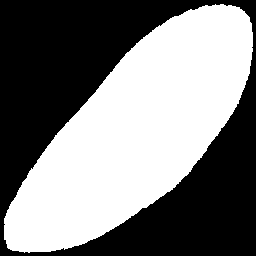
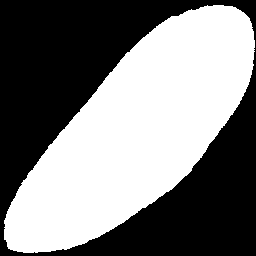
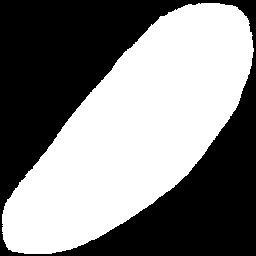
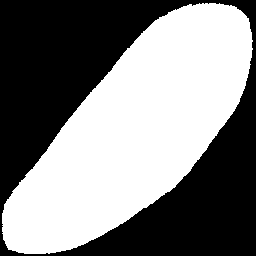
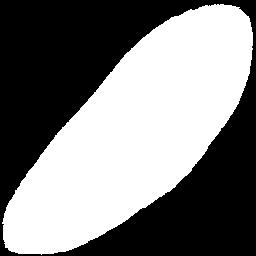
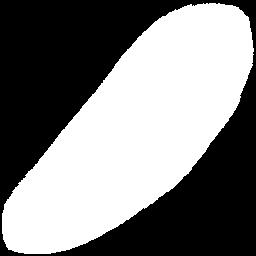
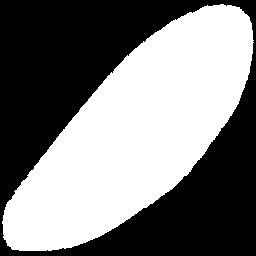
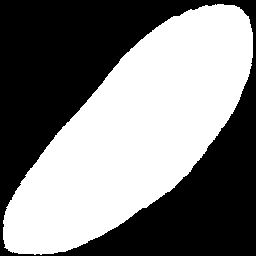
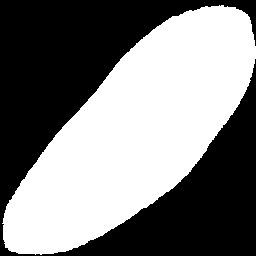
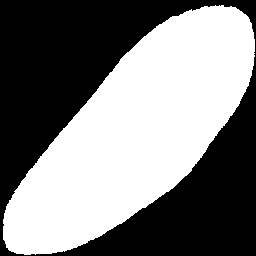
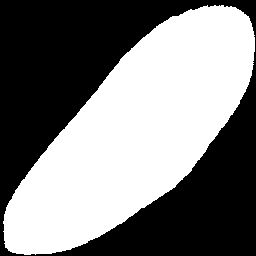
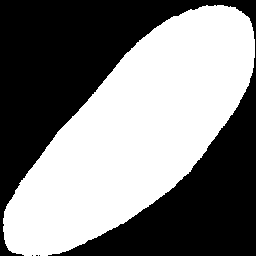
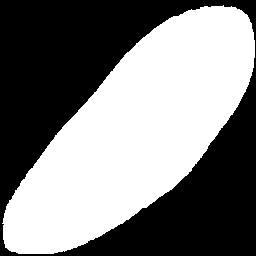
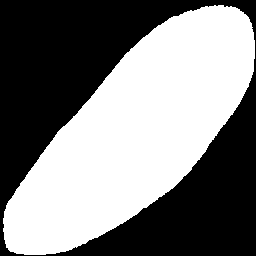
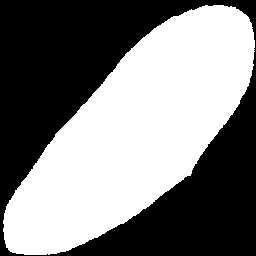
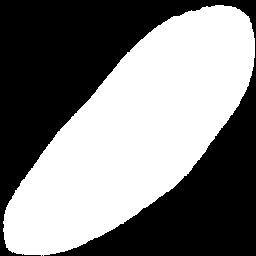
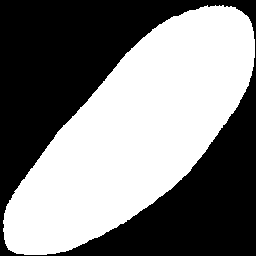
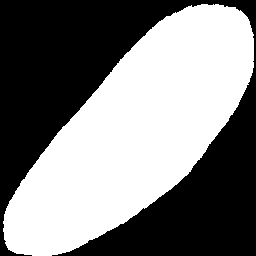
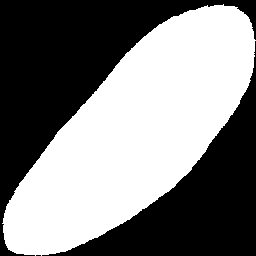
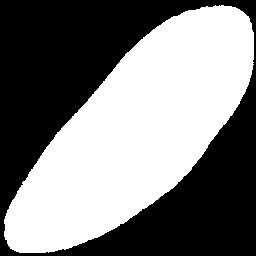
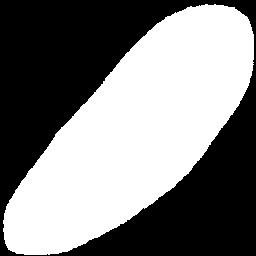
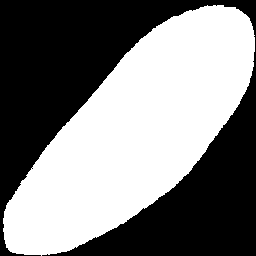
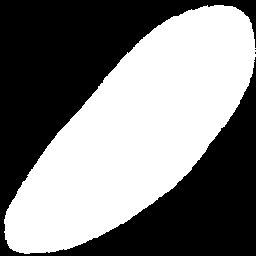
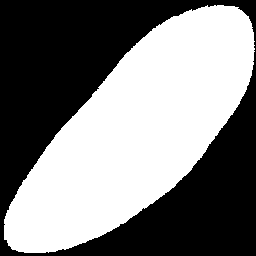
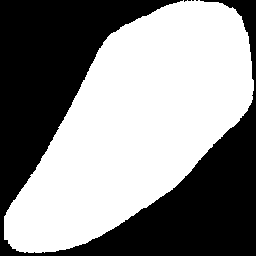
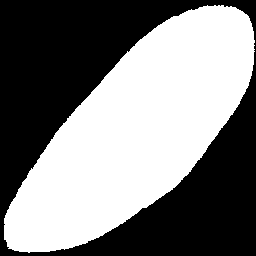
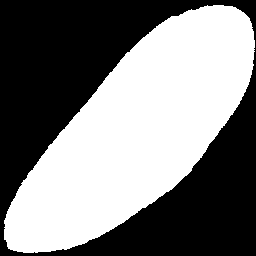
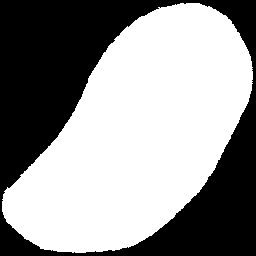
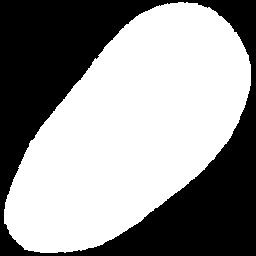
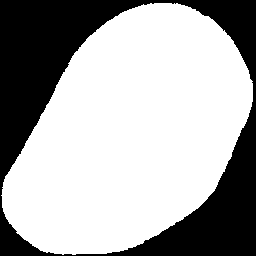
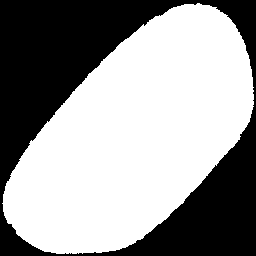
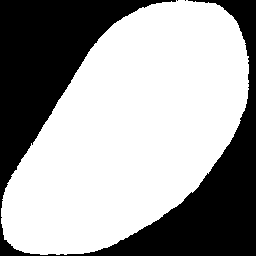
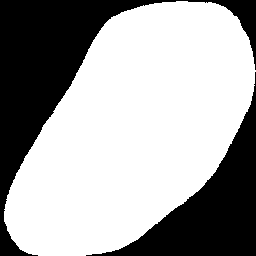
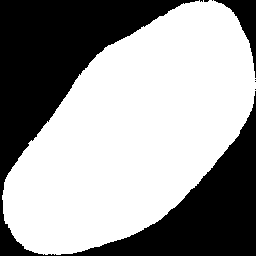
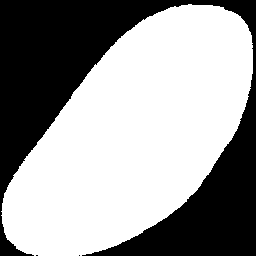
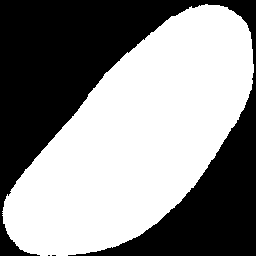
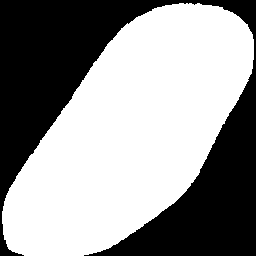
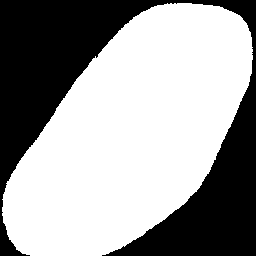
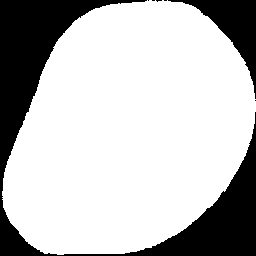
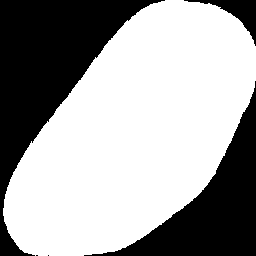
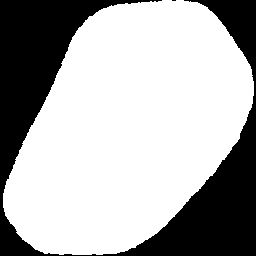
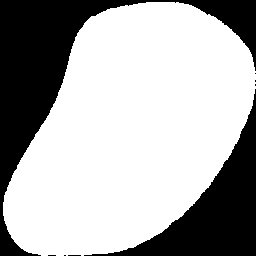
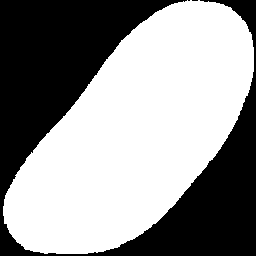
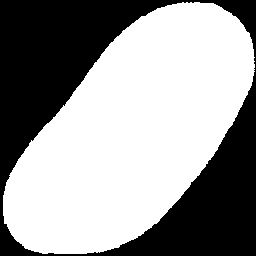
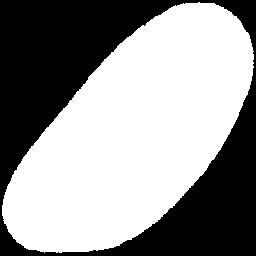
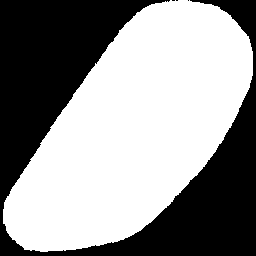
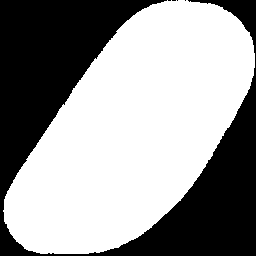
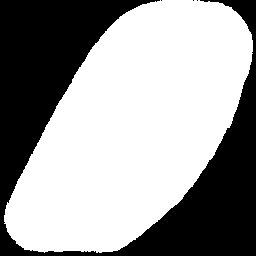
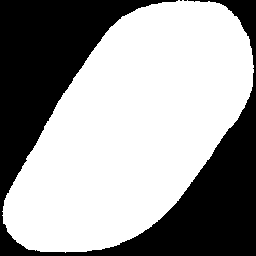
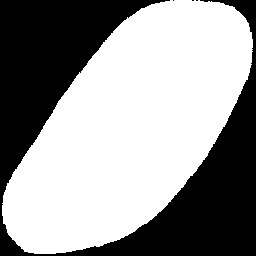
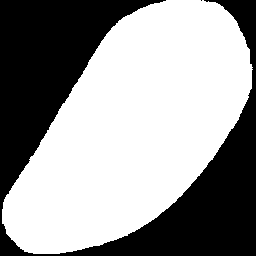
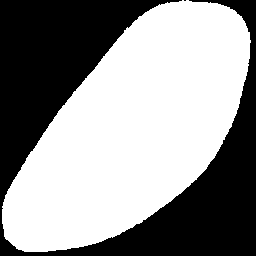
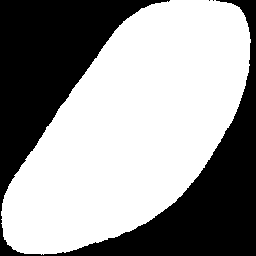
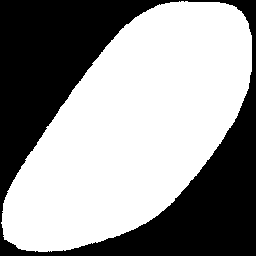
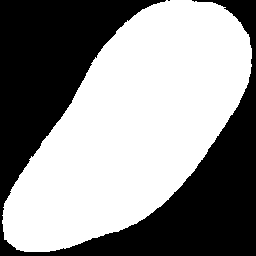
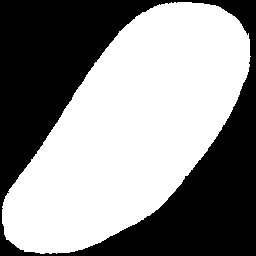
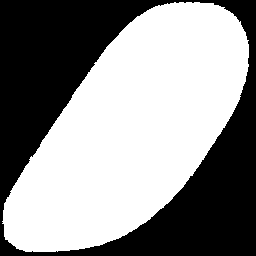
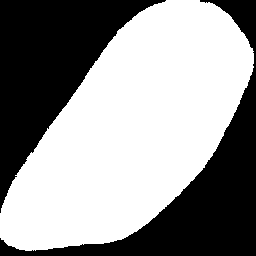
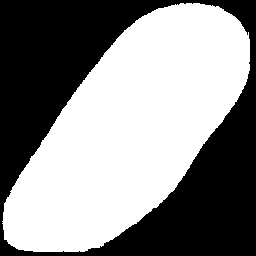
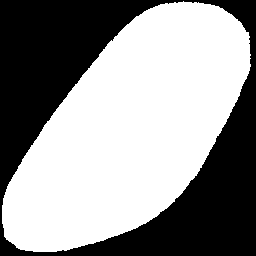
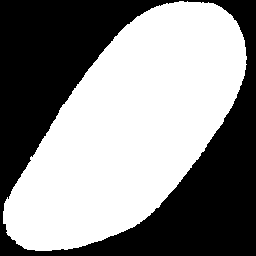
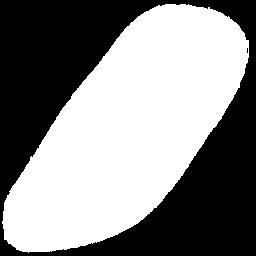
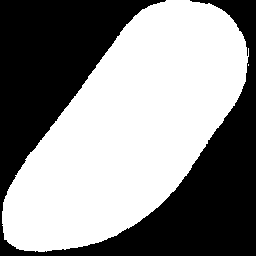
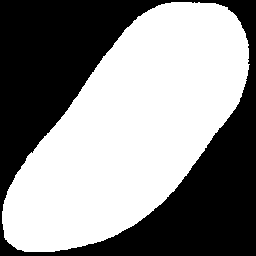
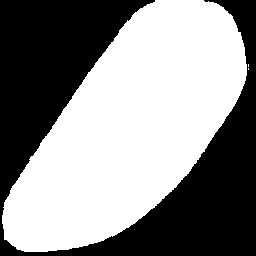
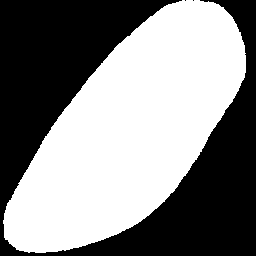
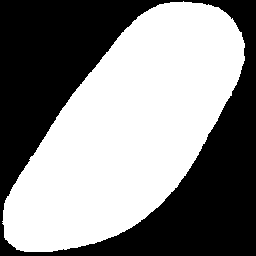
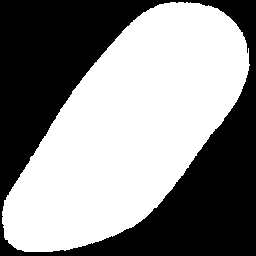
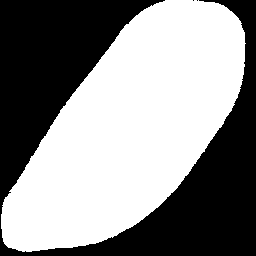
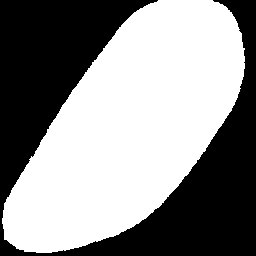
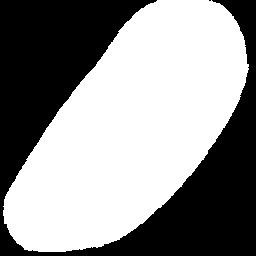
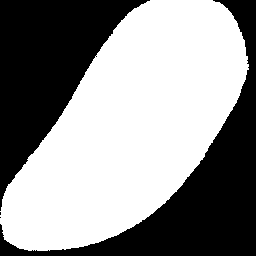
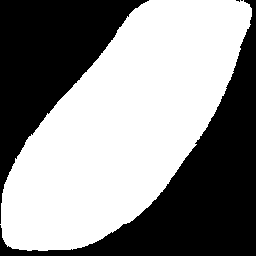
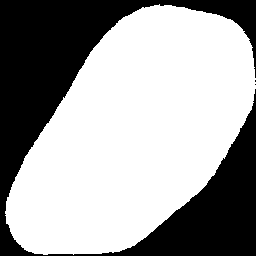
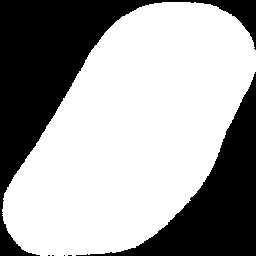
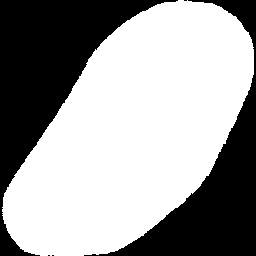
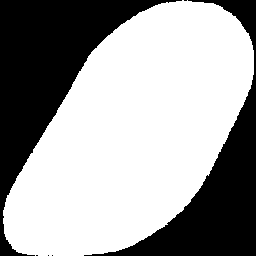
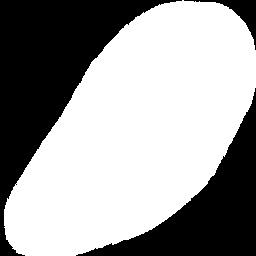
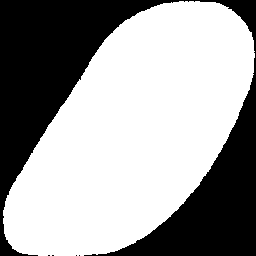
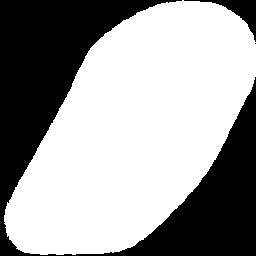
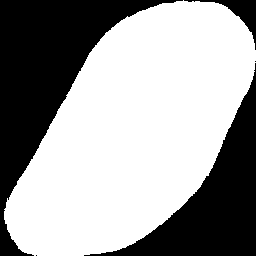
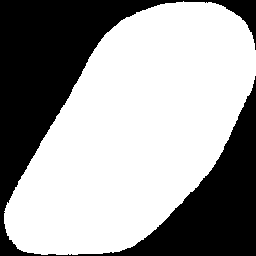
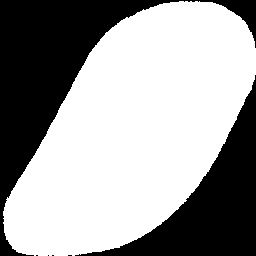
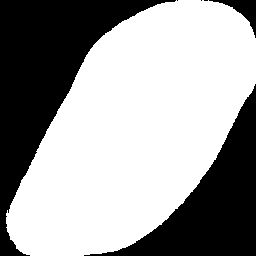
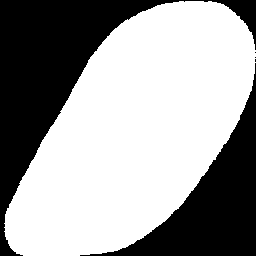
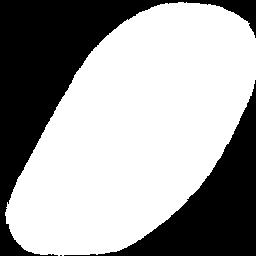
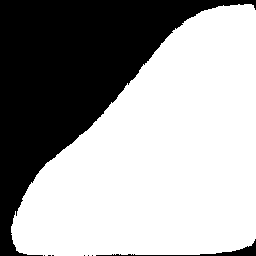
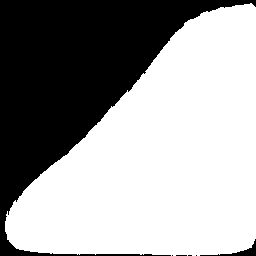
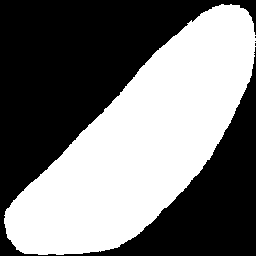
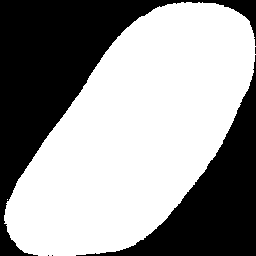
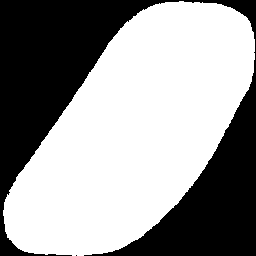
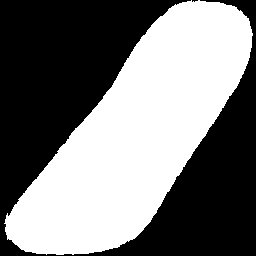
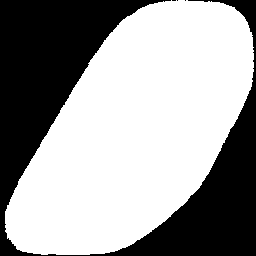
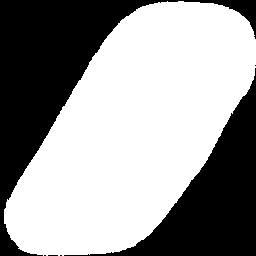
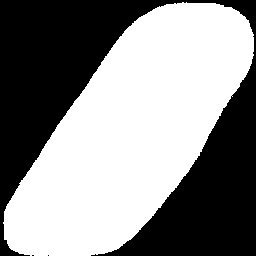
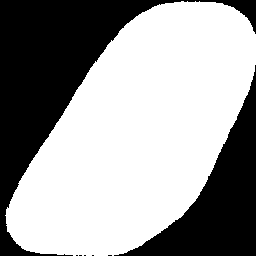
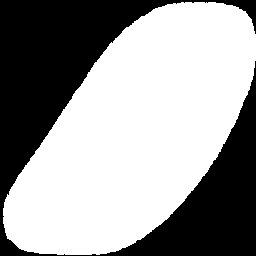
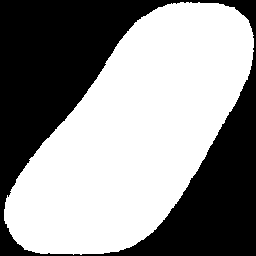
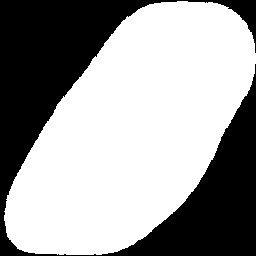
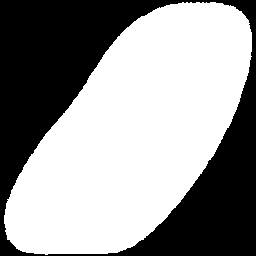
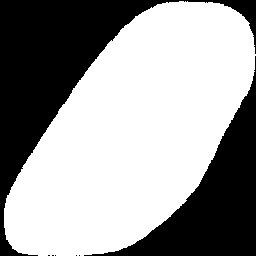
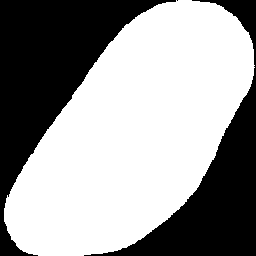
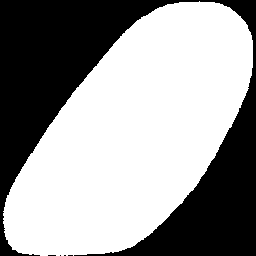
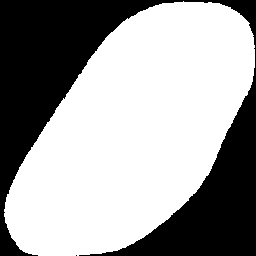
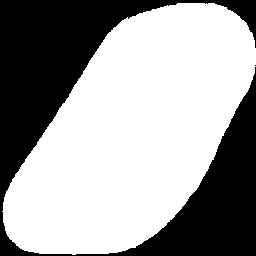
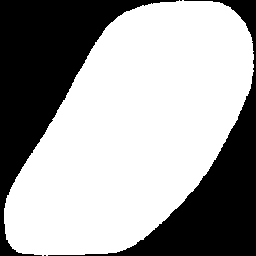
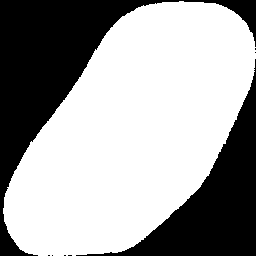
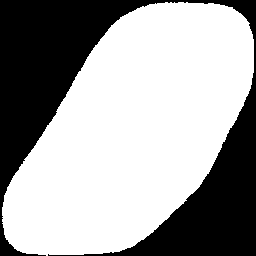
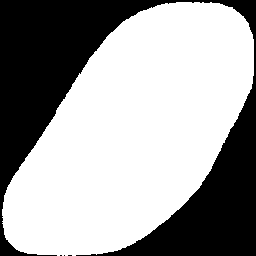
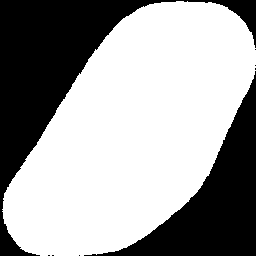
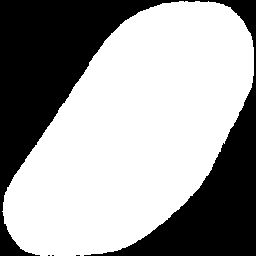
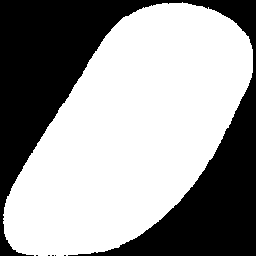
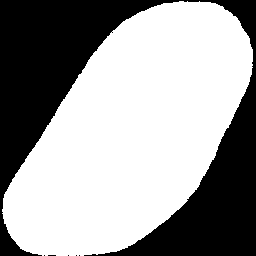
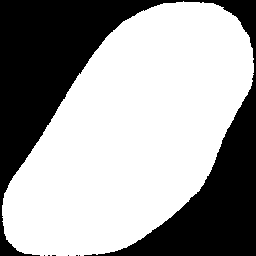
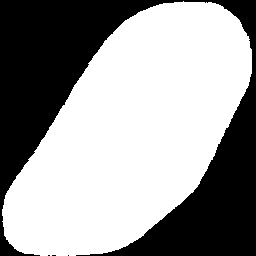
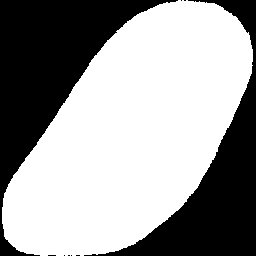
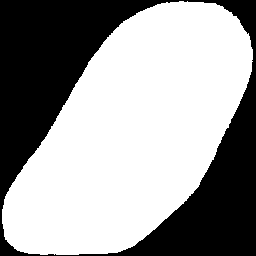
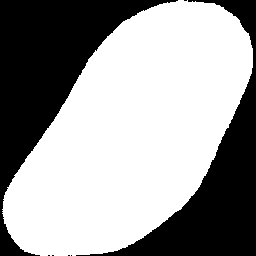
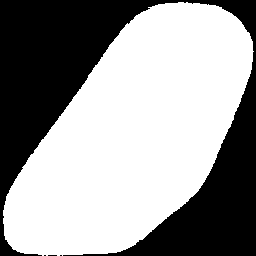
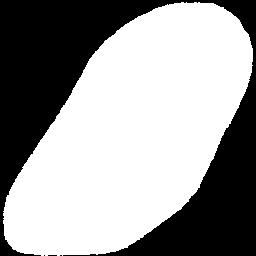
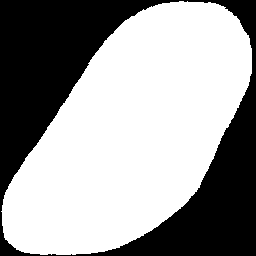
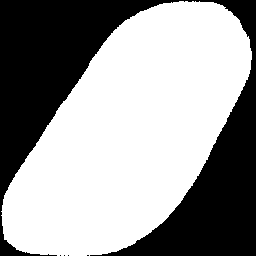
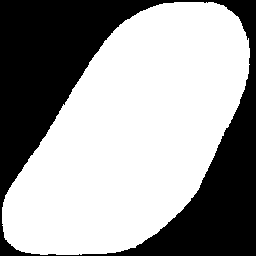
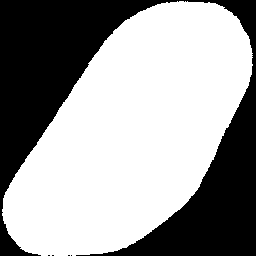
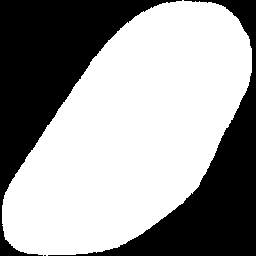
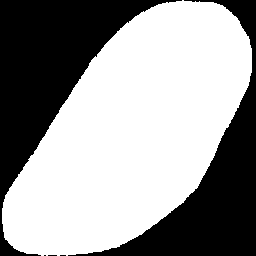
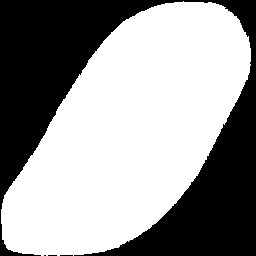
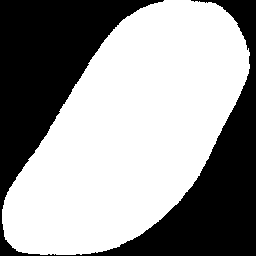
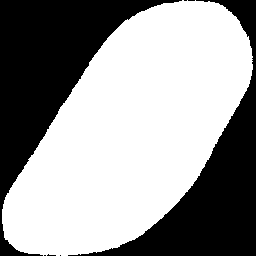
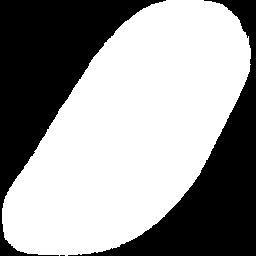
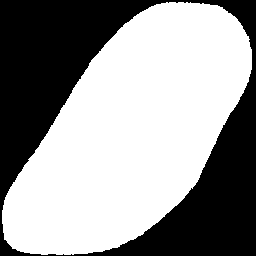
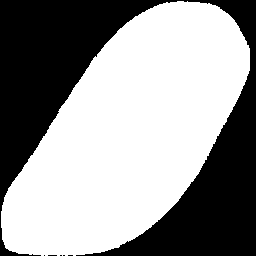
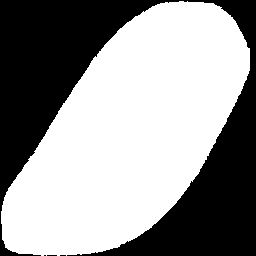
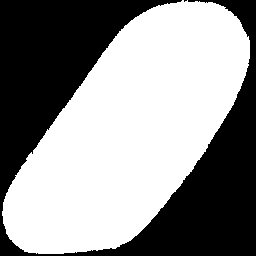
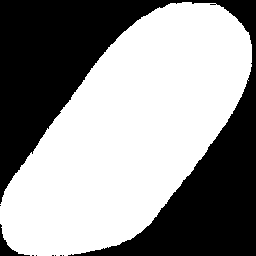
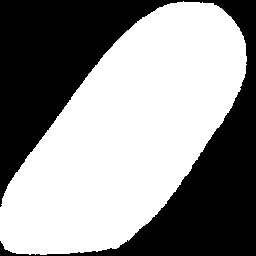
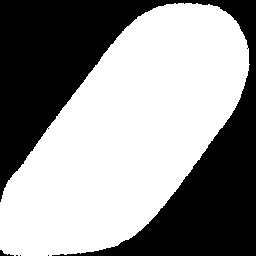
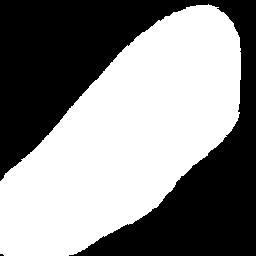
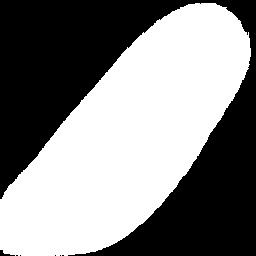
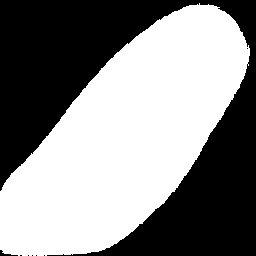
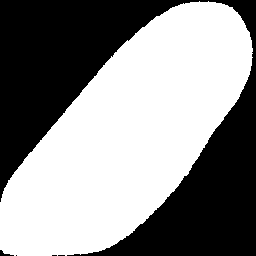
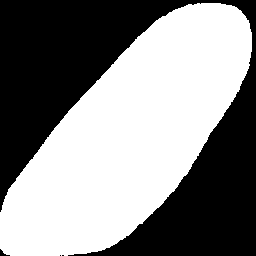
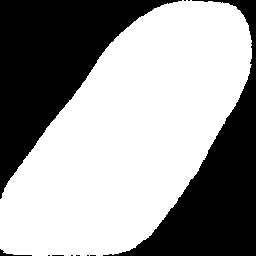
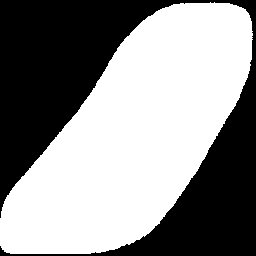
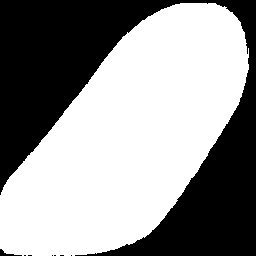
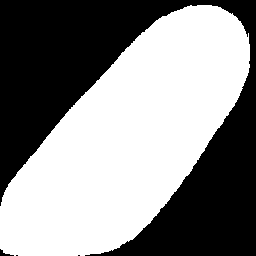
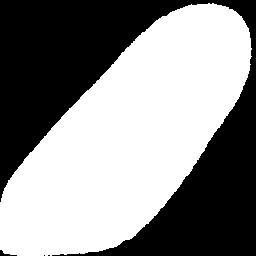
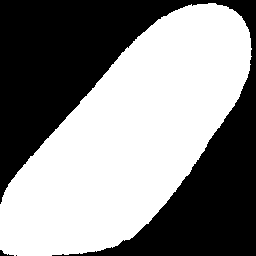
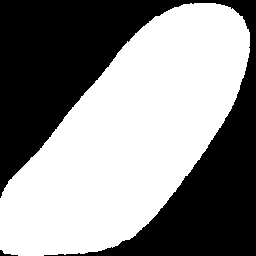
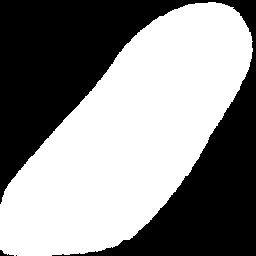
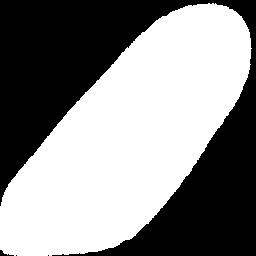
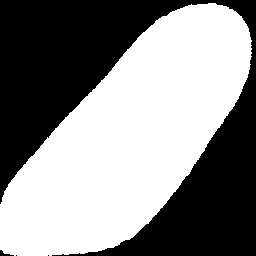
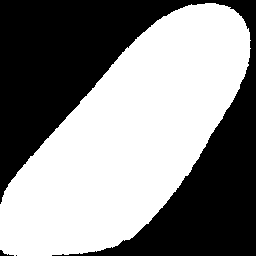
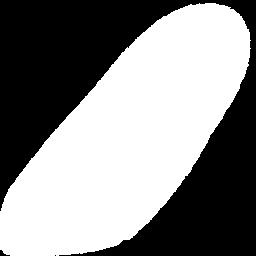
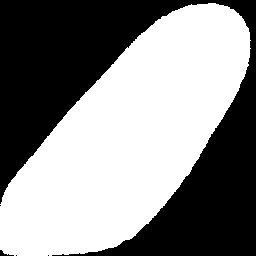
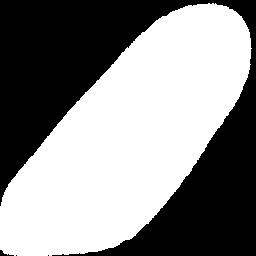
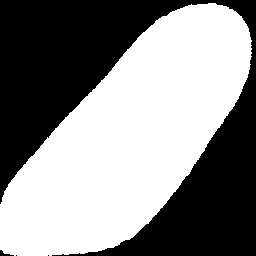
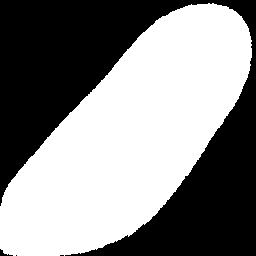
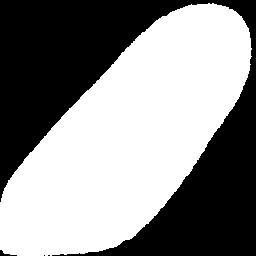
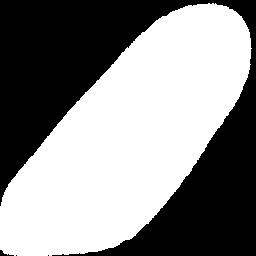
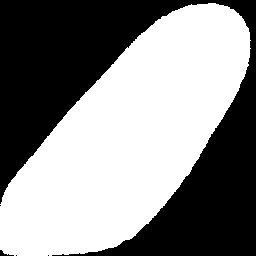
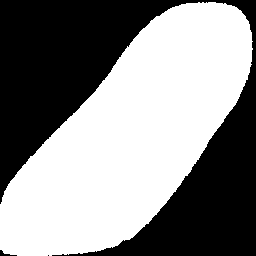
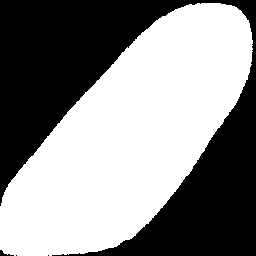
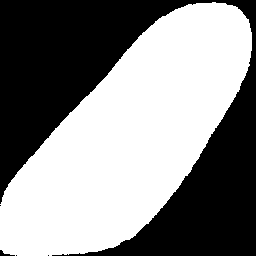
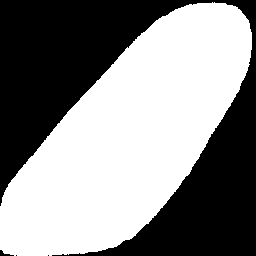
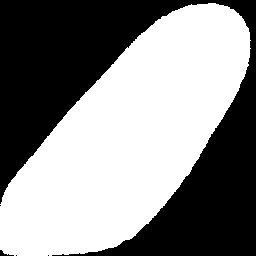
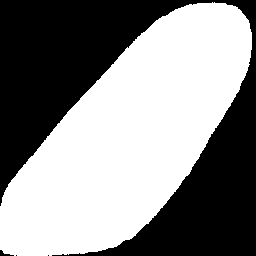
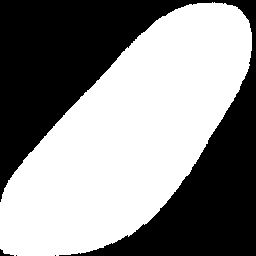
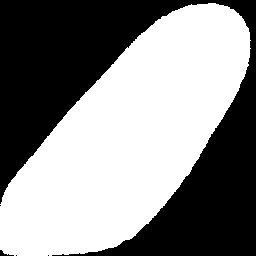
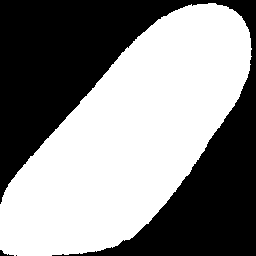
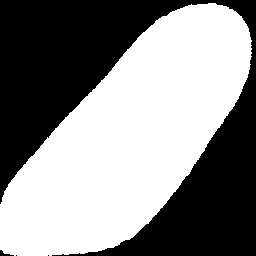
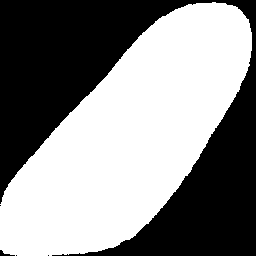
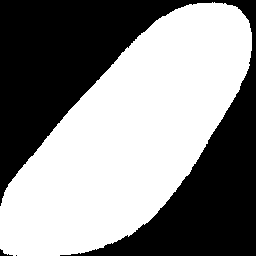
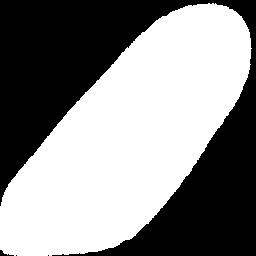
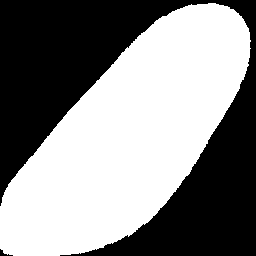
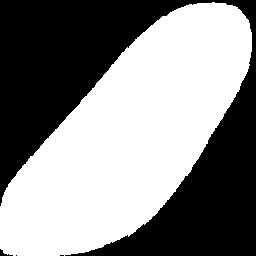
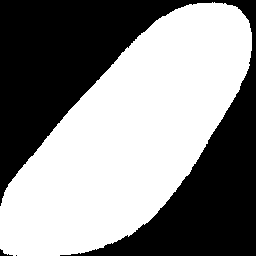
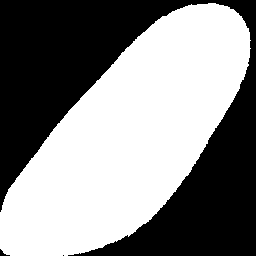
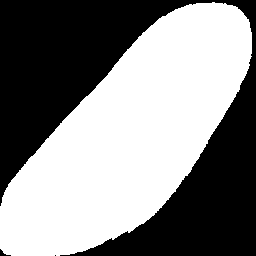
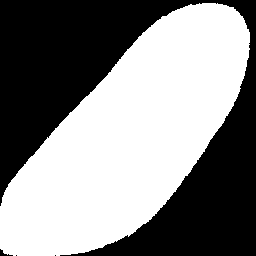
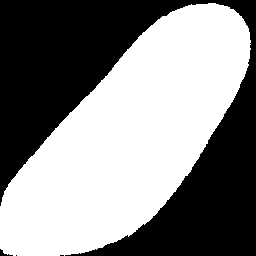
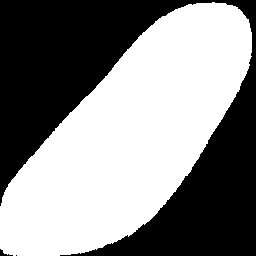
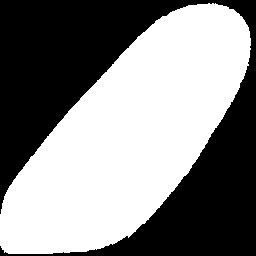
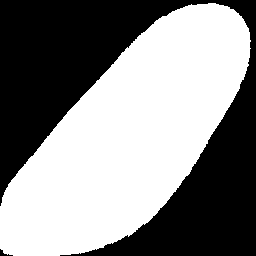
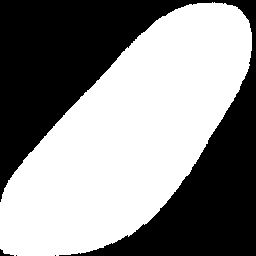
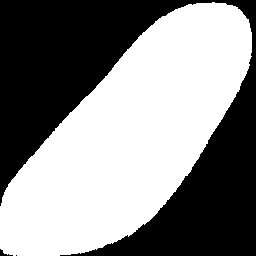
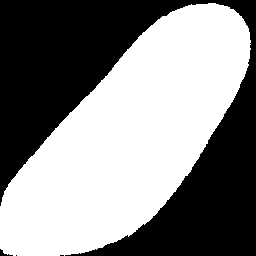
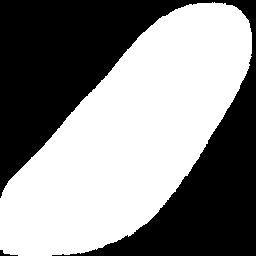
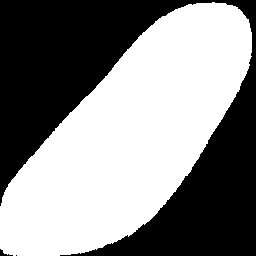
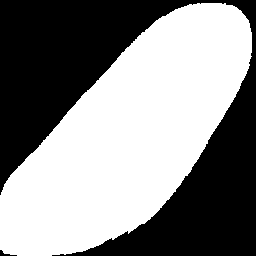
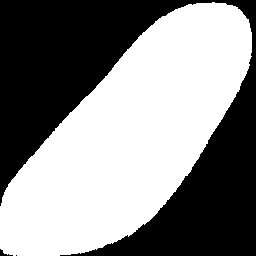
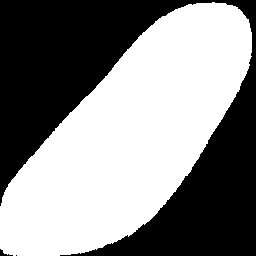
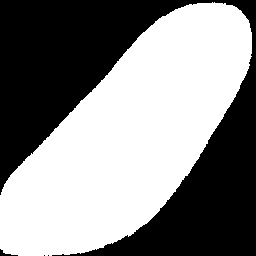
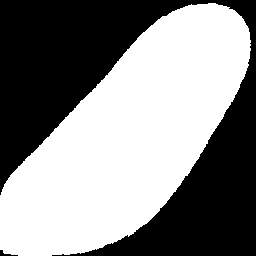
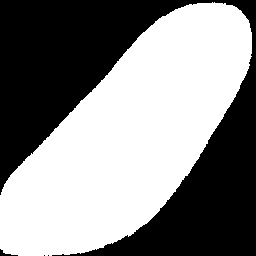
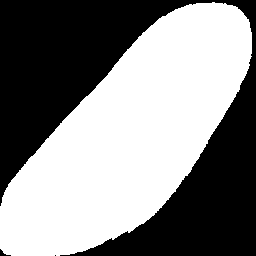
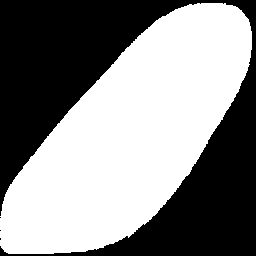
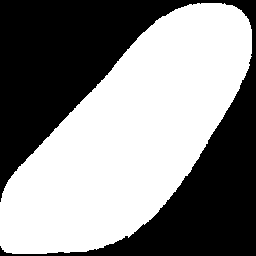
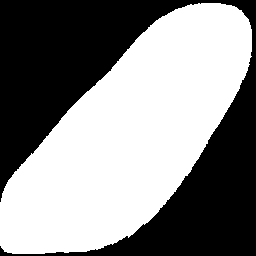
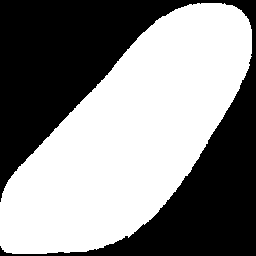
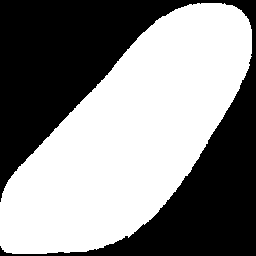
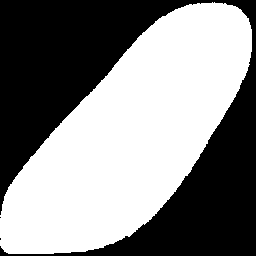
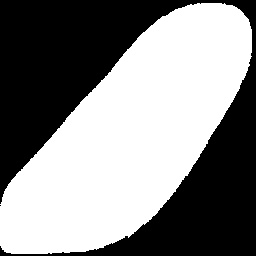
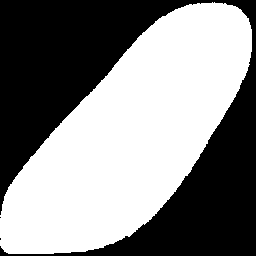
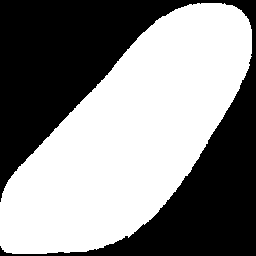
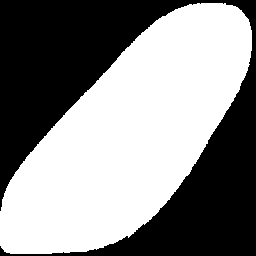
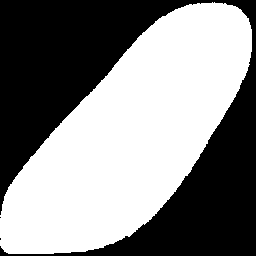
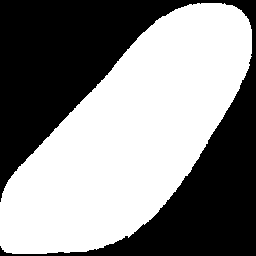
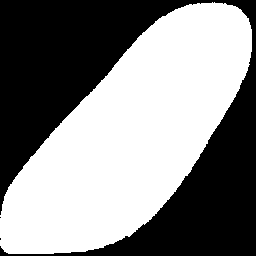
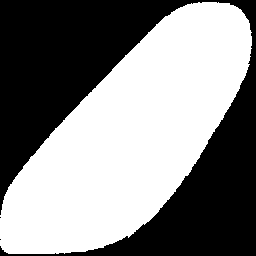
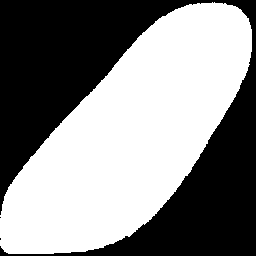
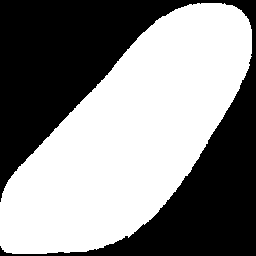
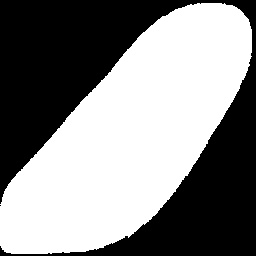
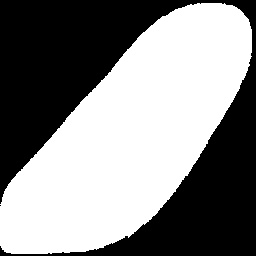
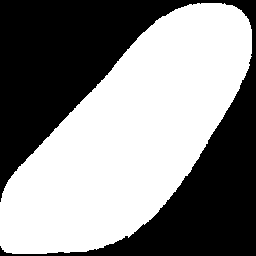
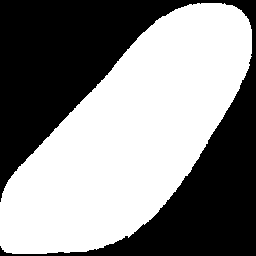
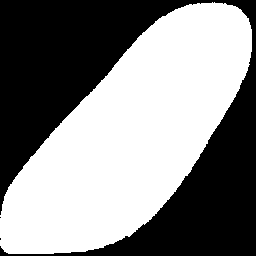
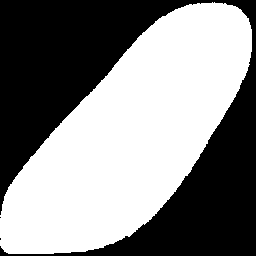
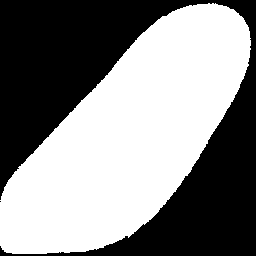
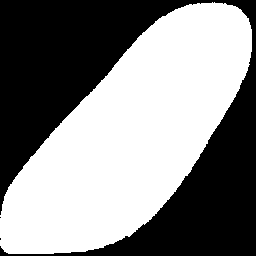
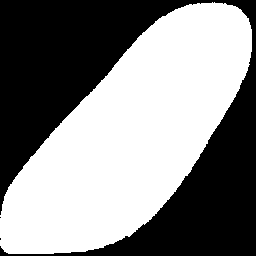
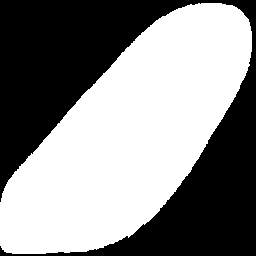
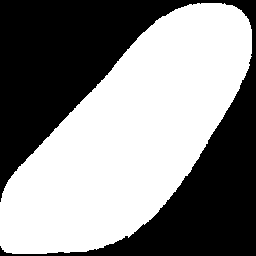
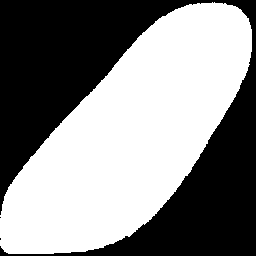
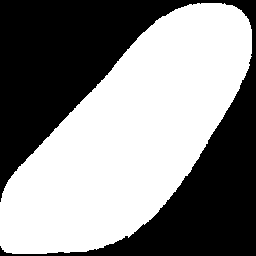
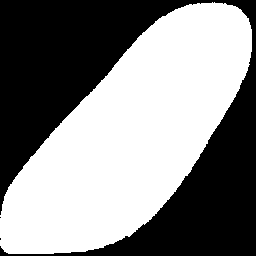
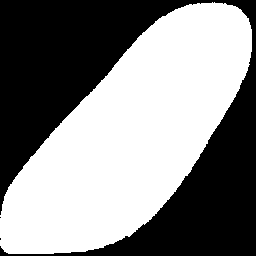
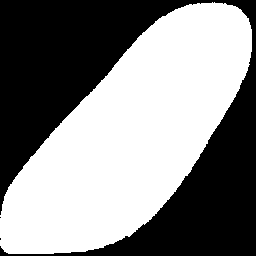
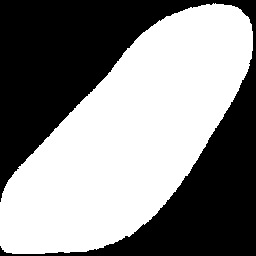
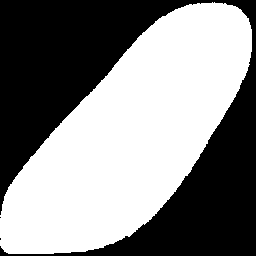
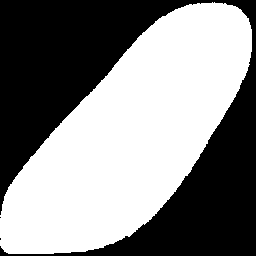
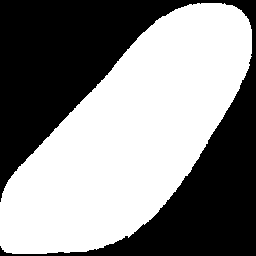
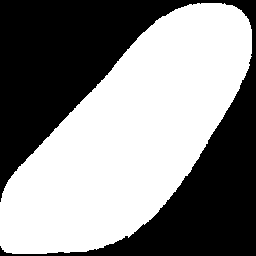
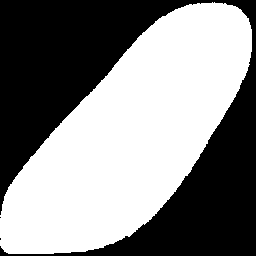
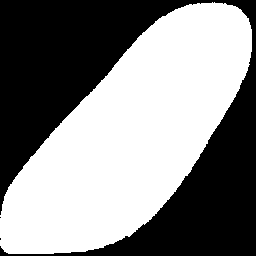
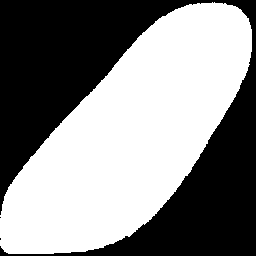
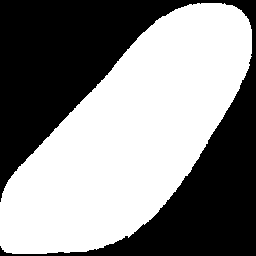
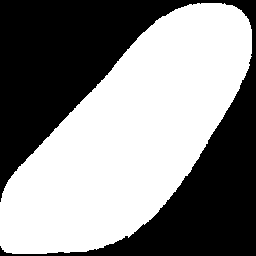
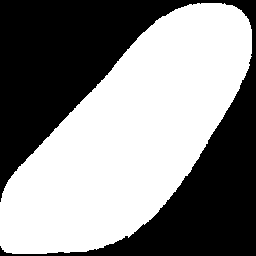
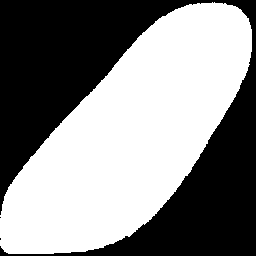
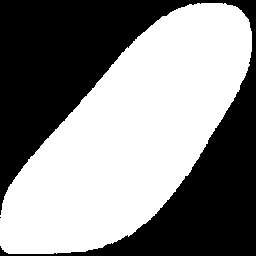
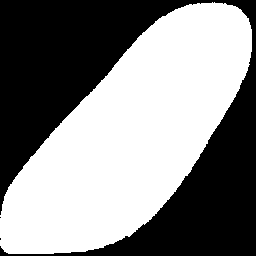
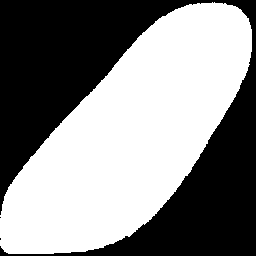
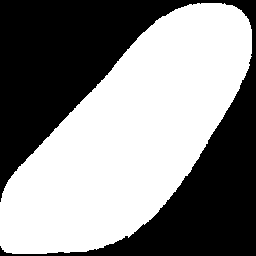
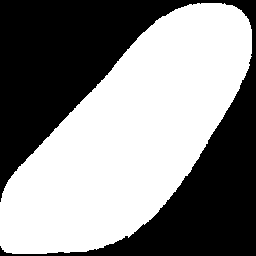
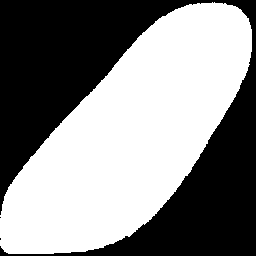
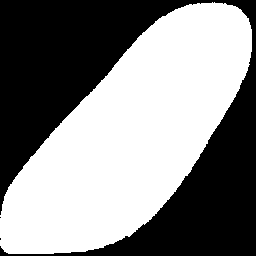
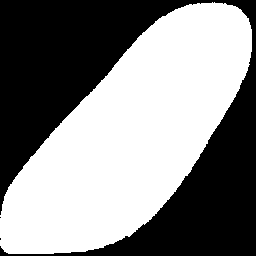
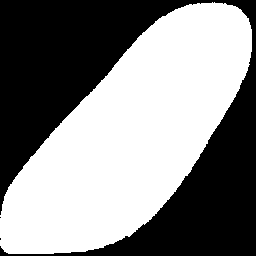
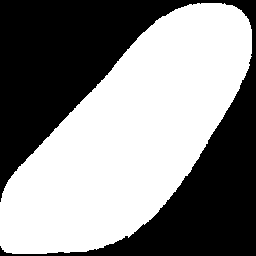
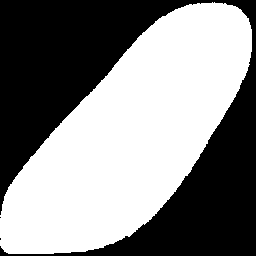
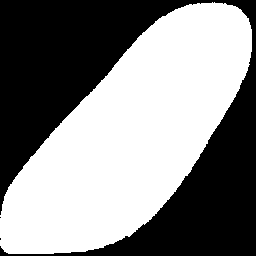
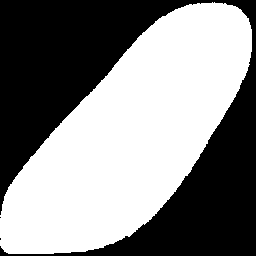
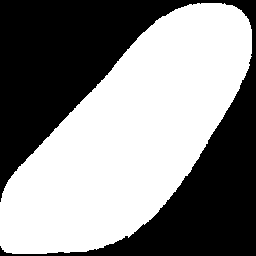
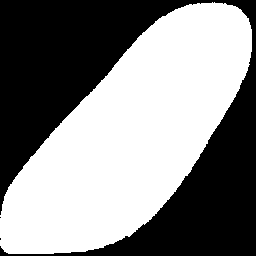
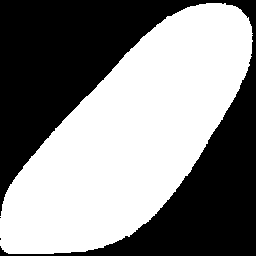
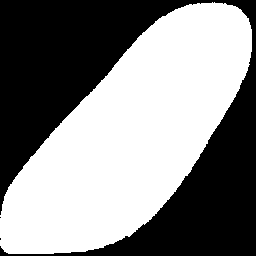
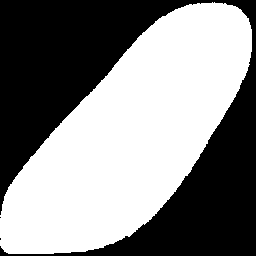
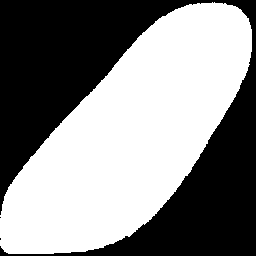
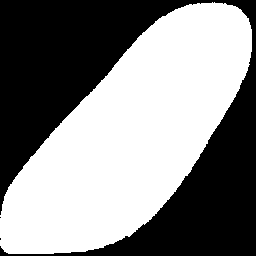
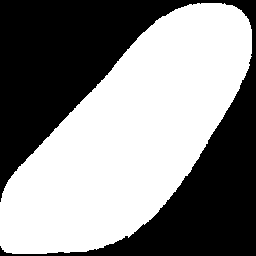
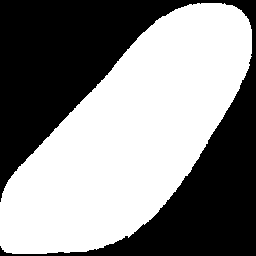
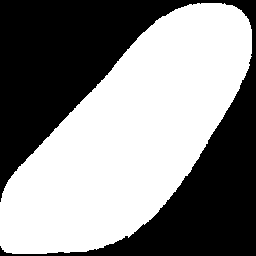
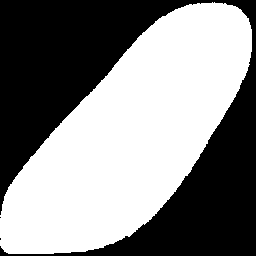
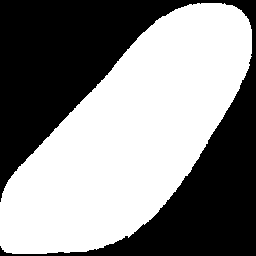
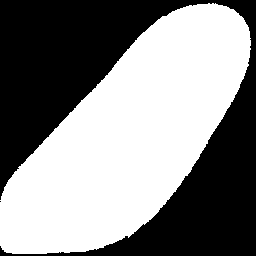
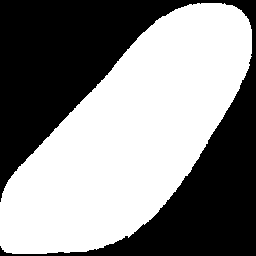
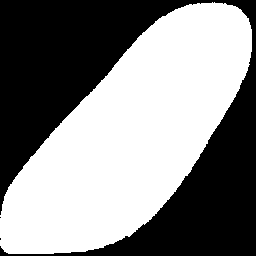
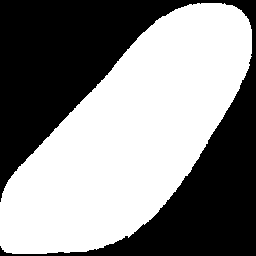
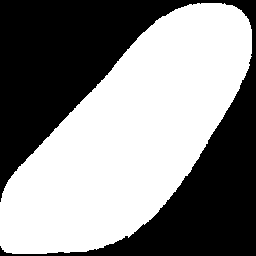
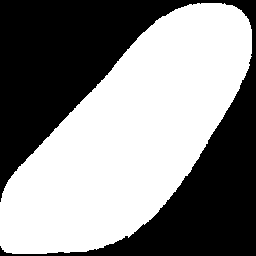
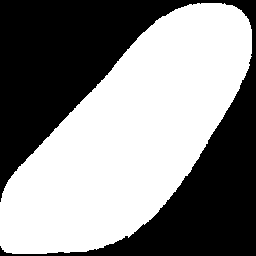
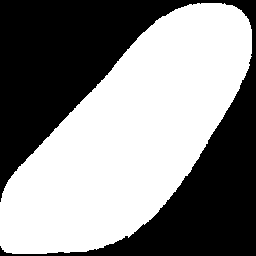
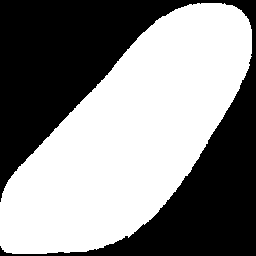
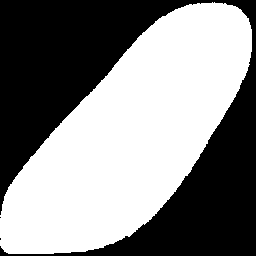
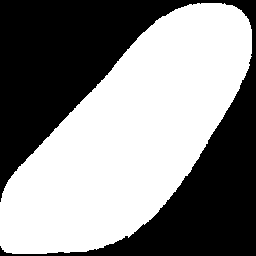
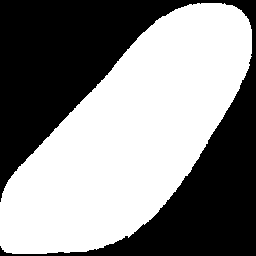
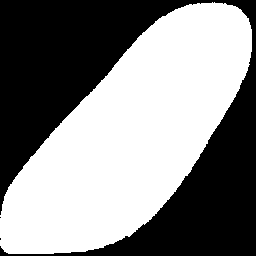
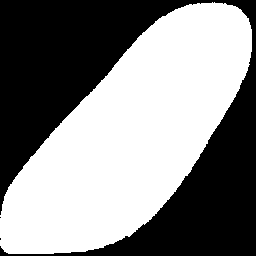
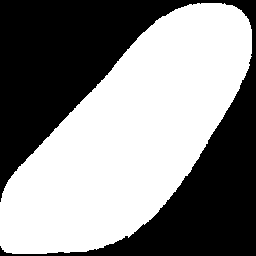
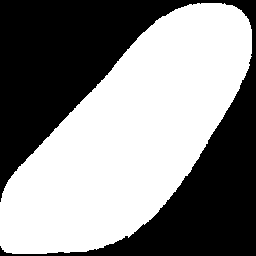
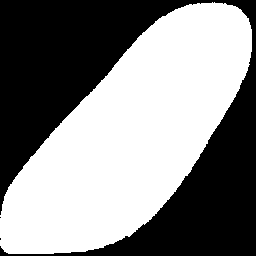
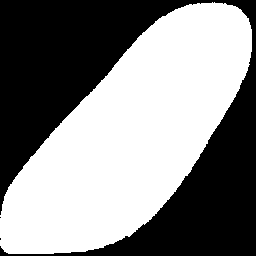
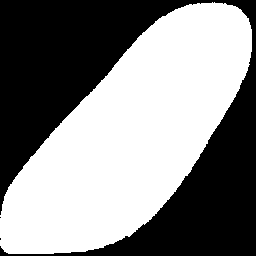
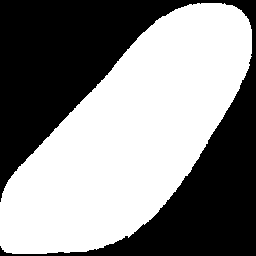
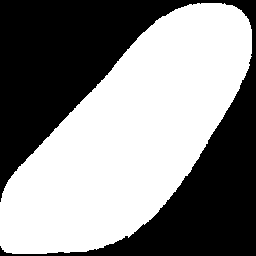
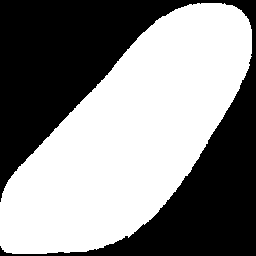
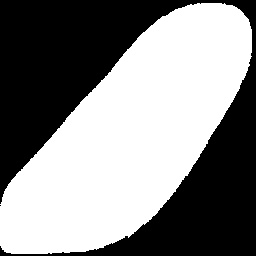
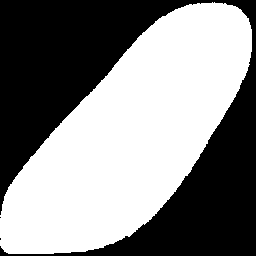
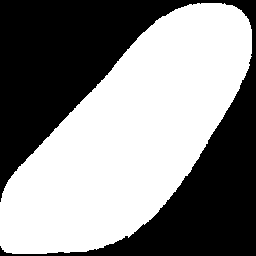
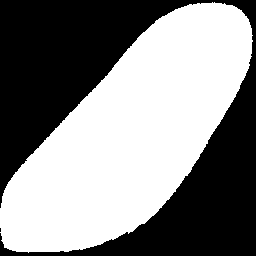
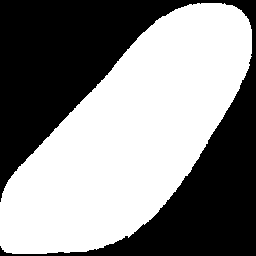
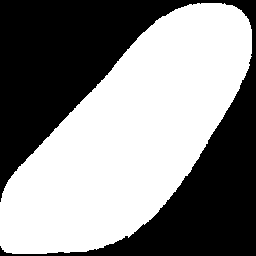
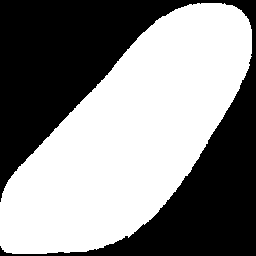
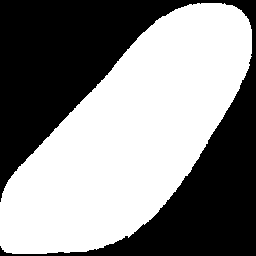
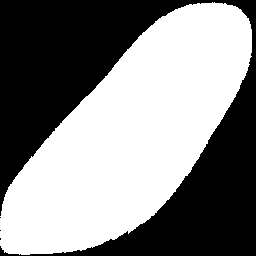
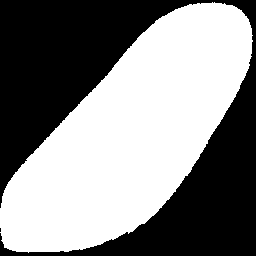
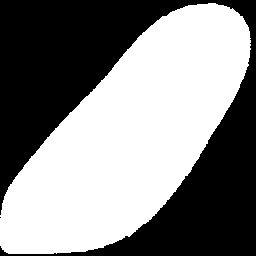
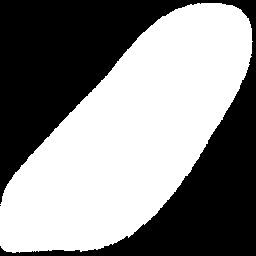
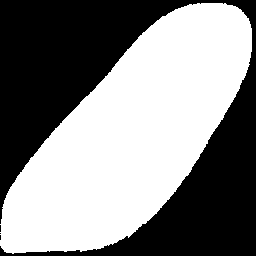
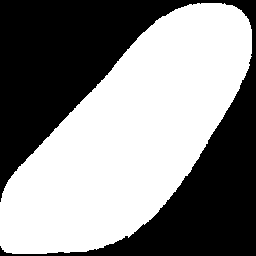
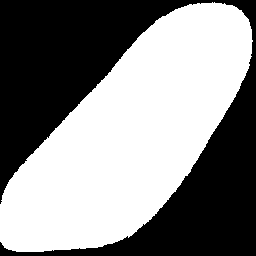
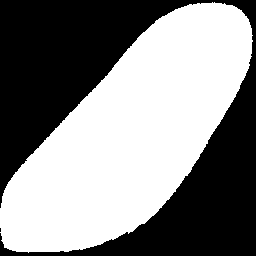
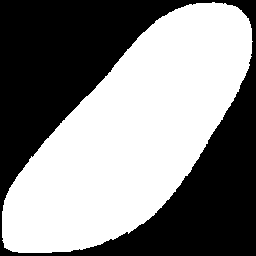
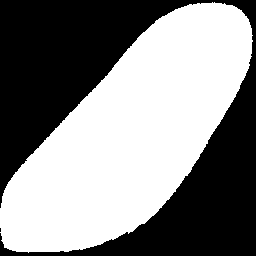
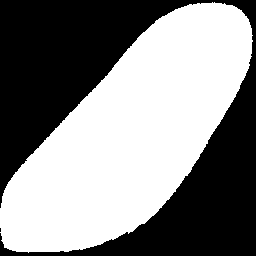
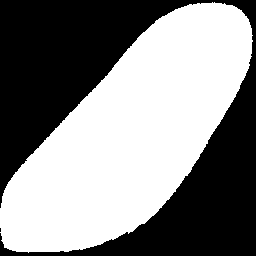
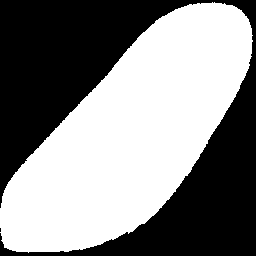
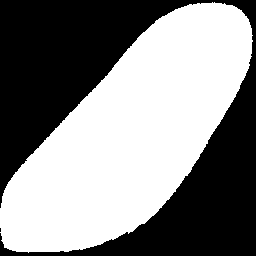
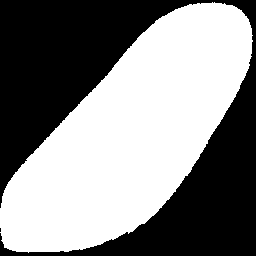
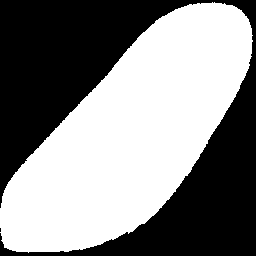
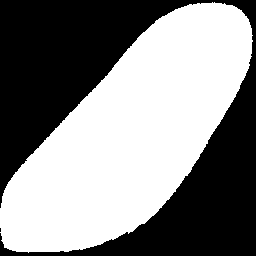
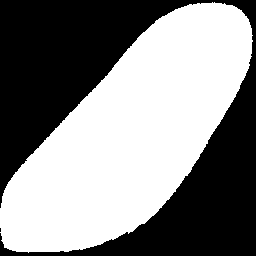
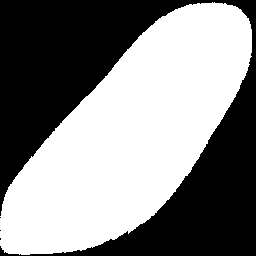
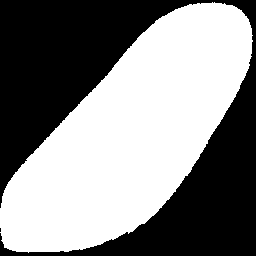
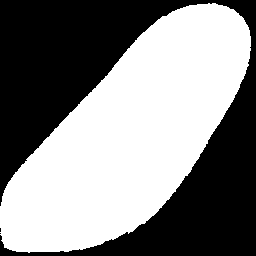
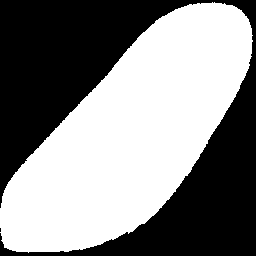
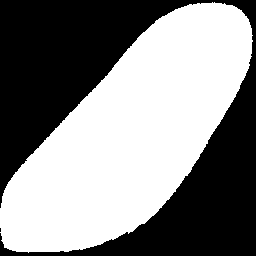
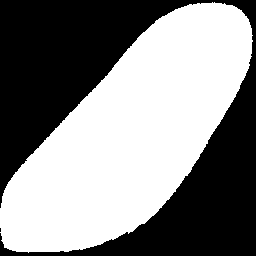
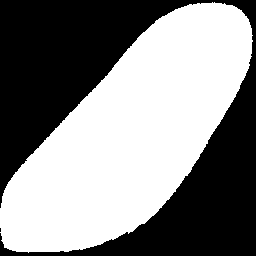
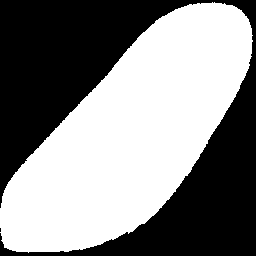
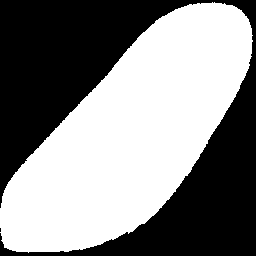
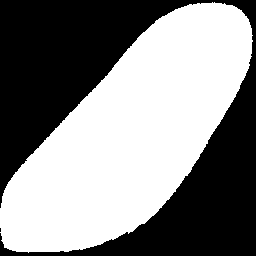
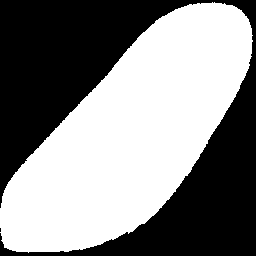
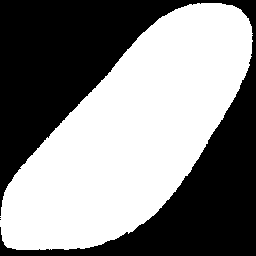
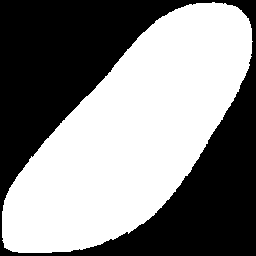
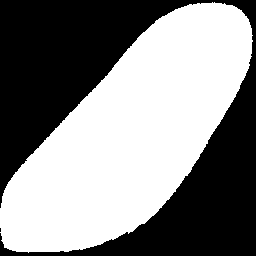
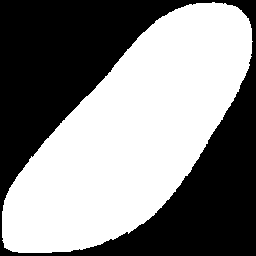
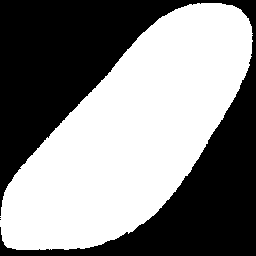
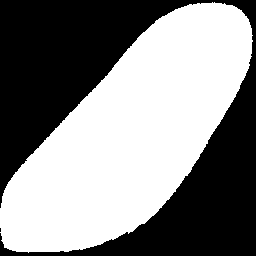
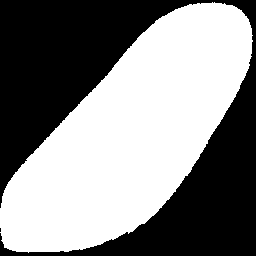
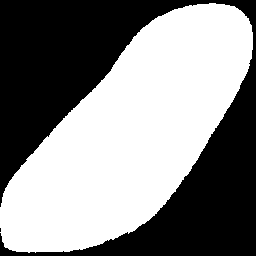
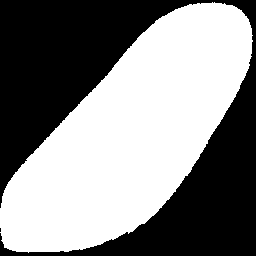
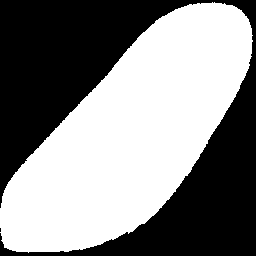
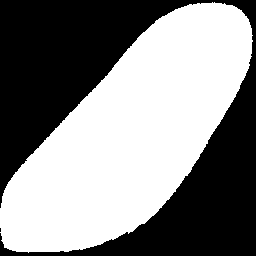
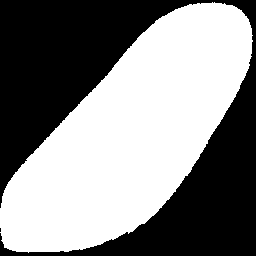
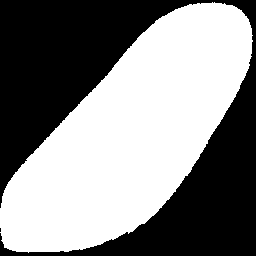
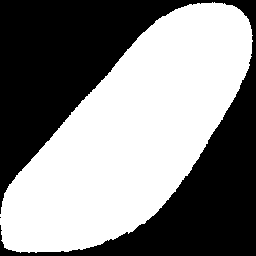
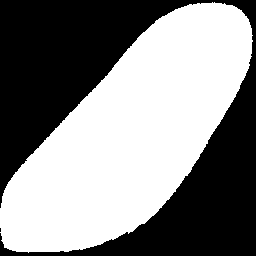
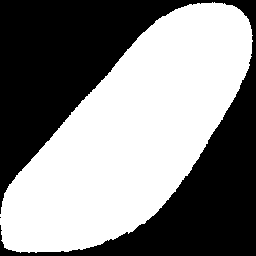
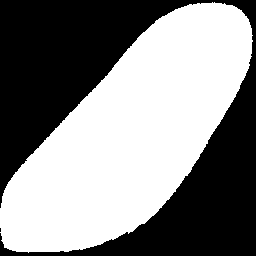
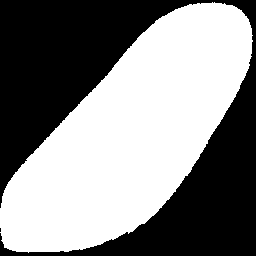
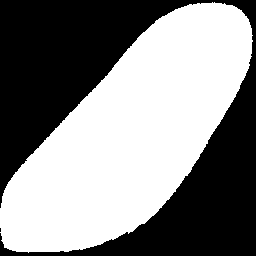
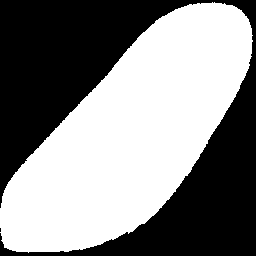
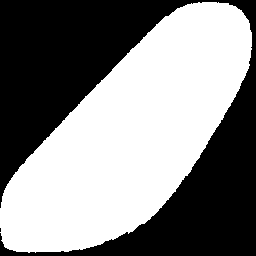
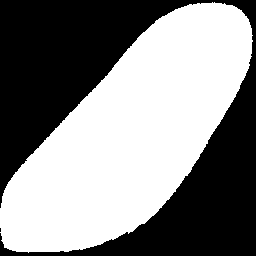
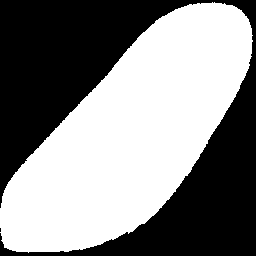
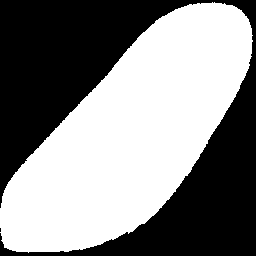
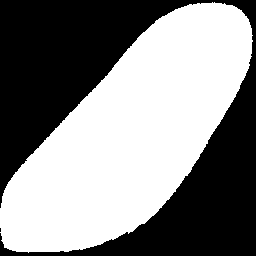
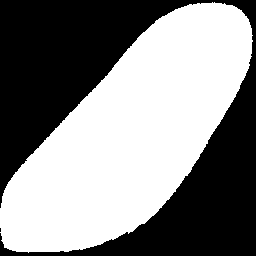
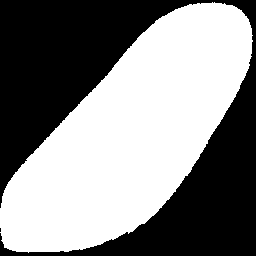
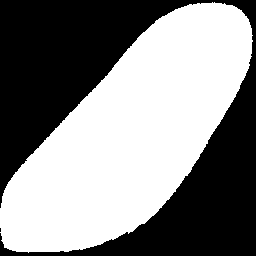
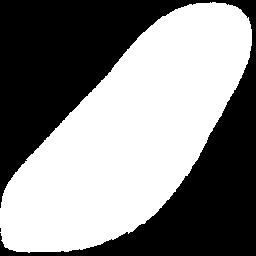
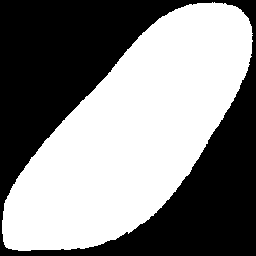
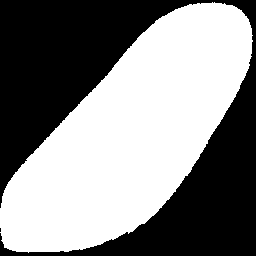
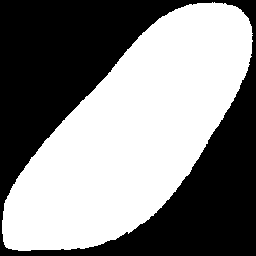
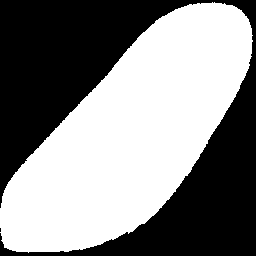
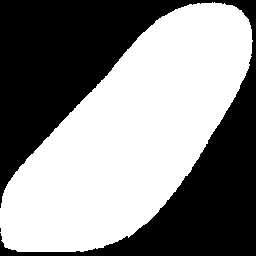
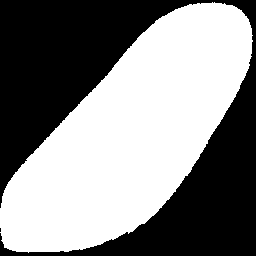
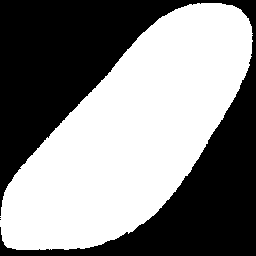
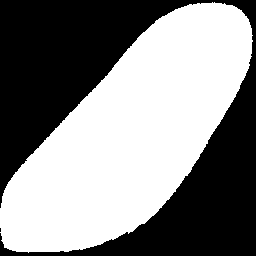
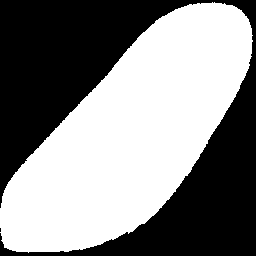
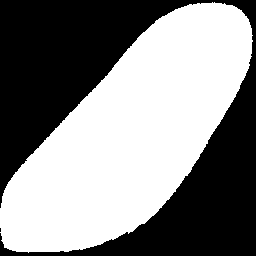
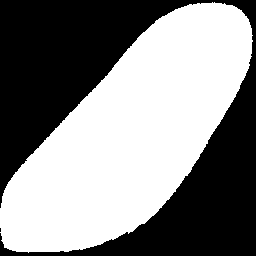
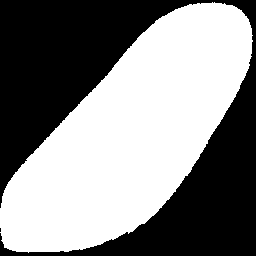
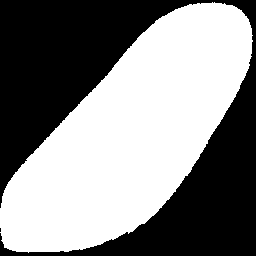
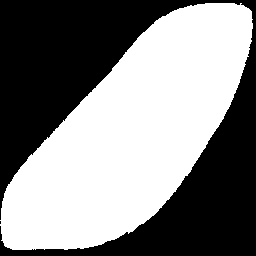
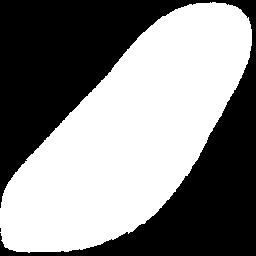
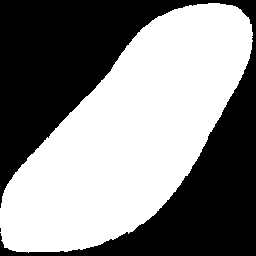
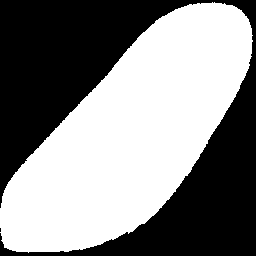
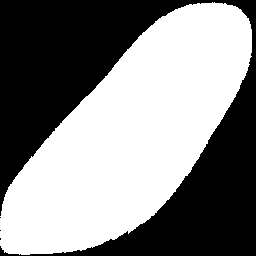

---------------------------------------------
       GenAI Segmentation Evaluation Report: gemini-2.5-flash-lite on ISIC 2017
---------------------------------------------
Total Images Evaluated: 2750
IoU Threshold for Success: 0.5
Exclude Low IoU from Stats: True

--- Performance Metrics ---
Mean IoU (Lesion):    0.7678 (95% CI: 0.7623 - 0.7730) on 1903 images
Mean Dice (Lesion):   0.8634 (95% CI: 0.8597 - 0.8668)

--- Operational Metrics ---
Mean API Latency:     2.50s (95% CI: 2.07s - 3.00s)
JSON Parse Success:   98.5%

--- Failure Analysis (based on full dataset) ---
JSON Failures:            42 (1.5%)
False Negatives (Lesion): 0 (0.0%)
Low IoU (Lesion):         805 (29.3%)
---------------------------------------------


2025-08-01 22:32:47 — INFO — Saved high-resolution IoU plot to D:\Projects\gemini_image_segmentation\data\ISIC_2017_Part1\iou_distribution_isic_gemini-2.5-flash-lite.png


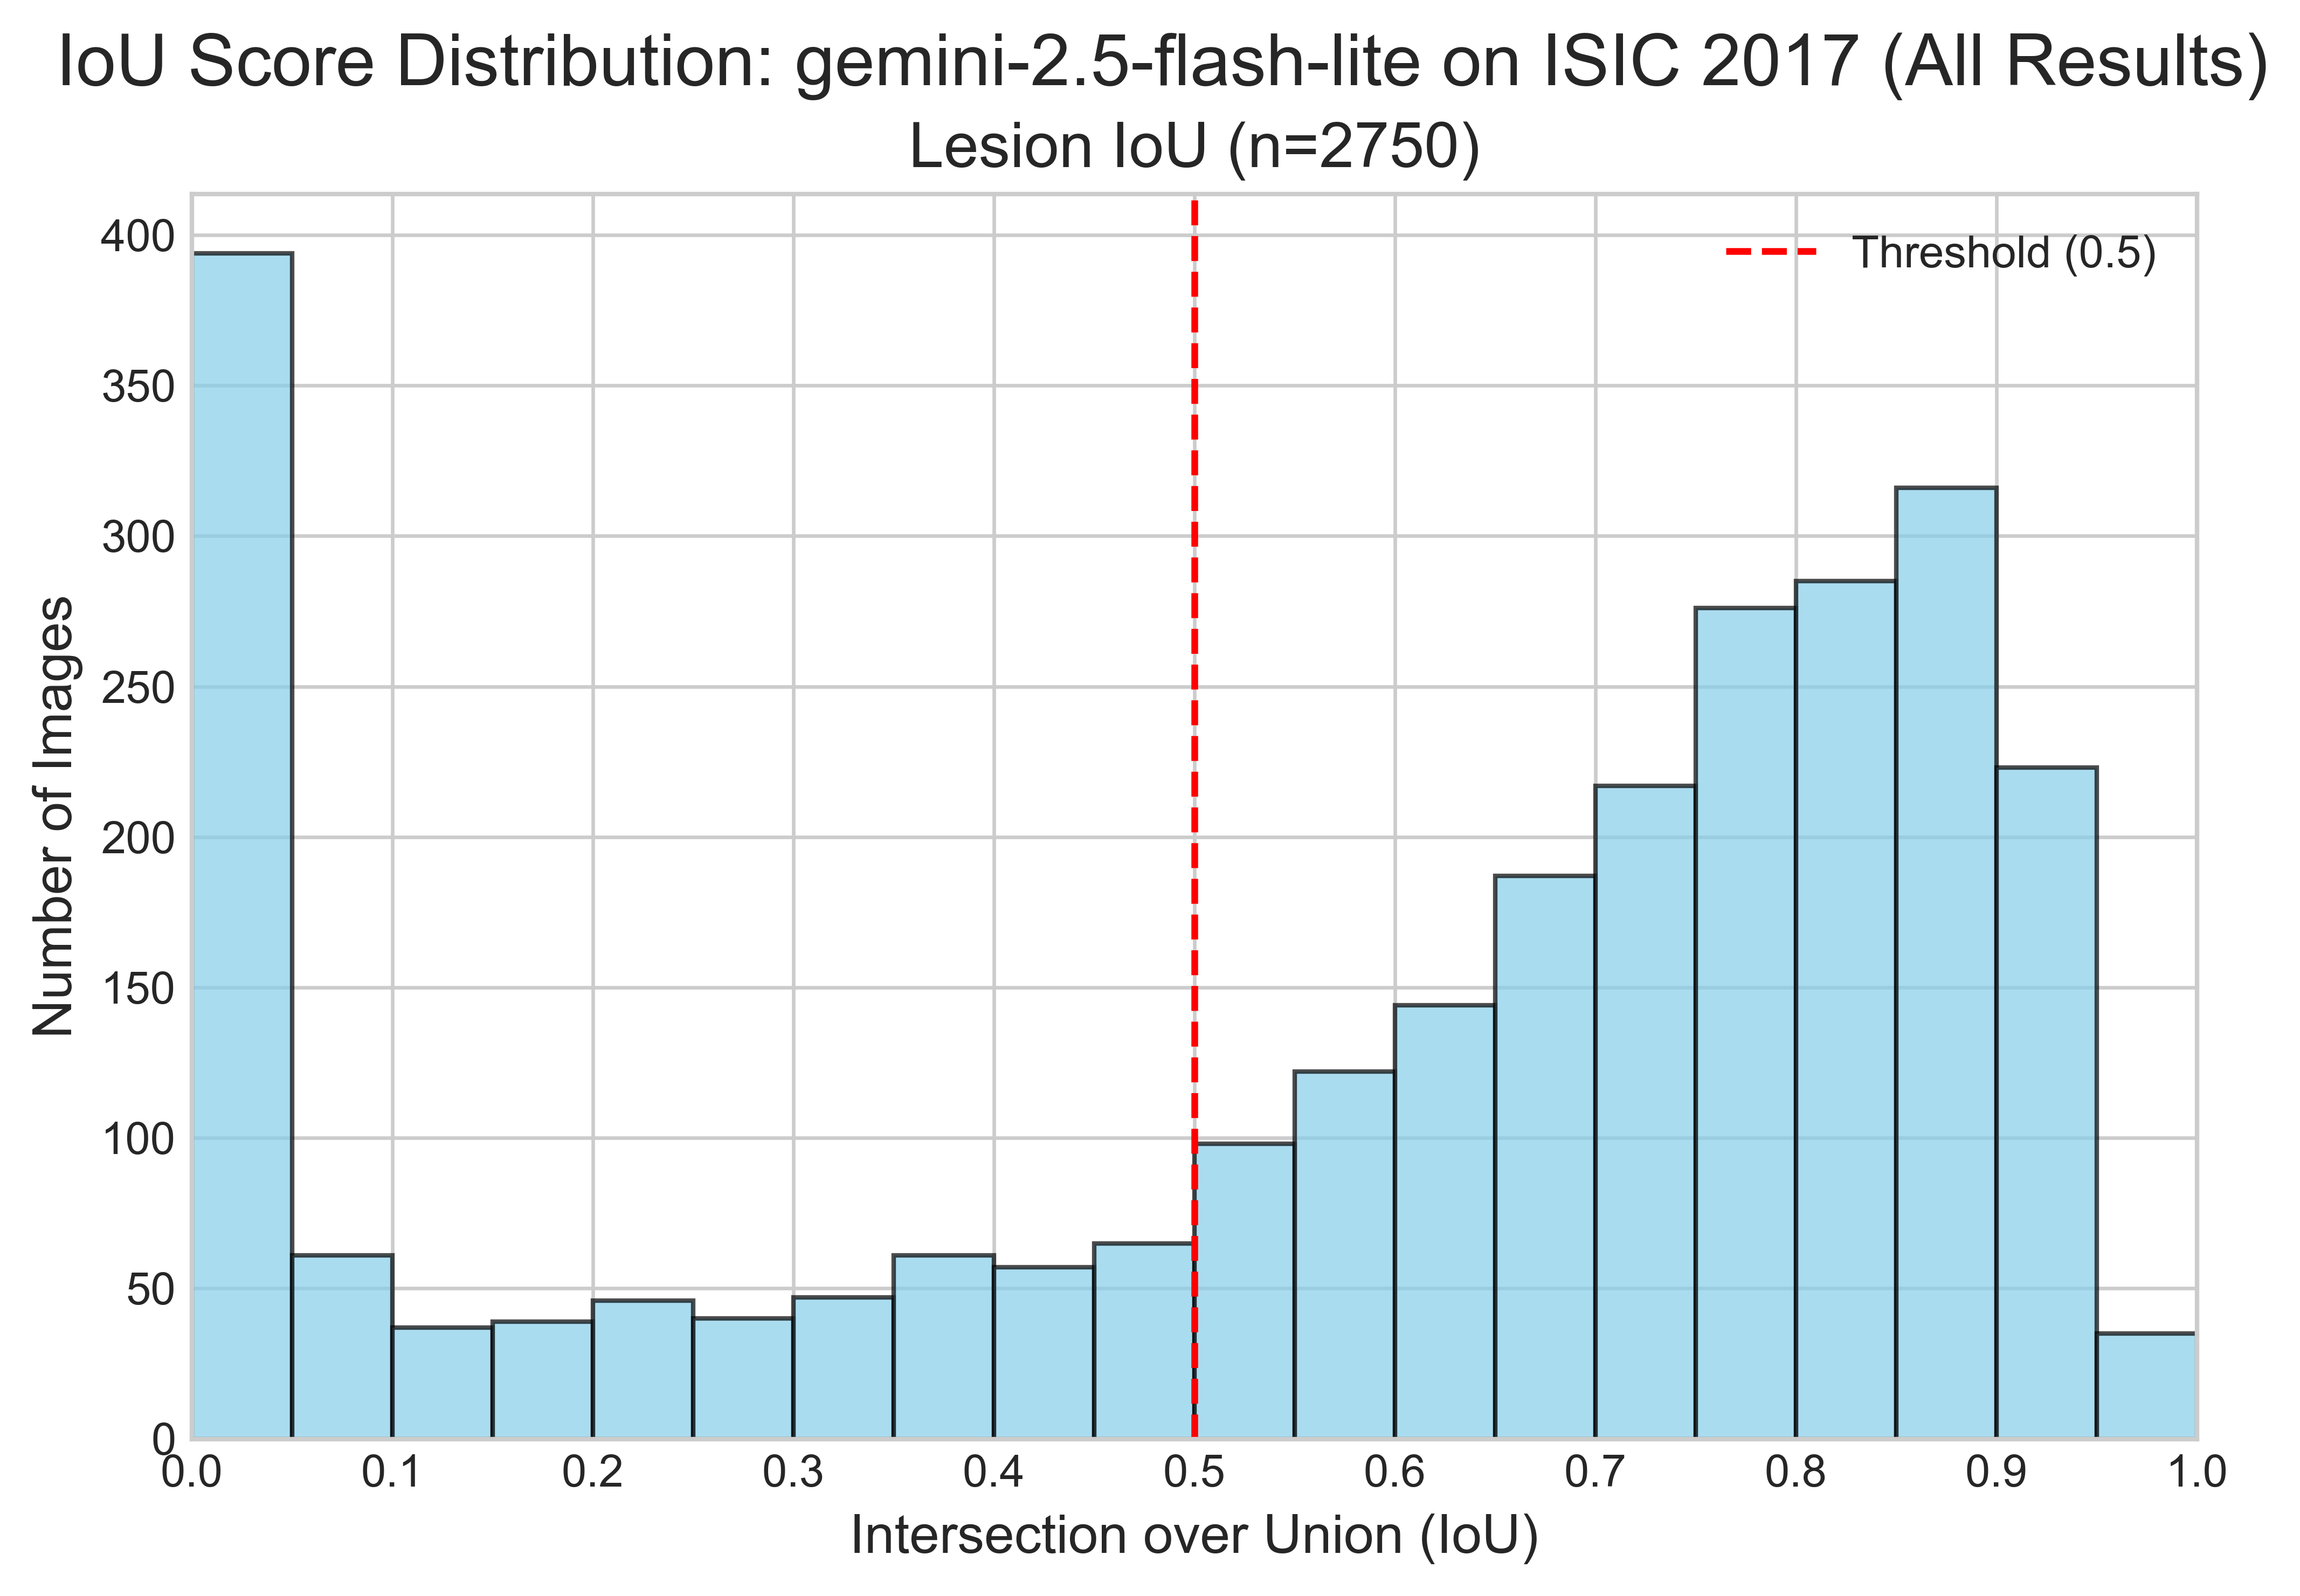

"\n✅ Evaluation complete. The report above summarizes the model's performance on the ISIC 2017 dataset.\n"

In [ ]:
# %% [markdown]
"""
# 07 ITA & Fitzpatrick Scale Classification (Refactored)

*Last sync 03 Aug 2025*

This script performs an automated Fitzpatrick skin type classification for the
ISIC 2017 dataset. It calculates the Individual Typology Angle (ITA) for each
image based on the color of non-lesional skin and then maps the ITA value to a
Fitzpatrick type (1-6).

**Methodology (Aligned with 04_Model_Evaluation):**
1.  Reads the master image list (`master_imagelist_isic.txt`) to ensure it
    processes the exact same set of images as the evaluation script.
2.  For each image, it loads the corresponding ground truth segmentation mask to
    identify and exclude the lesion area.
3.  Applies two data quality filters to the remaining non-lesional area:
    a.  **Luminance Filter:** Excludes pixels that are too dark or too bright.
    b.  **Area Filter:** Skips images where the valid skin area is too small.
4.  Calculates the average L* and b* values from the filtered, valid skin
    pixels in the CIE L*a*b* color space.
5.  Computes the ITA value and classifies it into a Fitzpatrick type (1-6).
6.  Aggregates all results and saves them to multiple outputs for robust analysis:
    - A detailed CSV file (`fitzpatrick_classification.csv`) with per-image data.
    - A JSON summary file (`summary_fitzpatrick_classification.json`) with run
      parameters and aggregated results.
    - A text file (`skipped_images_fitzpatrick.txt`) listing all images that
      could not be processed.
    - High-resolution plots of the ITA and Fitzpatrick type distributions.

This process is multithreaded to accelerate file I/O.
"""

# %%
# ---------- Preamble & Setup ----------
import sys
import logging
import os
import subprocess
import importlib.util
import json
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
from typing import Tuple, List, Optional, Dict
from datetime import datetime

import numpy as np
import pandas as pd
import cv2
from PIL import Image, UnidentifiedImageError
from tqdm import tqdm
import matplotlib.pyplot as plt


# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logging.info("Fitzpatrick classification script start.")


# %%
# ---------- Ensure helper packages ----------
def _ensure(pkg: str):
    """Checks if a package is installed and installs it if not."""
    if importlib.util.find_spec(pkg) is None:
        logging.info("Installing %s (missing)", pkg)
        if pkg == "cv2":
            pkg = "opencv-python-headless"
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])

for extra in ("tqdm", "numpy", "Pillow", "pandas", "cv2", "matplotlib"):
    _ensure(extra)


# %%
# ---------- Constants and Configuration (Aligned with Evaluation Script) ----------

# --- Paths ---
# MODIFIED: Standardized paths to match the evaluation script's structure.
DATASET_DIR = Path("data/ISIC_2017_Part1").expanduser().resolve()
IMAGE_DIR = DATASET_DIR / "image"
MASK_DIR = DATASET_DIR / "mask"
MASTER_LIST_PATH = DATASET_DIR / "master_imagelist_isic.txt"

# --- Outputs ---
OUTPUT_DIR = DATASET_DIR / "analysis_results"
OUTPUT_CSV_PATH = OUTPUT_DIR / "fitzpatrick_classification.csv"
OUTPUT_JSON_SUMMARY_PATH = OUTPUT_DIR / "summary_fitzpatrick_classification.json"
OUTPUT_SKIPPED_LIST_PATH = OUTPUT_DIR / "skipped_images_fitzpatrick.txt"
OUTPUT_PLOT_ITA_PATH = OUTPUT_DIR / "dist_ita_scores.png"
OUTPUT_PLOT_FITZPATRICK_PATH = OUTPUT_DIR / "dist_fitzpatrick_types.png"


# --- Analysis Parameters ---
MIN_SKIN_LIGHTNESS = 25
MAX_SKIN_LIGHTNESS = 95
MIN_SKIN_AREA_PERCENT = 0.05

# --- Concurrency ---
MAX_WORKERS = os.cpu_count() or 4


# %%
# ---------- Core Classification Functions ----------

def classify_fitzpatrick(ita: float) -> int:
    """Converts an ITA value to a Fitzpatrick skin type."""
    if ita > 55: return 1
    elif 41 < ita <= 55: return 2
    elif 28 < ita <= 41: return 3
    elif 19 < ita <= 28: return 4
    elif 10 < ita <= 19: return 5
    else: return 6

def calculate_and_classify(image_path: Path) -> Optional[Dict]:
    """
    Worker function to process a single image.
    Returns classification results or a status dictionary if skipped.
    """
    image_id = image_path.stem
    # MODIFIED: Standardized mask path construction.
    mask_path = MASK_DIR / f"{image_id}_Segmentation.png"

    try:
        if not image_path.exists() or not mask_path.exists():
            return {"image_id": image_id, "status": "error_file_not_found"}

        image_bgr = cv2.imread(str(image_path))
        lesion_mask_img = Image.open(mask_path).convert("L")
        lesion_mask = np.array(lesion_mask_img) > 127
        healthy_skin_mask = ~lesion_mask
        lab_image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
        l_channel = lab_image[:, :, 0]

        lightness_mask = (l_channel > MIN_SKIN_LIGHTNESS) & (l_channel < MAX_SKIN_LIGHTNESS)
        valid_skin_mask = healthy_skin_mask & lightness_mask

        valid_area_pct = np.sum(valid_skin_mask) / valid_skin_mask.size
        if valid_area_pct < MIN_SKIN_AREA_PERCENT:
            return {
                "image_id": image_id, "ita_score": None, "fitzpatrick_type": None,
                "valid_skin_area_pct": round(valid_area_pct, 4), "status": "skipped_insufficient_area"
            }

        l_values = lab_image[:, :, 0][valid_skin_mask]
        b_values = lab_image[:, :, 2][valid_skin_mask]
        avg_b_star = np.mean(b_values)
        if abs(avg_b_star) < 1e-6:
            return {
                "image_id": image_id, "ita_score": None, "fitzpatrick_type": None,
                "valid_skin_area_pct": round(valid_area_pct, 4), "status": "skipped_neutral_b_star"
            }

        avg_l_star = np.mean(l_values)
        ita_score = np.arctan((avg_l_star - 50) / avg_b_star) * (180 / np.pi)
        fitzpatrick_type = classify_fitzpatrick(ita_score)

        return {
            "image_id": image_id, "ita_score": round(ita_score, 4), "fitzpatrick_type": fitzpatrick_type,
            "valid_skin_area_pct": round(valid_area_pct, 4), "status": "processed"
        }

    except (UnidentifiedImageError, cv2.error) as e:
        logging.error(f"Error processing {image_id}: {e}")
        return {"image_id": image_id, "status": f"error_{type(e).__name__}"}
    except Exception as e:
        logging.error(f"An unexpected error occurred processing {image_id}: {e}", exc_info=False)
        return {"image_id": image_id, "status": "error_unexpected"}


# %%
# ---------- Main Execution Loop ----------
if __name__ == "__main__":
    # MODIFIED: Use master list for consistency, instead of globbing.
    if not MASTER_LIST_PATH.exists():
        raise FileNotFoundError(
            f"Master image list not found at {MASTER_LIST_PATH}. "
            "Please run the '04_Model_Evaluation' script first to generate it."
        )

    with open(MASTER_LIST_PATH, 'r') as f:
        images_to_process = [Path(line.strip()) for line in f.readlines()]

    logging.info(f"Found {len(images_to_process)} images to process from master list.")
    logging.info(f"Using up to {MAX_WORKERS} threads.")

    all_results = []
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        results_iterator = executor.map(calculate_and_classify, images_to_process)
        for result in tqdm(results_iterator, total=len(images_to_process), desc="Classifying Skin Types"):
            if result:
                all_results.append(result)

    # --- Aggregate, Display, and Save New Results ---
    if all_results:
        df = pd.DataFrame(all_results)
        df_processed = df[df['status'] == 'processed'].copy()
        # Ensure correct type for analysis
        if not df_processed.empty:
            df_processed['fitzpatrick_type'] = df_processed['fitzpatrick_type'].astype(int)

        # NEW: Separate skipped and processed images for reporting
        skipped_images = df[df['status'] != 'processed']

        print("\n---" * 15)
        print("      Fitzpatrick Skin Type Classification Summary")
        print("---" * 15)
        print(f"Total Images from Master List: {len(images_to_process)}")
        print(f"Successfully Processed:        {len(df_processed)}")
        print(f"Skipped or Errored Images:     {len(skipped_images)}")
        print("---\n")

        type_counts = {}
        if not df_processed.empty:
            type_counts_series = df_processed['fitzpatrick_type'].value_counts().sort_index()
            print("Distribution of Fitzpatrick Types:")
            print(type_counts_series.to_string())
            type_counts = type_counts_series.to_dict()
        else:
            print("No images were successfully processed to show a distribution.")
        print("\n---" * 15)

        # --- Save all outputs ---
        OUTPUT_DIR.mkdir(exist_ok=True)

        # 1. Save detailed CSV
        df.to_csv(OUTPUT_CSV_PATH, index=False)
        logging.info(f"Saved detailed per-image results to: {OUTPUT_CSV_PATH}")

        # 2. Save list of skipped files
        if not skipped_images.empty:
            skipped_images[['image_id', 'status']].to_csv(OUTPUT_SKIPPED_LIST_PATH, sep='\t', index=False)
            logging.info(f"Saved list of {len(skipped_images)} skipped images to: {OUTPUT_SKIPPED_LIST_PATH}")

        # 3. Save JSON summary
        summary_data = {
            "run_timestamp": datetime.now().isoformat(),
            "settings": {
                "min_skin_lightness": MIN_SKIN_LIGHTNESS,
                "max_skin_lightness": MAX_SKIN_LIGHTNESS,
                "min_skin_area_percent": MIN_SKIN_AREA_PERCENT,
            },
            "results": {
                "total_images_from_master_list": len(images_to_process),
                "processed_count": len(df_processed),
                "skipped_count": len(skipped_images),
                "fitzpatrick_type_distribution": {str(k): int(v) for k, v in type_counts.items()},
            }
        }
        with open(OUTPUT_JSON_SUMMARY_PATH, 'w') as f:
            json.dump(summary_data, f, indent=4)
        logging.info(f"Saved JSON summary to: {OUTPUT_JSON_SUMMARY_PATH}")

        # 4. Create and save visualizations
        plt.style.use('seaborn-v0_8-whitegrid')

        # Plot 1: ITA Score Distribution
        if not df_processed.empty:
            fig1, ax1 = plt.subplots(figsize=(10, 6), dpi=300)
            ax1.hist(df_processed['ita_score'], bins=30, edgecolor='black', alpha=0.75, color='teal')
            ax1.set_title(f'Distribution of ITA Scores (n={len(df_processed)})', fontsize=16)
            ax1.set_xlabel('Individual Typology Angle (ITA°)', fontsize=12)
            ax1.set_ylabel('Number of Images', fontsize=12)
            fig1.tight_layout()
            plt.savefig(OUTPUT_PLOT_ITA_PATH, bbox_inches='tight')
            logging.info(f"Saved ITA distribution plot to: {OUTPUT_PLOT_ITA_PATH}")

            # Plot 2: Fitzpatrick Type Distribution
            fig2, ax2 = plt.subplots(figsize=(10, 6), dpi=300)
            type_counts_series.plot(kind='bar', ax=ax2, color='cornflowerblue', edgecolor='black', width=0.8)
            ax2.set_title(f'Distribution of Fitzpatrick Types (n={len(df_processed)})', fontsize=16)
            ax2.set_xlabel('Fitzpatrick Skin Type', fontsize=12)
            ax2.set_ylabel('Number of Images', fontsize=12)
            ax2.tick_params(axis='x', rotation=0)
            # Add text labels on bars
            for container in ax2.containers:
                ax2.bar_label(container)
            fig2.tight_layout()
            plt.savefig(OUTPUT_PLOT_FITZPATRICK_PATH, bbox_inches='tight')
            logging.info(f"Saved Fitzpatrick distribution plot to: {OUTPUT_PLOT_FITZPATRICK_PATH}")
            plt.close('all') # Close plots to free memory

    else:
        logging.warning("No results were generated. Check for errors above.")

# %% [markdown]
"""
✅ Classification complete. The analysis has been saved to multiple files in the
`analysis_results` directory, including a detailed CSV, a JSON summary, a list
of skipped images, and distribution plots.
"""


# Case Plotting

In [ ]:
# %% [markdown]
"""
# 05 Qualitative Analysis (ISIC 2017)

*Last sync 02 Aug 2025*

This notebook provides tools to perform a qualitative check on the model's output from a previous evaluation run on the ISIC 2017 dataset. It loads a cached prediction from the model-specific `predictions_<model_name>/` directory and displays a three-panel comparison for any given image. This version uses multithreading to accelerate the search for matching cases.

**Instructions:**
- Ensure you have run the `04_Model_Evaluation_ISIC_2017` notebook first with `SAVE_PREDICTIONS = True`.
- Set the `MODEL_TO_VISUALIZE` variable in the last cell.
- To find the single best-performing case, set `FIND_BEST_IOU_CASE` to `True`.
- If `FIND_BEST_IOU_CASE` is `False`, set `FIND_HIGH_IOU_CASES` to `True` for cases with an IoU > 0.5, or `False` for cases with an IoU < 0.5.
- To visualize a specific image, set `IMAGE_TO_VISUALIZE` to a filename (e.g., `ISIC_0000000.jpg`). Otherwise, a case will be found based on the criteria above.
"""

# %%
# ---------- Preamble & Setup ----------
import os, json, base64, dataclasses, logging, io, random
from pathlib import Path
from typing import List, Tuple, Dict
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, UnidentifiedImageError
from dotenv import load_dotenv, find_dotenv

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)

# %%
# ---------- Dataset Path & Helper Functions ----------
dataset_dir = Path("data/ISIC_2017_Part1").expanduser().resolve()
if not dataset_dir.is_dir():
    raise FileNotFoundError(f"Dataset directory not found at {dataset_dir}.")
logging.info("ISIC 2017 dataset found at %s", dataset_dir)


@dataclasses.dataclass(frozen=True)
class SegmentationMask:
    """A dataclass to hold a single segmentation mask's data."""
    y0: int
    x0: int
    y1: int
    x1: int
    mask: np.ndarray # Full-size mask [img_height, img_width] with values 0..255
    label: str

def calculate_iou(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Calculates Intersection over Union (IoU) for boolean masks."""
    intersection = np.logical_and(y_true, y_pred)
    union = np.logical_or(y_true, y_pred)
    if np.sum(union) == 0:
        return 1.0
    iou_score = np.sum(intersection) / np.sum(union)
    return iou_score

def load_prediction_from_cache(prediction_path: Path) -> List[SegmentationMask]:
    """Loads and parses a cached prediction JSON file into SegmentationMask objects."""
    if not prediction_path.exists():
        return []
    
    with open(prediction_path, 'r') as f:
        try:
            items = json.load(f)
        except json.JSONDecodeError:
            logging.error(f"Could not decode JSON from cached file: {prediction_path}")
            return []

    masks = []
    for item in items:
        try:
            y0, x0, y1, x1 = item["box_2d_absolute"]
            label = item["label"]
            
            png_b64_str = item["mask_b64"]
            png_bytes = base64.b64decode(png_b64_str.removeprefix("data:image/png;base64,"))
            mask_img = Image.open(io.BytesIO(png_bytes))
            mask_np = np.array(mask_img)

            masks.append(SegmentationMask(y0, x0, y1, x1, mask_np, label))
        except (KeyError, IndexError, TypeError, base64.binascii.Error, UnidentifiedImageError) as e:
            logging.warning(f"Skipping malformed item in cached prediction: {item}. Error: {e}")
            continue
    return masks

def _process_prediction_file(pred_file: Path, images_dir: Path, masks_dir: Path) -> Tuple[str, float] | None:
    """Worker function to process a single ISIC prediction file and return its IoU score."""
    stem = pred_file.stem
    image_path = images_dir / f"{stem}.jpg"
    gt_mask_path = masks_dir / f"{stem}_Segmentation.png"
    
    if not (image_path.exists() and gt_mask_path.exists()):
        return None

    try:
        with Image.open(gt_mask_path) as gt_img:
            gt_mask_np = np.array(gt_img.convert("L")) > 127

        predicted_masks = load_prediction_from_cache(pred_file)
        
        combined_pred_mask_np = np.zeros_like(gt_mask_np, dtype=bool)
        if predicted_masks:
            for seg_mask in predicted_masks:
                pred_mask_binary = seg_mask.mask > 127
                combined_pred_mask_np = np.logical_or(combined_pred_mask_np, pred_mask_binary)
        
        iou_val = calculate_iou(gt_mask_np, combined_pred_mask_np)
        return (image_path.name, iou_val)

    except Exception as e:
        logging.warning(f"Skipping case {stem} due to an error during processing: {e}")
    return None

def find_matching_case(model_name: str, high_iou: bool, find_best: bool) -> str | None:
    """
    Scans predictions in parallel. Finds either the single best case or a random
    case matching the high/low IoU criteria for the ISIC 2017 dataset.
    """
    model_name_safe = model_name.replace("/", "_")
    predictions_dir = dataset_dir / f"predictions_{model_name_safe}"
    images_dir = dataset_dir / "image"
    masks_dir = dataset_dir / "mask"
    
    if not predictions_dir.exists():
        logging.error(f"Predictions directory not found for model '{model_name}': {predictions_dir}")
        return None

    prediction_files = list(predictions_dir.glob("*.json"))
    all_results = []
    
    with ThreadPoolExecutor() as executor:
        futures = [executor.submit(_process_prediction_file, pred_file, images_dir, masks_dir) for pred_file in prediction_files]
        for future in futures:
            result = future.result()
            if result:
                all_results.append(result)
            
    if not all_results:
        return None
    
    if find_best:
        best_case = max(all_results, key=lambda item: item[1])
        return best_case[0]
    else:
        # For low IoU, we are interested in poor predictions, not complete misses (IoU=0)
        iou_filter = (lambda iou: iou > 0.5) if high_iou else (lambda iou: 0 < iou < 0.5)
        valid_cases = [case for case in all_results if iou_filter(case[1])]
        
        if not valid_cases:
            return None
        
        return random.choice(valid_cases)[0]

def visualize_single_case(image_name: str, model_name: str):
    """
    Generates and displays a 3-panel plot for the ISIC 2017 dataset.
    """
    model_name_safe = model_name.replace("/", "_")
    image_path = dataset_dir / "image" / image_name
    gt_mask_name = f"{Path(image_name).stem}_Segmentation.png"
    gt_mask_path = dataset_dir / "mask" / gt_mask_name
    prediction_path = dataset_dir / f"predictions_{model_name_safe}" / f"{Path(image_name).stem}.json"
    
    if not all([image_path.exists(), gt_mask_path.exists(), prediction_path.exists()]):
        logging.error(f"Missing file. Image: {image_path.exists()}, GT: {gt_mask_path.exists()}, Pred: {prediction_path.exists()}")
        return

    original_image = Image.open(image_path).convert("RGBA")
    gt_mask_img = Image.open(gt_mask_path).convert("L")
    gt_mask_np = np.array(gt_mask_img) > 127
    predicted_masks = load_prediction_from_cache(prediction_path)

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    plt.style.use('default')

    axes[0].imshow(Image.open(image_path))
    axes[0].set_title(f"Original Image\n({image_name})", fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(gt_mask_img, cmap='gray')
    axes[1].set_title("Ground Truth Mask", fontsize=14)
    axes[1].axis('off')

    overlay_image = original_image.copy()
    title = f"Prediction: {model_name}"
    if not predicted_masks:
        title = f"Prediction: {model_name}\n(No Mask Found)"
    else:
        combined_pred_mask_np = np.zeros_like(gt_mask_np, dtype=bool)
        for seg_mask in predicted_masks:
            pred_mask_binary = seg_mask.mask > 127
            combined_pred_mask_np = np.logical_or(combined_pred_mask_np, pred_mask_binary)
        
        iou_val = calculate_iou(gt_mask_np, combined_pred_mask_np)
        title = f"Prediction: {model_name}\n({len(predicted_masks)} masks) IoU: {iou_val:.3f}"

        mask_color = (255, 0, 0, 90)
        box_color = (0, 255, 0)
        
        for mask_obj in predicted_masks:
            mask_img_pil = Image.fromarray(mask_obj.mask).convert("L")
            colored_mask = Image.new("RGBA", original_image.size)
            colored_mask.paste(mask_color, mask=mask_img_pil)
            overlay_image = Image.alpha_composite(overlay_image, colored_mask)
            draw = ImageDraw.Draw(overlay_image)
            draw.rectangle([mask_obj.x0, mask_obj.y0, mask_obj.x1, mask_obj.y1], outline=box_color, width=3)

    axes[2].imshow(overlay_image)
    axes[2].set_title(title, fontsize=14)
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# %% [markdown]
"""
### Visualize a Specific Image

To use this notebook, modify the variables below.
"""

# %%
# ---------- Specify Model and Image, then Run Visualization ----------

# <<< --- REQUIRED: Set the model name you want to visualize --- >>>
MODEL_TO_VISUALIZE = "gemini-2.5-flash"

# <<< --- OPTIONAL: Set to True to find the single best IoU case --- >>>
FIND_BEST_IOU_CASE = True

# <<< --- OPTIONAL: Set to True for high IoU (>0.5), False for low IoU (<0.5) --- >>>
# This is ignored if FIND_BEST_IOU_CASE is True.
FIND_HIGH_IOU_CASES = True

# <<< --- OPTIONAL: Set a specific filename to visualize --- >>>
IMAGE_TO_VISUALIZE = None # e.g., "ISIC_0000000.jpg"

# --- Find and Visualize a Case ---
if not MODEL_TO_VISUALIZE:
    logging.error("MODEL_TO_VISUALIZE is not set. Please specify a model name.")
else:
    if not IMAGE_TO_VISUALIZE:
        if FIND_BEST_IOU_CASE:
            logging.info(f"Searching for the single best IoU case for model '{MODEL_TO_VISUALIZE}'...")
        else:
            iou_search_term = "high" if FIND_HIGH_IOU_CASES else "low"
            logging.info(f"Searching for a random '{iou_search_term} IoU' case for model '{MODEL_TO_VISUALIZE}'...")
        
        IMAGE_TO_VISUALIZE = find_matching_case(MODEL_TO_VISUALIZE, FIND_HIGH_IOU_CASES, FIND_BEST_IOU_CASE)
        
        if IMAGE_TO_VISUALIZE:
            logging.info(f"Found matching case: '{IMAGE_TO_VISUALIZE}'. Visualizing...")
        else:
            search_type = "best" if FIND_BEST_IOU_CASE else ("high" if FIND_HIGH_IOU_CASES else "low")
            logging.error(f"Could not find any '{search_type} IoU' case for model '{MODEL_TO_VISUALIZE}'.")
            logging.error("Please ensure you have run the `04_Model_Evaluation_ISIC_2017` notebook for this model.")

    if IMAGE_TO_VISUALIZE:
        if not (dataset_dir / "image" / IMAGE_TO_VISUALIZE).exists():
            logging.error(f"The specified or found image '{IMAGE_TO_VISUALIZE}' does not exist in the images directory.")
        else:
            visualize_single_case(IMAGE_TO_VISUALIZE, MODEL_TO_VISUALIZE)


2025-08-03 14:50:26 — INFO — ISIC 2017 dataset found at D:\Projects\gemini_image_segmentation\data\ISIC_2017_Part1
2025-08-03 14:50:26 — INFO — Searching for the single best IoU case for model 'gemini-2.5-flash'...


# Performance Metrics Re-Evaluation

TODO: Not confirmed to be working yet

2025-08-01 15:04:37 — INFO — Re-analysis notebook start.
2025-08-01 15:04:37 — INFO — Installing python-dotenv (missing)
2025-08-01 15:04:38 — INFO — Installing Pillow (missing)
2025-08-01 15:04:39 — INFO — REFUGE2 dataset found at D:\Projects\gemini_image_segmentation\data\REFUGE2
2025-08-01 15:04:39 — INFO — Found 1200 cached predictions for model 'gemini-2.5-flash-lite'.
2025-08-01 15:04:39 — INFO — Starting re-analysis with up to 12 threads.


Re-analyzing gemini-2.5-flash-lite:   0%|          | 0/1200 [00:00<?, ?it/s]

2025-08-01 15:05:57 — INFO — Excluding cases with IoU < 0.5 from stats calculations.
2025-08-01 15:05:57 — INFO — Saved re-analysis summary to D:\Projects\gemini_image_segmentation\data\REFUGE2\reanalysis_summary_gemini-2.5-flash-lite_thresh_0.5.json


---------------------------------------------
       Re-Analysis Report: gemini-2.5-flash-lite on REFUGE2
---------------------------------------------
Total Cached Predictions Analyzed: 1200
New IoU Threshold for Success:     0.5
Excluding Low IoU from Stats:    True

--- Performance Metrics ---
Mean IoU (Disc):      0.6694 (95% CI: 0.6587 - 0.6798) on 342 images
Mean IoU (Cup):       0.6178 (95% CI: 0.5998 - 0.6388) on 77 images
Mean Dice (Disc):     0.7974 (95% CI: 0.7895 - 0.8055)
Mean Dice (Cup):      0.7605 (95% CI: 0.7466 - 0.7751)

--- Clinical Metric ---
vCDR MAE:             0.2259 (95% CI: 0.2172 - 0.2341)

--- Failure Analysis (New Threshold) ---
False Negatives (Disc / Cup): 11 (0.9%) / 444 (37.0%)
Low IoU Failures (Disc / Cup): 847 (70.6%) / 679 (56.6%)
---------------------------------------------


2025-08-01 15:05:59 — INFO — Saved re-analysis IoU plot to D:\Projects\gemini_image_segmentation\data\REFUGE2\reanalysis_iou_dist_gemini-2.5-flash-lite_thresh_0.5.png


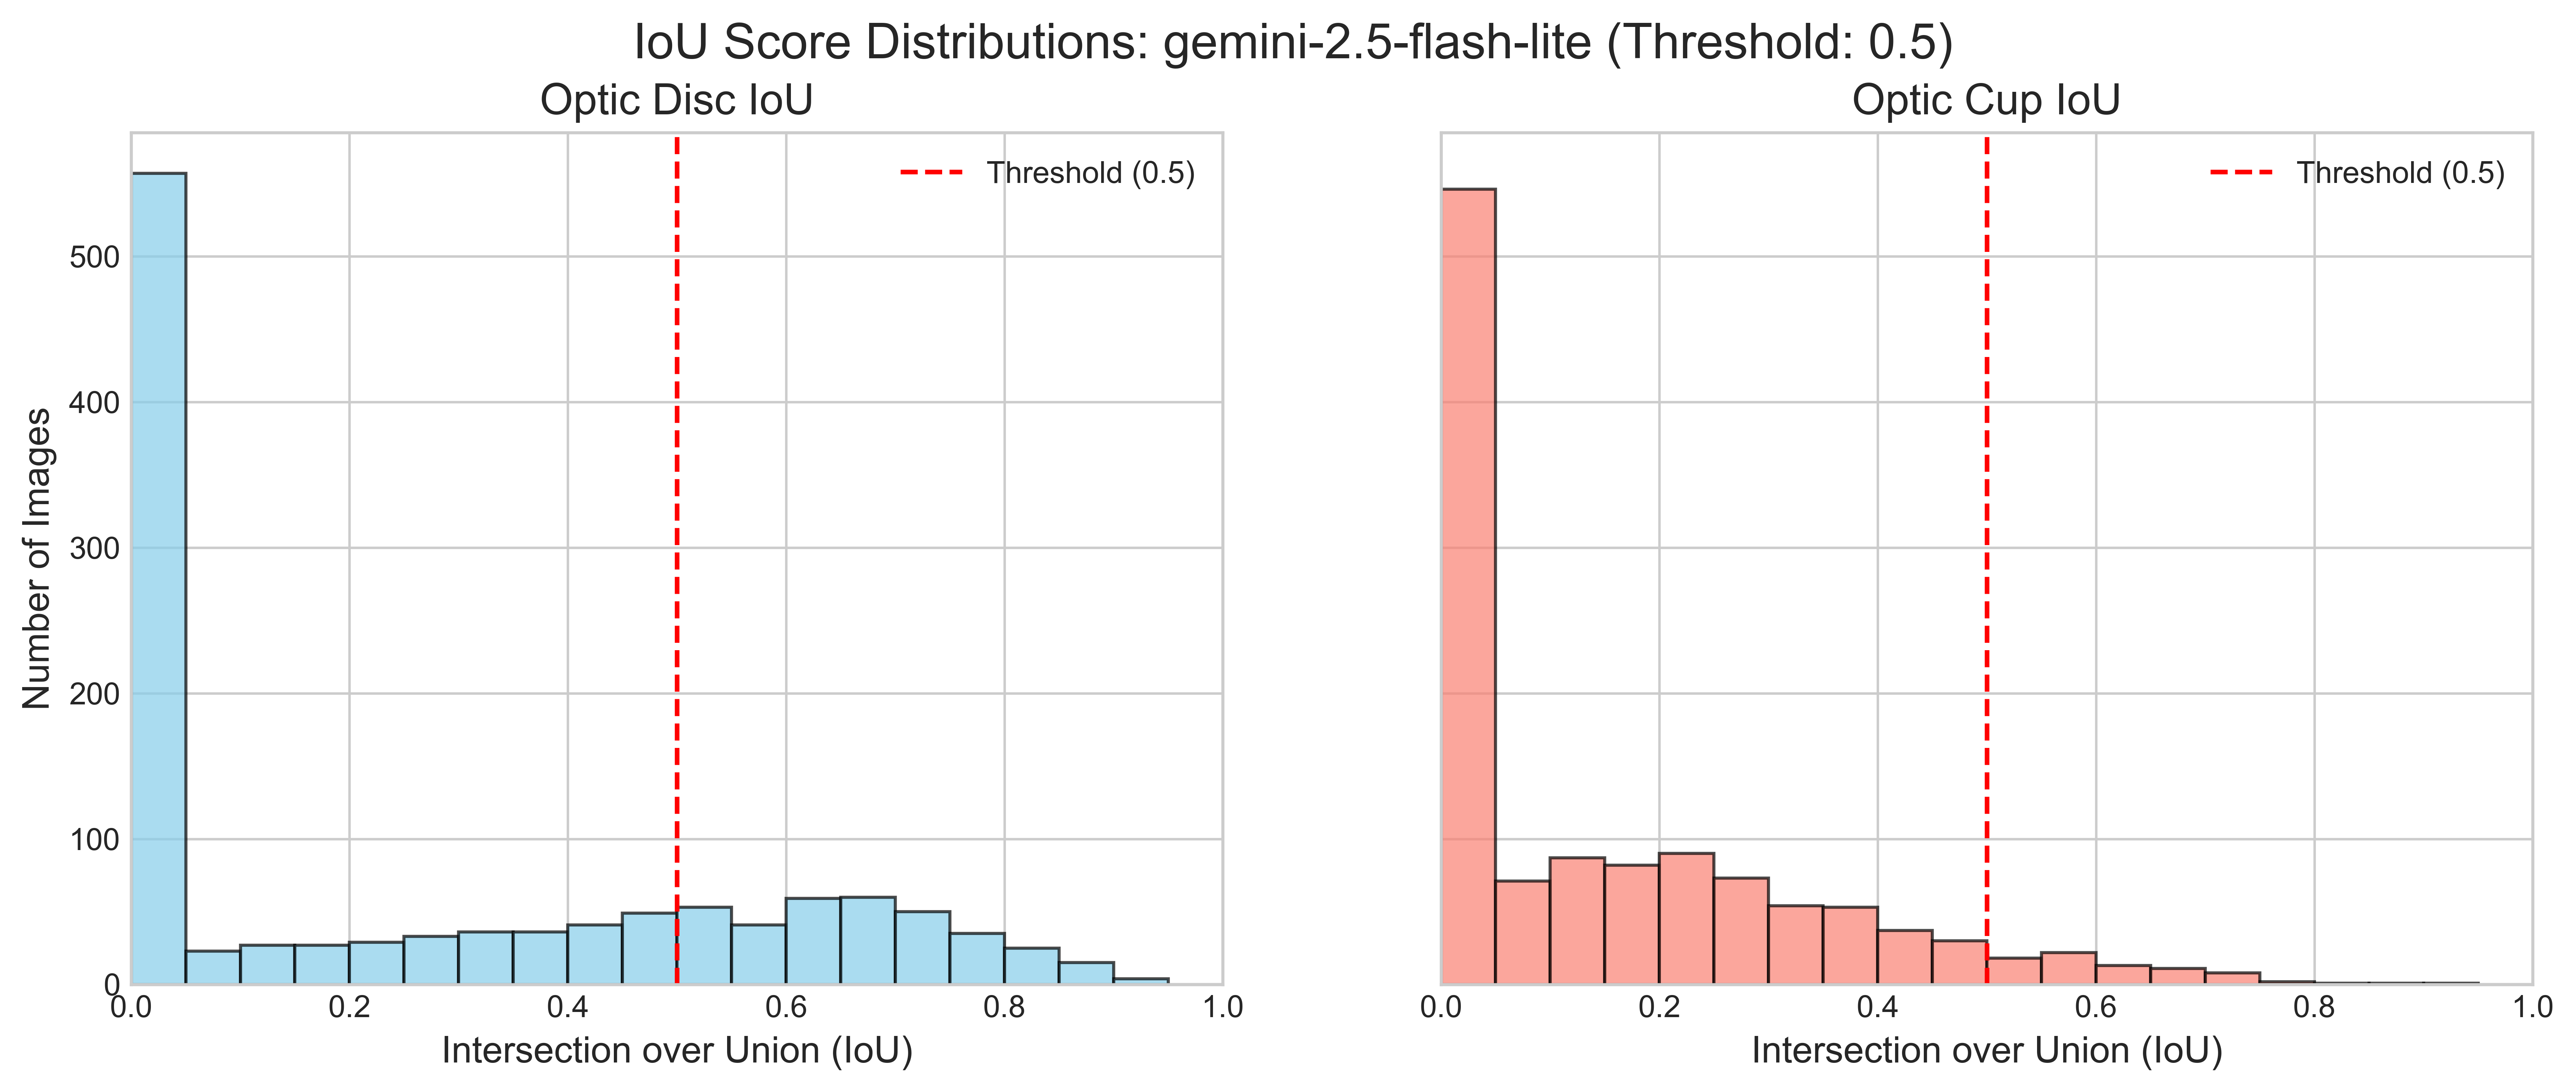

"\n✅ Re-analysis complete. The report above summarizes the model's performance using the new threshold.\n"

In [ ]:
# %% [markdown]
"""
# 06 Skin Lesion Results Re-Analysis Tool (Multithreaded)

*Last sync 01 Aug 2025*

This notebook re-calculates and re-plots evaluation metrics from a completed run's
cached predictions for the ISIC 2017 skin lesion segmentation task. It uses
multithreading to accelerate the processing of cached files.

**Instructions:**
1.  Ensure you have run the `04_Model_Evaluation_ISIC_2017` notebook with
    `SAVE_PREDICTIONS = True`.
2.  Set the `MODEL_TO_ANALYZE` variable below to the model you want to inspect.
3.  Set the `NEW_LOW_IOU_THRESHOLD` to the desired value for defining a "successful" detection.
4.  Use the `EXCLUDE_LOW_IOU_FROM_STATS` toggle to control the analysis behavior:
    - `True`: (Default) Excludes low-IoU cases from summary statistics (mean, CI).
      The plot will still show all cases but with a red threshold line.
    - `False`: Includes all cases (even IoU=0) in summary statistics.
      This gives a view of performance across the entire dataset.
"""

# %%
# ---------- Preamble & Setup ----------
import sys, logging, os, subprocess, importlib.util, json, io, base64, dataclasses
from datetime import datetime
from pathlib import Path
from typing import Tuple, List, Optional, Dict
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
from tqdm.notebook import tqdm
from dotenv import load_dotenv, find_dotenv

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logging.info("Re-analysis notebook start.")

# %%
# ---------- Ensure helper packages ----------
def _ensure(pkg: str):
    """Checks if a package is installed and installs it if not."""
    if importlib.util.find_spec(pkg) is None:
        logging.info("Installing %s (missing)", pkg)
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])

for extra in ("python-dotenv", "tqdm", "matplotlib", "numpy", "Pillow", "pandas"):
    _ensure(extra)

# %%
# ---------- Dataset Path & Helper Functions ----------
# MODIFIED: Point to the ISIC 2017 dataset directory.
dataset_dir = Path("data/ISIC_2017_Part1").expanduser().resolve()
if not dataset_dir.is_dir():
    raise FileNotFoundError(f"Dataset directory not found at {dataset_dir}.")
logging.info("ISIC 2017 dataset found at %s", dataset_dir)


def load_prediction_from_cache(prediction_path: Path, target_shape: Tuple[int, int]) -> np.ndarray:
    """
    Loads a cached prediction JSON, combines all masks into one, and returns a single boolean mask.
    """
    default_mask = np.zeros(target_shape, dtype=bool)
    if not prediction_path.exists():
        logging.error(f"Prediction cache file not found: {prediction_path}")
        return default_mask

    with open(prediction_path, 'r') as f:
        try:
            items = json.load(f)
        except json.JSONDecodeError:
            logging.error(f"Could not decode JSON from cached file: {prediction_path}")
            return default_mask

    if not items:
        return default_mask # Return empty mask if prediction was empty list

    # Combine all predicted masks for the single class "lesion"
    combined_mask_np = np.zeros(target_shape, dtype=bool)
    for item in items:
        try:
            png_b64_str = item["mask_b64"]
            png_bytes = base64.b64decode(png_b64_str.removeprefix("data:image/png;base64,"))
            mask_img = Image.open(io.BytesIO(png_bytes))
            mask_np = np.array(mask_img)
            # Ensure mask is boolean and combine with logical OR
            combined_mask_np = np.logical_or(combined_mask_np, mask_np > 127)
        except (KeyError, IndexError, TypeError, base64.binascii.Error, UnidentifiedImageError) as e:
            logging.warning(f"Skipping malformed item in cached prediction: {item}. Error: {e}")
            continue
    return combined_mask_np

def parse_ground_truth_mask(mask_path: Path) -> Tuple[Optional[np.ndarray], Tuple[int, int]]:
    """
    Parses an ISIC 2017 ground truth PNG file into a binarized boolean NumPy array.
    Returns the boolean mask and its shape.
    """
    try:
        mask_img = Image.open(mask_path).convert("L")
        mask_data = np.array(mask_img)
        return mask_data > 127, mask_data.shape
    except (FileNotFoundError, UnidentifiedImageError) as e:
        logging.error("Could not read ground truth mask file %s: %s", mask_path, e)
        return None, (0, 0)

# %%
# ---------- Metric Calculation Functions ----------

def calculate_iou(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Calculates Intersection over Union (IoU) for boolean masks."""
    intersection = np.logical_and(y_true, y_pred)
    union = np.logical_or(y_true, y_pred)
    if np.sum(union) == 0: return 1.0 # Perfect match if both are empty
    return np.sum(intersection) / np.sum(union)

def calculate_dice(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Calculates the Dice Coefficient for boolean masks."""
    intersection = np.sum(np.logical_and(y_true, y_pred))
    denominator = np.sum(y_true) + np.sum(y_pred)
    if denominator == 0: return 1.0 # Perfect match if both are empty
    return (2. * intersection) / (denominator + 1e-7) # Add epsilon for stability

def calculate_bootstrap_ci(data: List[float], n_resamples: int = 1000) -> Tuple[float, float]:
    """Calculates the 95% confidence interval for a list of numbers using bootstrapping."""
    if not data or len(data) < 2: return 0.0, 0.0
    bootstrapped_means = [np.mean(np.random.choice(data, size=len(data), replace=True)) for _ in range(n_resamples)]
    return np.percentile(bootstrapped_means, 2.5), np.percentile(bootstrapped_means, 97.5)

# %% [markdown]
"""
### Re-Analysis Execution

This section loads the cached predictions, recalculates all metrics in parallel, and then generates a new report and plot based on the parameters you set below.
"""

# %%
# ---------- Main Re-Analysis Loop ----------

# <<< --- PARAMETERS TO CONTROL THE RE-ANALYSIS --- >>>
MODEL_TO_ANALYZE = "gemini-2.5-flash"
NEW_LOW_IOU_THRESHOLD = 0.75
EXCLUDE_LOW_IOU_FROM_STATS = True # Set to False to include all cases in stats/plots
MAX_WORKERS = os.cpu_count() or 4 # Use all available CPU cores, or default to 4

# --- Setup paths and find prediction files ---
model_name_safe = MODEL_TO_ANALYZE.replace("/", "_")
predictions_dir = dataset_dir / f"predictions_{model_name_safe}"
if not predictions_dir.is_dir():
    raise FileNotFoundError(f"Predictions directory not found for model '{MODEL_TO_ANALYZE}'. Please run the evaluation script first with SAVE_PREDICTIONS=True.")

prediction_files = list(predictions_dir.glob("*.json"))
if not prediction_files:
    raise FileNotFoundError(f"No prediction files found in {predictions_dir}.")

logging.info(f"Found {len(prediction_files)} cached predictions for model '{MODEL_TO_ANALYZE}'.")
logging.info(f"Starting re-analysis with up to {MAX_WORKERS} threads.")

# --- Worker function for parallel processing ---
def process_single_prediction(pred_path: Path) -> Optional[Dict]:
    """Processes a single prediction file to calculate metrics for the ISIC dataset."""
    image_stem = pred_path.stem

    # MODIFIED: Construct the ground truth mask path using the ISIC naming convention.
    mask_path = dataset_dir / "mask" / f"{image_stem}_Segmentation.png"
    if not mask_path.exists():
        # Suppress logging for cleaner parallel output, return None on failure
        return None

    gt_mask, gt_shape = parse_ground_truth_mask(mask_path)
    if gt_mask is None:
        return None

    predicted_mask = load_prediction_from_cache(pred_path, target_shape=gt_shape)

    # Recalculate all metrics
    iou = calculate_iou(gt_mask, predicted_mask)
    dice = calculate_dice(gt_mask, predicted_mask)

    return {"image_path": mask_path.name, "iou": iou, "dice": dice}

# --- Recalculate metrics in parallel ---
recalculated_results = []
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    # Use tqdm to show progress over the iterator returned by executor.map
    results_iterator = executor.map(process_single_prediction, prediction_files)
    for result in tqdm(results_iterator, total=len(prediction_files), desc=f"Re-analyzing {model_name_safe}"):
        if result is not None:
            recalculated_results.append(result)


# %% [markdown]
"""
### New Results Summary

The following report is generated from the recalculated metrics using your specified IoU threshold.
"""

# %%
# ---------- Aggregate, Display, and Save New Results ----------

if recalculated_results:
    df = pd.DataFrame(recalculated_results)

    # --- Determine which data to use for STATS based on the toggle ---
    if EXCLUDE_LOW_IOU_FROM_STATS:
        logging.info(f"Excluding cases with IoU < {NEW_LOW_IOU_THRESHOLD} from stats calculations.")
        runs_for_stats = df[df['iou'] >= NEW_LOW_IOU_THRESHOLD]
    else:
        logging.info("Including all cases (even IoU=0) in stats calculations.")
        runs_for_stats = df

    # --- Performance Metrics ---
    mean_iou = runs_for_stats['iou'].mean() if not runs_for_stats.empty else 0
    mean_dice = runs_for_stats['dice'].mean() if not runs_for_stats.empty else 0

    # --- Failure Analysis (based on the new threshold) ---
    total_runs = len(df)
    num_false_negatives = len(df[df['iou'] == 0])
    num_low_iou_failures = len(df[(df['iou'] > 0) & (df['iou'] < NEW_LOW_IOU_THRESHOLD)])

    # --- Confidence Intervals ---
    iou_ci = calculate_bootstrap_ci(runs_for_stats['iou'].tolist())
    dice_ci = calculate_bootstrap_ci(runs_for_stats['dice'].tolist())

    print("---" * 15)
    print(f"       Skin Lesion Segmentation Re-Analysis Report: {MODEL_TO_ANALYZE}")
    print("---" * 15)
    print(f"Total Cached Predictions Analyzed: {total_runs}")
    print(f"New IoU Threshold for Success:     {NEW_LOW_IOU_THRESHOLD}")
    print(f"Excluding Low IoU from Stats:      {EXCLUDE_LOW_IOU_FROM_STATS}")

    print("\n--- Performance Metrics ---")
    print(f"Mean IoU:                      {mean_iou:.4f} (95% CI: {iou_ci[0]:.4f} - {iou_ci[1]:.4f}) on {len(runs_for_stats)} images")
    print(f"Mean Dice Coefficient:         {mean_dice:.4f} (95% CI: {dice_ci[0]:.4f} - {dice_ci[1]:.4f})")

    print("\n--- Failure Analysis (New Threshold) ---")
    print(f"False Negatives (IoU=0): {num_false_negatives} ({num_false_negatives/total_runs:.1%})")
    print(f"Low IoU Failures:        {num_low_iou_failures} ({num_low_iou_failures/total_runs:.1%})")
    print("---" * 15)
    
    # --- Create and save summary dictionary ---
    summary_data = {
        "reanalysis_timestamp": datetime.now().isoformat(),
        "total_cached_predictions_analyzed": total_runs,
        "settings": {
            "model_analyzed": MODEL_TO_ANALYZE,
            "new_low_iou_threshold": NEW_LOW_IOU_THRESHOLD,
            "excluded_low_iou_from_stats": EXCLUDE_LOW_IOU_FROM_STATS,
        },
        "performance_metrics": {
            "mean_iou": mean_iou,
            "mean_dice": mean_dice,
            "mean_iou_95_ci": iou_ci,
            "mean_dice_95_ci": dice_ci,
            "num_images_in_stat_calc": len(runs_for_stats),
        },
        "failure_counts": {
            "false_negatives": num_false_negatives,
            "low_iou_failures": num_low_iou_failures,
        }
    }
    
    summary_path = dataset_dir / f"reanalysis_summary_isic_{model_name_safe}_thresh_{NEW_LOW_IOU_THRESHOLD}.json"
    with open(summary_path, 'w') as f:
        json.dump(summary_data, f, indent=4)
    logging.info(f"Saved re-analysis summary to {summary_path}")


    # --- Visualize and save the distribution of IoU scores ---
    # PLOT WILL ALWAYS SHOW ALL DATA, regardless of the stats toggle.
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(10, 6), dpi=600)
    fig.suptitle(f'IoU Score Distribution (ISIC 2017): {MODEL_TO_ANALYZE}', fontsize=16)

    ax.hist(df['iou'], bins=20, range=(0,1), edgecolor='black', alpha=0.75, color='cornflowerblue')
    ax.set_title(f'Lesion Segmentation IoU (n={total_runs})', fontsize=14)
    ax.set_xlabel('Intersection over Union (IoU)', fontsize=12)
    ax.set_ylabel('Number of Images', fontsize=12)
    ax.axvline(NEW_LOW_IOU_THRESHOLD, color='r', linestyle='--', label=f'Threshold ({NEW_LOW_IOU_THRESHOLD})')
    ax.legend()
    ax.set_xlim(0, 1)
    ax.set_xticks(np.arange(0, 1.1, 0.1))

    plot_path = dataset_dir / f"reanalysis_iou_dist_isic_{model_name_safe}_thresh_{NEW_LOW_IOU_THRESHOLD}.png"
    plt.savefig(plot_path, bbox_inches='tight')
    logging.info(f"Saved re-analysis IoU plot to {plot_path}")
    plt.show()
else:
    print("No recalculated results were generated. Check if prediction files exist.")

# %% [markdown]
"""
✅ Re-analysis complete. The report above summarizes the model's performance using the new threshold.
"""


# Fitzpatrick Scale Classification

In [2]:
# %% [markdown]
"""
# 07 ITA & Fitzpatrick Scale Classification (Refactored)

*Last sync 03 Aug 2025*

This script performs an automated Fitzpatrick skin type classification for the
ISIC 2017 dataset. It calculates the Individual Typology Angle (ITA) for each
image based on the color of non-lesional skin and then maps the ITA value to a
Fitzpatrick type (1-6).

**Methodology (Aligned with 04_Model_Evaluation):**
1.  Reads the master image list (`master_imagelist_isic.txt`) to ensure it
    processes the exact same set of images as the evaluation script.
2.  For each image, it loads the corresponding ground truth segmentation mask to
    identify and exclude the lesion area.
3.  Applies two data quality filters to the remaining non-lesional area:
    a.  **Luminance Filter:** Excludes pixels that are too dark or too bright.
    b.  **Area Filter:** Skips images where the valid skin area is too small.
4.  Calculates the average L* and b* values from the filtered, valid skin
    pixels in the CIE L*a*b* color space.
5.  Computes the ITA value and classifies it into a Fitzpatrick type (1-6).
6.  Aggregates all results and saves them to multiple outputs for robust analysis:
    - A detailed CSV file (`fitzpatrick_classification.csv`) with per-image data.
    - A JSON summary file (`summary_fitzpatrick_classification.json`) with run
      parameters and aggregated results.
    - A text file (`skipped_images_fitzpatrick.txt`) listing all images that
      could not be processed.
    - High-resolution plots of the ITA and Fitzpatrick type distributions.

This process is multithreaded to accelerate file I/O.
"""

# %%
# ---------- Preamble & Setup ----------
import sys
import logging
import os
import subprocess
import importlib.util
import json
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
from typing import Tuple, List, Optional, Dict
from datetime import datetime

import numpy as np
import pandas as pd
import cv2
from PIL import Image, UnidentifiedImageError
from tqdm import tqdm
import matplotlib.pyplot as plt


# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logging.info("Fitzpatrick classification script start.")


# %%
# ---------- Ensure helper packages ----------
def _ensure(pkg: str):
    """Checks if a package is installed and installs it if not."""
    if importlib.util.find_spec(pkg) is None:
        logging.info("Installing %s (missing)", pkg)
        if pkg == "cv2":
            pkg = "opencv-python-headless"
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])

for extra in ("tqdm", "numpy", "Pillow", "pandas", "cv2", "matplotlib"):
    _ensure(extra)


# %%
# ---------- Constants and Configuration (Aligned with Evaluation Script) ----------

# --- Paths ---
DATASET_DIR = Path("data/ISIC_2017_Part1").expanduser().resolve()
IMAGE_DIR = DATASET_DIR / "image"
MASK_DIR = DATASET_DIR / "mask"
MASTER_LIST_PATH = DATASET_DIR / "master_imagelist_isic.txt"

# --- Outputs ---
OUTPUT_DIR = DATASET_DIR / "analysis_results"
OUTPUT_CSV_PATH = OUTPUT_DIR / "fitzpatrick_classification.csv"
OUTPUT_JSON_SUMMARY_PATH = OUTPUT_DIR / "summary_fitzpatrick_classification.json"
OUTPUT_SKIPPED_LIST_PATH = OUTPUT_DIR / "skipped_images_fitzpatrick.txt"
OUTPUT_PLOT_ITA_PATH = OUTPUT_DIR / "dist_ita_scores.png"
OUTPUT_PLOT_FITZPATRICK_PATH = OUTPUT_DIR / "dist_fitzpatrick_types.png"


# --- Analysis Parameters ---
MIN_SKIN_LIGHTNESS = 25
MAX_SKIN_LIGHTNESS = 95
MIN_SKIN_AREA_PERCENT = 0.05

# --- Concurrency ---
MAX_WORKERS = os.cpu_count() or 4


# %%
# ---------- Core Classification Functions ----------

def classify_fitzpatrick(ita: float) -> int:
    """Converts an ITA value to a Fitzpatrick skin type."""
    if ita > 55: return 1
    elif 41 < ita <= 55: return 2
    elif 28 < ita <= 41: return 3
    elif 19 < ita <= 28: return 4
    elif 10 < ita <= 19: return 5
    else: return 6

def calculate_and_classify(image_path: Path) -> Optional[Dict]:
    """
    Worker function to process a single image.
    Returns classification results or a status dictionary if skipped.
    """
    image_id = image_path.stem
    mask_path = MASK_DIR / f"{image_id}_Segmentation.png"

    try:
        if not image_path.exists() or not mask_path.exists():
            return {"image_id": image_id, "status": "error_file_not_found"}

        image_bgr = cv2.imread(str(image_path))
        lesion_mask_img = Image.open(mask_path).convert("L")
        lesion_mask = np.array(lesion_mask_img) > 127
        healthy_skin_mask = ~lesion_mask
        
        lab_image_uint8 = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)

        # --- BUG FIX: Convert L*a*b* channels to their standard float ranges ---
        # OpenCV's L*a*b* for uint8 is L*=[0,255], a*=[0,255], b*=[0,255].
        # The theoretical range is L*=[0,100], a*=[-127,127], b*=[-127,127].
        # All filters and formulas must use the theoretical range.
        l_channel_float = lab_image_uint8[:, :, 0].astype(np.float32) * (100.0 / 255.0)
        b_channel_float = lab_image_uint8[:, :, 2].astype(np.float32) - 128.0

        # 4. Apply data quality filters using the correctly scaled L* channel
        lightness_mask = (l_channel_float > MIN_SKIN_LIGHTNESS) & (l_channel_float < MAX_SKIN_LIGHTNESS)
        valid_skin_mask = healthy_skin_mask & lightness_mask

        # Check if enough valid skin area exists
        valid_area_pct = np.sum(valid_skin_mask) / valid_skin_mask.size
        if valid_area_pct < MIN_SKIN_AREA_PERCENT:
            return {
                "image_id": image_id, "ita_score": None, "fitzpatrick_type": None,
                "valid_skin_area_pct": round(valid_area_pct, 4), "status": "skipped_insufficient_area"
            }

        # 5. Calculate ITA from valid skin pixels using the correctly scaled float values
        l_values = l_channel_float[valid_skin_mask]
        b_values = b_channel_float[valid_skin_mask]

        avg_b_star = np.mean(b_values)
        if abs(avg_b_star) < 1e-6:
            return {
                "image_id": image_id, "ita_score": None, "fitzpatrick_type": None,
                "valid_skin_area_pct": round(valid_area_pct, 4), "status": "skipped_neutral_b_star"
            }

        avg_l_star = np.mean(l_values)
        ita_score = np.arctan((avg_l_star - 50) / avg_b_star) * (180 / np.pi)
        fitzpatrick_type = classify_fitzpatrick(ita_score)

        return {
            "image_id": image_id, "ita_score": round(ita_score, 4), "fitzpatrick_type": fitzpatrick_type,
            "valid_skin_area_pct": round(valid_area_pct, 4), "status": "processed"
        }

    except (UnidentifiedImageError, cv2.error) as e:
        logging.error(f"Error processing {image_id}: {e}")
        return {"image_id": image_id, "status": f"error_{type(e).__name__}"}
    except Exception as e:
        logging.error(f"An unexpected error occurred processing {image_id}: {e}", exc_info=False)
        return {"image_id": image_id, "status": "error_unexpected"}


# %%
# ---------- Main Execution Loop ----------
if __name__ == "__main__":
    if not MASTER_LIST_PATH.exists():
        raise FileNotFoundError(
            f"Master image list not found at {MASTER_LIST_PATH}. "
            "Please run the '04_Model_Evaluation' script first to generate it."
        )

    with open(MASTER_LIST_PATH, 'r') as f:
        images_to_process = [Path(line.strip()) for line in f.readlines()]

    logging.info(f"Found {len(images_to_process)} images to process from master list.")
    logging.info(f"Using up to {MAX_WORKERS} threads.")

    all_results = []
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        results_iterator = executor.map(calculate_and_classify, images_to_process)
        for result in tqdm(results_iterator, total=len(images_to_process), desc="Classifying Skin Types"):
            if result:
                all_results.append(result)

    # --- Aggregate, Display, and Save New Results ---
    if all_results:
        df = pd.DataFrame(all_results)
        df_processed = df[df['status'] == 'processed'].copy()
        if not df_processed.empty:
            df_processed['fitzpatrick_type'] = df_processed['fitzpatrick_type'].astype(int)

        skipped_images = df[df['status'] != 'processed']

        print("\n---" * 15)
        print("      Fitzpatrick Skin Type Classification Summary")
        print("---" * 15)
        print(f"Total Images from Master List: {len(images_to_process)}")
        print(f"Successfully Processed:        {len(df_processed)}")
        print(f"Skipped or Errored Images:     {len(skipped_images)}")
        print("---\n")

        type_counts = {}
        if not df_processed.empty:
            type_counts_series = df_processed['fitzpatrick_type'].value_counts().sort_index()
            print("Distribution of Fitzpatrick Types:")
            print(type_counts_series.to_string())
            type_counts = type_counts_series.to_dict()
        else:
            print("No images were successfully processed to show a distribution.")
        print("\n---" * 15)

        # --- Save all outputs ---
        OUTPUT_DIR.mkdir(exist_ok=True)

        df.to_csv(OUTPUT_CSV_PATH, index=False)
        logging.info(f"Saved detailed per-image results to: {OUTPUT_CSV_PATH}")

        if not skipped_images.empty:
            skipped_images[['image_id', 'status']].to_csv(OUTPUT_SKIPPED_LIST_PATH, sep='\t', index=False)
            logging.info(f"Saved list of {len(skipped_images)} skipped images to: {OUTPUT_SKIPPED_LIST_PATH}")

        summary_data = {
            "run_timestamp": datetime.now().isoformat(),
            "settings": {
                "min_skin_lightness": MIN_SKIN_LIGHTNESS,
                "max_skin_lightness": MAX_SKIN_LIGHTNESS,
                "min_skin_area_percent": MIN_SKIN_AREA_PERCENT,
            },
            "results": {
                "total_images_from_master_list": len(images_to_process),
                "processed_count": len(df_processed),
                "skipped_count": len(skipped_images),
                "fitzpatrick_type_distribution": {str(k): int(v) for k, v in type_counts.items()},
            }
        }
        with open(OUTPUT_JSON_SUMMARY_PATH, 'w') as f:
            json.dump(summary_data, f, indent=4)
        logging.info(f"Saved JSON summary to: {OUTPUT_JSON_SUMMARY_PATH}")

        # --- Create and save visualizations ---
        plt.style.use('seaborn-v0_8-whitegrid')

        if not df_processed.empty:
            fig1, ax1 = plt.subplots(figsize=(10, 6), dpi=300)
            ax1.hist(df_processed['ita_score'], bins=30, edgecolor='black', alpha=0.75, color='teal')
            ax1.set_title(f'Distribution of ITA Scores (n={len(df_processed)})', fontsize=16)
            ax1.set_xlabel('Individual Typology Angle (ITA°)', fontsize=12)
            ax1.set_ylabel('Number of Images', fontsize=12)
            fig1.tight_layout()
            plt.savefig(OUTPUT_PLOT_ITA_PATH, bbox_inches='tight')
            logging.info(f"Saved ITA distribution plot to: {OUTPUT_PLOT_ITA_PATH}")

            fig2, ax2 = plt.subplots(figsize=(10, 6), dpi=300)
            type_counts_series.plot(kind='bar', ax=ax2, color='cornflowerblue', edgecolor='black', width=0.8)
            ax2.set_title(f'Distribution of Fitzpatrick Types (n={len(df_processed)})', fontsize=16)
            ax2.set_xlabel('Fitzpatrick Skin Type', fontsize=12)
            ax2.set_ylabel('Number of Images', fontsize=12)
            ax2.tick_params(axis='x', rotation=0)
            for container in ax2.containers:
                ax2.bar_label(container)
            fig2.tight_layout()
            plt.savefig(OUTPUT_PLOT_FITZPATRICK_PATH, bbox_inches='tight')
            logging.info(f"Saved Fitzpatrick distribution plot to: {OUTPUT_PLOT_FITZPATRICK_PATH}")
            plt.close('all')

    else:
        logging.warning("No results were generated. Check for errors above.")

# %% [markdown]
"""
✅ Classification complete. The analysis has been saved to multiple files in the
`analysis_results` directory, including a detailed CSV, a JSON summary, a list
of skipped images, and distribution plots.
"""


2025-08-03 15:06:27 — INFO — Fitzpatrick classification script start.
2025-08-03 15:06:27 — INFO — Installing Pillow (missing)
2025-08-03 15:06:29 — INFO — Found 2750 images to process from master list.
2025-08-03 15:06:29 — INFO — Using up to 12 threads.
Classifying Skin Types: 100%|██████████| 2750/2750 [03:57<00:00, 11.60it/s] 
2025-08-03 15:10:26 — INFO — Saved detailed per-image results to: D:\Projects\gemini_image_segmentation\data\ISIC_2017_Part1\analysis_results\fitzpatrick_classification.csv
2025-08-03 15:10:26 — INFO — Saved list of 8 skipped images to: D:\Projects\gemini_image_segmentation\data\ISIC_2017_Part1\analysis_results\skipped_images_fitzpatrick.txt
2025-08-03 15:10:26 — INFO — Saved JSON summary to: D:\Projects\gemini_image_segmentation\data\ISIC_2017_Part1\analysis_results\summary_fitzpatrick_classification.json



---
---
---
---
---
---
---
---
---
---
---
---
---
---
---
      Fitzpatrick Skin Type Classification Summary
---------------------------------------------
Total Images from Master List: 2750
Successfully Processed:        2742
Skipped or Errored Images:     8
---

Distribution of Fitzpatrick Types:
fitzpatrick_type
1    1540
2     384
3     302
4     136
5      84
6     296

---
---
---
---
---
---
---
---
---
---
---
---
---
---
---


2025-08-03 15:10:27 — INFO — Saved ITA distribution plot to: D:\Projects\gemini_image_segmentation\data\ISIC_2017_Part1\analysis_results\dist_ita_scores.png
2025-08-03 15:10:27 — INFO — Saved Fitzpatrick distribution plot to: D:\Projects\gemini_image_segmentation\data\ISIC_2017_Part1\analysis_results\dist_fitzpatrick_types.png


'\n✅ Classification complete. The analysis has been saved to multiple files in the\n`analysis_results` directory, including a detailed CSV, a JSON summary, a list\nof skipped images, and distribution plots.\n'

# Bias Analysis

In [13]:
# %% [markdown]
"""
# 08 Statistical Fairness Audit

*Last sync 03 Aug 2025*

This script conducts a comprehensive statistical fairness audit of a segmentation
model's performance on the ISIC 2017 dataset, stratified by a Fitzpatrick
Skin Type (FST) proxy. It systematically implements the 8-step analysis plan
to identify, quantify, and report on performance disparities across different
skin tone groups.

**Methodology:**
1.  **Data Ingestion:** Loads and merges per-image IoU scores from a model
    evaluation run with the FST classifications from the ITA analysis script.
    - **ROBUSTNESS UPDATE:** If the IoU data file is missing, this script will
      now automatically regenerate it from the cached predictions of script 04/06.
2.  **Dual Analysis Mode:** A toggle (`RUN_THRESHOLDED_ANALYSIS`) controls whether the
    analysis is run only on the full, continuous IoU data (un-thresholded) or
    if a second, separate analysis is run on a "successful" subset where IoU meets
    a defined threshold.
3.  **Group Assignment:** Stratifies images into FST groups (e.g., I-II, III,
    IV, V-VI) and a binary Light/Dark grouping for sensitivity analysis.
4.  **Descriptive Statistics:** Calculates per-group IoU counts, means, medians,
    and 95% BCa bootstrapped confidence intervals for each analysis mode.
5.  **Inferential Statistics:**
    - Performs a Kruskal-Wallis H-test for a global assessment of differences.
    - Conducts a post-hoc Dunn's test with Holm-Bonferroni correction to
      identify which specific group pairs differ significantly.
    - Calculates Cliff's Delta for each pair to quantify the effect size. (Temporarily disabled for debugging)
6.  **Binary Parity Check:** Compares the proportion of "successful" segmentations
    (IoU >= threshold) across groups using a Chi-squared test.
7.  **Visualization:** Generates and saves separate sets of high-resolution plots
    for both the un-thresholded and thresholded analyses.
8.  **Reporting:** Produces a detailed text report in the console and saves all
    results to a single, structured JSON file for documentation.
"""

# %%
# ---------- Preamble & Setup ----------
import sys
import logging
import os
import subprocess
import importlib.util
import json
import base64
import io
from pathlib import Path
from datetime import datetime
import warnings
from concurrent.futures import ThreadPoolExecutor
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
import scipy.stats as ss
import scikit_posthocs as sp
import pingouin as pg
from tqdm import tqdm

# Suppress warnings from pingouin/matplotlib if needed
warnings.filterwarnings("ignore", category=FutureWarning)

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logging.info("Statistical fairness audit script start.")

# %%
# ---------- Ensure helper packages ----------
def _ensure(pkg: str):
    """Checks if a package is installed and installs it if not."""
    if importlib.util.find_spec(pkg) is None:
        logging.info("Installing %s (missing)", pkg)
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])

for extra in ("pandas", "numpy", "matplotlib", "scipy", "scikit-posthocs", "pingouin", "statsmodels", "tqdm", "Pillow"):
    _ensure(extra)

# %%
# ---------- Configuration & Paths ----------

# --- Input Paths ---
DATASET_DIR = Path("data/ISIC_2017_Part1").expanduser().resolve()
ANALYSIS_RESULTS_DIR = DATASET_DIR / "analysis_results"
FITZPATRICK_DATA_PATH = ANALYSIS_RESULTS_DIR / "fitzpatrick_classification.csv"
# IMPORTANT: This file should be the CSV output from the re-analysis script (06)
MODEL_IOU_DATA_PATH = ANALYSIS_RESULTS_DIR / "recalculated_iou_scores.csv"
MODEL_BEING_ANALYZED = "gemini-2.5-flash" # For reporting purposes

# --- Output Paths ---
OUTPUT_DIR = ANALYSIS_RESULTS_DIR
OUTPUT_JSON_REPORT_PATH = OUTPUT_DIR / f"report_fairness_audit_{MODEL_BEING_ANALYZED}.json"

# --- Analysis Parameters ---
IOU_SUCCESS_THRESHOLD = 0.75
CONFIDENCE_LEVEL = 0.95
N_RESAMPLES = 1000
P_VALUE_ALPHA = 0.05
MAX_WORKERS = os.cpu_count() or 4
# NEW: Toggle to control the dual analysis mode
RUN_THRESHOLDED_ANALYSIS = True


# %%
# ---------- Core Analysis & Helper Functions ----------

# --- Functions for Regenerating IoU Data (if needed) ---

def calculate_iou(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Calculates Intersection over Union (IoU) for boolean masks."""
    intersection = np.logical_and(y_true, y_pred)
    union = np.logical_or(y_true, y_pred)
    if np.sum(union) == 0: return 1.0
    return np.sum(intersection) / np.sum(union)

def load_prediction_from_cache(prediction_path: Path, target_shape: tuple) -> np.ndarray:
    """Loads a cached prediction JSON and returns a single combined boolean mask."""
    default_mask = np.zeros(target_shape, dtype=bool)
    if not prediction_path.exists(): return default_mask
    try:
        with open(prediction_path, 'r') as f: items = json.load(f)
    except (json.JSONDecodeError, IOError): return default_mask
    if not items: return default_mask

    combined_mask_np = np.zeros(target_shape, dtype=bool)
    for item in items:
        try:
            png_b64_str = item["mask_b64"]
            png_bytes = base64.b64decode(png_b64_str.removeprefix("data:image/png;base64,"))
            mask_img = Image.open(io.BytesIO(png_bytes))
            mask_np = np.array(mask_img)
            combined_mask_np = np.logical_or(combined_mask_np, mask_np > 127)
        except Exception: continue
    return combined_mask_np

def parse_gt_shape_and_mask(mask_path: Path) -> tuple[np.ndarray | None, tuple[int, int] | None]:
    """Parses a ground truth mask, returning the boolean mask and its shape."""
    try:
        mask_img = Image.open(mask_path).convert("L")
        mask_data = np.array(mask_img)
        return mask_data > 127, mask_data.shape
    except (FileNotFoundError, UnidentifiedImageError):
        return None, None

def recalculate_iou_for_image(pred_path: Path) -> dict | None:
    """Worker function to recalculate IoU for a single cached prediction."""
    image_stem = pred_path.stem
    mask_path = DATASET_DIR / "mask" / f"{image_stem}_Segmentation.png"

    gt_mask, gt_shape = parse_gt_shape_and_mask(mask_path)
    if gt_mask is None: return None

    predicted_mask = load_prediction_from_cache(pred_path, target_shape=gt_shape)
    iou_score = calculate_iou(gt_mask, predicted_mask)

    return {"image_path": mask_path.name, "iou": iou_score}


# --- Core Statistical Functions ---

def assign_fst_groups(df: pd.DataFrame) -> pd.DataFrame:
    """Assigns images to FST groups based on the pre-calculated Fitzpatrick type."""
    fst_map = {1: 'I-II', 2: 'I-II', 3: 'III', 4: 'IV', 5: 'V', 6: 'V-VI'}
    df['fst_group'] = df['fitzpatrick_type'].map(fst_map)
    df['light_dark_group'] = df['fitzpatrick_type'].apply(lambda x: 'Light (I-III)' if x <= 3 else 'Dark (IV-VI)')
    return df

def calculate_descriptive_stats(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    """Calculates descriptive statistics (count, mean, median, CI) for IoU by group."""
    summary = df.groupby(group_col)['iou'].agg(['count', 'mean', 'median']).reset_index()
    cis = []
    for name, group_df in df.groupby(group_col):
        if len(group_df['iou']) < 2:
            cis.append({'low': np.nan, 'high': np.nan})
            continue
        bootstrap_result = ss.bootstrap(
            (group_df['iou'].values,), np.mean, confidence_level=CONFIDENCE_LEVEL,
            n_resamples=N_RESAMPLES, method='BCa'
        )
        cis.append({'low': bootstrap_result.confidence_interval.low, 'high': bootstrap_result.confidence_interval.high})
    summary = summary.join(pd.DataFrame(cis))
    return summary

def perform_inferential_tests(df: pd.DataFrame, group_col: str) -> dict:
    """Performs Kruskal-Wallis, Dunn's post-hoc, and Cliff's Delta tests."""
    groups = [group['iou'].values for name, group in df.groupby(group_col)]
    if len(groups) < 2: return {"kruskal_h_statistic": None, "kruskal_p_value": None, "dunn_results": None, "cliff_delta_results": None}

    h_stat, p_global = ss.kruskal(*groups)
    dunn_results = sp.posthoc_dunn(df, val_col='iou', group_col=group_col, p_adjust='holm')

    # DISABLED: Cliff's Delta analysis is temporarily disabled for debugging.
    cliff_results = {}
    # group_names = df[group_col].unique()
    # for g1, g2 in itertools.combinations(group_names, 2):
    #     x = df[df[group_col] == g1]['iou']
    #     y = df[df[group_col] == g2]['iou']
    #     # The key is a tuple of the group names, sorted for consistency
    #     pair_key = tuple(sorted((g1, g2)))
    #     cliff_results[pair_key] = pg.compute_effsize(x, y, eftype='cliff')

    return {
        "kruskal_h_statistic": h_stat, "kruskal_p_value": p_global,
        "dunn_results": dunn_results.to_dict('index'),
        "cliff_delta_results": cliff_results
    }

def check_binary_parity(df: pd.DataFrame, group_col: str) -> dict:
    """Performs a Chi-squared test for binary success rates across multiple groups."""
    df['is_successful'] = df['iou'] >= IOU_SUCCESS_THRESHOLD
    contingency_table = pd.crosstab(df[group_col], df['is_successful'])
    if contingency_table.shape[1] < 2 or contingency_table.shape[0] < 2:
        return {"contingency_table": contingency_table.to_dict(), "chi2_stat": None, "p_value": None}
    chi2_stat, p_value, _, _ = ss.chi2_contingency(contingency_table)
    return {"contingency_table": contingency_table.to_dict(), "chi2_statistic": chi2_stat, "p_value": p_value}

def generate_visualizations(df: pd.DataFrame, group_col: str, file_prefix: str):
    """Generates and saves all required plots."""
    plt.style.use('default')
    group_order = sorted(df[group_col].unique())
    file_prefix = file_prefix.replace("/", "_")

    # Plot 1: Violin + Box Plot
    fig, ax = plt.subplots(figsize=(12, 7), dpi=300)
    group_data = [df[df[group_col] == g]['iou'].values for g in group_order]
    parts = ax.violinplot(group_data, showmeans=False, showmedians=False, showextrema=False)
    for pc in parts['bodies']: pc.set_facecolor('#D4E6F1'); pc.set_edgecolor('black'); pc.set_alpha(0.8)
    ax.boxplot(group_data, labels=group_order, showfliers=False, medianprops={'color': 'red', 'linewidth': 2})
    ax.set_title(f'IoU Score Distribution by {group_col.replace("_", " ").title()}', fontsize=16)
    ax.set_ylabel('Intersection over Union (IoU)', fontsize=12); ax.set_xlabel(group_col.replace("_", " ").title(), fontsize=12)
    ax.set_ylim(0, 1); ax.grid(True, which='major', linestyle='--', linewidth='0.5', color='grey')
    fig.tight_layout(); plt.savefig(OUTPUT_DIR / f"plot_violin_{file_prefix}.png")

    # Plot 2: Stacked Bar Plot for Parity
    parity_results = check_binary_parity(df, group_col)
    cont_table = pd.DataFrame(parity_results['contingency_table']).sort_index()
    if cont_table.empty: return
    if True not in cont_table.columns: cont_table[True] = 0
    if False not in cont_table.columns: cont_table[False] = 0
    
    # CORRECTED: Use .reindex() to explicitly select columns by their boolean labels,
    # avoiding the ValueError caused by ambiguous boolean indexing.
    cont_table = cont_table.reindex(columns=[False, True])

    cont_table_pct = cont_table.div(cont_table.sum(axis=1), axis=0)
    fig2, ax2 = plt.subplots(figsize=(10, 6), dpi=300)
    cont_table_pct.plot(kind='bar', stacked=True, ax=ax2, colormap='coolwarm_r', width=0.8)
    ax2.set_title(f'Success Rate (IoU >= {IOU_SUCCESS_THRESHOLD}) by {group_col.replace("_", " ").title()}', fontsize=16)
    ax2.set_ylabel('Proportion of Images', fontsize=12); ax2.set_xlabel(group_col.replace("_", " ").title(), fontsize=12)
    ax2.legend(title='Success', labels=['Fail', 'Pass']); ax2.tick_params(axis='x', rotation=0)
    ax2.set_yticklabels(['{:,.0%}'.format(x) for x in ax2.get_yticks()]); fig2.tight_layout()
    plt.savefig(OUTPUT_DIR / f"plot_bar_{file_prefix}.png"); plt.close('all')


# %%
# ---------- Main Execution Block ----------
if __name__ == "__main__":
    # --- 1. Load and Merge Data (with fallback regeneration) ---
    if not FITZPATRICK_DATA_PATH.exists():
        raise FileNotFoundError(f"Critical input file missing: '{FITZPATRICK_DATA_PATH.name}'. Please run the classification script first.")

    if not MODEL_IOU_DATA_PATH.exists():
        logging.warning(f"'{MODEL_IOU_DATA_PATH.name}' not found. Attempting to regenerate it from cached predictions...")
        model_name_safe = MODEL_BEING_ANALYZED.replace('/', '_')
        predictions_dir = DATASET_DIR / f"predictions_{model_name_safe}"
        if not predictions_dir.is_dir():
            raise FileNotFoundError(f"Cannot regenerate IoU data because predictions directory not found: {predictions_dir}")
        prediction_files = list(predictions_dir.glob("*.json"))
        if not prediction_files:
            raise FileNotFoundError(f"No prediction files found in {predictions_dir}.")

        recalculated_results = []
        with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
            results_iterator = executor.map(recalculate_iou_for_image, prediction_files)
            for result in tqdm(results_iterator, total=len(prediction_files), desc=f"Regenerating IoU data for {MODEL_BEING_ANALYZED}"):
                if result: recalculated_results.append(result)

        df_iou = pd.DataFrame(recalculated_results)
        df_iou.to_csv(MODEL_IOU_DATA_PATH, index=False)
        logging.info(f"Successfully regenerated and saved IoU data to '{MODEL_IOU_DATA_PATH.name}'.")
    else:
        logging.info(f"Loading existing IoU data from '{MODEL_IOU_DATA_PATH.name}'.")
        df_iou = pd.read_csv(MODEL_IOU_DATA_PATH)

    df_fitz = pd.read_csv(FITZPATRICK_DATA_PATH)
    df_fitz_processed = df_fitz[df_fitz['status'] == 'processed'].copy()

    df_iou['image_id'] = df_iou['image_path'].apply(lambda x: Path(x).stem.replace('_Segmentation', ''))

    df_analysis = pd.merge(df_fitz_processed, df_iou[['image_id', 'iou']], on='image_id')
    logging.info(f"Successfully merged data, resulting in {len(df_analysis)} images for analysis.")

    df_analysis = assign_fst_groups(df_analysis)

    # --- Run Analysis Pipeline ---
    full_report = {}
    
    # Determine which analysis modes to run
    analysis_modes = ["unthresholded"]
    if RUN_THRESHOLDED_ANALYSIS:
        analysis_modes.append("thresholded")

    for mode in analysis_modes:
        df_run = df_analysis.copy()
        mode_suffix = f"({mode.capitalize()})"
        
        if mode == "thresholded":
            logging.info(f"\n--- Filtering data for THRESHOLDED analysis (IoU >= {IOU_SUCCESS_THRESHOLD}) ---")
            df_run = df_run[df_run['iou'] >= IOU_SUCCESS_THRESHOLD].copy()
            logging.info(f"Retained {len(df_run)} images for thresholded analysis.")

        for analysis_name, group_column in [("Primary Analysis (FST Groups)", "fst_group"), ("Sensitivity Analysis (Light vs. Dark)", "light_dark_group")]:
            report_key = f"{analysis_name} {mode_suffix}"
            logging.info(f"--- Running: {report_key} ---")
            
            # Skip if no data remains after filtering
            if df_run.empty:
                logging.warning(f"Skipping '{report_key}' because no data remained after filtering.")
                continue

            descriptives = calculate_descriptive_stats(df_run, group_column)
            inferentials = perform_inferential_tests(df_run, group_column)
            parity = check_binary_parity(df_run, group_column)
            
            # Modify file prefix to include analysis mode
            base_prefix = f"fst_{MODEL_BEING_ANALYZED}" if "Primary" in analysis_name else f"lightdark_{MODEL_BEING_ANALYZED}"
            file_prefix = f"{base_prefix}_{mode}"
            generate_visualizations(df_run, group_column, file_prefix)

            full_report[report_key] = {"descriptive_stats": descriptives.to_dict('records'), "inferential_tests": inferentials, "binary_parity_check": parity}

            # --- Print Console Report ---
            print("\n" + "="*80 + f"\n {report_key.upper()} ".center(80, "=") + "\n" + "="*80)
            print("\n1. Descriptive Statistics (IoU by Group):")
            print(descriptives.to_string(index=False))
            if inferentials.get('kruskal_p_value') is not None:
                print("\n2. Global Test (Kruskal-Wallis):")
                print(f"   H-statistic: {inferentials['kruskal_h_statistic']:.4f}")
                print(f"   P-value: {inferentials['kruskal_p_value']:.4f} {'(Significant)' if inferentials['kruskal_p_value'] < P_VALUE_ALPHA else '(Not Significant)'}")
                print("\n3. Pairwise Contrasts (Dunn's Test with Holm Correction):")
                print(pd.DataFrame(inferentials['dunn_results']))
            
            # Binary parity check is only meaningful for the un-thresholded run
            if mode == 'unthresholded':
                print("\n5. Binary Parity Check (Chi-Squared Test):")
                print("   Contingency Table (Success vs. Failure):")
                print(pd.DataFrame(parity['contingency_table']))
                if parity.get('p_value') is not None:
                    print(f"\n   Chi2-statistic: {parity['chi2_statistic']:.4f}")
                    print(f"   P-value: {parity['p_value']:.4f} {'(Significant Disparity)' if parity['p_value'] < P_VALUE_ALPHA else '(No Significant Disparity)'}")
            print("\n")

    # --- Save Final JSON Report ---
    final_json_output = {"report_generated_at": datetime.now().isoformat(), "model_analyzed": MODEL_BEING_ANALYZED, "iou_success_threshold": IOU_SUCCESS_THRESHOLD, "analysis": full_report}
    with open(OUTPUT_JSON_REPORT_PATH, 'w') as f:
        class NpEncoder(json.JSONEncoder):
            def default(self, obj):
                if isinstance(obj, np.integer): return int(obj)
                if isinstance(obj, np.floating): return float(obj)
                if isinstance(obj, np.ndarray): return obj.tolist()
                if isinstance(obj, tuple): return str(obj)
                return super(NpEncoder, self).default(obj)
        for analysis in final_json_output['analysis'].values():
            if 'cliff_delta_results' in analysis['inferential_tests']:
                pass
        json.dump(final_json_output, f, indent=4, cls=NpEncoder)
    logging.info(f"✅ Fairness audit complete. All reports and plots saved to '{OUTPUT_DIR}'.")


2025-08-03 21:21:39 — INFO — Statistical fairness audit script start.
2025-08-03 21:21:39 — INFO — Installing scikit-posthocs (missing)
2025-08-03 21:21:41 — INFO — Installing Pillow (missing)
2025-08-03 21:21:42 — INFO — Loading existing IoU data from 'recalculated_iou_scores.csv'.
2025-08-03 21:21:42 — INFO — Successfully merged data, resulting in 2742 images for analysis.
2025-08-03 21:21:42 — INFO — --- Running: Primary Analysis (FST Groups) (Unthresholded) ---
C:\Users\steal\AppData\Local\Temp\ipykernel_74416\378419343.py:235: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(group_data, labels=group_order, showfliers=False, medianprops={'color': 'red', 'linewidth': 2})
C:\Users\steal\AppData\Local\Temp\ipykernel_74416\378419343.py:258: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fi


 PRIMARY ANALYSIS (FST GROUPS) (UNTHRESHOLDED) ================

1. Descriptive Statistics (IoU by Group):
fst_group  count     mean   median      low     high
     I-II   1924 0.677824 0.775558 0.665541 0.689688
      III    302 0.606659 0.705448 0.573902 0.636938
       IV    136 0.588009 0.677180 0.537046 0.633064
        V     84 0.589005 0.682395 0.521632 0.645627
     V-VI    296 0.655139 0.756484 0.621267 0.686739

2. Global Test (Kruskal-Wallis):
   H-statistic: 39.3198
   P-value: 0.0000 (Significant)

3. Pairwise Contrasts (Dunn's Test with Holm Correction):
          I-II       III        IV         V      V-VI
I-II  1.000000  0.000073  0.001157  0.010914  1.000000
III   0.000073  1.000000  1.000000  1.000000  0.029539
IV    0.001157  1.000000  1.000000  1.000000  0.029539
V     0.010914  1.000000  1.000000  1.000000  0.056169
V-VI  1.000000  0.029539  0.029539  0.056169  1.000000

5. Binary Parity Check (Chi-Squared Test):
   Contingency Table (Success vs. Failure):
      

C:\Users\steal\AppData\Local\Temp\ipykernel_74416\378419343.py:235: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(group_data, labels=group_order, showfliers=False, medianprops={'color': 'red', 'linewidth': 2})
C:\Users\steal\AppData\Local\Temp\ipykernel_74416\378419343.py:258: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels(['{:,.0%}'.format(x) for x in ax2.get_yticks()]); fig2.tight_layout()
2025-08-03 21:21:45 — INFO — 
--- Filtering data for THRESHOLDED analysis (IoU >= 0.75) ---
2025-08-03 21:21:45 — INFO — Retained 1415 images for thresholded analysis.
2025-08-03 21:21:45 — INFO — --- Running: Primary Analysis (FST Groups) (Thresholded) ---



 SENSITIVITY ANALYSIS (LIGHT VS. DARK) (UNTHRESHOLDED) ============

1. Descriptive Statistics (IoU by Group):
light_dark_group  count     mean   median      low     high
    Dark (IV-VI)    516 0.626680 0.726080 0.600284 0.650654
   Light (I-III)   2226 0.668169 0.766256 0.655851 0.679471

2. Global Test (Kruskal-Wallis):
   H-statistic: 7.6290
   P-value: 0.0057 (Significant)

3. Pairwise Contrasts (Dunn's Test with Holm Correction):
               Dark (IV-VI)  Light (I-III)
Dark (IV-VI)       1.000000       0.005744
Light (I-III)      0.005744       1.000000

5. Binary Parity Check (Chi-Squared Test):
   Contingency Table (Success vs. Failure):
               False  True 
Dark (IV-VI)     278    238
Light (I-III)   1049   1177

   Chi2-statistic: 7.3768
   P-value: 0.0066 (Significant Disparity)




C:\Users\steal\AppData\Local\Temp\ipykernel_74416\378419343.py:235: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(group_data, labels=group_order, showfliers=False, medianprops={'color': 'red', 'linewidth': 2})
C:\Users\steal\AppData\Local\Temp\ipykernel_74416\378419343.py:258: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels(['{:,.0%}'.format(x) for x in ax2.get_yticks()]); fig2.tight_layout()
2025-08-03 21:21:46 — INFO — --- Running: Sensitivity Analysis (Light vs. Dark) (Thresholded) ---



 PRIMARY ANALYSIS (FST GROUPS) (THRESHOLDED) =================

1. Descriptive Statistics (IoU by Group):
fst_group  count     mean   median      low     high
     I-II   1053 0.859713 0.863265 0.856255 0.863131
      III    124 0.855234 0.855802 0.846598 0.864336
       IV     54 0.853774 0.859602 0.841985 0.867880
        V     31 0.851447 0.852078 0.835541 0.865985
     V-VI    153 0.867352 0.869241 0.857552 0.875524

2. Global Test (Kruskal-Wallis):
   H-statistic: 4.8921
   P-value: 0.2985 (Not Significant)

3. Pairwise Contrasts (Dunn's Test with Holm Correction):
      I-II       III   IV    V      V-VI
I-II   1.0  1.000000  1.0  1.0  1.000000
III    1.0  1.000000  1.0  1.0  0.858312
IV     1.0  1.000000  1.0  1.0  1.000000
V      1.0  1.000000  1.0  1.0  1.000000
V-VI   1.0  0.858312  1.0  1.0  1.000000




C:\Users\steal\AppData\Local\Temp\ipykernel_74416\378419343.py:235: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(group_data, labels=group_order, showfliers=False, medianprops={'color': 'red', 'linewidth': 2})
C:\Users\steal\AppData\Local\Temp\ipykernel_74416\378419343.py:258: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels(['{:,.0%}'.format(x) for x in ax2.get_yticks()]); fig2.tight_layout()
2025-08-03 21:21:47 — INFO — ✅ Fairness audit complete. All reports and plots saved to 'D:\Projects\gemini_image_segmentation\data\ISIC_2017_Part1\analysis_results'.



 SENSITIVITY ANALYSIS (LIGHT VS. DARK) (THRESHOLDED) =============

1. Descriptive Statistics (IoU by Group):
light_dark_group  count     mean   median      low     high
    Dark (IV-VI)    238 0.862200 0.865353 0.854866 0.869193
   Light (I-III)   1177 0.859241 0.862998 0.856160 0.862296

2. Global Test (Kruskal-Wallis):
   H-statistic: 0.3919
   P-value: 0.5313 (Not Significant)

3. Pairwise Contrasts (Dunn's Test with Holm Correction):
               Dark (IV-VI)  Light (I-III)
Dark (IV-VI)       1.000000       0.531325
Light (I-III)      0.531325       1.000000


